# FR1 — Azərbaycanın iqtisadi sektorlarının və bazarlarının struktur ekonometrik təhlili və beşillik proqnozu

**Model:** AZSEM-FR1 (Azərbaycanın Struktur Ekonometrik Modeli, 1-ci proqnoz raundu)
**Tələb:** Modul 15.5.2, FR1 — *iqtisadi sektorların və bazarların dərin təhlili; sektorlara xas dinamikanın və trendlərin proqnozlaşdırılması*
**Mənbə:** `Statistik data dinamika 05.06.2026 +.xlsx`
**Faktiki məlumatlar:** illik — **2025**-ci il daxil olmaqla; aylıq kumulyativ — **2026-cı ilin aprel** ayı daxil olmaqla
**Proqnoz:** **2026–2030**

---

## Bu notebook nədir və qəsdən nə deyil

Bu notebook **struktur eyni zamanlı tənliklər makroekonometrik modeli** qurur. Hər bir proqnoz rəqəmi dəyişəni *digər*
dəyişənlərlə və nəticə etibarilə ekzogen amillərlə (neftin qiyməti, karbohidrogen hasilatı, əhali, siyasət alətləri)
əlaqələndirən iqtisadi asılılıq vasitəsilə əldə edilir. Heç bir dəyişən öz keçmişindən ekstrapolyasiya edilmir.

**Heç bir yerdə AR, ARIMA, ARCH və ya GARCH komponenti yoxdur.** Konkret olaraq:

* heç bir davranış tənliyində gecikmiş asılı dəyişən yoxdur;
* heç bir dəyişən öz tarixi əsasında proqnozlaşdırılmır;
* proqnoz qeyri-müəyyənliyi şərti dispersiya modelindən deyil, qiymətləndirilmiş struktur qalıq *vektorlarının* bootstrap üsulu ilə təkrar seçilməsindən irəli gəlir.

Aşağıdakı konstruksiyalar gecikmələr, qalıqların davamlılığı və ya avtoreqressiv görünən hesablamalar ehtiva edir, lakin avtoreqressiv modellər **deyil**. Onlar
rast gəlindikləri yerdə qeyd olunur:

| Konstruksiya | Nə üçün AR modeli deyil |
|---|---|
| `K_t = (1-δ)K_{t-1} + I_t` | Milli hesablar eyniliyi. δ **qoyulmuşdur**, heç nə qiymətləndirilmir. O, investisiya axınını ehtiyata çevirir. |
| Newey–West HAC standart xətaları | Qalıqlardakı asılılığa görə *statistik nəticəni* düzəldir. Yalnız standart xətaları dəyişir — heç vaxt qiymətləndirilmiş tənliyi və ya proqnozu deyil. |
| ADF / KPSS testləri, Engle–Granger (MacKinnon) kointeqrasiya p-dəyərləri | **Spesifikasiya diaqnostikası**. Heç vaxt proqnozlaşdırma vasitəsi deyil. |
| Δx-in DOLS qabaqlayıcı/gecikmə (lead/lag) qiymətləri | Yalnız *fərqləndirilmiş izahedici dəyişənlərin* qabaqlayıcı və gecikmə qiymətləri; asılı dəyişənin gecikmələri heç vaxt daxil olmur. |
| Sabit düzəliş əmsalları | Hər tənliyin öz 2025-ci il qalığı, sabit saxlanılır (modelləşdirilmir). |
| 2026-cı il lövbər artımının sönməsi | **Ekspert qaydası**: 2026-cı ilin yanvar–aprel məlumatlarından əldə edilən düzəliş əmsalı artımı 2026-cı ildə tam tətbiq olunur, sonra isə ildə sabit 0.5 əmsalı ilə sönür (yarımsönmə müddəti bir il). Əmsal qoyulmuşdur, heç bir dəyişənin tarixindən qiymətləndirilməmişdir. |
| Yanvar–aprel → bütün il körpüsü | *Eyni* ilin iki ölçməsini (ilin bir hissəsi və bütün il üzrə artım) əlaqələndirir; heç bir dəyişən öz keçmişindən proqnozlaşdırılmır. |
| Yelpik qrafiki şokları | Tarixi beşillik qalıq *trayektoriyaları* təkrar tətbiq edilir (u_{s+h} − u_s kənarlaşmaları); qalıqların dinamikası üzrə heç nə qiymətləndirilmir. |
| Pensiyaların İQİ-yə indeksləşdirilməsi | Siyasət dəyişəni üçün qanunvericiliklə müəyyən edilmiş siyasət qaydası, qiymətləndirilmiş asılılıq deyil. |

### Yenidənbaxma qeydi (2026-09-27)

Rəy əsasında aşağıdakı düzəlişlər tətbiq edilmişdir: səviyyə asılılıqları artıq **DOLS** ilə qiymətləndirilir (həlledici uzunmüddətli
əmsallardan istifadə edir); qalıqlara əsaslanan düzgün kointeqrasiya p-dəyərləri (MacKinnon); kiçik nümunə üçün HAC statistik nəticəsi və
HAC-F məhdudiyyət testləri; birinci fərqlər üzrə çarpaz yoxlamalar; panellərdə ⌊T^¼⌋ gecikmə və t(T−1) ilə Driscoll–Kraay, üstəlik
vəhşi klaster bootstrapı (wild cluster bootstrap); regional ticarət üzrə "çarpaz validasiya" doldurma (interpolyasiya) artefaktı kimi geri
götürülmüşdür; əməyin payı yenidən hesablanmışdır (karbohidrogen sektoru istisna olmaqla, işəgötürən ayırmaları nəzərə alınmaqla
artırılmış) və emal sənayesi üçün α_K məhdudiyyəti faktiki olaraq test edilmişdir; gəlir (E3) və kredit (G1) tənliklərindən yanlış
işarəli hədlər çıxarılmışdır; kredit həddi artıq investisiya tənliyinin daxilində qiymətləndirilir; alətlər trenddən və dövlət
investisiyasından təmizlənmiş, DWH-yə əsaslanan qiymətləndirici seçimi qaydası tətbiq edilmişdir; xətalar düzəldilmişdir (trend töhfələri ×100,
neft investisiyasının mürəkkəb (kumulyativ) hesablanması, həlledicinin faktiki tətbiq etdiyi TFP artımı, struktur cədvəl, hesablanmış
əhali artımı); bütün parametr və nisbətləri ≤2020 məlumatları üzrə yenidən qiymətləndirən, dövlət investisiyasını endogen saxlayan və dörd
müqayisə meyarından istifadə edən nümunədən kənar yoxlama (hold-out); sönən lövbər artımları; və blok bootstrap, parametr və ekzogen
qeyri-müəyyənliyi nəzərə alan, FR3–FR5 üçün ixrac edilən yelpik qrafikləri (`FR1_fan_draws.csv`, `pop` sütunu).

**İkinci mərhələ (2026-09-28):** ilin əvvəlindən (YTD) göstəricilərin 1:1 uyğunlaşdırılması (dayanıqlı körpü ondan üstün deyil); kredit həddi
investisiya tənliyindən çıxarılmışdır (panel qiyməti rədd edilmişdir), kreditin yumşaldılmasının investisiyaya təsiri yalnız işarələnmiş əlavə
təbəqə (overlay) kimi verilir; ev təsərrüfatlarının gəliri homogenlik məhdudiyyəti qoyulmaqla qeyri-neft ÜDM və pensiya xərcləri üzrə
qiymətləndirilir; ex-post real faiz dərəcəsi istehlak tənliyindən çıxarılmışdır; nəqliyyatda tranzit həddi kəsim nöqtəsinədək olan məlumatlara
əsasən saxlanılmışdır; sosial xidmətlər deflyatoru üçün İQİ-nin vahid ötürülmə əmsalı; yanlış işarəli, statistik əhəmiyyətsiz hədlər qaydaya
uyğun olaraq çıxarılmışdır; TFP artımı yalnız təklif sektorlarına tətbiq edilir; deflyator vahidləri ilə bağlı xəta düzəldilmişdir; yelpik
qrafikləri antitetik çəkilişlər, sıçrayış filtri və mərkəzləşdirmə ilə tarixi qalıq trayektoriyalarının təkrar seçilməsi yolu ilə qurulur.

### Nə üçün struktur yanaşma burada sadəcə tələb olunan deyil, həm də düzgün seçimdir

Azərbaycanın karbohidrogen sektoru **ÜDM-in 28,5%-ni, mal ixracının 85,6%-ni və büdcə gəlirlərinin 48,1%-ni** təşkil edir (2025). Neft hasilatı
idarə olunan azalma mərhələsindədir (2019-cu ildən bəri illik −4,9%), qaz hasilatı isə plato səviyyəsinə çatmışdır (illik +6,1%-dən sonra 2025-ci ildə +1,0%). Heç bir zaman sırası
filtri bunu bilə bilməz — bu, *ssenari kimi qoyulmalıdır*. Struktur model məhz bunu edir, siyasət rıçaqları təqdim edir və 2015-ci il devalvasiyasını,
2020-ci il pandemiyasını və 2022-ci il enerji şokunu küy kimi qəbul etmək əvəzinə onların səbəbləri ilə izah edir.

### Yol xəritəsi

| Hissə | Məzmun |
|---|---|
| 1 | Məlumat qatı: faylın oxunması (parsing), dəyişənlər xəritəsi, 196 sıranın auditi |
| 2 | Uçot eyniliklərinin auditi — dörd real məlumat problemi aşkar edilmiş və həll olunmuşdur |
| 3 | Transformasiyalar: zəncirvari həcmlər, deflyatorlar, kapital ehtiyatları; **aqreqatorun validasiyası** |
| 4 | İqtisadiyyatın struktur diaqnostikası (spesifikasiyanı əsaslandıran stilizə edilmiş faktlar) |
| 5 | Qiymətləndirmə alətləri, `statsmodels` ilə maşın dəqiqliyində yoxlanılmışdır |
| 6 | Spesifikasiya üzrə ilkin testlər |
| 7 | Panel blok I — sənaye yarımsahələri → texnologiya parametrləri |
| 8 | Panel blok II — iqtisadi rayonlar → kredit və investisiya elastiklikləri |
| 9 | Struktur qiymətləndirmə, blok-blok, hər tənliyin iqtisadi əsaslandırması ilə |
| 10 | Sistem qiymətləndirməsi (3SLS) və diaqnostika |
| 11 | Modelin həlli və **2021–2025 üzrə dinamik ex-post nümunədən kənar yoxlama (hold-out)** |
| 12 | İlin əvvəlindən faktiki məlumatlar əsasında 2026-cı il üzrə cari qiymətləndirmə (nowcast) |
| 13 | Ssenarilər və 2026–2030 proqnozu |
| 14 | Multiplikatorlar: hər sektorun təsirinin digər bütün sektorlara necə ötürülməsi |
| 15 | Nəticələr və ixrac |
| 16 | **Tam hesablar: hər sektor və bazar üzrə real artım, deflyator, real dəyər və nominal dəyər** |
| 17 | Uğursuz spesifikasiyalar və məhdudiyyətlər |

## Hissə 1 — Məlumat qatı

### 1.1 Konfiqurasiya

Bu notebook-u yenidən işə salmaq üçün dəyişdirilməli olan yeganə yol `XL`-dir.

In [1]:
import os, re, sys, math, warnings, itertools, unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200, 'display.max_columns', 80, 'display.float_format', lambda v: f'{v:,.3f}')
np.set_printoptions(suppress=True, linewidth=200)

# ----------------------------------------------------------------- configuration
XL        = (Path.cwd().resolve() / "data" /
                 "Statistik data dinamika 05.06.2026 +.xlsx")
OUTDIR    = XL.parent.parent / "output"; OUTDIR.mkdir(exist_ok=True)
BASE_YEAR = 2015          # price base for constant-price (volume) series
LAST_ACT  = 2025          # last complete annual actual
H_END     = 2030          # forecast horizon end
NOWCAST_Y = 2026          # partially observed year
SEED      = 20260605
CUT       = 2020          # last year of the estimation sample in the dynamic hold-out
EMPLOYER_SSC = 0.22       # employer social-contribution rate used to gross up the wage bill
ANCHOR_DECAY = 0.5        # YTD-anchor add-factor increments decay by this factor per year (half-life 1 year)

assert XL.exists(), f"workbook not found: {XL}"
print("workbook :", XL.name)
print("size     :", f"{XL.stat().st_size/1e6:.2f} MB")
print("output   :", OUTDIR)
print("forecast :", NOWCAST_Y, "->", H_END)

# a consistent, colour-blind-safe palette used throughout
PAL = ['#2B5D8A', '#C2543D', '#4E8C6E', '#B08A2E', '#6B5B95', '#3D8C99',
       '#8C5A3D', '#7A8C3D', '#993D6B', '#5A6B7A', '#C98A5A', '#3D5A8C']
mpl.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': .25, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.prop_cycle': mpl.cycler(color=PAL), 'figure.facecolor': 'white'})

workbook : Statistik data dinamika 05.06.2026 +.xlsx
size     : 3.43 MB
output   : /Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/output
forecast : 2026 -> 2030


### 1.2 İş kitabının quruluşu

İş kitabında **41 vərəq** var. Göstəricilər sətirlər üzrə, dövrlər isə sütunlar üzrə yerləşir. Sütun başlıqları iki növdür:

* **illik** — dörd rəqəmli il (`2019`), bütün ili ifadə edir;
* **ilin əvvəlindən kumulyativ** — məsələn, `2026 yanvar-aprel`, yanvardan aprelə *qədər* (daxil olmaqla) toplanmış dövrü ifadə edir.

Beləliklə, `2025` və `2025 yanvar-dekabr` eyni şeyi bildirir, `2026 yanvar-aprel` isə yalnız aprel ayını deyil, 2026-cı ilin dörd ayını əhatə edir.
Təhliledici (parser) hər başlığı `(year, month, kind)` formasına salır; burada `month` əhatə olunan **sonuncu** aydır.

Hər şeydən əvvəl üç məlumat tələsi aradan qaldırılmalıdır; onlardan hər biri nəzərdən qaçırılarsa, nəticələri xəbərdarlıqsız təhrif edir:

1. **Qarışıq onluq yazılış qaydaları.** Faylda `29886,9` (onluq vergül), `2.472,8` (Avropa minlik ayırıcısı),
   `1 234,5` (boşluqla minlik ayırıcı) və çatışmayan qiymət üçün `-` yazılışları, bəzən hətta bir sətir daxilində, mövcuddur.
2. **Təkrarlanan adlar (etiketlər).** `"Sənaye"` eyni vərəqin əlavə dəyər blokunda, ümumi buraxılış blokunda *və* investisiya blokunda
   rast gəlinir. Dəyişənlərin adla seçilməsi onları xəbərdarlıqsız qarışdırardı. Buna görə də dəyişənlərə **(vərəq, sətir)** ünvanı ilə
   müraciət edilir və hər ünvanın gözlənilən ad və ölçü vahidinə uyğunluğu yoxlanılır (assert).
3. **Azərbaycan hərflərinin registri.** `"İ".lower()` `"i"` **deyil**, `i` + U+0307 (üstdə birləşən nöqtə) qaytarır. `İ` ilə başlayan
   adlar üzrə `.lower()`-ə əsaslanan istənilən uyğunlaşdırma xəbərdarlıqsız uğursuz olur. Normallaşdırma əlavə edilənədək bu, işlənmə zamanı faktiki olaraq bir dəyişənin itirilməsinə səbəb olmuşdu.

In [2]:
import openpyxl

MONTHS = {'yanvar':1,'fevral':2,'mart':3,'aprel':4,'may':5,'iyun':6,
          'iyul':7,'avqust':8,'sentyabr':9,'oktyabr':10,'noyabr':11,'dekabr':12}

def az_lower(s):
    '''Lower-case that survives Azerbaijani dotted capital I.
    Note: 'I' with dot .lower() yields i + U+0307, which breaks naive matching.'''
    # Only the combining-dot case is folded. Dotless i (U+0131) is LEFT ALONE:
    # folding it would break every match against a literal containing it
    # ('buraxılış', 'sayı', 'balıqçılıq') - exactly how a variable went missing
    # during development.
    return str(s).lower().replace('i̇', 'i')

def clean(s):
    return re.sub(r'\s+', ' ', str(s).replace('\n', ' ')).strip()

def parse_header(h):
    '''Excel column header -> (year, last_month, kind) with kind in A or YTD.'''
    if h is None: return None
    s = clean(h)
    if re.fullmatch(r'(19|20)\d\d(\s*-ci il)?', s):
        return (int(s[:4]), 12, 'A')                 # bare year = full year
    ym = re.search(r'(19|20)\d\d', s)
    if not ym: return None
    year, low = int(ym.group(0)), az_lower(s)
    hits = [(low.rfind(k), v) for k, v in MONTHS.items() if k in low]
    if hits:
        return (year, max(hits)[1], 'YTD')           # take the LAST month named
    q = re.search(r'\(\s*([ivx]+)\s*rüb', low)       # roman-numeral quarters (BOP sheet)
    if q:
        return (year, {'i':3,'ii':6,'iii':9,'iv':12}.get(q.group(1), 12), 'YTD')
    return None

def to_num(v):
    '''Numeric coercion for a cell that may be European, Anglo, blank or dash.'''
    if v is None or isinstance(v, bool): return np.nan
    if isinstance(v, (int, float)): return float(v)
    s = str(v).strip().replace('\xa0','').replace(' ','').replace(' ','').replace('%','')
    if s in ('', '-', '–', '—', 'n/a', 'N/A', '...', '..', 'x'): return np.nan
    if   re.fullmatch(r'-?\d{1,3}(\.\d{3})+,\d+', s): s = s.replace('.','').replace(',','.')
    elif re.fullmatch(r'-?\d{1,3}(,\d{3})+\.\d+', s): s = s.replace(',','')
    elif re.fullmatch(r'-?\d+,\d+', s):               s = s.replace(',','.')
    else:                                             s = s.replace(',','')
    try:    return float(s)
    except ValueError: return np.nan

# self-test: every trap in one line
_tests = {'2019':(2019,12,'A'), '2026 yanvar-aprel':(2026,4,'YTD'),
          '2021\nyanvar-\nfevral':(2021,2,'YTD'), 'Mart 2023 (I rüb)':(2023,3,'YTD'),
          'Mənbə':None, 'Göstəricilər':None}
for k, want in _tests.items():
    got = parse_header(k)
    assert got == want, f"header parse {k!r}: got {got}, want {want}"
for raw, want in [('29886,9',29886.9), ('2.472,8',2472.8), ('1 234,5',1234.5),
                  ('-',np.nan), (None,np.nan), (1234.5,1234.5), ('12,5%',12.5)]:
    got = to_num(raw)
    assert (np.isnan(got) and np.isnan(want)) or abs(got-want) < 1e-9, f"to_num {raw!r} -> {got}"
assert az_lower('İqtisadiyyatda').startswith('iqtisadiyyatda')
assert 'buraxılış' in az_lower('Emal sənayesi üzrə məhsul buraxılışı')
assert 'sayı'      in az_lower('Əhalinin sayı')
assert 'balıqçılıq' in az_lower('Kənd, meşə və Balıqçılıq')
# Note the asymmetry: Python maps 'I'.lower() -> 'i', not Azerbaijani 'ı'. Sheet labels are
# mixed-case, so this does not bite, but an all-caps label would need explicit handling.
print("parser self-tests passed")

WB = openpyxl.load_workbook(XL, read_only=True, data_only=True)
print(f"\n{len(WB.sheetnames)} sheets:")
for i, s in enumerate(WB.sheetnames):
    ws = WB[s]
    print(f"  {i:>2}  {s:<28} {ws.max_row:>5} rows x {ws.max_column:>4} cols")

parser self-tests passed



41 sheets:
   0  Mündəricat                      50 rows x   12 cols
   1  Real sektor                    199 rows x  101 cols
   2  Fiskal sektor                 1072 rows x   81 cols
   3  Monetar sektoru                114 rows x   95 cols
   4  Sosial sektor                   94 rows x  103 cols
   5  Tədiyyə Balansı                140 rows x   37 cols
   6  Ticarət                         33 rows x   72 cols
   7  Neft-Qaz sektoru                26 rows x  105 cols
   8  DVX üzrə göstəricilər          244 rows x   68 cols
   9  Əmlak                          206 rows x   71 cols
  10  KOBİA                           78 rows x   16 cols
  11  Mədənçıxarma                    24 rows x   75 cols
  12  Emal Sənayesi                  128 rows x   75 cols
  13  Su təchizatı                     8 rows x   65 cols
  14  Elektrik enerjisi                8 rows x   75 cols
  15  Park                            24 rows x   88 cols
  16  İnvestisiya təşviqi sənədi      11 rows x   18 cols
  

### 1.3 Dəyişənlər xəritəsi

196 sıraya `(sheet, row)` vasitəsilə açıq şəkildə müraciət edilir. Hər qeyd həmçinin orada tapılması *gözlənilən* ad fraqmentini və ölçü
vahidi fraqmentini saxlayır və qurucu (builder) uyğunluğu **yoxlayır (assert)**. Bu, xəbərdarlıqsız təhrif riskini açıq xətaya çevirir:
Nazirlik gələn il yeni sətir əlavə edərsə, səhv sıra sakitcə modelləşdirilmək əvəzinə, qurma prosesi problemli dəyişənin adını göstərməklə
dayanır.

In [3]:
R_, F_, M_ = 'Real sektor', 'Fiskal sektor', 'Monetar sektoru'
S_, B_, T_, O_ = 'Sosial sektor ', 'Tədiyyə Balansı', 'Ticarət', 'Neft-Qaz sektoru'

# varname : (sheet, excel_row, expected label fragment, expected unit fragment)
VARMAP = {
 # ---- national accounts: nominal value added (mln AZN) and real growth index (prev yr = 100)
 'gdp_n':(R_,3,'ÜDM, bazar qiymətləri','mln. manat'),      'gdp_rgi':(R_,4,'real artım tempi','%'),
 'gdp_nonoil_n':(R_,5,'Qeyri neft-qaz ÜDM','mln. manat'),  'gdp_nonoil_rgi':(R_,6,'real artım tempi','%'),
 'gdp_oil_n':(R_,7,'Neft-qaz ÜDM','mln. manat'),           'gdp_oil_rgi':(R_,8,'real artım tempi',''),
 'gdp_pc_n':(R_,9,'Adambaşına düşən ÜDM','manat'),         'priv_share':(R_,10,'Özəl sektorun ÜDM-də payı','%'),
 'va_goods_n':(R_,13,'Malların istehsalı','mln. manat'),   'va_goods_rgi':(R_,14,'real artım tempi','%'),
 'va_ind_n':(R_,15,'Sənaye','mln. manat'),                 'va_ind_rgi':(R_,16,'real artım tempi','%'),
 'va_indnonoil_n':(R_,17,'Qeyri neft-qaz sənayesi','mln. manat'),'va_indnonoil_rgi':(R_,18,'real artım tempi','%'),
 'va_min_n':(R_,19,'Mədən','mln. manat'),                  'va_min_rgi':(R_,20,'real artım tempi','%'),
 'va_man_n':(R_,21,'Emal sənayesi','mln. manat'),          'va_man_rgi':(R_,22,'real artım tempi','%'),
 'va_elc_n':(R_,23,'Elektrik enerjisi','mln. manat'),      'va_elc_rgi':(R_,24,'real artım tempi','%'),
 'va_wat_n':(R_,25,'Su təchizatı','mln. manat'),           'va_wat_rgi':(R_,26,'real artım tempi','%'),
 'va_agr_n':(R_,27,'Kənd, meşə və balıqçılıq','mln. manat'),'va_agr_rgi':(R_,28,'real artım tempi','%'),
 'va_con_n':(R_,29,'Tikinti','mln. manat'),                'va_con_rgi':(R_,30,'real artım tempi','%'),
 'va_serv_n':(R_,31,'Xidmətlərin istehsalı','mln. manat'), 'va_serv_rgi':(R_,32,'real artım tempi','%'),
 'va_trd_n':(R_,33,'Ticarət; nəqliyyat vasitələrinin təmiri','mln. manat'),'va_trd_rgi':(R_,34,'real artım tempi','%'),
 'va_tou_n':(R_,35,'Turistlərin yerləşdirilməsi','mln. manat'),'va_tou_rgi':(R_,36,'real artım tempi','%'),
 'va_tra_n':(R_,37,'Nəqliyyat və anbar','mln. manat'),     'va_tra_rgi':(R_,38,'real artım tempi','%'),
 'va_ict_n':(R_,39,'İnformasiya və rabitə','mln. manat'),  'va_ict_rgi':(R_,40,'real artım tempi','%'),
 'va_oth_n':(R_,41,'Sosial və digər xidmətlər','mln. manat'),'va_oth_rgi':(R_,42,'real artım tempi','%'),
 'nettax_n':(R_,43,'Məhsula və idxala xalis vergilər','mln. manat'),'nettax_rgi':(R_,44,'real artım tempi','%'),
 # ---- gross output
 'out_tot_n':(R_,46,'Cəmi buraxılış','mln. manat'),
 'out_oil_n':(R_,47,'Neft-qaz sektoru üzrə cəmi məhsul buraxılışı','mln. manat'),
 'out_nonoil_n':(R_,48,'Qeyri-neft-qaz sektoru üzrə cəmi məhsul buraxılışı','mln. manat'),
 'out_man_n':(R_,57,'Emal sənayesi','mln. manat'), 'out_agr_n':(R_,63,'Kənd, meşə və balıqçılıq','mln. manat'),
 'out_con_n':(R_,65,'Tikinti','mln. manat'),
 # ---- fixed investment
 'inv_tot_n':(R_,80,'Əsas kapitala cəmi investisiyalar','mln. manat'),'inv_tot_rgi':(R_,81,'real artım tempi','%'),
 'inv_oil_n':(R_,82,'Neft-qaz sektoruna investisiyalar','mln. manat'),
 'inv_nonoil_n':(R_,84,'Qeyri neft-qaz sektoruna investisiyalar','mln. manat'),
 'inv_dom_n':(R_,86,'Daxili investisiyalar','mln. manat'), 'inv_for_n':(R_,92,'Xarici investisiyalar','mln. manat'),
 'inv_state_n':(R_,98,'Dövlət investisiyaları','mln. manat'),'inv_priv_n':(R_,100,'Qeyri-dövlət investisiyaları','mln. manat'),
 'inv_cwork_n':(R_,109,'Tikinti-quraşdırma','mln. manat'),'inv_house_n':(R_,111,'Yaşayış evlərinin tikintisi','mln. manat'),
 'inv_ind_n':(R_,121,'Sənaye üzrə əsas kapitala','mln. manat'),'inv_min_n':(R_,125,'Mədənçıxarma sənayesi','mln. manat'),
 'inv_man_n':(R_,127,'Emal sənayesi','mln. manat'),       'inv_elc_n':(R_,129,'Elektrik enerjisi','mln. manat'),
 'inv_wat_n':(R_,131,'Su təchizatı','mln. manat'),        'inv_agr_n':(R_,133,'Kənd, meşə və balıqçılıq','mln. manat'),
 'inv_con_n':(R_,135,'Tikinti','mln. manat'),             'inv_trd_n':(R_,137,'Ticarət; nəqliyyat vasitələrinin təmiri','mln. manat'),
 'inv_tou_n':(R_,139,'Turistlərin yerləşdirilməsi','mln. manat'),'inv_tra_n':(R_,141,'Nəqliyyat və anbar','mln. manat'),
 'inv_ict_n':(R_,143,'İnformasiya və rabitə','mln. manat'),'inv_fin_n':(R_,145,'Maliyyə və sığorta','mln. manat'),
 'inv_rea_n':(R_,147,'Daşınmaz əmlakla','mln. manat'),    'inv_pub_n':(R_,153,'Dövlət idarəetməsi','mln. manat'),
 'inv_edu_n':(R_,155,'Təhsil','mln. manat'),              'inv_hea_n':(R_,157,'Əhaliyə səhiyyə','mln. manat'),
 'ppi_ind':(R_,188,'Sənaye məhsullarının orta illik istehsalçı qiymət','%'),
 'ppi_agr':(R_,194,'Kənd təsərrüfatı məhsullarının orta illik','%'),
 # ---- fiscal
 'rev_tot_n':(F_,3,'Gəlirlər','mln. manat'),              'rev_notr_n':(F_,4,'Büdcə gəlirləri transfertsiz','mln. manat'),
 'rev_oil_n':(F_,5,'Neft-qaz gəlirləri','mln. manat'),    'transfer_n':(F_,7,'ARDNF transfert','mln. manat'),
 'rev_nonoil_n':(F_,8,'Qeyri-neft-qaz gəlirləri','mln. manat'),
 'rev_customs_n':(F_,10,'Dövlət Gömrük Komitəsinin','mln. manat'),'rev_vat_n':(F_,11,'Əlavə dəyər vergisi','mln. manat'),
 'rev_exc_n':(F_,12,'Aksizlər','mln. manat'),             'rev_duty_n':(F_,14,'Gömrük rüsumları','mln. manat'),
 'exp_tot_n':(F_,16,'Dövlət büdcəsinin xərcləri','mln. manat'),'exp_cur_n':(F_,17,'Cari xərclər','mln. manat'),
 'exp_cap_n':(F_,18,'Əsaslı xərclər','mln. manat'),       'exp_pubinv_n':(F_,19,'dövlət əsaslı vəsait qoyuluşu','mln. manat'),
 'debt_serv_n':(F_,20,'Borca xidmət','mln. manat'),       'balance_n':(F_,21,'Büdcə kəsiri/profisiti','mln. manat'),
 'debt_tot_usd':(F_,22,'Ümumi dövlət borcu','ABŞ'),       'debt_dom_n':(F_,23,'Daxili dövlət borcu','mln. manat'),
 'debt_ext_usd':(F_,24,'Xarici dövlət borcu','ABŞ'),       'exp_edu_n':(F_,36,'400 Təhsil','mln. manat'),
 'exp_hea_n':(F_,45,'500 Səhiyyə','mln. manat'),          'exp_soc_n':(F_,51,'600 Sosial müdafiə',''),
 'exp_econ_n':(F_,81,'1100 İqtisadi fəaliyyət','mln. manat'),
 # ---- monetary / financial
 'res_strat_usd':(M_,3,'Strateji valyuta ehtiyatları','ABŞ'),'res_cb_usd':(M_,5,'MB ehtiyatları','ABŞ'),
 'base_n':(M_,10,'Pul bazası','mln. manat'),              'claims_econ_n':(M_,22,'İqtisadiyyata tələblər','mln. manat'),
 'm3_n':(M_,27,'Geniş mənada pul kütləsi (M3)','mln. manat'),'dep_fx_n':(M_,28,'SDV-də depozitlər','mln. manat'),
 'm2_n':(M_,29,'M2 pul aqreqatı','mln. manat'),           'm0_n':(M_,32,'Banklardan kənarda nağd pul','mln. manat'),
 'cred_tot_n':(M_,38,'Cəmi kreditlər','mln. manat'),      'cred_azn_n':(M_,39,'Milli valyutada kreditlər','mln. manat'),
 'cred_fx_n':(M_,40,'Xarici valyutada kreditlər','mln. manat'),'cred_npl_n':(M_,41,'Vaxtı keçmiş kreditlər','mln. manat'),
 'cred_trd_n':(M_,42,'Ticarət və xidmət sektoru','mln. manat'),'cred_ene_n':(M_,43,'Mədənçıxarma və elektrik','mln. manat'),
 'cred_agr_n':(M_,44,'Kənd təsərrüfatı','mln. manat'),    'cred_con_n':(M_,45,'İnşaat və tikinti','mln. manat'),
 'cred_ind_n':(M_,46,'Sənaye və istehsal','mln. manat'),  'cred_tra_n':(M_,47,'Nəqliyyat və rabitə','mln. manat'),
 'cred_hh_n':(M_,48,'Ev təsərrüfatlarına','mln. manat'),  'dep_tot_n':(M_,69,'Cəmi depozitlər','mln. manat'),
 'dep_azn_n':(M_,70,'Manatla','mln. manat'),              'polrate':(M_,77,'Uçot faiz dərəcəsi','%'),
 'deprate':(M_,79,'Depozitlər üzrə orta faiz','%'),       'lendrate':(M_,80,'Kreditlər üzrə orta faiz','%'),
 'cpi_yoy':(M_,86,'İllik inflyasiya','%'),                'cpi_food_yoy':(M_,87,'Ərzaq','%'),
 'cpi_nonfood_yoy':(M_,88,'Qeyri-ərzaq','%'),             'cpi_serv_yoy':(M_,89,'Ödənişli xidmətlər','%'),
 'mpi_imp':(M_,98,'İdxal olunan məhsulların qiymətləri indeksi','%'),
 'xpi_exp':(M_,108,'İxrac olunan məhsulların qiymət indeksi','%'),'fx_eop':(M_,114,'Valyuta məzənnəsi','manat/US$'),
 # ---- social / household / labour
 'cons_mkt_n':(S_,3,'İstehlak bazarının həcmi','mln. manat'),'cons_mkt_rgi':(S_,4,'real artım tempi','%'),
 'cater_n':(S_,5,'İctimai iaşə dövriyyəsinin həcmi','mln. manat'),'cater_rgi':(S_,6,'real artım tempi','%'),
 'retail_n':(S_,15,'Pərakəndə ticarət dövriyyəsi','mln. manat'),'retail_rgi':(S_,16,'real artım tempi','%'),
 'services_n':(S_,27,'Əhaliyə göstərilən ödənişli xidmətlərin','mln. manat'),'services_rgi':(S_,28,'real artım tempi','%'),
 'hhinc_n':(S_,35,'Əhalinin nominal gəlirlərin','mln. manat'),'hhdisp_n':(S_,37,'Sərəncamında qalan gəlirlər','mln. manat'),
 'hhprim_n':(S_,40,'Əhalinin ilkin gəlirlərinin','mln. manat'),'comp_emp_n':(S_,41,'işçilərə əmək ödənişləri','mln. manat'),
 'entinc_n':(S_,42,'sahibkarlıq fəaliyyətindən','mln. manat'),'propinc_n':(S_,43,'mülkiyyətdən gələn','mln. manat'),
 'transf_rec_n':(S_,44,'Alınmış cari və əsaslı transferlərin','mln. manat'),
 'hhexp_n':(S_,46,'Əhalinin nominal xərclərinin','mln. manat'),'hhcons_n':(S_,47,'Son istehlak xərcləri','mln. manat'),
 'minwage':(S_,51,'Minimum əmək haqqı','manat'),          'wage_avg':(S_,52,'orta aylıq nominal əmək haqqı','manat'),
 'wage_oil':(S_,53,'Neft-qaz sektorunda','manat'),        'wage_nonoil':(S_,54,'Qeyri neft-qaz sektorunda','manat'),
 'wage_state':(S_,55,'Dövlət sektorunda','manat'),        'wage_priv':(S_,56,'Özəl sektorda','manat'),
 'lf':(S_,58,'İqtisadi fəal əhalinin sayı','min nəfər'),  'emp':(S_,59,'Məşğul əhalinin sayı','min nəfər'),
 'hhsav_n':(S_,61,'Əhalinin əmanətlərinin','mln. manat'), 'poverty':(S_,63,'Yoxsulluq səviyyəsi','%'),
 'unemp':(S_,65,'İşsizlik səviyyəsi','%'),                'pension':(S_,71,'Orta aylıq pensiya','manat'),
 # ---- balance of payments (mln USD)
 'ca_usd':(B_,3,'Cari əməliyyatlar hesabı','ABŞ'),        'ca_nonoil_usd':(B_,4,'Qeyri-neft-qaz cari əməliyyatlar','ABŞ'),
 'tb_usd':(B_,5,'Xarici ticarət balansı','ABŞ'),          'x_g_usd':(B_,6,'Mallar üzrə ixrac','ABŞ'),
 'x_g_oil_usd':(B_,7,'Neft-qaz sektoru üzrə ixrac','ABŞ'),'x_g_non_usd':(B_,8,'Qeyri-neft-qaz sektoru üzrə ixrac','ABŞ'),
 'm_g_usd':(B_,9,'Mallar üzrə idxal','ABŞ'),              'm_g_oil_usd':(B_,10,'Neft-qaz sektoru üzrə idxal','ABŞ'),
 'm_g_non_usd':(B_,11,'Qeyri-neft-qaz sektoru üzrə idxal','ABŞ'),'sb_usd':(B_,13,'Xidmətlər balansı','ABŞ'),
 'x_s_usd':(B_,14,'Xidmətlər üzrə ixrac','ABŞ'),          'x_s_tour_usd':(B_,22,'Turizm xidmətləri','ABŞ'),
 'm_s_usd':(B_,34,'Xidmətlər üzrə idxal','ABŞ'),          'fdi_in_usd':(B_,89,'Azərbaycan iqtisadiyyatına BXİ','ABŞ'),
 'fdi_oil_usd':(B_,90,'Neft-qaz','ABŞ'),                  'fdi_non_usd':(B_,91,'Qeyri-neft-qaz','ABŞ'),
 # ---- customs trade (mln USD)
 'tx_tot_usd':(T_,3,'Malların ixracı','ABŞ'),             'tx_oil_usd':(T_,4,'Neft/qaz ixracı','ABŞ'),
 'tx_crude_usd':(T_,5,'Xam neft ixracı','ABŞ'),           'tx_gas_usd':(T_,6,'Təbii qaz ixracı','ABŞ'),
 'tx_non_usd':(T_,7,'Qeyri-neft ixracı','ABŞ'),           'tx_agr_usd':(T_,8,'Kənd təsərrüfatı və emalı','ABŞ'),
 'tx_ind_usd':(T_,9,'Sənaye ixracı','ABŞ'),               'tm_tot_usd':(T_,11,'Malların idxalı','ABŞ'),
 'div_nprod':(T_,19,'İxrac olunan mal çeşidləri','ədəd'), 'div_top10':(T_,20,'Top 10 məhsulun','%'),
 'div_ncountry':(T_,23,'ölkələrin sayı','ədəd'),          'trade_turn_usd':(T_,32,'Ticarət dövriyyəsi','ABŞ'),
 'trade_bal_usd':(T_,33,'Ticarət saldosu','ABŞ'),
 # ---- hydrocarbons
 'oil_prod':(O_,3,'Neft hasilatı','mln. ton'),            'oil_prod_com':(O_,4,'Əmtəəlik neft hasilatı','mln. ton'),
 'oil_exp_vol':(O_,5,'Neft ixracı','mln. ton'),           'oil_exp_val':(O_,6,'Neft ixracı','ABŞ'),
 'pipe_oil':(O_,7,'Magistral neft kəmərləri','mln. ton'), 'oil_exp_price':(O_,10,'Neftin ixrac qiyməti','ABŞ'),
 'brent':(O_,11,'Brent','ABŞ'),                           'gas_prod':(O_,12,'Qaz hasilatı','mlrd. kub metr'),
 'gas_prod_com':(O_,13,'Əmtəəlik qaz hasilatı','mlrd. kub metr'),'gas_exp_vol':(O_,14,'Qaz ixracı','mlrd. kub metr'),
 'gas_exp_val':(O_,15,'Qaz ixracı','ABŞ'),                'pipe_gas':(O_,16,'Magistral qaz kəmərləri','mlrd. kub metr'),
 'gas_exp_price':(O_,18,'Qazın ixrac qiyməti','ABŞ'),
}

# the 11 DSK sectors required by FR1, plus the tax wedge that closes the GDP identity
SECT = ['agr','min','man','elc','wat','con','trd','tou','tra','ict','oth']
COMP = SECT + ['nettax']
SECT_LABEL = {
 'agr':'Agriculture, forestry & fishing', 'min':'Mining & quarrying',
 'man':'Manufacturing',                  'elc':'Electricity, gas & steam',
 'wat':'Water supply & waste',           'con':'Construction',
 'trd':'Trade & vehicle repair',         'tou':'Tourism & catering',
 'tra':'Transport & storage',            'ict':'Information & communication',
 'oth':'Social & other services',        'nettax':'Net taxes on products'}
SECT_AZ = {
 'agr':'Kənd, meşə və balıqçılıq',  'min':'Mədənçıxarma',       'man':'Emal sənayesi',
 'elc':'Elektrik enerjisi, qaz',    'wat':'Su təchizatı',       'con':'Tikinti',
 'trd':'Ticarət; nəq. vas. təmiri', 'tou':'Turizm və iaşə',     'tra':'Nəqliyyat və anbar',
 'ict':'İnformasiya və rabitə',     'oth':'Sosial və digər xidmətlər','nettax':'Xalis vergilər'}
print(f"{len(VARMAP)} variables mapped across {len({v[0] for v in VARMAP.values()})} sheets")

198 variables mapped across 7 sheets


In [4]:
def sheet_matrix(ws):
    n = ws.max_column
    return [list(r) + [None]*(n-len(r))
            for r in ws.iter_rows(min_row=1, max_row=ws.max_row, max_col=n, values_only=True)]

def find_header_row(mat, scan=4):
    best = (0, 0)
    for i in range(min(scan, len(mat))):
        c = sum(1 for v in mat[i] if parse_header(v))
        if c > best[0]: best = (c, i)
    return best[1]

_CACHE = {}
def sheet_parsed(sh):
    if sh not in _CACHE:
        mat = sheet_matrix(WB[sh]); h = find_header_row(mat)
        per = [(j, parse_header(mat[h][j])) for j in range(len(mat[h]))]
        _CACHE[sh] = (mat, h, [(j, p) for j, p in per if p])
    return _CACHE[sh]

def _norm(s):
    return re.sub(r'[^a-z0-9əğıöşüç ]', '', az_lower(unicodedata.normalize('NFKD', str(s))))

def build_annual_and_ytd():
    '''Return (annual DataFrame, YTD dict of Series, audit DataFrame).'''
    ann, ytd, audit = {}, {}, []
    for var, (sh, rn, frag, unitfrag) in VARMAP.items():
        mat, h, per = sheet_parsed(sh)
        assert rn <= len(mat), f"{var}: row {rn} beyond sheet {sh} ({len(mat)} rows)"
        row = mat[rn-1]
        names = [clean(row[c]) for c in (0,1,2) if c < len(row) and row[c] is not None and clean(row[c])]
        units = [clean(row[c]) for c in (1,2,3) if c < len(row) and row[c] is not None]
        # 'Fiskal sektor' keeps a whitespace-stripped code in col 0 and the readable label in col 1,
        # so match the fragment against ANY name cell with spaces removed.
        ok_label = any(_norm(frag).replace(' ','') in _norm(c).replace(' ','') for c in names)
        ok_unit  = (unitfrag == '') or any(_norm(unitfrag) in _norm(u) for u in units)
        audit.append(dict(var=var, sheet=sh, row=rn, expect=frag,
                          found=names[0] if names else '', unit=units[0] if units else '',
                          label_ok=ok_label, unit_ok=ok_unit))
        ann[var] = pd.Series({p[0]: to_num(row[j]) for j, p in per if p[2]=='A'}).dropna().sort_index()
        ytd[var] = pd.Series({(p[0],p[1]): to_num(row[j]) for j, p in per if p[2]=='YTD'}).dropna().sort_index()
    A = pd.DataFrame(ann); A.index.name = 'year'
    return A.sort_index(), ytd, pd.DataFrame(audit)

A_RAW, YTD, AUDIT = build_annual_and_ytd()
bad = AUDIT[~AUDIT.label_ok | ~AUDIT.unit_ok]
print(f"variables built : {len(AUDIT)}")
print(f"label/unit mismatches : {len(bad)}")
if len(bad):
    display(bad[['var','sheet','row','expect','found','unit','label_ok','unit_ok']])
    raise AssertionError("variable map is out of sync with the workbook - fix VARMAP before continuing")
print(f"annual frame    : {A_RAW.shape[0]} years x {A_RAW.shape[1]} variables  ({A_RAW.index.min()}-{A_RAW.index.max()})")

variables built : 198
label/unit mismatches : 0
annual frame    : 36 years x 198 variables  (1990-2025)


### 1.4 Əhatə dairəsi — hər blokun faktiki olaraq istifadə edə biləcəyi nümunə

Əhatə dairəsi bloklar üzrə kəskin fərqlənir və bu, *qiymətləndirmə dizaynını müəyyən edir*. Bütün modelin qiymətləndirilə biləcəyi ümumi
nümunə yoxdur, buna görə də qiymətləndirmə **blok-rekursiv** aparılır: hər blok öz dəyişənlərinin imkan verdiyi ən uzun nümunədən istifadə edir.

Bütün təhlil boyu tətbiq edilən praktiki qayda: **təxminən ondan az illik müşahidəsi olan sıra struktur elastikliyi identifikasiya edə
bilməz** və buna görə də iqtisadi baxımdan nə qədər cəlbedici görünsə də, əsas tənliklərdən kənarlaşdırılır. İdxal/ixrac qiymət
indeksləri (5 müşahidə), ixracın diversifikasiyası indeksləri (5–8) və ƏDV (8) bu kateqoriyaya aiddir və yalnız diaqnostika və ya
ssenari girişləri kimi istifadə olunur.

In [5]:
cov = pd.DataFrame({'n': A_RAW.notna().sum(),
                    'first': A_RAW.apply(lambda s: s.dropna().index.min()),
                    'last':  A_RAW.apply(lambda s: s.dropna().index.max())})
cov['block'] = ['real' if v.startswith(('gdp','va_','out_','inv_','nettax','ppi')) else
                'fiscal' if v.startswith(('rev_','exp_','debt','balance','transfer')) else
                'money' if v.startswith(('m0','m2','m3','base','cred','dep_','pol','lend','dep','cpi','mpi','xpi','fx','res_','claims')) else
                'social' if v.startswith(('cons_','retail','services','hh','wage','minwage','lf','emp','poverty','unemp','pension','comp_','ent','prop','transf')) else
                'bop' if v.endswith('_usd') and v.startswith(('ca','tb','x_','m_','sb','fdi')) else
                'trade' if v.startswith(('tx_','tm_','div_','trade_')) else
                'oil' for v in cov.index]
grp = (cov.groupby('block')
          .agg(variables=('n','size'), median_n=('n','median'),
               earliest=('first','min'), latest=('last','max'))
          .sort_values('median_n', ascending=False))
print("coverage by block"); display(grp)
print("\nseries too short for structural estimation (n < 10) - diagnostics/scenario use only:")
display(cov[cov.n < 10].sort_values('n')[['n','first','last','block']])
SHORT = set(cov[cov.n < 10].index)

coverage by block


,variables,median_n,earliest,latest
block,,,,
oil,16,29.000,1990,2025
real,73,26.000,1990,2025
social,27,26.000,1990,2025
money,31,20.000,1995,2025
bop,16,16.000,2010,2025
fiscal,22,16.000,2010,2025
trade,13,16.000,2010,2025



series too short for structural estimation (n < 10) - diagnostics/scenario use only:


,n,first,last,block
mpi_imp,5,2021,2025,money
xpi_exp,5,2021,2025,money
div_top10,5,2021,2025,trade
div_ncountry,5,2021,2025,trade
pipe_gas,6,2020,2025,oil
exp_edu_n,7,2019,2025,fiscal
exp_hea_n,7,2019,2025,fiscal
exp_soc_n,7,2019,2025,fiscal
exp_econ_n,7,2019,2025,fiscal
rev_vat_n,8,2018,2025,fiscal


## Hissə 2 — Uçot eyniliklərinin auditi

Hər hansı tənlik qiymətləndirilməzdən əvvəl məlumatların daxili cəhətdən uyğun olduğu göstərilməlidir. Milli hesablar, fiskal, monetar və
tədiyə balansı üzrə iyirmi dörd eynilik yoxlanılır. Bu, formallıq deyil: yoxlama **dörd real problem** aşkar etmişdir və onlardan
hər biri modeli dəyişir.

In [6]:
def check(name, lhs, rhs, tol=0.01):
    d = (lhs - rhs)
    rel = (d / rhs.replace(0, np.nan)).abs().dropna()
    if not len(rel):
        return dict(identity=name, n=0, max_rel=np.nan, at=None, verdict='no overlap')
    return dict(identity=name, n=len(rel), max_rel=rel.max(), at=int(rel.idxmax()),
                mean_rel=rel.mean(), verdict='OK' if rel.max() < tol else 'INVESTIGATE')

A = A_RAW
va = lambda s: A[f'va_{s}_n']
checks = [
 check('oil GDP + non-oil GDP = GDP',        A.gdp_oil_n + A.gdp_nonoil_n, A.gdp_n),
 check('sum 11 sector VA + net taxes = GDP', A[[f'va_{s}_n' for s in SECT]].sum(axis=1, min_count=11) + A.nettax_n, A.gdp_n),
 check('goods + services + net taxes = GDP', A.va_goods_n + A.va_serv_n + A.nettax_n, A.gdp_n),
 check('mining+manuf+elec+water = industry',  A[['va_min_n','va_man_n','va_elc_n','va_wat_n']].sum(axis=1, min_count=4), A.va_ind_n),
 check('industry+agri+constr = goods VA',     A.va_ind_n + A.va_agr_n + A.va_con_n, A.va_goods_n),
 check('trd+tou+tra+ict+oth = services VA',   A[['va_trd_n','va_tou_n','va_tra_n','va_ict_n','va_oth_n']].sum(axis=1, min_count=5), A.va_serv_n),
 check('BOP: oil + non-oil exports = exports',A.x_g_oil_usd + A.x_g_non_usd, A.x_g_usd),
 check('BOP: exports - imports = trade bal.', A.x_g_usd + A.m_g_usd, A.tb_usd),
 check('BOP: oil + non-oil FDI = FDI inflow', A.fdi_oil_usd + A.fdi_non_usd, A.fdi_in_usd),
 check('Customs: oil + non-oil = exports',    A.tx_oil_usd + A.tx_non_usd, A.tx_tot_usd),
 check('Customs: agri + ind = non-oil exp.',  A.tx_agr_usd + A.tx_ind_usd, A.tx_non_usd),
 check('Customs: X + M = turnover',           A.tx_tot_usd + A.tm_tot_usd, A.trade_turn_usd),
 check('Customs: X - M = trade balance',      A.tx_tot_usd - A.tm_tot_usd, A.trade_bal_usd),
 check('Fiscal: oil + non-oil rev = revenue', A.rev_oil_n + A.rev_nonoil_n, A.rev_tot_n),
 check('Fiscal: current + capital = exp.',    A.exp_cur_n + A.exp_cap_n, A.exp_tot_n),
 check('Fiscal: revenue - exp = balance',     A.rev_tot_n - A.exp_tot_n, A.balance_n, tol=0.05),
 check('Money: AZN + FX credit = credit',     A.cred_azn_n + A.cred_fx_n, A.cred_tot_n),
 check('Invest: oil + non-oil = total',       A.inv_oil_n + A.inv_nonoil_n, A.inv_tot_n),
 check('Invest: domestic + foreign = total',  A.inv_dom_n + A.inv_for_n, A.inv_tot_n),
 check('Invest: state + private = total',     A.inv_state_n + A.inv_priv_n, A.inv_tot_n),
 check('Invest: min+man+elc+wat = industry',  A[['inv_min_n','inv_man_n','inv_elc_n','inv_wat_n']].sum(axis=1, min_count=4), A.inv_ind_n),
 check('Labour: (LF-EMP)/LF = unemp. rate',   (A.lf - A.emp)/A.lf*100, A.unemp, tol=0.05),
 check('HH: primary + transfers = nom. inc.', A.hhprim_n + A.transf_rec_n, A.hhinc_n),
 check('HH: comp + entrep + property = prim.',A.comp_emp_n + A.entinc_n + A.propinc_n, A.hhprim_n),
]
IDCHK = pd.DataFrame(checks)
IDCHK['max_rel'] = IDCHK.max_rel.map(lambda v: f'{v:.3%}' if pd.notna(v) else '-')
IDCHK['mean_rel'] = IDCHK.mean_rel.map(lambda v: f'{v:.4%}' if pd.notna(v) else '-')
display(IDCHK[['identity','n','max_rel','mean_rel','at','verdict']])
print(f"\n{(IDCHK.verdict=='OK').sum()} of {len(IDCHK)} identities hold to tolerance")

,identity,n,max_rel,mean_rel,at,verdict
0,oil GDP + non-oil GDP = GDP,26,0.002%,0.0001%,2000,OK
1,sum 11 sector VA + net taxes = GDP,21,0.035%,0.0017%,2024,OK
2,goods + services + net taxes = GDP,26,0.001%,0.0001%,2000,OK
3,mining+manuf+elec+water = industry,21,0.096%,0.0046%,2024,OK
4,industry+agri+constr = goods VA,26,0.000%,0.0000%,2000,OK
5,trd+tou+tra+ict+oth = services VA,26,0.001%,0.0000%,2012,OK
6,BOP: oil + non-oil exports = exports,16,0.000%,0.0000%,2010,OK
7,BOP: exports - imports = trade bal.,16,0.000%,0.0000%,2010,OK
8,BOP: oil + non-oil FDI = FDI inflow,16,0.005%,0.0004%,2014,OK
9,Customs: oil + non-oil = exports,16,0.000%,0.0000%,2024,OK



19 of 24 identities hold to tolerance


### 2.1 Dörd uyğunsuzluğun həlli

Onlardan hər biri sadəcə düzəldilmək əvəzinə araşdırılır, çünki hər biri modelin necə qurulmalı olduğu barədə müəyyən məlumat verir.

In [7]:
print("FINDING 1 - budget expenditure: the identity has three parts, not two")
f1 = pd.DataFrame({'total': A.exp_tot_n, 'current': A.exp_cur_n, 'capital': A.exp_cap_n,
                   'debt_service': A.debt_serv_n})
f1['cur+cap'] = f1.current + f1.capital
f1['residual'] = f1.total - f1['cur+cap']
f1['residual - debt service'] = f1.residual - f1.debt_service
display(f1.loc[2010:LAST_ACT].round(1))
print("-> total = current + capital + debt service, exactly, in every year.")
print("   The model uses the three-way identity; a two-way one would misstate spending by up to 10%.\n")

print("FINDING 2 - investment: the reported total breaks before 2006")
f2 = pd.DataFrame({'total': A.inv_tot_n,
                   'oil+non-oil': A.inv_oil_n + A.inv_nonoil_n,
                   'domestic+foreign': A.inv_dom_n + A.inv_for_n,
                   'state+private': A.inv_state_n + A.inv_priv_n})
display(f2.loc[2000:2010].round(1))
print("-> The three decompositions agree with EACH OTHER but not with the reported total before 2006")
print("   (2004: 4,922.8 vs 8,840.0). They reconcile exactly from 2006 on.")
INV_START = 2006
print(f"   => investment equations are estimated from {INV_START}.\n")

print("FINDING 3 & 4 - industry investment: false zeros in 1995-97, and a genuine 2024 gap")
f3 = pd.DataFrame({'industry': A.inv_ind_n, 'mining': A.inv_min_n, 'manuf': A.inv_man_n,
                   'elec': A.inv_elc_n, 'water': A.inv_wat_n})
f3['sum of parts'] = f3[['mining','manuf','elec','water']].sum(axis=1)
f3['gap %'] = (f3['sum of parts']/f3.industry - 1)*100
display(f3.loc[1995:1999].round(1))
display(f3.loc[2023:LAST_ACT].round(1))
print("-> 1995-97 sub-components are literal zeros while the total is positive: false zeros, reset to missing.")
print("-> 2024 sub-components sum 3.6% below the reported total: a genuine source inconsistency, flagged not adjusted.")

print("\nFINDING 5 (v2.3.2) - public debt: the reported total ('Ümumi dövlət borcu', labelled mln USD) is on three bases")
f5 = pd.DataFrame({'total (row 22)': A.debt_tot_usd, 'external, mln USD': A.debt_ext_usd, 'domestic, mln AZN': A.debt_dom_n,
                   'FX end-year': A.fx_eop})
f5['external x FX + domestic (mln AZN)'] = f5['external, mln USD']*f5['FX end-year'] + f5['domestic, mln AZN']
f5['row 22 x FX / that - 1, %'] = (f5['total (row 22)']*f5['FX end-year']/f5['external x FX + domestic (mln AZN)'] - 1)*100
f5['row 22 / that - 1, %'] = (f5['total (row 22)']/f5['external x FX + domestic (mln AZN)'] - 1)*100
display(f5.loc[2010:LAST_ACT].round(2))
_r = f5['row 22 / that - 1, %']; _u = f5['row 22 x FX / that - 1, %']
assert (_r.loc[2010:2020].abs() < 0.5).all(), "row 22, 2010-2020: expected mln AZN (external x FX + domestic)"
assert (_u.loc[2021:2024].abs() < 0.5).all(), "row 22, 2021-2024: expected mln USD"
assert abs(f5.loc[LAST_ACT, 'total (row 22)'] - f5.loc[LAST_ACT, 'external, mln USD'] - f5.loc[LAST_ACT, 'domestic, mln AZN']) < 1, \
    "row 22, 2025: expected the unconverted sum external (USD) + domestic (AZN)"
DEBT_AUDIT = f5
print(f"-> 2010-2020 the total is in mln AZN (mislabelled USD), 2021-2024 in mln USD, {LAST_ACT} the unconverted sum "
      f"{f5.loc[LAST_ACT, 'total (row 22)']:,.1f} = {f5.loc[LAST_ACT, 'external, mln USD']:,.1f} (USD) + "
      f"{f5.loc[LAST_ACT, 'domestic, mln AZN']:,.1f} (AZN).")
print(f"   => public debt = external x end-year FX + domestic, every year (Ministry of Finance concept, state-guaranteed "
      f"debt not included): {LAST_ACT} {f5.loc[LAST_ACT, 'external x FX + domestic (mln AZN)']:,.1f} mln AZN "
      f"(row 22 x FX gave {f5.loc[LAST_ACT, 'total (row 22)']*f5.loc[LAST_ACT, 'FX end-year']:,.1f}).")

# apply the two corrections that alter the data
for c in ['inv_min_n','inv_man_n','inv_elc_n','inv_wat_n']:
    A_RAW.loc[1995:1997, c] = np.nan
DATA_FLAGS = [
 "Budget expenditure identity is three-way: current + capital + debt service.",
 f"Investment decompositions reconcile only from {INV_START}; earlier totals are on another basis.",
 "Industry investment sub-components 1995-97 were false zeros; set to missing.",
 "Industry investment 2024: parts sum 3.6% below the published total (source inconsistency).",
 "Public debt total (row 22) is on three bases (AZN 2010-20, USD 2021-24, unconverted USD+AZN sum 2025); rebuilt as external x FX + domestic.",
]
print("\nrecorded data flags:")
for s in DATA_FLAGS: print("  *", s)

FINDING 1 - budget expenditure: the identity has three parts, not two


,total,current,capital,debt_service,cur+cap,residual,residual - debt service
year,,,,,,,
2010,"11,765.900","6,646.300","5,027.900",91.700,"11,674.200",91.700,-0.000
2011,"15,397.500","7,115.400","7,938.300",343.800,"15,053.700",343.800,-0.000
2012,"17,416.500","9,278.200","7,925.900",212.400,"17,204.100",212.400,0.000
2013,"19,143.500","9,193.300","9,222.000",728.200,"18,415.300",728.200,0.000
2014,"18,709.000","9,897.600","8,432.500",378.900,"18,330.100",378.900,0.000
2015,"17,784.500","9,763.100","7,316.900",704.500,"17,080.000",704.500,0.000
2016,"17,751.300","11,698.400","4,283.800","1,769.100","15,982.200","1,769.100",-0.000
2017,"17,594.500","10,906.100","5,174.800","1,513.600","16,080.900","1,513.600",-0.000
2018,"22,731.600","11,418.800","9,077.300","2,235.600","20,496.100","2,235.600",-0.000


-> total = current + capital + debt service, exactly, in every year.
   The model uses the three-way identity; a two-way one would misstate spending by up to 10%.

FINDING 2 - investment: the reported total breaks before 2006


,total,oil+non-oil,domestic+foreign,state+private
year,,,,
2000,"1,638.000",NaN,967.800,967.800
2001,"1,998.400",NaN,"1,170.800","1,170.800"
2002,"3,739.100",NaN,"2,107.000","2,107.000"
2003,"6,794.300",NaN,"3,786.400","3,786.400"
2004,"8,840.000",NaN,"4,922.800","4,922.800"
2005,"9,945.900","5,769.900","5,769.900","5,769.900"
2006,"6,234.500","6,234.500","6,234.500","6,234.500"
2007,"7,471.200","7,471.200","7,471.200","7,471.200"
2008,"9,944.200","9,944.200","9,944.200","9,944.200"


-> The three decompositions agree with EACH OTHER but not with the reported total before 2006
   (2004: 4,922.8 vs 8,840.0). They reconcile exactly from 2006 on.
   => investment equations are estimated from 2006.

FINDING 3 & 4 - industry investment: false zeros in 1995-97, and a genuine 2024 gap


,industry,mining,manuf,elec,water,sum of parts,gap %
year,,,,,,,
1995,105.900,0.000,0.000,0.000,0.000,0.000,-100.000
1996,463.800,0.000,0.000,0.000,0.000,0.000,-100.000
1997,645.900,0.000,0.000,0.000,0.000,0.000,-100.000
1998,829.000,763.600,29.000,16.700,19.800,829.000,-0.000
1999,576.100,386.500,61.500,106.100,22.000,576.100,0.000


,industry,mining,manuf,elec,water,sum of parts,gap %
year,,,,,,,
2023,"8,405.700","6,135.500",916.800,"1,082.400",271.000,"8,405.700",0.000
2024,"7,863.500","4,794.000","1,347.900","1,217.200",218.200,"7,577.300",-3.600
2025,"7,916.000","5,213.300",636.700,"1,711.200",354.800,"7,916.000",0.000


-> 1995-97 sub-components are literal zeros while the total is positive: false zeros, reset to missing.
-> 2024 sub-components sum 3.6% below the reported total: a genuine source inconsistency, flagged not adjusted.

FINDING 5 (v2.3.2) - public debt: the reported total ('Ümumi dövlət borcu', labelled mln USD) is on three bases


,total (row 22),"external, mln USD","domestic, mln AZN",FX end-year,external x FX + domestic (mln AZN),"row 22 x FX / that - 1, %","row 22 / that - 1, %"
year,,,,,,,
2010,"5,315.540","3,857.300","2,237.800",0.800,"5,315.540",-20.210,0.000
2011,"5,844.650","4,816.700","2,056.800",0.790,"5,845.130",-21.360,-0.010
2012,"7,527.390","5,708.400","3,046.300",0.780,"7,527.390",-21.500,0.000
2013,"7,357.610","6,058.900","2,604.400",0.780,"7,357.610",-21.550,0.000
2014,"6,590.500","6,478.200","1,509.000",0.780,"6,590.500",-21.560,0.000
2015,"15,390.170","6,894.300","4,639.200",1.560,"15,390.170",55.940,0.000
2016,"13,471.300","6,913.200","1,230.100",1.770,"13,466.460",77.060,0.040
2017,"17,007.350","9,398.300","1,029.300",1.700,"17,006.410",70.010,0.010
2018,"16,496.270","8,927.100","1,320.200",1.700,"16,496.270",70.000,0.000


-> 2010-2020 the total is in mln AZN (mislabelled USD), 2021-2024 in mln USD, 2025 the unconverted sum 22,618.0 = 4,813.5 (USD) + 17,804.5 (AZN).
   => public debt = external x end-year FX + domestic, every year (Ministry of Finance concept, state-guaranteed debt not included): 2025 25,987.5 mln AZN (row 22 x FX gave 38,450.6).

recorded data flags:
  * Budget expenditure identity is three-way: current + capital + debt service.
  * Investment decompositions reconcile only from 2006; earlier totals are on another basis.
  * Industry investment sub-components 1995-97 were false zeros; set to missing.
  * Industry investment 2024: parts sum 3.6% below the published total (source inconsistency).
  * Public debt total (row 22) is on three bases (AZN 2010-20, USD 2021-24, unconverted USD+AZN sum 2025); rebuilt as external x FX + domestic.


## Hissə 3 — Transformasiyalar

### 3.1 Sabit qiymətlərlə həcmlər və implisit deflyatorlar

İş kitabı hər sektor üzrə **nominal** əlavə dəyəri və **real artım indeksini** (əvvəlki il = 100) verir. İndeksin zəncirvari birləşdirilməsi
sabit qiymətlərlə həcm sırası yaradır; nominal göstəricinin real göstəriciyə bölünməsi isə **implisit deflyatoru** verir. Bunun struktur
əhəmiyyəti var: bu o deməkdir ki, qiymət bloku fərz edilmir, kəmiyyət blokundan *törədilir*, beləliklə model hər sektor üzrə həqiqi
real/qiymət dekompozisiyasına malikdir.

### 3.2 Əhali — fərz edilmir, bərpa olunur

Əhali bu iş kitabında ayrıca sıra kimi verilmir, lakin `GDP / GDP per capita` nisbəti ilə dəqiq müəyyən edilir. Bu yolla 2000–2025-ci illər
üzrə əhali bərpa olunur (2025-ci ildə 10,24 mln nəfər) və ev təsərrüfatlarının tələbi ilə müəyyən olunan sektorları adambaşına formada ifadə etmək üçün istifadə edilir.

### 3.3 Kapital ehtiyatları

`K_t = (1-δ)K_{t-1} + I_t` — daimi inventar (perpetual inventory) eyniliyi. **δ qiymətləndirilmir, qoyulur və burada heç nə uyğunlaşdırılmır (fit)** —
bu, avtoreqressiya deyil, uçotdur. Amortizasiya aktivlərin xidmət müddətinə görə fərqləndirilir: informasiya və rabitə 12%, tikinti 8%,
emal sənayesi və mədənçıxarma 7%, ticarət 6%, kənd təsərrüfatı 5%, elektrik enerjisi və digər xidmətlər 4%, su təchizatı 3%. Yığım 1995-ci
ildən sabit vəziyyət (steady state) ilkinləşdirməsi ilə başlayır, beləliklə 2000-ci ilədək ilkin şərtin çəkisi təxminən `(1-δ)^5`-ə qədər azalır; δ-ya həssaslıq
Hissə 9-da yoxlanılır.

In [8]:
DELTA = dict(agr=.05, min=.07, man=.07, elc=.04, wat=.03, con=.08, trd=.06,
             tou=.04, tra=.04, ict=.12, oth=.04, tot=.06, fin=.06, rea=.03)

def chain_real(gidx, nominal, base=BASE_YEAR):
    '''Constant-(base)-price volume series from a previous-year=100 growth index.
    Forward from the base year by multiplication, backward by division.'''
    g = gidx.dropna()
    out = pd.Series(index=nominal.dropna().index, dtype=float)
    if base not in out.index or not np.isfinite(nominal.get(base, np.nan)):
        return out
    out[base] = nominal[base]
    for y in [y for y in out.index if y > base]:
        if y in g.index and np.isfinite(out.get(y-1, np.nan)):
            out[y] = out[y-1] * g[y] / 100.0
    for y in sorted([y for y in out.index if y < base], reverse=True):
        if (y+1) in g.index and np.isfinite(out.get(y+1, np.nan)):
            out[y] = out[y+1] / (g[y+1] / 100.0)
    return out

def perpetual_inventory(I, delta, g0=0.05):
    '''K_t = (1-delta)K_{t-1} + I_t  -- an accounting identity with delta IMPOSED.
    Not an estimated autoregression: no parameter is fitted here.
    The first observation is set to its steady state I_0/(delta+g0).'''
    I = I.dropna()
    if not len(I): return pd.Series(dtype=float)
    yrs = sorted(I.index)
    K = pd.Series(index=yrs, dtype=float)
    K[yrs[0]] = I[yrs[0]] / (delta + g0)
    for y in yrs[1:]:
        K[y] = (1-delta)*K[y-1] + I[y]
    return K

def build_frame(A):
    P = {}
    P['pop'] = A.gdp_n / A.gdp_pc_n * 1000.0                     # thousand persons
    # nominal aggregates carried through so the fiscal block and validation tables can use them
    P['gdp_n'] = A.gdp_n; P['gdp_nonoil_n'] = A.gdp_nonoil_n; P['gdp_oil_n'] = A.gdp_oil_n
    for s in SECT: P[f'va_{s}_n'] = A[f'va_{s}_n']
    P['nettax_n'] = A.nettax_n; P['va_min_n'] = A.va_min_n
    # real value added and implicit deflator, per sector
    for s in SECT:
        P[f'rva_{s}'] = chain_real(A[f'va_{s}_rgi'], A[f'va_{s}_n'])
        P[f'p_{s}']   = A[f'va_{s}_n'] / P[f'rva_{s}']
    P['rva_nettax'] = chain_real(A.nettax_rgi, A.nettax_n)
    P['p_nettax']   = A.nettax_n / P['rva_nettax']
    for tag, nm, gi in [('gdp','gdp_n','gdp_rgi'), ('gdpnon','gdp_nonoil_n','gdp_nonoil_rgi'),
                        ('gdpoil','gdp_oil_n','gdp_oil_rgi'), ('ind','va_ind_n','va_ind_rgi'),
                        ('indnon','va_indnonoil_n','va_indnonoil_rgi'),
                        ('goods','va_goods_n','va_goods_rgi'), ('serv','va_serv_n','va_serv_rgi')]:
        P[f'r{tag}'] = chain_real(A[gi], A[nm]); P[f'p_{tag}'] = A[nm] / P[f'r{tag}']
    pgdp = P['p_gdp']
    # real demand aggregates
    P['rinv_tot'] = chain_real(A.inv_tot_rgi, A.inv_tot_n); P['p_inv'] = A.inv_tot_n / P['rinv_tot']
    P['rcons']    = chain_real(A.cons_mkt_rgi, A.cons_mkt_n); P['p_cons'] = A.cons_mkt_n / P['rcons']
    # the three components of the consumer market; the identity
    # consumer market = retail + catering + paid services holds exactly in the source
    P['rretail']  = chain_real(A.retail_rgi, A.retail_n);     P['p_retail'] = A.retail_n / P['rretail']
    P['rserv_hh'] = chain_real(A.services_rgi, A.services_n); P['p_serv_hh'] = A.services_n / P['rserv_hh']
    P['rcater']   = chain_real(A.cater_rgi, A.cater_n);       P['p_cater']  = A.cater_n / P['rcater']
    P['retail_n'] = A.retail_n; P['services_n'] = A.services_n
    P['cater_n']  = A.cater_n;  P['cons_mkt_n'] = A.cons_mkt_n
    pinv = P['p_inv']
    # sector investment, deflated by the aggregate investment deflator (no sector investment
    # deflators are published -- an assumption recorded in the limitations)
    for s in SECT + ['fin','rea']:
        if f'inv_{s}_n' in A: P[f'rinv_{s}'] = A[f'inv_{s}_n'] / pinv
    # 'Social and other services' has no single investment row in the workbook: it is the
    # sum of public administration, education and health capital spending.
    P['rinv_oth'] = (A.inv_pub_n.fillna(0) + A.inv_edu_n.fillna(0)
                     + A.inv_hea_n.fillna(0)).replace(0, np.nan) / pinv
    for tag, col in [('oil','inv_oil_n'), ('non','inv_nonoil_n'), ('state','inv_state_n'),
                     ('priv','inv_priv_n'), ('for','inv_for_n'), ('house','inv_house_n'),
                     ('cwork','inv_cwork_n')]:
        P[f'rinv_{tag}'] = A[col] / pinv
    P['rpubinv'] = A.exp_pubinv_n / pinv
    # capital stocks
    for s in SECT:
        if f'rinv_{s}' in P: P[f'K_{s}'] = perpetual_inventory(P[f'rinv_{s}'], DELTA[s])
    P['K_tot'] = perpetual_inventory(P['rinv_tot'], DELTA['tot'])
    P['K_non'] = perpetual_inventory(P['rinv_non'], DELTA['tot'])
    # prices, rates
    P['infl'] = A.cpi_yoy - 100
    cpi = (A.cpi_yoy/100).cumprod(); P['cpi'] = cpi / cpi.get(BASE_YEAR, np.nan) * 100
    P['fx'] = A.fx_eop
    for r in ['polrate','lendrate','deprate']:
        P[r] = A[r]*100 if A[r].max() < 1.5 else A[r]          # file stores some rates as fractions
    P['realrate'] = P['lendrate'] - P['infl']
    # hydrocarbons and external
    for c in ['brent','oil_prod','gas_prod','oil_exp_vol','gas_exp_vol','oil_exp_price',
              'gas_exp_price','pipe_oil','oil_prod_com','gas_prod_com']:
        P[c] = A[c]
    for c in ['x_g_usd','x_g_oil_usd','x_g_non_usd','m_g_usd','m_g_non_usd','ca_usd','tb_usd',
              'x_s_usd','x_s_tour_usd','m_s_usd','fdi_in_usd','fdi_non_usd','fdi_oil_usd']:
        P[c] = A[c]; P[c.removesuffix('_usd')+'_azn'] = A[c] * A.fx_eop
    P['rx_non']  =  A.x_g_non_usd * A.fx_eop / pgdp
    P['rm_non']  = -A.m_g_non_usd * A.fx_eop / pgdp             # BOP records imports negative
    P['rx_tour'] =  A.x_s_tour_usd * A.fx_eop / pgdp
    P['tx_non_usd'] = A.tx_non_usd; P['tm_tot_usd'] = A.tm_tot_usd
    P['div_nprod'] = A.div_nprod; P['div_top10'] = A.div_top10
    # fiscal, deflated by the GDP deflator
    for c in ['rev_tot_n','rev_oil_n','rev_nonoil_n','rev_vat_n','rev_exc_n','rev_duty_n','rev_customs_n',
              'exp_tot_n','exp_cur_n','exp_cap_n','exp_pubinv_n','debt_serv_n','balance_n','transfer_n',
              'exp_edu_n','exp_hea_n','exp_soc_n','exp_econ_n']:
        P[c] = A[c]; P['r'+c.removesuffix('_n')] = A[c] / pgdp
    P['inv_tot_n'] = A.inv_tot_n; P['inv_state_n'] = A.inv_state_n
    P['inv_priv_n'] = A.inv_priv_n; P['inv_oil_n'] = A.inv_oil_n; P['inv_nonoil_n'] = A.inv_nonoil_n
    # v2.3.2: public debt = external (mln USD) x end-year FX + domestic (mln AZN); row 22 is on three bases (Part 2.1)
    P['debt_azn'] = A.debt_ext_usd * A.fx_eop + A.debt_dom_n
    P['debt_ext_usd'] = A.debt_ext_usd; P['debt_dom_n'] = A.debt_dom_n
    P['debt_gdp'] = P['debt_azn'] / A.gdp_n * 100
    P['def_gdp']  = -A.balance_n / A.gdp_n * 100
    # money and credit
    for c in ['m3_n','m2_n','m0_n','base_n','cred_tot_n','cred_azn_n','cred_fx_n','cred_npl_n',
              'cred_trd_n','cred_ene_n','cred_agr_n','cred_con_n','cred_ind_n','cred_tra_n','cred_hh_n',
              'dep_tot_n','dep_azn_n','dep_fx_n','claims_econ_n']:
        P[c] = A[c]; P['r'+c.removesuffix('_n')] = A[c] / pgdp
    P['dollarization'] = A.dep_fx_n / A.dep_tot_n * 100
    P['npl_ratio']     = A.cred_npl_n / A.cred_tot_n * 100
    P['credit_gdp']    = A.cred_tot_n / A.gdp_n * 100
    P['res_usd']       = A.res_strat_usd
    # household and labour
    pc_ = P['p_cons']
    for tag, col in [('rhhdisp','hhdisp_n'), ('rhhprim','hhprim_n'), ('rcomp','comp_emp_n'),
                     ('rtransf','transf_rec_n'), ('rentinc','entinc_n'), ('rhhsav','hhsav_n')]:
        P[tag] = A[col] / pc_
    for c in ['emp','lf','unemp','wage_avg','wage_oil','wage_nonoil','wage_state','wage_priv',
              'minwage','pension','poverty','priv_share']:
        P[c] = A[c]
    P['wage'] = A.wage_avg
    P['rwage'] = A.wage_avg / P['cpi'] * 100
    P['prod'] = P['rgdp'] / A.emp                               # labour productivity
    P['prod_non'] = P['rgdpnon'] / A.emp
    P['ulc'] = A.wage_avg * A.emp * 12 / A.gdp_n                # unit labour cost proxy
    P['wagebill'] = A.wage_avg * A.emp * 12 / 1000.0            # wage bill, mln AZN
    D = pd.DataFrame(P)
    D.index.name = 'year'
    D['trend'] = D.index - 2000.0
    return D.copy()

D = build_frame(A_RAW)
print(f"analysis frame: {D.shape[0]} years x {D.shape[1]} variables")
print(f"\npopulation recovered from GDP / GDP per capita (thousand persons):")
print(D['pop'].loc[[2000,2005,2010,2015,2020,2024,LAST_ACT]].round(1).to_string())

analysis frame: 36 years x 265 variables

population recovered from GDP / GDP per capita (thousand persons):
year
2000    7,953.600
2005    8,380.200
2010    8,934.400
2015    9,529.300
2020   10,000.000
2024   10,202.800
2025   10,243.800


### 3.4 Aqreqatorun validasiyası — proqnozu rəsmi statistika ilə müqayisə edilə bilən edən mərhələ

Sektor proqnozları ÜDM-ə toplanmalıdır. Onların *necə* toplanması xırda məsələ deyil. Rəsmi real ÜDM artımı **əvvəlki ilin qiymət
çəkiləri ilə zəncirvari birləşdirilir**:

$$g_t=\sum_i w_{i,t-1}\,g_{i,t},\qquad w_{i,t-1}=\frac{\text{nominal VA}_{i,t-1}}{\sum_j \text{nominal VA}_{j,t-1}}$$

Aşağıdakı test bu qaydanı dərc edilmiş artım göstəriciləri ilə, həmçinin sabit bazalı real komponentlərin sadə toplanmasından ibarət
sadəlövh alternativlə müqayisə edir. Sadəlövh qayda **2 faiz bəndinədək** səhv verir — çünki mədənçıxarmanın nominal çəkisi 45,9%-dən (2010)
25,6%-ə (2025) kəskin enmiş, onun həcmi isə azalmışdır. Model nəticələrinin DSK nəşrləri ilə uzlaşdırıla bilməsini məhz bunun düzgün edilməsi təmin edir.

,official,chain-linked (PYP),naive fixed-2015-weight sum,error: chain,error: naive
year,,,,,
2010,5.000,5.110,4.920,0.110,-0.080
2011,0.100,0.070,1.590,-0.030,1.490
2012,2.200,2.180,4.140,-0.020,1.940
2013,5.800,5.830,6.950,0.030,1.150
2014,2.800,2.770,3.670,-0.030,0.870
2015,1.100,1.090,1.070,-0.010,-0.030
2016,-3.100,-3.140,-3.140,-0.040,-0.040
2017,0.200,0.170,0.370,-0.030,0.170
2018,1.500,1.480,1.720,-0.020,0.220


chain-linked : MAE 0.028 pp   max 0.107 pp
naive        : MAE 0.756 pp   max 2.026 pp

=> the chain-linked aggregator reproduces official real GDP growth; it is used for all forecast aggregation.


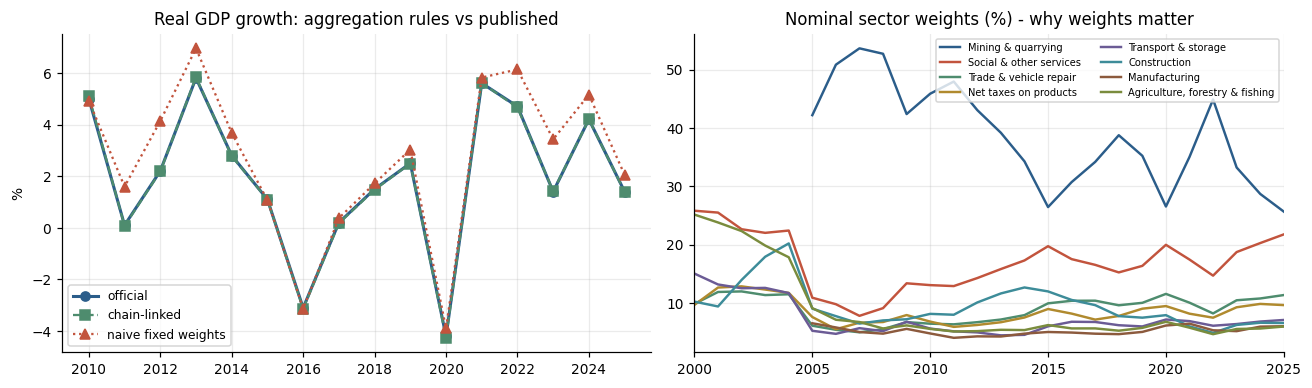

mining weight: 45.9% (2010) -> 25.6% (2025)


In [9]:
NOM = pd.DataFrame({c: (A_RAW.nettax_n if c=='nettax' else A_RAW[f'va_{c}_n']) for c in COMP})
GIX = pd.DataFrame({c: (A_RAW.nettax_rgi if c=='nettax' else A_RAW[f'va_{c}_rgi']) for c in COMP})

def pyp_growth(nom, gix, comps=None):
    '''Previous-year-price (chain-linked) aggregate growth in %, the official aggregator.'''
    comps = comps or list(nom.columns)
    n, g = nom[comps], gix[comps]
    w = n.div(n.sum(axis=1, min_count=len(comps)), axis=0)
    return ((w.shift(1) * (g/100 - 1)).sum(axis=1, min_count=len(comps))) * 100

chain = pyp_growth(NOM, GIX)
fixedbase = pd.DataFrame({c: D[f'rva_{c}'] for c in COMP}).sum(axis=1, min_count=len(COMP)).pct_change()*100
val = pd.DataFrame({'official': A_RAW.gdp_rgi - 100, 'chain-linked (PYP)': chain,
                    'naive fixed-2015-weight sum': fixedbase})
val['error: chain'] = val['chain-linked (PYP)'] - val.official
val['error: naive'] = val['naive fixed-2015-weight sum'] - val.official
display(val.loc[2010:LAST_ACT].round(2))
m = val.loc[2010:LAST_ACT]
print(f"chain-linked : MAE {m['error: chain'].abs().mean():.3f} pp   max {m['error: chain'].abs().max():.3f} pp")
print(f"naive        : MAE {m['error: naive'].abs().mean():.3f} pp   max {m['error: naive'].abs().max():.3f} pp")
assert m['error: chain'].abs().max() < 0.25, "chain-linked aggregator failed to reproduce official growth"
print("\n=> the chain-linked aggregator reproduces official real GDP growth; it is used for all forecast aggregation.")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(m.index, m.official, 'o-', lw=2, label='official', color=PAL[0])
ax[0].plot(m.index, m['chain-linked (PYP)'], 's--', label='chain-linked', color=PAL[2])
ax[0].plot(m.index, m['naive fixed-2015-weight sum'], '^:', label='naive fixed weights', color=PAL[1])
ax[0].set_title('Real GDP growth: aggregation rules vs published'); ax[0].set_ylabel('%'); ax[0].legend(fontsize=8)
sh = NOM.div(NOM.sum(axis=1), axis=0)*100
for i, c in enumerate(['min','oth','trd','nettax','tra','con','man','agr']):
    ax[1].plot(sh.index, sh[c], label=SECT_LABEL[c], color=PAL[i], lw=1.6)
ax[1].set_xlim(2000, LAST_ACT); ax[1].set_title('Nominal sector weights (%) - why weights matter')
ax[1].legend(fontsize=6.5, ncol=2)
plt.tight_layout(); plt.show()
print("mining weight: %.1f%% (2010) -> %.1f%% (2025)" % (sh.loc[2010,'min'], sh.loc[LAST_ACT,'min']))

### 3.5 Zəncirvari həcmlərin qeyri-additivliyi və neft/qeyri-neft bölgüsünün dəqiqliyi

Həlledicidə aqreqatların necə işlənməsini iki fakt müəyyən edir.

**Zəncirvari həcmlər additiv deyil.** Zəncirvari sıralarda `real oil GDP + real non-oil GDP ≠ real GDP`; fərq −5,3%-dən (2010)
+4,9%-ə (2025) qədər dəyişir. Bu, xəta deyil, zəncirvari birləşdirmənin yaxşı məlum xassəsidir. Model üçün nəticə konkretdir:
**qeyri-neft real ÜDM heç vaxt real ÜDM-dən real neft ÜDM-ni çıxmaqla deyil, öz zəncirvari artım tempi əsasında qurulmalıdır.**

**Nominal bölgü isə, əksinə, dəqiqdir.** Neft-qaz ÜDM-i mədənçıxarmanın əlavə dəyərindən böyükdür, çünki o, həmçinin neft emalını
(emal sənayesinin tərkibində) və neft xidmətlərini əhatə edir. Aşağıdakı eynilik

> qeyri-neft ÜDM = Σ(mədənçıxarma istisna olmaqla sektorların əlavə dəyəri) + xalis vergilər − (neft ÜDM − mədənçıxarmanın əlavə dəyəri)

hər il üzrə 0,000% dəqiqliklə ödənilir. Bu fərq — mədənçıxarmadan kənar neft fəaliyyəti — həlledicinin izləməli olduğu kəmiyyətdir.

In [10]:
addv = pd.DataFrame({'real GDP': D.rgdp, 'real oil GDP': D.rgdpoil, 'real non-oil GDP': D.rgdpnon})
addv['oil + non-oil'] = addv['real oil GDP'] + addv['real non-oil GDP']
addv['non-additivity %'] = (addv['oil + non-oil']/addv['real GDP'] - 1)*100
display(addv.loc[[2010,2013,BASE_YEAR,2018,2021,2023,LAST_ACT]].round(2))
print("=> chained volumes are NOT additive: never build non-oil GDP by subtraction.\n")

oilx = A_RAW.gdp_oil_n - A_RAW.va_min_n          # oil activity outside mining: refining + oil services
nonmining = A_RAW[[f'va_{s}_n' for s in SECT if s!='min']].sum(axis=1, min_count=10) + A_RAW.nettax_n
ident = pd.DataFrame({'computed non-oil GDP': nonmining - oilx, 'official': A_RAW.gdp_nonoil_n})
ident['error %'] = (ident['computed non-oil GDP']/ident.official - 1)*100
ident['oil activity outside mining'] = oilx
display(ident.loc[2018:LAST_ACT].round(3))
print("=> the NOMINAL oil/non-oil split is exact. Wedge = refining + oil services, ~3-4 bn AZN.\n")

# how well does chain-linking the non-mining components track official non-oil growth?
chain_non = pyp_growth(NOM, GIX, comps=[c for c in COMP if c!='min'])
cmpn = pd.DataFrame({'official non-oil': A_RAW.gdp_nonoil_rgi - 100, 'chain-linked non-mining': chain_non})
cmpn['error pp'] = cmpn['chain-linked non-mining'] - cmpn['official non-oil']
def nonoil_bias(cut):
    '''Mean chain-link wedge between non-mining and official non-oil growth, 2010..cut.'''
    return float(cmpn.loc[2010:cut, 'error pp'].mean())
NONOIL_BIAS = nonoil_bias(LAST_ACT)
print(f"chain-linked non-mining vs official non-oil growth: MAE "
      f"{cmpn.loc[2010:LAST_ACT,'error pp'].abs().mean():.3f} pp, max "
      f"{cmpn.loc[2010:LAST_ACT,'error pp'].abs().max():.3f} pp, mean bias {NONOIL_BIAS:+.3f} pp")
print("The residual wedge is refining + oil services, which sit inside manufacturing.")
print(f"The solver applies the mean bias ({NONOIL_BIAS:+.3f} pp) as a calibrated correction and reports it.")
display(cmpn.loc[2015:LAST_ACT].round(2))

,real GDP,real oil GDP,real non-oil GDP,oil + non-oil,non-additivity %
year,,,,,
2010,"48,341.960","19,247.190","26,553.470","45,800.660",-5.260
2013,"52,323.280","16,750.180","35,054.030","51,804.210",-0.990
2015,"54,380.000","16,459.600","37,920.400","54,380.000",0.000
2018,"53,591.600","15,730.440","37,972.530","53,702.970",0.210
2021,"55,571.230","15,094.350","41,068.760","56,163.110",1.070
2023,"58,997.640","14,437.440","46,822.290","61,259.730",3.830
2025,"62,336.200","14,206.440","51,212.110","65,418.560",4.940


=> chained volumes are NOT additive: never build non-oil GDP by subtraction.



,computed non-oil GDP,official,error %,oil activity outside mining
year,,,,
2018,"46,702.600","46,702.600",0.000,"2,348.000"
2019,"50,650.200","50,650.200",0.000,"2,399.200"
2020,"51,131.500","51,131.500",0.000,"2,198.400"
2021,"57,432.400","57,432.400",-0.000,"3,120.900"
2022,"69,764.100","69,764.100",0.000,"4,065.500"
2023,"78,990.300","78,990.300",-0.000,"3,240.900"
2024,"86,197.100","86,240.800",-0.051,"4,004.900"
2025,"92,307.100","92,307.100",0.000,"3,678.500"


=> the NOMINAL oil/non-oil split is exact. Wedge = refining + oil services, ~3-4 bn AZN.

chain-linked non-mining vs official non-oil growth: MAE 0.365 pp, max 0.809 pp, mean bias -0.198 pp
The residual wedge is refining + oil services, which sit inside manufacturing.
The solver applies the mean bias (-0.198 pp) as a calibrated correction and reports it.


,official non-oil,chain-linked non-mining,error pp
year,,,
2015,1.100,1.200,0.100
2016,-4.500,-4.510,-0.010
2017,2.800,2.290,-0.510
2018,2.000,2.030,0.030
2019,4.000,3.690,-0.310
2020,-2.900,-2.930,-0.030
2021,7.100,7.450,0.350
2022,9.100,8.470,-0.630
2023,4.500,5.090,0.590


### 3.6 v2.2 — Nazirliyin makro modulundan götürülmüş məlumatlar

Ev təsərrüfatlarının gəlir hesabının ayaqları (iş kitabı, `Sosial sektor`, sətir 35, 41–44 — eynilik), DSMF xərcləri 1995–2024 (makro modulun `data_layer.MOE_SSPF`), neft və qaz hasilatının rəsmi planı 2025–2030 (`8_vereq_original.xlsx`, 2.4.1.4), real effektiv məzənnə (yalnız faktiki) və 2026-cı il Dövlət İnvestisiya Proqramı (bu layihənin öz iş kitabı, `DİP 2016-2026`). Mənbə faylların surətləri `data/macro_module/`-dadır (`README_FR1.md`: yol, MD5, məzmun). Makro modulun öz proqnozları (AR/orta profillər, 2026 ÜDM yolu) götürülmür.


In [11]:
# ==== Part 3.6 (v2.2) — data adopted from the Ministry's macro module (15.5.1) ===================================
# Copies of the source files are in data/macro_module/ (README_FR1.md: source path, MD5, content). Only DATA and
# OFFICIAL PLAN FIGURES are taken; the macro module's own projections (AR/average profiles, its 2026 GDP path) are not.
import openpyxl as _ox
MACRO_DIR = XL.parent / 'macro_module'
# (1) Household income account (workbook 'Sosial sektor' rows 35, 41-44). The split is an IDENTITY, checked every year:
#     money income = compensation of employees + transfers received + (entrepreneurial + property income)
D['hhinc_n'], D['hhdisp_n'] = A_RAW.hhinc_n, A_RAW.hhdisp_n
D['inc_wb_n'], D['inc_tr_n'] = A_RAW.comp_emp_n, A_RAW.transf_rec_n
D['inc_oth_n'] = A_RAW.entinc_n + A_RAW.propinc_n
_gap = float((D.inc_wb_n + D.inc_tr_n + D.inc_oth_n - D.hhinc_n).abs().max())
assert _gap < 1e-6, _gap
assert float((D.hhdisp_n/D.p_cons - D.rhhdisp).abs().max()) < 1e-6      # real disposable income = nominal / p_cons
D['payroll_n'] = D.wage*D.emp*12/1000.0                                 # payroll = average wage x employment (mln AZN)
D['gdpnon_n'] = A_RAW.gdp_nonoil_n
# (2) State Social Protection Fund (DSMF) expenditure, mln AZN, 1995-2024 (MOE FISCAL 'Pension Fund', via the macro module)
_ds = pd.read_csv(MACRO_DIR/'dsmf_sspf_budget_1995_2024.csv', index_col=0)
D['dsmf_n'] = _ds['expenditure'].reindex(D.index)
# v2.3.5: minimum wage. The workbook ('Sosial sektor' row 51) shows in year t the level in force from 1 January t+1
# (400 AZN for 2024 is effective 01.01.2025). FR1 uses the ANNUAL AVERAGE of the level in force (months / 12), built from
# data/dsk_minwage/minwage_decrees.csv (DSK 004_1 for 2017-2025); the shift is asserted against the workbook.
_mw = pd.read_csv(XL.parent/'dsk_minwage'/'minwage_decrees.csv', parse_dates=['effective_date']).sort_values('effective_date')
def _mw_in_force(ts): return float(_mw[_mw.effective_date <= ts].azn.iloc[-1])
D['minwage_ws'] = D.minwage.copy()
D['minwage'] = pd.Series({y: np.mean([_mw_in_force(pd.Timestamp(y, m, 1)) for m in range(1, 13)]) for y in range(2000, LAST_ACT + 1)}
                         ).reindex(D.index)
_chk = pd.DataFrame({'workbook': D.minwage_ws, 'in force 1 Jan t+1': {y: _mw_in_force(pd.Timestamp(y + 1, 1, 1)) for y in range(2000, LAST_ACT + 1)},
                     'annual average (used)': D.minwage}).loc[2000:LAST_ACT]
_bad = _chk[(_chk.workbook - _chk['in force 1 Jan t+1']).abs() > 1e-9].index.tolist()
assert set(_bad) <= {2018}, _bad        # 2018: the workbook shows 250 (from 09.2019), not 195 (130 Jan-Feb, 180 from 03.2019, 250 from 09.2019)
MINWAGE_CHECK = _chk
# 2026-10-06: ONE minimum-wage forecast path, shared with FR3 (data/dsk_minwage/minwage_path.json): the first forecast year
# is the annual average of the decree schedule (the legal level, asserted against the file), later years grow at the
# file's scenario rate. FR1's exogenous 'minwage' (Part 13 build_scenario) and FR3's default path read the same file.
import json as _json
MW_CFG = _json.load(open(XL.parent/'dsk_minwage'/'minwage_path.json', encoding='utf-8'))
MW_FIRST = float(np.mean([_mw_in_force(pd.Timestamp(LAST_ACT + 1, m, 1)) for m in range(1, 13)]))
assert abs(MW_FIRST - MW_CFG['legal_level_first_forecast_year_azn']) < 1e-9, (MW_FIRST, MW_CFG['legal_level_first_forecast_year_azn'])
MW_G = {k: v/100 for k, v in MW_CFG['growth_pct_a_year_from_second_forecast_year'].items()}
# 2026-10-07: decided labour-pension indexation (Presidential Order; DSMF) - used for the forecast years it covers
_pi = pd.read_csv(XL.parent/'dsmf_pension'/'pension_indexation.csv')
PENS_INDEX = {int(r.year): float(r.index_pct) for r in _pi.itertuples() if int(r.year) > LAST_ACT}
print(f"decided pension indexation used in the forecast: {PENS_INDEX} (%); CPI indexation in the other years")
print(f"minimum-wage forecast path (minwage_path.json): {LAST_ACT + 1} = {MW_FIRST:.0f} AZN (legal level), then "
      + ' / '.join(f'{k} {v:.0%}' for k, v in MW_G.items()) + ' a year')
print("minimum wage, AZN (workbook vs DSK decrees):"); display(_chk.loc[2015:LAST_ACT].round(1).T)
# (3) Official plan for hydrocarbon output: 8_vereq_original.xlsx, sheet 2.4.1.4, rows 'Neft hasilatı' (thousand t)
#     and 'Qaz hasilatı' (mln m3); 2013-2024 report, 2025-2030 plan ('Proqnoz')
_wsp = _ox.load_workbook(MACRO_DIR/'8_vereq_original.xlsx', read_only=True, data_only=True)['2.4.1.4.']
_rows = list(_wsp.iter_rows(values_only=True)); _yrs = _rows[2][3:]
assert list(_yrs) == list(range(2013, 2031)), _yrs
_plan = {}
for _r in _rows:
    if _r[1] in ('Neft hasilatı', 'Qaz hasilatı'):
        _plan[{'Neft hasilatı': 'oil_prod', 'Qaz hasilatı': 'gas_prod'}[_r[1]]] = pd.Series(
            [float(v)/1000.0 for v in _r[3:]], index=list(_yrs))           # -> mln t and bcm (the model's units)
OILGAS_PLAN = pd.DataFrame(_plan)
OILGAS_PLAN_G = OILGAS_PLAN.pct_change().loc[NOWCAST_Y:H_END]           # plan growth rates 2026-2030
print("Ministry plan for hydrocarbon output (8_vereq_original.xlsx, 2.4.1.4) vs actual:")
display(pd.DataFrame({'oil plan, mt': OILGAS_PLAN.oil_prod, 'oil actual': D.oil_prod.reindex(OILGAS_PLAN.index),
                      'gas plan, bcm': OILGAS_PLAN.gas_prod, 'gas actual': D.gas_prod.reindex(OILGAS_PLAN.index)}).loc[2022:].round(3))
PLAN_ERR25 = {k: float((OILGAS_PLAN[k][LAST_ACT]/D[k][LAST_ACT] - 1)*100) for k in ('oil_prod', 'gas_prod')}
print(f"plan {LAST_ACT} vs actual: oil {PLAN_ERR25['oil_prod']:+.2f}% (plan optimistic), gas {PLAN_ERR25['gas_prod']:+.2f}%")
print("plan growth rates 2026-2030, %:", (OILGAS_PLAN_G*100).round(2).to_dict('list'))
# (4) Real effective exchange rate (2015 = 1), macro module external block: ACTUALS only (its 2026-2030 values are
#     that module's own projections and are not used)
_ext = pd.read_csv(MACRO_DIR/'external_block_annual.csv', index_col=0)
D['reer'] = _ext['reer'].reindex(D.index).where(D.index <= LAST_ACT)
# v2.3.3: USD import-price inflation (%, same external block, actuals only) for the G4 pass-through candidates
D['pm_usd_infl'] = _ext['import_price_infl'].reindex(D.index).where(D.index <= LAST_ACT)
# v2.3.4 splice: DSK import-price index (workbook 'Monetar sektoru' row 98, % of the previous year, 2021-2025 only) chained
# onto the macro-module series - growth rates of the macro module to 2020, of the DSK index 2021-2025
D['wage_state'], D['wage_priv'] = A_RAW.wage_state.reindex(D.index), A_RAW.wage_priv.reindex(D.index)   # v2.3.6 (E2 candidate)
D['pm_dsk_infl'] = D.pm_usd_infl.where(D.index <= 2020)
D.loc[2021:LAST_ACT, 'pm_dsk_infl'] = (A_RAW.mpi_imp - 100).reindex(D.index).loc[2021:LAST_ACT]
assert D.pm_dsk_infl.loc[2021:LAST_ACT].notna().all()
# (5) State Investment Programme (DİP) 2026 — this project's own workbook, sheet 'DİP 2016-2026', row 'Dövlət əsaslı
#     vəsait qoyuluşunun cəmi': 2016-2025 actual expenditure, 2026 'Nəzərdə tutulmuş vəsait' (planned) and the
#     actual expenditure to 01.04.2026. The macro module uses the same cell (assumptions.csv, state_capex_realg).
_wsd = _ox.load_workbook(XL, read_only=True, data_only=True)['DİP 2016-2026']
_dr = list(_wsd.iter_rows(values_only=True))
_hdr = list(_dr[1]); _tot = next(r for r in _dr if r[0] and str(r[0]).startswith('Dövlət əsaslı vəsait qoyuluşunun cəmi'))
_c26 = _hdr.index(2026)
SIP = pd.Series({y: float(_tot[_hdr.index(y)]) for y in range(2016, LAST_ACT + 1)})
SIP_2026_PLAN, SIP_2026_Q1 = float(_tot[_c26]), float(_tot[_c26 + 1])
assert _dr[2][_c26] == 'Nəzərdə tutulmuş vəsait' and abs(SIP[LAST_ACT] - D.exp_pubinv_n[LAST_ACT]) < 0.5
print(f"\nState Investment Programme: {LAST_ACT} actual {SIP[LAST_ACT]:,.1f} mln AZN; {NOWCAST_Y} planned "
      f"{SIP_2026_PLAN:,.1f} ({(SIP_2026_PLAN/SIP[LAST_ACT]-1)*100:+.1f}% nominal); executed to 01.04.{NOWCAST_Y}: {SIP_2026_Q1:,.1f}")
# (6) Export-value-weighted hydrocarbon export price index (USD): chain index with previous-year value weights
_bbl = float((A_RAW.oil_exp_val/(D.oil_exp_vol*D.oil_exp_price)).loc[2015:LAST_ACT].mean())   # = bbl_per_tonne (Part 9.1)
_vo = D.oil_exp_vol*_bbl*D.oil_exp_price; _vg = D.gas_exp_vol*D.gas_exp_price
D['xsh_oil'] = _vo/(_vo + _vg)                                          # oil share of hydrocarbon export value
D['dln_xpi'] = (D.xsh_oil.shift(1)*np.log(D.oil_exp_price).diff()
                + (1 - D.xsh_oil.shift(1))*np.log(D.gas_exp_price).diff())*100
print("oil share of hydrocarbon export value:", D.xsh_oil.loc[[2010, 2015, 2020, 2022, 2024, LAST_ACT]].round(3).to_dict())
# ---- v2.2 model choices. Each candidate is estimated, selected on data <= CUT, and compared with the pre-v2.2
#      specification in the dynamic 2021-2025 hold-out (Part 11.6); the switches record the decisions taken there.
E3_MODE     = 'share'          # household income: 'share' (pre-v2.2 E3, kept) | 'legs' (income account by source, macro
                               # module; rejected: hold-out worse) | 'legs_real' (legs deflated by consumer prices; rejected)
G5MIN_SPEC  = 'xpi'            # mining deflator: 'xpi' (macro module: export price index + exchange rate; ADOPTED) |
                               # 'oil_azn' (pre-v2.2: CPI + manat oil price) | 'xpi_cpi' (CPI + index + exchange rate; rejected)
D4_SPEC     = 'usd_volume'     # non-oil imports: 'usd_volume' (v2.3, ADOPTED: imports at constant USD prices, the same fit as
                               # 'cons_relprice' with the relative-price elasticity of import VOLUMES, +0.755) | 'cons_relprice'
                               # (v2.2) | 'absorb_reer' (macro module; rejected)
FISCAL_RULE = 'F3'             # fiscal closure: 'F3' (current-expenditure equation, kept) | 'nobd' (non-oil balance / non-oil
                               # GDP held; rejected - engine lever)
# ---- v2.3 model choices (Part 11.7: every candidate selected on data <= CUT and tested in the dynamic 2021-2025 hold-out)
#   D4_SPEC (above) v2.3 candidates: 'usd_volume' (imports at constant USD prices; the same fit re-parametrised) |
#                   'cons_norelprice' (relative price dropped = its coefficient bounded at 0, binding)
E3_SPEC     = 'gdp_pens_wb'    # household income (E3, used when E3_MODE = 'share'): 'gdp_pens_wb' (v2.3, ADOPTED: + real wage
                               # bill, homogeneity imposed) | 'gdp_pens' (v2.2) | 'gdp_pens_wb_free' (+ wage bill, test-and-impose
                               # rule; rejected: wrong-signed non-oil GDP on the full sample)
F3_SPEC     = 'rev_tot'        # current expenditure: 'rev_tot' (v2.2, KEPT: no candidate passes) | 'rev_split' (non-oil and oil revenue separately) |
                               # 'rev_non' (non-oil revenue only) | 'rev_cap' (revenue elasticity at its 95% CI lower bound)
G4_SPEC     = 'fx_lag'         # CPI inflation (Part 11.7): v2.3.4 ADOPTED 'fx_lag' (import-price data irreconcilable, Part 14.1);
                               # v2.3.3 had 'pm_azn_lag' | 'fx_wage' (v2.3) | 'fx_lag' (+ dln_fx(t-1)) | 'pm_azn' / 'pm_azn_lag'
                               # (manat import-price inflation, current / + lag) | 'fx_post15_lag' (post-2015 regime, current + lag)
E2_SPEC     = 'mw_sector'      # v2.3.6 wages (Part 11.7; ADOPTED 'mw_sector': minimum-wage elasticity restricted to the
                               # state / non-state channels) | 'base' (productivity + CPI + minimum wage, v2.3.5) | 'pubref_steps' (+ public-pay
                               # reform steps 2019/2022/2023) | 'pubref_index' (+ cumulative reform count)
PUBREF_YEARS = (2019, 2022, 2023)  # public-pay reforms (state wages +22.1% 2019, +21.7% 2022, +13.6% 2023; workbook 'wage_state')
F4_SPEC     = 'unit'           # state investment: 'unit' (v2.2, KEPT: unit oil-revenue elasticity, imposed if not rejected) |
                               # 'cap' (elasticity at its 95% CI lower bound; tested with the scenario capital-spending rule)


decided pension indexation used in the forecast: {2026: 9.3} (%); CPI indexation in the other years
minimum-wage forecast path (minwage_path.json): 2026 = 400 AZN (legal level), then Baseline 6% / Adverse 3% / Reform 9% a year
minimum wage, AZN (workbook vs DSK decrees):


,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
workbook,105.000,116.000,130.000,250.000,250.000,250.000,300.000,345.000,345.000,400.000,400.000
in force 1 Jan t+1,105.000,116.000,130.000,130.000,250.000,250.000,300.000,345.000,345.000,400.000,400.000
annual average (used),105.000,105.000,116.000,130.000,195.000,250.000,250.000,300.000,345.000,345.000,400.000


Ministry plan for hydrocarbon output (8_vereq_original.xlsx, 2.4.1.4) vs actual:


,"oil plan, mt",oil actual,"gas plan, bcm",gas actual
2022,32.646,32.646,46.737,46.737
2023,30.147,30.147,48.497,48.497
2024,29.052,29.052,50.339,50.430
2025,28.453,27.680,50.387,50.916
2026,27.639,NaN,48.437,NaN
2027,27.068,NaN,47.924,NaN
2028,26.593,NaN,45.667,NaN
2029,27.392,NaN,48.063,NaN
2030,27.283,NaN,48.054,NaN


plan 2025 vs actual: oil +2.80% (plan optimistic), gas -1.04%
plan growth rates 2026-2030, %: {'oil_prod': [-2.86, -2.07, -1.76, 3.0, -0.4], 'gas_prod': [-3.87, -1.06, -4.71, 5.25, -0.02]}



State Investment Programme: 2025 actual 2,305.1 mln AZN; 2026 planned 2,700.0 (+17.1% nominal); executed to 01.04.2026: 365.4
oil share of hydrocarbon export value: {2010: 0.985, 2015: 0.855, 2020: 0.81, 2022: 0.565, 2024: 0.632, 2025: 0.578}


## Hissə 4 — İqtisadiyyatın struktur diaqnostikası

Spesifikasiya iqtisadiyyatın faktiki strukturundan irəli gəlməlidir, buna görə də əvvəlcə model dizaynını müəyyən edən faktlar
müəyyənləşdirilir. Onlardan dördü arxitekturanı diktə edir.

In [12]:
Y = LAST_ACT
sh = NOM.div(NOM.sum(axis=1), axis=0)*100
# Built on the sector codes and relabelled afterwards: building it directly on the labels
# mis-aligned the share Series (indexed by code) and produced NaN columns.
struct = pd.DataFrame({
 'nominal VA share 2010 (%)': sh.loc[2010, COMP].values,
 f'nominal VA share {Y} (%)': sh.loc[Y, COMP].values,
 'real growth 2015-25 (%)': (D[[f'rva_{c}' for c in COMP]].loc[Y].values /
                             D[[f'rva_{c}' for c in COMP]].loc[BASE_YEAR].values - 1)*100,
 'deflator 2025 (2015=1)': [D[f'p_{c}'].loc[Y]/D[f'p_{c}'].loc[BASE_YEAR] for c in COMP],
}, index=[SECT_LABEL[c] for c in COMP])
assert struct.notna().all().all(), 'structural table has missing cells'
struct['share change (pp)'] = struct[f'nominal VA share {Y} (%)'] - struct['nominal VA share 2010 (%)']
display(struct.sort_values(f'nominal VA share {Y} (%)', ascending=False).round(2))

print("FACT 1 - hydrocarbon dependence is the binding structural feature")
for lbl, v in [('oil & gas share of GDP', A_RAW.gdp_oil_n[Y]/A_RAW.gdp_n[Y]*100),
               ('oil & gas share of goods exports', A_RAW.x_g_oil_usd[Y]/A_RAW.x_g_usd[Y]*100),
               ('oil & gas share of budget revenue', A_RAW.rev_oil_n[Y]/A_RAW.rev_tot_n[Y]*100)]:
    print(f"   {lbl:<38} {v:5.1f}%")

print("\nFACT 2 - hydrocarbon volumes are in structural transition (exogenous, not extrapolable)")
hc = pd.DataFrame({'oil output (mt)': D.oil_prod, 'gas output (bcm)': D.gas_prod,
                   'Brent (USD/bbl)': D.brent, 'gas export price (USD/kcm)': D.gas_exp_price})
display(hc.loc[2018:Y].round(2))
print(f"   oil: {((D.oil_prod[Y]/D.oil_prod[2019])**(1/6)-1)*100:+.2f}% p.a. since 2019 (managed decline)")
print(f"   gas: {((D.gas_prod[Y]/D.gas_prod[2019])**(1/6)-1)*100:+.2f}% p.a. since 2019, but only "
      f"{(D.gas_prod[Y]/D.gas_prod[Y-1]-1)*100:+.2f}% in {Y} -> plateau reached")

print("\nFACT 3 - the non-oil economy is growing and rebalancing toward services")
print(f"   non-oil real GDP 2015-25: {(D.rgdpnon[Y]/D.rgdpnon[BASE_YEAR]-1)*100:+.1f}%")
print(f"   fastest sectors 2015-25 : " + ", ".join(
    f"{SECT_LABEL[c]} {(D[f'rva_{c}'][Y]/D[f'rva_{c}'][BASE_YEAR]-1)*100:+.0f}%"
    for c in ['ict','tra','man','tou']))
print(f"   contracting sectors     : " + ", ".join(
    f"{SECT_LABEL[c]} {(D[f'rva_{c}'][Y]/D[f'rva_{c}'][BASE_YEAR]-1)*100:+.0f}%" for c in ['min','con']))

print("\nFACT 4 - three structural breaks dominate the sample; any AR parameterisation would be unstable")
brk = pd.DataFrame({'FX (AZN/USD)': D.fx, 'CPI inflation (%)': D.infl,
                    'real GDP growth (%)': A_RAW.gdp_rgi-100, 'Brent': D.brent})
display(brk.loc[[2014,2015,2016,2019,2020,2021,2022,2023,Y]].round(2))
BREAKS = {2015: 'devaluation (0.78 -> 1.77)', 2020: 'pandemic', 2022: 'energy price shock'}
print("   breaks carried as dummies / tested by Chow:", BREAKS)

,nominal VA share 2010 (%),nominal VA share 2025 (%),real growth 2015-25 (%),deflator 2025 (2015=1),share change (pp)
Mining & quarrying,45.880,25.650,-15.600,2.730,-20.230
Social & other services,13.030,21.740,19.600,2.190,8.710
Trade & vehicle repair,6.420,11.330,31.770,2.060,4.910
Net taxes on products,6.770,9.600,35.520,1.880,2.830
Transport & storage,5.580,7.050,96.900,1.430,1.480
Construction,8.100,6.530,-9.800,1.440,-1.570
Manufacturing,4.740,5.980,85.570,1.530,1.240
"Agriculture, forestry & fishing",5.520,5.930,37.630,1.650,0.400
Tourism & catering,1.040,2.770,55.310,1.750,1.730
Information & communication,1.860,2.070,154.800,0.960,0.200


FACT 1 - hydrocarbon dependence is the binding structural feature
   oil & gas share of GDP                  28.5%
   oil & gas share of goods exports        85.6%
   oil & gas share of budget revenue       48.1%

FACT 2 - hydrocarbon volumes are in structural transition (exogenous, not extrapolable)


,oil output (mt),gas output (bcm),Brent (USD/bbl),gas export price (USD/kcm)
year,,,,
2018,38.810,30.490,71.340,188.100
2019,37.500,35.610,64.300,188.780
2020,34.530,37.140,41.960,176.310
2021,34.580,43.870,70.860,276.080
2022,32.650,46.740,100.930,790.380
2023,30.150,48.500,82.490,513.770
2024,29.050,50.430,80.520,326.190
2025,27.680,50.920,69.140,350.200


   oil: -4.94% p.a. since 2019 (managed decline)
   gas: +6.14% p.a. since 2019, but only +0.96% in 2025 -> plateau reached

FACT 3 - the non-oil economy is growing and rebalancing toward services
   non-oil real GDP 2015-25: +35.1%
   fastest sectors 2015-25 : Information & communication +155%, Transport & storage +97%, Manufacturing +86%, Tourism & catering +55%
   contracting sectors     : Mining & quarrying -16%, Construction -10%

FACT 4 - three structural breaks dominate the sample; any AR parameterisation would be unstable


,FX (AZN/USD),CPI inflation (%),real GDP growth (%),Brent
year,,,,
2014,0.780,-0.100,2.800,98.970
2015,1.560,7.600,1.100,52.320
2016,1.770,15.700,-3.100,43.640
2019,1.700,2.400,2.500,64.300
2020,1.700,2.600,-4.200,41.960
2021,1.700,12.000,5.600,70.860
2022,1.700,14.400,4.700,100.930
2023,1.700,2.100,1.400,82.490
2025,1.700,5.200,1.400,69.140


   breaks carried as dummies / tested by Chow: {2015: 'devaluation (0.78 -> 1.77)', 2020: 'pandemic', 2022: 'energy price shock'}


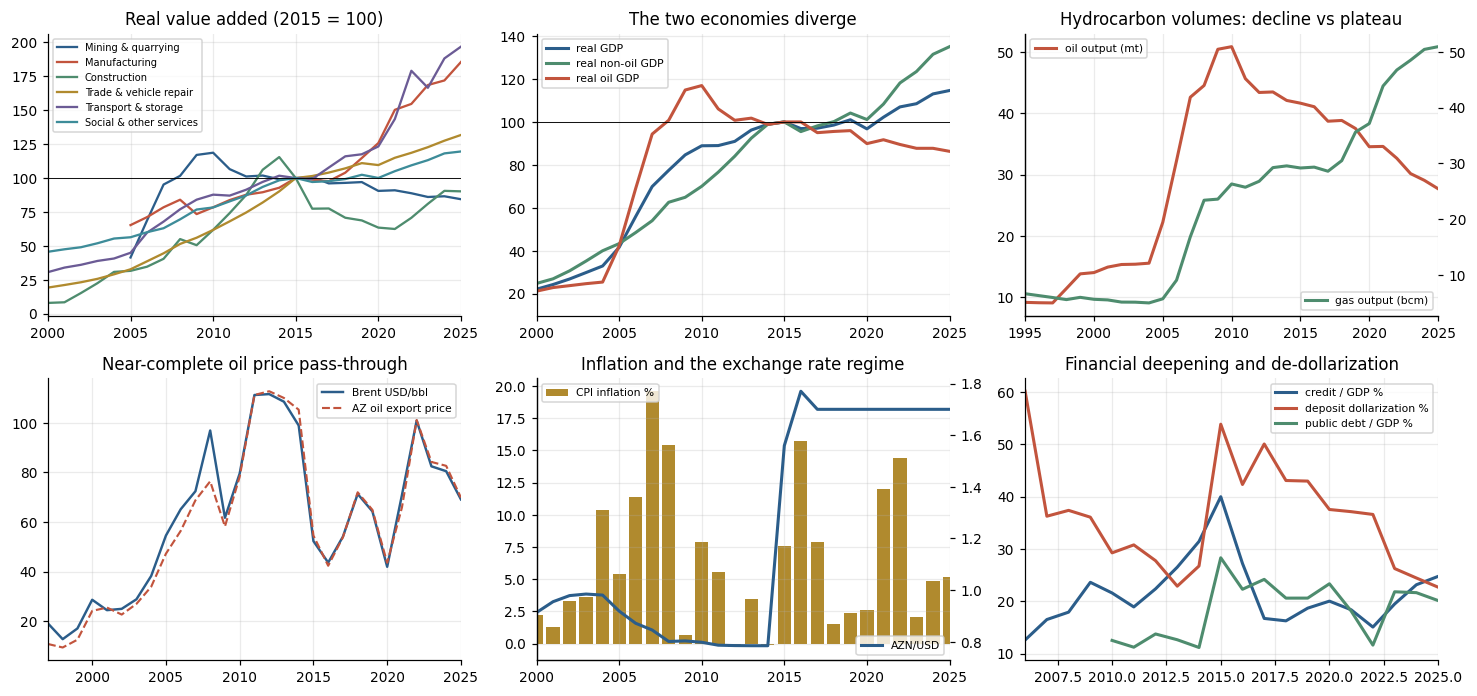

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(13.5, 6.4))
a = ax[0,0]
for i,c in enumerate(['min','man','con','trd','tra','oth']):
    a.plot(D.index, D[f'rva_{c}']/D[f'rva_{c}'].loc[BASE_YEAR]*100, label=SECT_LABEL[c], color=PAL[i])
a.set_xlim(2000,Y); a.axhline(100, color='k', lw=.6); a.set_title('Real value added (2015 = 100)')
a.legend(fontsize=6.5)
a = ax[0,1]
a.plot(D.index, D.rgdp/D.rgdp.loc[BASE_YEAR]*100, lw=2, label='real GDP', color=PAL[0])
a.plot(D.index, D.rgdpnon/D.rgdpnon.loc[BASE_YEAR]*100, lw=2, label='real non-oil GDP', color=PAL[2])
a.plot(D.index, D.rgdpoil/D.rgdpoil.loc[BASE_YEAR]*100, lw=2, label='real oil GDP', color=PAL[1])
a.set_xlim(2000,Y); a.axhline(100,color='k',lw=.6); a.set_title('The two economies diverge'); a.legend(fontsize=7)
a = ax[0,2]
a.plot(D.index, D.oil_prod, color=PAL[1], lw=2, label='oil output (mt)')
a2 = a.twinx(); a2.plot(D.index, D.gas_prod, color=PAL[2], lw=2, label='gas output (bcm)')
a2.grid(False); a.set_xlim(1995,Y); a.set_title('Hydrocarbon volumes: decline vs plateau')
a.legend(fontsize=7, loc='upper left'); a2.legend(fontsize=7, loc='lower right')
a = ax[1,0]
a.plot(D.index, D.brent, color=PAL[0], lw=1.6, label='Brent USD/bbl')
a.plot(D.index, D.oil_exp_price, '--', color=PAL[1], lw=1.4, label='AZ oil export price')
a.set_xlim(1997,Y); a.set_title('Near-complete oil price pass-through'); a.legend(fontsize=7)
a = ax[1,1]
a.bar(D.index, D.infl, color=PAL[3], label='CPI inflation %')
a2 = a.twinx(); a2.plot(D.index, D.fx, color=PAL[0], lw=2, label='AZN/USD'); a2.grid(False)
a.set_xlim(2000,Y); a.set_title('Inflation and the exchange rate regime')
a.legend(fontsize=7, loc='upper left'); a2.legend(fontsize=7, loc='lower right')
a = ax[1,2]
a.plot(D.index, D.credit_gdp, lw=2, color=PAL[0], label='credit / GDP %')
a.plot(D.index, D.dollarization, lw=2, color=PAL[1], label='deposit dollarization %')
a.plot(D.index, D.debt_gdp, lw=2, color=PAL[2], label='public debt / GDP %')
a.set_xlim(2006,Y); a.set_title('Financial deepening and de-dollarization'); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

## Hissə 5 — Qiymətləndirmə alətləri

Bu mühitdə `linearmodels` quraşdırılmayıb, buna görə də struktur qiymətləndiricilər birbaşa reallaşdırılmışdır. Metodoloji nəticə üçün
bu, hər halda üstündür: hər qiymətləndirici API arxasında gizlədilmək əvəzinə görünən və yoxlanıla biləndir. Daha sonra hər biri
maşın dəqiqliyində **`statsmodels` ilə müqayisə edilərək yoxlanılır**, beləliklə düzgünlük fərz edilmir, nümayiş etdirilir.

| Qiymətləndirici | Bu modeldə təyinatı |
|---|---|
| `ols` (n/(n−k) miqyaslı HC1 / Newey–West HAC, t(n−k) p-dəyərləri) | tək tənliklər; dərəcə (rate) tənlikləri |
| `tsls` | endogen izahedici dəyişənləri olan tənliklər üçün 2SLS; birinci mərhələ F və Sargan J statistikalarını verir |
| `system_3sls` | tənliklərarası xəta kovariasiyasından istifadə edən effektiv sistem qiymətləndirməsi |
| `sur` | toplama (adding-up) məhdudiyyətləri qoyulmuş pay sistemləri (kreditin sektorlar üzrə bölgüsü) |
| `dols`, `lr_fit` | Stock–Watson DOLS (df ≥ 10 olduqda Δx-in ±1 qabaqlayıcı/gecikmə qiymətləri, əks halda df ≥ 8 olduqda cari Δx, əks halda OLS) — **proqnozlaşdırmada istifadə olunan uzunmüddətli əmsallar**; gecikmiş asılı dəyişən yoxdur |
| `eg_coint_p` | qalıqlara əsaslanan kointeqrasiya p-dəyəri (deterministik komponentsiz ADF, maxlag 1, MacKinnon N = I(1) izahedici dəyişənlər + 1) |
| `dwh_test` | Durbin–Wu–Hausman ekzogenlik testi (nəzarət funksiyası, HAC-F) |
| `diff_form` | hər səviyyə əmsalının çarpaz yoxlaması kimi eyni tənlik birinci fərqlərdə |
| `panel_fe`, `wild_cluster_p` | Driscoll–Kraay s.x. ilə ikitərəfli sabit effektlər (⌊T^¼⌋ gecikmə, t(T−1)); illər üzrə vəhşi klaster bootstrapı (Webb çəkiləri) |
| `wald_test` | nəzəri məhdudiyyətlərin HAC-F testi F(m, n−k), yoxlanılan kombinasiyanın s.x.-sı ilə birlikdə (güc göstəricisi) |
| `gauss_seidel` | eyni zamanlı qeyri-xətti sistemin həlli |

Gecikmələrə toxunan iki konstruksiya haqqında: **HAC standart xətaları** yalnız statistik nəticəni düzəldir — onlar heç vaxt
qiymətləndirilmiş dəyəri və ya proqnozu dəyişmir. **DOLS** səviyyələr üzrə reqressiyanı *izahedici dəyişənlərin fərqlərinin* qabaqlayıcı
və gecikmə qiymətləri ilə genişləndirir; asılı dəyişənin öz gecikmələri heç vaxt daxil olmur və məhz buna görə o, bu modelin
avtoreqressiyasızlıq qaydası ilə uyğun gələn kointeqrasiya qiymətləndiricisidir.

In [14]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.adfvalues import mackinnonp

class Fit:
    def __init__(self, **kw): self.__dict__.update(kw)
    def table(self, digits=4):
        t = pd.DataFrame({'coef': self.beta, 'se': self.se, 't': self.tstat, 'p': self.pval},
                         index=self.names)
        t['sig'] = ['***' if p<.01 else '**' if p<.05 else '*' if p<.10 else '' for p in self.pval]
        return t.round(digits)
    def summary(self, title=''):
        out = [f"{title or self.kind}   n={self.n}  R2={self.r2:.4f}  adj={self.r2a:.4f}"]
        if getattr(self, 'extra', None): out.append("  " + self.extra)
        out.append(self.table().to_string())
        return "\n".join(out)
    def __repr__(self): return self.summary()

def _prep(y, X, add_const=True):
    d = pd.concat([y.rename('__y__'), X], axis=1).dropna()
    yv = d['__y__'].to_numpy(float); Xv = d.drop(columns='__y__').to_numpy(float)
    names = [c for c in d.columns if c != '__y__']
    if add_const:
        Xv = np.column_stack([np.ones(len(Xv)), Xv]); names = ['const'] + names
    return yv, Xv, names, d.index

def hac_cov(X, u, XtXi, lags=None, small=True):
    '''Newey-West (Bartlett) HAC covariance with the finite-sample scaling n/(n-k).
    This corrects INFERENCE for residual dependence; it adds no autoregressive term to the
    model and never changes a fitted value.'''
    n, k = X.shape
    if lags is None: lags = max(1, int(np.floor(4*(n/100)**(2/9))))
    Xu = X * u[:, None]
    S = Xu.T @ Xu
    for L in range(1, lags+1):
        G = Xu[L:].T @ Xu[:-L]
        S += (1 - L/(lags+1)) * (G + G.T)
    V = XtXi @ S @ XtXi
    return V * (n/max(n-k, 1)) if small else V

def ols(y, X, cov='hac', lags=None, add_const=True):
    yv, Xv, names, idx = _prep(y, X, add_const)
    n, k = Xv.shape
    XtXi = np.linalg.pinv(Xv.T @ Xv)
    b = XtXi @ Xv.T @ yv
    u = yv - Xv @ b
    dof = max(n-k, 1)
    if   cov == 'hac': V = hac_cov(Xv, u, XtXi, lags)
    elif cov == 'hc1': V = XtXi @ ((Xv*u[:,None]).T @ (Xv*u[:,None])) @ XtXi * n/dof
    else:              V = XtXi * (u@u)/dof
    se = np.sqrt(np.maximum(np.diag(V), 0))
    with np.errstate(divide='ignore', invalid='ignore'): t = b/se
    tss = ((yv-yv.mean())**2).sum() if add_const else (yv**2).sum()
    r2 = 1 - (u@u)/tss if tss > 0 else np.nan
    return Fit(kind=f'OLS[{cov}]', beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)),
               names=names, n=n, k=k, r2=r2, r2a=1-(1-r2)*(n-1)/dof, V=V, X=Xv, y=yv, index=idx,
               resid=pd.Series(u, index=idx), fitted=pd.Series(Xv@b, index=idx), sigma2=(u@u)/dof,
               dof=dof, estimator='OLS')

def tsls(y, X_endog, X_exog, Z, cov='hac', lags=None):
    '''2SLS for a structural equation. X_endog: jointly determined regressors;
    X_exog: included exogenous; Z: EXCLUDED instruments.
    Reports first-stage F (weak-instrument screen) and Sargan J (over-identification).'''
    En = list(X_endog.columns)
    Xn = [] if X_exog is None or X_exog.shape[1]==0 else list(X_exog.columns)
    Zn = list(Z.columns)
    parts = [p for p in (X_endog, X_exog, Z) if p is not None and p.shape[1] > 0]
    d = pd.concat([y.rename('__y__')] + parts, axis=1).dropna()
    yv = d['__y__'].to_numpy(float)
    E  = d[En].to_numpy(float)
    Xx = d[Xn].to_numpy(float) if Xn else np.empty((len(d), 0))
    Zz = d[Zn].to_numpy(float)
    one = np.ones((len(d), 1))
    W = np.column_stack([one, E, Xx])          # regressors
    I = np.column_stack([one, Xx, Zz])         # instrument set
    names = ['const'] + En + Xn
    n, k = W.shape
    if I.shape[1] < k:
        raise ValueError(f"under-identified: {I.shape[1]} instruments for {k} parameters")
    PiI = np.linalg.pinv(I.T @ I)
    Wh = I @ (PiI @ (I.T @ W))
    b = np.linalg.pinv(Wh.T @ W) @ (Wh.T @ yv)
    u = yv - W @ b
    dof = max(n-k, 1)
    XtXi = np.linalg.pinv(Wh.T @ Wh)
    if   cov == 'hac': V = hac_cov(Wh, u, XtXi, lags)
    elif cov == 'hc1': V = XtXi @ ((Wh*u[:,None]).T @ (Wh*u[:,None])) @ XtXi * n/dof
    else:              V = XtXi * (u@u)/dof
    se = np.sqrt(np.maximum(np.diag(V), 0))
    with np.errstate(divide='ignore', invalid='ignore'): t = b/se
    X0 = np.column_stack([one, Xx]); q = Zz.shape[1]
    fsF = {}
    for j, nm in enumerate(En):
        ru = E[:,j] - I @ (PiI @ (I.T @ E[:,j]))
        rr = E[:,j] - X0 @ (np.linalg.pinv(X0.T@X0) @ (X0.T @ E[:,j]))
        den = (ru@ru)/max(n-I.shape[1], 1)
        fsF[nm] = ((rr@rr - ru@ru)/q)/den if den > 0 else np.nan
    over = I.shape[1] - k
    if over > 0:
        uh = I @ (PiI @ (I.T @ u)); J = n*(uh@uh)/(u@u); Jp = 1-stats.chi2.cdf(J, over)
    else:
        J, Jp = np.nan, np.nan
    r2 = 1 - (u@u)/((yv-yv.mean())**2).sum()
    extra = ("first-stage F: " + ", ".join(f"{m}={v:.1f}" for m, v in fsF.items()) +
             (f" | Sargan J({over})={J:.2f} p={Jp:.3f}" if over > 0 else " | just-identified"))
    return Fit(kind=f'2SLS[{cov}]', beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)),
               names=names, n=n, k=k, r2=r2, r2a=1-(1-r2)*(n-1)/dof, V=V, index=d.index,
               resid=pd.Series(u, index=d.index), fitted=pd.Series(W@b, index=d.index),
               first_stage_F=fsF, J=J, J_p=Jp, extra=extra, sigma2=(u@u)/dof, dof=dof,
               estimator='2SLS')

def dwh_test(y, X_endog, X_exog, Z):
    '''Durbin-Wu-Hausman test in control-function form: the first-stage residual of every
    endogenous regressor is added to the structural OLS regression and their joint
    significance is tested with a small-sample HAC-F. Rejection = the regressors are not exogenous.'''
    Xn = [] if X_exog is None or X_exog.shape[1] == 0 else list(X_exog.columns)
    d = pd.concat([y.rename('__y__'), X_endog] + ([X_exog] if Xn else []) + [Z], axis=1).dropna()
    V = {}
    for e in X_endog.columns:
        fs = ols(d[e], d[Xn + list(Z.columns)], cov='nonrobust')
        V['v_' + e] = fs.resid
    Xa = pd.concat([d[list(X_endog.columns) + Xn], pd.DataFrame(V)], axis=1)
    f = ols(d['__y__'], Xa, cov='hac')
    R = np.zeros((len(V), len(f.beta)))
    for i, c in enumerate(V): R[i, f.names.index(c)] = 1.0
    return wald_test(f, R, np.zeros(len(V)))

def wald_test(fit, R, q):
    '''HAC-F test of R*beta = q: F = W/m referred to F(m, n-k) (small-sample form).'''
    R = np.atleast_2d(np.asarray(R, float)); q = np.atleast_1d(np.asarray(q, float))
    d = R @ fit.beta - q
    Vr = R @ fit.V @ R.T
    m = R.shape[0]
    F = float(d @ np.linalg.pinv(Vr) @ d) / m
    return F, 1 - stats.f.cdf(F, m, fit.dof)

def comb_se(fit, R):
    '''Standard error of the tested linear combination R*beta: the power proxy reported
    with every non-rejected restriction.'''
    R = np.atleast_2d(np.asarray(R, float))
    return float(np.sqrt(np.maximum((R @ fit.V @ R.T)[0, 0], 0)))

def restrict_row(fit, name, value=1.0):
    R = np.zeros(len(fit.beta)); R[fit.names.index(name)] = 1.0
    return wald_test(fit, R, [value])

def eg_coint_p(resid, n_i1, trend=False):
    '''Residual-based (Engle-Granger) cointegration p-value: ADF statistic on the residuals with
    NO deterministic terms in the auxiliary regression and maxlag 1 fixed, mapped through the
    MacKinnon response surface for N = (number of I(1) regressors + 1) and 'c' or 'ct' as the
    cointegrating regression contains a constant or a constant and linear trend.'''
    u = np.asarray(pd.Series(resid).dropna(), float)
    if len(u) < 8: return np.nan, np.nan
    stat = adfuller(u, maxlag=1, regression='n', autolag=None)[0]
    N = int(min(max(n_i1 + 1, 1), 6))
    return float(stat), float(mackinnonp(stat, regression='ct' if trend else 'c', N=N))

DET = ('trend', 'trend_post2015')       # deterministic regressors: never augmented with leads/lags, not counted as I(1)

def dols(y, X, leads=1, lags_=1, cov='hac', det=DET):
    '''Stock-Watson Dynamic OLS of a cointegrating relation.
    The levels regression is augmented with the contemporaneous value and leads/lags of the
    DIFFERENCES OF THE REGRESSORS to purge endogeneity and residual serial correlation.
    The dependent variable's own lags NEVER enter: this is not an autoregression.'''
    aug = {}
    for c in [c for c in X.columns if c not in det]:
        dx = X[c].diff()
        for L in range(-leads, lags_+1):
            aug[f'd_{c}_{"F" if L<0 else "L" if L>0 else "0"}{abs(L)}'] = dx.shift(L)
    Xa = pd.concat([X, pd.DataFrame(aug, index=X.index)], axis=1)
    f = ols(y, Xa, cov=cov)
    f.kind = f'DOLS[leads={leads},lags={lags_}]'
    return f

def lr_fit(y, X, det=DET):
    '''Long-run (level) estimator used for every level relation (contract decision 2):
    DOLS with +/-1 lead/lag of the differenced regressors when the residual df stays >= 10,
    otherwise contemporaneous differences only (Saikkonen) when df >= 8, otherwise static OLS.
    The returned Fit carries ONLY the level (long-run) coefficients - these are what the solver
    uses - with their HAC covariance from the DOLS regression. The constant is re-centred so the
    static levels residual has mean zero over the levels sample, and that static residual (not
    the DOLS residual, which loses end-points) is what cointegration tests and add-factors use.'''
    X = X.copy()
    stoch = [c for c in X.columns if c not in det]
    base = ols(y, X, cov='hac')
    f, est = None, 'OLS (static; DOLS infeasible, df too small)'
    if stoch:
        for L, need in ((1, 10), (0, 8)):
            g = dols(y, X, leads=L, lags_=L)
            if g.dof >= need:
                f = g; est = f'DOLS(+/-{L})' if L else 'DOLS(0: contemporaneous dX only)'
                break
    else:
        est = 'OLS (no stochastic regressor)'
    if f is None: f = base
    core = list(X.columns)
    ix = [0] + [f.names.index(c) for c in core]
    b_lr = pd.Series(f.beta[ix[1:]], index=core)
    d = pd.concat([y.rename('__y__'), X], axis=1).dropna()
    lvl = d['__y__'] - (d[core] @ b_lr if core else 0.0)
    const = float(lvl.mean())
    beta = np.concatenate([[const], b_lr.values])
    V = f.V[np.ix_(ix, ix)]
    se = np.sqrt(np.maximum(np.diag(V), 0))
    with np.errstate(divide='ignore', invalid='ignore'): t = beta/se
    resid = lvl - const
    tss = ((d['__y__'] - d['__y__'].mean())**2).sum()
    r2 = 1 - (resid**2).sum()/tss if tss > 0 else np.nan
    out = Fit(kind=est, beta=beta, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), f.dof)),
              names=['const'] + core, n=f.n, k=f.k, r2=r2, r2a=1-(1-r2)*(len(d)-1)/max(len(d)-len(beta), 1),
              V=V, index=d.index, resid=resid, fitted=d['__y__'] - resid, dof=f.dof, estimator=est,
              X=np.column_stack([np.ones(len(d)), d[core].to_numpy(float)]) if core else np.ones((len(d), 1)),
              n_level=len(d), static=base, raw=f, stoch=stoch, has_trend=any(c in det for c in core))
    return out

def rate_fit(y, X):
    '''Regressions among stationary rates (inflation, deflator inflation): static OLS with HAC.'''
    f = ols(y, X, cov='hac'); f.estimator = 'OLS (rates; no cointegration test)'
    f.n_level = f.n; f.stoch = []; f.has_trend = False; f.static = f
    return f

def diff_form(y, X, det=DET):
    '''The same equation in first differences (deterministic trend absorbed by the constant).'''
    stoch = [c for c in X.columns if c not in det]
    if not stoch: return None
    try:
        return ols(y.diff(), X[stoch].diff(), cov='hac')
    except Exception:
        return None

def vif(X):
    Xd = X.dropna()
    out = {}
    for c in Xd.columns:
        rest = Xd.drop(columns=c)
        if rest.shape[1] == 0: out[c] = 1.0; continue
        r2 = ols(Xd[c], rest, cov='nonrobust').r2
        out[c] = np.inf if r2 >= 1 else 1/(1-r2)
    return pd.Series(out)

def cond_number(X):
    '''Condition number of the standardised regressor matrix (columns demeaned and scaled to unit
    variance, constant excluded), so it measures collinearity among the regressors themselves.'''
    Xd = X.dropna().to_numpy(float)
    if Xd.shape[1] < 2: return 1.0
    Z = (Xd - Xd.mean(axis=0))/Xd.std(axis=0)
    s = np.linalg.svd(Z, compute_uv=False)
    return float(s.max()/s.min())
print("estimators defined: ols, tsls, dwh_test, dols, lr_fit, rate_fit, diff_form, wald_test (HAC-F), "
      "eg_coint_p (MacKinnon), vif, cond_number")


estimators defined: ols, tsls, dwh_test, dols, lr_fit, rate_fit, diff_form, wald_test (HAC-F), eg_coint_p (MacKinnon), vif, cond_number


In [15]:
def sur(eqs, restrictions=None, iterate=3):
    '''Seemingly-unrelated regressions by feasible GLS.
    `restrictions` = (R, q) imposes R*beta = q exactly (used for adding-up in share systems).'''
    names = list(eqs); idx = None
    for nm in names:
        y, X = eqs[nm]
        d = pd.concat([y, X], axis=1).dropna()
        idx = d.index if idx is None else idx.intersection(d.index)
    Y = [eqs[nm][0].loc[idx].to_numpy(float) for nm in names]
    Xs = [np.column_stack([np.ones(len(idx)), eqs[nm][1].loc[idx].to_numpy(float)]) for nm in names]
    n, m = len(idx), len(names); ks = [x.shape[1] for x in Xs]
    yb = np.concatenate(Y); Xb = np.zeros((n*m, sum(ks))); c = 0
    for i, x in enumerate(Xs):
        Xb[i*n:(i+1)*n, c:c+ks[i]] = x; c += ks[i]
    b = np.linalg.pinv(Xb.T@Xb) @ Xb.T @ yb
    Om = np.eye(n*m)
    for _ in range(iterate):
        U = (yb - Xb@b).reshape(m, n); S = U@U.T/n
        Om = np.kron(np.linalg.pinv(S), np.eye(n))
        Amat = Xb.T @ Om @ Xb; rhs = Xb.T @ Om @ yb
        if restrictions is not None:
            Rm, qv = restrictions
            KKT = np.block([[Amat, Rm.T], [Rm, np.zeros((Rm.shape[0], Rm.shape[0]))]])
            b = (np.linalg.pinv(KKT) @ np.concatenate([rhs, qv]))[:Amat.shape[0]]
        else:
            b = np.linalg.pinv(Amat) @ rhs
    V = np.linalg.pinv(Xb.T @ Om @ Xb); se = np.sqrt(np.maximum(np.diag(V), 0))
    out, c = {}, 0
    for i, nm in enumerate(names):
        cols = ['const'] + list(eqs[nm][1].columns)
        t = pd.DataFrame({'coef': b[c:c+ks[i]], 'se': se[c:c+ks[i]]}, index=cols)
        t['t'] = t.coef/t.se; out[nm] = t; c += ks[i]
    U = (yb - Xb@b).reshape(m, n)
    return out, pd.DataFrame(U.T, index=idx, columns=names), U@U.T/n

def system_3sls(eqs, instruments, iterate=2):
    '''Three-stage least squares for a simultaneous structural system.
    Stage 1-2: project all regressors on the instrument set (2SLS).
    Stage 3: re-weight by the cross-equation error covariance for efficiency.'''
    names = list(eqs); idx = None
    for nm in names:
        y, X = eqs[nm]
        d = pd.concat([y, X, instruments], axis=1).dropna()
        idx = d.index if idx is None else idx.intersection(d.index)
    Z = np.column_stack([np.ones(len(idx)), instruments.loc[idx].to_numpy(float)])
    Pz = Z @ np.linalg.pinv(Z.T@Z) @ Z.T
    Y, Xs, Xh = [], [], []
    for nm in names:
        y, X = eqs[nm]
        Xv = np.column_stack([np.ones(len(idx)), X.loc[idx].to_numpy(float)])
        Y.append(y.loc[idx].to_numpy(float)); Xs.append(Xv); Xh.append(Pz @ Xv)
    n, m = len(idx), len(names); ks = [x.shape[1] for x in Xs]
    yb = np.concatenate(Y)
    Xb = np.zeros((n*m, sum(ks))); Hb = np.zeros((n*m, sum(ks))); c = 0
    for i in range(m):
        Xb[i*n:(i+1)*n, c:c+ks[i]] = Xs[i]; Hb[i*n:(i+1)*n, c:c+ks[i]] = Xh[i]; c += ks[i]
    b = np.linalg.pinv(Hb.T@Xb) @ (Hb.T@yb)
    Om = np.eye(n*m)
    for _ in range(iterate):
        U = (yb - Xb@b).reshape(m, n); S = U@U.T/n
        Om = np.kron(np.linalg.pinv(S), np.eye(n))
        b = np.linalg.pinv(Hb.T @ Om @ Hb) @ (Hb.T @ Om @ yb)
    V = np.linalg.pinv(Hb.T @ Om @ Hb); se = np.sqrt(np.maximum(np.diag(V), 0))
    out, res, c = {}, {}, 0
    for i, nm in enumerate(names):
        cols = ['const'] + list(eqs[nm][1].columns)
        t = pd.DataFrame({'coef': b[c:c+ks[i]], 'se': se[c:c+ks[i]]}, index=cols)
        t['t'] = t.coef/t.se; t['p'] = 2*(1-stats.norm.cdf(t.t.abs()))
        t['sig'] = ['***' if p<.01 else '**' if p<.05 else '*' if p<.10 else '' for p in t.p]
        out[nm] = t
        res[nm] = pd.Series(Y[i] - Xs[i]@b[c:c+ks[i]], index=idx); c += ks[i]
    U = (yb - Xb@b).reshape(m, n)
    return out, pd.DataFrame(res), U@U.T/n, idx

def _within(df, dep, regs, entity, time, twoway):
    d = df[[entity, time, dep] + regs].dropna().copy()
    for c in [dep] + regs:
        if twoway:
            d[c] = (d[c] - d.groupby(entity)[c].transform('mean')
                         - d.groupby(time)[c].transform('mean') + d[c].mean())
        else:
            d[c] = d[c] - d.groupby(entity)[c].transform('mean')
    return d

def panel_fe(df, dep, regs, entity='unit', time='year', twoway=True, dk_lags=None):
    '''Two-way (entity and time) fixed-effects within estimator with Driscoll-Kraay standard
    errors. The DK bandwidth is floor(T^(1/4)) and, because the DK variance is built from T
    time-period score sums, t-statistics are referred to t(T-1) - with T = 5 or 10 the
    effective number of observations for inference is the number of years, not N x T.'''
    d = _within(df, dep, regs, entity, time, twoway)
    yv = d[dep].to_numpy(float); Xv = d[regs].to_numpy(float)
    XtXi = np.linalg.pinv(Xv.T@Xv); b = XtXi @ Xv.T @ yv; u = yv - Xv@b
    nN, nT = d[entity].nunique(), d[time].nunique()
    if dk_lags is None: dk_lags = int(np.floor(nT**0.25))
    k = len(regs) + nN + (nT-1 if twoway else 0)
    ht = (pd.DataFrame(Xv*u[:,None], index=d[time].to_numpy())
            .groupby(level=0).sum().sort_index().to_numpy())
    S = ht.T @ ht
    for L in range(1, dk_lags+1):
        G = ht[L:].T @ ht[:-L]; S += (1 - L/(dk_lags+1))*(G + G.T)
    V = XtXi @ S @ XtXi * (len(d)/max(len(d)-k, 1))
    se = np.sqrt(np.maximum(np.diag(V), 0)); t = b/se; dof = max(nT-1, 1)
    r2 = 1 - (u@u)/(yv@yv)
    return Fit(kind='Panel 2-way FE [Driscoll-Kraay]' if twoway else 'Panel entity FE [DK]',
               beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)), names=regs,
               n=len(d), k=k, r2=r2, r2a=1-(1-r2)*(len(d)-1)/max(len(d)-k, 1), V=V,
               resid=pd.Series(u, index=d.index), nN=nN, nT=nT, dof=dof, dk_lags=dk_lags,
               extra=f"units={nN}  periods={nT}  DK lags={dk_lags}  inference df=T-1={dof}")

WEBB6 = np.array([-np.sqrt(1.5), -1.0, -np.sqrt(0.5), np.sqrt(0.5), 1.0, np.sqrt(1.5)])

def wild_cluster_p(df, dep, regs, test, entity='unit', time='year', twoway=True, B=1999, seed=None):
    '''Wild cluster bootstrap-t p-value (WCR: null imposed), clusters = years.
    With 5-10 year clusters the Rademacher distribution has too few distinct draws (2^T), so the
    Webb six-point distribution is used. Cluster-robust (CR1, by year) t-statistics.'''
    d = _within(df, dep, regs, entity, time, twoway)
    yv = d[dep].to_numpy(float); Xv = d[regs].to_numpy(float)
    tt = d[time].to_numpy(); ug = np.unique(tt); G = len(ug)
    gi = np.searchsorted(ug, tt)
    j = regs.index(test)
    XtXi = np.linalg.pinv(Xv.T @ Xv)
    def tstat(y_):
        b = XtXi @ Xv.T @ y_; u = y_ - Xv @ b
        sc = np.zeros((G, Xv.shape[1]))
        np.add.at(sc, gi, Xv*u[:, None])
        V = XtXi @ (sc.T @ sc) @ XtXi * G/max(G-1, 1)
        return b[j]/np.sqrt(max(V[j, j], 1e-300))
    t0 = tstat(yv)
    Xr = np.delete(Xv, j, axis=1)
    br = np.linalg.pinv(Xr.T @ Xr) @ Xr.T @ yv if Xr.shape[1] else np.zeros(0)
    fr = Xr @ br if Xr.shape[1] else np.zeros_like(yv); ur = yv - fr
    rg = np.random.default_rng(SEED if seed is None else seed)
    W = rg.choice(WEBB6, size=(B, G))
    ts = np.array([tstat(fr + ur*W[b_, gi]) for b_ in range(B)])
    return float(np.mean(np.abs(ts) >= abs(t0))), float(t0)

def gauss_seidel(eq_funcs, order, state, exog, max_iter=800, tol=1e-9, damp=0.55):
    '''Solve one period of the simultaneous nonlinear system by damped Gauss-Seidel.
    eq_funcs: variable -> f(state, exog) returning that variable's new value.'''
    s = dict(state)
    err = np.inf
    for it in range(max_iter):
        err = 0.0
        for v in order:
            new = eq_funcs[v](s, exog)
            old = s.get(v, new)
            if old is None or not np.isfinite(old): old = new
            upd = damp*new + (1-damp)*old
            err = max(err, abs(upd-old)/max(abs(old), 1e-6))
            s[v] = upd
        if err < tol:
            return s, it+1, err
    return s, max_iter, err
print("estimators defined: sur, system_3sls, panel_fe (DK, df=T-1), wild_cluster_p, gauss_seidel")

estimators defined: sur, system_3sls, panel_fe (DK, df=T-1), wild_cluster_p, gauss_seidel


### 5.1 Qiymətləndiricilərin yoxlanılması

Əl ilə yazılmış qiymətləndiricilərə siyasət nəticələri etibar edilməzdən əvvəl onların düzgünlüyü sübut edilməlidir. Hər biri cavabı
məlum olan simulyasiya edilmiş məlumatlar üzərində `statsmodels` ilə müqayisə edilərək yoxlanılır. ~1e-15 dəqiqliyində uyğunluq üzən nöqtəli (floating point) hesablamada tam uyğunluq deməkdir.

In [16]:
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

rng = np.random.default_rng(SEED); n = 80
Xt = pd.DataFrame(rng.standard_normal((n,3)), columns=['a','b','c'])
yt = pd.Series(1 + 2*Xt.a - 1.5*Xt.b + .5*Xt.c + rng.standard_normal(n)*.3, name='y')
rows = []
f0 = ols(yt, Xt, cov='nonrobust'); r0 = sm.OLS(yt, sm.add_constant(Xt)).fit()
rows.append(['OLS coefficients', np.abs(f0.beta-r0.params.values).max()])
rows.append(['OLS standard errors', np.abs(f0.se-r0.bse.values).max()])
f1 = ols(yt, Xt, cov='hc1'); r1 = sm.OLS(yt, sm.add_constant(Xt)).fit(cov_type='HC1')
rows.append(['HC1 robust SE', np.abs(f1.se-r1.bse.values).max()])
f2 = ols(yt, Xt, cov='hac', lags=3)
r2_ = sm.OLS(yt, sm.add_constant(Xt)).fit(cov_type='HAC',
        cov_kwds={'maxlags':3, 'use_correction':True})
rows.append(['Newey-West HAC SE, small-sample n/(n-k)', np.abs(f2.se-r2_.bse.values).max()])
Zt = pd.DataFrame(rng.standard_normal((n,2)), columns=['z1','z2'])
en = pd.Series(.8*Zt.z1 + .6*Zt.z2 + rng.standard_normal(n)*.5, name='en')
y2 = pd.Series(1 + 1.5*en + .7*Xt.a + rng.standard_normal(n)*.4, name='y2')
g = tsls(y2, en.to_frame(), Xt[['a']], Zt, cov='nonrobust')
r3 = IV2SLS(y2, sm.add_constant(pd.concat([en, Xt.a], axis=1)),
                sm.add_constant(pd.concat([Xt.a, Zt], axis=1))).fit()
rows.append(['2SLS coefficients', np.abs(g.beta-r3.params.values).max()])
rows.append(['2SLS standard errors', np.abs(g.se-r3.bse.values).max()])
# 3SLS on a just-identified single equation must reproduce 2SLS
o3, _, _, _ = system_3sls({'eq': (y2, pd.concat([en, Xt.a], axis=1))},
                          pd.concat([Xt.a, Zt], axis=1))
rows.append(['3SLS vs 2SLS (just-identified)', np.abs(o3['eq'].coef.values - g.beta).max()])
# panel FE within-transform must reproduce OLS on demeaned data
pdf = pd.DataFrame({'unit': np.repeat(np.arange(10), 8), 'year': np.tile(np.arange(8), 10)})
pdf['x'] = rng.standard_normal(80); pdf['fe'] = pdf.unit*0.3
pdf['y'] = 1 + 0.6*pdf.x + pdf.fe + rng.standard_normal(80)*.2
fp = panel_fe(pdf, 'y', ['x'], twoway=False)
dd = pdf.copy()
for c in ['y','x']: dd[c] = dd[c] - dd.groupby('unit')[c].transform('mean')
rows.append(['panel FE coefficient', abs(fp.beta[0] - ols(dd.y, dd[['x']], cov='nonrobust').beta[1])])
# residual-based cointegration p-value must reproduce statsmodels' Engle-Granger test
from statsmodels.tsa.stattools import coint as _coint
xw = np.cumsum(rng.standard_normal(40)); yw = 0.5 + 0.8*xw + rng.standard_normal(40)*.5
fe = ols(pd.Series(yw), pd.DataFrame({'x': xw}), cov='nonrobust')
rows.append(['Engle-Granger p (MacKinnon) vs statsmodels coint',
             abs(eg_coint_p(fe.resid, 1)[1] - _coint(yw, xw, trend='c', maxlag=1, autolag=None)[1])])
chk = pd.DataFrame(rows, columns=['check','max abs difference'])
chk['verdict'] = np.where(chk['max abs difference'] < 1e-8, 'exact', 'MISMATCH')
display(chk)
assert (chk.verdict == 'exact').all(), "estimator validation failed"
print("all estimators reproduce statsmodels to machine precision")
print(f"\nWald machinery sanity check: H0 slope on 'a' = 2 (true value) -> "
      f"p = {restrict_row(f0, 'a', 2.0)[1]:.3f}  (should not reject)")
print(f"                             H0 slope on 'a' = 0            -> "
      f"p = {restrict_row(f0, 'a', 0.0)[1]:.3f}  (should reject)")

,check,max abs difference,verdict
0,OLS coefficients,0.000,exact
1,OLS standard errors,0.000,exact
2,HC1 robust SE,0.000,exact
3,"Newey-West HAC SE, small-sample n/(n-k)",0.000,exact
4,2SLS coefficients,0.000,exact
5,2SLS standard errors,0.000,exact
6,3SLS vs 2SLS (just-identified),0.000,exact
7,panel FE coefficient,0.000,exact
8,Engle-Granger p (MacKinnon) vs statsmodels coint,0.000,exact


all estimators reproduce statsmodels to machine precision

Wald machinery sanity check: H0 slope on 'a' = 2 (true value) -> p = 0.660  (should not reject)
                             H0 slope on 'a' = 0            -> p = 0.000  (should reject)


## Hissə 6 — Spesifikasiya üzrə ilkin testlər

Bunlar **modellər deyil, ilkin testlərdir.** Onların yeganə vəzifəsi hər asılılığın necə qiymətləndirilməli olduğunu müəyyən etməkdir:
səviyyələrdə qeyri-stasionar olan, lakin birgə hərəkət edən dəyişənlər DOLS ilə kointeqrasiya asılılığı kimi qiymətləndirilə bilər; əks
halda asılılıq artım templəri ilə spesifikasiya edilir. Praktikada nümunə ilkin testlərin I(1) davranışını trend-stasionar davranışdan
ayırması üçün çox qısadır, buna görə də hər bir səviyyə asılılığı DOLS ilə qiymətləndirilir və sonra onun qalığı kointeqrasiyaya yoxlanılır;
kointeqrasiya təsdiq edilmədiyi hallarda səviyyə əmsalları təsviri kimi təqdim edilir və birinci fərqlərdə qiymətləndirilmiş eyni tənliklə
yanaşı göstərilir (Hissə 10). Burada heç nə proqnozlaşdırılmır və bu bölmənin silinməsi bir dənə də olsun proqnoz rəqəmini
dəyişməzdi.

20–26 illik müşahidə ilə vahid kök testlərinin gücü aşağıdır, buna görə də nəticələr *ilkin göstərici* kimi şərh edilir və heç vaxt
mexaniki tətbiq olunmur. Testlərin birmənalı olmadığı hallarda spesifikasiya iqtisadi məntiqlə müəyyən edilir və hər iki variant təqdim olunur.

In [17]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter('ignore', InterpolationWarning)

def pretest(s, name, regression='ct'):
    s = s.dropna()
    if len(s) < 12: return dict(variable=name, n=len(s), reading='too short to test')
    out = dict(variable=name, n=len(s))
    try:    out['ADF level p'] = adfuller(s.values, regression=regression, autolag='AIC')[1]
    except Exception: out['ADF level p'] = np.nan
    try:    out['ADF diff p'] = adfuller(s.diff().dropna().values, regression='c', autolag='AIC')[1]
    except Exception: out['ADF diff p'] = np.nan
    try:    out['KPSS level p'] = kpss(s.values, regression='ct', nlags='auto')[1]
    except Exception: out['KPSS level p'] = np.nan
    lp = out['ADF level p'] if np.isfinite(out['ADF level p']) else 1.0
    dp = out['ADF diff p']  if np.isfinite(out['ADF diff p'])  else 1.0
    out['reading'] = ('I(1): levels non-stationary, differences stationary' if lp > .10 and dp < .10
                      else 'I(0): stationary in levels' if lp < .10
                      else 'ambiguous (low power at this sample size)')
    return out

L = lambda s: np.log(s.replace(0, np.nan))
core = {f'ln real VA {SECT_LABEL[c]}': L(D[f'rva_{c}']) for c in COMP}
core.update({
 'ln real GDP': L(D.rgdp), 'ln real non-oil GDP': L(D.rgdpnon),
 'ln real consumption': L(D.rcons), 'ln real disposable income': L(D.rhhdisp),
 'ln real non-oil investment': L(D.rinv_non), 'ln real state investment': L(D.rinv_state),
 'ln real total credit': L(D.rcred_tot), 'ln real household credit': L(D.rcred_hh),
 'ln real non-oil exports': L(D.rx_non), 'ln real non-oil imports': L(D.rm_non),
 'ln employment': L(D.emp), 'ln real wage': L(D.rwage), 'ln Brent': L(D.brent),
 'ln oil output': L(D.oil_prod), 'ln gas output': L(D.gas_prod),
 'CPI inflation (%)': D.infl, 'real lending rate (%)': D.realrate,
})
PRE = pd.DataFrame([pretest(v, k) for k, v in core.items()]).set_index('variable')
display(PRE.round(3))
print(PRE.reading.value_counts().to_string())
print("\n=> Most real variables are I(1) in levels, as expected of macro aggregates.")
print("   Levels relationships are therefore estimated by DOLS, and each relation's static residual is")
print("   tested with the residual-based Engle-Granger cointegration test (MacKinnon p-values, N = I(1)")
print("   regressors + 1). Where that test does not reject, the equation's t-statistics are labelled")
print("   descriptive. Rate variables (inflation, interest rates) enter in levels.")

,n,ADF level p,ADF diff p,KPSS level p,reading
variable,,,,,
"ln real VA Agriculture, forestry & fishing",26,0.381,0.115,0.050,ambiguous (low power at this sample size)
ln real VA Mining & quarrying,21,0.000,0.721,0.027,I(0): stationary in levels
ln real VA Manufacturing,21,1.000,1.000,0.030,ambiguous (low power at this sample size)
"ln real VA Electricity, gas & steam",21,0.962,0.877,0.100,ambiguous (low power at this sample size)
ln real VA Water supply & waste,17,0.265,0.113,0.082,ambiguous (low power at this sample size)
ln real VA Construction,26,0.870,0.853,0.021,ambiguous (low power at this sample size)
ln real VA Trade & vehicle repair,26,0.009,0.042,0.017,I(0): stationary in levels
ln real VA Tourism & catering,26,0.864,0.000,0.023,"I(1): levels non-stationary, differences stati..."
ln real VA Transport & storage,26,0.002,0.242,0.075,I(0): stationary in levels


reading
ambiguous (low power at this sample size)              10
I(0): stationary in levels                             10
I(1): levels non-stationary, differences stationary     9

=> Most real variables are I(1) in levels, as expected of macro aggregates.
   Levels relationships are therefore estimated by DOLS, and each relation's static residual is
   tested with the residual-based Engle-Granger cointegration test (MacKinnon p-values, N = I(1)
   regressors + 1). Where that test does not reject, the equation's t-statistics are labelled
   descriptive. Rate variables (inflation, interest rates) enter in levels.


## Hissə 7 — Panel blok I: sənaye yarımsahələri → texnologiya parametrləri

### Panel ümumiyyətlə nə üçün lazımdır

Bu, həlledici metodoloji addımdır. Aqreqat illik nümunə 16–26 müşahidə təqdim edir, halbuki istehsal funksiyası hər sektor üzrə kapital
*və* əmək elastikliyini trendlə rəqabət şəraitində identifikasiya etməlidir. İllik məlumatlarda bunu etibarlı şəkildə etmək mümkün deyil —
işlənmə zamanı ilkin cəhd emal sənayesi üçün **mənfi** kapital elastikliyi vermişdi, çünki kapital ehtiyatı trendlə kollineardır.

Lakin iş kitabında həqiqi mikro panel var: **2016–2025-ci illərdə müşahidə edilən 29 sənaye yarımsahəsi** (290 sahə-il) — ümumi buraxılış,
əlavə dəyər, investisiya, orta əmək haqqı və işçi sayı göstəriciləri ilə. Əlavə dəyər üzrə istehsal funksiyası əlavə dəyər, kapital
ehtiyatı və məşğulluq göstəricilərinin hamısının mövcud olduğu sahə-illərdən istifadə edə bilər (onların sayı aşağıda çap olunur). Sahədaxili
variasiya aqreqat sıraların identifikasiya edə bilmədiyi texnologiya parametrlərini identifikasiya edir. Daha sonra bu parametrlər aqreqat
emal sənayesi tənliyinə qarşı **test edilir** və yalnız məhdudiyyətin rədd edilmədiyi hallarda qoyulur.

Statistik nəticə panelin real informasiya tutumuna uyğun aparılır: ⌊T^{1/4}⌋ zolaq enli (bandwidth) Driscoll–Kraay standart xətaları və
T−1 sərbəstlik dərəcəsi ilə t-testlər (DK dispersiyası T sayda il səviyyəsindəki skor cəmlərindən qurulur), üstəlik əsas elastikliklər üçün
vəhşi klaster bootstrapı (wild cluster bootstrap) p-dəyərləri (klasterlər = illər, Webb altı nöqtəli çəkiləri).

In [18]:
def industry_panel(sheets=('Emal Sənayesi','Mədənçıxarma','Su təchizatı','Elektrik enerjisi ')):
    '''Sub-branch panel. In the workbook a branch's output ("buraxılış") row is followed by its
    value-added, investment, wage and headcount rows, so the branch name is carried forward.'''
    recs = []
    for sh in sheets:
        mat, h, per = sheet_parsed(sh)
        acols = [(j, p[0]) for j, p in per if p[2] == 'A']
        branch = None
        for i in range(h+1, len(mat)):
            row = mat[i]
            if row[0] is None or not clean(row[0]): continue
            lab = clean(row[0]); low = az_lower(lab)
            vals = {y: to_num(row[j]) for j, y in acols}
            if not any(np.isfinite(v) for v in vals.values()): continue
            var = None
            if 'buraxılış' in low:
                branch = re.sub(r'\s*(üzrə\s*)?(məhsul\s*)?buraxılış[ıi]?\s*$', '', lab, flags=re.I)
                branch = re.sub(r'\s*üzrə$', '', branch).strip(' ;,.')
                var = 'output'
            elif 'əlavə dəyər' in low:                            var = 'gva'
            elif low.startswith('üdm') or 'sahə üzrə üdm' in low:  var = 'gva'
            elif 'əsas kapitala' in low:                          var = 'inv'
            elif 'əmək haqları' in low:                           var = 'wage'
            elif 'orta siyahı sayı' in low:                       var = 'emp'
            if var is None or branch is None: continue
            for y, v in vals.items():
                if np.isfinite(v):
                    recs.append(dict(sheet=sh, branch=branch, year=y, var=var, value=v))
    P = (pd.DataFrame(recs).pivot_table(index=['sheet','branch','year'], columns='var',
                                        values='value', aggfunc='first').reset_index())
    P.columns.name = None
    return P

IP = industry_panel()
AGGREGATE_ROWS = {'Emal sənayesi', 'Mədənçıxarma sənayesi'}   # drop: would double-count the branches
IP = IP[~IP.branch.isin(AGGREGATE_ROWS)].sort_values(['branch','year']).reset_index(drop=True)

def pim_group(g, delta=0.07, g0=0.06):
    inv = g['inv'].to_numpy(float); K = np.full(len(inv), np.nan)
    ok = np.where(np.isfinite(inv))[0]
    if not len(ok): return pd.Series(K, index=g.index)
    i0 = ok[0]; K[i0] = inv[i0]/(delta+g0)
    for t in range(i0+1, len(inv)):
        if np.isfinite(K[t-1]):
            K[t] = (1-delta)*K[t-1] + (0 if not np.isfinite(inv[t]) else inv[t])
    return pd.Series(K, index=g.index)

IP['K'] = IP.groupby('branch', group_keys=False).apply(pim_group)
IP['unit']     = IP.branch
IP['wagebill'] = IP.wage*12*IP.emp/1e6           # mln AZN per year
IP['lshare']   = IP.wagebill/IP.gva              # labour share in value added (wages only)
HC_BRANCHES = {'Xam neft və təbii qaz hasilatı', 'Neft məhsullarının istehsalı'}   # crude oil & gas, refining
IP['hydrocarbon'] = IP.branch.isin(HC_BRANCHES)
IP['lshare_gross'] = IP.lshare*(1 + EMPLOYER_SSC)  # grossed up by the employer social-contribution rate
for c in ['output','gva','inv','emp','K','wage']:
    IP['ln_'+c] = np.log(IP[c].replace(0, np.nan))
print(f"industry panel: {IP.branch.nunique()} branches x {IP.year.nunique()} years = {len(IP)} branch-year rows "
      f"({int(IP.year.min())}-{int(IP.year.max())})")
display(IP.groupby('sheet').agg(branches=('branch','nunique'), observations=('branch','size')))
display(IP[IP.year==LAST_ACT].nlargest(8,'gva')[['branch','output','gva','inv','emp','wage','lshare']].round(2))

industry panel: 29 branches x 10 years = 290 branch-year rows (2016-2025)


,branches,observations
sheet,,
Elektrik enerjisi,1,10
Emal Sənayesi,24,240
Mədənçıxarma,3,30
Su təchizatı,1,10


,branch,output,gva,inv,emp,wage,lshare
259,Xam neft və təbii qaz hasilatı,"34,003.100","30,992.000",NaN,"18,387.000","3,788.400",0.030
169,Neft məhsullarının istehsalı,"5,532.300","2,240.200",NaN,"3,788.000","2,827.300",0.060
39,"Elektrik enerjisi, qaz və buxar istehsalı, böl...","3,484.800","1,455.700","1,711.200","29,922.000","1,132.800",0.280
189,Qida məhsullarının istehsalı,"4,991.500","1,413.000",NaN,"37,357.000",717.400,0.230
79,Kimya sənayesi,1.580,619.100,NaN,"8,696.000","1,616.200",0.270
229,Tikinti materiallarının istehsalı,"1,462.300",545.200,NaN,"11,976.000","1,081.500",0.290
109,Maşın və avadanlıqların quraşdırılması və təmiri,"1,082.700",465.800,NaN,"10,071.000","1,540.000",0.400
249,Tütün məmulatlarının istehsalı,"1,052.300",455.800,NaN,"1,322.000","1,342.600",0.050


In [19]:
print("=== Production function, two-way fixed effects (branch and year) ===")
pf1 = panel_fe(IP, 'ln_gva',    ['ln_K','ln_emp'])
pf2 = panel_fe(IP, 'ln_output', ['ln_K','ln_emp'])
print(pf1.summary('ln value added ~ ln K + ln L')); print()
print(pf2.summary('ln gross output ~ ln K + ln L')); print()
PF_WILD = {r: wild_cluster_p(IP, 'ln_gva', ['ln_K','ln_emp'], r)[0] for r in ['ln_K','ln_emp']}
print("wild cluster bootstrap p-values (clusters = years, Webb weights, B=1999), value-added function:",
      {k: round(v, 3) for k, v in PF_WILD.items()})
print(f"branch-years used in the value-added production function: {pf1.n} ({pf1.nN} branches); "
      f"{len(IP)} branch-year rows in the panel")

print("\n=== Independent evidence: the observed labour share in value added ===")
def labour_shares(P):
    ok = P[P.lshare.between(0.02, 1.5)]
    nh = ok[~ok.hydrocarbon]
    return pd.Series({
        'all branches, wages only (median)':                   ok.lshare.median(),
        'non-hydrocarbon branches, wages only (median)':       nh.lshare.median(),
        f'non-hydrocarbon, grossed up x{1+EMPLOYER_SSC:.2f} (median)': (nh.lshare_gross).median(),
        'non-hydrocarbon, grossed up (aggregate ratio)':
            (nh.wagebill.sum()*(1+EMPLOYER_SSC))/nh.gva.sum(),
        'branch-years (non-hydrocarbon)': len(nh)})
LSH = labour_shares(IP)
display(LSH.round(3).to_frame('labour share'))
print('''The first line is the share used before this revision. It is biased DOWN twice: it omits employer
social contributions (the wage bill is not total compensation) and it includes crude-oil extraction and
refining, whose value added is mostly resource rent (labour shares of 3% and 4%). The technology
parameter for non-oil manufacturing should come from non-hydrocarbon branches and total compensation.''')

def alpha_from_panel(maxyear=None):
    '''Long-run labour elasticity = median grossed-up labour share of non-hydrocarbon branches.'''
    P = IP if maxyear is None else IP[IP.year <= maxyear]
    ok = P[P.lshare.between(0.02, 1.5) & ~P.hydrocarbon]
    aL = float(round(ok.lshare_gross.median(), 2))
    return aL, round(1 - aL, 2)

ALPHA_L, ALPHA_K = alpha_from_panel()
print(f'''
DECISION: alpha_L = {ALPHA_L} (non-hydrocarbon branches, grossed up by the {EMPLOYER_SSC:.0%} employer contribution),
alpha_K = {ALPHA_K}. (Wages-only, all-branch share would give alpha_K = {1-round(LSH.iloc[0],2):.2f}.)

INTERPRETATION - the panel regression and the factor share disagree, and the disagreement is informative
   within-panel  : capital {pf1.beta[0]:+.2f}, labour {pf1.beta[1]:+.2f}   (sum {pf1.beta[0]+pf1.beta[1]:.2f})
   factor share  : capital {ALPHA_K:+.2f}, labour {ALPHA_L:+.2f}   (sum 1.00 by construction)
The within estimator has only 10 years of variation per branch; value added moves almost one-for-one
with employment (labour hoarding; the perpetual-inventory stock is still dominated by its initial
condition), so it identifies a SHORT-RUN response, not technology. The income share identifies LONG-RUN
technology under competitive factor pricing. alpha_K is therefore a CANDIDATE restriction for the
aggregate manufacturing equation: it is tested there (C3) and imposed only if not rejected.''')

print("\n=== Sub-branch accelerator: does investment follow value added? ===")
print(panel_fe(IP, 'ln_inv', ['ln_gva']).summary('ln investment ~ ln value added'))
print("\n=== Sub-branch wage equation: does pay follow productivity? ===")
IP['ln_prod'] = np.log((IP.gva*1e6/IP.emp).replace(0, np.nan))
print(panel_fe(IP, 'ln_wage', ['ln_prod']).summary('ln wage ~ ln labour productivity'))


=== Production function, two-way fixed effects (branch and year) ===
ln value added ~ ln K + ln L   n=259  R2=0.3763  adj=0.2718
  units=27  periods=10  DK lags=1  inference df=T-1=9
        coef    se     t     p  sig
ln_K   0.117 0.067 1.755 0.113     
ln_emp 1.034 0.146 7.093 0.000  ***

ln gross output ~ ln K + ln L   n=276  R2=0.1574  adj=0.0182
  units=29  periods=10  DK lags=1  inference df=T-1=9
        coef    se     t     p  sig
ln_K   0.065 0.062 1.054 0.319     
ln_emp 0.843 0.132 6.405 0.000  ***

wild cluster bootstrap p-values (clusters = years, Webb weights, B=1999), value-added function: {'ln_K': 0.161, 'ln_emp': 0.001}
branch-years used in the value-added production function: 259 (27 branches); 290 branch-year rows in the panel

=== Independent evidence: the observed labour share in value added ===


,labour share
"all branches, wages only (median)",0.339
"non-hydrocarbon branches, wages only (median)",0.361
"non-hydrocarbon, grossed up x1.22 (median)",0.441
"non-hydrocarbon, grossed up (aggregate ratio)",0.375
branch-years (non-hydrocarbon),236.000


The first line is the share used before this revision. It is biased DOWN twice: it omits employer
social contributions (the wage bill is not total compensation) and it includes crude-oil extraction and
refining, whose value added is mostly resource rent (labour shares of 3% and 4%). The technology
parameter for non-oil manufacturing should come from non-hydrocarbon branches and total compensation.

DECISION: alpha_L = 0.44 (non-hydrocarbon branches, grossed up by the 22% employer contribution),
alpha_K = 0.56. (Wages-only, all-branch share would give alpha_K = 0.66.)

INTERPRETATION - the panel regression and the factor share disagree, and the disagreement is informative
   within-panel  : capital +0.12, labour +1.03   (sum 1.15)
   factor share  : capital +0.56, labour +0.44   (sum 1.00 by construction)
The within estimator has only 10 years of variation per branch; value added moves almost one-for-one
with employment (labour hoarding; the perpetual-inventory stock is still dominated 

manufacturing TFP growth 2016-2025: +1.47% p.a. (descriptive; alpha_K=0.56, alpha_L=0.44 from the grossed-up non-hydrocarbon factor share)


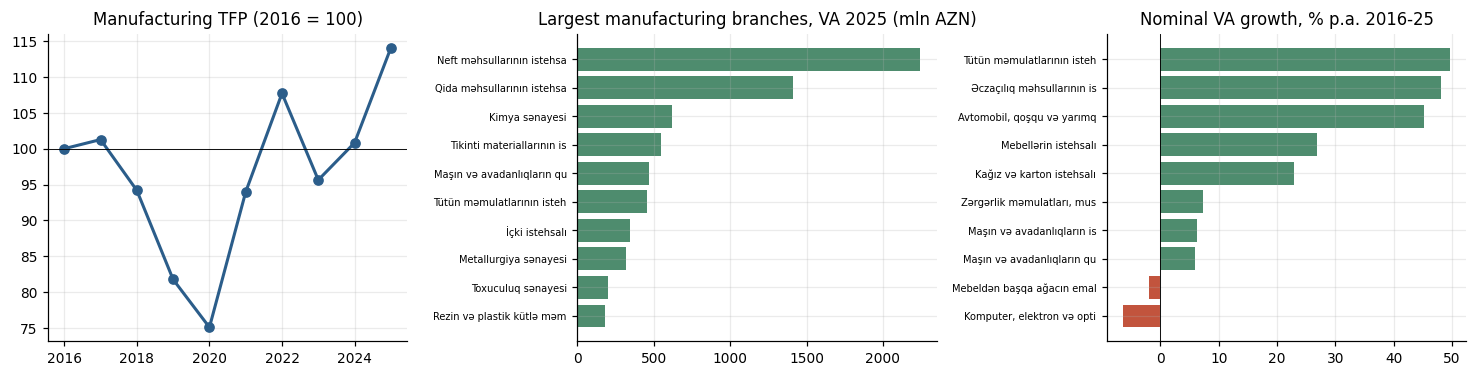

In [20]:
# Manufacturing TFP: value added per unit of the imposed Cobb-Douglas input bundle
MAN = IP[IP.sheet == 'Emal Sənayesi'].copy()
tfp_agg = MAN.groupby('year').apply(
    lambda g: g.gva.sum() / (g.K.sum()**ALPHA_K * (g.emp.sum()/1000)**ALPHA_L))
TFP_G_MAN = float((tfp_agg[LAST_ACT]/tfp_agg[2016])**(1/(LAST_ACT-2016)) - 1)
print(f"manufacturing TFP growth 2016-{LAST_ACT}: {TFP_G_MAN*100:+.2f}% p.a. "
      f"(descriptive; alpha_K={ALPHA_K}, alpha_L={ALPHA_L} from the grossed-up non-hydrocarbon factor share)")

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.5))
ax[0].plot(tfp_agg.index, tfp_agg/tfp_agg.iloc[0]*100, 'o-', color=PAL[0], lw=2)
ax[0].axhline(100, color='k', lw=.6); ax[0].set_title('Manufacturing TFP (2016 = 100)')
top = MAN[MAN.year==LAST_ACT].nlargest(10, 'gva').sort_values('gva')
ax[1].barh(range(len(top)), top.gva, color=PAL[2])
ax[1].set_yticks(range(len(top))); ax[1].set_yticklabels([b[:26] for b in top.branch], fontsize=6.5)
ax[1].set_title(f'Largest manufacturing branches, VA {LAST_ACT} (mln AZN)')
gr = MAN.pivot_table(index='year', columns='branch', values='gva')
g10 = (((gr.loc[LAST_ACT]/gr.loc[2016])**(1/(LAST_ACT-2016))-1).dropna().sort_values())*100
g10 = pd.concat([g10.head(5), g10.tail(5)])
ax[2].barh(range(len(g10)), g10.values, color=[PAL[1] if v < 0 else PAL[2] for v in g10.values])
ax[2].set_yticks(range(len(g10))); ax[2].set_yticklabels([b[:26] for b in g10.index], fontsize=6.5)
ax[2].axvline(0, color='k', lw=.6); ax[2].set_title('Nominal VA growth, % p.a. 2016-25')
plt.tight_layout(); plt.show()

## Hissə 8 — Panel blok II: iqtisadi rayonlar → kredit və investisiya elastiklikləri

İş kitabında həmçinin **2021–2025-ci illərdə müşahidə edilən 14 iqtisadi rayon** (70 müşahidə) üzrə sektor buraxılışı, müddət və valyuta
üzrə kreditlər, regional kredit faiz dərəcələri, depozitlər, vergi daxilolmaları, dövlət investisiyası, məşğulluq, əmək haqqı, müəssisələrin sayı və regional İQİ məlumatları var.

Bu panel konkret identifikasiya problemini həll etmək üçün istifadə olunur. Aqreqat illik məlumatlarda **kapitalın istifadə dəyəri (user cost
of capital) yoxlanılmış bütün investisiya spesifikasiyalarında yanlış işarə daşıyır** (Hissə 9-da sənədləşdirilmişdir). Azərbaycanda qeyri-neft
investisiyası əsasən dövlət və inzibati qərarlarla müəyyən edilir və 20 illik müşahidədə maliyyə kanalını identifikasiya etmək üçün faiz
dərəcəsinin müstəqil variasiyası çox azdır. Rayonlar arasında isə kredit şərtləri müstəqil şəkildə *dəyişir*, buna görə də kanal
orada identifikasiya edilə bilər.

In [21]:
REGION_SHEETS = ['Regionlar'] + [f'Regionlar {i}' for i in range(1, 14)]
REG_VARS = {
 'əhalinin sayı':'pop', 'pərakəndə ticarət dövriyyəsi həcmi':'retail',
 'əsas kapitala investisiyalar':'inv', 'tikinti quraşdırma işlərinə':'inv_cw',
 'iqtisadiyyatda muzdla çalışanların sayı':'emp',
 'muzdla çalışanların orta aylıq nominal əmək haqqı':'wage',
 'müəssisə və təşkilatların sayı':'firms', 'yeni açılmış iş yerləri':'newjobs',
 'cəmi kredit qoyuluşu':'credit', 'cəmi cəlb olunmuş əmanət':'deposits',
 'ümumi daxilolma':'tax', 'dövlət büdcəsindən investisiya':'pubinv',
 'cəmi mallar və xidmətlər üzrə':'cpi',
}
REG_SEC = {'sənaye':'ind', 'tikinti':'con', 'nəqliyyat və anbar təsərrüfatı':'tra',
           'informasiya və rabitə':'ict',
           'kənd təsərrüfatı, meşə təsərrüfatı və balıqçılıq':'agr',
           'kənd təsərrüfatı. meşə təsərrüfatı və balıqçılıq':'agr',
           'ticarət, nəqliyyat vasitələrinin təmiri xidmətləri':'trd',
           'ticarət. nəqliyyat vasitələrinin təmiri xidmətləri':'trd'}

def region_panel():
    recs = []
    for sh in REGION_SHEETS:
        if sh not in WB.sheetnames: continue
        mat = sheet_matrix(WB[sh])
        title  = clean(mat[0][0]) if mat[0][0] else sh
        region = re.sub(r'\s*iqtisadi rayonun.*$', '', title, flags=re.I).strip()
        if not region or len(region) > 40: region = sh
        hdr = None
        for i in range(4):
            ys = [(j, int(clean(mat[i][j])[:4])) for j in range(len(mat[i]))
                  if mat[i][j] is not None and re.fullmatch(r'(19|20)\d\d', clean(mat[i][j]))]
            if len(ys) >= 3: hdr = (i, ys); break
        if hdr is None: continue
        hrow, ycols = hdr; block = None
        for i in range(hrow+1, len(mat)):
            row = mat[i]
            if row[0] is None or not clean(row[0]): continue
            lab = clean(row[0]); low = az_lower(lab).rstrip(' *:')
            vals = {y: to_num(row[j]) for j, y in ycols}
            if 'fiziki həcm indeksi' in low: block = 'vol'; continue
            if 'milyon manat' in low and 'ümumi məhsul' in low: block = 'lvl'; continue
            if low == 'o cümlədən': continue
            if not any(np.isfinite(v) for v in vals.values()): continue
            name = None
            if   block and low in REG_SEC:                             name = f"{REG_SEC[low]}_{block}"
            elif block and low.startswith('ümumi məhsul buraxılışı'):  name = f"out_{block}"
            else:
                for k, v in REG_VARS.items():
                    if low.startswith(k): name = v; break
            if name is None: continue
            for y, v in vals.items():
                if np.isfinite(v): recs.append(dict(region=region, year=y, var=name, value=v))
    P = (pd.DataFrame(recs).pivot_table(index=['region','year'], columns='var',
                                        values='value', aggfunc='first').reset_index())
    P.columns.name = None
    return P

RP = region_panel().sort_values(['region','year']).reset_index(drop=True)
RP['unit'] = RP.region
for c in list(RP.columns):
    if c not in ('region','year','unit'): RP['ln_'+c] = np.log(RP[c].replace(0, np.nan))
print(f"regional panel: {RP.region.nunique()} regions x {RP.year.nunique()} years = {len(RP)} observations")
print("regions:", ", ".join(sorted(RP.region.unique())))
display(RP[RP.year==LAST_ACT][['region','pop','out_lvl','ind_lvl','credit','inv','pubinv','emp','wage','tax']]
        .set_index('region').round(1))

regional panel: 14 regions x 5 years = 70 observations
regions: Abşeron-Xızı, Bakı, Dağlıq Şirvan, Gəncə-Daşkəsən, Lənkəran-Astara, Mil-Muğan, Mərkəzi Aran, Naxçıvan, Qarabağ, Qazax-Tovuz, Quba-Xaçmaz, Şirvan-Salyan, Şəki-Zaqatala, Şərqi Zəngəzur


,pop,out_lvl,ind_lvl,credit,inv,pubinv,emp,wage,tax
region,,,,,,,,,
Abşeron-Xızı,880.200,"8,529.300","5,162.200","1,218.100","1,237.300",114.200,120.400,872.200,366.400
Bakı,"2,356.200","95,782.200","50,794.700","22,838.500","11,195.600",993.300,"1,007.900","1,381.000","14,760.900"
Dağlıq Şirvan,324.500,"1,259.700",126.500,208.800,310.400,65.100,27.800,697.500,65.300
Gəncə-Daşkəsən,600.400,"2,965.500","1,231.600",896.100,626.800,117.800,77.800,772.800,190.800
Lənkəran-Astara,949.300,"2,773.100",435.300,714.300,293.000,63.400,66.200,689.400,104.100
Mil-Muğan,530.500,"2,772.700",713.800,355.800,142.600,10.900,44.100,676.300,102.800
Mərkəzi Aran,727.600,"3,503.500",847.900,602.200,532.700,66.900,73.900,687.700,149.600
Naxçıvan,472.400,NaN,NaN,495.300,397.300,68.200,61.000,822.300,260.400
Qarabağ,751.100,"4,948.700",639.200,526.500,"2,275.600",79.100,66.200,718.800,123.700


In [22]:
print("=== Regional two-way FE: identifying the financial and fiscal channels ===")
spec = [('ln_out_lvl', ['ln_credit','ln_inv'],          'total output'),
        ('ln_out_lvl', ['ln_credit','ln_inv','ln_emp'], 'total output + labour'),
        ('ln_ind_lvl', ['ln_credit','ln_inv'],          'industry'),
        ('ln_agr_lvl', ['ln_credit','ln_pubinv'],       'agriculture'),
        ('ln_con_lvl', ['ln_inv','ln_pubinv'],          'construction'),
        ('ln_retail',  ['ln_wage','ln_emp'],            'retail turnover'),
        ('ln_trd_lvl', ['ln_retail'],                   'trade value added'),
        ('ln_tax',     ['ln_out_lvl'],                  'tax receipts')]
KEY_WILD = {('total output','credit'), ('industry','credit'), ('agriculture','credit'),
            ('construction','inv'), ('total output','inv')}
rows = []
for dep, regs, lbl in spec:
    if dep not in RP or any(r not in RP for r in regs): continue
    f = panel_fe(RP, dep, regs)
    for r in regs:
        i = f.names.index(r); rr = r.replace('ln_','')
        wp = wild_cluster_p(RP, dep, regs, r)[0] if (lbl, rr) in KEY_WILD else np.nan
        rows.append(dict(equation=lbl, regressor=rr, coef=f.beta[i], se=f.se[i],
                         p_DK_tT1=f.pval[i], p_wild=wp, n=f.n,
                         sig='***' if f.pval[i]<.01 else '**' if f.pval[i]<.05 else '*' if f.pval[i]<.10 else ''))
REGEL = pd.DataFrame(rows)
display(REGEL.round(3))
print("Inference: Driscoll-Kraay SE with bandwidth floor(T^1/4) = 1 and t(T-1) = t(4) reference distribution;")
print("p_wild = wild cluster bootstrap-t (clusters = the 5 years, Webb six-point weights, null imposed).")

def regel(eq, reg, default=np.nan):
    '''Look up one panel elasticity; returns a default if that pair was not estimated.'''
    m = REGEL[(REGEL.equation == eq) & (REGEL.regressor == reg)]
    return float(m.coef.iloc[0]) if len(m) else default

CRED_EL_OUT = regel('total output', 'credit')
CRED_EL_IND = regel('industry', 'credit')
CRED_EL_AGR = regel('agriculture', 'credit')
TRD_EL_REG  = regel('trade value added', 'retail')
TAX_EL_REG  = regel('tax receipts', 'out_lvl')
CON_EL_INV  = regel('construction', 'inv')
CRED_EL_OUT_WILDP = float(REGEL[(REGEL.equation=='total output') & (REGEL.regressor=='credit')].p_wild.iloc[0])
assert np.isfinite(CRED_EL_OUT), 'regional panel elasticities missing - check the panel build'

# The regional trade "elasticity" of ~1.0 is an artefact of how the regional trade value added is built:
# in most region-years it is an exact fixed multiple of retail turnover (an imputation), so the
# regression recovers the imputation rule, not behaviour.
ratio = (RP.trd_lvl/RP.retail).dropna()
TRD_IMPUTED_SHARE = float(ratio.round(3).value_counts().iloc[0])
TRD_IMPUTED_RATIO = float(ratio.round(3).value_counts().index[0])
print(f'''
Credit elasticity of output, identified from CROSS-REGION variation (T = 5 years):
   total output {CRED_EL_OUT:+.3f} (DK p on t(4) = {REGEL.loc[(REGEL.equation=="total output")&(REGEL.regressor=="credit"),"p_DK_tT1"].iloc[0]:.3f}, wild p = {CRED_EL_OUT_WILDP:.3f})
   industry {CRED_EL_IND:+.3f}    agriculture {CRED_EL_AGR:+.3f}

NOT EVIDENCE - the regional trade value-added equation is an imputation artefact:
   regional trade value added / retail turnover = {TRD_IMPUTED_RATIO:.3f} exactly in {int(TRD_IMPUTED_SHARE)} of {len(ratio)} region-years,
   so the estimated elasticity of {TRD_EL_REG:.3f} reproduces the statistical office's imputation rule. It is
   reported for completeness and is NOT used to corroborate the aggregate trade equation.

TRANSFER CAVEAT, stated because it governs what may legitimately be borrowed:
   Two-way fixed effects identify RELATIVE (cross-sectional) elasticities, purged of aggregate effects.
   The regional tax elasticity is {TAX_EL_REG:.2f} against ~1 in the aggregate data - precisely because
   aggregate buoyancy is driven by the national covariation that fixed effects remove.
   The credit elasticity of OUTPUT is a candidate for the investment equation only as a fallback
   (see D2); the tax elasticity is NOT transferred. The panel starts in 2021, after the hold-out cut,
   so no regional-panel parameter can be used in the 2021-2025 hold-out.''')

print("\nOne-way (region FE only), for comparison - the 5-year panel is not robust to this choice:")
for dep, regs, lbl in [('ln_out_lvl',['ln_credit','ln_inv'],'total output'),
                       ('ln_con_lvl',['ln_inv','ln_pubinv'],'construction')]:
    f = panel_fe(RP, dep, regs, twoway=False)
    print(f"  {lbl:<16} " + "   ".join(f"{r.replace('ln_','')}={f.beta[i]:+.3f}"
          for i, r in enumerate(f.names)))
print("  => reported rather than hidden: with T=5 the two-way estimates have limited power (see Part 17).")


=== Regional two-way FE: identifying the financial and fiscal channels ===


,equation,regressor,coef,se,p_DK_tT1,p_wild,n,sig
0,total output,credit,0.134,0.010,0.000,0.022,61,***
1,total output,inv,0.050,0.010,0.006,0.019,61,***
2,total output + labour,credit,0.237,0.067,0.024,NaN,61,**
3,total output + labour,inv,0.041,0.011,0.020,NaN,61,**
4,total output + labour,emp,-0.311,0.163,0.129,NaN,61,
5,industry,credit,0.682,0.035,0.000,0.016,61,***
6,industry,inv,-0.044,0.008,0.006,NaN,61,***
7,agriculture,credit,0.430,0.055,0.001,0.027,61,***
8,agriculture,pubinv,0.011,0.007,0.212,NaN,61,
9,construction,inv,0.518,0.112,0.010,0.021,62,***


Inference: Driscoll-Kraay SE with bandwidth floor(T^1/4) = 1 and t(T-1) = t(4) reference distribution;
p_wild = wild cluster bootstrap-t (clusters = the 5 years, Webb six-point weights, null imposed).

Credit elasticity of output, identified from CROSS-REGION variation (T = 5 years):
   total output +0.134 (DK p on t(4) = 0.000, wild p = 0.022)
   industry +0.682    agriculture +0.430

NOT EVIDENCE - the regional trade value-added equation is an imputation artefact:
   regional trade value added / retail turnover = 0.320 exactly in 58 of 63 region-years,
   so the estimated elasticity of 1.009 reproduces the statistical office's imputation rule. It is
   reported for completeness and is NOT used to corroborate the aggregate trade equation.

TRANSFER CAVEAT, stated because it governs what may legitimately be borrowed:
   Two-way fixed effects identify RELATIVE (cross-sectional) elasticities, purged of aggregate effects.
   The regional tax elasticity is 0.30 against ~1 in the aggregate 

## Hissə 9 — Struktur qiymətləndirmə, blok-blok

Aşağıdakı hər tənlik eyni qaydada təqdim olunur: əvvəlcə **iqtisadi əsaslandırma** (hansı mexanizmin iddia edildiyi və nə üçün), sonra
spesifikasiya, sonra isə diaqnostika ilə birlikdə qiymətləndirmə nəticəsi. Uğursuz tənliklər uğursuz kimi təqdim olunur.

Qiymətləndirmə reyestri hər tənlik üçün onun nümunəsini, əmsallarını, standart xətalarını, qalıq diaqnostikasını və istənilən qoyulmuş
məhdudiyyəti qeyd edir, beləliklə bütün model bir cədvəl əsasında yoxlanıla bilər (Hissə 10).

### ~30 səviyyə tənliyindən ibarət modeli ~20 illik müşahidə üzrə qiymətləndirilə bilən edən dörd vasitə

| Vasitə | Nə edir |
|---|---|
| 1. Test edilmiş məhdudiyyətlər | Nəzəri məhdudiyyətlər **test edilir**, sonra yalnız rədd edilmədikdə qoyulur. Hər biri bir sərbəstlik dərəcəsini geri qazandırır. |
| 2. Panel informasiyası | Sənaye panelindən (29 sahə, 2016–2025) alınan α_K faktor payı emal sənayesi üzrə *test edilir*; regional panel (14 rayon, 2021–2025) kredit elastikliyini yalnız ehtiyat variant kimi təqdim edir (Hissə 7–8). |
| 3. Qənaətcillik (parsimony) | Hər tənlikdə nəzəriyyə əsasında seçilmiş 1–3 izahedici dəyişən, VIF və şərt ədədi (condition number) üzrə yoxlama ilə. |
| 4. DOLS | **Gecikmiş asılı dəyişən olmadan** uzunmüddətli səviyyələr üzrə qiymətləndirmə; hər asılılıq qalıqlara əsaslanan kointeqrasiya testi və birinci fərqlər üzrə qiymətləndirmə ilə yoxlanılır. |

In [23]:
REG = {}   # equation registry: name -> everything needed to audit and to solve
EQB = {}   # equation BUILDERS: name -> f(data frame, context) -> estimated equation.
           # The same builder is run on the full sample (forecast model) and on data <= CUT
           # (hold-out), so every coefficient, restriction decision and specification switch is
           # re-made on pre-cut data in the hold-out.
CTX_FULL = {'cut': LAST_ACT}

def builder(name):
    def deco(fn):
        EQB[name] = fn
        return fn
    return deco

def equation(name, block, dep, spec, y, X, kind='level', to_cf=None, restriction=None,
             imposed=None, note='', diff=None, endog=None, ctx=None):
    '''Estimate one equation in its FINAL form (restrictions already substituted in).
    kind='level' -> long-run estimator lr_fit (DOLS rule of Part 5); kind='rate' -> static OLS.
    to_cf maps the estimated-form coefficients into the coefficients the solver uses.
    diff = (y, X) of the unrestricted level specification, re-estimated in first differences.'''
    fit = lr_fit(y, X) if kind == 'level' else rate_fit(y, X)
    if ctx is not None and ctx.get('cut', LAST_ACT) < LAST_ACT and fit.dof < 5:
        raise ValueError(f"{name}: only {fit.dof} residual df on data <= {ctx['cut']} - "
                         "hold-out re-estimation infeasible, respecify")
    b = pd.Series(fit.beta, index=fit.names)
    cf = to_cf(b) if to_cf else b.copy()
    return dict(name=name, block=block, dep=dep, spec=spec, fit=fit, cf=cf, y=y, X=X,
                to_cf=to_cf, kind=kind, restriction=restriction, imposed=imposed or {},
                note=note, diff=diff, endog=endog or [])

def register(res):
    '''Store an estimated equation with its diagnostics so the whole model is auditable.'''
    fit = res['fit']; u = fit.resid.dropna()
    dw = float(((np.diff(u.values)**2).sum()/(u.values**2).sum())) if len(u) > 2 else np.nan
    if res['kind'] == 'level':
        eg_stat, eg_p = eg_coint_p(u, len(fit.stoch), fit.has_trend)
    else:
        eg_stat, eg_p = np.nan, np.nan          # rates / growth rates: EG test not applicable
    try:    jb = stats.jarque_bera(u.values)[1]
    except Exception: jb = np.nan
    try:
        aux = ols(pd.Series(u.values**2, index=u.index),
                  pd.DataFrame({'fit': fit.fitted.reindex(u.index)}), cov='nonrobust')
        bp = aux.pval[1]
    except Exception: bp = np.nan
    rho = float(np.clip(np.corrcoef(u.values[1:], u.values[:-1])[0, 1], 0, 1)) if len(u) > 3 else 0.0
    # the same equation in first differences, beside the level coefficients
    dtab = []
    if res['kind'] == 'level' and res.get('diff') is not None:
        yd, Xd = res['diff']
        fd = diff_form(yd, Xd)
        if fd is not None:
            tq = stats.t.ppf(.975, fd.dof)
            for c in fd.names[1:]:
                i = fd.names.index(c); lv = float(res['cf'].get(c, np.nan))
                lo, hi = fd.beta[i]-tq*fd.se[i], fd.beta[i]+tq*fd.se[i]
                dtab.append(dict(regressor=c, level=lv, diff=fd.beta[i], diff_lo=lo, diff_hi=hi,
                                 outside=bool(np.isfinite(lv) and not (lo <= lv <= hi))))
    name = res['name']
    REG[name] = dict(res, coef=pd.Series(fit.beta, index=fit.names),
                     se=pd.Series(fit.se, index=fit.names), p=pd.Series(fit.pval, index=fit.names),
                     n=fit.n_level, n_est=fit.n, df=fit.dof, estimator=fit.estimator, r2=fit.r2, dw=dw,
                     eg_stat=eg_stat, eg_p=eg_p, jb_p=jb, bp_p=bp, rho=rho, difftab=dtab,
                     sample=(int(u.index.min()), int(u.index.max())),
                     core=[c for c in fit.names if c != 'const'])
    return fit

def show(name, title=None):
    e = REG[name]
    print(e['fit'].summary(title or f"[{name}] {e['dep']} ~ {' + '.join(e['core']) or 'constant'}"))
    lab = ('' if e['kind'] != 'level' else
           '  -> t-statistics DESCRIPTIVE (cointegration not established)' if not (e['eg_p'] <= .10) else '')
    print(f"  estimator: {e['estimator']}  levels n={e['n']}  residual df={e['df']}  DW={e['dw']:.2f}"
          + (f"  EG coint p={e['eg_p']:.3f}" if np.isfinite(e['eg_p']) else "  EG: n/a (rate equation)")
          + f"  JB p={e['jb_p']:.3f}  BP p={e['bp_p']:.3f}" + lab)
    for r in e['difftab']:
        print(f"  first-difference form: {r['regressor']} = {r['diff']:+.3f} "
              f"[{r['diff_lo']:+.3f}, {r['diff_hi']:+.3f}] vs level {r['level']:+.3f}"
              + ("  <-- level OUTSIDE difference-form 95% CI" if r['outside'] else ""))
    if e['imposed']:     print(f"  IMPOSED: {e['imposed']}")
    if e['restriction']: print(f"  RESTRICTION TEST: {e['restriction']}")
    if e['note']:        print(f"  NOTE: {e['note']}")
    print()

def build_and_show(name, title=None):
    register(EQB[name](D, CTX_FULL)); show(name, title)

def test_text(F, p, se, label):
    '''Phrase a restriction test honestly: a non-rejection is never a confirmation.'''
    verdict = 'REJECTED' if p <= .05 else 'not rejected (low power)'
    return f"H0 {label}: HAC-F={F:.2f} p={p:.3f}, s.e. of tested combination {se:.3f} -> {verdict}"

Lg = lambda s: np.log(s.replace(0, np.nan)) if isinstance(s, pd.Series) else np.log(s)
POP  = D['pop']
pc   = lambda s: D[s]/POP
lpc  = lambda s: np.log((D[s]/POP).replace(0, np.nan))
def lpcD(Dd, col): return np.log((Dd[col]/Dd['pop']).replace(0, np.nan))
def drop_wrong_signed(y, X, expected):
    '''Drop regressors whose long-run coefficient has the wrong sign AND is insignificant (p > 0.10).
    expected: {column: +1 or -1}. Runs inside the builders, so the hold-out re-makes the decision on
    pre-cut data. Returns (X, text).'''
    f = lr_fit(y, X); dropped = []
    for c, sg in expected.items():
        i = f.names.index(c)
        if np.sign(f.beta[i]) != sg and f.pval[i] > .10: dropped.append(f"{c} ({f.beta[i]:+.3f}, p={f.pval[i]:.2f})")
    keep = [c for c in X.columns if not any(d.startswith(c + ' ') for d in dropped)]
    return X[keep], ('dropped as wrong-signed and insignificant: ' + ', '.join(dropped)) if dropped else ''
print("registry and equation-builder framework initialised")


registry and equation-builder framework initialised


### 9.1 Blok B — karbohidrogenlər: endogen buraxılış deyil, ekzogen gəlir

**İqtisadi əsaslandırma.** Azərbaycan dünya neft bazarlarında qiyməti qəbul edən (price-taker) ölkədir və onun hasilatı daxili tələb,
məzənnə və ya faiz dərəcəsi ilə deyil, yataqların yetkinlik dərəcəsi və hasilatın pay bölgüsü sazişləri ilə müəyyən olunur. Buna görə də blok
bir istiqamətdə işləyir: girişdə həcmlər və dünya qiymətləri, çıxışda ixrac gəlirləri və mədənçıxarmanın əlavə dəyəri. Bütün proqnozu
ssenaridən asılı (ssenari-şərti) edən məhz budur.

Üç asılılıq qiymətləndirilir, biri isə qəsdən qiymətləndirilmir.

In [24]:
# ---- B1 oil export price: pass-through from Brent -----------------------------
@builder('B1_oil_price')
def _b1(Dd, ctx):
    y, X = Lg(Dd.oil_exp_price), pd.DataFrame({'ln_brent': Lg(Dd.brent)})
    f = lr_fit(y, X); F, p = restrict_row(f, 'ln_brent', 1.0)
    se = comb_se(f, [0, 1])
    return equation('B1_oil_price', 'B hydrocarbon', 'ln oil export price', 'ln Brent', y, X,
                    restriction=test_text(F, p, se, 'unit pass-through (not imposed)'),
                    diff=(y, X), ctx=ctx)
build_and_show('B1_oil_price', 'B1  Azerbaijani oil export price ~ Brent')

# ---- B2 mining real value added: volume-determined, CRS tested ---------------
def _hc_volume_eq(name, ydep, Dd, ctx, label, note=''):
    y, X = Lg(ydep), pd.DataFrame({'ln_oil': Lg(Dd.oil_prod), 'ln_gas': Lg(Dd.gas_prod)})
    f = lr_fit(y, X)
    R = np.zeros(len(f.beta)); R[f.names.index('ln_oil')] = 1; R[f.names.index('ln_gas')] = 1
    F, p = wald_test(f, R, [1.0]); se = comb_se(f, R)
    txt = (f"elasticities sum to 1 (sum={R@f.beta:.3f})")
    if p > .05:
        yr = y - X.ln_gas; Xr = pd.DataFrame({'ln_oil_rel': X.ln_oil - X.ln_gas})
        tc = lambda b: pd.Series({'const': b['const'], 'ln_oil': b['ln_oil_rel'], 'ln_gas': 1-b['ln_oil_rel']})
        return equation(name, 'B hydrocarbon', label, 'ln oil output + ln gas output (CRS imposed)', yr, Xr,
                        to_cf=tc, restriction=test_text(F, p, se, txt) + ' -> IMPOSED',
                        imposed={'constant returns': 'oil + gas elasticities = 1'}, diff=(y, X), note=note, ctx=ctx)
    return equation(name, 'B hydrocarbon', label, 'ln oil output + ln gas output', y, X,
                    restriction=test_text(F, p, se, txt) + ' -> not imposed', diff=(y, X), note=note, ctx=ctx)

@builder('B2_mining')
def _b2(Dd, ctx): return _hc_volume_eq('B2_mining', Dd.rva_min, Dd, ctx, 'ln real mining VA')
build_and_show('B2_mining', 'B2  Real mining value added ~ hydrocarbon volumes')
CRS_MIN_OK = 'IMPOSED' in REG['B2_mining']['restriction']

# ---- B3 real oil-gas GDP (mining + refining + oil services) -------------------
@builder('B3_oilgdp')
def _b3(Dd, ctx): return _hc_volume_eq('B3_oilgdp', Dd.rgdpoil, Dd, ctx, 'ln real oil-gas GDP',
                                       note='wider than mining: includes oil refining and oil services')
build_and_show('B3_oilgdp', 'B3  Real oil-and-gas GDP ~ hydrocarbon volumes')

# ---- B4 hydrocarbon export value: an IDENTITY, not a regression -------------
# Estimating this as a regression gave an elasticity of 1.285 on oil revenue, which is
# economically impossible: export value IS volume times price, so the elasticity must be one.
# The excess was a UNIT ERROR hiding in the data. Oil export volume is in million TONNES while
# the export price is per BARREL, so the product needs a barrels-per-tonne conversion. Recovering
# that factor from the published oil export VALUE gives 7.40, and with it the identity is exact.
def bbl_per_tonne(cut):
    return float((A_RAW.oil_exp_val/(D.oil_exp_vol*D.oil_exp_price)).loc[2015:cut].mean())
BBL_PER_TONNE = bbl_per_tonne(LAST_ACT)
oil_val_id = D.oil_exp_vol*BBL_PER_TONNE*D.oil_exp_price       # mln USD
gas_val_id = D.gas_exp_vol*D.gas_exp_price                     # bcm x USD/thousand m3 = mln USD
print(f"barrels per tonne recovered from the data: {BBL_PER_TONNE:.3f}")
chk = pd.DataFrame({'oil identity': oil_val_id, 'oil published': A_RAW.oil_exp_val,
                    'gas identity': gas_val_id, 'gas published': A_RAW.gas_exp_val})
chk['oil error %'] = (chk['oil identity']/chk['oil published']-1)*100
chk['gas error %'] = (chk['gas identity']/chk['gas published']-1)*100
display(chk.loc[2018:LAST_ACT].round(3))
print(f"identity accuracy: oil max |error| {chk['oil error %'].abs().max():.3f}%, "
      f"gas max |error| {chk['gas error %'].abs().max():.3f}%\n")

# The balance-of-payments measure of hydrocarbon exports has broader coverage than the customs
# volume x price product in the early years, but the two have converged: the ratio was 1.35 in
# 2012 and about 1.00 on average over 2021-25 (printed below). A calibrated ratio on recent years closes the gap.
def bop_oil_ratio(cut):
    ov = D.oil_exp_vol*bbl_per_tonne(cut)*D.oil_exp_price; gv = D.gas_exp_vol*D.gas_exp_price
    return float((D.x_g_oil_usd/(ov + gv)).loc[cut-4:cut].mean())
BOP_OIL_RATIO = bop_oil_ratio(LAST_ACT)
print(f"BOP hydrocarbon exports / (volume x price), 5-year average: {BOP_OIL_RATIO:.4f}")
rat = (D.x_g_oil_usd/(oil_val_id + gas_val_id))
display(rat.loc[[2012, BASE_YEAR, 2020, 2022, 2024, LAST_ACT]].round(3)
           .to_frame('BOP / identity ratio'))
print(f"=> B4 is an IDENTITY: hydrocarbon exports = ratio x ({BBL_PER_TONNE:.2f} x oil volume x oil price")
print("   + gas volume x gas price). No elasticity is estimated, so a given volume decline")
print("   produces a proportional export decline rather than an amplified one.")
resid_b4 = np.log(D.x_g_oil_usd) - np.log(BOP_OIL_RATIO*(oil_val_id + gas_val_id))
print(f"   residual standard deviation of the identity, 2021-{LAST_ACT}: "
      f"{resid_b4.loc[2021:LAST_ACT].std():.4f} log points")

# ---- what is deliberately NOT estimated -------------------------------------
fg = ols(np.log(D.gas_exp_price), pd.DataFrame({'ln_brent': np.log(D.brent),
        'ln_brent_lag': np.log(D.brent).shift(1)}), cov='hac')
print("NOT USED - gas export price on Brent (the oil-indexation hypothesis):")
print(fg.table(3).to_string())
print(f"  R2 = {fg.r2:.3f}, n = {fg.n}, neither coefficient significant.")
print('''  The 2022 European gas shock decoupled Azerbaijani gas contract prices from oil
  (price rose from 276 to 790 USD/kcm while Brent rose far less). Forcing a Brent
  relationship here would fabricate a transmission channel that no longer exists.
  DECISION: the gas export price is an EXOGENOUS SCENARIO VARIABLE, set by the user.''')

B1  Azerbaijani oil export price ~ Brent   n=28  R2=0.9747  adj=0.9738
           coef    se      t     p  sig
const    -0.763 0.287 -2.659 0.014   **
ln_brent  1.174 0.068 17.307 0.000  ***
  estimator: DOLS(+/-1)  levels n=29  residual df=23  DW=1.20  EG coint p=0.237  JB p=0.016  BP p=0.120  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_brent = +0.901 [+0.766, +1.036] vs level +1.174  <-- level OUTSIDE difference-form 95% CI
  RESTRICTION TEST: H0 unit pass-through (not imposed): HAC-F=6.57 p=0.017, s.e. of tested combination 0.068 -> REJECTED

B2  Real mining value added ~ hydrocarbon volumes   n=20  R2=0.9577  adj=0.9530
        coef    se      t     p  sig
const  5.488 0.193 28.378 0.000  ***
ln_oil 0.861 0.040 21.420 0.000  ***
ln_gas 0.265 0.032  8.169 0.000  ***
  estimator: DOLS(+/-1)  levels n=21  residual df=11  DW=0.52  EG coint p=0.004  JB p=0.005  BP p=0.006
  first-difference form: ln_oil = +1.172 [+0.924, +1.421] vs level +0.86

,oil identity,oil published,gas identity,gas published,oil error %,gas error %
year,,,,,,
2018,"15,710.576","15,710.529","1,512.291","1,512.291",0.000,-0.000
2019,"14,814.177","14,814.133","2,366.834","2,366.834",0.000,-0.000
2020,"9,363.599","9,363.571","2,190.522","2,190.522",0.000,0.000
2021,"13,218.961","13,218.922","5,534.398","5,534.398",0.000,0.000
2022,"19,483.682","19,483.624","14,989.676","14,989.676",0.000,-0.000
2023,"16,240.878","16,240.830","13,678.344","13,678.344",0.000,0.000
2024,"14,437.399","14,437.356","8,406.729","8,406.729",0.000,0.000
2025,"12,090.779","12,091.140","8,820.582","8,821.250",-0.003,-0.008


identity accuracy: oil max |error| 0.003%, gas max |error| 0.008%

BOP hydrocarbon exports / (volume x price), 5-year average: 1.0016


,BOP / identity ratio
year,
2012,1.470
2015,1.358
2020,0.936
2022,1.139
2024,0.996
2025,0.985


=> B4 is an IDENTITY: hydrocarbon exports = ratio x (7.40 x oil volume x oil price
   + gas volume x gas price). No elasticity is estimated, so a given volume decline
   produces a proportional export decline rather than an amplified one.
   residual standard deviation of the identity, 2021-2025: 0.0975 log points
NOT USED - gas export price on Brent (the oil-indexation hypothesis):
              coef    se     t     p sig
const        1.465 1.905 0.769 0.452    
ln_brent     0.571 0.402 1.422 0.173    
ln_brent_lag 0.327 0.452 0.723 0.480    
  R2 = 0.169, n = 20, neither coefficient significant.
  The 2022 European gas shock decoupled Azerbaijani gas contract prices from oil
  (price rose from 276 to 790 USD/kcm while Brent rose far less). Forcing a Brent
  relationship here would fabricate a transmission channel that no longer exists.
  DECISION: the gas export price is an EXOGENOUS SCENARIO VARIABLE, set by the user.


### 9.2 Blok C — sektor bloku və sektorlararası ötürülmə

Bu, FR1-in özəyidir. On bir DSK sektorunun hər biri aşağıdakı ümumi formada öz struktur tənliyinə malikdir

$$\ln \text{real VA}_i=\alpha_i+\beta_i\ln(\text{capacity}_i)+\underbrace{\textstyle\sum_j\delta_{ij}\ln \text{real VA}_j}_{\text{inter-sector linkages}}+\gamma_i\ln(\text{demand}_i)+\lambda_i\,\text{trend}$$

$\delta_{ij}$ hədləri *"hər sektora əlaqəli sektorlar necə təsir edir"* sualına cavab verir. Onlar heç vaxt uyğunluq axtarışı yolu ilə
deyil, **a priori** xərclər–buraxılış (input–output) məntiqi əsasında seçilir: emal sənayesi kənd təsərrüfatından xammal alır və tikintiyə tikinti
materialları satır; nəqliyyat ticarət və tranzit yüklərini daşıyır; ticarət ev təsərrüfatlarının istehlakını paylayır.

**Qeydə alınmağa dəyər trend intizamı dərsi.** İlkin spesifikasiyada miqyas dəyişəni kimi `ln(population)` istifadə edilmiş və bir neçə
sektor üzrə 2–4 həddində elastikliklər alınmışdı. Əhali 2000–2025-ci illərdə demək olar ki, deterministik trenddir, buna görə də o,
ümumi faktor məhsuldarlığının artımını özünə çəkirdi. Bütün model boyu iki düzəliş tətbiq edilir: ev təsərrüfatlarının tələbi ilə müəyyən
olunan sektorlar **adambaşına** modelləşdirilir (əhali üzrə elastiklik qiymətləndirilmir, vahidə bərabər qoyulur) və texniki tərəqqi
trendli izahedici dəyişən vasitəsilə gizli şəkildə daxil edilmək əvəzinə **açıq trend** ilə ifadə olunur.

In [25]:
# ---- C1 Agriculture ---------------------------------------------------------
# Economics: land-constrained, so output grows through capital deepening (irrigation,
# machinery, greenhouses) and productivity, not through labour. Weather is unobservable
# and enters the residual - which is why agriculture's residual variance is the largest.
@builder('C1_agr')
def _c1(Dd, ctx):
    y, X0 = Lg(Dd.rva_agr), pd.DataFrame({'ln_K_agr': Lg(Dd.K_agr), 'trend': Dd.trend})
    X, txt = drop_wrong_signed(y, X0, {'ln_K_agr': +1})
    if AGR_BREAK: X = X.assign(trend_post2015=np.maximum(Dd.trend - 15, 0))
    return equation('C1_agr', 'C sector', 'ln real agriculture VA', ' + '.join(X.columns),
                    y, X, diff=(y, X0), ctx=ctx, restriction=txt or None,
                    note="weather is in the residual" + ("; trend break at 2015 chosen on pre-cut data" if AGR_BREAK else ""))
# Trend break: tested on data through CUT only (the specification rule). A break at 2015 (the model's
# devaluation break) is added if its coefficient is significant at 5% on pre-cut data.
_ab = lr_fit(Lg(D.rva_agr.loc[:CUT]), pd.DataFrame({'trend': D.trend.loc[:CUT],
                                                      'trend_post2015': np.maximum(D.trend.loc[:CUT] - 15, 0)}))
AGR_BREAK = bool(_ab.pval[2] < .05)
print(f"agriculture trend break at 2015, pre-cut test: post-2015 slope change {_ab.beta[2]:+.4f} (p={_ab.pval[2]:.3f}) -> "
      f"{'ADOPTED' if AGR_BREAK else 'not adopted'}")
build_and_show('C1_agr', 'C1  Agriculture, forestry & fishing')

# ---- C2 Mining = B2 --------------------------------------------------------
print("C2  Mining & quarrying: already estimated as B2 (volume-determined).\n")

# ---- C3 Manufacturing ------------------------------------------------------
# Economics: capacity (capital) plus demand pulls - construction (building materials),
# agriculture (food processing inputs, the largest manufacturing branch) and export demand.
# The candidate comparison and the choice use ONLY data through CUT, so the hold-out window
# plays no part in the specification choice.
def c3_candidates(Dd):
    return {
     'K + construction + exports':    {'ln_K_man': Lg(Dd.K_man), 'ln_va_con': Lg(Dd.rva_con), 'ln_x_non': Lg(Dd.rx_non)},
     'K + construction + agriculture':{'ln_K_man': Lg(Dd.K_man), 'ln_va_con': Lg(Dd.rva_con), 'ln_va_agr': Lg(Dd.rva_agr)},
     'K + trend':                     {'ln_K_man': Lg(Dd.K_man), 'trend': Dd.trend},
     'K + non-oil GDP + trend':       {'ln_K_man': Lg(Dd.K_man), 'ln_gdpnon': Lg(Dd.rgdpnon), 'trend': Dd.trend}}
print(f"Manufacturing candidate specifications, estimated on data through {CUT} only (selection sample)")
rows = []
for lbl, xd in c3_candidates(D.loc[:CUT]).items():
    X = pd.DataFrame(xd); ff = lr_fit(Lg(D.rva_man.loc[:CUT]), X)
    _, egp = eg_coint_p(ff.resid, len(ff.stoch), ff.has_trend)
    linkage_ok = all(v > 0 for k, v in zip(ff.names[1:], ff.beta[1:]) if k != 'trend')
    rows.append(dict(specification=lbl, n=ff.n_level, estimator=ff.estimator, R2=round(ff.r2,3),
                     eg_coint_p=round(egp,3), maxVIF=round(vif(X).max(),1), all_signs_ok=linkage_ok,
                     coefs=", ".join(f"{k.replace('ln_','')}={v:+.2f}" for k, v in zip(ff.names[1:], ff.beta[1:]))))
C3CAND = pd.DataFrame(rows)
display(C3CAND)
_ok = [r.specification for r in C3CAND.itertuples() if r.all_signs_ok and r.specification != 'K + trend']
C3_CHOICE = _ok[0] if _ok else 'K + construction + exports'
print(f"choice rule (pre-cut data): first theory-ranked specification with every capacity and linkage coefficient "
      f"positive; " + (f"-> '{C3_CHOICE}'" if _ok else
      f"NO candidate satisfies it on pre-cut data, so the theory-preferred linkage specification '{C3_CHOICE}' "
      "is kept, and its weakness is recorded here rather than resolved by searching further"))

@builder('C3_man')
def _c3(Dd, ctx):
    y, X = Lg(Dd.rva_man), pd.DataFrame(c3_candidates(Dd)[C3_CHOICE])
    f = lr_fit(y, X)
    aK = ctx['alpha'][1]
    F, p = restrict_row(f, 'ln_K_man', aK); se = comb_se(f, [0, 1] + [0]*(len(f.beta)-2))
    txt = f"capital elasticity = factor-share alpha_K {aK:.2f} (estimate {f.beta[1]:.3f})"
    if p > .05:
        yr = y - aK*X.ln_K_man; Xr = X.drop(columns='ln_K_man')
        tc = lambda b, aK=aK: pd.concat([pd.Series({'const': b['const'], 'ln_K_man': aK}), b.drop('const')])
        return equation('C3_man', 'C sector', 'ln real manufacturing VA',
                        f'alpha_K ln K (imposed) + {" + ".join(Xr.columns)}', yr, Xr, to_cf=tc,
                        restriction=test_text(F, p, se, txt) + ' -> IMPOSED',
                        imposed={'alpha_K (grossed-up non-hydrocarbon factor share)': aK},
                        diff=(y, X), endog=[c for c in Xr.columns if c != 'ln_K_man'], ctx=ctx)
    return equation('C3_man', 'C sector', 'ln real manufacturing VA', ' + '.join(X.columns), y, X,
                    restriction=test_text(F, p, se, txt) + ' -> not imposed; capital elasticity freely estimated',
                    diff=(y, X), endog=[c for c in X.columns if c != 'ln_K_man'], ctx=ctx)
CTX_FULL['alpha'] = (ALPHA_L, ALPHA_K)
build_and_show('C3_man', 'C3  Manufacturing')


agriculture trend break at 2015, pre-cut test: post-2015 slope change -0.0045 (p=0.517) -> not adopted
C1  Agriculture, forestry & fishing   n=26  R2=0.9863  adj=0.9857
       coef    se       t     p  sig
const 7.557 0.024 309.915 0.000  ***
trend 0.037 0.002  24.874 0.000  ***
  estimator: OLS (no stochastic regressor)  levels n=26  residual df=24  DW=0.72  EG coint p=0.286  JB p=0.010  BP p=0.101  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_K_agr = +0.009 [-0.028, +0.045] vs level +nan
  RESTRICTION TEST: dropped as wrong-signed and insignificant: ln_K_agr (-0.004, p=0.65)
  NOTE: weather is in the residual

C2  Mining & quarrying: already estimated as B2 (volume-determined).

Manufacturing candidate specifications, estimated on data through 2020 only (selection sample)


,specification,n,estimator,R2,eg_coint_p,maxVIF,all_signs_ok,coefs
0,K + construction + exports,11,"OLS (static; DOLS infeasible, df too small)",0.983,0.015,2.700,False,"K_man=+0.30, va_con=-0.12, x_non=+0.06"
1,K + construction + agriculture,16,DOLS(0: contemporaneous dX only),0.909,0.163,13.900,False,"K_man=-0.13, va_con=+0.12, va_agr=+1.50"
2,K + trend,16,DOLS(0: contemporaneous dX only),0.913,0.131,22.900,False,"K_man=-0.04, trend=+0.04"
3,K + non-oil GDP + trend,16,DOLS(0: contemporaneous dX only),0.906,0.373,27.400,False,"K_man=-0.07, gdpnon=+0.07, trend=+0.05"


choice rule (pre-cut data): first theory-ranked specification with every capacity and linkage coefficient positive; NO candidate satisfies it on pre-cut data, so the theory-preferred linkage specification 'K + construction + exports' is kept, and its weakness is recorded here rather than resolved by searching further
C3  Manufacturing   n=15  R2=0.8058  adj=0.7572
            coef    se      t     p  sig
const     -1.057 2.601 -0.406 0.695     
ln_K_man   0.241 0.120  2.009 0.079    *
ln_va_con  0.195 0.186  1.048 0.325     
ln_x_non   0.711 0.204  3.485 0.008  ***
  estimator: DOLS(0: contemporaneous dX only)  levels n=16  residual df=8  DW=1.15  EG coint p=0.732  JB p=0.760  BP p=0.316  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_K_man = +0.123 [-0.065, +0.312] vs level +0.241
  first-difference form: ln_va_con = -0.023 [-0.196, +0.150] vs level +0.195  <-- level OUTSIDE difference-form 95% CI
  first-difference form: ln_x_non = +0.103 [+0.

In [26]:
# ---- C4 Electricity, gas & steam -------------------------------------------
# Economics: derived demand. Electricity is an input to everything else, so output tracks
# non-oil activity; the trend carries network extension and efficiency.
@builder('C4_elc')
def _c4(Dd, ctx):
    y, X = Lg(Dd.rva_elc), pd.DataFrame({'ln_gdpnon': Lg(Dd.rgdpnon), 'trend': Dd.trend})
    return equation('C4_elc', 'C sector', 'ln real electricity VA', 'ln non-oil GDP + trend', y, X,
                    diff=(y, X), endog=['ln_gdpnon'], ctx=ctx)
build_and_show('C4_elc', 'C4  Electricity, gas & steam')

# ---- C5 Water supply & waste (per capita) ----------------------------------
# Economics: a household and municipal utility. Per-capita form imposes unit population
# elasticity instead of estimating a spurious one.
@builder('C5_wat')
def _c5(Dd, ctx):
    y, X = lpcD(Dd, 'rva_wat'), pd.DataFrame({'ln_gdpnon_pc': lpcD(Dd, 'rgdpnon'), 'trend': Dd.trend})
    return equation('C5_wat', 'C sector', 'ln real water VA per capita', 'ln non-oil GDP per capita + trend',
                    y, X, imposed={'population elasticity': 1.0}, diff=(y, X), endog=['ln_gdpnon_pc'], ctx=ctx)
build_and_show('C5_wat', 'C5  Water supply & waste (per capita)')

# ---- C6 Construction -------------------------------------------------------
# Economics: construction output IS investment demand realised. Public capital spending and
# private investment are the two drivers; they are separated because their multipliers differ
# and because public investment is the policy lever the model needs.
@builder('C6_con')
def _c6(Dd, ctx):
    y, X = Lg(Dd.rva_con), pd.DataFrame({'ln_inv_state': Lg(Dd.rinv_state), 'ln_inv_priv': Lg(Dd.rinv_priv)})
    return equation('C6_con', 'C sector', 'ln real construction VA',
                    'ln real state investment + ln real private investment', y, X, diff=(y, X),
                    endog=['ln_inv_state', 'ln_inv_priv'], ctx=ctx,
                    note=f'regional panel: construction responds to total investment with elasticity {CON_EL_INV:+.3f}')
build_and_show('C6_con', 'C6  Construction')

# ---- C7 Trade & vehicle repair, with unit elasticity tested ------------------
# Economics: the trade margin is a broadly stable share of the turnover it distributes,
# so value added should move one-for-one with real consumption.
@builder('C7_trd')
def _c7(Dd, ctx):
    y, X = Lg(Dd.rva_trd), pd.DataFrame({'ln_cons': Lg(Dd.rcons)})
    f = lr_fit(y, X); F, p = restrict_row(f, 'ln_cons', 1.0); se = comb_se(f, [0, 1])
    txt = f"unit elasticity (estimate {f.beta[1]:.3f})"
    if p > .05:
        return equation('C7_trd', 'C sector', 'ln real trade VA - ln real consumption', 'constant (unit elasticity imposed)',
                        y - X.ln_cons, pd.DataFrame(index=X.index),
                        to_cf=lambda b: pd.Series({'const': b['const'], 'ln_cons': 1.0}),
                        restriction=test_text(F, p, se, txt) + ' -> IMPOSED', imposed={'ln_cons': 1.0},
                        diff=(y, X), ctx=ctx)
    return equation('C7_trd', 'C sector', 'ln real trade VA', 'ln real consumption', y, X,
                    restriction=test_text(F, p, se, txt) + ' -> not imposed', diff=(y, X), endog=['ln_cons'], ctx=ctx)
build_and_show('C7_trd', 'C7  Trade & vehicle repair')
TRD_UNIT_OK = 'IMPOSED' in REG['C7_trd']['restriction']

# ---- C8 Tourism & catering (per capita) ------------------------------------
# Economics: a superior good in household budgets, plus inbound tourism receipts. Income
# elasticity above one is expected and is what the data show.
@builder('C8_tou')
def _c8(Dd, ctx):
    y, X = lpcD(Dd, 'rva_tou'), pd.DataFrame({'ln_hhdisp_pc': lpcD(Dd, 'rhhdisp'), 'trend': Dd.trend})
    return equation('C8_tou', 'C sector', 'ln real tourism VA per capita',
                    'ln real disposable income per capita + trend', y, X,
                    imposed={'population elasticity': 1.0}, diff=(y, X), endog=['ln_hhdisp_pc'], ctx=ctx)
build_and_show('C8_tou', 'C8  Tourism & catering (per capita)')


C4  Electricity, gas & steam   n=20  R2=0.9137  adj=0.9042
           coef    se     t     p sig
const     5.731 1.954 2.933 0.011  **
ln_gdpnon 0.038 0.200 0.191 0.851    
trend     0.028 0.009 2.934 0.011  **
  estimator: DOLS(+/-1)  levels n=21  residual df=14  DW=1.02  EG coint p=0.429  JB p=0.495  BP p=0.102  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_gdpnon = +0.439 [+0.048, +0.830] vs level +0.038  <-- level OUTSIDE difference-form 95% CI

C5  Water supply & waste (per capita)   n=16  R2=0.9228  adj=0.9117
               coef    se       t     p  sig
const        -5.710 0.268 -21.286 0.000  ***
ln_gdpnon_pc  0.565 0.289   1.959 0.079    *
trend         0.021 0.009   2.410 0.037   **
  estimator: DOLS(+/-1)  levels n=17  residual df=10  DW=0.77  EG coint p=0.963  JB p=0.850  BP p=0.968  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_gdpnon_pc = +0.785 [+0.337, +1.233] vs level +0.565
  IMPOSED: 

C6  Construction   n=23  R2=0.9516  adj=0.9474
              coef    se     t     p  sig
const        1.089 0.667 1.634 0.125     
ln_inv_state 0.226 0.055 4.148 0.001  ***
ln_inv_priv  0.625 0.117 5.337 0.000  ***
  estimator: DOLS(+/-1)  levels n=26  residual df=14  DW=0.71  EG coint p=0.385  JB p=0.839  BP p=0.125  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_inv_state = +0.109 [-0.153, +0.371] vs level +0.226
  first-difference form: ln_inv_priv = +0.500 [+0.235, +0.766] vs level +0.624
  NOTE: regional panel: construction responds to total investment with elasticity +0.518

C7  Trade & vehicle repair   n=25  R2=0.9960  adj=0.9958
          coef    se       t     p  sig
const   -1.439 0.112 -12.889 0.000  ***
ln_cons  0.962 0.011  84.218 0.000  ***
  estimator: DOLS(+/-1)  levels n=26  residual df=20  DW=0.19  EG coint p=0.772  JB p=0.414  BP p=0.038  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_c

In [27]:
# ---- C9 Transport & storage ------------------------------------------------
# Economics: derived demand for freight and passenger movement, driven by non-oil activity,
# plus hydrocarbon pipeline transit. Both are tested on pre-cut data, so the hold-out window
# does not influence the choice.
alt = ols(Lg(D.rva_tra.loc[:CUT]), pd.DataFrame({'ln_gdpnon': Lg(D.rgdpnon.loc[:CUT]),
          'ln_hc': Lg((D.oil_prod + 0.9*D.gas_prod).loc[:CUT])}), cov='hac')
print(f"Transport, with hydrocarbon transit volumes included (data through {CUT}):")
print(alt.table(3).to_string())
C9_TRANSIT = bool(alt.pval[2] < .05)
print(f"  -> on pre-cut data the hydrocarbon transit term is {'SIGNIFICANT' if C9_TRANSIT else 'insignificant'} "
      f"(t={alt.tstat[2]:.1f}, p={alt.pval[2]:.3f}); by the rule that specification choices use pre-cut evidence it is "
      f"{'KEPT' if C9_TRANSIT else 'dropped'}.\n")
@builder('C9_tra')
def _c9(Dd, ctx):
    X0 = pd.DataFrame({'ln_gdpnon': Lg(Dd.rgdpnon), 'trend': Dd.trend})
    if C9_TRANSIT: X0['ln_hc'] = Lg(Dd.oil_prod + 0.9*Dd.gas_prod)
    y = Lg(Dd.rva_tra)
    X, txt = drop_wrong_signed(y, X0, {'ln_gdpnon': +1})
    return equation('C9_tra', 'C sector', 'ln real transport VA', ' + '.join(X.columns), y, X,
                    diff=(y, X0), endog=[c for c in ['ln_gdpnon'] if c in X], ctx=ctx, restriction=txt or None,
                    note='hydrocarbon transit volume (oil + 0.9 x gas output) kept on pre-cut evidence' if C9_TRANSIT else
                         'hydrocarbon transit volumes insignificant on pre-cut data')
build_and_show('C9_tra', 'C9  Transport & storage')

# ---- C10 Information & communication (per capita) ---------------------------
# Economics: the clearest capital-deepening story in the economy - ICT value added follows
# the ICT capital stock, with rapid technical progress in the trend.
@builder('C10_ict')
def _c10(Dd, ctx):
    y, X = lpcD(Dd, 'rva_ict'), pd.DataFrame({'ln_K_ict_pc': lpcD(Dd, 'K_ict'), 'trend': Dd.trend})
    return equation('C10_ict', 'C sector', 'ln real ICT VA per capita', 'ln ICT capital per capita + trend',
                    y, X, imposed={'population elasticity': 1.0}, diff=(y, X), ctx=ctx)
build_and_show('C10_ict', 'C10  Information & communication (per capita)')

# ---- C11 Social & other services (per capita) -------------------------------
# Economics: part market services bought out of household income, part publicly provided
# (health, education, administration) and financed from the budget.
@builder('C11_oth')
def _c11(Dd, ctx):
    y, X = lpcD(Dd, 'rva_oth'), pd.DataFrame({'ln_hhdisp_pc': lpcD(Dd, 'rhhdisp'), 'trend': Dd.trend})
    return equation('C11_oth', 'C sector', 'ln real other-services VA per capita',
                    'ln real disposable income per capita + trend', y, X,
                    imposed={'population elasticity': 1.0}, diff=(y, X), endog=['ln_hhdisp_pc'], ctx=ctx)
build_and_show('C11_oth', 'C11  Social & other services (per capita)')

# ---- C12 Net taxes on products ---------------------------------------------
# Economics: indirect taxes (VAT, excise, customs duty) fall on consumption and imports.
# This equation is the hinge between the real block and the fiscal block.
@builder('C12_nettax')
def _c12(Dd, ctx):
    y, X = Lg(Dd.rva_nettax), pd.DataFrame({'ln_cons': Lg(Dd.rcons), 'ln_m_non': Lg(Dd.rm_non)})
    return equation('C12_nettax', 'C sector', 'ln real net taxes on products',
                    'ln real consumption + ln real non-oil imports', y, X, diff=(y, X),
                    endog=['ln_cons', 'ln_m_non'], ctx=ctx,
                    note='links the real block to the fiscal block and closes the GDP identity')
build_and_show('C12_nettax', 'C12  Net taxes on products')


Transport, with hydrocarbon transit volumes included (data through 2020):
           coef    se     t     p  sig
const     0.054 0.595 0.091 0.928     
ln_gdpnon 0.660 0.078 8.438 0.000  ***
ln_hc     0.270 0.052 5.246 0.000  ***
  -> on pre-cut data the hydrocarbon transit term is SIGNIFICANT (t=5.2, p=0.000); by the rule that specification choices use pre-cut evidence it is KEPT.

C9  Transport & storage   n=25  R2=0.9872  adj=0.9861
       coef    se      t     p  sig
const 5.952 0.173 34.330 0.000  ***
trend 0.051 0.006  9.035 0.000  ***
ln_hc 0.336 0.060  5.633 0.000  ***
  estimator: DOLS(+/-1)  levels n=26  residual df=19  DW=0.89  EG coint p=0.842  JB p=0.903  BP p=0.009  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_gdpnon = +0.355 [+0.049, +0.661] vs level +nan
  first-difference form: ln_hc = +0.330 [+0.195, +0.465] vs level +0.336
  RESTRICTION TEST: dropped as wrong-signed and insignificant: ln_gdpnon (-0.097, p=0.74)
  NOTE: hydro

### 9.3 Blok D — tələb

**İstehlak.** Likvidlik məhdudiyyəti olan daimi gəlir spesifikasiyası: ev təsərrüfatları real sərəncamda qalan gəlirdən istehlak edir,
istehlak kreditləri isə bu məhdudiyyəti yumşaldır. (Ex-post real kredit faiz dərəcəsi sınaqdan keçirilmiş və çıxarılmışdır — aşağıya baxın.)

**İnvestisiya.** Çevik akselerator. Burada model özünün ən aydın empirik uğursuzluğu ilə qarşılaşır və bu, gizlədilmir, açıq təqdim olunur:
**kapitalın istifadə dəyəri yoxlanılmış bütün variantlarda yanlış işarəlidir** (aşağıda dörd ölçü), kredit həcmi həddi də yanlış
işarəlidir, buna görə də aqreqat investisiya tənliyində maliyyə kanalı yoxdur.

In [28]:
# ---- D1 Consumption (per capita) -------------------------------------------
# The ex-post real lending rate (lending rate minus CURRENT inflation) was dropped in revision: its
# long-run DOLS coefficient (-0.019 per pp) was ~19 times its first-difference estimate (-0.001),
# and because current inflation enters it one-for-one, every inflation surprise became a consumption
# boom - a 1-s.d. inflation-equation shock raised real consumption by 14% in the solved model and
# fed back into wages and prices. That is an artefact of measuring the real rate ex post, not an
# intertemporal-substitution effect. The comparison is shown here.
_d1_old = lr_fit(lpc('rcons'), pd.DataFrame({'ln_hhdisp_pc': lpc('rhhdisp'), 'ln_cred_hh_pc': lpc('rcred_hh'),
                                            'realrate': D.realrate}))
_d1_dif = diff_form(lpc('rcons'), pd.DataFrame({'ln_hhdisp_pc': lpc('rhhdisp'), 'ln_cred_hh_pc': lpc('rcred_hh'),
                                                'realrate': D.realrate}))
print(f"previous specification: real-rate long-run coefficient {_d1_old.beta[3]:+.4f} (DOLS) vs "
      f"{_d1_dif.beta[3]:+.4f} in first differences -> dropped\n")
@builder('D1_cons')
def _d1(Dd, ctx):
    y = lpcD(Dd, 'rcons')
    X0 = pd.DataFrame({'ln_hhdisp_pc': lpcD(Dd, 'rhhdisp'), 'ln_cred_hh_pc': lpcD(Dd, 'rcred_hh')})
    X, txt = drop_wrong_signed(y, X0, {'ln_cred_hh_pc': +1})
    return equation('D1_cons', 'D demand', 'ln real consumption per capita', ' + '.join(X.columns), y, X,
                    imposed={'population elasticity': 1.0}, diff=(y, X0), restriction=txt or None,
                    endog=[c for c in ['ln_hhdisp_pc', 'ln_cred_hh_pc'] if c in X], ctx=ctx)
build_and_show('D1_cons', 'D1  Household consumption (per capita)')

# ---- D1b The consumer market splits into three markets ----------------------
# The request covers MARKETS as well as sectors, and the workbook resolves the consumer market
# into retail trade, catering and paid services, with the identity
#     consumer market = retail + catering + paid services
# holding exactly in every year. Rather than model the three independently (which would break
# that identity), their NOMINAL SHARES are estimated as a system by SUR with adding-up imposed,
# so the three always sum to the consumer-market total by construction. Each market's real value
# then follows from its own deflator.
MKT = ['retail', 'cater', 'serv_hh']
MKT_LABEL = {'retail': 'Retail trade', 'cater': 'Catering (food service)',
             'serv_hh': 'Paid services to households'}
MKT_NOM = {'retail': A_RAW.retail_n, 'cater': A_RAW.cater_n, 'serv_hh': A_RAW.services_n}
mkt_share = pd.DataFrame({k: v/A_RAW.cons_mkt_n for k, v in MKT_NOM.items()})
print("identity check - do the three market shares sum to one?")
display(pd.DataFrame({'sum of shares': mkt_share.sum(axis=1)}).loc[[2000, 2010, BASE_YEAR, 2020, LAST_ACT]].round(6))
print("nominal shares of the consumer market (%):")
display((mkt_share.loc[[2000, 2010, BASE_YEAR, 2020, LAST_ACT]]*100).round(2))

# SUR on the two largest shares with the third as the residual, so adding-up is exact
share_eqs = {k: (mkt_share[k], pd.DataFrame({'ln_hhdisp_pc': lpc('rhhdisp'), 'trend': D.trend}))
             for k in ['retail', 'serv_hh']}
mkt_out, mkt_res, mkt_S = sur(share_eqs)
for k, v in mkt_out.items():
    print(f"--- share of {MKT_LABEL[k]} ---"); print(v.round(5).to_string()); print()
MKT_SHARE_COEF = {k: pd.Series(mkt_out[k].coef.values, index=mkt_out[k].index) for k in mkt_out}
print("The catering share is the residual, which keeps the adding-up identity exact.")

# The estimated share equations fit well in sample (R2 ~ 0.84) but must NOT be extrapolated,
# and the reason is visible in the data. The shares moved sharply in 2020 and have been
# REVERTING ever since: paid services fell from 19.0% (2019) to 14.6% (2020) and has recovered
# to 17.5% by 2025, while retail went 77.8% -> 83.8% -> 79.2%. A specification with a trend
# extrapolates the PRE-2020 direction (retail to 85.5% and services to 11.5% by 2030), i.e. the
# opposite of what the last five years actually did.
proj = {}
for k in ['retail','serv_hh']:
    cc = MKT_SHARE_COEF[k]
    yd30 = float(np.log(D.rhhdisp[LAST_ACT]/POP[LAST_ACT]) + np.log(1.02)*len(range(NOWCAST_Y, H_END+1)))
    proj[k] = float(cc['const'] + cc['ln_hhdisp_pc']*yd30 + cc['trend']*(H_END-2000))
print(f'''
   extrapolating the trend specification to {H_END}: retail {proj["retail"]*100:.1f}%, '''
      f'''paid services {proj["serv_hh"]*100:.1f}%
   actual {LAST_ACT}                            : retail {mkt_share["retail"][LAST_ACT]*100:.1f}%, '''
      f'''paid services {mkt_share["serv_hh"][LAST_ACT]*100:.1f}%
   direction since 2020                    : retail FALLING, paid services RISING''')
def mkt_share_fix(cut):
    m = mkt_share.loc[cut-2:cut].mean()
    return m/m.sum()
MKT_SHARE_FIX = mkt_share_fix(LAST_ACT)
print("\nDECISION: the composition is held at its 3-year average and renormalised - the same")
print("treatment given to the sectoral credit shares, and for the same reason. The estimated")
print("equations are reported as evidence on composition, not used to extrapolate it.")
display((MKT_SHARE_FIX*100).round(2).to_frame('share used in the forecast (%)'))

# ---- G5b deflators for the three consumer markets ---------------------------
def _mkt_defl_builder(k):
    def fn(Dd, ctx):
        y, X = np.log(Dd[f'p_{k}']).diff()*100, pd.DataFrame({'infl': Dd.infl})
        return equation(f'G5_defl_{k}', 'G money/prices', f'deflator inflation {MKT_LABEL[k]}',
                        'CPI inflation', y, X, kind='rate', ctx=ctx)
    return fn
for k in MKT:
    EQB[f'G5_defl_{k}'] = _mkt_defl_builder(k)
    register(EQB[f'G5_defl_{k}'](D, CTX_FULL))
def mkt_defl_from(res):
    return {k: (float(res[f'G5_defl_{k}']['cf']['const']), float(res[f'G5_defl_{k}']['cf']['infl'])) for k in MKT}
MKT_DEFL = mkt_defl_from(REG)
print("market deflator equations (deflator inflation on CPI inflation):")
display(pd.DataFrame({MKT_LABEL[k]: {'const': MKT_DEFL[k][0], 'CPI inflation': MKT_DEFL[k][1],
                                     'R2': REG[f'G5_defl_{k}']['r2'], 'n': REG[f'G5_defl_{k}']['n']}
                      for k in MKT}).T.round(3))

# ---- D2 Non-oil investment: the user-cost problem, documented ---------------
D['ucc_nom'] = D.lendrate
D['ucc_gdpdef'] = D.lendrate - (D.p_gdp.pct_change()*100)
D['ucc_smooth'] = D.lendrate - D.infl.rolling(3, min_periods=2).mean()
print("The user cost of capital is wrongly signed in EVERY measure tried:")
rows = []
for uc in ['realrate','ucc_nom','ucc_gdpdef','ucc_smooth']:
    ff = ols(np.log(D.rinv_non), pd.DataFrame({'ln_gdpnon': np.log(D.rgdpnon), uc: D[uc],
             'ln_inv_state': np.log(D.rinv_state)}), cov='hac')
    i = ff.names.index(uc)
    rows.append(dict(user_cost_measure=uc, coef=round(ff.beta[i],4), p=round(ff.pval[i],3),
                     expected_sign='negative',
                     verdict='WRONG SIGN' if ff.beta[i] > 0 else 'ok', n=ff.n, R2=round(ff.r2,3)))
display(pd.DataFrame(rows))
print(f'''INTERPRETATION - this is a finding about the economy, not a coding error.
  Azerbaijani non-oil investment is dominated by state and administratively-directed decisions:
  state investment is {D.rinv_state[LAST_ACT]/D.rinv_tot[LAST_ACT]*100:.0f}% of the total in {LAST_ACT}. With 20 annual
  observations and a de facto pegged exchange rate, there is too little independent interest-rate
  variation to identify a cost-of-capital channel, and inflation swings (2021-22) dominate any
  real-rate measure.

  DECISION: the user cost is excluded from the aggregate equation. The financial channel enters as a
  credit QUANTITY term, ln real credit, estimated jointly with the accelerator (below).''')

# The credit term is now part of the ESTIMATED equation, so there is no double counting and no
# base-year device: its contribution is in the constant and the add-factor like every other regressor.
# Rule: if the freely estimated credit elasticity is positive with p < 0.10 it is used; otherwise the
# credit term is omitted. The regional-panel value (an OUTPUT elasticity) is not borrowed: it is tested
# against the aggregate data below and rejected. Credit easing is available only as a clearly labelled
# judgemental overlay in the multiplier experiments (Part 14).
@builder('D2_inv')
def _d2(Dd, ctx):
    Dv = Dd.loc[INV_START:]
    y = Lg(Dv.rinv_non)
    base = pd.DataFrame({'ln_gdpnon': Lg(Dv.rgdpnon), 'ln_inv_state': Lg(Dv.rinv_state)})
    Xf = base.assign(ln_cred=Lg(Dv.rcred_tot))
    ff = lr_fit(y, Xf); i = ff.names.index('ln_cred'); bc, pcr = ff.beta[i], ff.pval[i]
    free_txt = f"free credit elasticity {bc:+.3f} (p={pcr:.3f})"
    if bc > 0 and pcr < .10:
        return equation('D2_inv', 'D demand', 'ln real non-oil investment',
                        'ln non-oil GDP + ln real state investment + ln real credit (all estimated)', y, Xf,
                        restriction=free_txt + ' -> estimated freely', diff=(y, Xf),
                        endog=['ln_gdpnon', 'ln_inv_state', 'ln_cred'], ctx=ctx)
    el = None          # no borrowed elasticity in the model (review decision; see the test below)
    if el is not None and np.isfinite(el):
        tc = lambda b, el=el: pd.concat([b, pd.Series({'ln_cred': el})])
        return equation('D2_inv', 'D demand', 'ln real non-oil investment - e x ln real credit',
                        'ln non-oil GDP + ln real state investment; credit elasticity fixed', y - el*Xf.ln_cred, base,
                        to_cf=tc, restriction=free_txt + f' -> not usable; fixed at the regional-panel value {el:.3f}',
                        imposed={'credit elasticity (regional panel, output elasticity used as proxy)': round(el, 3)},
                        diff=(y, Xf), endog=['ln_gdpnon', 'ln_inv_state'], ctx=ctx,
                        note='user cost excluded: wrongly signed in all four measures tested above')
    tc = lambda b: pd.concat([b, pd.Series({'ln_cred': 0.0})])
    return equation('D2_inv', 'D demand', 'ln real non-oil investment', 'ln non-oil GDP + ln real state investment',
                    y, base, to_cf=tc, restriction=free_txt + ' -> not usable; credit term omitted' +
                    (f'; H0 elasticity = regional-panel {CRED_EL_OUT:.3f}: HAC-F={restrict_row(ff, "ln_cred", CRED_EL_OUT)[0]:.2f} '
                     f'p={restrict_row(ff, "ln_cred", CRED_EL_OUT)[1]:.3f}'),
                    diff=(y, Xf), endog=['ln_gdpnon', 'ln_inv_state'], ctx=ctx)
CTX_FULL['cred_el'] = CRED_EL_OUT
build_and_show('D2_inv', 'D2  Non-oil fixed investment')

# ---- D3 Non-oil goods exports ----------------------------------------------
# Economics: supply-side capacity in the two tradable non-oil sectors. There is NO partner-demand
# variable in the workbook, so external demand enters as a scenario variable (see limitations).
@builder('D3_xnon')
def _d3(Dd, ctx):
    y, X = Lg(Dd.rx_non), pd.DataFrame({'ln_va_man': Lg(Dd.rva_man), 'ln_va_agr': Lg(Dd.rva_agr)})
    return equation('D3_xnon', 'D demand', 'ln real non-oil goods exports', 'ln manufacturing VA + ln agriculture VA',
                    y, X, diff=(y, X), endog=['ln_va_man', 'ln_va_agr'], ctx=ctx,
                    note='no partner-demand series exists in this workbook; external demand is a scenario variable')
build_and_show('D3_xnon', 'D3  Non-oil goods exports')

# ---- D4 Non-oil imports ----------------------------------------------------
# Economics: imports serve consumption and investment, separated because their import content
# differs sharply (capital goods are almost entirely imported), plus relative price.
# Without the relative-price term the INVESTMENT coefficient comes out negative, which would
# say that investing more reduces imports - impossible in an economy that imports nearly all its
# capital goods. The cause is the 2015-16 devaluation, which compressed imports at the same time
# as investment moved; adding a real-exchange-rate proxy (domestic prices relative to the manat
# rate) restores the sign in static OLS; in the long-run DOLS fit the investment term is wrongly signed
# and insignificant again, and is then dropped by the wrong-sign rule.
f_noprice = ols(np.log(D.rm_non), pd.DataFrame({'ln_cons': np.log(D.rcons),
                                                'ln_inv_non': np.log(D.rinv_non)}), cov='hac')
print("Without a relative-price term (rejected - investment wrongly signed):")
print(f_noprice.table(3).to_string())
D['relprice'] = D.p_gdp/(D.fx*100)              # crude real exchange rate
@builder('D4_mnon')
def _d4(Dd, ctx):
    y = Lg(Dd.rm_non)
    if D4_SPEC == 'absorb_reer':   # v2.2 candidate (macro module): absorption + real effective exchange rate
        X0 = pd.DataFrame({'ln_absorb': Lg(Dd.rcons + Dd.rinv_non), 'ln_reer': Lg(Dd.reer)})
        X, txt = drop_wrong_signed(y, X0, {'ln_reer': +1})
    elif D4_SPEC == 'cons_norelprice':  # v2.3 candidate: relative price dropped (its coefficient bounded at 0; binding)
        X0 = pd.DataFrame({'ln_cons': Lg(Dd.rcons), 'ln_inv_non': Lg(Dd.rinv_non)})
        X, txt = drop_wrong_signed(y, X0, {'ln_inv_non': +1})
    elif D4_SPEC == 'usd_volume':       # v2.3: imports at constant USD prices = ln(rm_non) + ln(p_gdp/fx)
        # rm_non = USD imports x fx / p_gdp (Part 3), so ln rm_non contains -ln(p_gdp/fx) BY CONSTRUCTION; the volume
        # measure adds it back and its relative-price elasticity c is behavioural (expected > 0: a real appreciation
        # raises import volumes). Solver form (real imports at GDP prices): ln rm_non = const + b ln cons + (c - 1) ln relprice.
        rp = Lg(Dd.p_gdp/(Dd.fx*100)); yv = y + rp
        X0 = pd.DataFrame({'ln_cons': Lg(Dd.rcons), 'ln_inv_non': Lg(Dd.rinv_non), 'ln_relprice': rp})
        Xv, txt = drop_wrong_signed(yv, X0.rename(columns={'ln_relprice': 'ln_relprice_usd'}),
                                    {'ln_inv_non': +1, 'ln_relprice_usd': +1})
        tc = lambda b: pd.Series({('ln_relprice' if k == 'ln_relprice_usd' else k): (b[k] - 1.0 if k == 'ln_relprice_usd' else b[k])
                                  for k in b.index})
        return equation('D4_mnon', 'D demand', 'ln non-oil imports at constant USD prices (= ln real imports + ln relprice)',
                        ' + '.join(Xv.columns), yv, Xv, to_cf=tc, diff=(y, X0), endog=[c for c in ['ln_cons', 'ln_inv_non'] if c in Xv],
                        ctx=ctx, restriction=txt or None,
                        note='USD-volume form (v2.3): the relative-price elasticity is that of import volumes; real imports at '
                             'GDP prices, which the solver uses, carry c - 1 because they are deflated by the GDP deflator')
    else:
        X0 = pd.DataFrame({'ln_cons': Lg(Dd.rcons), 'ln_inv_non': Lg(Dd.rinv_non),
                           'ln_relprice': Lg(Dd.p_gdp/(Dd.fx*100))})
        X, txt = drop_wrong_signed(y, X0, {'ln_inv_non': +1})
    return equation('D4_mnon', 'D demand', 'ln real non-oil imports', ' + '.join(X.columns), y, X,
                    diff=(y, X0), endog=[c for c in ['ln_cons', 'ln_inv_non', 'ln_absorb'] if c in X], ctx=ctx, restriction=txt or None,
                    note='the relative-price term restores the investment sign only in static OLS, not in the long-run DOLS fit')
build_and_show('D4_mnon', 'D4  Non-oil goods imports')


previous specification: real-rate long-run coefficient -0.0189 (DOLS) vs -0.0010 in first differences -> dropped

D1  Household consumption (per capita)   n=19  R2=0.8571  adj=0.8403
               coef    se     t     p sig
const         0.075 0.577 0.131 0.898    
ln_hhdisp_pc  0.929 0.379 2.450 0.028  **
ln_cred_hh_pc 0.125 0.169 0.738 0.473    
  estimator: DOLS(0: contemporaneous dX only)  levels n=20  residual df=14  DW=0.20  EG coint p=0.903  JB p=0.302  BP p=0.183  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_hhdisp_pc = +0.671 [+0.374, +0.967] vs level +0.929
  first-difference form: ln_cred_hh_pc = +0.007 [-0.054, +0.067] vs level +0.125  <-- level OUTSIDE difference-form 95% CI
  IMPOSED: {'population elasticity': 1.0}

identity check - do the three market shares sum to one?


,sum of shares
year,
2000,1.000
2010,1.000
2015,1.000
2020,1.000
2025,1.000


nominal shares of the consumer market (%):


,retail,cater,serv_hh
year,,,
2000,80.920,0.710,18.370
2010,72.060,2.270,25.670
2015,75.000,3.240,21.760
2020,83.810,1.580,14.600
2025,79.200,3.290,17.510


--- share of Retail trade ---
               coef    se       t
const         0.846 0.008 104.532
ln_hhdisp_pc -0.173 0.014 -11.972
trend         0.009 0.001  10.575

--- share of Paid services to households ---
               coef    se       t
const         0.151 0.008  20.096
ln_hhdisp_pc  0.153 0.013  11.347
trend        -0.009 0.001 -11.223

The catering share is the residual, which keeps the adding-up identity exact.

   extrapolating the trend specification to 2030: retail 85.5%, paid services 11.5%
   actual 2025                            : retail 79.2%, paid services 17.5%
   direction since 2020                    : retail FALLING, paid services RISING

DECISION: the composition is held at its 3-year average and renormalised - the same
treatment given to the sectoral credit shares, and for the same reason. The estimated
equations are reported as evidence on composition, not used to extrapolate it.


...

market deflator equations (deflator inflation on CPI inflation):


,const,CPI inflation,R2,n
Retail trade,1.164,0.807,0.699,26.000
Catering (food service),1.054,0.851,0.576,26.000
Paid services to households,0.648,0.616,0.442,26.000


The user cost of capital is wrongly signed in EVERY measure tried:


,user_cost_measure,coef,p,expected_sign,verdict,n,R2
0,realrate,0.007,0.005,negative,WRONG SIGN,21,0.989
1,ucc_nom,0.027,0.157,negative,WRONG SIGN,21,0.984
2,ucc_gdpdef,0.001,0.207,negative,WRONG SIGN,21,0.983
3,ucc_smooth,0.012,0.002,negative,WRONG SIGN,21,0.989


INTERPRETATION - this is a finding about the economy, not a coding error.
  Azerbaijani non-oil investment is dominated by state and administratively-directed decisions:
  state investment is 53% of the total in 2025. With 20 annual
  observations and a de facto pegged exchange rate, there is too little independent interest-rate
  variation to identify a cost-of-capital channel, and inflation swings (2021-22) dominate any
  real-rate measure.

  DECISION: the user cost is excluded from the aggregate equation. The financial channel enters as a
  credit QUANTITY term, ln real credit, estimated jointly with the accelerator (below).
D2  Non-oil fixed investment   n=19  R2=0.9624  adj=0.9579
               coef    se      t     p  sig
const        -0.803 0.767 -1.048 0.312     
ln_gdpnon     0.196 0.067  2.925 0.011   **
ln_inv_state  0.887 0.035 25.311 0.000  ***
  estimator: DOLS(0: contemporaneous dX only)  levels n=20  residual df=14  DW=2.13  EG coint p=0.341  JB p=0.751  BP p=0.043  -

### 9.4 Blok E — gəlir və əmək

Gəlirlərin dövri axını qapanmalıdır: sektor buraxılışı məşğulluq və əmək haqqı yaradır, onlar ev təsərrüfatlarının gəlirini formalaşdırır,
gəlir istehlakı maliyyələşdirir, istehlak isə ticarət, turizm və digər xidmət sektorlarını hərəkətə gətirir. Bu blok olmadan sektor tənliklərində
endogen tələb olmazdı və model eyni zamanlı olmazdı.

In [29]:
# ---- E1 Employment: an Okun-type employment-rate relation --------------------
# Economics: measured Azerbaijani unemployment is strikingly stable - 4.9-5.6% every year from
# 2010 except the 2020 shock - so employment tracks the labour force closely and activity moves
# the EMPLOYMENT RATE only slowly. A conventional labour-demand curve in levels was tried first
# and rejected: it carried a VIF above 20 and, extrapolated, moved unemployment by more than a
# percentage point in the first forecast year, which the data give no support for.
f_ld = ols(np.log(D.emp), pd.DataFrame({'ln_gdpnon': np.log(D.rgdpnon),
                                        'ln_rwage': np.log(D.rwage)}), cov='hac')
print("Labour-demand specification in levels (rejected):")
print(f_ld.table(4).to_string())
print(f"  max VIF {vif(pd.DataFrame({'a': np.log(D.rgdpnon), 'b': np.log(D.rwage)})).max():.1f}")
print("\nemployment rate (employment / labour force) and unemployment, %:")
display(pd.DataFrame({'employment rate': D.emp/D.lf*100, 'unemployment': D.unemp})
        .loc[[2010, BASE_YEAR, 2019, 2020, 2022, LAST_ACT]].round(2))
@builder('E1_emp')
def _e1(Dd, ctx):
    y, X = Lg(Dd.emp/Dd.lf), pd.DataFrame({'ln_gdpnon_pc': Lg(Dd.rgdpnon/Dd['pop'])})
    return equation('E1_emp', 'E income/labour', 'ln employment rate (employment / labour force)',
                    'ln non-oil GDP per capita', y, X, diff=(y, X), endog=['ln_gdpnon_pc'], ctx=ctx,
                    note='Okun-type relation; the levels labour-demand form was rejected above')
build_and_show('E1_emp', 'E1  Employment rate (Okun-type relation)')
_b = REG['E1_emp']['cf']['ln_gdpnon_pc']
print(f"  +10% non-oil GDP per capita raises the employment rate by {_b*10:.2f}%, i.e. lowers unemployment "
      f"by roughly {_b*10*0.95:.2f} pp from a 5% base. Industry-panel short-run labour elasticity of VA: {pf1.beta[1]:.2f}.\n")

# ---- E2 Wage equation ------------------------------------------------------
# Economics: wages follow labour productivity and consumer prices, with the statutory minimum
# wage as the administrative floor - a genuine policy lever in Azerbaijan, raised repeatedly.
@builder('E2_wage')
def _e2(Dd, ctx):
    y = Lg(Dd.wage)
    X = pd.DataFrame({'ln_prod_non': Lg(Dd.prod_non), 'ln_cpi': Lg(Dd.cpi), 'ln_minwage': Lg(Dd.minwage)})
    if E2_SPEC == 'mw_sector':                                       # v2.3.6 candidate (c3)
        bs = {}
        for sec, col in (('state', 'wage_state'), ('nonstate', 'wage_priv')):
            fs = lr_fit(Lg(Dd[col]), X); bs[sec] = float(fs.beta[fs.names.index('ln_minwage')])
        yc = int(Dd.wage_state.last_valid_index())
        s_emp = float((Dd.wage[yc] - Dd.wage_priv[yc])/(Dd.wage_state[yc] - Dd.wage_priv[yc]))
        s_bill = s_emp*float(Dd.wage_state[yc]/Dd.wage[yc])
        th = s_bill*bs['state'] + (1 - s_bill)*bs['nonstate']
        Xr = X.drop(columns='ln_minwage')
        return equation('E2_wage', 'E income/labour', 'ln average nominal wage - theta x ln minimum wage',
                        'ln non-oil productivity + ln CPI; minimum-wage elasticity restricted to the sectoral channels',
                        y - th*X.ln_minwage, Xr, to_cf=lambda b, th=th: pd.Series({'const': b['const'], 'ln_prod_non': b['ln_prod_non'],
                                                                                    'ln_cpi': b['ln_cpi'], 'ln_minwage': th}),
                        restriction=(f"minimum-wage elasticity = state wage-bill share {s_bill:.3f} x state {bs['state']:+.3f} + "
                                     f"non-state {bs['nonstate']:+.3f} x {1 - s_bill:.3f} = {th:.3f} -> IMPOSED"),
                        imposed={'ln_minwage': th}, diff=(y, X), endog=['ln_prod_non', 'ln_cpi'], ctx=ctx,
                        note='v2.3.6 candidate: the minimum wage moves state pay; non-state pay does not respond')
    if E2_SPEC in ('pubref_steps', 'pubref_index'):                  # v2.3.6 candidates
        st = {f'pubref{str(r)[2:]}': pd.Series((Dd.index >= r).astype(float), index=Dd.index) for r in PUBREF_YEARS}
        if E2_SPEC == 'pubref_steps':
            for k, v in st.items():
                if v.std() > 0: X[k] = v                              # a step after the sample end is not estimable
        else:
            X['pubref'] = sum(st.values())
        return equation('E2_wage', 'E income/labour', 'ln average nominal wage', ' + '.join(X.columns) + ' (v2.3.6 candidate)',
                        y, X, diff=(y, X), endog=['ln_prod_non', 'ln_cpi'], ctx=ctx,
                        note='v2.3.6 candidate: public-pay reform control (regressors only)')
    return equation('E2_wage', 'E income/labour', 'ln average nominal wage',
                    'ln non-oil labour productivity + ln CPI + ln minimum wage', y, X, diff=(y, X),
                    endog=['ln_prod_non', 'ln_cpi'], ctx=ctx,
                    note='minimum wage is an administrative policy instrument, not a market outcome')
build_and_show('E2_wage', 'E2  Average nominal wage')

# ---- E3 Household disposable income ----------------------------------------
# Economics: compensation of employees plus entrepreneurial and property income plus net
# transfers. The previous specification used budget social spending, which exists only from
# 2019 (n = 7, four parameters), carried a WRONG (negative) sign, and left the hold-out with
# n = 2 - an exact fit. It is replaced by a specification with a 26-year sample in which the
# fiscal channel runs through PENSIONS, the largest transfer and a policy instrument:
#    ln real disposable income = a + b ln real wage bill + c ln real pension bill,
# where the pension bill is proxied by the average pension x population (the number of
# pensioners is not in the workbook). Non-oil GDP was also dropped: conditional on the wage bill
# it was insignificant and changed sign between samples.
D['pensbill'] = D.pension*D['pop']/1000.0        # mln AZN per month-equivalent proxy
cmp_rows = []
for cut_ in (CUT, LAST_ACT):
    Dc = D.loc[:cut_]
    for lbl, X in [('wage bill + social spending (old)', pd.DataFrame({'wb': Lg(Dc.wagebill/Dc.p_cons), 'soc': Lg(Dc.rexp_soc)})),
                   ('wage bill + non-oil GDP', pd.DataFrame({'wb': Lg(Dc.wagebill/Dc.p_cons), 'g': Lg(Dc.rgdpnon)})),
                   ('wage bill + pension bill (first revision)', pd.DataFrame({'wb': Lg(Dc.wagebill/Dc.p_cons), 'pen': Lg(Dc.pensbill/Dc.p_cons)}))]:
        ff = ols(Lg(Dc.rhhdisp), X, cov='hac')
        cmp_rows.append(dict(sample=f'to {cut_}', specification=lbl, n=ff.n, df=ff.dof,
                             coefs=", ".join(f"{k}={v:+.3f} (p={p:.2f})" for k, v, p in zip(ff.names[1:], ff.beta[1:], ff.pval[1:]))))
display(pd.DataFrame(cmp_rows))
# Specification choice (pre-cut evidence, table above plus the homogeneity tests printed here): on data
# through 2020 the wage-bill + pension-bill form has elasticities summing to 0.75 and homogeneity is REJECTED;
# the non-oil GDP + pension-bill form has the smallest residual s.d. and homogeneity is not rejected
# (sum 0.98). Non-oil GDP stands for all market income (wages, entrepreneurial and property income), which
# the wage bill alone misses. Homogeneity is re-tested on each estimation sample and imposed if not rejected,
# which makes the equation a SHARE relation: ln(income / pension bill) on ln(non-oil GDP / pension bill).
for cut_ in (CUT, LAST_ACT):
    Dc = D.loc[:cut_]
    for lbl, X in [('wage bill + pension bill', pd.DataFrame({'wb': Lg(Dc.wagebill/Dc.p_cons), 'pb': Lg(Dc.pensbill/Dc.p_cons)})),
                   ('non-oil GDP + pension bill', pd.DataFrame({'g': Lg(Dc.rgdpnon), 'pb': Lg(Dc.pensbill/Dc.p_cons)}))]:
        ff = lr_fit(Lg(Dc.rhhdisp), X); F_, p_ = wald_test(ff, [0, 1, 1], [1.0])
        print(f"  to {cut_}: {lbl:<28} sum of elasticities {ff.beta[1]+ff.beta[2]:.3f}, homogeneity p={p_:.3f}, "
              f"residual s.d. {ff.resid.std():.3f}")
def _e3_wb(Dd, ctx, y, X):
    '''v2.3 candidate: E3 + the real wage bill (average wage x employment x 12 / consumer prices, the solver's
    wagebill_r). 'gdp_pens_wb': homogeneity over the three income sources imposed (share relation); test reported.
    'gdp_pens_wb_free': homogeneity imposed only if not rejected (the v2.2 rule).'''
    X = X.assign(ln_wagebill_r=Lg(Dd.wage*Dd.emp*12/1000.0/Dd.p_cons))
    f = lr_fit(y, X); R = [0, 1, 1, 1]; F, p = wald_test(f, R, [1.0]); se = comb_se(f, R)
    txt = (f"homogeneity: non-oil GDP + pension-bill + wage-bill elasticities = 1 "
           f"(sum {f.beta[1]+f.beta[2]+f.beta[3]:.3f})")
    note = 'v2.3 candidate: real wage bill added (the minimum-wage / wage channel to income)'
    if E3_SPEC == 'gdp_pens_wb' or p > .05:
        yr = y - X.ln_pens_r
        Xr = pd.DataFrame({'ln_g_rel': X.ln_gdpnon - X.ln_pens_r, 'ln_wb_rel': X.ln_wagebill_r - X.ln_pens_r})
        tc = lambda b: pd.Series({'const': b['const'], 'ln_gdpnon': b['ln_g_rel'], 'ln_pens_r': 1 - b['ln_g_rel'] - b['ln_wb_rel'],
                                  'ln_wagebill_r': b['ln_wb_rel']})
        return equation('E3_hhdisp', 'E income/labour', 'ln real disposable income - ln real pension bill',
                        'ln (non-oil GDP / pension bill) + ln (wage bill / pension bill), homogeneity imposed', yr, Xr,
                        to_cf=tc, restriction=test_text(F, p, se, txt) + ' -> IMPOSED', imposed={'elasticities sum to 1': True},
                        diff=(y, X), endog=['ln_g_rel', 'ln_wb_rel'], ctx=ctx, note=note)
    return equation('E3_hhdisp', 'E income/labour', 'ln real disposable income',
                    'ln non-oil GDP + ln real pension bill + ln real wage bill', y, X, diff=(y, X),
                    endog=['ln_gdpnon', 'ln_wagebill_r'], ctx=ctx, restriction=test_text(F, p, se, txt) + ' -> not imposed',
                    note=note)

@builder('E3_hhdisp')
def _e3(Dd, ctx):
    y = Lg(Dd.rhhdisp)
    X = pd.DataFrame({'ln_gdpnon': Lg(Dd.rgdpnon), 'ln_pens_r': Lg(Dd.pension*Dd['pop']/1000.0/Dd.p_cons)})
    if E3_SPEC in ('gdp_pens_wb', 'gdp_pens_wb_free'):
        return _e3_wb(Dd, ctx, y, X)
    f = lr_fit(y, X); R = [0, 1, 1]; F, p = wald_test(f, R, [1.0]); se = comb_se(f, R)
    txt = f"homogeneity: non-oil GDP + pension-bill elasticities = 1 (sum {f.beta[1]+f.beta[2]:.3f})"
    note = ('fiscal channel via pensions; PROXY: average pension x total population (the workbook has no '
            'count of pensioners)')
    if p > .05:
        yr = y - X.ln_pens_r; Xr = pd.DataFrame({'ln_g_rel': X.ln_gdpnon - X.ln_pens_r})
        tc = lambda b: pd.Series({'const': b['const'], 'ln_gdpnon': b['ln_g_rel'], 'ln_pens_r': 1 - b['ln_g_rel']})
        return equation('E3_hhdisp', 'E income/labour', 'ln real disposable income - ln real pension bill',
                        'ln (non-oil GDP / pension bill), homogeneity imposed', yr, Xr, to_cf=tc,
                        restriction=test_text(F, p, se, txt) + ' -> IMPOSED', imposed={'elasticities sum to 1': True},
                        diff=(y, X), endog=['ln_g_rel'], ctx=ctx, note=note)
    return equation('E3_hhdisp', 'E income/labour', 'ln real disposable income', 'ln non-oil GDP + ln real pension bill',
                    y, X, diff=(y, X), endog=['ln_gdpnon'], ctx=ctx,
                    restriction=test_text(F, p, se, txt) + ' -> not imposed', note=note)
build_and_show('E3_hhdisp', 'E3  Household real disposable income')
# v2.2: kept, estimated and registered as the pre-v2.2 specification; replaced in the solver by the income legs below
# ---- E3 (v2.2) Household income by source: the macro module's decomposition, re-estimated here -----------------
# The household income account splits money income into three legs, an IDENTITY in the workbook (Part 3.6):
#    income = compensation of employees (WB) + transfers received (TR) + entrepreneurial and property income (OTH).
# Each leg is driven by its own economic source, as in the Ministry's macro module (15.5.1, FR08):
#    WB  <- payroll = average wage x employment (E1, E2: so a minimum-wage or wage shock now reaches income)
#    TR  <- DSMF (State Social Protection Fund) expenditure, bridged to the average pension (the DSMF series ends 2024)
#    OTH <- nominal non-oil GDP
# Disposable income = income x the 2025 ratio of disposable to money income (anchored on the last actual year);
# real disposable income = disposable income / consumer prices, as before.
# Form: each leg is a growth-rate (log-difference x 100) equation with NO lagged dependent variable. The level forms
# were estimated first (printed below): on the full sample the level slope lies OUTSIDE the difference-form 95% CI
# for all three legs and no leg is cointegrated (EG p > 0.3), so the coherence rule selects the difference form.
# Growth equations carry no add-factor: they start from the 2025 actual level, and holding a growth residual
# would compound into a drifting level.
E3_LEGS = {'E3a_wb': ('inc_wb_n', 'payroll_n', 'dln_payroll', 'compensation of employees', 'payroll (wage x employment)'),
           'E3b_tr': ('inc_tr_n', 'dsmf_n', 'dln_dsmf', 'transfers received', 'DSMF expenditure'),
           'E3c_oth': ('inc_oth_n', 'gdpnon_n', 'dln_gdpnon_n', 'entrepreneurial + property income', 'nominal non-oil GDP'),
           'E3d_dsmf': ('dsmf_n', 'pension', 'dln_pension', 'DSMF expenditure (bridge)', 'average pension')}
E3_GROWTH_EQ = set(E3_LEGS)
def _leg_builder(nm, mode=None):
    dep_, drv_, xname, dlab, xlab = E3_LEGS[nm]
    def fn(Dd, ctx):
        real = (mode or E3_MODE) == 'legs_real'        # deflate leg and driver by consumer prices
        q = np.log(Dd.p_cons).diff()*100 if real else 0.0
        y = np.log(Dd[dep_]).diff()*100 - q
        X = pd.DataFrame({xname: np.log(Dd[drv_]).diff()*100 - q})
        return equation(nm, 'E income/labour', f'growth of {dlab}, % (log difference x 100)', f'growth of {xlab}',
                        y.loc[2001:], X.loc[2001:], kind='rate', ctx=ctx,
                        note=('bridge: the DSMF series ends in 2024, so its path is carried by the average pension'
                              if nm == 'E3d_dsmf' else 'leg of the household income account (macro module 15.5.1)'))
    return fn
print("Level forms of the three legs (rejected by the coherence rule):")
E3_LEVEL_CHECK = []
for _nm in ('E3a_wb', 'E3b_tr', 'E3c_oth'):
    _dep, _drv = E3_LEGS[_nm][:2]
    for _cut in (CUT, LAST_ACT):
        _Dc = D.loc[2000:_cut]; _yl, _Xl = Lg(_Dc[_dep]), pd.DataFrame({'ln_' + _drv: Lg(_Dc[_drv])})
        _fl = lr_fit(_yl, _Xl); _fd = diff_form(_yl, _Xl); _tq = stats.t.ppf(.975, _fd.dof)
        _lo, _hi = _fd.beta[1] - _tq*_fd.se[1], _fd.beta[1] + _tq*_fd.se[1]
        _eg = eg_coint_p(_fl.resid, len(_fl.stoch), _fl.has_trend)[1]
        E3_LEVEL_CHECK.append(dict(leg=_nm, sample=f'to {min(_cut, _Dc[_dep].last_valid_index(), _Dc[_drv].last_valid_index())}',
                                   level=_fl.beta[1], diff=_fd.beta[1], diff_lo=_lo, diff_hi=_hi,
                                   coherent=bool(_lo <= _fl.beta[1] <= _hi), eg_p=_eg, fit=_fl, y=_yl, X=_Xl))
display(pd.DataFrame(E3_LEVEL_CHECK).drop(columns=['fit', 'y', 'X']).round(3))
for _nm in E3_LEGS:
    EQB[_nm] = _leg_builder(_nm)
    build_and_show(_nm, f"{_nm}  {E3_LEGS[_nm][3]} on {E3_LEGS[_nm][4]} (growth rates)")
_inc_ratio = (D.hhdisp_n/D.hhinc_n)
print(f"disposable / money income: {LAST_ACT} {_inc_ratio[LAST_ACT]:.4f} (held), 2015-{LAST_ACT} range "
      f"{_inc_ratio.loc[2015:].min():.4f}-{_inc_ratio.loc[2015:].max():.4f}")

# ---- E4 Labour force: participation, with unit population elasticity imposed --
# A freely estimated ln(lf) ~ ln(pop) + trend gives a population elasticity of 0.05 and a
# 1.1%-a-year trend, because population and trend are collinear (VIF above 100). Extrapolated,
# that implied the labour force outgrowing employment indefinitely and unemployment drifting up
# by 3 pp over the horizon - an artefact, not a finding. The participation rate is in fact flat:
# 51.35% in 2010 and 52.56% in 2025. So unit population elasticity is imposed and only the
# participation drift is estimated.
f_free = ols(np.log(D.lf), pd.DataFrame({'ln_pop': np.log(POP), 'trend': D.trend}), cov='hac')
print("Freely estimated (rejected - population elasticity collapses onto the trend):")
print(f_free.table(4).to_string())
print(f"  VIF: {dict(vif(pd.DataFrame({'ln_pop': np.log(POP), 'trend': D.trend})).round(1))}\n")
print("participation rate, labour force / population (%):")
print((D.lf/POP*100).loc[[2000, 2010, BASE_YEAR, 2020, LAST_ACT]].round(2).to_string(), "\n")
@builder('E4_lf')
def _e4(Dd, ctx):
    y, X = Lg(Dd.lf/Dd['pop']), pd.DataFrame({'trend': Dd.trend})
    return equation('E4_lf', 'E income/labour', 'ln participation rate (labour force / population)', 'trend',
                    y, X, imposed={'population elasticity': 1.0}, ctx=ctx,
                    note='free specification rejected above; the participation drift is the only estimated term')
build_and_show('E4_lf', 'E4  Labour force participation (unit population elasticity imposed)')
print("E5  Unemployment rate = 100*(labour force - employment)/labour force  -- IDENTITY, not estimated.")
print(f"    check {LAST_ACT}: identity {100*(D.lf[LAST_ACT]-D.emp[LAST_ACT])/D.lf[LAST_ACT]:.2f}%"
      f"  vs published {D.unemp[LAST_ACT]:.2f}%")


Labour-demand specification in levels (rejected):
            coef    se      t     p  sig
const      5.985 0.080 74.471 0.000  ***
ln_gdpnon  0.352 0.019 18.219 0.000  ***
ln_rwage  -0.201 0.021 -9.618 0.000  ***
  max VIF 23.8

employment rate (employment / labour force) and unemployment, %:


,employment rate,unemployment
year,,
2010,94.370,5.600
2015,95.040,5.000
2019,95.000,5.000
2020,92.760,7.200
2022,94.350,5.600
2025,94.820,5.200


E1  Employment rate (Okun-type relation)   n=23  R2=0.7556  adj=0.7454
               coef    se      t     p  sig
const        -0.103 0.016 -6.545 0.000  ***
ln_gdpnon_pc  0.034 0.011  2.955 0.009  ***
  estimator: DOLS(+/-1)  levels n=26  residual df=18  DW=0.32  EG coint p=0.263  JB p=0.068  BP p=0.001  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_gdpnon_pc = +0.099 [+0.021, +0.178] vs level +0.034
  NOTE: Okun-type relation; the levels labour-demand form was rejected above

  +10% non-oil GDP per capita raises the employment rate by 0.34%, i.e. lowers unemployment by roughly 0.32 pp from a 5% base. Industry-panel short-run labour elasticity of VA: 1.03.



E2  Average nominal wage   n=23  R2=0.9935  adj=0.9929
             coef    se     t     p  sig
const       1.053 0.133 7.936 0.000  ***
ln_prod_non 0.858 0.089 9.676 0.000  ***
ln_cpi      0.440 0.048 9.258 0.000  ***
  estimator: DOLS(+/-1)  levels n=26  residual df=14  DW=1.02  EG coint p=0.060  JB p=0.063  BP p=0.007
  first-difference form: ln_prod_non = +0.745 [+0.332, +1.158] vs level +0.858
  first-difference form: ln_cpi = +0.438 [-0.103, +0.979] vs level +0.440
  first-difference form: ln_minwage = +0.171 [+0.036, +0.306] vs level +0.272
  IMPOSED: {'ln_minwage': 0.2724887859193516}
  RESTRICTION TEST: minimum-wage elasticity = state wage-bill share 0.483 x state +0.598 + non-state -0.032 x 0.517 = 0.272 -> IMPOSED
  NOTE: v2.3.6 candidate: the minimum wage moves state pay; non-state pay does not respond



,sample,specification,n,df,coefs
0,to 2020,wage bill + social spending (old),2,1,"wb=+1.294 (p=0.00), soc=-0.381 (p=0.00)"
1,to 2020,wage bill + non-oil GDP,21,18,"wb=-0.069 (p=0.75), g=+1.180 (p=0.00)"
2,to 2020,wage bill + pension bill (first revision),21,18,"wb=+0.334 (p=0.00), pen=+0.485 (p=0.00)"
3,to 2025,wage bill + social spending (old),7,4,"wb=+0.552 (p=0.03), soc=-0.099 (p=0.44)"
4,to 2025,wage bill + non-oil GDP,26,23,"wb=+0.344 (p=0.22), g=+0.631 (p=0.07)"
5,to 2025,wage bill + pension bill (first revision),26,23,"wb=+0.441 (p=0.00), pen=+0.354 (p=0.00)"


  to 2020: wage bill + pension bill     sum of elasticities 0.752, homogeneity p=0.000, residual s.d. 0.064
  to 2020: non-oil GDP + pension bill   sum of elasticities 0.981, homogeneity p=0.726, residual s.d. 0.057
  to 2025: wage bill + pension bill     sum of elasticities 0.622, homogeneity p=0.000, residual s.d. 0.134
  to 2025: non-oil GDP + pension bill   sum of elasticities 0.631, homogeneity p=0.118, residual s.d. 0.108


E3  Household real disposable income   n=23  R2=0.8813  adj=0.8710
           coef    se     t     p sig
const     0.140 0.340 0.413 0.686    
ln_g_rel  0.603 0.511 1.180 0.258    
ln_wb_rel 0.377 0.534 0.705 0.492    
  estimator: DOLS(+/-1)  levels n=26  residual df=14  DW=0.23  EG coint p=0.806  JB p=0.265  BP p=0.216  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_gdpnon = +0.757 [+0.379, +1.136] vs level +0.603
  first-difference form: ln_pens_r = +0.075 [-0.121, +0.272] vs level +0.021
  first-difference form: ln_wagebill_r = +0.196 [-0.197, +0.588] vs level +0.377
  IMPOSED: {'elasticities sum to 1': True}
  RESTRICTION TEST: H0 homogeneity: non-oil GDP + pension-bill + wage-bill elasticities = 1 (sum 0.342): HAC-F=24.74 p=0.001, s.e. of tested combination 0.132 -> REJECTED -> IMPOSED
  NOTE: v2.3 candidate: real wage bill added (the minimum-wage / wage channel to income)

Level forms of the three legs (rejected by the coherence rule):


,leg,sample,level,diff,diff_lo,diff_hi,coherent,eg_p
0,E3a_wb,to 2020,1.035,0.812,0.509,1.114,True,0.339
1,E3a_wb,to 2025,1.138,0.832,0.553,1.112,False,0.557
2,E3b_tr,to 2020,0.690,0.554,0.411,0.696,True,0.859
3,E3b_tr,to 2024,0.775,0.523,0.346,0.701,False,0.813
4,E3c_oth,to 2020,1.069,1.267,0.949,1.586,True,0.875
5,E3c_oth,to 2025,0.899,1.241,0.947,1.535,False,0.737


E3a_wb  compensation of employees on payroll (wage x employment) (growth rates)   n=25  R2=0.5406  adj=0.5206
             coef    se     t     p  sig
const       2.856 2.216 1.289 0.210     
dln_payroll 0.832 0.135 6.159 0.000  ***
  estimator: OLS (rates; no cointegration test)  levels n=25  residual df=23  DW=1.60  EG: n/a (rate equation)  JB p=0.180  BP p=0.547
  NOTE: leg of the household income account (macro module 15.5.1)

E3b_tr  transfers received on DSMF expenditure (growth rates)   n=24  R2=0.2421  adj=0.2076
          coef    se     t     p  sig
const    3.508 2.224 1.577 0.129     
dln_dsmf 0.523 0.086 6.117 0.000  ***
  estimator: OLS (rates; no cointegration test)  levels n=24  residual df=22  DW=2.46  EG: n/a (rate equation)  JB p=0.836  BP p=0.714
  NOTE: leg of the household income account (macro module 15.5.1)

E3c_oth  entrepreneurial + property income on nominal non-oil GDP (growth rates)   n=25  R2=0.6993  adj=0.6862
               coef    se      t     p  sig
co

### 9.5 Blok F — fiskal

Fiskal blok FR1 üçün vacibdir, çünki dövlət investisiyası hökumətin qeyri-neft sektorlarına təsir göstərmək üçün malik olduğu ən böyük
rıçaqdır və neftin qiyməti daxili iqtisadiyyata əsasən büdcə *vasitəsilə* çatır.

In [30]:
# ---- F1 Oil revenue --------------------------------------------------------
# Economics: profit taxes on producers plus the SOFAZ transfer, both driven by the manat value
# of hydrocarbon exports.
@builder('F1_revoil')
def _f1(Dd, ctx):
    y, X = Lg(Dd.rev_oil_n), pd.DataFrame({'ln_xoil_azn': Lg(Dd.x_g_oil_azn)})
    return equation('F1_revoil', 'F fiscal', 'ln oil-gas budget revenue', 'ln hydrocarbon exports in AZN',
                    y, X, diff=(y, X), ctx=ctx, note='the main channel from the world oil price to the domestic economy')
build_and_show('F1_revoil', 'F1  Oil & gas budget revenue')

# ---- F2 Non-oil revenue, with unit buoyancy tested ---------------------------
@builder('F2_revnon')
def _f2(Dd, ctx):
    y, X = Lg(Dd.rrev_nonoil), pd.DataFrame({'ln_gdpnon': Lg(Dd.rgdpnon), 'ln_m_non': Lg(Dd.rm_non)})
    f = lr_fit(y, X); F, p = restrict_row(f, 'ln_gdpnon', 1.0); se = comb_se(f, [0, 1, 0])
    txt = f"unit buoyancy w.r.t. non-oil GDP (estimate {f.beta[1]:.3f})"
    if p > .05:
        return equation('F2_revnon', 'F fiscal', 'ln real non-oil revenue - ln real non-oil GDP',
                        'ln real non-oil imports (unit GDP buoyancy imposed)', y - X.ln_gdpnon, X[['ln_m_non']],
                        to_cf=lambda b: pd.Series({'const': b['const'], 'ln_gdpnon': 1.0, 'ln_m_non': b['ln_m_non']}),
                        restriction=test_text(F, p, se, txt) + ' -> IMPOSED', imposed={'ln_gdpnon': 1.0},
                        diff=(y, X), endog=['ln_m_non'], ctx=ctx)
    return equation('F2_revnon', 'F fiscal', 'ln real non-oil revenue', 'ln real non-oil GDP + ln real non-oil imports',
                    y, X, restriction=test_text(F, p, se, txt) + ' -> not imposed', diff=(y, X),
                    endog=['ln_gdpnon', 'ln_m_non'], ctx=ctx)
build_and_show('F2_revnon', 'F2  Non-oil budget revenue')
REV_UNIT_OK = 'IMPOSED' in REG['F2_revnon']['restriction']

# ---- F3 Current expenditure ------------------------------------------------
# Economics: a fiscal reaction function. Current spending tracks the resource envelope
# and nominal activity; it is not an independent process.
@builder('F3_expcur')
def _f3(Dd, ctx):
    y, X = Lg(Dd.rexp_cur), pd.DataFrame({'ln_rev_r': Lg(Dd.rrev_tot), 'ln_gdpnon': Lg(Dd.rgdpnon)})
    if F3_SPEC in ('rev_split', 'rev_non'):     # v2.3 candidates: oil revenue (SOFAZ transfer + oil taxes) separated
        X = pd.DataFrame({'ln_rev_non_r': Lg(Dd.rrev_nonoil), 'ln_rev_oil_r': Lg(Dd.rrev_oil), 'ln_gdpnon': Lg(Dd.rgdpnon)})
        if F3_SPEC == 'rev_non': X = X.drop(columns='ln_rev_oil_r')
        X0 = X; X, txt = drop_wrong_signed(y, X0, {'ln_gdpnon': +1})
        return equation('F3_expcur', 'F fiscal', 'ln real current expenditure', ' + '.join(X.columns), y, X, diff=(y, X0),
                        endog=list(X.columns), ctx=ctx, restriction=txt or None, note='v2.3 candidate: spending on non-oil revenue'
                        + (' and oil revenue separately' if F3_SPEC == 'rev_split' else ' only (oil revenue saved)'))
    if F3_SPEC == 'rev_cap':                     # v2.3 candidate: revenue elasticity capped at its 95% CI lower bound
        f = lr_fit(y, X); i = f.names.index('ln_rev_r'); lo = float(f.beta[i] - stats.t.ppf(.975, f.dof)*f.se[i])
        return equation('F3_expcur', 'F fiscal', 'ln real current expenditure - b_lo x ln real total revenue',
                        'ln real non-oil GDP (revenue elasticity fixed at the 95% CI lower bound)', y - lo*X.ln_rev_r,
                        X[['ln_gdpnon']], to_cf=lambda b, lo=lo: pd.Series({'const': b['const'], 'ln_rev_r': lo, 'ln_gdpnon': b['ln_gdpnon']}),
                        restriction=f"revenue elasticity {f.beta[i]:.3f} capped at its 95% CI lower bound {lo:.3f} -> IMPOSED",
                        imposed={'ln_rev_r': lo}, diff=(y, X), endog=['ln_gdpnon'], ctx=ctx)
    return equation('F3_expcur', 'F fiscal', 'ln real current expenditure', 'ln real total revenue + ln real non-oil GDP',
                    y, X, diff=(y, X), endog=['ln_rev_r', 'ln_gdpnon'], ctx=ctx)
build_and_show('F3_expcur', 'F3  Current budget expenditure')

# ---- F4 Public investment reaction function --------------------------------
# Economics: this is THE channel through which the oil price reaches the non-oil economy.
# Azerbaijani public investment is financed out of the hydrocarbon resource envelope, so real
# state investment tracks real oil revenue. Without this equation an oil price shock would change
# budget revenue and nothing else - which an earlier version of this model did.
@builder('F4_pubinv')
def _f4(Dd, ctx):
    y, X = Lg(Dd.rinv_state), pd.DataFrame({'ln_rev_oil': Lg(Dd.rrev_oil)})
    f = lr_fit(y, X); F, p = restrict_row(f, 'ln_rev_oil', 1.0); se = comb_se(f, [0, 1])
    if F4_SPEC == 'cap':                         # v2.3 candidate: oil-revenue elasticity at its 95% CI lower bound
        lo = float(f.beta[1] - stats.t.ppf(.975, f.dof)*f.se[1])
        return equation('F4_pubinv', 'F fiscal', 'ln real state investment - b_lo x ln real oil revenue',
                        'constant (oil-revenue elasticity fixed at its 95% CI lower bound)', y - lo*X.ln_rev_oil,
                        pd.DataFrame(index=X.index), to_cf=lambda b, lo=lo: pd.Series({'const': b['const'], 'ln_rev_oil': lo}),
                        restriction=f"oil-revenue elasticity {f.beta[1]:.3f} capped at its 95% CI lower bound {lo:.3f} -> IMPOSED",
                        imposed={'ln_rev_oil': lo}, diff=(y, X), ctx=ctx)
    txt = f"unit elasticity to real oil revenue (estimate {f.beta[1]:.3f})"
    if p > .05:
        return equation('F4_pubinv', 'F fiscal', 'ln real state investment - ln real oil revenue',
                        'constant (unit elasticity imposed)', y - X.ln_rev_oil, pd.DataFrame(index=X.index),
                        to_cf=lambda b: pd.Series({'const': b['const'], 'ln_rev_oil': 1.0}),
                        restriction=test_text(F, p, se, txt) + ' -> IMPOSED', imposed={'ln_rev_oil': 1.0},
                        diff=(y, X), ctx=ctx,
                        note='the transmission channel from the oil price to the non-oil economy; in the forecast a '
                             'policy LEVEL is set and deviations of oil revenue move it with this elasticity')
    return equation('F4_pubinv', 'F fiscal', 'ln real state investment', 'ln real oil revenue', y, X,
                    restriction=test_text(F, p, se, txt) + ' -> not imposed', diff=(y, X), endog=['ln_rev_oil'], ctx=ctx)
build_and_show('F4_pubinv', 'F4  Real state investment (public investment reaction function)')
ISTATE_UNIT_OK = 'IMPOSED' in REG['F4_pubinv']['restriction']

print('''F5  Capital expenditure scaled from state investment  -- calibrated ratio
F6  Budget balance  = revenue - expenditure                         -- IDENTITY
F7  Total expenditure = current + capital + debt service            -- IDENTITY (the three-way form
    established in Part 2; the two-way version would misstate spending by up to 10%)
F8  Public debt_t = debt_(t-1) - balance_t                          -- stock-flow accounting identity''')
bal_chk = (D.rev_tot_n - D.exp_tot_n - D.balance_n).abs().loc[2010:LAST_ACT].max()
exp_chk = (D.exp_cur_n + D.exp_cap_n + D.debt_serv_n - D.exp_tot_n).abs().loc[2010:LAST_ACT].max()
print(f"\n    identity checks (max absolute residual, mln AZN): balance {bal_chk:.2f}, expenditure {exp_chk:.2f}")

F1  Oil & gas budget revenue   n=15  R2=0.3987  adj=0.3557
             coef    se     t     p  sig
const       3.187 1.689 1.887 0.084    *
ln_xoil_azn 0.611 0.162 3.778 0.003  ***
  estimator: DOLS(0: contemporaneous dX only)  levels n=16  residual df=12  DW=1.32  EG coint p=0.084  JB p=0.794  BP p=0.934
  first-difference form: ln_xoil_azn = +0.146 [-0.189, +0.482] vs level +0.611  <-- level OUTSIDE difference-form 95% CI
  NOTE: the main channel from the world oil price to the domestic economy

F2  Non-oil budget revenue   n=15  R2=0.5643  adj=0.5332
           coef    se      t     p  sig
const    -6.880 0.779 -8.834 0.000  ***
ln_m_non  0.560 0.085  6.599 0.000  ***
  estimator: DOLS(0: contemporaneous dX only)  levels n=16  residual df=12  DW=1.74  EG coint p=0.045  JB p=0.411  BP p=0.007
  first-difference form: ln_gdpnon = -0.015 [-1.325, +1.295] vs level +1.000
  first-difference form: ln_m_non = +0.242 [-0.002, +0.487] vs level +0.560  <-- level OUTSIDE difference-form 95% C

F3  Current budget expenditure   n=15  R2=0.5137  adj=0.4389
            coef    se      t     p  sig
const     -2.753 1.624 -1.696 0.121     
ln_rev_r   0.992 0.212  4.683 0.001  ***
ln_gdpnon  0.215 0.096  2.234 0.050   **
  estimator: DOLS(0: contemporaneous dX only)  levels n=16  residual df=10  DW=1.69  EG coint p=0.322  JB p=0.688  BP p=0.320  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_rev_r = +0.762 [+0.302, +1.222] vs level +0.992
  first-difference form: ln_gdpnon = -1.317 [-2.767, +0.133] vs level +0.215  <-- level OUTSIDE difference-form 95% CI

F4  Real state investment (public investment reaction function)   n=16  R2=0.0000  adj=0.0000
        coef    se      t     p  sig
const -0.299 0.057 -5.265 0.000  ***
  estimator: OLS (no stochastic regressor)  levels n=16  residual df=15  DW=1.22  EG coint p=0.148  JB p=0.673  BP p=0.004  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_rev_oil = +0

### 9.6 Blok G — pul, kredit və qiymətlər

De-fakto sabitlənmiş məzənnə şəraitində məzənnənin əks halda yerinə yetirəcəyi funksiyanı kredit təklifi və idxal qiymətləri yerinə
yetirir. İnflyasiya tənliyi reduksiya edilmiş formalı zaman sırası prosesi deyil, struktur əlavə qiymət (markup)/Phillips asılılığıdır.

In [31]:
# ---- G1 Credit supply ------------------------------------------------------
# Economics: banks lend out of the deposit base; the policy rate shifts the supply schedule.
# Non-oil GDP was dropped from this equation: conditional on deposits it entered with a WRONG
# (negative) sign (-0.67, p = 0.06), i.e. it was absorbing the deposit-GDP collinearity rather than
# measuring loan demand. Scale enters through deposits (G7), which are driven by non-oil GDP.
_g1_old = ols(Lg(D.rcred_tot), pd.DataFrame({'ln_dep_r': Lg(D.rdep_tot), 'ln_gdpnon': Lg(D.rgdpnon),
                                             'polrate': D.polrate}), cov='hac')
print("Previous specification (dropped - non-oil GDP wrongly signed):")
print(_g1_old.table(3).to_string()); print()
@builder('G1_credit')
def _g1(Dd, ctx):
    y, X = Lg(Dd.rcred_tot), pd.DataFrame({'ln_dep_r': Lg(Dd.rdep_tot), 'polrate': Dd.polrate})
    return equation('G1_credit', 'G money/prices', 'ln real total credit', 'ln real deposits + policy rate',
                    y, X, diff=(y, X), endog=['ln_dep_r'], ctx=ctx,
                    note='non-oil GDP removed (wrong sign); scale enters through deposits')
build_and_show('G1_credit', 'G1  Total credit to the economy')

# ---- G2 Household credit ---------------------------------------------------
@builder('G2_credhh')
def _g2(Dd, ctx):
    y, X = Lg(Dd.rcred_hh), pd.DataFrame({'ln_cred_tot_r': Lg(Dd.rcred_tot), 'ln_hhdisp': Lg(Dd.rhhdisp)})
    return equation('G2_credhh', 'G money/prices', 'ln real household credit',
                    'ln real total credit + ln real disposable income', y, X, diff=(y, X),
                    endog=['ln_cred_tot_r', 'ln_hhdisp'], ctx=ctx)
build_and_show('G2_credhh', 'G2  Household credit')

# ---- G3 Lending rate: pass-through comes from the DEPOSIT rate, not the policy rate ----
# The natural specification (pass-through from the policy rate) fails, and the reason is visible
# in the data rather than statistical: during the 2016-17 devaluation crisis the policy rate was
# raised to 15% as a defensive measure while market lending rates were FALLING (20.7% in 2010 to
# 16.4% in 2016). Over this sample the policy rate is therefore a crisis instrument, not a
# steering rate, and its correlation with market rates is negative.
f_pol = ols(D.lendrate, pd.DataFrame({'polrate': D.polrate, 'npl_ratio': D.npl_ratio,
                                      'dollarization': D.dollarization}), cov='hac')
print("Policy-rate pass-through specification (rejected - wrongly signed):")
print(f_pol.table(4).to_string())
print("\nWhy: the policy rate and market rates move in opposite directions in this sample.")
display(pd.DataFrame({'policy rate': D.polrate, 'deposit rate': D.deprate,
                      'lending rate': D.lendrate, 'spread': D.lendrate-D.deprate})
        .loc[2010:LAST_ACT].round(2))
@builder('G3_lendrate')
def _g3(Dd, ctx):
    y, X = Dd.lendrate, pd.DataFrame({'deprate': Dd.deprate, 'npl_ratio': Dd.npl_ratio})
    return equation('G3_lendrate', 'G money/prices', 'lending rate (%)', 'deposit rate + NPL ratio', y, X,
                    diff=(y, X), ctx=ctx,
                    note=('policy-rate pass-through rejected (see above); the lending rate follows the '
                          'funding cost plus a credit-risk premium. The deposit rate is a scenario variable, '
                          'and the policy rate acts on QUANTITIES through the credit equation G1.'))
build_and_show('G3_lendrate', 'G3  Average lending rate (funding cost + risk premium)')

# ---- G4 Inflation: structural markup relation ------------------------------
# Economics: two structural cost sources - imported costs via the exchange rate, and domestic
# unit labour costs via wages. NO lagged inflation term, so no autoregression: persistence
# arises from the persistence of the DRIVERS.
D['dln_fx']   = np.log(D.fx).diff()*100
D['dln_wage'] = np.log(D.wage).diff()*100
D['dln_m3']   = np.log(D.m3_n).diff()*100
D['dln_pm_azn'] = np.log(1 + D.pm_usd_infl/100)*100 + D.dln_fx       # v2.3.3: manat import-price inflation, log %
D['dln_pm_dsk'] = np.log(1 + D.pm_dsk_infl/100)*100 + D.dln_fx       # v2.3.4: the same with the DSK splice

# A demand-pressure (output gap) term SHOULD belong here on theory. Four ways of building one
# were tried, and all four failed. This is reported rather than buried, because it changes what
# the model can and cannot say about demand-driven inflation.
D['tr2'] = D.trend**2
d15 = (D.index >= 2015).astype(float); d20 = (D.index >= 2020).astype(float)
gap_tries = {}
pf_free = ols(np.log(D.rgdpnon), pd.DataFrame({'ln_K': np.log(D.K_non), 'ln_lf': np.log(D.lf),
                                               'trend': D.trend}), cov='hac')
gap_tries['production function, freely estimated'] = (
    (np.log(D.rgdpnon) - pf_free.fitted.reindex(D.index))*100,
    f"labour elasticity is {pf_free.beta[2]:+.2f} - wrongly signed")
bundle = ALPHA_K*np.log(D.K_non) + ALPHA_L*np.log(D.lf)
pf_imp = ols(np.log(D.rgdpnon) - bundle, pd.DataFrame({'trend': D.trend}), cov='hac')
gap_tries['production function, panel factor shares imposed'] = (
    (np.log(D.rgdpnon) - bundle - pf_imp.fitted.reindex(D.index))*100,
    f"implies TFP growth of {pf_imp.beta[1]*100:+.2f}% p.a. and a steadily drifting 'gap'")
tr_lin = ols(np.log(D.rgdpnon), pd.DataFrame({'trend': D.trend}), cov='hac')
gap_tries['deterministic linear trend'] = (
    (np.log(D.rgdpnon) - tr_lin.fitted.reindex(D.index))*100, "gap term insignificant")
tr_seg = ols(np.log(D.rgdpnon), pd.DataFrame({'trend': D.trend, 'seg2015': D.trend*d15,
                                              'seg2020': D.trend*d20}), cov='hac')
gap_tries['segmented deterministic trend (2015, 2020)'] = (
    (np.log(D.rgdpnon) - tr_seg.fitted.reindex(D.index))*100,
    "breaks coincide with the devaluation, so the gap absorbs the exchange-rate effect")
rows = []
Xb = pd.DataFrame({'dln_fx': D.dln_fx, 'dln_wage': D.dln_wage})
for nm, (gp, why) in gap_tries.items():
    XX = Xb.copy(); XX['gap'] = gp
    ff = ols(D.infl, XX, cov='hac')
    rows.append(dict(gap_measure=nm, n=ff.n, R2=round(ff.r2,3),
                     fx=round(ff.beta[1],3), fx_p=round(ff.pval[1],3),
                     wage=round(ff.beta[2],3), wage_p=round(ff.pval[2],3),
                     gap=round(ff.beta[3],3), gap_p=round(ff.pval[3],3), problem=why))
XX = Xb.copy(); XX['dln_credit'] = np.log(D.rcred_tot).diff()*100
ffc = ols(D.infl, XX, cov='hac')
rows.append(dict(gap_measure='real credit growth as demand proxy', n=ffc.n, R2=round(ffc.r2,3),
                 fx=round(ffc.beta[1],3), fx_p=round(ffc.pval[1],3),
                 wage=round(ffc.beta[2],3), wage_p=round(ffc.pval[2],3),
                 gap=round(ffc.beta[3],3), gap_p=round(ffc.pval[3],3),
                 problem='credit enters NEGATIVELY - not interpretable'))
print("Attempts to build a demand-pressure term for the inflation equation:")
display(pd.DataFrame(rows).set_index('gap_measure'))
print(f'''
DECISION: no demand-pressure term is used. The capital stock in this workbook is a synthetic
perpetual-inventory construct with no benchmark level, so a production-function potential is not
identifiable; and every deterministic-trend gap is either insignificant or contaminates the
exchange-rate coefficient. Inflation is therefore a pure cost-markup relation.

This is NOT a loss of the demand channel: wages are endogenous (equation E2 depends on
productivity, the price level and the minimum wage) and employment responds to activity (E1),
so activity still reaches inflation through unit labour costs. What the model cannot do is
identify a separate, independent output-gap effect - and it says so rather than inventing one.''')

@builder('G4_infl')
def _g4(Dd, ctx):
    y, X = Dd.infl, pd.DataFrame({'dln_fx': Dd.dln_fx, 'dln_wage': Dd.dln_wage})
    post = pd.Series((Dd.index >= 2015).astype(float), index=Dd.index)          # floating-regime indicator (v2.3.3)
    if G4_SPEC == 'fx_lag':
        X = pd.DataFrame({'dln_fx': Dd.dln_fx, 'dln_fx_L1': Dd.dln_fx.shift(1), 'dln_wage': Dd.dln_wage})
    elif G4_SPEC in ('pm_azn', 'pm_azn_lag'):
        X = pd.DataFrame({'dln_pm_azn': Dd.dln_pm_azn, 'dln_wage': Dd.dln_wage})
        if G4_SPEC == 'pm_azn_lag': X.insert(1, 'dln_pm_azn_L1', Dd.dln_pm_azn.shift(1))
    elif G4_SPEC == 'pm_dsk_lag':                                                 # v2.3.4 candidate (A)
        X = pd.DataFrame({'dln_pm_dsk': Dd.dln_pm_dsk, 'dln_pm_dsk_L1': Dd.dln_pm_dsk.shift(1), 'dln_wage': Dd.dln_wage})
    elif G4_SPEC == 'fx_post15_lag':
        X = pd.DataFrame({'fx_post15': Dd.dln_fx*post, 'fx_post15_L1': (Dd.dln_fx*post).shift(1), 'dln_wage': Dd.dln_wage})
    if G4_SPEC != 'fx_wage':
        return equation('G4_infl', 'G money/prices', 'CPI inflation (%)', ' + '.join(X.columns) + ' (v2.3.3 candidate)',
                        y, X, kind='rate', ctx=ctx, note='v2.3.3 pass-through candidate: lags of regressors only, no lagged inflation')
    return equation('G4_infl', 'G money/prices', 'CPI inflation (%)', 'exchange-rate change + wage growth',
                    y, X, kind='rate', ctx=ctx, note='no lagged inflation and no output gap: see the comparison above')
build_and_show('G4_infl', 'G4  CPI inflation (structural cost markup)')

# A descriptive output gap is still reported (linear deterministic trend), but it does NOT
# enter any equation - it is diagnostic output only.
GAP_TREND = pd.Series(tr_lin.beta, index=tr_lin.names)
D['gap'] = (np.log(D.rgdpnon) - tr_lin.fitted.reindex(D.index))*100
def pot_fit(Dd):
    f = ols(Lg(Dd.rgdpnon), pd.DataFrame({'trend': Dd.trend}), cov='hac')
    return pd.Series(f.beta, index=f.names)

# ---- G5 Sector deflators ---------------------------------------------------
# Economics: sector prices follow the general price level, except mining, which is set on
# world markets and therefore loads on the manat oil price.
D['dln_oil_azn'] = np.log(D.brent*D.fx).diff()*100
def _defl_builder(s_):
    def fn(Dd, ctx):
        y = np.log(Dd[f'p_{s_}']).diff()*100
        X = pd.DataFrame({'infl': Dd.infl})
        if s_ == 'oth':
            # social & other services: test full CPI pass-through with no extra drift (const 0, slope 1)
            f = rate_fit(y, X); R = np.eye(2); F, p = wald_test(f, R, [0.0, 1.0])
            F1, p1 = restrict_row(f, 'infl', 1.0)
            txt = (f"H0 const=0 & CPI pass-through=1: HAC-F={F:.2f} p={p:.3f}; H0 pass-through=1 alone: p={p1:.3f} "
                   f"(estimate const {f.beta[0]:.2f}, slope {f.beta[1]:.2f})")
            if p > .05:
                return equation(f'G5_defl_{s_}', 'G money/prices', f'deflator inflation {SECT_LABEL[s_]} - CPI inflation',
                                'none (const 0, pass-through 1 imposed)', y - X.infl, pd.DataFrame(index=X.index), kind='rate',
                                to_cf=lambda b: pd.Series({'const': 0.0, 'infl': 1.0}), restriction=txt + ' -> IMPOSED', ctx=ctx)
            if p1 > .05:
                return equation(f'G5_defl_{s_}', 'G money/prices', f'deflator inflation {SECT_LABEL[s_]} - CPI inflation',
                                'drift (pass-through 1 imposed)', y - X.infl, pd.DataFrame(index=X.index), kind='rate',
                                to_cf=lambda b: pd.Series({'const': b['const'], 'infl': 1.0}),
                                restriction=txt + ' -> unit pass-through imposed, drift kept (joint H0 rejected)', ctx=ctx)
            return equation(f'G5_defl_{s_}', 'G money/prices', f'deflator inflation {SECT_LABEL[s_]}', 'infl', y, X,
                            kind='rate', restriction=txt + ' -> both rejected; free estimate kept', ctx=ctx)
        if s_ == 'min':
            # v2.2 (adopted, Part 11.6): the macro module's form - the export-value-weighted oil+gas export price
            # index (USD) and the exchange rate, no CPI term (the sector's prices are set on world markets).
            # 'xpi_cpi' adds CPI inflation (smallest pre-cut s.e., worse hold-out); 'oil_azn' = pre-v2.2.
            if G5MIN_SPEC == 'xpi': X = pd.DataFrame({'dln_xpi': Dd.dln_xpi, 'dln_fx': Dd.dln_fx})
            elif G5MIN_SPEC == 'xpi_cpi': X['dln_xpi'] = Dd.dln_xpi; X['dln_fx'] = Dd.dln_fx
            else: X['dln_oil_azn'] = Dd.dln_oil_azn
        return equation(f'G5_defl_{s_}', 'G money/prices', f'deflator inflation {SECT_LABEL[s_]}',
                        ' + '.join(X.columns), y, X, kind='rate', ctx=ctx)
    return fn
for s_ in COMP:
    EQB[f'G5_defl_{s_}'] = _defl_builder(s_)
    register(EQB[f'G5_defl_{s_}'](D, CTX_FULL))
def defl_from(res):
    # (const, CPI inflation, manat oil price, hydrocarbon export price index, exchange rate) per sector (v2.2: 5 terms)
    return {s_: tuple(float(res[f'G5_defl_{s_}']['cf'].get(k, 0.0)) for k in ('const', 'infl', 'dln_oil_azn', 'dln_xpi', 'dln_fx'))
            for s_ in COMP}
DEFL = {s_: REG[f'G5_defl_{s_}']['fit'] for s_ in COMP}
disp = pd.DataFrame({s_: {'const': REG[f'G5_defl_{s_}']['cf']['const'], 'CPI inflation': REG[f'G5_defl_{s_}']['cf'].get('infl', np.nan),
                          'oil price (AZN)': REG[f'G5_defl_{s_}']['cf'].get('dln_oil_azn', np.nan),
                          'export price index (USD)': REG[f'G5_defl_{s_}']['cf'].get('dln_xpi', np.nan),
                          'exchange rate': REG[f'G5_defl_{s_}']['cf'].get('dln_fx', np.nan),
                          'n': DEFL[s_].n, 'R2': DEFL[s_].r2} for s_ in COMP}).T
display(disp.round(3))
print("social & other services deflator:", REG['G5_defl_oth']['restriction'])
@builder('G6_defl_gdp')
def _g6(Dd, ctx):
    return equation('G6_defl_gdp', 'G money/prices', 'GDP deflator inflation (%)', 'CPI inflation + manat oil price change',
                    np.log(Dd.p_gdp).diff()*100, pd.DataFrame({'infl': Dd.infl, 'dln_oil_azn': Dd.dln_oil_azn}),
                    kind='rate', ctx=ctx, note='reported for the nominal side; the solver builds the GDP deflator from sector deflators')
build_and_show('G6_defl_gdp', 'G6  GDP deflator')


Previous specification (dropped - non-oil GDP wrongly signed):
            coef    se      t     p  sig
const      7.641 1.961  3.897 0.001  ***
ln_dep_r   0.943 0.224  4.216 0.001  ***
ln_gdpnon -0.667 0.372 -1.791 0.092    *
polrate   -0.041 0.009 -4.383 0.000  ***

G1  Total credit to the economy   n=19  R2=0.7557  adj=0.7270
           coef    se      t     p  sig
const     4.715 0.578  8.154 0.000  ***
ln_dep_r  0.517 0.066  7.878 0.000  ***
polrate  -0.043 0.010 -4.194 0.001  ***
  estimator: DOLS(0: contemporaneous dX only)  levels n=20  residual df=14  DW=0.78  EG coint p=0.811  JB p=0.767  BP p=0.820  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_dep_r = +1.067 [+0.583, +1.551] vs level +0.517  <-- level OUTSIDE difference-form 95% CI
  first-difference form: polrate = -0.016 [-0.024, -0.007] vs level -0.043  <-- level OUTSIDE difference-form 95% CI
  NOTE: non-oil GDP removed (wrong sign); scale enters through deposits



G2  Household credit   n=19  R2=0.8835  adj=0.8698
                coef    se      t     p sig
const         -9.212 3.758 -2.451 0.028  **
ln_cred_tot_r  0.575 0.197  2.926 0.011  **
ln_hhdisp      1.180 0.439  2.691 0.018  **
  estimator: DOLS(0: contemporaneous dX only)  levels n=20  residual df=14  DW=0.39  EG coint p=0.527  JB p=0.485  BP p=0.557  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_cred_tot_r = +0.915 [+0.749, +1.081] vs level +0.575  <-- level OUTSIDE difference-form 95% CI
  first-difference form: ln_hhdisp = +0.097 [-0.446, +0.640] vs level +1.180  <-- level OUTSIDE difference-form 95% CI



Policy-rate pass-through specification (rejected - wrongly signed):
                coef    se      t     p  sig
const         17.358 1.764  9.842 0.000  ***
polrate       -0.232 0.163 -1.423 0.174     
npl_ratio      0.086 0.191  0.447 0.661     
dollarization  0.036 0.041  0.886 0.389     

Why: the policy rate and market rates move in opposite directions in this sample.


,policy rate,deposit rate,lending rate,spread
year,,,,
2010,3.000,11.640,20.700,9.060
2011,5.250,10.870,18.990,8.110
2012,5.000,10.220,18.350,8.130
2013,4.750,9.890,18.210,8.320
2014,3.500,9.170,17.860,8.690
2015,3.000,9.000,17.530,8.540
2016,15.000,7.730,16.380,8.640
2017,15.000,8.430,16.540,8.110
2018,9.750,10.280,17.450,7.170


G3  Average lending rate (funding cost + risk premium)   n=19  R2=0.7643  adj=0.7366
           coef    se      t     p  sig
const     2.630 1.668  1.576 0.137     
deprate   1.402 0.134 10.450 0.000  ***
npl_ratio 0.186 0.058  3.200 0.006  ***
  estimator: DOLS(0: contemporaneous dX only)  levels n=20  residual df=14  DW=1.15  EG coint p=0.065  JB p=0.761  BP p=0.352
  first-difference form: deprate = +0.625 [+0.272, +0.979] vs level +1.402  <-- level OUTSIDE difference-form 95% CI
  first-difference form: npl_ratio = +0.006 [-0.137, +0.149] vs level +0.186  <-- level OUTSIDE difference-form 95% CI
  NOTE: policy-rate pass-through rejected (see above); the lending rate follows the funding cost plus a credit-risk premium. The deposit rate is a scenario variable, and the policy rate acts on QUANTITIES through the credit equation G1.

Attempts to build a demand-pressure term for the inflation equation:


,n,R2,fx,fx_p,wage,wage_p,gap,gap_p,problem
gap_measure,,,,,,,,,
"production function, freely estimated",21,0.348,0.079,0.005,0.434,0.003,-0.039,0.887,labour elasticity is -1.34 - wrongly signed
"production function, panel factor shares imposed",21,0.348,0.075,0.010,0.446,0.007,-0.028,0.872,implies TFP growth of -1.31% p.a. and a steadi...
deterministic linear trend,26,0.236,0.047,0.165,0.332,0.050,0.071,0.417,gap term insignificant
"segmented deterministic trend (2015, 2020)",26,0.521,-0.135,0.014,0.171,0.217,0.762,0.000,"breaks coincide with the devaluation, so the g..."
real credit growth as demand proxy,19,0.681,0.121,0.000,0.684,0.000,-0.150,0.000,credit enters NEGATIVELY - not interpretable



DECISION: no demand-pressure term is used. The capital stock in this workbook is a synthetic
perpetual-inventory construct with no benchmark level, so a production-function potential is not
identifiable; and every deterministic-trend gap is either insignificant or contaminates the
exchange-rate coefficient. Inflation is therefore a pure cost-markup relation.

This is NOT a loss of the demand channel: wages are endogenous (equation E2 depends on
productivity, the price level and the minimum wage) and employment responds to activity (E1),
so activity still reaches inflation through unit labour costs. What the model cannot do is
identify a separate, independent output-gap effect - and it says so rather than inventing one.
G4  CPI inflation (structural cost markup)   n=26  R2=0.3104  adj=0.2164
           coef    se     t     p  sig
const     1.364 2.085 0.654 0.520     
dln_fx    0.041 0.035 1.191 0.246     
dln_fx_L1 0.131 0.046 2.828 0.010  ***
dln_wage  0.346 0.176 1.974 0.061    *
  

,const,CPI inflation,oil price (AZN),export price index (USD),exchange rate,n,R2
agr,-0.539,0.889,NaN,NaN,NaN,25.000,0.396
min,2.515,NaN,NaN,1.019,0.507,19.000,0.824
man,0.126,0.844,NaN,NaN,NaN,20.000,0.209
elc,-5.485,2.501,NaN,NaN,NaN,20.000,0.273
wat,0.604,0.720,NaN,NaN,NaN,16.000,0.053
con,-0.453,0.603,NaN,NaN,NaN,25.000,0.245
trd,2.488,0.824,NaN,NaN,NaN,25.000,0.390
tou,0.804,0.927,NaN,NaN,NaN,25.000,0.274
tra,-5.355,1.511,NaN,NaN,NaN,25.000,0.446
ict,-3.734,0.196,NaN,NaN,NaN,25.000,0.031


social & other services deflator: H0 const=0 & CPI pass-through=1: HAC-F=9.73 p=0.001; H0 pass-through=1 alone: p=0.222 (estimate const 6.58, slope 0.59) -> unit pass-through imposed, drift kept (joint H0 rejected)
G6  GDP deflator   n=26  R2=0.7822  adj=0.7632
              coef    se      t     p  sig
const       -1.471 1.436 -1.024 0.316     
infl         0.932 0.161  5.781 0.000  ***
dln_oil_azn  0.298 0.049  6.078 0.000  ***
  estimator: OLS (rates; no cointegration test)  levels n=26  residual df=23  DW=2.51  EG: n/a (rate equation)  JB p=0.068  BP p=0.603
  NOTE: reported for the nominal side; the solver builds the GDP deflator from sector deflators



### 9.7 Sistemi qapamaq üçün lazım olan qalan iki tənlik

Depozitlər (kreditin maliyyələşmə tərəfi) və kreditin sektorlar üzrə bölgüsü. Bölgü **toplama məhdudiyyəti qoyulmaqla SUR üsulu ilə pay
sistemi** kimi qiymətləndirilir, beləliklə payların cəmi təsadüfən deyil, quruluşa görə vahidə bərabər olur — paylar sistemi ilə işləməyin düzgün
yolu budur.

Proqnozda paylar sabit saxlanılır (SUR trendləri payları zamanla [0, 1] intervalından çıxarardı). **v2.1:** hər sektorun biznes (ev təsərrüfatlarından başqa) kreditləri daxilində 2025-ci ildəki faktiki payı saxlanılır — son faktiki ilə ankor; əvvəlki 2023–25 orta payları 2026-cı ildə enerji kreditində +25% sıçrayış yaradırdı (biznes krediti cəmi 3,7% artdığı halda) və yalnız müqayisə üçün göstərilir.

In [32]:
# ---- G7 deposits: the funding constraint on credit --------------------------
@builder('G7_dep')
def _g7(Dd, ctx):
    y, X = Lg(Dd.rdep_tot), pd.DataFrame({'ln_gdpnon': Lg(Dd.rgdpnon), 'ln_hhdisp': Lg(Dd.rhhdisp)})
    return equation('G7_dep', 'G money/prices', 'ln real deposits', 'ln real non-oil GDP + ln real disposable income',
                    y, X, diff=(y, X), endog=['ln_gdpnon', 'ln_hhdisp'], ctx=ctx)
build_and_show('G7_dep', 'G7  Real deposit base')

# ---- G8 sectoral credit allocation: SUR with adding-up imposed -------------
CRED_SEC = ['cred_trd_n','cred_ene_n','cred_agr_n','cred_con_n','cred_ind_n','cred_tra_n','cred_hh_n']
shares = D[CRED_SEC].div(D.cred_tot_n, axis=0)
print("sectoral credit shares of total credit (%)")
display((shares.loc[[2010, 2015, 2020, LAST_ACT]]*100).round(2))
print(f"shares sum to {shares.sum(axis=1).loc[LAST_ACT]:.3f} in {LAST_ACT} "
      "(remainder is public bodies and 'other', excluded here)\n")

eqs = {c: (shares[c], pd.DataFrame({'ln_gdpnon': np.log(D.rgdpnon), 'lendrate': D.lendrate}))
       for c in CRED_SEC}
sur_out, sur_res, sur_S = sur(eqs)
tab = pd.concat({c.replace('cred_','').replace('_n',''): sur_out[c] for c in CRED_SEC})
display(tab.round(4))
print("Cross-equation residual correlation (why SUR beats equation-by-equation OLS here):")
sd = np.sqrt(np.diag(sur_S))
display(pd.DataFrame(sur_S/np.outer(sd, sd),
                     index=[c.replace('cred_','').replace('_n','') for c in CRED_SEC],
                     columns=[c.replace('cred_','').replace('_n','') for c in CRED_SEC]).round(2))
CRED_SHARE_FIX = shares.loc[LAST_ACT-2:LAST_ACT].mean()
# v2.1: the forecast allocation is ANCHORED on the last actual year: each sector's 2025 share WITHIN business
# (non-household) credit, held through 2030. The 3-year average (pre-v2.1 rule, kept for comparison and as the engine
# lever alloc_shares='avg3') made 2026 energy credit jump +25% while business credit grew 3.7%.
_biz = D.cred_tot_n - D.cred_hh_n
CRED_SHARE_ANCH = {c[5:-2]: float(D[c][LAST_ACT]/_biz[LAST_ACT]) for c in CRED_SEC if c != 'cred_hh_n'}
print("\nFor the forecast, the shares are held fixed, because the SUR trends would eventually push individual")
print(f"shares outside [0,1]. v2.1: the {LAST_ACT} shares within business credit are held (anchored on the last")
print(f"actual year); the {LAST_ACT-2}-{str(LAST_ACT)[2:]} averages (pre-v2.1 rule) are shown for comparison:")
display(pd.DataFrame({f'{LAST_ACT} share of business credit (used)': pd.Series(CRED_SHARE_ANCH)*100,
                      '3-year average, renormalised (pre-v2.1)': pd.Series({c[5:-2]: CRED_SHARE_FIX[c]/(1-CRED_SHARE_FIX['cred_hh_n'])
                                                                  for c in CRED_SEC if c != 'cred_hh_n'})*100}).round(2))

G7  Real deposit base   n=19  R2=0.8237  adj=0.8030
            coef    se      t     p  sig
const     -3.373 3.013 -1.120 0.289     
ln_gdpnon  0.934 0.178  5.250 0.000  ***
ln_hhdisp  0.293 0.336  0.872 0.404     
  estimator: DOLS(+/-1)  levels n=20  residual df=10  DW=0.63  EG coint p=0.536  JB p=0.723  BP p=0.151  -> t-statistics DESCRIPTIVE (cointegration not established)
  first-difference form: ln_gdpnon = -0.624 [-2.361, +1.112] vs level +0.934
  first-difference form: ln_hhdisp = +1.625 [+0.405, +2.846] vs level +0.293  <-- level OUTSIDE difference-form 95% CI

sectoral credit shares of total credit (%)


,cred_trd_n,cred_ene_n,cred_agr_n,cred_con_n,cred_ind_n,cred_tra_n,cred_hh_n
year,,,,,,,
2010,24.080,10.740,4.820,7.210,7.450,4.960,29.470
2015,14.530,1.460,2.340,14.100,8.970,6.740,38.580
2020,17.940,3.610,3.900,3.390,8.600,5.840,46.170
2025,13.810,2.140,1.860,5.840,5.300,6.880,59.640


shares sum to 0.955 in 2025 (remainder is public bodies and 'other', excluded here)



coef    se      t
trd const      1.703 0.390  4.368
    ln_gdpnon -0.146 0.031 -4.748
    lendrate   0.001 0.005  0.108
ene const      0.147 0.533  0.275
    ln_gdpnon -0.027 0.042 -0.644
    lendrate   0.011 0.006  1.609
agr const      0.196 0.107  1.835
    ln_gdpnon -0.019 0.008 -2.205
    lendrate   0.002 0.001  1.520
con const     -0.473 0.574 -0.824
    ln_gdpnon  0.037 0.045  0.815
    lendrate   0.009 0.007  1.334
ind const     -0.140 0.286 -0.489
    ln_gdpnon  0.011 0.022  0.511
    lendrate   0.005 0.004  1.473
tra const      0.777 0.339  2.293
    ln_gdpnon -0.058 0.027 -2.158
    lendrate  -0.006 0.004 -1.533
hh  const     -0.217 0.630 -0.344
    ln_gdpnon  0.117 0.050  2.364
    lendrate  -0.034 0.008 -4.392

Cross-equation residual correlation (why SUR beats equation-by-equation OLS here):


,trd,ene,agr,con,ind,tra,hh
trd,1.000,0.050,0.010,-0.530,-0.520,-0.080,0.270
ene,0.050,1.000,-0.360,-0.450,-0.560,0.090,0.150
agr,0.010,-0.360,1.000,0.060,0.380,-0.520,-0.020
con,-0.530,-0.450,0.060,1.000,0.720,-0.450,-0.350
ind,-0.520,-0.560,0.380,0.720,1.000,-0.460,-0.230
tra,-0.080,0.090,-0.520,-0.450,-0.460,1.000,-0.120
hh,0.270,0.150,-0.020,-0.350,-0.230,-0.120,1.000



For the forecast, the shares are held fixed, because the SUR trends would eventually push individual
shares outside [0,1]. v2.1: the 2025 shares within business credit are held (anchored on the last
actual year); the 2023-25 averages (pre-v2.1 rule) are shown for comparison:


,2025 share of business credit (used),"3-year average, renormalised (pre-v2.1)"
trd,34.230,34.530
ene,5.310,6.400
agr,4.600,4.910
con,14.470,13.660
ind,13.120,12.760
tra,17.050,15.490


## Hissə 10 — Sistem qiymətləndirməsi və tam model diaqnostikası

### 10.1 Nə üçün tək tənlik qiymətləndirmələri işin sonu deyil

Sektor tənlikləri **eyni zamanlıdır**. Tikinti özəl investisiyadan asılıdır, özəl investisiya qeyri-neft ÜDM-dən asılıdır, qeyri-neft ÜDM isə
tikintini ehtiva edir. İstehlak sərəncamda qalan gəlirdən asılıdır, bu gəlir məşğulluqdan, məşğulluq qeyri-neft ÜDM-dən asılıdır, qeyri-neft ÜDM
isə istehlakın hərəkətə gətirdiyi sektorları ehtiva edir. Model daxilində birgə müəyyən olunan izahedici dəyişənlər tənliklərin öz xətaları ilə
korrelyasiya oluna bilər; bu halda OLS/DOLS qeyri-əsaslı (inconsistent) olur.

**Alətlər.** Kənarlaşdırılmış alətlər kimi yalnız *bu modeldə* ekzogen olan dəyişənlərdən istifadə edilir: Brent (cari və gecikmiş),
neft və qaz hasilatı, əhali, uçot dərəcəsi və minimum əmək haqqı. Bu yenidənbaxmadan əvvəl alət kimi istifadə edilmiş iki dəyişən çıxarılmışdır:
**xətti trend** (kənarlaşdırılmış alət deyil, deterministik izahedici dəyişəndir) və **dövlət investisiyası**; sonuncu F4 dövlət investisiyası
reaksiya funksiyası vasitəsilə modeldə endogendir və buna görə də özü tikinti və investisiya tənliklərində alətlərlə əvəz olunur
(instrumentləşdirilir). Gecikmiş ekzogen dəyişənlərin alət kimi istifadəsi heç bir avtoreqressiv mexanizm yaratmır.

**Qərar qaydası, hər tənlik üzrə ayrıca tətbiq edilir və nümunədən kənar yoxlamada (hold-out) kəsim nöqtəsinədək olan məlumatlar üzrə yenidən tətbiq olunur.** Durbin–Wu–Hausman testi
(nəzarət funksiyası forması, kiçik nümunə üçün HAC-F) modeldaxili endogen izahedici dəyişənlərin ekzogen olub-olmadığını yoxlayır. 2SLS qiymətləndirməsi
proqnoz modelində DOLS/OLS qiymətləndirməsini yalnız **DWH 5% səviyyəsində rədd etdikdə və hər birinci mərhələ F ≥ 10 olduqda** (alətlər
zəif deyil) əvəz edir. Əks halda uzunmüddətli DOLS/OLS qiymətləndirməsi saxlanılır: n ≈ 16–20 olduqda zəif və ya lazımsız alətlərə əsaslanan 2SLS
qiymətləndirməsi nümayiş etdirilmiş meyli (sürüşməni) aradan qaldırmadan dispersiyanı artırır.


In [33]:
INSTR = pd.DataFrame({
 'ln_brent':      np.log(D.brent),
 'ln_oil_prod':   np.log(D.oil_prod),
 'ln_gas_prod':   np.log(D.gas_prod),
 'ln_pop':        np.log(POP),
 'polrate':       D.polrate,
 'ln_minwage':    np.log(D.minwage),
 'ln_brent_lag':  np.log(D.brent).shift(1),
})
print("excluded instruments (exogenous in the model):", ", ".join(INSTR.columns))
print("removed relative to the previous version: trend (deterministic regressor), ln state investment (endogenous via F4)")
print("\nRelevance of the instruments for each endogenous regressor (first-stage R2, instruments only):")
for nm, v in [('ln real non-oil GDP', np.log(D.rgdpnon)), ('ln real consumption', np.log(D.rcons)),
              ('ln real construction VA', np.log(D.rva_con)), ('ln real disposable income', np.log(D.rhhdisp)),
              ('ln real non-oil investment', np.log(D.rinv_non)), ('ln real private investment', np.log(D.rinv_priv)),
              ('ln real state investment', np.log(D.rinv_state))]:
    print(f"   {nm:<30} R2 = {ols(v, INSTR, cov='nonrobust').r2:.3f}")


excluded instruments (exogenous in the model): ln_brent, ln_oil_prod, ln_gas_prod, ln_pop, polrate, ln_minwage, ln_brent_lag
removed relative to the previous version: trend (deterministic regressor), ln state investment (endogenous via F4)

Relevance of the instruments for each endogenous regressor (first-stage R2, instruments only):
   ln real non-oil GDP            R2 = 0.993
   ln real consumption            R2 = 0.991
   ln real construction VA        R2 = 0.884
   ln real disposable income      R2 = 0.974


   ln real non-oil investment     R2 = 0.911
   ln real private investment     R2 = 0.833
   ln real state investment       R2 = 0.902


In [34]:
# 2SLS versus DOLS/OLS, with a Durbin-Wu-Hausman test, for every equation that has a
# model-endogenous regressor in its final (restricted) form.
def iv_check(res, Z=None):
    '''2SLS, first-stage F, Sargan and DWH for one estimated equation; applies the decision rule.'''
    Z = INSTR if Z is None else Z
    y, X = res['y'], res['X']
    en = [c for c in res.get('endog', []) if c in X.columns]
    if not en: return None
    ex = [c for c in X.columns if c not in en]
    # v2 fix: an included exogenous regressor instruments itself only; one that is also in the instrument list
    # (E2: ln_minwage, G1: polrate) is removed from the EXCLUDED instruments (it was duplicated before, which
    # misstated the 2SLS s.e., first-stage F and Sargan J; the 2SLS coefficients and every decision are unchanged)
    Z = Z.drop(columns=[c for c in Z.columns if c in X.columns])
    d = pd.concat([y, X, Z], axis=1).dropna()
    if len(d) - (1 + len(ex) + Z.shape[1]) < 5:
        return dict(feasible=False, use_iv=False, n=len(d))
    try:
        fi = tsls(y, X[en], X[ex] if ex else None, Z, cov='hac')
        Fd, pd_ = dwh_test(y, X[en], X[ex] if ex else None, Z)
    except Exception as err:
        return dict(feasible=False, use_iv=False, n=len(d), error=str(err))
    minF = float(np.nanmin(list(fi.first_stage_F.values())))
    return dict(feasible=True, fit=fi, dwh_F=Fd, dwh_p=pd_, minF=minF, sargan_p=fi.J_p, n=fi.n,
                use_iv=bool(pd_ < .05 and minF >= 10 and not (np.isfinite(fi.J_p) and fi.J_p < .05)))

print("=== Simultaneity: 2SLS, first-stage strength, over-identification and DWH exogeneity tests ===\n")
IVRES, rows = {}, []
for nm, e in REG.items():
    if e['kind'] != 'level' or not e.get('endog'): continue
    iv = iv_check(e); IVRES[nm] = iv
    if iv is None: continue
    if not iv['feasible']:
        rows.append(dict(equation=nm, endogenous=', '.join(e['endog']), n=iv['n'], decision='2SLS infeasible (too few obs)'))
        continue
    fi = iv['fit']
    for c in e['endog']:
        if c not in fi.names: continue
        rows.append(dict(equation=nm, endogenous=c, DOLS_OLS=round(float(e['coef'][c]), 3),
                         TSLS=round(float(fi.beta[fi.names.index(c)]), 3),
                         first_stage_F=round(fi.first_stage_F[c], 1),
                         sargan_p=round(fi.J_p, 3) if np.isfinite(fi.J_p) else np.nan,
                         DWH_p=round(iv['dwh_p'], 3), n=fi.n,
                         decision='2SLS USED' if iv['use_iv'] else 'DOLS/OLS kept'))
SIMTAB = pd.DataFrame(rows)
display(SIMTAB)
IV_SWITCH = [nm for nm, iv in IVRES.items() if iv and iv.get('use_iv')]
nsarg = SIMTAB.drop_duplicates('equation').sargan_p.dropna()
print(f'''READING
  * DWH p < 0.05 and every first-stage F >= 10 (and Sargan not rejecting, where over-identified) -> the 2SLS
    estimate replaces DOLS/OLS in the forecasting model.
  * equations switched to 2SLS: {IV_SWITCH if IV_SWITCH else 'none'}
  * DWH rejects exogeneity (p<0.05) in {int((SIMTAB.drop_duplicates('equation').DWH_p < .05).sum())} of {SIMTAB.equation.nunique()} equations;
    weak instruments (some first-stage F < 10) in {int(SIMTAB.groupby('equation').first_stage_F.min().lt(10).sum())} equations.
  * Sargan over-identification test rejects at 5% in {int((nsarg < .05).sum())} of {len(nsarg)} over-identified equations - where it
    rejects, at least one instrument is not excludable and the 2SLS estimate is not used regardless of DWH.''')
print(f"FINAL: equations estimated by 2SLS in the forecasting model: {IV_SWITCH if IV_SWITCH else 'none'}")


=== Simultaneity: 2SLS, first-stage strength, over-identification and DWH exogeneity tests ===



,equation,endogenous,DOLS_OLS,TSLS,first_stage_F,sargan_p,DWH_p,n,decision
0,C3_man,ln_va_con,0.195,0.032,8.800,0.011,0.668,16,DOLS/OLS kept
1,C3_man,ln_x_non,0.711,0.378,1.600,0.011,0.668,16,DOLS/OLS kept
2,C4_elc,ln_gdpnon,0.038,0.228,19.600,0.006,0.509,20,DOLS/OLS kept
3,C5_wat,ln_gdpnon_pc,0.565,0.775,9.100,0.035,0.596,17,DOLS/OLS kept
4,C6_con,ln_inv_state,0.226,0.534,15.700,0.259,0.235,20,DOLS/OLS kept
5,C6_con,ln_inv_priv,0.624,0.687,8.500,0.259,0.235,20,DOLS/OLS kept
6,C7_trd,ln_cons,0.961,1.050,198.200,0.029,0.064,20,DOLS/OLS kept
7,C8_tou,ln_hhdisp_pc,1.916,1.773,17.600,0.039,0.781,20,DOLS/OLS kept
8,C11_oth,ln_hhdisp_pc,0.319,0.380,17.600,0.041,0.384,20,DOLS/OLS kept
9,C12_nettax,ln_cons,1.064,1.119,83.400,0.029,0.370,16,DOLS/OLS kept


READING
  * DWH p < 0.05 and every first-stage F >= 10 (and Sargan not rejecting, where over-identified) -> the 2SLS
    estimate replaces DOLS/OLS in the forecasting model.
  * equations switched to 2SLS: none
  * DWH rejects exogeneity (p<0.05) in 2 of 20 equations;
    weak instruments (some first-stage F < 10) in 6 equations.
  * Sargan over-identification test rejects at 5% in 16 of 20 over-identified equations - where it
    rejects, at least one instrument is not excludable and the 2SLS estimate is not used regardless of DWH.
FINAL: equations estimated by 2SLS in the forecasting model: none


In [35]:
# 3SLS on the simultaneous core: five equations that jointly determine the demand side
print("=== 3SLS: the simultaneous core estimated as one system ===\n")
core_eqs = {
 'construction': (np.log(D.rva_con), pd.DataFrame({'ln_inv_state': np.log(D.rinv_state),
                                                   'ln_inv_priv':  np.log(D.rinv_priv)})),
 'trade':        (np.log(D.rva_trd), pd.DataFrame({'ln_cons': np.log(D.rcons)})),
 'transport':    (np.log(D.rva_tra), pd.DataFrame({'ln_gdpnon': np.log(D.rgdpnon),
                                                   'trend': D.trend})),
 'consumption':  (np.log(D.rcons/POP), pd.DataFrame({'ln_hhdisp_pc': np.log(D.rhhdisp/POP),
                                                     'ln_cred_hh_pc': np.log(D.rcred_hh/POP)})),
 'imports':      (np.log(D.rm_non), pd.DataFrame({'ln_cons': np.log(D.rcons),
                                                  'ln_inv_non': np.log(D.rinv_non),
                                                  'ln_relprice': np.log(D.p_gdp/(D.fx*100))})),
}
# 3SLS needs every INCLUDED exogenous regressor in the instrument matrix; the trend and
# the relative price enter Z for that reason only - none of them is an excluded instrument.
Z3 = pd.concat([INSTR, pd.DataFrame({'trend': D.trend,
                                      'ln_relprice': np.log(D.p_gdp/(D.fx*100))})], axis=1)
s3, s3res, s3S, s3idx = system_3sls(core_eqs, Z3)
for k, v in s3.items():
    print(f"--- {k} ---"); print(v.round(4).to_string()); print()
print(f"common estimation sample: {s3idx.min()}-{s3idx.max()} ({len(s3idx)} observations)")
sd = np.sqrt(np.diag(s3S))
print("\nCross-equation residual correlation (the gain 3SLS exploits over 2SLS):")
display(pd.DataFrame(s3S/np.outer(sd, sd), index=list(core_eqs), columns=list(core_eqs)).round(2))
SIGMA_CORE = pd.DataFrame(s3S, index=list(core_eqs), columns=list(core_eqs))
print('''
Use of the 3SLS results: the 3SLS coefficients are a robustness comparison for the five core equations.
Which estimate enters the forecasting model is decided by the DWH rule of 10.1 (2SLS/3SLS only where
exogeneity is rejected with strong, valid instruments). The 3SLS covariance matrix SIGMA_CORE is NOT used
to generate the fan charts: those resample the full vector of all behavioural-equation residuals
(Part 13.4), which carries the same contemporaneous co-movement for every equation, not only these five.
Part 13.4 prints the correlation of the resampled core shocks next to SIGMA_CORE as a consistency check.''')


=== 3SLS: the simultaneous core estimated as one system ===

--- construction ---
               coef    se      t     p  sig
const        -2.568 1.014 -2.532 0.011   **
ln_inv_state  0.471 0.057  8.343 0.000  ***
ln_inv_priv   0.793 0.075 10.504 0.000  ***

--- trade ---
          coef    se      t     p  sig
const   -2.705 0.330 -8.195 0.000  ***
ln_cons  1.084 0.032 34.208 0.000  ***

--- transport ---
           coef    se     t     p  sig
const     4.429 3.139 1.411 0.158     
ln_gdpnon 0.292 0.317 0.923 0.356     
trend     0.043 0.012 3.637 0.000  ***

--- consumption ---
                coef    se      t     p  sig
const         -1.832 0.662 -2.766 0.006  ***
ln_hhdisp_pc   2.276 0.477  4.768 0.000  ***
ln_cred_hh_pc -0.124 0.089 -1.388 0.165     

--- imports ---
              coef    se      t     p  sig
const       -5.988 2.591 -2.311 0.021   **
ln_cons      1.012 0.135  7.513 0.000  ***
ln_inv_non   0.239 0.190  1.260 0.207     
ln_relprice -0.518 0.151 -3.422 0.001  ***

c

,construction,trade,transport,consumption,imports
construction,1.000,-0.080,0.740,0.260,0.390
trade,-0.080,1.000,0.300,0.690,0.060
transport,0.740,0.300,1.000,0.260,0.270
consumption,0.260,0.690,0.260,1.000,0.220
imports,0.390,0.060,0.270,0.220,1.000



Use of the 3SLS results: the 3SLS coefficients are a robustness comparison for the five core equations.
Which estimate enters the forecasting model is decided by the DWH rule of 10.1 (2SLS/3SLS only where
exogeneity is rejected with strong, valid instruments). The 3SLS covariance matrix SIGMA_CORE is NOT used
to generate the fan charts: those resample the full vector of all behavioural-equation residuals
(Part 13.4), which carries the same contemporaneous co-movement for every equation, not only these five.
Part 13.4 prints the correlation of the resampled core shocks next to SIGMA_CORE as a consistency check.


### 10.2 Bütün tənliklərin auditi

Bütün qiymətləndirilmiş tənliklər bir cədvəldə: faktiki istifadə edilmiş qiymətləndirici (DOLS ±1, cari fərqlərlə DOLS və ya OLS) və onun
qalıq sərbəstlik dərəcələri, uyğunluq dərəcəsi, qalıqlara əsaslanan kointeqrasiya p-dəyəri `eg_coint_p` (MacKinnon), hər səviyyə əmsalının
birinci fərqlər üzrə qiymətləndirməsi — səviyyə əmsalı fərq formasının 95%-lik intervalından kənarda olduqda işarə ilə — və qalıq
diaqnostikası. `eg_coint_p > 0.10` olduqda tənliyin t-statistikaları **təsviri (kointeqrasiya təsdiq edilməyib)** kimi işarələnir: bu halda
səviyyə əmsallarını standart xətaları etibarlı olmayan uzunmüddətli orta göstəricilər kimi şərh etmək daha düzgündür, fərq forması sütunu isə
qısamüddətli məlumatların nə göstərdiyini əks etdirir. Diaqnostikası zəif olan tənliklər çıxarılmır, işarələnir.


In [36]:
rows = []
for nm, e in REG.items():
    dt = e['difftab']
    rows.append(dict(equation=nm, block=e['block'], dependent=e['dep'], kind=e['kind'],
                     sample=f"{e['sample'][0]}-{e['sample'][1]}", n=e['n'], estimator=e['estimator'], df=e['df'],
                     R2=round(e['r2'],3), DW=round(e['dw'],2),
                     eg_coint_p=round(e['eg_p'],3) if np.isfinite(e['eg_p']) else np.nan,
                     inference=('n/a (rate equation)' if e['kind'] != 'level' else
                                'descriptive (cointegration not established)' if not (e['eg_p'] <= .10) else
                                'cointegration at 10%' if e['eg_p'] > .05 else 'cointegration at 5%'),
                     diff_form=('; '.join(f"{r['regressor']}: lvl {r['level']:+.2f} / diff {r['diff']:+.2f}" for r in dt) if dt else ''),
                     level_outside_diff_CI=(', '.join(r['regressor'] for r in dt if r['outside']) if dt else ''),
                     resid_rho=round(e['rho'], 2),
                     norm_p=round(e['jb_p'],3) if np.isfinite(e['jb_p']) else np.nan,
                     het_p=round(e['bp_p'],3) if np.isfinite(e['bp_p']) else np.nan,
                     imposed='yes' if e['imposed'] else '', restriction=e['restriction'] or ''))
AUD2 = pd.DataFrame(rows).sort_values(['block','equation'])
display(AUD2.drop(columns=['restriction']).set_index('equation'))
lev = AUD2[AUD2.kind == 'level']
N_EG05, N_EG10 = int((lev.eg_coint_p < .05).sum()), int((lev.eg_coint_p < .10).sum())
print(f"{len(REG)} equations estimated and registered ({len(lev)} level relations, {len(AUD2)-len(lev)} rate equations)")
print(f"estimators used: {lev.estimator.value_counts().to_dict()}")
print(f"\nresidual-based cointegration (MacKinnon): p<0.05 in {N_EG05} of {len(lev)} level equations, "
      f"p<0.10 in {N_EG10} of {len(lev)}")
print(f"level coefficient outside the difference-form 95% CI in {int((lev.level_outside_diff_CI != '').sum())} equations: "
      f"{', '.join(lev[lev.level_outside_diff_CI != ''].equation)}")
print('''
These results are reported, not hidden. The previous version computed an ADF p-value on the residuals with
standard Dickey-Fuller critical values, which overstates cointegration because the residuals come from an
estimated relation; the MacKinnon residual-based p-values above are the correct ones and are much less
favourable. With n = 16-26 the test also has very low power, so a non-rejection is weak evidence either way.
The consequences drawn: (a) t-statistics of non-cointegrated equations are descriptive only; (b) the base
add-factors are held constant rather than assumed to die out (Part 11.4), with a decay sensitivity reported;
(c) the dynamic hold-out in Part 11 remains the binding verdict on forecast usefulness.''')

# Coefficients whose sign contradicts theory (all log-level drivers expected positive, rates and the
# relative price negative; net-tax imports ambiguous and skipped)
NEG_EXPECTED = {'realrate', 'polrate', 'ln_relprice'}
wrong = []
for nm, e in REG.items():
    if e['kind'] != 'level': continue
    for k, v in MODEL[nm]['cf'].items() if 'MODEL' in globals() else e['cf'].items():
        if k in ('const', 'trend') or (nm == 'C12_nettax' and k == 'ln_m_non'): continue
        if (k in NEG_EXPECTED and v > 0) or (k not in NEG_EXPECTED and v < 0):
            wrong.append(dict(equation=nm, coefficient=k, value=round(float(v), 3),
                              p=round(float(e['p'].get(k, np.nan)), 3)))
WRONG_SIGN = pd.DataFrame(wrong)
print("\nLong-run coefficients with a sign that contradicts theory (kept in the model, flagged):")
display(WRONG_SIGN if len(WRONG_SIGN) else "none")


,block,dependent,kind,sample,n,estimator,df,R2,DW,eg_coint_p,inference,diff_form,level_outside_diff_CI,resid_rho,norm_p,het_p,imposed
equation,,,,,,,,,,,,,,,,,
B1_oil_price,B hydrocarbon,ln oil export price,level,1997-2025,29,DOLS(+/-1),23,0.975,1.200,0.237,descriptive (cointegration not established),ln_brent: lvl +1.17 / diff +0.90,ln_brent,0.300,0.016,0.120,
B2_mining,B hydrocarbon,ln real mining VA,level,2005-2025,21,DOLS(+/-1),11,0.958,0.520,0.004,cointegration at 5%,ln_oil: lvl +0.86 / diff +1.17; ln_gas: lvl +0...,"ln_oil, ln_gas",0.730,0.005,0.006,
B3_oilgdp,B hydrocarbon,ln real oil-gas GDP,level,2000-2025,26,DOLS(+/-1),16,0.986,0.460,0.332,descriptive (cointegration not established),ln_oil: lvl +0.94 / diff +1.22; ln_gas: lvl +0...,"ln_oil, ln_gas",0.770,0.000,0.213,
C10_ict,C sector,ln real ICT VA per capita,level,2000-2025,26,DOLS(+/-1),17,0.994,0.860,0.171,descriptive (cointegration not established),ln_K_ict_pc: lvl +0.80 / diff +0.44,ln_K_ict_pc,0.560,0.172,0.026,yes
C11_oth,C sector,ln real other-services VA per capita,level,2000-2025,26,DOLS(+/-1),17,0.989,1.050,0.315,descriptive (cointegration not established),ln_hhdisp_pc: lvl +0.32 / diff +0.26,,0.470,0.663,0.398,yes
C12_nettax,C sector,ln real net taxes on products,level,2010-2025,16,DOLS(0: contemporaneous dX only),10,0.873,0.390,0.932,descriptive (cointegration not established),ln_cons: lvl +1.06 / diff +0.65; ln_m_non: lvl...,"ln_cons, ln_m_non",0.790,0.453,0.990,
C1_agr,C sector,ln real agriculture VA,level,2000-2025,26,OLS (no stochastic regressor),24,0.986,0.720,0.286,descriptive (cointegration not established),ln_K_agr: lvl +nan / diff +0.01,,0.520,0.010,0.101,
C3_man,C sector,ln real manufacturing VA,level,2010-2025,16,DOLS(0: contemporaneous dX only),8,0.806,1.150,0.732,descriptive (cointegration not established),ln_K_man: lvl +0.24 / diff +0.12; ln_va_con: l...,"ln_va_con, ln_x_non",0.370,0.760,0.316,
C4_elc,C sector,ln real electricity VA,level,2005-2025,21,DOLS(+/-1),14,0.914,1.020,0.429,descriptive (cointegration not established),ln_gdpnon: lvl +0.04 / diff +0.44,ln_gdpnon,0.470,0.495,0.102,


51 equations estimated and registered (30 level relations, 21 rate equations)
estimators used: {'DOLS(+/-1)': 15, 'DOLS(0: contemporaneous dX only)': 12, 'OLS (no stochastic regressor)': 3}

residual-based cointegration (MacKinnon): p<0.05 in 2 of 30 level equations, p<0.10 in 5 of 30
level coefficient outside the difference-form 95% CI in 20 equations: B1_oil_price, B2_mining, B3_oilgdp, C10_ict, C12_nettax, C3_man, C4_elc, C7_trd, D1_cons, D2_inv, D3_xnon, D4_mnon, F1_revoil, F2_revnon, F3_expcur, F4_pubinv, G1_credit, G2_credhh, G3_lendrate, G7_dep

These results are reported, not hidden. The previous version computed an ADF p-value on the residuals with
standard Dickey-Fuller critical values, which overstates cointegration because the residuals come from an
estimated relation; the MacKinnon residual-based p-values above are the correct ones and are much less
favourable. With n = 16-26 the test also has very low power, so a non-rejection is weak evidence either way.
The consequences

'none'

In [37]:
# Multicollinearity screen
print("=== Multicollinearity: variance inflation factors ===")
vifrows = []
for nm, e in REG.items():
    X = e['X'].dropna(axis=1, how='all')
    X = pd.concat([e['y'].rename('__y'), X], axis=1).dropna().drop(columns='__y')
    if X.shape[1] < 1: continue
    v = vif(X) if X.shape[1] >= 2 else pd.Series({X.columns[0]: 1.0})
    cn = cond_number(X)
    vifrows.append(dict(equation=nm, n_regressors=X.shape[1], max_VIF=round(v.max(), 2), worst=v.idxmax(),
                        condition_number=round(cn, 1),
                        verdict='high' if (v.max() > 10 or cn > 30) else 'moderate' if (v.max() > 5 or cn > 15) else 'ok'))
VIFTAB = pd.DataFrame(vifrows).sort_values('max_VIF', ascending=False)
display(VIFTAB.head(15))
print("Screening thresholds: VIF > 10 or scaled condition number > 30 = high; VIF > 5 or condition number > 15 = moderate.")
print(f"high: {', '.join(VIFTAB[VIFTAB.verdict=='high'].equation)}")
print("These are the equations where tested restrictions and panel information matter most.\n")

# Parameter stability at the three known breaks
print("=== Chow tests at the three structural breaks ===")
def chow(fit_y, fit_X, brk):
    d = pd.concat([fit_y.rename('__y__'), fit_X], axis=1).dropna()
    if d.index.min() >= brk-2 or d.index.max() <= brk+2: return np.nan, 0, 0
    y, X = d['__y__'], d.drop(columns='__y__')
    f_all = ols(y, X, cov='nonrobust')
    d1, d2 = d[d.index < brk], d[d.index >= brk]
    k = X.shape[1] + 1
    if len(d1) < k+2 or len(d2) < k+2: return np.nan, len(d1), len(d2)
    f1 = ols(d1['__y__'], d1.drop(columns='__y__'), cov='nonrobust')
    f2 = ols(d2['__y__'], d2.drop(columns='__y__'), cov='nonrobust')
    s_all = (f_all.resid**2).sum(); s_sub = (f1.resid**2).sum() + (f2.resid**2).sum()
    dof2 = len(d) - 2*k
    if dof2 <= 0 or s_sub <= 0: return np.nan, len(d1), len(d2)
    F = ((s_all - s_sub)/k) / (s_sub/dof2)
    return 1 - stats.f.cdf(F, k, dof2), len(d1), len(d2)

BREAKS = {2015: 'devaluation', 2020: 'pandemic', 2022: 'energy shock'}
# Chow tests on the FINAL specifications (unrestricted level form of each equation)
SPECS_FOR_CHOW = {nm: REG[nm]['diff'] for nm in ['C1_agr','C3_man','C6_con','C7_trd','C9_tra','C10_ict','D1_cons','D2_inv','E2_wage']}
SPECS_FOR_CHOW['G4_infl'] = (REG['G4_infl']['y'], REG['G4_infl']['X'])
rows = []
for nm, (y, X) in SPECS_FOR_CHOW.items():
    r = {'equation': nm}
    for b, lbl in BREAKS.items():
        p, n1, n2 = chow(y, X, b)
        r[f'{b} {lbl}'] = round(p, 3) if np.isfinite(p) else np.nan
    rows.append(r)
CHOW = pd.DataFrame(rows).set_index('equation')
display(CHOW)
print("p below 0.05 = the coefficients differ across that break.")
nb_unstable = int((CHOW < 0.05).sum().sum()); N_CHOW = int(CHOW.notna().sum().sum())
print(f"{nb_unstable} of {N_CHOW} tested coefficient sets show instability.")
print('''
Two responses, both structural rather than statistical:
  * The devaluation and energy-shock effects enter through variables the model already contains
    (the exchange rate in the inflation equation, the oil price in the mining and fiscal blocks),
    so a structural model absorbs them as causes rather than as parameter shifts.
  * Where instability survives, forecast performance is judged by the dynamic hold-out in Part 11,
    which covers 2021-2025 and therefore spans both the pandemic and the energy shock.''')

=== Multicollinearity: variance inflation factors ===


,equation,n_regressors,max_VIF,worst,condition_number,verdict
19,D3_xnon,2,12.050,ln_va_man,6.800,high
22,E2_wage,2,11.830,ln_prod_non,6.700,high
5,C4_elc,2,11.020,ln_gdpnon,6.500,high
48,G7_dep,2,8.070,ln_gdpnon,5.500,moderate
23,E3_hhdisp,2,8.050,ln_g_rel,5.500,moderate
6,C5_wat,2,6.690,trend,5.000,moderate
11,C10_ict,2,5.560,ln_K_ict_pc,4.500,moderate
4,C3_man,3,4.270,ln_x_non,3.900,ok
9,C8_tou,2,4.180,ln_hhdisp_pc,3.800,ok
12,C11_oth,2,4.180,ln_hhdisp_pc,3.800,ok


Screening thresholds: VIF > 10 or scaled condition number > 30 = high; VIF > 5 or condition number > 15 = moderate.
high: D3_xnon, E2_wage, C4_elc
These are the equations where tested restrictions and panel information matter most.

=== Chow tests at the three structural breaks ===


,2015 devaluation,2020 pandemic,2022 energy shock
equation,,,
C1_agr,0.101,0.586,NaN
C3_man,NaN,0.000,NaN
C6_con,0.297,0.204,NaN
C7_trd,0.000,0.000,0.026
C9_tra,0.000,0.000,NaN
C10_ict,0.052,0.444,NaN
D1_cons,0.000,0.012,NaN
D2_inv,0.191,0.332,NaN
E2_wage,0.338,0.281,NaN


p below 0.05 = the coefficients differ across that break.
9 of 20 tested coefficient sets show instability.

Two responses, both structural rather than statistical:
  * The devaluation and energy-shock effects enter through variables the model already contains
    (the exchange rate in the inflation equation, the oil price in the mining and fiscal blocks),
    so a structural model absorbs them as causes rather than as parameter shifts.
  * Where instability survives, forecast performance is judged by the dynamic hold-out in Part 11,
    which covers 2021-2025 and therefore spans both the pandemic and the energy shock.


## Hissə 11 — Modelin həlli və validasiyası

### 11.1 Həlledicinin istifadə etdiyi əmsallar bazası

**Test edilmiş və rədd edilməmiş** məhdudiyyətlər artıq Hissə 9-da hər tənliyin qiymətləndirilmiş formasına daxil edilmişdir (beləliklə hər biri
bir sərbəstlik dərəcəsini geri qazandırır), rədd edilmiş məhdudiyyətlər isə sərbəst saxlanılmışdır. Bu xana həlledicinin istifadə etdiyi
əmsalları toplayır: hər səviyyə asılılığı üçün **uzunmüddətli DOLS əmsalları** (və ya DOLS mümkün olmadıqda statik OLS qiymətləndirməsi,
yaxud Hissə 10-un DWH qaydasının keçid etdiyi hallarda 2SLS qiymətləndirməsi), həlledicinin əmsal adlarına uyğunlaşdırılmış şəkildə. Eyni
yığım nümunədən kənar yoxlama (hold-out) üçün kəsim nöqtəsinədək olan məlumatlar üzrə təkrarlanır, beləliklə 2020-ci ildən sonra qiymətləndirilmiş
heç nə nümunədən kənar yoxlama modelinə daxil olmur.


In [38]:
def form_resid(y, X, b):
    '''Static residual of an equation's estimated form: the add-factor units of the solver.'''
    d = pd.concat([y.rename('__y'), X], axis=1).dropna()
    fit = b['const'] + sum(b[c]*d[c] for c in X.columns) if X.shape[1] else b['const']
    return d['__y'] - fit

def model_form(res, iv=None):
    '''The version of one estimated equation that enters the solver.'''
    use_iv = bool(iv and iv.get('use_iv'))
    f = iv['fit'] if use_iv else res['fit']
    cols = ['const'] + list(res['X'].columns)
    b = pd.Series(f.beta, index=f.names)[cols]
    V = pd.DataFrame(f.V, index=f.names, columns=f.names).loc[cols, cols]
    cf = res['to_cf'](b) if res['to_cf'] else b.copy()
    resid = form_resid(res['y'], res['X'], b) if res['kind'] == 'level' else f.resid
    return dict(name=res['name'], beta=b, V=V, cf=cf, resid=resid, y=res['y'], X=res['X'],
                to_cf=res['to_cf'], kind=res['kind'], estimator='2SLS (DWH rule)' if use_iv else f.estimator)

MODEL = {nm: model_form(REG[nm], IVRES.get(nm)) for nm in REG}
CF = {nm: m['cf'] for nm, m in MODEL.items()}
CF['POT'] = pot_fit(D)
RESID_OF = {nm: m['resid'] for nm, m in MODEL.items()}

imp = pd.DataFrame([dict(equation=nm, estimator=MODEL[nm]['estimator'],
                         restriction=REG[nm]['restriction'] or '', imposed=str(REG[nm]['imposed']) if REG[nm]['imposed'] else '')
                    for nm in REG if REG[nm]['kind'] == 'level'])
print("Estimator and restriction status of every level equation in the forecasting model:")
display(imp.set_index('equation'))
print("\nsolver coefficients (long-run), selected equations:")
for nm in ['C3_man', 'C7_trd', 'B2_mining', 'F2_revnon', 'F4_pubinv', 'D2_inv', 'E3_hhdisp', 'G1_credit']:
    print(f"  {nm:<11}", dict(CF[nm].round(4)))
print("\ndescriptive trend for the reported output gap:", dict(CF['POT'].round(4)))


Estimator and restriction status of every level equation in the forecasting model:


,estimator,restriction,imposed
equation,,,
B1_oil_price,DOLS(+/-1),H0 unit pass-through (not imposed): HAC-F=6.57...,
B2_mining,DOLS(+/-1),H0 elasticities sum to 1 (sum=1.126): HAC-F=5....,
B3_oilgdp,DOLS(+/-1),H0 elasticities sum to 1 (sum=1.246): HAC-F=89...,
C1_agr,OLS (no stochastic regressor),dropped as wrong-signed and insignificant: ln_...,
C3_man,DOLS(0: contemporaneous dX only),H0 capital elasticity = factor-share alpha_K 0...,
C4_elc,DOLS(+/-1),,
C5_wat,DOLS(+/-1),,{'population elasticity': 1.0}
C6_con,DOLS(+/-1),,
C7_trd,DOLS(+/-1),H0 unit elasticity (estimate 0.961): HAC-F=11....,



solver coefficients (long-run), selected equations:
  C3_man      {'const': np.float64(-1.0574), 'ln_K_man': np.float64(0.2409), 'ln_va_con': np.float64(0.1946), 'ln_x_non': np.float64(0.7114)}
  C7_trd      {'const': np.float64(-1.4393), 'ln_cons': np.float64(0.9615)}
  B2_mining   {'const': np.float64(5.4878), 'ln_oil': np.float64(0.8614), 'ln_gas': np.float64(0.2649)}
  F2_revnon   {'const': np.float64(-6.8805), 'ln_gdpnon': np.float64(1.0), 'ln_m_non': np.float64(0.5601)}
  F4_pubinv   {'const': np.float64(-0.2988), 'ln_rev_oil': np.float64(1.0)}
  D2_inv      {'const': np.float64(-0.8032), 'ln_gdpnon': np.float64(0.1961), 'ln_inv_state': np.float64(0.887), 'ln_cred': np.float64(0.0)}
  E3_hhdisp   {'const': np.float64(0.1403), 'ln_gdpnon': np.float64(0.6025), 'ln_pens_r': np.float64(0.0205), 'ln_wagebill_r': np.float64(0.3769)}
  G1_credit   {'const': np.float64(4.715), 'ln_dep_r': np.float64(0.5166), 'polrate': np.float64(-0.0432)}

descriptive trend for the reported output gap:

### 11.2 Kalibrlənmiş nisbətlər

Bəzi kəmiyyətlər nə davranış, nə də ekzogen xarakter daşıyır: onlar sabit institusional paylar və çevirmə nisbətləridir. Hər biri
**qiymətləndirmə kəsim nöqtəsində başa çatan** son üç (və ya beş) faktiki il üzrə kalibrlənir və sabit saxlanılır; hər biri çap olunur.
Nümunədən kənar yoxlamada eyni funksiya 2020 kəsim nöqtəsi ilə çağırılır, beləliklə oradakı heç bir nisbət 2020-ci ildən sonrakı məlumatlardan istifadə etmir.

**v2.1 — sektorların investisiya payları son faktiki ilə ankorlanır.** Sektorların ümumi real investisiyadakı payları bu qaydadan istisnadır: onlar kəsim ilinin öz faktiki payına (proqnozda 2025, nümunədən kənar yoxlamada 2020) bərabər götürülür və sabit saxlanılır — FR modullarının ümumi konvensiyası (son faktiki ilə ankor: FR3 sahə əmək haqları, FR12 bölmə bölgüsü, düzəliş əmsalları). Əvvəlki üç illik orta paylar 2026-cı ildə sektor investisiyasında 2025-ci ilin faktiki səviyyəsinə nisbətən iqtisadi səbəbi olmayan sıçrayışlar yaradırdı (ticarət +58%, emal +49%). Eyni paylar kapital fondu eyniliyində istifadə olunur, buna görə dərc edilən sektor investisiyası ilə əsas fondlar uzlaşmış qalır. Üç illik orta paylar müqayisə üçün çap olunur və ssenari mühərrikində `alloc_shares='avg3'` qolu ilə həssaslıq kimi seçilə bilər.


In [39]:
# Sectors for which the workbook supports an investment series and hence a capital stock.
KSECT = [s for s in SECT if f'K_{s}' in D.columns and D[f'K_{s}'].notna().sum() > 10]
print("sectors with a capital stock:", ", ".join(KSECT))
print("sectors without one (modelled by demand alone):",
      ", ".join(s for s in SECT if s not in KSECT) or "none")

def calibrate(cut, model):
    '''Every calibrated share, ratio and constant, computed on data <= cut only.'''
    def avg3(s): return float(s.loc[cut-2:cut].mean())
    C = {}
    # v2.1: sector shares of total real investment are ANCHORED on the last actual year (the cut) and held: the
    # convention of every FR module (FR3 branch wages, FR12 section allocation, the add-factors). The pre-v2.1
    # 3-year average made 2026 sector investment jump against 2025 (trade +58%, manufacturing +49%) with no
    # economic cause; it is kept for comparison and as the engine lever alloc_shares='avg3'. The same shares drive
    # the capital-stock identity, so published sector investment and the capital stocks stay consistent.
    C['inv_share']      = {s: float((D[f'rinv_{s}']/D.rinv_tot).loc[cut]) for s in KSECT}
    C['inv_share_avg3'] = {s: avg3(D[f'rinv_{s}']/D.rinv_tot) for s in KSECT}
    C['oil_exp_ratio']  = avg3(D.oil_exp_vol/D.oil_prod)
    C['gas_exp_ratio']  = avg3(D.gas_exp_vol/D.gas_prod)
    C['soc_share']      = avg3(D.rexp_soc/D.rexp_cur)
    # v2.3.5: DSMF pension spending in the cut year (the DSMF series ends one year earlier: bridged by the average pension and
    # population) - the base of the budget cost of a real pension increase
    _yd = int(D.dsmf_n.loc[:cut].last_valid_index())
    C['pens_exp_base'] = float(D.dsmf_n[_yd]*(D.pension[cut]/D.pension[_yd])*(D['pop'][cut]/D['pop'][_yd]))
    C['pens_base_pension'], C['pens_base_pop'] = float(D.pension[cut]), float(D['pop'][cut])
    C['capexp_ratio']   = avg3(D.exp_cap_n/(D.rinv_state*D.p_inv))
    C['debtserv_ratio'] = avg3(D.debt_serv_n/D.debt_azn)
    C['nonoil_bias']    = nonoil_bias(cut)
    C['bbl']            = bbl_per_tonne(cut)
    C['bop_oil_ratio']  = bop_oil_ratio(cut)
    C['mkt_share']      = mkt_share_fix(cut)
    C['defl']           = defl_from(model)
    # v2.2: nominal oil-gas GDP / nominal mining VA (3-year average = OILGDP_RATIO of Part 16), giving the model's
    # nominal non-oil GDP; disposable / money income and the non-oil budget balance / non-oil GDP at the last actual year
    C['oilgdp_ratio']   = avg3(A_RAW.gdp_oil_n/A_RAW.va_min_n)
    C['disp_ratio']     = float((D.hhdisp_n/D.hhinc_n).loc[cut])
    C['nobd_ratio']     = float(((D.rev_tot_n - D.rev_oil_n - D.exp_tot_n)/D.gdpnon_n).loc[cut])
    C['e3_mode'], C['fiscal_rule'] = E3_MODE, FISCAL_RULE
    C['mkt_defl']       = mkt_defl_from(model)
    return C

CAL = calibrate(LAST_ACT, MODEL)
print("calibrated ratios (averages ending 2025, fixed through the forecast):")
for k in ['oil_exp_ratio','gas_exp_ratio','soc_share','capexp_ratio','debtserv_ratio','nonoil_bias','bbl','bop_oil_ratio']:
    print(f"   {k:<16} {CAL[k]: .4f}")
print(f"\n   sector shares of total real investment (these drive the capital stocks; v2.1: {LAST_ACT} actual, held;"
      f" {LAST_ACT-2}-{str(LAST_ACT)[2:]} average = pre-v2.1 rule, for comparison):")
for s, v in sorted(CAL['inv_share'].items(), key=lambda kv: -kv[1]):
    print(f"      {SECT_LABEL[s]:<34} {v:.4f}   (3-year average {CAL['inv_share_avg3'][s]:.4f})")
print(f"\n   chain-link wedge applied to non-oil GDP growth: {CAL['nonoil_bias']:+.3f} pp per year")


sectors with a capital stock:

 agr, min, man, elc, wat, con, trd, tou, tra, ict, oth
sectors without one (modelled by demand alone): none
calibrated ratios (averages ending 2025, fixed through the forecast):
   oil_exp_ratio     0.8403
   gas_exp_ratio     0.5182
   soc_share         0.2041
   capexp_ratio      1.2225
   debtserv_ratio    0.0574
   nonoil_bias      -0.1983
   bbl               7.4000
   bop_oil_ratio     1.0016

   sector shares of total real investment (these drive the capital stocks; v2.1: 2025 actual, held; 2023-25 average = pre-v2.1 rule, for comparison):
      Construction                       0.2697   (3-year average 0.2446)
      Mining & quarrying                 0.2456   (3-year average 0.2501)
      Transport & storage                0.2235   (3-year average 0.2465)
      Electricity, gas & steam           0.0806   (3-year average 0.0622)
      Social & other services            0.0411   (3-year average 0.0339)
      Manufacturing                      0.0300   (3-year average 0.0447)
   

### 11.3 Həlledici

Sistem qeyri-xətti (loqarifmlər, nisbətlər, eyniliklər) və eyni zamanlıdır, buna görə də hər il **söndürülmüş (damped) Gauss–Seidel**
iterasiyası ilə tərpənməz nöqtəyə qədər həll edilir. Eyniliklər hər iterasiyada dəqiq tətbiq edilir, beləliklə həll milli hesablar qaydalarına
təxmini deyil, quruluşa görə tam uyğun gəlir. Yığılma (konvergensiya) və iterasiya sayları fərz edilmir, hər il üzrə hesabatda göstərilir.

Gecikmələr düz dörd yerdə görünür və onların heç biri avtoreqressiya deyil:

| Harada | Forma | Nə üçün AR həddi deyil |
|---|---|---|
| Kapital ehtiyatları | `K_t = (1-δ)K_{t-1} + I_t` | δ qoyulmuşdur; heç nə qiymətləndirilmir |
| Qiymət səviyyələri | `cpi_t = cpi_{t-1}(1+π_t)` | qiymətləndirilmiş *tempi* kumulyativ toplayan *səviyyə* |
| Dövlət borcu | `debt_t = debt_{t-1} - balance_t` | ehtiyat–axın uçotu |
| Zəncirvari aqreqasiya | ötən ilin nominal çəkiləri | rəsmi aqreqator bunu tələb edir |

Bütün hallarda gecikmiş hədd heç vaxt dəyişənin öz keçmişinə uyğunlaşdırılmış deyil, uçotla müəyyən edilmiş əmsal daşıyır.

In [40]:
ENDO = (['rva_'+s for s in SECT] + ['rva_nettax','rgdp','rgdpnon','rgdpoil','rcons','rinv_non',
        'rinv_tot','rinv_priv','rx_non','rm_non','emp','wage','rwage','rhhdisp','lf','unemp',
        'rdep_tot','rcred_tot','rcred_hh','lendrate','infl','gap','realrate','gdp_n','p_gdp',
        'x_g_oil_usd','rev_oil_n','rrev_nonoil','rev_tot_n','rexp_cur','rexp_soc','exp_cap_n',
        'exp_tot_n','balance_n','debt_azn','rinv_state',
        'rretail','rcater','rserv_hh','pension',
        # v2.2: nominal disposable income, nominal non-oil GDP
        'hhdisp_n','gdpnon_n'])
# Sectors whose equations carry a technology (TFP / trend) term. A scenario's `tfp_boost` is an
# additional TFP growth rate, in log points per year, added to the log level of each of these
# sectors' value added from the first fully forecast year onwards: boost_t = tfp_boost x (t - 2026).
TFP_SECT = ['agr', 'man', 'elc', 'wat', 'tra', 'ict']      # supply-side sectors only (tourism and other
                                                           # services are demand-driven equations)

def Lin(cf, **vals):
    '''const + sum of coefficient x value over every coefficient of an equation. Raises if the
    solver does not supply a value for an estimated coefficient, so a respecified equation cannot
    silently lose a term.'''
    return cf['const'] + sum(cf[k]*vals[k] for k in cf.index if k != 'const')

def solve_year(prev, ex, maxit=800, tol=1e-10, damp=0.5, addf=None,
               init=None, freeze_capital=False):
    '''Solve one year of the simultaneous structural system to a fixed point.
    prev : last year's levels, stocks and price indices
    ex   : this year's exogenous / scenario values
    addf : log-additive add-factors (rates: additive, in pp) for this year
    init : starting values; with maxit=1 and damp=1 this evaluates every equation
           at the supplied right-hand sides
    freeze_capital : hold capital stocks at their supplied values (used with init)'''
    A_ = addf or {}
    c  = CF
    s  = {k: prev.get(k, np.nan) for k in ENDO}
    for k in ['K_'+x for x in KSECT] + ['K_non']: s[k] = prev[k]
    if init is not None:
        for k, v in init.items():
            if np.isfinite(v): s[k] = v
    tfp = ex.get('tfp_boost', 0.0)*ex.get('tfp_years', 0.0)
    pop = ex['pop']; lpop = np.log(pop)
    err = np.inf
    for it in range(maxit):
        old = dict(s)
        # ===== Block B: hydrocarbons (one-way - volumes and world prices in) =====
        oil_p = np.exp(Lin(c['B1_oil_price'], ln_brent=np.log(ex['brent'])))
        s['oil_exp_price'] = oil_p
        s['x_g_oil_usd'] = CAL['bop_oil_ratio']*(ex['oil_exp_vol']*CAL['bbl']*oil_p
                                                 + ex['gas_exp_vol']*ex['gas_exp_price'])
        s['rva_min'] = np.exp(Lin(c['B2_mining'], ln_oil=np.log(ex['oil_prod']), ln_gas=np.log(ex['gas_prod']))
                              + A_.get('rva_min', 0))
        s['rgdpoil'] = np.exp(Lin(c['B3_oilgdp'], ln_oil=np.log(ex['oil_prod']), ln_gas=np.log(ex['gas_prod']))
                              + A_.get('rgdpoil', 0))
        # ===== Block G: prices and rates =====
        s['gap']  = 100*(np.log(s['rgdpnon']) - Lin(c['POT'], trend=ex['trend']))   # descriptive only
        dln_wage  = (np.log(s['wage']) - np.log(prev['wage']))*100
        _post = float(ex['trend'] >= 15)                    # v2.3.3 candidates: floating regime from 2015
        s['infl'] = Lin(c['G4_infl'], dln_fx=ex['dln_fx'], dln_wage=dln_wage, dln_fx_L1=ex.get('dln_fx_L1', 0.0),
                        fx_post15=ex['dln_fx']*_post, fx_post15_L1=ex.get('dln_fx_L1', 0.0)*float(ex['trend'] - 1 >= 15),
                        dln_pm_azn=np.log(1 + ex.get('pm_usd_infl', 0.0)/100)*100 + ex['dln_fx'],
                        dln_pm_azn_L1=ex.get('dln_pm_azn_L1', 0.0),
                        dln_pm_dsk=np.log(1 + ex.get('pm_dsk_infl', 0.0)/100)*100 + ex['dln_fx'],
                        dln_pm_dsk_L1=ex.get('dln_pm_dsk_L1', 0.0)) + A_.get('infl', 0)
        s['cpi']    = prev['cpi']*(1 + s['infl']/100)
        s['p_cons'] = prev['p_cons']*(1 + s['infl']/100)
        s['p_inv']  = prev['p_inv'] *(1 + s['infl']/100)
        # v2.2: export-value-weighted hydrocarbon export price index (USD), chain-linked with previous-year value weights
        dln_xpi = (prev['xsh_oil']*(np.log(oil_p) - np.log(prev['oil_exp_price']))
                   + (1 - prev['xsh_oil'])*(np.log(ex['gas_exp_price']) - np.log(prev['gas_exp_price'])))*100
        _vo, _vg = ex['oil_exp_vol']*CAL['bbl']*oil_p, ex['gas_exp_vol']*ex['gas_exp_price']
        s['xsh_oil'], s['gas_exp_price'], s['dln_xpi'] = _vo/(_vo + _vg), ex['gas_exp_price'], dln_xpi
        for sec in COMP:
            a0, b1, b2, b3, b4 = CAL['defl'][sec]
            # deflator equations are estimated in LOG differences x 100, so they are applied with exp();
            # the earlier (1 + x/100) form was a units bug that breaks down for large oil-price moves
            s['p_'+sec] = prev['p_'+sec]*np.exp((a0 + b1*s['infl'] + b2*ex['dln_oil_azn'] + b3*dln_xpi
                                                 + b4*ex['dln_fx'])/100)
        s['lendrate'] = Lin(c['G3_lendrate'], deprate=ex['deprate'], npl_ratio=ex['npl_ratio']) + A_.get('lendrate', 0)
        s['realrate'] = s['lendrate'] - s['infl']
        # pensions: a policy variable. Fed as data when supplied (hold-out), otherwise indexed to CPI
        # (the statutory indexation rule) plus any scenario real increase. Not an estimated relation.
        # 2026-10-07: a decided indexation (pension_index_pct, latest-actual rule) replaces CPI in that year
        _pidx = ex.get('pension_index_pct')
        s['pension'] = ex['pension'] if ex.get('pension') is not None else \
                       prev['pension']*(1 + (s['infl'] if _pidx is None else _pidx)/100)*(1 + ex.get('pension_real_g', 0.0))
        # ===== Block E: income and labour =====
        s['lf']  = pop*np.exp(Lin(c['E4_lf'], trend=ex['trend']) + A_.get('lf', 0))
        s['emp'] = s['lf']*np.exp(Lin(c['E1_emp'], ln_gdpnon_pc=np.log(s['rgdpnon'])-lpop) + A_.get('emp', 0))
        s['unemp'] = 100*(s['lf'] - s['emp'])/s['lf']
        prod_non = s['rgdpnon']/s['emp']
        _pr = {f'pubref{str(r)[2:]}': float(ex['trend'] + 2000 >= r) for r in (2019, 2022, 2023)}   # v2.3.6 candidates
        s['wage'] = np.exp(Lin(c['E2_wage'], ln_prod_non=np.log(prod_non), ln_cpi=np.log(s['cpi']),
                               ln_minwage=np.log(ex['minwage']), pubref=sum(_pr.values()), **_pr) + A_.get('wage', 0))
        s['rwage'] = s['wage']/s['cpi']*100
        if CAL.get('e3_mode', 'legs') in ('legs', 'legs_real'):
            # v2.2: household income by source (E3a-E3d, growth-rate equations from the 2025 actual levels; the
            # add-factor slot is used only by the fan-chart residual replay). 'legs_real': every leg and driver is
            # deflated by consumer prices (FR1's real-terms convention); 'legs': nominal (the macro module's form)
            dq = (np.log(s['p_cons']) - np.log(prev['p_cons']))*100 if CAL.get('e3_mode') == 'legs_real' else 0.0
            d_pay = (np.log(s['wage']*s['emp']) - np.log(prev['wage']*prev['emp']))*100 - dq
            d_dsmf = (Lin(c['E3d_dsmf'], dln_pension=(np.log(s['pension']) - np.log(prev['pension']))*100 - dq)
                      + 100*np.log(1 + ex.get('dsmf_add_g', 0.0)) + A_.get('dsmf_n', 0))
            d_non = (np.log(s['gdpnon_n']) - np.log(prev['gdpnon_n']))*100 - dq
            s['inc_wb_n'] = prev['inc_wb_n']*np.exp((Lin(c['E3a_wb'], dln_payroll=d_pay) + A_.get('inc_wb_n', 0) + dq)/100)
            s['inc_tr_n'] = prev['inc_tr_n']*np.exp((Lin(c['E3b_tr'], dln_dsmf=d_dsmf) + A_.get('inc_tr_n', 0) + dq)/100)
            s['inc_oth_n'] = prev['inc_oth_n']*np.exp((Lin(c['E3c_oth'], dln_gdpnon_n=d_non) + A_.get('inc_oth_n', 0) + dq)/100)
            s['hhinc_n'] = s['inc_wb_n'] + s['inc_tr_n'] + s['inc_oth_n']
            s['hhdisp_n'] = CAL['disp_ratio']*s['hhinc_n']
            s['rhhdisp'] = s['hhdisp_n']/s['p_cons']
        else:                                       # pre-v2.2 E3 (hold-out comparison, Part 11.6)
            wagebill_r = s['wage']*s['emp']*12/1000.0/s['p_cons']
            pens_r = s['pension']*pop/1000.0/s['p_cons']
            s['rhhdisp'] = np.exp(Lin(c['E3_hhdisp'], ln_wagebill_r=np.log(wagebill_r), ln_pens_r=np.log(pens_r),
                                      ln_gdpnon=np.log(s['rgdpnon']))
                                  + A_.get('rhhdisp', 0))
            s['hhdisp_n'] = s['rhhdisp']*s['p_cons']
            for k in ('inc_wb_n', 'inc_tr_n', 'inc_oth_n', 'hhinc_n'): s[k] = np.nan   # legs not modelled
        # ===== Block G: credit =====
        s['rdep_tot'] = np.exp(Lin(c['G7_dep'], ln_gdpnon=np.log(s['rgdpnon']), ln_hhdisp=np.log(s['rhhdisp']))
                               + A_.get('rdep_tot', 0))
        s['rcred_tot'] = np.exp(Lin(c['G1_credit'], ln_dep_r=np.log(s['rdep_tot']), polrate=ex['polrate'],
                                    ln_gdpnon=np.log(s['rgdpnon'])) + A_.get('rcred_tot', 0))
        s['rcred_hh'] = np.exp(Lin(c['G2_credhh'], ln_cred_tot_r=np.log(s['rcred_tot']), ln_hhdisp=np.log(s['rhhdisp']))
                               + A_.get('rcred_hh', 0))
        # ===== Block D: demand =====
        s['rcons'] = pop*np.exp(Lin(c['D1_cons'], ln_hhdisp_pc=np.log(s['rhhdisp'])-lpop,
                                    ln_cred_hh_pc=np.log(s['rcred_hh'])-lpop, realrate=s['realrate'])
                                + A_.get('rcons', 0))
        # Public investment. Forecast mode ('policy'): a POLICY LEVEL plus the ESTIMATED response to
        # deviations of real oil revenue from the scenario's own reference path (F4 elasticity).
        # Hold-out mode ('F4'): state investment is endogenous and follows the estimated F4 equation.
        rev_oil_r = max(s['rev_oil_n']/s['p_gdp'], 1e-6)
        if ex.get('istate_mode', 'policy') == 'F4':
            s['rinv_state'] = np.exp(Lin(c['F4_pubinv'], ln_rev_oil=np.log(rev_oil_r)) + A_.get('rinv_state', 0))
        elif ex.get('oilrev_ref') is None:
            s['rinv_state'] = max(ex['istate_level'] + ex['istate_add'], 1e-6)
        else:
            resp = (rev_oil_r/max(ex['oilrev_ref'], 1e-6))**c['F4_pubinv']['ln_rev_oil']
            s['rinv_state'] = max(ex['istate_level']*resp + ex['istate_add'], 1e-6)
        # non-oil investment: accelerator + state investment + credit, all inside ONE estimated equation
        s['rinv_non'] = np.exp(Lin(c['D2_inv'], ln_gdpnon=np.log(s['rgdpnon']), ln_inv_state=np.log(s['rinv_state']),
                                   ln_cred=np.log(s['rcred_tot'])) + A_.get('rinv_non', 0)
                               # JUDGEMENTAL OVERLAY (off unless an experiment switches it on): the regional-panel
                               # credit elasticity applied to deviations of credit from a reference path
                               + ex.get('credit_overlay', 0.0)*(np.log(s['rcred_tot']) - ex.get('cred_ref', np.log(s['rcred_tot']))))
        s['rinv_tot']  = ex['rinv_oil'] + s['rinv_non']
        s['rinv_priv'] = max(s['rinv_tot'] - s['rinv_state'], 1e-6)
        if not freeze_capital:
            for sec in KSECT:                                # capital identity, delta imposed
                s['K_'+sec] = (1-DELTA[sec])*prev['K_'+sec] + CAL['inv_share'][sec]*s['rinv_tot']
            s['K_non'] = (1-DELTA['tot'])*prev['K_non'] + s['rinv_non']
        s['rx_non'] = np.exp(Lin(c['D3_xnon'], ln_va_man=np.log(s['rva_man']), ln_va_agr=np.log(s['rva_agr']))
                             + np.log(ex['extdem']) + A_.get('rx_non', 0))
        s['rm_non'] = np.exp(Lin(c['D4_mnon'], ln_cons=np.log(s['rcons']), ln_inv_non=np.log(s['rinv_non']),
                                 ln_relprice=np.log(s['p_gdp']/(ex['fx']*100)),
                                 ln_absorb=np.log(s['rcons'] + s['rinv_non']), ln_reer=np.log(ex['reer']))
                             + A_.get('rm_non', 0))
        # ===== Block C: the eleven sectors plus the tax wedge =====
        tb = {sec: (tfp if sec in TFP_SECT else 0.0) for sec in SECT}
        s['rva_agr'] = np.exp(Lin(c['C1_agr'], ln_K_agr=np.log(s['K_agr']), trend=ex['trend'],
                                  trend_post2015=max(ex['trend'] - 15, 0.0))
                              + tb['agr'] + A_.get('rva_agr', 0))
        s['rva_man'] = np.exp(Lin(c['C3_man'], ln_K_man=np.log(s['K_man']), ln_va_con=np.log(s['rva_con']),
                                  ln_x_non=np.log(s['rx_non']), ln_va_agr=np.log(s['rva_agr']),
                                  ln_gdpnon=np.log(s['rgdpnon']), trend=ex['trend'])
                              + tb['man'] + A_.get('rva_man', 0))
        s['rva_elc'] = np.exp(Lin(c['C4_elc'], ln_gdpnon=np.log(s['rgdpnon']), trend=ex['trend'])
                              + tb['elc'] + A_.get('rva_elc', 0))
        s['rva_wat'] = pop*np.exp(Lin(c['C5_wat'], ln_gdpnon_pc=np.log(s['rgdpnon'])-lpop, trend=ex['trend'])
                                  + tb['wat'] + A_.get('rva_wat', 0))
        s['rva_con'] = np.exp(Lin(c['C6_con'], ln_inv_state=np.log(s['rinv_state']), ln_inv_priv=np.log(s['rinv_priv']))
                              + A_.get('rva_con', 0))
        s['rva_trd'] = np.exp(Lin(c['C7_trd'], ln_cons=np.log(s['rcons'])) + A_.get('rva_trd', 0))
        s['rva_tou'] = pop*np.exp(Lin(c['C8_tou'], ln_hhdisp_pc=np.log(s['rhhdisp'])-lpop, trend=ex['trend'])
                                  + tb['tou'] + A_.get('rva_tou', 0))
        s['rva_tra'] = np.exp(Lin(c['C9_tra'], ln_gdpnon=np.log(s['rgdpnon']), trend=ex['trend'],
                                  ln_hc=np.log(ex['oil_prod'] + 0.9*ex['gas_prod']))
                              + tb['tra'] + A_.get('rva_tra', 0))
        s['rva_ict'] = pop*np.exp(Lin(c['C10_ict'], ln_K_ict_pc=np.log(s['K_ict'])-lpop, trend=ex['trend'])
                                  + tb['ict'] + A_.get('rva_ict', 0))
        s['rva_oth'] = pop*np.exp(Lin(c['C11_oth'], ln_hhdisp_pc=np.log(s['rhhdisp'])-lpop, trend=ex['trend'])
                                  + tb['oth'] + A_.get('rva_oth', 0))
        # ---- the three consumer markets: nominal shares (adding-up exact), then real values
        cm_nom = s['p_cons']*s['rcons']
        for k in MKT:
            a0, b1 = CAL['mkt_defl'][k]
            s['p_'+k] = prev['p_'+k]*np.exp((a0 + b1*s['infl'])/100)
            s['nom_'+k] = float(CAL['mkt_share'][k])*cm_nom
            s['r'+k if k != 'serv_hh' else 'rserv_hh'] = s['nom_'+k]/s['p_'+k]
            s['share_'+k] = float(CAL['mkt_share'][k])
        s['rva_nettax'] = np.exp(Lin(c['C12_nettax'], ln_cons=np.log(s['rcons']), ln_m_non=np.log(s['rm_non']))
                                 + A_.get('rva_nettax', 0))
        # ===== chain-linked aggregation: the aggregator validated in Part 3.4 =====
        wN = {k: prev['p_'+k]*prev['rva_'+k] for k in COMP}
        tot_all = sum(wN.values())
        g_all = sum((wN[k]/tot_all)*(s['rva_'+k]/prev['rva_'+k] - 1) for k in COMP)
        s['rgdp'] = prev['rgdp']*(1 + g_all)
        nm = [k for k in COMP if k != 'min']
        tot_non = sum(wN[k] for k in nm)
        g_non = sum((wN[k]/tot_non)*(s['rva_'+k]/prev['rva_'+k] - 1) for k in nm)
        s['rgdpnon'] = prev['rgdpnon']*(1 + g_non - CAL['nonoil_bias']/100)
        s['gdp_n'] = sum(s['p_'+k]*s['rva_'+k] for k in COMP)
        s['p_gdp'] = s['gdp_n']/s['rgdp']
        s['gdpnon_n'] = s['gdp_n'] - CAL['oilgdp_ratio']*s['p_min']*s['rva_min']   # v2.2 (the accounts' definition)
        # ===== Block F: fiscal =====
        s['rev_oil_n'] = np.exp(Lin(c['F1_revoil'], ln_xoil_azn=np.log(s['x_g_oil_usd']*ex['fx'])) + A_.get('rev_oil_n', 0))
        s['rrev_nonoil'] = np.exp(Lin(c['F2_revnon'], ln_gdpnon=np.log(s['rgdpnon']), ln_m_non=np.log(s['rm_non']))
                                  + A_.get('rrev_nonoil', 0))
        s['rev_tot_n'] = s['rev_oil_n'] + s['rrev_nonoil']*s['p_gdp']
        s['rexp_cur'] = np.exp(Lin(c['F3_expcur'], ln_rev_r=np.log(s['rev_tot_n']/s['p_gdp']), ln_gdpnon=np.log(s['rgdpnon']),
                                   ln_rev_non_r=np.log(s['rrev_nonoil']), ln_rev_oil_r=np.log(max(s['rev_oil_n']/s['p_gdp'], 1e-6)))
                               + A_.get('rexp_cur', 0))
        # v2.3.5: a real pension increase above CPI indexation (policy) is paid by DSMF and financed by a state-budget transfer
        # (current spending); cost = DSMF pension spending x (1 - 1 / cumulative real increase). Off in the hold-out.
        _R = ex.get('pens_real_cum', 1.0)
        if ex.get('pension_cost', True) and _R != 1.0 and 'pens_exp_base' in CAL:
            s['rexp_cur'] += (CAL['pens_exp_base']*(s['pension']/CAL['pens_base_pension'])*(pop/CAL['pens_base_pop'])
                              *(1 - 1/_R))/s['p_gdp']
        s['rexp_soc']  = CAL['soc_share']*s['rexp_cur']
        s['exp_cap_n'] = CAL['capexp_ratio']*s['rinv_state']*s['p_inv']
        debt_serv      = CAL['debtserv_ratio']*prev['debt_azn']
        if CAL.get('fiscal_rule', 'F3') == 'nobd':
            # v2.2 candidate: non-oil balance held at its cut-year ratio to non-oil GDP; current spending is the residual
            s['exp_tot_n'] = s['rev_tot_n'] - s['rev_oil_n'] - CAL['nobd_ratio']*s['gdpnon_n']
            s['rexp_cur'] = (s['exp_tot_n'] - s['exp_cap_n'] - debt_serv)/s['p_gdp']
            s['rexp_soc'] = CAL['soc_share']*s['rexp_cur']
        else:
            s['exp_tot_n'] = s['rexp_cur']*s['p_gdp'] + s['exp_cap_n'] + debt_serv
        s['balance_n'] = s['rev_tot_n'] - s['exp_tot_n']
        # 2026-10-07: 2026 debt anchor in every run: observed mid-year stock - remaining share x THIS run's balance
        if ex.get('debt_stock_obs') is not None:
            s['debt_azn'] = ex['debt_stock_obs'] - ex['debt_rem_share']*s['balance_n']
        else:
            s['debt_azn'] = prev['debt_azn'] - s['balance_n']
        s['debt_serv_n'] = debt_serv
        # v2.2: non-oil budget balance, % of non-oil GDP (published); State Investment Programme (scenario ratio of
        # nominal state investment, fixed so that 2026 equals the approved programme; Part 13.1)
        s['nobd_pct'] = 100*(s['rev_tot_n'] - s['rev_oil_n'] - s['exp_tot_n'])/s['gdpnon_n']
        s['exp_pubinv_n'] = ex.get('sip_ratio', np.nan)*s['rinv_state']*s['p_inv']
        # ---- damped update and convergence test
        err = 0.0
        for k in ENDO:
            if not np.isfinite(s[k]): s[k] = old[k]
            o = old[k]
            if o is None or not np.isfinite(o): continue
            s[k] = damp*s[k] + (1-damp)*o
            err = max(err, abs(s[k]-o)/max(abs(o), 1e-6))
        if err < tol:
            s['pop'] = pop
            return s, it+1, err
    s['pop'] = pop
    return s, maxit, err

print(f"solver defined: {len(ENDO)} endogenous variables solved simultaneously each year")


solver defined: 53 endogenous variables solved simultaneously each year

### 11.4 Statik həllin yoxlanılması

Əvvəlcə ən zəif test: *faktiki* ekzogen dəyişənlər **və** faktiki gecikmiş qiymətlər verildikdə həlledici tarixi məlumatları təkrar
istehsal edirmi? Bu, yalnız kodun qiymətləndirilmiş tənlikləri düzgün reallaşdırdığını təsdiqləyir. Bu, proqnozlaşdırma qabiliyyətinin sübutu deyil, vahid testidir (unit test).

In [41]:
def state_from_actual(y):
    '''Pack actual data for year y into the solver's state dictionary.'''
    st = {k: (float(D[k].get(y, np.nan)) if k in D.columns else np.nan) for k in ENDO}
    for sec in KSECT: st['K_'+sec] = float(D['K_'+sec].get(y, np.nan))
    for sec in COMP:  st['p_'+sec] = float(D['p_'+sec].get(y, np.nan))
    for k in MKT:     st['p_'+k]   = float(D['p_'+k].get(y, np.nan))
    for k, col in [('rretail','rretail'), ('rcater','rcater'), ('rserv_hh','rserv_hh')]:
        st[k] = float(D[col].get(y, np.nan))
    for k in ['K_non','cpi','p_cons','p_inv','p_gdp','wage','rwage','debt_azn',
              'rexp_soc','rgdp','rgdpnon','rcred_tot','lf','emp']:
        st[k] = float(D[k].get(y, np.nan))
    # v2.2: price-index state of the export price index; the model's nominal non-oil GDP (gdp_n - ratio x mining VA)
    for k in ('oil_exp_price', 'gas_exp_price', 'xsh_oil', 'inc_wb_n', 'inc_tr_n', 'inc_oth_n', 'hhinc_n'):
        st[k] = float(D[k].get(y, np.nan))
    st['gdpnon_n'] = float(D.gdp_n[y] - CAL['oilgdp_ratio']*D.p_min[y]*D.rva_min[y])
    return st

def exog_from_actual(y, istate_mode='policy'):
    '''Actual EXOGENOUS values for year y. State investment is supplied as a policy level only in
    'policy' mode; in 'F4' mode (the hold-out) it is endogenous and follows equation F4.'''
    return dict(brent=float(D.brent[y]), oil_prod=float(D.oil_prod[y]), gas_prod=float(D.gas_prod[y]),
                oil_exp_vol=float(D.oil_exp_vol[y]), gas_exp_vol=float(D.gas_exp_vol[y]),
                gas_exp_price=float(D.gas_exp_price[y]), pop=float(POP[y]), fx=float(D.fx[y]),
                polrate=float(D.polrate[y]), deprate=float(D.deprate[y]),
                istate_level=float(D.rinv_state[y]), istate_add=0.0, oilrev_ref=None, istate_mode=istate_mode,
                rinv_oil=float(D.rinv_oil[y]), npl_ratio=float(D.npl_ratio[y]),
                dollarization=float(D.dollarization[y]), minwage=float(D.minwage[y]), pension=None,
                # pensions are a policy set in REAL terms: the model indexes them to its own CPI and adds
                # the actual real increase, so a mis-predicted price level cannot inflate real pensions
                pension_real_g=float((D.pension[y]/D.cpi[y])/(D.pension[y-1]/D.cpi[y-1]) - 1),
                dln_fx=float(D.dln_fx[y]), dln_oil_azn=float(D.dln_oil_azn[y]),
                dln_fx_L1=float(D.dln_fx[y-1]), pm_usd_infl=float(D.pm_usd_infl[y]), dln_pm_azn_L1=float(D.dln_pm_azn[y-1]),
                pension_cost=False,      # v2.3.5: actual pension rises are financed inside the observed spending
                pm_dsk_infl=float(D.pm_dsk_infl[y]), dln_pm_dsk_L1=float(D.dln_pm_dsk[y-1]),
                trend=float(D.trend[y]), extdem=1.0, tfp_boost=0.0, tfp_years=0.0,
                reer=float(D.reer[y]), dsmf_add_g=0.0, sip_ratio=np.nan)

# Variables carrying a constant adjustment. A levels model does not reproduce the last actual
# year exactly (each equation has a residual there), so without this the first solved year would
# JUMP from the actual level to the model's fitted level. Standard practice in structural
# macro forecasting is therefore to set each equation's constant adjustment to its own residual in
# the last actual year and hold it fixed. Holding it fixed is the consistent choice here because
# the residuals are generally NOT shown to be stationary (Part 10.2: residual-based cointegration
# tests mostly fail to reject), so there is no evidence that they die out; a sensitivity in which
# they decay at a fixed, non-estimated half-life is reported in Part 13 (v2.3). Nothing is estimated here.
ADJ_LOG  = (['rva_'+s for s in SECT] + ['rva_nettax','rcons','rinv_non','rx_non','rm_non','emp',
            'lf','wage','rhhdisp','rcred_tot','rdep_tot','rcred_hh','rgdpoil','rev_oil_n',
            'rrev_nonoil','rexp_cur','rinv_state'])
ADJ_ADD  = ['infl', 'lendrate']

# Self-check: every variable that receives a constant adjustment must actually apply it inside
# the solver. Three equations were once missing their term, which pushed household credit down
# 20% in the first forecast year. This check makes that class of bug impossible to miss again.
import inspect as _inspect
_src = _inspect.getsource(solve_year)
_missing_adj = [v for v in (ADJ_LOG + ADJ_ADD) if f"A_.get('{v}'" not in _src]
assert not _missing_adj, f"solver does not apply the constant adjustment for: {_missing_adj}"
print(f"add-factor self-check passed: all {len(ADJ_LOG)+len(ADJ_ADD)} adjusted variables "
      f"apply their term inside the solver")

EQ_OF_VAR = {
 'rva_agr':'C1_agr', 'rva_min':'B2_mining', 'rva_man':'C3_man', 'rva_elc':'C4_elc',
 'rva_wat':'C5_wat', 'rva_con':'C6_con', 'rva_trd':'C7_trd', 'rva_tou':'C8_tou',
 'rva_tra':'C9_tra', 'rva_ict':'C10_ict', 'rva_oth':'C11_oth', 'rva_nettax':'C12_nettax',
 'rcons':'D1_cons', 'rinv_non':'D2_inv', 'rx_non':'D3_xnon', 'rm_non':'D4_mnon',
 'emp':'E1_emp', 'lf':'E4_lf', 'wage':'E2_wage',
 'rcred_tot':'G1_credit', 'rcred_hh':'G2_credhh', 'rdep_tot':'G7_dep',
 'lendrate':'G3_lendrate', 'infl':'G4_infl', 'rgdpoil':'B3_oilgdp',
 'rev_oil_n':'F1_revoil', 'rrev_nonoil':'F2_revnon', 'rexp_cur':'F3_expcur', 'rinv_state':'F4_pubinv'}
# v2.2: household income. 'legs' = the four growth equations of the income account (E3a-E3d); their base add-factor
# is ZERO (they start from the 2025 actual levels) and their residuals enter only the fan-chart replay. 'share' =
# the pre-v2.2 E3 with its 2025 residual as add-factor.
E3_VARMAP = {'inc_wb_n': 'E3a_wb', 'inc_tr_n': 'E3b_tr', 'inc_oth_n': 'E3c_oth', 'dsmf_n': 'E3d_dsmf'}
if E3_MODE == 'legs': EQ_OF_VAR.update(E3_VARMAP)
else: EQ_OF_VAR['rhhdisp'] = 'E3_hhdisp'

def calibrate_addfactors(y0, resid_of=None):
    '''Constant adjustment per equation = that equation's OWN residual at y0.
    Each residual is evaluated at the actual right-hand sides of year y0 (it is just the
    regression residual), so it is well defined, non-iterative and does not chain.

    Two earlier attempts failed and are worth recording. Solving for adjustments that made the
    whole simultaneous system reproduce y0 exactly DIVERGED, because the feedback amplifies each
    step. Reading residuals off a single forward pass of the solver DOUBLE-COUNTED, because a
    variable defined on another endogenous variable (employment on the labour force) absorbed
    that variable's error as well as its own. Using each equation's own residual avoids both.

    The residual is already in the units of its equation's left-hand side (log, log per capita,
    or a rate), which is exactly where the solver adds it.'''
    R = resid_of if resid_of is not None else RESID_OF
    a = {}
    shift = globals().get('CPI_SHIFT', 0.0) if y0 == LAST_ACT else 0.0     # v2.3.3: 2026 CPI anchor (Part 13.1)
    for v, eq in EQ_OF_VAR.items():
        if eq in E3_GROWTH_EQ: a[v] = 0.0; continue          # v2.2: growth equations carry no base add-factor
        if eq in R and y0 in R[eq].index and np.isfinite(R[eq][y0]):
            a[v] = float(R[eq][y0]) + (shift if v == 'infl' else 0.0)
    return a

print(f"constant adjustments = each equation's own residual at {LAST_ACT}")
BASE_ADDF = calibrate_addfactors(LAST_ACT)
print(f"  {len(BASE_ADDF)} adjustments; largest in absolute value (log points, rates in pp):")
display(pd.Series(BASE_ADDF).sort_values(key=np.abs, ascending=False).head(10).round(4)
          .to_frame('adjustment'))
chk, it_, er_ = solve_year(state_from_actual(LAST_ACT-1), exog_from_actual(LAST_ACT), addf=BASE_ADDF)
keys = ['rgdp','rgdpnon','rcons','rva_man','rva_con','emp','lf','unemp','infl']
rep = pd.DataFrame({'actual': {v: D[v][LAST_ACT] for v in keys},
                    'solved': {v: chk[v] for v in keys}})
rep['error %'] = (rep.solved/rep.actual-1)*100
print(f"\nsolved {LAST_ACT} with those adjustments:")
display(rep.round(3))
print('Each equation carries its own residual, so any remaining gap is pure cross-equation')
print('feedback, not a coding error. Unemployment is the check that matters most here: it')
print('starts from its actual value instead of jumping, which earlier versions did.')

rows = []
for y in range(2012, LAST_ACT+1):
    prev = state_from_actual(y-1)
    if not np.isfinite(prev['rgdpnon']) or not np.isfinite(prev['K_man']): continue
    sol, it, err = solve_year(prev, exog_from_actual(y))
    rows.append(dict(year=y, iters=it, convergence=err,
                     rgdp_err=(sol['rgdp']/D.rgdp[y]-1)*100,
                     rgdpnon_err=(sol['rgdpnon']/D.rgdpnon[y]-1)*100,
                     cons_err=(sol['rcons']/D.rcons[y]-1)*100,
                     man_err=(sol['rva_man']/D.rva_man[y]-1)*100,
                     infl_err=sol['infl']-D.infl[y]))
ST = pd.DataFrame(rows).set_index('year')
display(ST.round(3))
print(f"all years converged: {(ST.convergence < 1e-8).all()}    median iterations: {ST.iters.median():.0f}")
print(f"mean |error| in the real GDP level: {ST.rgdp_err.abs().mean():.2f}%")
print("Code-correctness check only. The decisive test follows.")

add-factor self-check passed: all 30 adjusted variables apply their term inside the solver
constant adjustments = each equation's own residual at 2025
  30 adjustments; largest in absolute value (log points, rates in pp):


,adjustment
infl,0.766
lendrate,-0.721
rcred_hh,0.262
rev_oil_n,0.259
rhhdisp,-0.157
rva_tou,0.135
rva_con,0.131
rcons,0.102
rcred_tot,0.101
rm_non,0.094



solved 2025 with those adjustments:


,actual,solved,error %
rgdp,"62,336.203","62,474.090",0.221
rgdpnon,"51,212.114","51,601.728",0.761
rcons,"43,630.557","43,934.500",0.697
rva_man,"5,036.162","5,038.174",0.040
rva_con,"5,862.444","5,871.152",0.149
emp,"5,105.200","5,106.502",0.026
lf,"5,384.300","5,384.300",-0.000
unemp,5.200,5.159,-0.781
infl,5.200,5.455,4.895


Each equation carries its own residual, so any remaining gap is pure cross-equation
feedback, not a coding error. Unemployment is the check that matters most here: it
starts from its actual value instead of jumping, which earlier versions did.


,iters,convergence,rgdp_err,rgdpnon_err,cons_err,man_err,infl_err
year,,,,,,,
2012,61,0.000,-1.267,-4.531,-1.385,-11.308,2.449
2013,61,0.000,0.049,-2.832,1.922,1.164,-0.220
2014,59,0.000,-1.051,-4.585,-1.435,7.047,2.603
2015,55,0.000,-2.440,-4.471,-9.830,3.468,-3.612
2016,56,0.000,-1.739,-2.250,-17.492,6.048,-5.736
2017,59,0.000,-1.233,-1.668,-16.095,11.252,-5.618
2018,64,0.000,-1.687,-2.679,-17.997,6.818,-1.244
2019,60,0.000,0.037,-0.845,-13.004,4.520,3.571
2020,63,0.000,6.629,9.169,4.801,5.951,2.303


all years converged: True    median iterations: 62
mean |error| in the real GDP level: 2.04%
Code-correctness check only. The decisive test follows.


### 11.5 Dinamik ex-post nümunədən kənar yoxlama, 2021–2025 — modelin istifadəyə yararlı olub-olmadığını müəyyən edən test

Bu, vicdanlı testdir və qəsdən sərtdir:

1. **Hər şey yalnız 2020-ci ilədək olan məlumatlar üzrə yenidən qiymətləndirilir**: hər əmsal (eyni qurucular və eyni DOLS qaydası ilə),
   məhdudiyyətlər üzrə hər qərar, DWH qiymətləndirici keçidi, 2016–2020 panel illərindən alınan faktor payı ilə emal sənayesi üzrə α_K testi,
   hər kalibrlənmiş pay və nisbət (investisiya payları, sosial xərclər, kapital xərcləri və borc xidməti nisbətləri, tona düşən barrel sayı,
   tədiyə balansı (BOP)/eynilik nisbəti, qeyri-neft zəncirvari birləşdirmə fərqi, istehlak bazarı payları), habelə bazar və sektor
   deflyatoru tənlikləri. Regional panel 2021-ci ildən başlayır, buna görə də **heç bir regional panel parametrindən istifadə edilə bilməz**:
   investisiya tənliyinin kredit həddi kəsim nöqtəsinədək olan məlumatlar buna imkan verdikdə sərbəst qiymətləndirilir, əks halda çıxarılır.
2. Bütün sistem 2021–2025-ci illər üçün **dinamik** həll edilir: hər ilin həlli növbəti ilin gecikmiş vəziyyətinə çevrilir. Heç bir faktiki
   endogen qiymət geri verilmir — xüsusilə, **dövlət investisiyası endogendir və F4-ə uyğun hərəkət edir** (ayrıca "siyasət səviyyəsi"
   variantında, proqnozda olduğu kimi, faktiki dövlət investisiyası verilir).
3. Yalnız **faktiki ekzogen** trayektoriyalar verilir — neftin qiyməti, karbohidrogen həcmləri, əhali, məzənnə, uçot və depozit faiz
   dərəcələri, minimum əmək haqqı və pensiyaların real artımı (pensiyalar, proqnozda olduğu kimi, model daxilində İQİ-yə indeksləşdirilir) — yəni məlum ssenariyə əsaslanan proqnozçunun malik olacağı məlumatlar.

Pəncərə pandemiyadan sonrakı bərpanı, 2022-ci il enerji qiymətləri şokunu və 2023–25 normallaşmasını əhatə edir. Nəticələr dörd sadəlövh
müqayisə meyarı ilə müqayisədə ölçülür: 2020-ci ildən (pandemiya dibi) və 2019-cu ildən təsadüfi gəzişmələr, həmçinin 2010–2019 (pandemiyadan
əvvəlki) və 2010–2020 dövrləri üzrə qiymətləndirilmiş sabit artım — hər biri 2020-ci ilin faktiki səviyyəsindən tətbiq edilir. Theil U
göstəricisinin 1-dən kiçik olması struktur modelin həmin müqayisə meyarından üstün olduğunu bildirir; iki əsas müqayisə meyarı üçün
Harvey–Leybourne–Newbold düzəlişli Diebold–Mariano p-dəyəri təqdim olunur.


In [42]:
CTX_CUT = {'cut': CUT, 'alpha': alpha_from_panel(CUT), 'cred_el': None}
print(f"hold-out context: alpha (L, K) from panel years <= {CUT}: {CTX_CUT['alpha']}; regional credit elasticity: "
      "not available before 2021 -> no transfer")

def reestimate_through(cut, ctx):
    '''Re-estimate every equation, re-make every restriction / estimator decision and recompute
    every calibrated ratio on data <= cut.'''
    res = {nm: fn(D.loc[:cut], ctx) for nm, fn in EQB.items()}
    ivr = {nm: iv_check(r) for nm, r in res.items() if r['kind'] == 'level' and r.get('endog')}
    mdl = {nm: model_form(r, ivr.get(nm)) for nm, r in res.items()}
    cf = {nm: m['cf'] for nm, m in mdl.items()}; cf['POT'] = pot_fit(D.loc[:cut])
    return res, ivr, mdl, cf, calibrate(cut, mdl)

RES_CUT, IV_CUT, MODEL_CUT, CF_CUT, CAL_CUT = reestimate_through(CUT, CTX_CUT)
print(f"re-estimated {len(RES_CUT)} equations on data through {CUT}; smallest residual df = "
      f"{min(r['fit'].dof for r in RES_CUT.values())}")

rows = []
for nm in REG:
    if REG[nm]['kind'] != 'level': continue
    full, cut_ = MODEL[nm]['cf'], MODEL_CUT[nm]['cf']
    common = [k for k in full.index if k != 'const' and k in cut_.index]
    rows.append(dict(equation=nm, estimator_full=MODEL[nm]['estimator'], estimator_cut=MODEL_CUT[nm]['estimator'],
                     df_cut=RES_CUT[nm]['fit'].dof,
                     restriction_full=('IMPOSED' if 'IMPOSED' in (REG[nm]['restriction'] or '') else
                                       'rejected/free' if REG[nm]['restriction'] else ''),
                     restriction_cut=('IMPOSED' if 'IMPOSED' in (RES_CUT[nm]['restriction'] or '') else
                                      'rejected/free' if RES_CUT[nm]['restriction'] else ''),
                     signs_agree=all(np.sign(full[k]) == np.sign(cut_[k]) for k in common),
                     coefs_full=', '.join(f"{k}={full[k]:+.3f}" for k in common),
                     coefs_cut=', '.join(f"{k}={cut_[k]:+.3f}" for k in common)))
HOCOEF = pd.DataFrame(rows).set_index('equation')
display(HOCOEF)
print(f"coefficient signs agree between the full and the pre-{CUT+1} sample in "
      f"{int(HOCOEF.signs_agree.sum())} of {len(HOCOEF)} equations; sign flips in: "
      f"{', '.join(HOCOEF.index[~HOCOEF.signs_agree]) or 'none'}")
print("\nD2 investment in the hold-out model:", RES_CUT['D2_inv']['restriction'])
print("C3 manufacturing in the hold-out model:", RES_CUT['C3_man']['restriction'])
print("\nhold-out calibrated ratios vs forecast ratios:")
display(pd.DataFrame({f'through {CUT}': {k: CAL_CUT[k] for k in ['oil_exp_ratio','gas_exp_ratio','soc_share','capexp_ratio','debtserv_ratio','nonoil_bias','bbl','bop_oil_ratio']},
                      f'through {LAST_ACT}': {k: CAL[k] for k in ['oil_exp_ratio','gas_exp_ratio','soc_share','capexp_ratio','debtserv_ratio','nonoil_bias','bbl','bop_oil_ratio']}}).round(4))


hold-out context: alpha (L, K) from panel years <= 2020: (0.45, 0.55); regional credit elasticity: not available before 2021 -> no transfer


re-estimated 51 equations on data through 2020; smallest residual df = 7


,estimator_full,estimator_cut,df_cut,restriction_full,restriction_cut,signs_agree,coefs_full,coefs_cut
equation,,,,,,,,
B1_oil_price,DOLS(+/-1),DOLS(+/-1),18,rejected/free,rejected/free,True,ln_brent=+1.174,ln_brent=+1.170
B2_mining,DOLS(+/-1),DOLS(0: contemporaneous dX only),11,rejected/free,rejected/free,True,"ln_oil=+0.861, ln_gas=+0.265","ln_oil=+0.879, ln_gas=+0.232"
B3_oilgdp,DOLS(+/-1),DOLS(+/-1),11,rejected/free,rejected/free,True,"ln_oil=+0.937, ln_gas=+0.309","ln_oil=+1.024, ln_gas=+0.240"
C1_agr,OLS (no stochastic regressor),OLS (no stochastic regressor),19,rejected/free,rejected/free,True,trend=+0.038,trend=+0.039
C3_man,DOLS(0: contemporaneous dX only),"OLS (static; DOLS infeasible, df too small)",7,rejected/free,rejected/free,False,"ln_K_man=+0.241, ln_va_con=+0.195, ln_x_non=+0...","ln_K_man=+0.302, ln_va_con=-0.118, ln_x_non=+0..."
C4_elc,DOLS(+/-1),DOLS(0: contemporaneous dX only),12,,,True,"ln_gdpnon=+0.038, trend=+0.028","ln_gdpnon=+0.069, trend=+0.030"
C5_wat,DOLS(+/-1),DOLS(0: contemporaneous dX only),8,,,True,"ln_gdpnon_pc=+0.565, trend=+0.021","ln_gdpnon_pc=+0.666, trend=+0.002"
C6_con,DOLS(+/-1),DOLS(0: contemporaneous dX only),15,,,True,"ln_inv_state=+0.226, ln_inv_priv=+0.624","ln_inv_state=+0.189, ln_inv_priv=+0.636"
C7_trd,DOLS(+/-1),DOLS(+/-1),15,rejected/free,rejected/free,True,ln_cons=+0.961,ln_cons=+0.945


coefficient signs agree between the full and the pre-2021 sample in 28 of 30 equations; sign flips in: C3_man, G3_lendrate

D2 investment in the hold-out model: free credit elasticity +0.021 (p=0.706) -> not usable; credit term omitted; H0 elasticity = regional-panel 0.134: HAC-F=4.42 p=0.059
C3 manufacturing in the hold-out model: H0 capital elasticity = factor-share alpha_K 0.55 (estimate 0.302): HAC-F=122.19 p=0.000, s.e. of tested combination 0.022 -> REJECTED -> not imposed; capital elasticity freely estimated

hold-out calibrated ratios vs forecast ratios:


,through 2020,through 2025
oil_exp_ratio,0.807,0.840
gas_exp_ratio,0.317,0.518
soc_share,0.178,0.204
capexp_ratio,1.027,1.222
debtserv_ratio,0.109,0.057
nonoil_bias,-0.293,-0.198
bbl,7.400,7.400
bop_oil_ratio,1.028,1.002


In [43]:
# Dynamic simulation 2021-2025 with the pre-cut model and actual exogenous paths
def simulate_holdout(istate_mode):
    global CF, CAL
    keep = (CF, CAL)
    CF, CAL = CF_CUT, CAL_CUT
    try:
        # constant adjustments = each pre-cut equation's own residual in CUT (inside the pre-cut sample)
        addf = calibrate_addfactors(CUT, resid_of={nm: m['resid'] for nm, m in MODEL_CUT.items()})
        prev, path, iters = state_from_actual(CUT), {}, {}
        for y in range(CUT+1, LAST_ACT+1):
            sol, it, err = solve_year(prev, exog_from_actual(y, istate_mode), addf=addf)
            path[y] = dict(sol); iters[y] = (it, err)
            prev = dict(sol)                    # DYNAMIC: model output becomes next year's state
    finally:
        CF, CAL = keep                          # restore the full-sample model
    return pd.DataFrame(path).T, iters, addf

HO, HO_ITERS, HO_ADDF = simulate_holdout('F4')          # state investment endogenous (F4)
HO_POL, _, _         = simulate_holdout('policy')      # variant: actual state investment fed as a policy level
print("convergence by year (F4 run):", {y: (v[0], f"{v[1]:.1e}") for y, v in HO_ITERS.items()})

DM_H = 3
def hln_dm(e1, e2, h=DM_H):
    '''Diebold-Mariano test of equal squared-error loss with the Harvey-Leybourne-Newbold small-sample
    correction; p-value from t(n-1). The hold-out errors are 1- to 5-step-ahead errors of one dynamic
    path, so they are serially dependent: the long-run variance includes autocovariances up to lag h-1.
    With n = 5 the HLN correction is defined only for h <= 3, so h = 3 is used (indicative only).'''
    d = np.asarray(e1)**2 - np.asarray(e2)**2; n = len(d); dc = d - d.mean()
    v = (dc@dc)/n + 2*sum((dc[k:]@dc[:-k])/n for k in range(1, h))
    if v <= 0: v = (dc@dc)/n
    if n < 3 or v <= 0: return np.nan, np.nan
    dm = d.mean()/np.sqrt(v/n) * np.sqrt((n + 1 - 2*h + h*(h-1)/n)/n)
    return float(dm), float(2*(1 - stats.t.cdf(abs(dm), n-1)))

TARGETS = {'rgdp':'real GDP','rgdpnon':'real non-oil GDP','rcons':'real consumption',
           'rva_man':'manufacturing VA','rva_con':'construction VA','rva_trd':'trade VA',
           'rva_tra':'transport VA','rva_agr':'agriculture VA','rva_ict':'ICT VA',
           'rinv_non':'non-oil investment','rinv_state':'state investment','emp':'employment',
           'gdp_n':'nominal GDP','rev_tot_n':'budget revenue'}
YH = list(range(CUT+1, LAST_ACT+1))
rows = []
for k, lbl in TARGETS.items():
    act = D[k].loc[YH]; mod = HO[k].loc[YH]; modp = HO_POL[k].loc[YH]
    h = np.arange(1, len(YH)+1)
    bench = {
     'rw2020': pd.Series(D[k][CUT], index=YH),
     'rw2019': pd.Series(D[k][CUT-1], index=YH),
     'cg1019': pd.Series(D[k][CUT]*(1 + (D[k][2019]/D[k][2010])**(1/9) - 1)**h, index=YH),
     'cg1020': pd.Series(D[k][CUT]*(1 + (D[k][2020]/D[k][2010])**(1/10) - 1)**h, index=YH)}
    e_m, e_p = (mod/act-1)*100, (modp/act-1)*100
    r = dict(variable=lbl, model_RMSE=np.sqrt((e_m**2).mean()), model_MAE=e_m.abs().mean(), err_2025=e_m.iloc[-1])
    for b, s in bench.items():
        e_b = (s/act-1)*100
        r[f'{b}_RMSE'] = np.sqrt((e_b**2).mean())
        r[f'U_{b}'] = r['model_RMSE']/r[f'{b}_RMSE']
        if b in ('rw2020', 'cg1019'):
            r[f'DM_p_{b}'] = hln_dm(e_m, e_b)[1]
    r['policy_variant_RMSE'] = np.sqrt((e_p**2).mean())
    r['U_rw2020_policy'] = r['policy_variant_RMSE']/r['rw2020_RMSE']
    r['U_cg1019_policy'] = r['policy_variant_RMSE']/r['cg1019_RMSE']
    rows.append(r)
HOT = pd.DataFrame(rows).set_index('variable')
display(HOT.round(2))
cnt = {b: int((HOT[f'U_{b}'] < 1).sum()) for b in ['rw2020','rw2019','cg1019','cg1020']}
med = {b: float(HOT[f'U_{b}'].median()) for b in ['rw2020','rw2019','cg1019','cg1020']}
nsig = {b: int(((HOT[f'U_{b}'] < 1) & (HOT[f'DM_p_{b}'] < .10)).sum()) for b in ['rw2020','cg1019']}
print(f'''
VERDICT  (Theil U below 1 means the structural model beats that benchmark; {len(HOT)} variables)
   beats random walk from 2020 (pandemic trough) : {cnt["rw2020"]:>2}   median U {med["rw2020"]:.2f}
   beats random walk from 2019                    : {cnt["rw2019"]:>2}   median U {med["rw2019"]:.2f}
   beats constant growth 2010-2019 (pre-pandemic) : {cnt["cg1019"]:>2}   median U {med["cg1019"]:.2f}
   beats constant growth 2010-2020                : {cnt["cg1020"]:>2}   median U {med["cg1020"]:.2f}
   ...of which significantly (HLN-DM p<0.10): vs RW2020 {nsig["rw2020"]}, vs CG2010-19 {nsig["cg1019"]}
     (with 5 hold-out years the DM test has almost no power; no "win" is claimed where p > 0.10)
   real GDP level error 5 years out ({LAST_ACT}): {HOT.loc["real GDP","err_2025"]:+.2f}%
   real non-oil GDP level error 5 years out    : {HOT.loc["real non-oil GDP","err_2025"]:+.2f}%
   policy-level variant (actual state investment fed): median U vs RW2020 {HOT.U_rw2020_policy.median():.2f},
     vs CG2010-19 {HOT.U_cg1019_policy.median():.2f}''')
HO_SUMMARY = dict(cnt=cnt, med=med, nsig=nsig)
good = HOT[HOT.model_RMSE < 8].index.tolist()
poor = HOT[HOT.model_RMSE > 15].index.tolist()
print(f'''
WHAT THE ERROR PATTERN MEANS
  tracked well (RMSE under 8%): {', '.join(good) or 'none'}
  tracked poorly (RMSE over 15%): {', '.join(poor) or 'none'}
  2025 level errors - manufacturing {HOT.loc['manufacturing VA','err_2025']:+.1f}%, construction {HOT.loc['construction VA','err_2025']:+.1f}%,
  transport {HOT.loc['transport VA','err_2025']:+.1f}%, state investment {HOT.loc['state investment','err_2025']:+.1f}%.
  Manufacturing, construction and transport went through a supply-side transformation after 2020 (new
  manufacturing capacity, the Karabakh and East Zangezur reconstruction programme, the Middle Corridor
  build-out) that pre-2021 coefficients cannot anticipate.''')
if med['cg1019'] >= 1:
    print('''  Against constant growth estimated on the pre-pandemic decade the model is, on the median variable, NOT
  better (median U >= 1). The random-walk-from-2020 comparison flatters the model because 2020 is the pandemic
  trough. The honest reading: the model's value lies in policy transmission and scenario conditioning, not
  in beating trend extrapolation at a 5-year horizon.''')
else:
    print('''  The model beats constant growth estimated on the pre-pandemic decade on the median variable (median U < 1),
  but with five hold-out years the margin is not statistically significant (see the DM p-values).''')


convergence by year (F4 run):

{2021: (52, '8.8e-11'), 2022: (52, '4.7e-11'), 2023: (57, '6.5e-11'), 2024: (54, '9.4e-11'), 2025: (55, '9.6e-11')}


,model_RMSE,model_MAE,err_2025,rw2020_RMSE,U_rw2020,DM_p_rw2020,rw2019_RMSE,U_rw2019,cg1019_RMSE,U_cg1019,DM_p_cg1019,cg1020_RMSE,U_cg1020,policy_variant_RMSE,U_rw2020_policy,U_cg1019_policy
variable,,,,,,,,,,,,,,,,
real GDP,8.330,7.560,-11.400,11.710,0.710,0.120,8.180,1.020,7.590,1.100,0.650,9.270,0.900,8.370,0.710,1.100
real non-oil GDP,8.870,8.380,-10.620,18.680,0.470,0.260,16.480,0.540,6.380,1.390,0.190,8.540,1.040,8.780,0.470,1.380
real consumption,1.070,0.890,0.670,13.540,0.080,0.340,7.890,0.140,5.870,0.180,0.260,1.030,1.040,1.340,0.100,0.230
manufacturing VA,14.490,14.240,-18.350,24.570,0.590,0.170,31.000,0.470,13.920,1.040,0.690,12.610,1.150,14.850,0.600,1.070
construction VA,20.970,18.250,-31.200,21.690,0.970,0.750,17.230,1.220,18.840,1.110,0.440,21.060,1.000,19.110,0.880,1.010
trade VA,2.370,2.050,3.860,11.650,0.200,0.280,10.590,0.220,9.650,0.250,0.370,6.790,0.350,2.740,0.240,0.280
transport VA,17.650,16.730,-20.680,29.770,0.590,0.150,32.900,0.540,22.400,0.790,0.050,22.030,0.800,17.640,0.590,0.790
agriculture VA,4.340,3.380,8.010,8.550,0.510,0.080,10.160,0.430,5.720,0.760,0.420,4.880,0.890,4.340,0.510,0.760
ICT VA,25.730,22.920,-36.430,30.420,0.850,0.300,30.890,0.830,4.700,5.480,0.310,7.220,3.560,25.780,0.850,5.490



VERDICT  (Theil U below 1 means the structural model beats that benchmark; 14 variables)
   beats random walk from 2020 (pandemic trough) : 14   median U 0.59
   beats random walk from 2019                    : 11   median U 0.58
   beats constant growth 2010-2019 (pre-pandemic) :  6   median U 1.04
   beats constant growth 2010-2020                :  8   median U 0.95
   ...of which significantly (HLN-DM p<0.10): vs RW2020 2, vs CG2010-19 1
     (with 5 hold-out years the DM test has almost no power; no "win" is claimed where p > 0.10)
   real GDP level error 5 years out (2025): -11.40%
   real non-oil GDP level error 5 years out    : -10.62%
   policy-level variant (actual state investment fed): median U vs RW2020 0.54,
     vs CG2010-19 0.90

WHAT THE ERROR PATTERN MEANS
  tracked well (RMSE under 8%): real consumption, trade VA, agriculture VA, employment
  tracked poorly (RMSE over 15%): construction VA, transport VA, ICT VA, state investment, nominal GDP, budget revenue
  2025 l

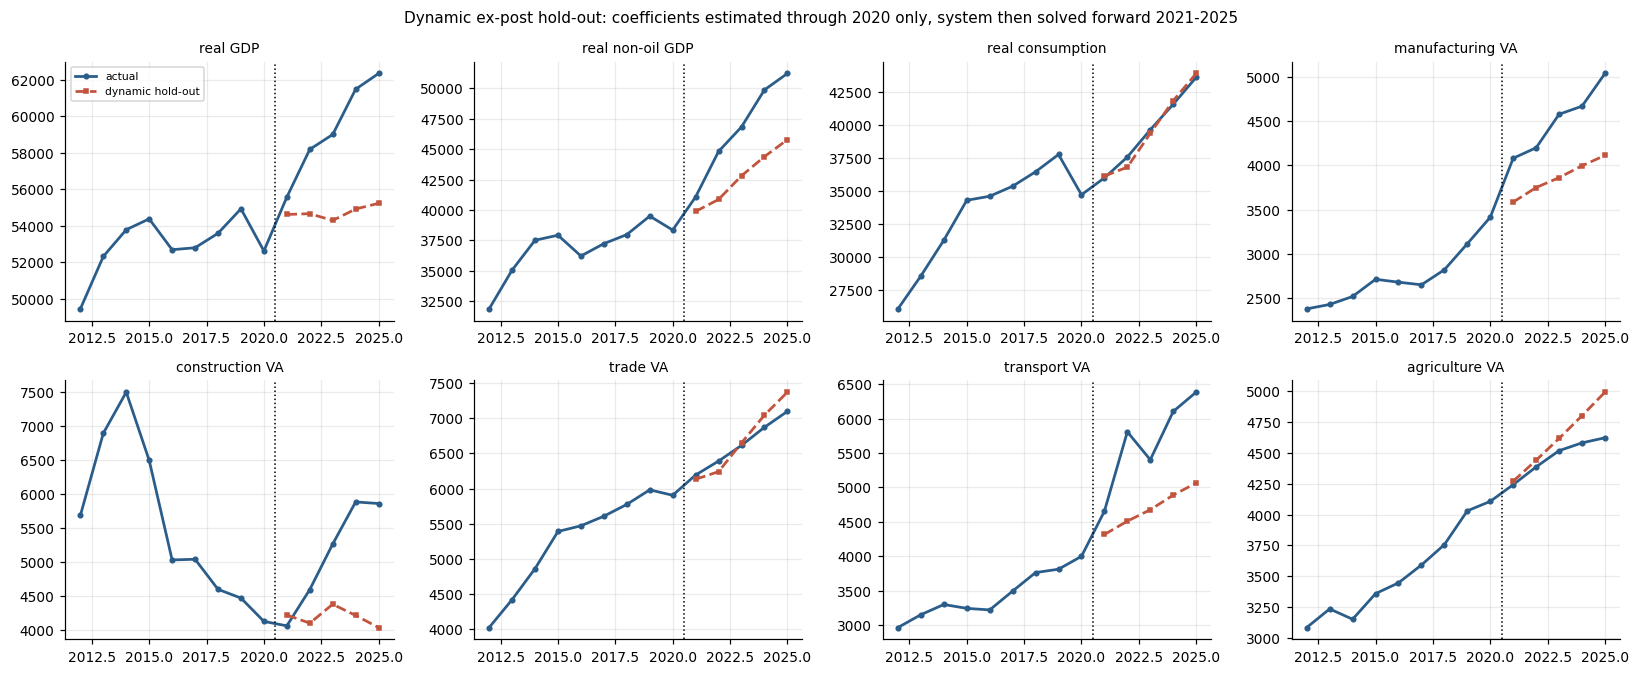

In [44]:
fig, ax = plt.subplots(2, 4, figsize=(15, 6.2))
for i, (k, lbl) in enumerate(list(TARGETS.items())[:8]):
    a = ax[i//4, i%4]
    hist = D[k].loc[2012:LAST_ACT]
    a.plot(hist.index, hist.values, 'o-', color=PAL[0], lw=1.8, ms=3, label='actual')
    a.plot(HO.index, HO[k].values, 's--', color=PAL[1], lw=1.8, ms=3, label='dynamic hold-out')
    a.axvline(CUT+.5, color='k', ls=':', lw=1); a.set_title(lbl, fontsize=9)
    if i == 0: a.legend(fontsize=7)
plt.suptitle(f'Dynamic ex-post hold-out: coefficients estimated through {CUT} only, '
             f'system then solved forward {CUT+1}-{LAST_ACT}', fontsize=10)
plt.tight_layout(); plt.show()

### 11.6 v2.2 — Nazirliyin makro modulundan namizədlər: dinamik nümunədən kənar yoxlama

Hər namizəd ≤2020 məlumatla qiymətləndirilir, v2.2-dən əvvəlki modeldə müvafiq spesifikasiyanın yerinə qoyulur və bütün model 2021–2025-də faktiki ekzogen yollarla dinamik simulyasiya olunur (Hissə 11.5 ilə eyni). Namizəd yalnız onun müəyyən etdiyi dəyişənlərin nümunədən kənar xətası pisləşmədikdə qəbul edilir (Theil U təsadüfi gəzişməyə və sabit artıma qarşı). Nəticə: `FR1_v22_macro_candidates.csv`.


In [45]:
# ==== Part 11.6 (v2.2) — candidates from the Ministry's macro module in the dynamic 2021-2025 hold-out =============
# Every candidate is estimated on data <= CUT only (the same builders as the forecasting model), put into the pre-cut
# model in place of the pre-v2.2 specification, and the whole model is simulated dynamically over 2021-2025 with the
# actual exogenous paths (state investment endogenous via F4) - exactly the hold-out of Part 11.5. A candidate is
# adopted only if the hold-out of the variables it determines is not worse than with the pre-v2.2 specification
# (Theil U against the random walk from 2020 and against constant growth 2010-19).
import copy as _copy

def holdout_variant(cf_over=None, cal_over=None, resid_over=None, eqmap=None, istate_mode='F4'):
    '''Dynamic 2021-2025 simulation of the pre-cut model with some equations / calibrations replaced.'''
    global CF, CAL, EQ_OF_VAR
    keep = (CF, CAL, EQ_OF_VAR)
    cf_ = dict(CF_CUT); cf_.update(cf_over or {})
    cal_ = dict(CAL_CUT); cal_.update(cal_over or {})
    res_ = {nm: m['resid'] for nm, m in MODEL_CUT.items()}; res_.update(resid_over or {})
    CF, CAL = cf_, cal_
    if eqmap is not None: EQ_OF_VAR = eqmap
    try:
        addf = calibrate_addfactors(CUT, resid_of=res_)
        prev, path = state_from_actual(CUT), {}
        for y in range(CUT+1, LAST_ACT+1):
            sol, it, err = solve_year(prev, exog_from_actual(y, istate_mode), addf=addf)
            assert err < 1e-8, (y, err)
            path[y] = dict(sol); prev = dict(sol)
    finally:
        CF, CAL, EQ_OF_VAR = keep
    return pd.DataFrame(path).T

def ho_scores(ho, keys):
    '''RMSE (% level error; pp for rates and ratios), Theil U vs RW from 2020 and vs constant growth 2010-19, 2025 error.'''
    out = {}
    for k in keys:
        act, mod = D[k].loc[YH], ho[k].loc[YH]
        h = np.arange(1, len(YH)+1)
        if k in ('infl', 'nobd_pct', 'bal_gdp'):          # rates: errors in percentage points
            e_m, e_rw, e_cg = mod - act, D[k][CUT] - act, None
        else:
            e_m = (mod/act - 1)*100; e_rw = (D[k][CUT]/act - 1)*100
            cg = D[k][CUT]*((D[k][2019]/D[k][2010])**(1/9))**h
            e_cg = (pd.Series(cg, index=YH)/act - 1)*100 if np.isfinite(D[k][2010]) else None
        r = lambda e: float(np.sqrt(np.nanmean(np.asarray(e, float)**2)))
        out[k] = dict(rmse=r(e_m), U_rw=r(e_m)/r(e_rw), U_cg=(r(e_m)/r(e_cg) if e_cg is not None else np.nan),
                      err_2025=float(np.asarray(e_m)[-1]))
    return pd.DataFrame(out).T

def cut_fit(builder, cut=CUT):
    '''A candidate equation re-estimated on data <= cut, in the solver's coefficient units.'''
    r = builder(D.loc[:cut], {'cut': cut, 'alpha': CTX_CUT['alpha'], 'cred_el': None})
    m = model_form(r)
    return r, m

# ---- the candidates, estimated on data <= CUT
def _with(var, val, fn):
    '''Run fn() with a module switch temporarily set (the builders read the switches at call time).'''
    g = globals(); keep = g[var]; g[var] = val
    try: return fn()
    finally: g[var] = keep
_cut = lambda nm: cut_fit(EQB[nm])
_G5 = {sp: _with('G5MIN_SPEC', sp, lambda: _cut('G5_defl_min')) for sp in ('oil_azn', 'xpi', 'xpi_cpi')}
_D4 = {sp: _with('D4_SPEC', sp, lambda: _cut('D4_mnon')) for sp in ('cons_relprice', 'absorb_reer')}
_LEGS = {md: {nm: _with('E3_MODE', md, lambda nm=nm: _cut(nm)) for nm in E3_LEGS} for md in ('legs', 'legs_real')}
def _g5cal(m):
    cf = dict(CF_CUT); cf['G5_defl_min'] = m['cf']
    return defl_from({k: {'cf': cf[k]} for k in cf if k.startswith('G5_defl')})
_EM_SHARE = {v: e for v, e in EQ_OF_VAR.items() if e not in E3_GROWTH_EQ}; _EM_SHARE['rhhdisp'] = 'E3_hhdisp'
_EM_LEGS = {v: e for v, e in _EM_SHARE.items() if v != 'rhhdisp'}; _EM_LEGS.update(E3_VARMAP)
# v2.3: Part 11.6 is the record of the v2.2 decisions, so D4 and E3 are pinned to their v2.2 specifications here
# (Part 11.7 tests the v2.3 changes against exactly this model)
_E3V22 = _with('E3_SPEC', 'gdp_pens', lambda: _cut('E3_hhdisp'))
_PIN22 = dict(cf={'D4_mnon': _D4['cons_relprice'][1]['cf'], 'E3_hhdisp': _E3V22[1]['cf']},
              res={'D4_mnon': _D4['cons_relprice'][1]['resid'], 'E3_hhdisp': _E3V22[1]['resid']})
PRE22 = dict(cf_over={'G5_defl_min': _G5['oil_azn'][1]['cf'], **_PIN22['cf']},
             resid_over=dict(_PIN22['res']),
             cal_over={'defl': _g5cal(_G5['oil_azn'][1]), 'e3_mode': 'share', 'fiscal_rule': 'F3'}, eqmap=_EM_SHARE)
def _variant(cf=None, cal=None, res=None, eqmap=None):
    v = _copy.deepcopy(PRE22)
    v['cf_over'].update(cf or {}); v['cal_over'].update(cal or {}); v['resid_over'].update(res or {})
    if eqmap is not None: v['eqmap'] = eqmap
    return v
VARIANTS = {
 'pre-v2.2 model': (None, PRE22),
 'E3: income legs (macro module, nominal)': ('E3', _variant(cf={nm: _LEGS['legs'][nm][1]['cf'] for nm in E3_LEGS},
                                                            cal={'e3_mode': 'legs'}, eqmap=_EM_LEGS)),
 'E3: income legs deflated by consumer prices': ('E3', _variant(cf={nm: _LEGS['legs_real'][nm][1]['cf'] for nm in E3_LEGS},
                                                                cal={'e3_mode': 'legs_real'}, eqmap=_EM_LEGS)),
 'G5 mining: export price index + exchange rate (macro module)': ('G5', _variant(cf={'G5_defl_min': _G5['xpi'][1]['cf']},
                                                                                 cal={'defl': _g5cal(_G5['xpi'][1])})),
 'G5 mining: CPI + export price index + exchange rate': ('G5', _variant(cf={'G5_defl_min': _G5['xpi_cpi'][1]['cf']},
                                                                        cal={'defl': _g5cal(_G5['xpi_cpi'][1])})),
 'D4 imports: absorption + REER (macro module)': ('D4', _variant(cf={'D4_mnon': _D4['absorb_reer'][1]['cf']},
                                                                  res={'D4_mnon': _D4['absorb_reer'][1]['resid']})),
 'Fiscal: non-oil balance / non-oil GDP held at the cut year': ('F', _variant(cal={'fiscal_rule': 'nobd'})),
 'v2.2 model (adopted changes)': (None, dict(cf_over=dict(_PIN22['cf']), resid_over=dict(_PIN22['res']), cal_over={}, eqmap=None)),
}
VKEYS = {'E3': ['rhhdisp', 'rcons', 'hhdisp_n'], 'G5': ['p_min', 'gdp_n', 'p_gdp', 'rgdp'],
         'D4': ['rm_non', 'rrev_nonoil', 'rva_nettax'], 'F': ['exp_tot_n', 'rexp_cur', 'bal_gdp', 'nobd_pct']}
D['nobd_pct'] = 100*(D.rev_tot_n - D.rev_oil_n - D.exp_tot_n)/D.gdpnon_n
D['bal_gdp'] = 100*D.balance_n/D.gdp_n
HO22, rows = {}, []
for lbl, (grp, kw) in VARIANTS.items():
    h = holdout_variant(**kw); h['bal_gdp'] = 100*h.balance_n/h.gdp_n; HO22[lbl] = h
    keys = sorted({k for ks in VKEYS.values() for k in ks}) if grp is None else VKEYS[grp]
    sc = ho_scores(h, keys + list(TARGETS))
    for k in keys:
        rows.append(dict(variant=lbl, group=grp or 'all', variable=k, **sc.loc[k].to_dict()))
    rows.append(dict(variant=lbl, group=grp or 'all', variable='median of the 14 Part-11.5 variables',
                     rmse=float(sc.loc[list(TARGETS), 'rmse'].median()), U_rw=float(sc.loc[list(TARGETS), 'U_rw'].median()),
                     U_cg=float(sc.loc[list(TARGETS), 'U_cg'].median()), err_2025=np.nan))
CMP22 = pd.DataFrame(rows)
_pre = CMP22[CMP22.variant == 'pre-v2.2 model'].set_index('variable')
for c in ('rmse', 'U_rw', 'U_cg'): CMP22[f'{c}_pre'] = [float(_pre.loc[v, c]) for v in CMP22.variable]
display(CMP22.round(3))
_V22_ADOPT = {'E3': E3_MODE != 'share', 'G5': G5MIN_SPEC != 'oil_azn', 'D4': D4_SPEC != 'cons_relprice', 'F': FISCAL_RULE != 'F3'}
print("\nDECISIONS (rule: adopt if the hold-out of the variables the candidate determines is not worse than pre-v2.2):")
for lbl, (grp, _) in VARIANTS.items():
    if grp is None: continue
    t = CMP22[(CMP22.variant == lbl)].set_index('variable')
    k0 = VKEYS[grp][0]
    print(f"  {lbl:<64} {k0:<9} U_rw {t.loc[k0, 'U_rw_pre']:.2f} -> {t.loc[k0, 'U_rw']:.2f}, U_cg {t.loc[k0, 'U_cg_pre']:.2f} -> "
          f"{t.loc[k0, 'U_cg']:.2f}; median-14 U_rw {t.loc['median of the 14 Part-11.5 variables', 'U_rw']:.3f}")
print("  switches:", dict(E3_MODE=E3_MODE, G5MIN_SPEC=G5MIN_SPEC, D4_SPEC=D4_SPEC, FISCAL_RULE=FISCAL_RULE))
print(f"  D4 REER coefficient: <= {CUT} {_D4['absorb_reer'][1]['cf'].get('ln_reer', np.nan):+.3f} "
      f"({_D4['absorb_reer'][0]['restriction'] or 'kept'}); full sample: see the registry (FR1.D4_mnon.absorb_reer)")
CMP22.to_csv(OUTDIR/'FR1_v22_macro_candidates.csv', index=False)

def _cmp_extra(lbl):
    '''Hold-out comparison rows of one Part 11.6 variant (pre-v2.2 model vs the variant), for the registry.'''
    t = CMP22[CMP22.variant == lbl]
    return {'holdout_comparison_v22': [{k: (None if isinstance(v, float) and not np.isfinite(v) else v)
                                        for k, v in r.items()} for r in t.drop(columns=['group']).to_dict('records')]}


,variant,group,variable,rmse,U_rw,U_cg,err_2025,rmse_pre,U_rw_pre,U_cg_pre
0,pre-v2.2 model,all,bal_gdp,1.138,0.611,NaN,-2.041,1.138,0.611,NaN
1,pre-v2.2 model,all,exp_tot_n,12.325,0.505,2.702,-7.218,12.325,0.505,2.702
2,pre-v2.2 model,all,gdp_n,25.610,0.640,1.002,-30.730,25.610,0.640,1.002
3,pre-v2.2 model,all,hhdisp_n,16.881,0.645,3.938,-21.815,16.881,0.645,3.938
4,pre-v2.2 model,all,nobd_pct,14.770,1.813,NaN,-11.387,14.770,1.813,NaN
5,pre-v2.2 model,all,p_gdp,19.996,0.615,0.994,-23.346,19.996,0.615,0.994
6,pre-v2.2 model,all,p_min,27.293,0.517,0.633,-30.438,27.293,0.517,0.633
7,pre-v2.2 model,all,rcons,1.806,0.133,0.307,0.948,1.806,0.133,0.307
8,pre-v2.2 model,all,rexp_cur,50.013,1.612,1.335,37.686,50.013,1.612,1.335
9,pre-v2.2 model,all,rgdp,7.299,0.623,0.962,-9.633,7.299,0.623,0.962



DECISIONS (rule: adopt if the hold-out of the variables the candidate determines is not worse than pre-v2.2):
  E3: income legs (macro module, nominal)                          rhhdisp   U_rw 1.27 -> 1.79, U_cg 1.01 -> 1.42; median-14 U_rw 0.565
  E3: income legs deflated by consumer prices                      rhhdisp   U_rw 1.27 -> 1.52, U_cg 1.01 -> 1.21; median-14 U_rw 0.581
  G5 mining: export price index + exchange rate (macro module)     p_min     U_rw 0.52 -> 0.13, U_cg 0.63 -> 0.16; median-14 U_rw 0.591
  G5 mining: CPI + export price index + exchange rate              p_min     U_rw 0.52 -> 0.63, U_cg 0.63 -> 0.78; median-14 U_rw 0.582
  D4 imports: absorption + REER (macro module)                     rm_non    U_rw 0.68 -> 1.31, U_cg 0.45 -> 0.87; median-14 U_rw 0.583
  Fiscal: non-oil balance / non-oil GDP held at the cut year       exp_tot_n U_rw 0.51 -> 0.32, U_cg 2.70 -> 1.72; median-14 U_rw 0.583
  switches: {'E3_MODE': 'share', 'G5MIN_SPEC': 'xpi', 'D4_SPEC': 'usd_vol

### 11.7 v2.3 — son namizədlər: idxalda nisbi qiymət (D4), gəlirdə əmək ödənişləri (E3), fiskal qapanma (F3)

Hissə 11.6 ilə eyni qayda: hər namizəd eyni builder ilə ≤2020 məlumatla qiymətləndirilir, v2.2 modelində müvafiq tənliyin yerinə qoyulur və bütün model 2021–2025-də dinamik simulyasiya olunur. Əhəmiyyətli itki: əsas dəyişənin Theil U-su istinad modelindən 10%-dən çox yüksəkdir. Qərarlar (Hissə 14.1) həm də tam nümunədə işarələri, uyğunluq qaydasını və F3 üçün büdcə balansının ssenarilər üzrə sırasını nəzərə alır. Nəticə: `FR1_v23_candidates.csv`.

In [46]:
# ==== Part 11.7 (v2.3) — final FR1 candidates: D4 relative price, E3 wage bill, F3 fiscal closure ==============
# The Part 11.6 machinery: each candidate is built by the SAME builder on data <= CUT (every restriction and sign
# decision re-made there), put into the pre-cut model, and the whole model is simulated dynamically over 2021-2025
# with the actual exogenous paths (state investment endogenous via F4). Reference = the v2.2 specification of the
# equation concerned. Material loss = Theil U of the candidate's key variable more than 10% above the reference
# (against the random walk from 2020 or constant growth 2010-19). The decisions (Part 14.1) also use the full-sample
# signs, the coherence rule and, for F3, the scenario ordering of the budget balance.
V23_SWITCH = {'D4_mnon': 'D4_SPEC', 'E3_hhdisp': 'E3_SPEC', 'F3_expcur': 'F3_SPEC', 'F4_pubinv': 'F4_SPEC', 'G4_infl': 'G4_SPEC',
              'E2_wage': 'E2_SPEC'}
V22_SPEC = {'D4_mnon': 'cons_relprice', 'E3_hhdisp': 'gdp_pens', 'F3_expcur': 'rev_tot', 'F4_pubinv': 'unit', 'G4_infl': 'fx_wage',
            'E2_wage': 'base'}
V23_ADOPTED = {eq: globals()[sw] for eq, sw in V23_SWITCH.items()}
_C23, _F23 = {}, {}
def v23_cut(eq, spec):
    '''Candidate `spec` of equation `eq` estimated on data <= CUT (cached): (result, solver form).'''
    if (eq, spec) not in _C23: _C23[(eq, spec)] = _with(V23_SWITCH[eq], spec, lambda: cut_fit(EQB[eq]))
    return _C23[(eq, spec)]
def v23_full(eq, spec):
    '''The same candidate on the full sample (cached): (result, solver form).'''
    if (eq, spec) not in _F23:
        r = _with(V23_SWITCH[eq], spec, lambda: EQB[eq](D, CTX_FULL)); _F23[(eq, spec)] = (r, model_form(r))
    return _F23[(eq, spec)]
def v23_incoherent(res):
    '''Coherence rule: the regressors whose level (solver) coefficient lies OUTSIDE the 95% CI of the same equation
    estimated in first differences.'''
    if res.get('diff') is None: return []
    fd = diff_form(*res['diff'])
    if fd is None: return []
    tq = stats.t.ppf(.975, fd.dof); out = []
    for c in fd.names[1:]:
        i = fd.names.index(c); lv = float(res['cf'].get(c, np.nan))
        if np.isfinite(lv) and not (fd.beta[i] - tq*fd.se[i] <= lv <= fd.beta[i] + tq*fd.se[i]): out.append(c)
    return out
def v23_specs(**chg):
    '''Hold-out overrides: every v2.3 equation at its v2.2 specification except those changed in chg.'''
    sp = dict(V22_SPEC); sp.update(chg); cf, rs = {}, {}
    for eq, s in sp.items():
        _, m = v23_cut(eq, s); cf[eq] = m['cf']; rs[eq] = m['resid']
    return dict(cf_over=cf, resid_over=rs)
VARIANTS23 = {
 'v2.2 model (before v2.3)': (None, 'all', {}),
 'D4: imports at constant USD prices (same fit, relative price re-parametrised)': ('D4_mnon', 'D4', {'D4_mnon': 'usd_volume'}),
 'D4: relative price dropped (coefficient bounded at 0, binding)': ('D4_mnon', 'D4', {'D4_mnon': 'cons_norelprice'}),
 'E3: + real wage bill, homogeneity imposed': ('E3_hhdisp', 'E3', {'E3_hhdisp': 'gdp_pens_wb'}),
 'E3: + real wage bill, homogeneity test-and-impose rule': ('E3_hhdisp', 'E3', {'E3_hhdisp': 'gdp_pens_wb_free'}),
 'F3: non-oil and oil revenue separately': ('F3_expcur', 'F3', {'F3_expcur': 'rev_split'}),
 'F3: non-oil revenue only (oil revenue saved)': ('F3_expcur', 'F3', {'F3_expcur': 'rev_non'}),
 'F3: revenue elasticity at its 95% CI lower bound': ('F3_expcur', 'F3', {'F3_expcur': 'rev_cap'}),
 # capital spending: in the scenarios, state investment = the Baseline policy level x the F4 response to real oil revenue
 # relative to the Baseline path (instead of each scenario's own policy growth rate); hold-out: F4 is endogenous anyway
 'F4: scenario capital-spending rule (Baseline policy level + F4 response), unit elasticity': ('F4_pubinv', 'F4', {'F4_pubinv': 'unit'}),
 'F4: scenario capital-spending rule, oil-revenue elasticity at its 95% CI lower bound': ('F4_pubinv', 'F4', {'F4_pubinv': 'cap'}),
 # v2.3.3: exchange-rate pass-through in G4 (lags of regressors only; no lagged inflation)
 'G4: + exchange-rate change of the previous year': ('G4_infl', 'G4', {'G4_infl': 'fx_lag'}),
 'G4: manat import-price inflation (USD import prices + exchange rate)': ('G4_infl', 'G4', {'G4_infl': 'pm_azn'}),
 'G4: manat import-price inflation, current + previous year': ('G4_infl', 'G4', {'G4_infl': 'pm_azn_lag'}),
 'G4: pass-through in the post-2015 floating regime, current + previous year': ('G4_infl', 'G4', {'G4_infl': 'fx_post15_lag'}),
 # v2.3.4: (A) the import-price form with the DSK import-price index spliced in for 2021-2025
 'G4: manat import prices with the DSK index spliced for 2021-25, current + previous year': ('G4_infl', 'G4', {'G4_infl': 'pm_dsk_lag'}),
 # v2.3.6: E2 with a control for the public-pay reforms that coincided with the minimum-wage increases
 'E2: + public-pay reform steps (2019, 2022, 2023)': ('E2_wage', 'E2', {'E2_wage': 'pubref_steps'}),
 'E2: + cumulative public-pay reform index': ('E2_wage', 'E2', {'E2_wage': 'pubref_index'}),
 'E2: minimum-wage elasticity restricted to the state / non-state channels': ('E2_wage', 'E2', {'E2_wage': 'mw_sector'}),
 'v2.3 model (adopted changes)': (None, 'all', dict(V23_ADOPTED)),
}
VKEYS23 = {'D4': ['rm_non', 'rrev_nonoil', 'bal_gdp'], 'E3': ['rhhdisp', 'rcons', 'hhdisp_n'],
           'F3': ['bal_gdp', 'rexp_cur', 'exp_tot_n', 'rinv_state'], 'F4': ['bal_gdp', 'rinv_state', 'exp_tot_n'],
           'G4': ['infl', 'cpi', 'p_gdp', 'rgdpnon', 'rhhdisp'], 'E2': ['wage', 'rhhdisp', 'infl']}
F4RULE23 = {lbl for lbl, v in VARIANTS23.items() if v[1] == 'F4'}     # variants run with the capital-spending rule
HO23, rows = {}, []
for lbl, (eq, grp, chg) in VARIANTS23.items():
    h = holdout_variant(**v23_specs(**chg)); h['bal_gdp'] = 100*h.balance_n/h.gdp_n; HO23[lbl] = h
    keys = sorted({k for ks in VKEYS23.values() for k in ks}) if eq is None else VKEYS23[grp]
    sc = ho_scores(h, keys + list(TARGETS))
    for k in keys:
        rows.append(dict(variant=lbl, group=grp, variable=k, **sc.loc[k].to_dict()))
    rows.append(dict(variant=lbl, group=grp, variable='median of the 14 Part-11.5 variables',
                     rmse=float(sc.loc[list(TARGETS), 'rmse'].median()), U_rw=float(sc.loc[list(TARGETS), 'U_rw'].median()),
                     U_cg=float(sc.loc[list(TARGETS), 'U_cg'].median()), err_2025=np.nan))
CMP23 = pd.DataFrame(rows)
_ref = CMP23[CMP23.variant == 'v2.2 model (before v2.3)'].set_index('variable')
for c in ('rmse', 'U_rw', 'U_cg'): CMP23[f'{c}_v22'] = [float(_ref.loc[v, c]) for v in CMP23.variable]
# the adopted v2.3 model in the hold-out is exactly the Part 11.5 pre-cut model (CF_CUT is built with the adopted switches)
_h0 = holdout_variant(); _h0['bal_gdp'] = 100*_h0.balance_n/_h0.gdp_n
_hv = HO23['v2.3 model (adopted changes)']
assert max(float((_hv[k]/_h0[k] - 1).abs().max()) for k in ('rgdp', 'rhhdisp', 'rm_non', 'balance_n')) < 1e-12
CMP23.to_csv(OUTDIR/'FR1_v23_candidates.csv', index=False)
display(CMP23[CMP23.variable.isin(['rm_non', 'rhhdisp', 'rcons', 'bal_gdp', 'rexp_cur'])].round(3))
# coefficients of every candidate on both samples (the solver's units) and the sign / coherence checks
V23_COEF = []
for lbl, (eq, grp, chg) in VARIANTS23.items():
    if eq is None: continue
    sp = chg[eq]; (rc, mc), (rf, mf) = v23_cut(eq, sp), v23_full(eq, sp)
    V23_COEF.append(dict(variant=lbl, equation=eq, spec=sp, cf_cut=dict(mc['cf']), cf_full=dict(mf['cf']),
                         est_full=dict(zip(rf['fit'].names, rf['fit'].beta)), p_full=dict(zip(rf['fit'].names, rf['fit'].pval)),
                         restriction_cut=rc['restriction'], restriction_full=rf['restriction'],
                         incoherent_full=v23_incoherent(rf), incoherent_cut=v23_incoherent(rc)))
for r in V23_COEF:
    print(f"{r['variant'][:60]:<60} cut {({k: round(v, 3) for k, v in r['cf_cut'].items()})}\n{'':<60} full "
          f"{({k: round(v, 3) for k, v in r['cf_full'].items()})}  outside diff-form CI: {r['incoherent_cut']}/{r['incoherent_full']}")


,variant,group,variable,rmse,U_rw,U_cg,err_2025,rmse_v22,U_rw_v22,U_cg_v22
0,v2.2 model (before v2.3),all,bal_gdp,1.137,0.611,NaN,-1.413,1.137,0.611,NaN
6,v2.2 model (before v2.3),all,rcons,1.944,0.144,0.331,0.619,1.944,0.144,0.331
7,v2.2 model (before v2.3),all,rexp_cur,43.106,1.389,1.151,32.238,43.106,1.389,1.151
9,v2.2 model (before v2.3),all,rhhdisp,8.032,1.236,0.981,10.427,8.032,1.236,0.981
11,v2.2 model (before v2.3),all,rm_non,14.573,0.841,0.558,-18.656,14.573,0.841,0.558
15,"D4: imports at constant USD prices (same fit, ...",D4,rm_non,14.573,0.841,0.558,-18.656,14.573,0.841,0.558
17,"D4: imports at constant USD prices (same fit, ...",D4,bal_gdp,1.137,0.611,NaN,-1.413,1.137,0.611,NaN
19,D4: relative price dropped (coefficient bounde...,D4,rm_non,16.438,0.949,0.630,6.500,14.573,0.841,0.558
21,D4: relative price dropped (coefficient bounde...,D4,bal_gdp,1.835,0.986,NaN,0.504,1.137,0.611,NaN
23,"E3: + real wage bill, homogeneity imposed",E3,rhhdisp,8.219,1.265,1.004,10.013,8.032,1.236,0.981


D4: imports at constant USD prices (same fit, relative price cut {'const': np.float64(-3.265), 'ln_cons': np.float64(0.614), 'ln_inv_non': np.float64(0.287), 'ln_relprice': np.float64(-0.722)}
                                                             full {'const': np.float64(-2.932), 'ln_cons': np.float64(1.047), 'ln_relprice': np.float64(-0.245)}  outside diff-form CI: []/['ln_relprice']
D4: relative price dropped (coefficient bounded at 0, bindin cut {'const': np.float64(-3.095), 'ln_cons': np.float64(1.172)}
                                                             full {'const': np.float64(-0.506), 'ln_cons': np.float64(0.921)}  outside diff-form CI: []/[]
E3: + real wage bill, homogeneity imposed                    cut {'const': np.float64(0.699), 'ln_gdpnon': np.float64(0.69), 'ln_pens_r': np.float64(0.208), 'ln_wagebill_r': np.float64(0.102)}
                                                             full {'const': np.float64(0.14), 'ln_gdpnon': np.float64(0.603), 'ln_p

## Hissə 12 — 2026-cı il üçün ilin əvvəlindən faktiki göstəricilər əsasında cari qiymətləndirmə (nowcast)

2026-cı ilin artıq dörd ayı müşahidə olunub və bu məlumatdan imtina etmək əsassız olardı. Kumulyativ aylıq sütunlar 2026-cı ilin
illik göstəricisi üçün iki müstəqil qiymətləndirici verir:

* **mövsümi pay metodu** — ilin əvvəlindən toplanmış göstərici (YTD) yanvar–aprel dövrünün tam ildəki tarixi orta payına bölünür.
  Son illər üzrə bu payın standart kənarlaşması etibarlılıq ölçüsü kimi göstərilir.
* **illik müqayisə metodu** — keçən ilin illik göstəricisi 2025-ci ilin eyni aylarına nisbətən ilin əvvəlindən artım tempi ilə miqyaslanır.

Dərc olunan **real artım indeksləri** daha faydalı obyektdir, çünki onlar artıq "cari dövr keçən ilin eyni dövrünə nisbətən"
formasında ifadə olunur və il ərzində çox stabil olur. Onlar modelin düzəliş əmsalları vasitəsilə birinci proqnoz ilini lövbərləyir;
beləliklə, 2026-cı il yalnız tənliklərin proqnozlaşdırdığını deyil, faktiki baş verənləri də nəzərə alır.

**Yanvar–apreldən tam ilə.** İş kitabında (Excel faylı) 2021–2025-ci illər üçün ilin əvvəlindən aylıq indekslər mövcuddur, buna görə
yanvar–aprel artımı ilə tam il artımı arasındakı əlaqəni ölçmək mümkündür. 2021-ci il istisna edilir (onun yanvar–aprel artımında
2020-ci ilin baza effekti üstünlük təşkil edir, məsələn, turizm −32,8% / +99,3%). 2022–2025-ci illər üzrə dayanıqlı (Huber)
proporsional körpü qiymətləndirilir və bir ili çıxarmaqla çarpaz yoxlama və HLN düzəlişli Diebold–Mariano testi vasitəsilə 1:1
uyğunlaşdırma ilə müqayisə olunur; körpü yalnız p < 0,10 səviyyəsində üstün gəldikdə istifadə olunur, əks halda 1:1 uyğunlaşdırma
tətbiq edilir. Bu, hər hansı dəyişənin öz keçmişini deyil, *eyni ilin* iki ölçümünü əlaqələndirir.

**Lövbərin təsir müddəti.** Lövbərləmənin tələb etdiyi hər düzəliş əmsalına əlavə artım natamam il məlumatıdır. O, 2026-cı ildə
tam tətbiq olunur, sonra isə yarımparçalanma dövrü bir il olmaqla həndəsi qaydada sönür (ildə 0,5 əmsalı), beləliklə, 2030-cu
ilədək onun yalnız 1/16 hissəsi qalır; tənliklərin öz baza düzəliş əmsallarına bu təsir göstərmir.

In [47]:
def ytd_frame(var):
    y = YTD.get(var)
    if y is None or not len(y): return None
    df = pd.DataFrame({'v': y})
    df['year']  = [i[0] for i in df.index]
    df['month'] = [i[1] for i in df.index]
    return df.pivot_table(index='year', columns='month', values='v')

def nowcast(var, month):
    piv = ytd_frame(var)
    if piv is None or month not in piv.columns or NOWCAST_Y not in piv.index: return None
    cur = piv.loc[NOWCAST_Y, month]
    if not np.isfinite(cur): return None
    full  = A_RAW[var]
    share = (piv[month]/full).dropna(); share = share[share.index < NOWCAST_Y]
    if not len(share): return None
    s3 = share.tail(3).mean()
    prev = piv.loc[LAST_ACT, month] if LAST_ACT in piv.index else np.nan
    return dict(variable=var, month=month, ytd_2026=cur, ytd_2025=prev,
                yoy_pct=(cur/prev-1)*100 if np.isfinite(prev) else np.nan,
                share_method=cur/s3, yoy_method=full[LAST_ACT]*(cur/prev) if np.isfinite(prev) else np.nan,
                actual_2025=full[LAST_ACT], share_3y=s3, share_sd=share.tail(5).std())

NC = pd.DataFrame([r for r in (
    [nowcast(v, 4) for v in ['gdp_n','gdp_nonoil_n','va_ind_n','va_man_n','va_con_n','va_agr_n',
                             'va_trd_n','va_tra_n','inv_tot_n','retail_n','oil_prod','gas_prod','brent']] +
    [nowcast(v, 3) for v in ['rev_tot_n','exp_tot_n','cred_tot_n','tx_tot_usd','tm_tot_usd']]
) if r]).set_index('variable')
display(NC.round(2))

# The real growth indices: already same-period-on-same-period, and very stable within the year
RGI = {'gdp_rgi':'real GDP','gdp_nonoil_rgi':'real non-oil GDP','va_ind_rgi':'industry',
       'va_min_rgi':'mining','gdp_oil_rgi':'oil-gas GDP','va_oth_rgi':'other services',
       'va_wat_rgi':'water','nettax_rgi':'net taxes','va_serv_rgi':'services total',
       'va_goods_rgi':'goods total',
       'va_man_rgi':'manufacturing','va_con_rgi':'construction','va_agr_rgi':'agriculture',
       'va_trd_rgi':'trade','va_tra_rgi':'transport','va_ict_rgi':'ICT','va_tou_rgi':'tourism',
       'va_elc_rgi':'electricity','inv_tot_rgi':'investment','retail_rgi':'retail','cons_mkt_rgi':'consumer market'}
rows = []
for v, lbl in RGI.items():
    piv = ytd_frame(v)
    if piv is None or NOWCAST_Y not in piv.index: continue
    obs = piv.loc[NOWCAST_Y].dropna()
    rows.append(dict(sector=lbl, **{f'M{int(m)}': round(obs[m]-100, 1) for m in obs.index},
                     latest_ytd=round(obs.iloc[-1]-100, 2),
                     full_2025=round(A_RAW[v][LAST_ACT]-100, 2)))
NCG = pd.DataFrame(rows).set_index('sector')
print(f"\n{NOWCAST_Y} year-to-date REAL growth, % on the same period of {LAST_ACT}:")
display(NCG)
NOW_G = NCG.latest_ytd.to_dict()
print(f'''
What the data already say about {NOWCAST_Y}:
   growth is slowing at the aggregate level (GDP {NOW_G.get("real GDP")}% vs {NCG.full_2025.get("real GDP")}% for {LAST_ACT} as a whole),
   but the composition is sharply uneven:
     manufacturing {NOW_G.get("manufacturing"):+.1f}%   ICT {NOW_G.get("ICT"):+.1f}%   transport {NOW_G.get("transport"):+.1f}%   trade {NOW_G.get("trade"):+.1f}%
     construction {NOW_G.get("construction"):+.1f}%  while total investment is {NOW_G.get("investment"):+.1f}%

Two tensions are flagged for the user rather than smoothed away:
  1. Construction contracting sharply while investment rises implies a composition shift out of
     construction works and into equipment - which is largely imported, so it adds less to domestic
     value added per manat spent.
  2. Q1 goods exports and imports are both down heavily in USD, which the trade block will carry through
     to the current account.''')

# ---- the January-April -> full-year bridge, measured on 2021-2025 ------------------------------
br = []
for v in RGI:
    piv = ytd_frame(v)
    if piv is None or 4 not in piv.columns: continue
    for y in piv.index:
        if y < NOWCAST_Y and np.isfinite(piv.loc[y, 4]) and np.isfinite(A_RAW[v].get(y, np.nan)):
            br.append(dict(series=v, year=int(y), g_apr=piv.loc[y, 4]-100, g_full=A_RAW[v][y]-100))
BR = pd.DataFrame(br)
# Bridge estimated on the non-pandemic years only (2021 Jan-Apr growth is dominated by the 2020 base
# effect: tourism -32.8% / +99.3%) and ROBUSTLY (Huber M-estimator through the origin), then compared with
# the 1:1 mapping by leave-one-year-out cross-validation and an HLN-corrected Diebold-Mariano test on the
# pooled out-of-sample errors. It is adopted only if it wins with p < 0.10; otherwise 1:1 is used.
import statsmodels.api as _sm
BRX = BR[BR.year != 2021].reset_index(drop=True)
def _huber_slope(df):
    return float(_sm.RLM(df.g_full.values, df[['g_apr']].values, M=_sm.robust.norms.HuberT()).fit().params[0])
e_b, e_1 = [], []
for y in sorted(BRX.year.unique()):
    tr, te = BRX[BRX.year != y], BRX[BRX.year == y]
    b_ = _huber_slope(tr)
    e_b += list(te.g_full - b_*te.g_apr); e_1 += list(te.g_full - te.g_apr)
e_b, e_1 = np.array(e_b), np.array(e_1)
_d = e_b**2 - e_1**2; _n = len(_d)
BRIDGE_DM = float(_d.mean()/np.sqrt(_d.var()/_n) * np.sqrt((_n - 1)/_n))       # HLN, h = 1
BRIDGE_DM_P = float(stats.t.cdf(BRIDGE_DM, _n - 1))                              # one-sided: bridge better
BRIDGE_SLOPE = _huber_slope(BRX)
BRIDGE_CV = {'1:1 mapping': float(np.sqrt((e_1**2).mean())), 'robust bridge': float(np.sqrt((e_b**2).mean()))}
USE_BRIDGE = bool(BRIDGE_DM < 0 and BRIDGE_DM_P < .10)
BRIDGE_CHOICE = 'robust bridge' if USE_BRIDGE else '1:1 mapping'
print(f"\nJan-Apr -> full-year mapping, {BRX.series.nunique()} series x {BRX.year.nunique()} years 2022-2025 ({len(BRX)} pairs; "
      f"2021 excluded as a base-effect year)")
print(f"   robust (Huber) slope {BRIDGE_SLOPE:.3f}; leave-one-year-out RMSE: bridge {BRIDGE_CV['robust bridge']:.2f} pp, "
      f"1:1 {BRIDGE_CV['1:1 mapping']:.2f} pp; HLN-DM (bridge vs 1:1) = {BRIDGE_DM:+.2f}, one-sided p = {BRIDGE_DM_P:.3f}")
print(f"   -> {BRIDGE_CHOICE} used" + ("" if USE_BRIDGE else " (the bridge does not beat 1:1 at p < 0.10)"))
def full_year_growth(g_ytd):
    return float(BRIDGE_SLOPE*g_ytd) if USE_BRIDGE else float(g_ytd)

# Remaining uncertainty about the full year once January-April is observed: out-of-sample error of the
# chosen mapping relative to the dispersion of full-year growth (2022-25). Scales the 2026 shocks in the fans.
_e = e_b if USE_BRIDGE else e_1
NOWCAST_SCALE = float(min(1.0, np.sqrt((_e**2).mean())/BRX.g_full.std()))
print(f"   remaining full-year uncertainty: RMSE {np.sqrt((_e**2).mean()):.2f} pp vs s.d. of full-year growth "
      f"{BRX.g_full.std():.2f} pp -> 2026 shock scale {NOWCAST_SCALE:.2f}")


,month,ytd_2026,ytd_2025,yoy_pct,share_method,yoy_method,actual_2025,share_3y,share_sd
variable,,,,,,,,,
gdp_n,4,"39,875.100","39,305.800",1.450,"129,357.910","130,963.780","129,094.000",0.310,0.020
gdp_nonoil_n,4,"27,740.100","26,449.500",4.880,"98,029.110","96,811.210","92,307.100",0.280,0.000
va_ind_n,4,"14,224.300","14,646.700",-2.880,"40,224.180","41,357.170","42,585.300",0.350,0.040
va_man_n,4,"2,540.000","2,232.100",13.790,"8,196.070","8,784.340","7,719.500",0.310,0.030
va_con_n,4,"1,937.800","2,322.900",-16.580,"7,338.440","7,029.190","8,426.100",0.260,0.020
va_agr_n,4,"1,407.300","1,302.500",8.050,"8,453.600","8,264.550","7,649.100",0.170,0.010
va_trd_n,4,"4,242.000","3,887.200",9.130,"15,730.200","15,960.100","14,625.200",0.270,0.000
va_tra_n,4,"2,893.200","2,738.200",5.660,"9,765.740","9,621.670","9,106.200",0.300,0.010
inv_tot_n,4,"5,275.000","5,069.300",4.060,"22,923.450","22,087.400","21,226.100",0.230,0.010



2026 year-to-date REAL growth, % on the same period of 2025:


,M1,M2,M3,M4,latest_ytd,full_2025
sector,,,,,,
real GDP,1.700,0.300,-0.300,0.200,0.200,1.400
real non-oil GDP,2.300,1.400,0.200,0.700,0.700,2.700
industry,2.600,0.400,0.200,0.600,0.600,-0.800
mining,2.600,0.300,-0.700,-0.400,-0.400,-2.500
oil-gas GDP,0.600,-1.700,-1.200,-0.900,-0.900,-1.600
other services,1.000,0.800,0.300,0.500,0.500,1.200
water,-5.700,-6.600,-3.100,-0.800,-0.800,2.500
net taxes,0.100,-0.500,-0.500,0.300,0.300,3.300
services total,3.100,2.100,1.800,2.400,2.400,3.100



What the data already say about 2026:
   growth is slowing at the aggregate level (GDP 0.2% vs 1.4% for 2025 as a whole),
   but the composition is sharply uneven:
     manufacturing +6.2%   ICT +9.0%   transport +4.5%   trade +3.7%
     construction -19.0%  while total investment is +14.9%

Two tensions are flagged for the user rather than smoothed away:
  1. Construction contracting sharply while investment rises implies a composition shift out of
     construction works and into equipment - which is largely imported, so it adds less to domestic
     value added per manat spent.
  2. Q1 goods exports and imports are both down heavily in USD, which the trade block will carry through
     to the current account.

Jan-Apr -> full-year mapping, 21 series x 4 years 2022-2025 (84 pairs; 2021 excluded as a base-effect year)
   robust (Huber) slope 0.683; leave-one-year-out RMSE: bridge 3.94 pp, 1:1 6.39 pp; HLN-DM (bridge vs 1:1) = -1.16, one-sided p = 0.126
   -> 1:1 mapping used (the bri

In [48]:
# 2026 add-factors: reconcile the model's first forecast year with the observed YTD real growth.
# An add-factor is a transparent log-additive adjustment, reported here rather than hidden.
ANCHOR = {'rva_man':'manufacturing','rva_con':'construction','rva_agr':'agriculture',
          'rva_trd':'trade','rva_tra':'transport','rva_ict':'ICT','rva_tou':'tourism',
          'rva_elc':'electricity','rcons':'consumer market',
          'rva_min':'mining','rgdpoil':'oil-gas GDP','rva_oth':'other services',
          'rva_wat':'water','rva_nettax':'net taxes'}
# With all twelve GDP components anchored, the model's own chain-linked aggregate for the
# partly-observed year can be checked against the PUBLISHED aggregate index - a genuine
# consistency test of both the anchoring and the aggregator.
NOWCAST_TARGET = {}
for k, lbl in ANCHOR.items():
    if lbl in NOW_G and np.isfinite(NOW_G[lbl]):
        NOWCAST_TARGET[k] = float(D[k][LAST_ACT]*(1 + full_year_growth(NOW_G[lbl])/100))
# Hydrocarbon VOLUMES for the partly-observed year come from the outturn, not from the
# scenario's assumed decline rate: for 2026 the data are better information than an assumption.
# The scenario's decline rates then apply from the following year.
HC_NOWCAST = {}
for v in ['oil_prod','gas_prod']:
    r = nowcast(v, 3)
    if r: HC_NOWCAST[v] = float(r['share_method'])
print(f"{NOWCAST_Y} hydrocarbon volumes implied by year-to-date outturn:")
for v, val in HC_NOWCAST.items():
    print(f"   {v:<10} {val:8.3f}   ({LAST_ACT} actual {D[v][LAST_ACT]:8.3f}, "
          f"implied change {(val/D[v][LAST_ACT]-1)*100:+.2f}%)")
print("   -> these replace the assumed first-year decline; assumptions resume from "
      f"{NOWCAST_Y+1}.\n")

print(f"{NOWCAST_Y} targets implied by year-to-date actuals (2015-price levels, mln AZN):")
display(pd.DataFrame({'2025 actual': {k: D[k][LAST_ACT] for k in NOWCAST_TARGET},
                      'Jan-Apr growth %': {k: NOW_G[ANCHOR[k]] for k in NOWCAST_TARGET},
                      f'{NOWCAST_Y} target': NOWCAST_TARGET,
                      'implied full-year growth %': {k: (NOWCAST_TARGET[k]/D[k][LAST_ACT]-1)*100
                                           for k in NOWCAST_TARGET}}).round(2))

2026 hydrocarbon volumes implied by year-to-date outturn:
   oil_prod     26.374   (2025 actual   27.680, implied change -4.72%)
   gas_prod     50.381   (2025 actual   50.916, implied change -1.05%)
   -> these replace the assumed first-year decline; assumptions resume from 2027.

2026 targets implied by year-to-date actuals (2015-price levels, mln AZN):


,2025 actual,Jan-Apr growth %,2026 target,implied full-year growth %
rva_man,"5,036.160",6.200,"5,348.400",6.200
rva_con,"5,862.440",-19.000,"4,748.580",-19.000
rva_agr,"4,623.350",2.000,"4,715.820",2.000
rva_trd,"7,099.490",3.700,"7,362.170",3.700
rva_tra,"6,383.220",4.500,"6,670.470",4.500
rva_ict,"2,771.430",9.000,"3,020.860",9.000
rva_tou,"2,038.880",2.500,"2,089.850",2.500
rva_elc,877.370,-2.900,851.930,-2.900
rcons,"43,630.560",4.600,"45,637.560",4.600
rva_min,"12,128.200",-0.400,"12,079.680",-0.400


### 12.3 v2.3.3 — 2026-cı il üçün İQİ nowcast-ı (son aylıq məlumat)

FR1-in illik inflyasiyası dekabr/dekabr göstəricisidir. 2026-cı ilin son müşahidə olunan ayının illik (ötən ilin eyni ayına) İQİ artımı iş kitabından və `data/dsk_cpi/` (eləcə də RiskUnit-in DSK vintajı) fayllarından oxunur; qalan aylar üçün ötən ilin aylıq dəyişmələri təkrarlanır (1:1 qaydası). G4-ün düzəliş əmsalı Əsas ssenaridə 2026 inflyasiyası nowcast-a bərabər olacaq şəkildə seçilir və 2027-dən sabit saxlanılır. Yeni aylıq məlumat gələndə nowcast avtomatik yenilənir. Nəticə: `FR1_cpi_nowcast.csv`.

In [49]:
# ==== Part 12.3 (v2.3.3) — 2026 CPI nowcast from the latest monthly CPI (refreshes automatically) =================
# FR1's annual inflation is the December-on-December rate (A.cpi_yoy, the workbook's annual column; e.g. 2024: 4.9%,
# while the 2024 annual average was 2.2%). Sources of monthly y/y CPI, read on every run (nothing is hard-coded):
#   (1) the Ministry workbook, 'Monetar sektoru' row 86 (monthly columns, index form 105.7 = +5.7%),
#   (2) every *.csv in data/dsk_cpi/ and the latest RiskUnit vintage ../RiskUnit/data/vintages/<date>/dsk_cpi.csv
#       (DSK releases, series 'dsk_cpi_yoy', format series,date,value,unit).
# The most recent month of the nowcast year is used. Method for the remaining months (1:1, as for the January-April
# real-sector anchors): the remaining months repeat last year's month-on-month changes, so December y/y = the latest
# y/y. The bridge is checked on 2021-2025 (the months of the latest observation vs December).
import glob as _gl, hashlib as _hl
def cpi_monthly_obs():
    rows = [dict(year=int(k[0]), month=int(k[1]), yoy=float(v) - 100, source='workbook: Monetar sektoru row 86')
            for k, v in YTD['cpi_yoy'].items() if np.isfinite(v)]
    files = sorted(_gl.glob(str(XL.parent/'dsk_cpi'/'*.csv')))
    vint = sorted(_gl.glob(str(XL.parent.parent.parent/'RiskUnit'/'data'/'vintages'/'*'/'dsk_cpi.csv')))
    for f in files + vint[-1:]:
        t = pd.read_csv(f); t = t[t.series == 'dsk_cpi_yoy']
        md5 = _hl.md5(open(f, 'rb').read()).hexdigest()
        for _, r in t.iterrows():
            d = pd.Timestamp(r.date)
            rows.append(dict(year=d.year, month=d.month, yoy=float(r.value), source=f"{f.split('MIIS_Micro_Risk_Policy/')[-1]} (md5 {md5})"))
    return pd.DataFrame(rows)
CPI_OBS = cpi_monthly_obs()
_o = CPI_OBS[CPI_OBS.year == NOWCAST_Y].sort_values(['month', 'source'])
assert len(_o), f"no monthly CPI for {NOWCAST_Y}"
_last = _o[_o.month == _o.month.max()]
assert _last.yoy.max() - _last.yoy.min() < 0.05, f"sources disagree on the latest month: {_last.to_dict('records')}"
_last = _last.iloc[-1]
_wb = CPI_OBS[CPI_OBS.source.str.startswith('workbook')]
_br = []
for _y in range(2021, LAST_ACT + 1):                          # bridge check: latest-month y/y vs December y/y
    _m = _wb[(_wb.year == _y) & (_wb.month == int(_last.month))]
    if len(_m): _br.append(dict(year=_y, yoy_month=float(_m.yoy.iloc[0]), december=float(D.infl[_y])))
_br = pd.DataFrame(_br); _br['error_pp'] = _br.december - _br.yoy_month
CPI_NOWCAST = dict(year=NOWCAST_Y, month=int(_last.month), yoy_latest=float(_last.yoy), source=_last.source,
                   infl_2026=float(_last.yoy), method='1:1 - remaining months repeat last year\'s month-on-month changes',
                   bridge_years=f"{int(_br.year.min())}-{int(_br.year.max())}", bridge_rmse_pp=float(np.sqrt((_br.error_pp**2).mean())),
                   bridge_bias_pp=float(_br.error_pp.mean()), n_sources=int(CPI_OBS.source.nunique()))
pd.DataFrame([CPI_NOWCAST]).to_csv(OUTDIR/'FR1_cpi_nowcast.csv', index=False)
NOWCAST_RATE = {'infl': CPI_NOWCAST['infl_2026']}      # partial-year RATE targets (additive increments, decaying like levels)
print(f"{NOWCAST_Y} CPI nowcast: latest monthly y/y = {CPI_NOWCAST['yoy_latest']:+.1f}% (month {CPI_NOWCAST['month']}, {CPI_NOWCAST['source']})")
print(f"   -> December {NOWCAST_Y} y/y (FR1's annual inflation) = {CPI_NOWCAST['infl_2026']:+.2f}%; bridge check {CPI_NOWCAST['bridge_years']}: "
      f"RMSE {CPI_NOWCAST['bridge_rmse_pp']:.2f} pp, mean error {CPI_NOWCAST['bridge_bias_pp']:+.2f} pp")
display(_br.round(2))


2026 CPI nowcast: latest monthly y/y = +5.7% (month 8, RiskUnit/data/vintages/2026-10-06/dsk_cpi.csv (md5 0aa9697180e47e9d99f9b7ce186472ab))
   -> December 2026 y/y (FR1's annual inflation) = +5.70%; bridge check 2021-2025: RMSE 3.61 pp, mean error +0.26 pp


,year,yoy_month,december,error_pp
0,2021,6.700,12.000,5.300
1,2022,14.200,14.400,0.200
2,2023,8.000,2.100,-5.900
3,2024,3.500,4.900,1.400
4,2025,4.900,5.200,0.300


In [50]:
# ==== Part 12.4 (v2.3.4) — 2026 public-debt anchor from the latest Ministry of Finance stock (refreshes automatically) ===
# Sources read on every run: every *.json in data/minfin_debt/ and the latest RiskUnit vintage
# ../RiskUnit/data/vintages/minfin/<date>/debt_parsed.json (fields date, total_azn = external + domestic public debt).
# End-of-year 2026 debt = the latest observed stock - the model's 2026 budget balance x (remaining months / 12), i.e. the
# rest of the year adds the pro-rata budget balance; the gap to the stock-flow identity is a one-off 2026 stock-flow
# adjustment DEBT_SFA26 (set in Part 13.1, after the 2026 balance is known), held at zero from 2027.
import json as _js, glob as _gl2, hashlib as _hl2
def debt_obs():
    files = sorted(_gl2.glob(str(XL.parent/'minfin_debt'/'*.json')))
    vint = sorted(_gl2.glob(str(XL.parent.parent.parent/'RiskUnit'/'data'/'vintages'/'minfin'/'*'/'debt_parsed.json')))
    rows = []
    for f in files + vint[-1:]:
        j = _js.load(open(f, encoding='utf-8')); md5 = _hl2.md5(open(f, 'rb').read()).hexdigest()
        rows.append(dict(date=pd.Timestamp(j['date']), total_azn=float(j['total_azn']), ext_usd=float(j.get('ext_usd', np.nan)),
                         dom_azn=float(j.get('dom_azn', np.nan)), source=f"{f.split('MIIS_Micro_Risk_Policy/')[-1]} (md5 {md5})"))
    return pd.DataFrame(rows)
DEBT_OBS = debt_obs()
_d = DEBT_OBS[DEBT_OBS.date.dt.year == NOWCAST_Y].sort_values('date')
DEBT_NOWCAST = None
if len(_d):
    _l = _d.iloc[-1]
    _months_done = (_l.date.month - 1) + (_l.date.day - 1)/31            # stock date 01.07 -> 6 months of the year done
    DEBT_NOWCAST = dict(date=str(_l.date.date()), stock_azn=float(_l.total_azn), months_done=float(_months_done),
                        remaining_share=float(1 - _months_done/12), debt_2025=float(D.debt_azn[LAST_ACT]),
                        change_since_2025_pct=float((_l.total_azn/D.debt_azn[LAST_ACT] - 1)*100), source=_l.source,
                        method='end-2026 = observed stock - 2026 budget balance x remaining months / 12; one-off stock-flow adjustment')
    print(f"{NOWCAST_Y} public-debt anchor: {DEBT_NOWCAST['stock_azn']:,.1f} mln AZN on {DEBT_NOWCAST['date']} "
          f"({DEBT_NOWCAST['change_since_2025_pct']:+.1f}% vs end-{LAST_ACT} {DEBT_NOWCAST['debt_2025']:,.1f}); {DEBT_NOWCAST['source']}")
else:
    print(f"no {NOWCAST_Y} public-debt observation - the identity alone is used")


2026 public-debt anchor: 23,830.6 mln AZN on 2026-07-01 (-8.3% vs end-2025 25,987.5); RiskUnit/data/vintages/minfin/2026-10-07/debt_parsed.json (md5 8b9a2466f2af25495b214b9e727b29a4)


## Hissə 13 — Ssenarilər və 2026–2030-cu illər üçün proqnoz

### 13.1 Proqnozun quruluşu etibarilə ssenaridən asılı olmasının səbəbi

Karbohidrogenlər ekzogen olduğundan, bu iqtisadiyyat üçün şərtsiz proqnoz anlayışı mövcud deyil. Bu, struktur yanaşmanın
məhdudiyyəti deyil, xüsusiyyətidir: o, fərziyyələri açıq şəkildə ortaya qoymağa məcbur edir və onlar müzakirə oluna bilir.

Hər ssenari müşahidə olunan 2025-ci il başlanğıc nöqtəsinə kalibrlənmiş ekzogen trayektoriyaların tam toplusudur. Əhali
2021–2025-ci illərin orta tempi ilə artır (kodda hesablanır), neft sektoruna investisiya neft hasilatı trayektoriyasına uyğun
dəyişir, pensiyalar isə İQİ-yə indeksləşdirilir:
Brent 69,1 USD/barel, neft hasilatı 27,68 mln ton (2019-cu ildən bəri illik −4,9%), qaz hasilatı 50,92 mlrd m³ (2025-ci ildə
artım artıq +1,0%-ə qədər azalıb, yəni plato), məzənnə 1,70, uçot dərəcəsi 6,75%.

| Amil | Əsas | Mənfi | İslahat |
|---|---|---|---|
| Brent, 2030-cu ilədək | ~66 USD/barel | ~48 USD/barel | ~80 USD/barel |
| Neft hasilatı | illik −4.5%, azalma tempi zəifləyir | illik −6.5% | illik −3.0% |
| Qaz hasilatı | illik +1.0% (plato) | dəyişməz | illik +4.0% (Abşeron, yeni güclər) |
| Qazın ixrac qiyməti | tədricən 300 USD/min m³ səviyyəsinə doğru dəyişir | 230 | 380 |
| Dövlət investisiyası (real), siyasət səviyyəsi | illik +1.5% | illik −4% | illik +5% |
| Uçot dərəcəsi | 6.0%-ə qədər yumşaldılır | 8.5%-ə qədər sərtləşdirilir | 6.0% |
| Məzənnə | 1.70 (sabit məzənnə saxlanılır) | 1.70 (sabit məzənnə saxlanılır, gərginlik qeyd olunur) | 1.70 |
| Xarici tələb | illik +3% | illik +0.5% | illik +5% |
| Qeyri-neft TFP | tarixi trend | tarixi trend | 2027-ci ildən təklif tərəfi sektorlarında (agr, man, elc, wat, tra, ict) ildə +0.4 loqarifmik bənd; turizm və digər xidmətlər tələbdən asılı tənliklərdir və heç bir əlavə almır |

**Dövlət investisiyası haqqında.** O, burada **siyasət səviyyəsi** kimi müəyyən edilir (yuxarıdakı sətir), neft gəlirlərinin hər
ssenarinin öz istinad trayektoriyasından *kənarlaşmaları* isə onu F4 tənliyində qiymətləndirilmiş elastikliklə dəyişdirir. Bu
ayrılma qəsdən edilib. Qiymətləndirilmiş resurs qaydasının neft hasilatının azaldığı üfüq üzrə mexaniki tətbiqi 2030-cu ilədək
real dövlət investisiyasını təxminən 30% azaldır və ÜDM-in təxminən 3%-i həcmində profisit yaradır — bu, neytral əsas ssenari
deyil, prosiklik qənaət siyasətinin proyeksiyasıdır və suveren sərvət fonduna malik ölkədən gözlənilən davranış deyil.
Səviyyənin siyasət kimi müəyyən edilməsi fərziyyəni görünən və müzakirə edilə bilən saxlayır, eyni zamanda Hissə 14-dəki
multiplikator təcrübələri üçün neft qiymətinin ötürülmə kanalını tam həcmdə qoruyur.

In [51]:
FY = list(range(NOWCAST_Y, H_END+1))
# Population: the 2021-2025 average growth rate, computed from the data (not assumed). The same
# rate is used by FR4 and FR5, which read the `pop` column (thousand persons) of FR1_forecast_full.csv.
POP_G = float((POP[LAST_ACT]/POP[LAST_ACT-5])**(1/5) - 1)
print(f"population growth assumption: {POP_G*100:.3f}% p.a. (2021-2025 average, from GDP / GDP per capita)")
# v2.2: the State Investment Programme's share of real state investment in the last actual year (Part 3.6)
SIP_SHARE25 = float(SIP[LAST_ACT]/D.p_inv[LAST_ACT]/D.rinv_state[LAST_ACT])

def build_scenario(name, brent_path, oil_g, gas_g, gasprice_path, istate_g, polrate_path,
                   extdem_g, fx_path, tfp_boost=0.0, minwage_g=None, deprate_path=None,
                   sip_2026=None, p_inv26=None, dsmf_add_g=0.0, pm_usd_g=0.0):
    '''Assemble a full set of exogenous paths for the forecast years.
    v2.2: 2026 real state investment = the non-programme part of the 2025 level grown at the scenario rate + the
    approved 2026 State Investment Programme (nominal) at the 2026 investment deflator p_inv26 (a fixed point found
    in Part 13.1); from 2027 the whole level grows at the scenario rate. `sip_ratio` scales nominal state investment
    to the programme so that its 2026 value equals the approved figure.'''
    ex = {}
    last = {k: float(D[k][LAST_ACT]) for k in
            ['oil_prod','gas_prod','rinv_state','rinv_oil','minwage','fx','npl_ratio',
             'dollarization','oil_exp_vol','gas_exp_vol']}
    oil, gas, mw = last['oil_prod'], last['gas_prod'], last['minwage']
    sip_2026 = SIP_2026_PLAN if sip_2026 is None else sip_2026
    p_inv26 = float(D.p_inv[LAST_ACT]*(1 + D.infl[LAST_ACT]/100)) if p_inv26 is None else p_inv26
    istate = last['rinv_state']              # policy LEVEL for real public investment
    deprate_path = deprate_path or [float(D.deprate[LAST_ACT])]*len(FY)
    pop = float(POP[LAST_ACT]); fx_prev = float(D.fx[LAST_ACT])
    brent_prev = float(D.brent[LAST_ACT])
    dlfx_prev, dlpm_prev = float(D.dln_fx[LAST_ACT]), float(D.dln_pm_azn[LAST_ACT])      # v2.3.3
    dlpd_prev = float(D.dln_pm_dsk[LAST_ACT])                                             # v2.3.4
    for i, y in enumerate(FY):
        if i == 0 and HC_NOWCAST:                 # first year: use the observed outturn
            oil = HC_NOWCAST.get('oil_prod', oil*(1 + oil_g[0]))
            gas = HC_NOWCAST.get('gas_prod', gas*(1 + gas_g[0]))
        else:
            oil *= (1 + oil_g[i]); gas *= (1 + gas_g[i])
        if i == 0:
            istate = istate*(1 - SIP_SHARE25)*(1 + istate_g[0]) + sip_2026/p_inv26
            sip_ratio = (sip_2026/p_inv26)/istate
        else:
            istate *= (1 + istate_g[i])
        # minimum wage: legal level in the first year, then the shared scenario rate (minwage_g overrides)
        mw = MW_FIRST if i == 0 else mw*(1 + (MW_G[name] if minwage_g is None else minwage_g))
        pop    *= (1 + POP_G)                            # 2021-25 average growth, computed above
        fx     = fx_path[i]; br = brent_path[i]
        ex[y] = dict(brent=br, oil_prod=oil, gas_prod=gas,
                     oil_exp_vol=oil*CAL['oil_exp_ratio'], gas_exp_vol=gas*CAL['gas_exp_ratio'],
                     gas_exp_price=gasprice_path[i], pop=pop, fx=fx, polrate=polrate_path[i],
                     deprate=deprate_path[i], istate_level=istate, istate_add=0.0,
                     oilrev_ref=None, istate_mode='policy',
                     # oil-sector investment moves with the oil-output path, compounded year on year
                     rinv_oil=last['rinv_oil']*oil/last['oil_prod'],
                     npl_ratio=last['npl_ratio'], dollarization=last['dollarization'],
                     minwage=mw, dln_fx=(np.log(fx)-np.log(fx_prev))*100,
                     dln_oil_azn=(np.log(br*fx)-np.log(brent_prev*fx_prev))*100,
                     trend=float(y-2000), extdem=(1+extdem_g)**(i+1), tfp_boost=tfp_boost,
                     tfp_years=float(y-NOWCAST_Y), pension=None, pension_real_g=0.0, pens_real_cum=1.0,
                     # v2.2: REER held at its last actual value (enters only if D4_SPEC = 'absorb_reer'); extra DSMF
                     # spending growth over the pension bridge; programme scaling of nominal state investment
                     reer=float(D.reer[LAST_ACT]), dsmf_add_g=dsmf_add_g, sip_ratio=sip_ratio,
                     # v2.3.3: previous year's FX change and manat import-price inflation (regressor lags), USD
                     # import-price inflation (assumption; used only by the import-price G4 forms)
                     dln_fx_L1=dlfx_prev, pm_usd_infl=pm_usd_g, dln_pm_azn_L1=dlpm_prev,
                     pm_dsk_infl=pm_usd_g, dln_pm_dsk_L1=dlpd_prev,
                     # 2026 public-debt anchor (Part 12.4): observed stock and the remaining share of the year
                     debt_stock_obs=(DEBT_NOWCAST['stock_azn'] if (DEBT_NOWCAST and y == NOWCAST_Y) else None),
                     debt_rem_share=(DEBT_NOWCAST['remaining_share'] if (DEBT_NOWCAST and y == NOWCAST_Y) else None),
                     # decided pension indexation of the year, if any (data/dsmf_pension/pension_indexation.csv)
                     pension_index_pct=PENS_INDEX.get(y))
        dlfx_prev = (np.log(fx)-np.log(fx_prev))*100
        dlpm_prev = np.log(1 + pm_usd_g/100)*100 + dlfx_prev
        dlpd_prev = dlpm_prev
        fx_prev, brent_prev = fx, br
    return ex

n = len(FY)
# v2.2 hydrocarbon output. Baseline = the Ministry's official plan growth rates (8_vereq_original.xlsx, 2.4.1.4;
# Part 3.6) applied to the 2026 level implied by the January-March outturn (the plan's own 2026 level is not used:
# the plan over-stated 2025 oil output by 2.8%). Adverse = the pre-v2.2 Baseline decline profile for oil (the plan's
# 2029 recovery does not happen) and plan - 1 pp for gas; Reform = plan + the pre-v2.2 Reform-Baseline gaps
# (oil +1.5 -> 0 pp, gas +3 pp).
_PLAN_OIL, _PLAN_GAS = [float(v) for v in OILGAS_PLAN_G.oil_prod][:n], [float(v) for v in OILGAS_PLAN_G.gas_prod][:n]
_PRE22_OIL = [-.045, -.042, -.038, -.035, -.030][:n]                    # pre-v2.2 Baseline oil profile
SCEN_ARGS = {
 'Baseline': dict(brent_path=[68., 66., 65., 65., 66.][:n], oil_g=_PLAN_OIL, gas_g=_PLAN_GAS,
    gasprice_path=[340., 325., 312., 305., 300.][:n],
    istate_g=[.015]*n, polrate_path=[6.5, 6.25, 6.0, 6.0, 6.0][:n],
    deprate_path=[9.2, 9.0, 8.8, 8.8, 8.8][:n], extdem_g=.03, fx_path=[1.70]*n),
 'Adverse': dict(brent_path=[60., 52., 48., 48., 48.][:n], oil_g=_PRE22_OIL, gas_g=[g - .01 for g in _PLAN_GAS],
    gasprice_path=[300., 260., 235., 230., 230.][:n], istate_g=[-.04]*n,
    polrate_path=[7.5, 8.5, 8.5, 8.0, 7.5][:n],
    deprate_path=[10.0, 11.0, 11.0, 10.5, 10.0][:n], extdem_g=.005, fx_path=[1.70]*n),
 'Reform': dict(brent_path=[70., 74., 77., 79., 80.][:n],
    oil_g=[g + d for g, d in zip(_PLAN_OIL, [.015, .012, .008, .005, .0])], gas_g=[g + .03 for g in _PLAN_GAS],
    gasprice_path=[350., 360., 370., 375., 380.][:n], istate_g=[.05]*n,
    polrate_path=[6.25, 6.0, 6.0, 6.0, 6.0][:n], extdem_g=.05, fx_path=[1.70]*n,
    tfp_boost=.004),
}
SCEN_PINV26 = {nm: None for nm in SCEN_ARGS}          # replaced by the fixed point in Part 13.1
SCEN = {nm: build_scenario(nm, **a, p_inv26=SCEN_PINV26[nm]) for nm, a in SCEN_ARGS.items()}

def scenario_table():
    rows = []
    for nm, ex in SCEN.items():
        for y in FY:
            rows.append(dict(scenario=nm, year=y, brent=ex[y]['brent'], oil_mt=ex[y]['oil_prod'],
                             gas_bcm=ex[y]['gas_prod'], gas_price=ex[y]['gas_exp_price'],
                             state_inv_policy=ex[y]['istate_level'], polrate=ex[y]['polrate'],
                             deprate=ex[y]['deprate'],
                             pop_thou=ex[y]['pop'], extdem=ex[y]['extdem'], rinv_oil=ex[y]['rinv_oil'],
                             tfp_boost_cum=ex[y]['tfp_boost']*ex[y]['tfp_years']))
    return pd.DataFrame(rows).set_index(['scenario','year'])
SCT = scenario_table()
display(SCT.round(2))
print(f"starting point {LAST_ACT}: Brent {D.brent[LAST_ACT]:.1f}, oil {D.oil_prod[LAST_ACT]:.2f} mt, "
      f"gas {D.gas_prod[LAST_ACT]:.2f} bcm, gas price {D.gas_exp_price[LAST_ACT]:.0f} USD/kcm")
print(f"v2.2 oil output 2030, mt: Baseline (plan growth) {SCEN['Baseline'][H_END]['oil_prod']:.2f}, Adverse "
      f"{SCEN['Adverse'][H_END]['oil_prod']:.2f}, Reform {SCEN['Reform'][H_END]['oil_prod']:.2f}; plan level "
      f"{OILGAS_PLAN.oil_prod[H_END]:.2f}")


population growth assumption: 0.483% p.a. (2021-2025 average, from GDP / GDP per capita)


brent  oil_mt  gas_bcm  gas_price  state_inv_policy  polrate  deprate   pop_thou  extdem  rinv_oil  tfp_boost_cum
scenario year                                                                                                                   
Baseline 2026 68.000  26.370   50.380    340.000         7,275.030    6.500    9.200 10,293.230   1.030 3,165.460          0.000
         2027 66.000  25.830   49.850    325.000         7,384.150    6.250    9.000 10,342.920   1.060 3,100.040          0.000
         2028 65.000  25.380   47.500    312.000         7,494.910    6.000    8.800 10,392.860   1.090 3,045.610          0.000
         2029 65.000  26.140   49.990    305.000         7,607.340    6.000    8.800 10,443.040   1.130 3,137.070          0.000
         2030 66.000  26.030   49.980    300.000         7,721.450    6.000    8.800 10,493.460   1.160 3,124.620          0.000
Adverse  2026 60.000  26.370   50.380    300.000         6,967.340    7.500   10.000 10,293.230   1.000 3,165.460          0.000
         2027 52.000  25.270   49.340    260.000         6,688.650    8.500   11.000 10,342.920   1.010 3,032.510          0.000
         2028 48.000  24.310   46.530    235.000         6,421.100    8.500   11.000 10,392.860   1.020 2,917.280          0.000
         2029 48.000  23.460   48.500    230.000         6,164.260    8.000   10.500 10,443.040   1.020 2,815.170          0.000
         2030 48.000  22.750   48.010    230.000         5,917.690    7.500   10.000 10,493.460   1.030 2,730.720          0.000
Reform   2026 70.000  26.370   50.380    350.000         7,470.830    6.250    9.360 10,293.230   1.050 3,165.460          0.000
         2027 74.000  26.150   51.360    360.000         7,844.370    6.000    9.360 10,342.920   1.100 3,138.030          0.000
         2028 77.000  25.900   50.480    370.000         8,236.580    6.000    9.360 10,392.860   1.160 3,108.030          0.010
         2029 79.000  26.800   54.640    375.000         8,648.410    6.000    9.360 10,443.040   1.220 3,216.910          0.010
         2030 80.000  26.700   56.270    380.000         9,080.830    6.000    9.360 10,493.460   1.280 3,204.150          0.020

starting point 2025: Brent 69.1, oil 27.68 mt, gas 50.92 bcm, gas price 350 USD/kcm
v2.2 oil output 2030, mt: Baseline (plan growth) 26.03, Adverse 22.75, Reform 26.70; plan level 27.28


In [52]:
def run_forecast(ex_path, anchor=True, addf_extra=None, cf=None, cal=None, oilrev_ref=None,
                 addf_fixed=None, base_decay=None, base_addf=None):
    '''Solve the system forward over the scenario horizon; returns (forecast, convergence,
    per-year add-factor path, oil-revenue reference path).
    Add-factors: each equation's base add-factor (own residual in 2025) is held constant (or,
    in the sensitivity, decays by a FIXED factor per year via `base_decay`, v2.3); the INCREMENT required
    to hit the 2026 year-to-date anchors applies fully in 2026 and decays by ANCHOR_DECAY per year.
    `addf_fixed` (a per-year path) makes a shock run reuse the baseline's add-factors exactly.'''
    global CF, CAL
    keep_cf, keep_cal = CF, CAL
    if cf is not None:  CF = cf
    if cal is not None: CAL = cal
    try:
        prev = state_from_actual(LAST_ACT)
        if addf_fixed is not None:
            path = {y: dict(addf_fixed[y]) for y in FY}
        else:
            base = dict(BASE_ADDF if base_addf is None else base_addf)
            if addf_extra: base.update({k: base.get(k, 0.0)+v for k, v in addf_extra.items()})
            def base_y(y):
                if base_decay is None: return dict(base)
                return {k: v*base_decay.get(k, 1.0)**(y-LAST_ACT) for k, v in base.items()}
            inc = {}
            if anchor:
                # iterate the anchoring: the system is simultaneous, so one step does not hit the targets
                for _ in range(20):
                    a0 = base_y(NOWCAST_Y)
                    for k, v in inc.items(): a0[k] = a0.get(k, 0.0) + v
                    sol0, _, _ = solve_year(prev, ex_path[NOWCAST_Y], addf=a0)
                    worst = 0.0
                    for k, tgt in NOWCAST_TARGET.items():
                        if k in sol0 and sol0[k] > 0:
                            d = np.log(tgt/sol0[k]); inc[k] = inc.get(k, 0.0) + 0.7*d
                            worst = max(worst, abs(d))
                    for k, tgt in globals().get('NOWCAST_RATE', {}).items():   # v2.3.4: rates, additive (pp)
                        d = tgt - sol0[k]; inc[k] = inc.get(k, 0.0) + 0.7*d; worst = max(worst, abs(d)/100)
                    if worst < 1e-8: break
            path = {}
            for y in FY:
                a = base_y(y)
                for k, v in inc.items(): a[k] = a.get(k, 0.0) + v*ANCHOR_DECAY**(y-NOWCAST_Y)
                path[y] = a
        # pass 1 (only when no reference is supplied): public investment follows the policy
        # level, and the resulting real oil revenue becomes this scenario's reference path
        if oilrev_ref is None:
            p2, out2 = dict(prev), {}
            for y in FY:
                s2, _, _ = solve_year(p2, ex_path[y], addf=path[y])
                out2[y] = s2; p2 = dict(s2)
            ref = {y: out2[y]['rev_oil_n']/out2[y]['p_gdp'] for y in FY}
        else:
            ref = oilrev_ref
        for y in FY: ex_path[y]['oilrev_ref'] = ref[y]
        out, conv = {}, {}
        for y in FY:
            sol, it, err = solve_year(prev, ex_path[y], addf=path[y])
            out[y] = dict(sol); conv[y] = (it, err); prev = dict(sol)
        return pd.DataFrame(out).T, conv, path, ref
    finally:
        CF, CAL = keep_cf, keep_cal

# v2.2: the approved 2026 State Investment Programme (nominal) enters the 2026 policy level of real state investment
# at the model's own 2026 investment deflator. p_inv(2026) hardly depends on state investment (2026 is anchored on
# the January-April data), so the fixed point converges in a few rounds.
for _it in range(12):
    _pinv = {nm: float(run_forecast({y: dict(SCEN[nm][y]) for y in FY})[0].p_inv[NOWCAST_Y]) for nm in SCEN}
    _chg = max(abs(_pinv[nm]/(SCEN_PINV26[nm] or 1e9) - 1) for nm in SCEN)
    SCEN_PINV26 = _pinv
    SCEN = {nm: build_scenario(nm, **a, p_inv26=SCEN_PINV26[nm]) for nm, a in SCEN_ARGS.items()}
    if _chg < 1e-13: break
SCT = scenario_table()
print(f"State Investment Programme fixed point: {_it+1} rounds; 2026 investment deflator "
      f"{ {nm: round(v, 6) for nm, v in SCEN_PINV26.items()} }; programme {SIP_2026_PLAN:,.0f} mln AZN = "
      f"{SIP_2026_PLAN/SCEN_PINV26['Baseline']:,.1f} mln AZN at 2015 prices; Baseline real state investment 2026 "
      f"{SCEN['Baseline'][NOWCAST_Y]['istate_level']:,.1f} ({(SCEN['Baseline'][NOWCAST_Y]['istate_level']/D.rinv_state[LAST_ACT]-1)*100:+.2f}%)")
# v2.3.4: the 2026 CPI anchor is a partial-year INCREMENT inside run_forecast (NOWCAST_RATE, Part 12.3): G4's base
# add-factor stays its 2025 residual; the increment applies fully in 2026 and decays like the real-sector increments.
CPI_SHIFT = 0.0
# 2026 public-debt anchor (Part 12.4), applied INSIDE the solver in every run (scenarios, shocks, engine): end-2026 debt =
# observed mid-year stock - remaining share of the year x that run's 2026 budget balance. Reported here for the Baseline
# (the implied stock-flow adjustment differs by run because only the second-half balance moves debt).
if DEBT_NOWCAST:
    _fb26 = run_forecast({y: dict(SCEN['Baseline'][y]) for y in FY})[0]
    _bal26 = float(_fb26.balance_n[NOWCAST_Y])
    DEBT_NOWCAST['target_2026'] = DEBT_NOWCAST['stock_azn'] - _bal26*DEBT_NOWCAST['remaining_share']
    assert abs(float(_fb26.debt_azn[NOWCAST_Y]) - DEBT_NOWCAST['target_2026']) < 1e-6
    DEBT_SFA26 = DEBT_NOWCAST['target_2026'] - (float(D.debt_azn[LAST_ACT]) - _bal26)
    DEBT_NOWCAST.update(balance_2026=_bal26, sfa_2026=DEBT_SFA26)
    pd.DataFrame([DEBT_NOWCAST]).to_csv(OUTDIR/'FR1_debt_nowcast.csv', index=False)
    print(f"2026 debt anchor: end-2026 target {DEBT_NOWCAST['target_2026']:,.1f} mln AZN; one-off stock-flow adjustment "
          f"{DEBT_SFA26:+,.1f} (identity alone: {float(D.debt_azn[LAST_ACT]) - _bal26:,.1f})")
SCT = scenario_table()

FC, CONV, ADDF, OILREF = {}, {}, {}, {}
for nm, ex in SCEN.items():
    FC[nm], CONV[nm], ADDF[nm], OILREF[nm] = run_forecast(ex)
    print(f"{nm:<9} solved; iterations by year: "
          f"{ {y: CONV[nm][y][0] for y in FY} }  max residual "
          f"{max(CONV[nm][y][1] for y in FY):.1e}")
if DEBT_NOWCAST:                                     # the anchor formula holds in every scenario
    for nm in SCEN:
        _t = DEBT_NOWCAST['stock_azn'] - DEBT_NOWCAST['remaining_share']*FC[nm].balance_n[NOWCAST_Y]
        assert abs(FC[nm].debt_azn[NOWCAST_Y] - _t) < 1e-6, nm
        print(f"{nm:<9} end-{NOWCAST_Y} debt {FC[nm].debt_azn[NOWCAST_Y]:,.1f} = stock {DEBT_NOWCAST['stock_azn']:,.1f} - "
              f"{DEBT_NOWCAST['remaining_share']:.2f} x balance {FC[nm].balance_n[NOWCAST_Y]:,.1f}")
print(f"\nDoes the anchored {NOWCAST_Y} match what the year-to-date data imply?")
anch = pd.DataFrame({'target from YTD': NOWCAST_TARGET,
                     'model (anchored)': {k: FC['Baseline'][k][NOWCAST_Y] for k in NOWCAST_TARGET}})
anch['error %'] = (anch['model (anchored)']/anch['target from YTD']-1)*100
anch['implied growth %'] = [(NOWCAST_TARGET[k]/D[k][LAST_ACT]-1)*100 for k in anch.index]
display(anch.round(3))
print(f"max |error| against the year-to-date targets: {anch['error %'].abs().max():.3f}%")

# Consistency check: does the model's chain-linked aggregate match the published index?
pub = {'real GDP': NOW_G.get('real GDP'), 'real non-oil GDP': NOW_G.get('real non-oil GDP')}
mod = {'real GDP': (FC['Baseline'].rgdp[NOWCAST_Y]/D.rgdp[LAST_ACT]-1)*100,
       'real non-oil GDP': (FC['Baseline'].rgdpnon[NOWCAST_Y]/D.rgdpnon[LAST_ACT]-1)*100}
cc = pd.DataFrame({'published YTD growth %': pub, 'model 2026 growth %': mod})
cc['difference pp'] = cc['model 2026 growth %'] - cc['published YTD growth %']
print(f"\nAggregate consistency check for {NOWCAST_Y} (all twelve components anchored):")
display(cc.round(3))
print('''The published aggregate is a year-to-date index while the model produces a full-year figure,
so a small difference is expected. A LARGE difference would mean the sector anchors and the
published aggregate disagree, which would be a data issue worth raising with the source.''')
ANCHOR_INC = {k: ADDF['Baseline'][NOWCAST_Y].get(k, 0.0) - BASE_ADDF.get(k, 0.0) for k in list(NOWCAST_TARGET) + list(NOWCAST_RATE)}
# the anchoring loop is capped at 20 iterations (as for the real sectors, whose targets are met within 0.5%): CPI within 0.01 pp
assert abs(FC['Baseline'].infl[NOWCAST_Y] - NOWCAST_RATE['infl']) < 0.01, FC['Baseline'].infl[NOWCAST_Y]
print(f"2026 CPI anchor: base add-factor (2025 residual) {BASE_ADDF['infl']:+.3f} pp held; 2026 increment {ANCHOR_INC['infl']:+.3f} pp, "
      f"decaying x{ANCHOR_DECAY} a year; Baseline 2026 inflation {FC['Baseline'].infl[NOWCAST_Y]:.3f}% (nowcast {NOWCAST_RATE['infl']:.2f}%)")
print("\nanchor increments (log points), applied fully in 2026 and decaying x0.5 a year:")
display(pd.DataFrame({'increment 2026': ANCHOR_INC,
                      'remaining 2030': {k: v*ANCHOR_DECAY**(H_END-NOWCAST_Y) for k, v in ANCHOR_INC.items()}})
        .sort_values('increment 2026', key=np.abs, ascending=False).round(4))

# Sensitivity (decision 4; v2.3): base add-factors decay at a FIXED, non-estimated rate. Until v2.2 the rate was
# each equation's estimated first-order residual autocorrelation (rho-hat), i.e. an estimated residual-AR process,
# which the client's constraints exclude. v2.3: one common half-life, set by the user (default 1 year, the same
# rule as the partial-year anchor increments, ANCHOR_DECAY = 0.5); nothing is estimated on the residual dynamics.
ADDF_HALFLIFE = 1.0                                   # years (engine lever `addf_halflife`)
ADDF_DECAY = 0.5**(1.0/ADDF_HALFLIFE)                 # per-year factor: 0.5 at a one-year half-life
BASE_DECAY = {v: ADDF_DECAY for v in BASE_ADDF}
SENS = {}
for nm, ex in SCEN.items():
    # v2 fix: the sensitivity run builds its OWN oil-revenue reference path (pass 1 at the policy level) instead
    # of reusing the reference left in the scenario dict by the main run
    fc_s, _, _, _ = run_forecast({y: dict(ex[y], oilrev_ref=None) for y in FY}, base_decay=BASE_DECAY)
    SENS[nm] = fc_s
SENS_TAB = pd.DataFrame({nm: {
    'real GDP, constant base add-factors': ((FC[nm].rgdp[H_END]/D.rgdp[LAST_ACT])**(1/len(FY))-1)*100,
    'real GDP, base add-factors decay at a fixed half-life': ((SENS[nm].rgdp[H_END]/D.rgdp[LAST_ACT])**(1/len(FY))-1)*100,
    'non-oil GDP, constant base add-factors': ((FC[nm].rgdpnon[H_END]/D.rgdpnon[LAST_ACT])**(1/len(FY))-1)*100,
    'non-oil GDP, base add-factors decay at a fixed half-life': ((SENS[nm].rgdpnon[H_END]/D.rgdpnon[LAST_ACT])**(1/len(FY))-1)*100,
    'add-factor half-life (years)': ADDF_HALFLIFE}
    for nm in SCEN})
print(f"\nSensitivity: average growth 2026-2030 (% p.a.) with base add-factors held vs decaying at a fixed "
      f"{ADDF_HALFLIFE:g}-year half-life (factor {ADDF_DECAY:.3f} a year; not estimated):")
display(SENS_TAB.round(2))

State Investment Programme fixed point: 3 rounds; 2026 investment deflator {'Baseline': 1.698897, 'Adverse': 1.698896, 'Reform': 1.698898}; programme 2,700 mln AZN = 1,589.3 mln AZN at 2015 prices; Baseline real state investment 2026 7,267.5 (+3.40%)


2026 debt anchor: end-2026 target 23,387.4 mln AZN; one-off stock-flow adjustment -1,713.6 (identity alone: 25,101.0)


Baseline  solved; iterations by year: {2026: 61, 2027: 61, 2028: 70, 2029: 78, 2030: 76}  max residual 9.1e-11


Adverse   solved; iterations by year: {2026: 62, 2027: 57, 2028: 70, 2029: 59, 2030: 58}  max residual 1.0e-10


Reform    solved; iterations by year: {2026: 61, 2027: 63, 2028: 62, 2029: 63, 2030: 62}  max residual 9.2e-11
Baseline  end-2026 debt 23,387.4 = stock 23,830.6 - 0.50 x balance 886.5
Adverse   end-2026 debt 23,518.5 = stock 23,830.6 - 0.50 x balance 624.3
Reform    end-2026 debt 23,479.8 = stock 23,830.6 - 0.50 x balance 701.6

Does the anchored 2026 match what the year-to-date data imply?


...

,published YTD growth %,model 2026 growth %,difference pp
real GDP,0.200,0.242,0.042
real non-oil GDP,0.700,0.661,-0.039


The published aggregate is a year-to-date index while the model produces a full-year figure,
so a small difference is expected. A LARGE difference would mean the sector anchors and the
published aggregate disagree, which would be a data issue worth raising with the source.
2026 CPI anchor: base add-factor (2025 residual) +0.766 pp held; 2026 increment +2.688 pp, decaying x0.5 a year; Baseline 2026 inflation 5.700% (nowcast 5.70%)

anchor increments (log points), applied fully in 2026 and decaying x0.5 a year:


,increment 2026,remaining 2030
infl,2.688,0.168
rva_con,-0.210,-0.013
rva_elc,-0.058,-0.004
rva_man,0.057,0.004
rcons,0.049,0.003
rva_min,0.040,0.003
rva_nettax,-0.040,-0.003
rgdpoil,0.040,0.003
rva_wat,-0.034,-0.002
rva_agr,-0.018,-0.001



Sensitivity: average growth 2026-2030 (% p.a.) with base add-factors held vs decaying at a fixed 1-year half-life (factor 0.500 a year; not estimated):


,Baseline,Adverse,Reform
"real GDP, constant base add-factors",2.570,1.320,3.620
"real GDP, base add-factors decay at a fixed half-life",2.310,1.120,3.330
"non-oil GDP, constant base add-factors",3.760,2.540,4.910
"non-oil GDP, base add-factors decay at a fixed half-life",3.510,2.350,4.620
add-factor half-life (years),1.000,1.000,1.000


### 13.2 Proqnoz nəticələri — əsas aqreqatlar

In [53]:
def growth_table(df, keys):
    g = {}
    for k in keys:
        s = pd.concat([D[k].loc[[LAST_ACT]], df[k]])
        g[k] = (s.pct_change()*100).loc[FY]
    return pd.DataFrame(g)

HEAD = {'rgdp':'real GDP','rgdpnon':'real non-oil GDP','rgdpoil':'real oil-gas GDP',
        'rcons':'real consumption','rinv_non':'real non-oil investment','emp':'employment'}
for nm in SCEN:
    print(f"===== {nm} =====")
    gt = growth_table(FC[nm], list(HEAD)).rename(columns=HEAD)
    gt['CPI inflation'] = FC[nm].infl
    gt['unemployment'] = FC[nm].unemp
    gt['budget balance % GDP'] = FC[nm].balance_n/FC[nm].gdp_n*100
    gt['public debt % GDP'] = FC[nm].debt_azn/FC[nm].gdp_n*100
    display(gt.round(2))
    a = (FC[nm].rgdp[H_END]/D.rgdp[LAST_ACT])**(1/len(FY))-1
    b = (FC[nm].rgdpnon[H_END]/D.rgdpnon[LAST_ACT])**(1/len(FY))-1
    print(f"   average annual growth {NOWCAST_Y}-{H_END}:  real GDP {a*100:+.2f}%   "
          f"real non-oil GDP {b*100:+.2f}%\n")

===== Baseline =====


,real GDP,real non-oil GDP,real oil-gas GDP,real consumption,real non-oil investment,employment,CPI inflation,unemployment,budget balance % GDP,public debt % GDP
2026,0.240,0.660,-0.900,4.600,3.140,0.530,5.700,5.180,0.660,17.290
2027,2.550,4.810,-4.170,1.830,2.270,0.670,6.130,5.040,0.260,15.760
2028,2.470,4.310,-4.050,2.790,2.170,0.660,5.180,4.920,-0.060,14.700
2029,4.370,4.780,3.940,3.890,2.260,0.670,4.940,4.790,-0.010,13.390
2030,3.250,4.280,-0.620,3.770,2.170,0.650,4.580,4.670,0.010,12.300


   average annual growth 2026-2030:  real GDP +2.57%   real non-oil GDP +3.76%

===== Adverse =====


,real GDP,real non-oil GDP,real oil-gas GDP,real consumption,real non-oil investment,employment,CPI inflation,unemployment,budget balance % GDP,public debt % GDP
2026,0.240,0.660,-0.900,4.600,-0.740,0.530,5.700,5.180,0.480,17.950
2027,0.890,2.980,-6.420,-0.680,-3.000,0.610,5.220,5.100,0.090,17.260
2028,1.220,2.840,-6.230,0.980,-3.020,0.610,4.390,5.030,0.030,16.430
2029,2.240,3.210,-2.510,2.240,-2.960,0.620,4.110,4.940,0.510,14.830
2030,2.050,3.030,-3.360,2.440,-2.990,0.610,3.860,4.860,0.980,12.880


   average annual growth 2026-2030:  real GDP +1.32%   real non-oil GDP +2.54%

===== Reform =====


,real GDP,real non-oil GDP,real oil-gas GDP,real consumption,real non-oil investment,employment,CPI inflation,unemployment,budget balance % GDP,public debt % GDP
2026,0.240,0.660,-0.900,4.600,5.610,0.530,5.700,5.180,0.510,17.230
2027,4.120,6.380,-2.170,3.610,5.700,0.720,6.930,5.000,0.270,15.050
2028,3.750,5.730,-2.390,4.350,5.570,0.700,5.940,4.830,-0.060,13.620
2029,5.720,6.200,5.320,5.520,5.660,0.720,5.700,4.660,-0.160,12.260
2030,4.370,5.680,0.290,5.380,5.560,0.700,5.340,4.490,-0.390,11.470


   average annual growth 2026-2030:  real GDP +3.62%   real non-oil GDP +4.91%



In [54]:
# Sector-by-sector forecast: the core FR1 deliverable
SECG = {}
for nm in SCEN:
    gt = growth_table(FC[nm], [f'rva_{s}' for s in COMP])
    gt.columns = [SECT_LABEL[c] for c in COMP]
    SECG[nm] = gt
print("BASELINE - real value added growth by sector, % per year")
display(SECG['Baseline'].round(2).T)
print("\nCumulative real growth 2025 -> 2030 by sector and scenario (%)")
cum = pd.DataFrame({nm: {SECT_LABEL[c]: (FC[nm][f'rva_{c}'][H_END]/D[f'rva_{c}'][LAST_ACT]-1)*100
                         for c in COMP} for nm in SCEN})
cum['weight in GDP 2025 (%)'] = [NOM.div(NOM.sum(axis=1), axis=0).loc[LAST_ACT, c]*100 for c in COMP]
display(cum.sort_values('Baseline', ascending=False).round(1))

# Structural shift: how the economy's composition changes
sh25 = NOM.div(NOM.sum(axis=1), axis=0).loc[LAST_ACT]*100
sh30 = pd.Series({c: FC['Baseline'][f'p_{c}'][H_END]*FC['Baseline'][f'rva_{c}'][H_END] for c in COMP})
sh30 = sh30/sh30.sum()*100
struct30 = pd.DataFrame({'share 2025 (%)': sh25, 'share 2030 (%)': sh30,
                         'change (pp)': sh30-sh25}, index=COMP)
struct30.index = [SECT_LABEL[c] for c in COMP]
print("\nBASELINE - structural change in the economy, nominal value-added shares")
display(struct30.sort_values('change (pp)').round(2))
print(f'''
The single clearest structural result: the hydrocarbon share of the economy keeps falling
({sh25["min"]:.1f}% -> {sh30["min"]:.1f}% of value added in the baseline) not because non-oil growth is fast,
but because oil volumes decline while non-oil sectors grow modestly. Diversification here is
arithmetic as much as it is achievement - a point worth making explicitly to policy readers.''')

BASELINE - real value added growth by sector, % per year


,2026,2027,2028,2029,2030
"Agriculture, forestry & fishing",2.000,4.750,4.290,4.060,3.940
Mining & quarrying,-0.400,-4.020,-3.740,3.460,-0.600
Manufacturing,6.200,6.050,6.200,6.750,6.530
"Electricity, gas & steam",-2.900,6.020,4.480,3.750,3.360
Water supply & waste,-0.800,6.860,5.660,5.480,4.960
Construction,-19.000,12.070,6.390,5.270,2.740
Trade & vehicle repair,3.700,2.110,2.860,3.830,3.670
Tourism & catering,2.500,9.510,9.240,10.350,9.630
Transport & storage,4.500,4.720,3.950,6.800,5.210
Information & communication,9.000,6.350,6.900,7.340,7.550



Cumulative real growth 2025 -> 2030 by sector and scenario (%)


,Baseline,Adverse,Reform,weight in GDP 2025 (%)
Tourism & catering,48.300,32.200,65.300,2.800
Information & communication,43.000,35.900,50.200,2.100
Manufacturing,36.000,15.200,59.000,6.000
Transport & storage,27.800,24.700,33.700,7.100
Water supply & waste,24.000,19.900,30.000,0.200
"Agriculture, forestry & fishing",20.500,20.500,22.500,5.900
Trade & vehicle repair,17.200,9.400,24.600,11.300
Net taxes on products,17.000,9.300,24.300,9.600
"Electricity, gas & steam",15.300,15.100,17.400,1.100
Social & other services,12.900,10.700,14.900,21.700



BASELINE - structural change in the economy, nominal value-added shares


,share 2025 (%),share 2030 (%),change (pp)
Mining & quarrying,25.650,16.740,-8.900
Construction,6.530,5.380,-1.150
Information & communication,2.070,1.780,-0.290
Water supply & waste,0.230,0.250,0.010
Transport & storage,7.050,7.080,0.030
"Agriculture, forestry & fishing",5.930,6.050,0.130
"Electricity, gas & steam",1.130,1.320,0.190
Tourism & catering,2.770,3.760,0.990
Manufacturing,5.980,7.040,1.060
Net taxes on products,9.600,10.960,1.360



The single clearest structural result: the hydrocarbon share of the economy keeps falling
(25.6% -> 16.7% of value added in the baseline) not because non-oil growth is fast,
but because oil volumes decline while non-oil sectors grow modestly. Diversification here is
arithmetic as much as it is achievement - a point worth making explicitly to policy readers.


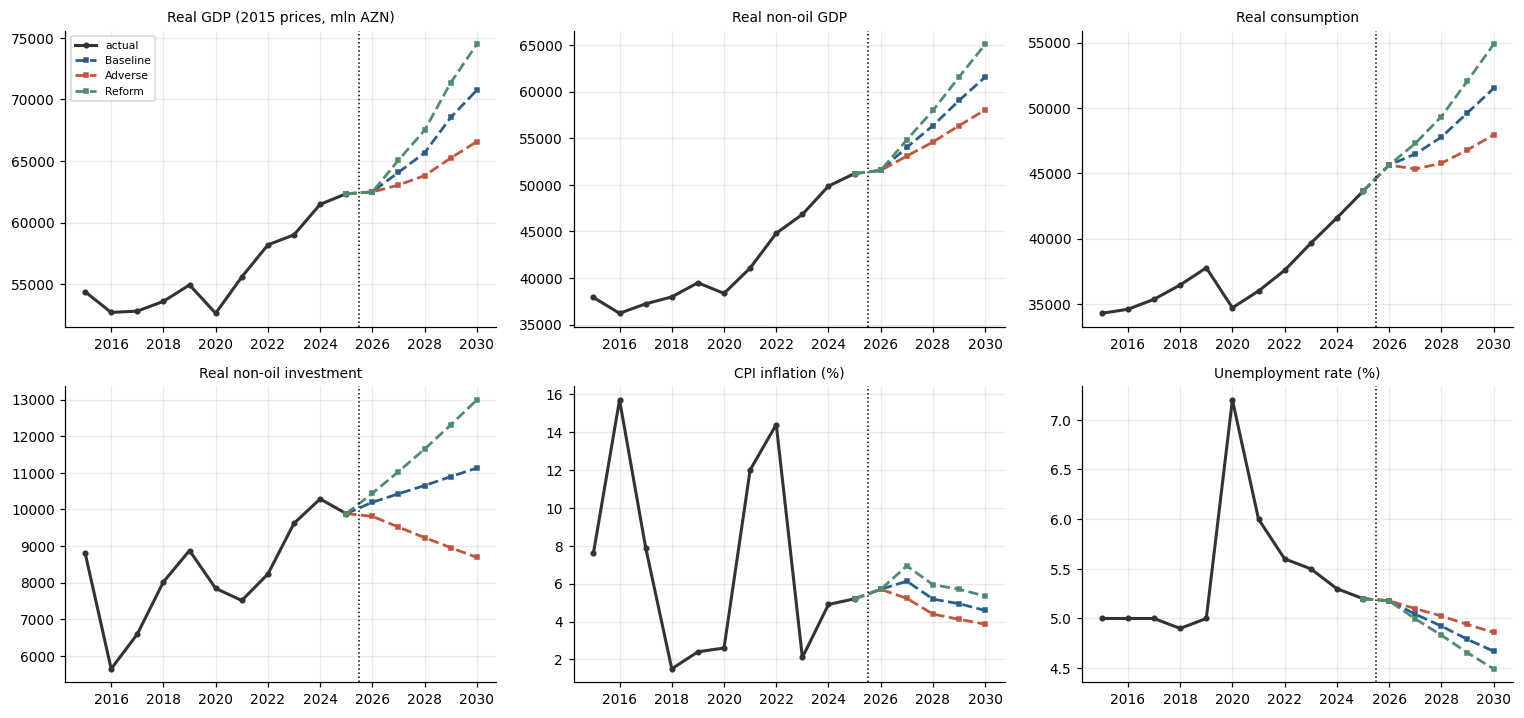

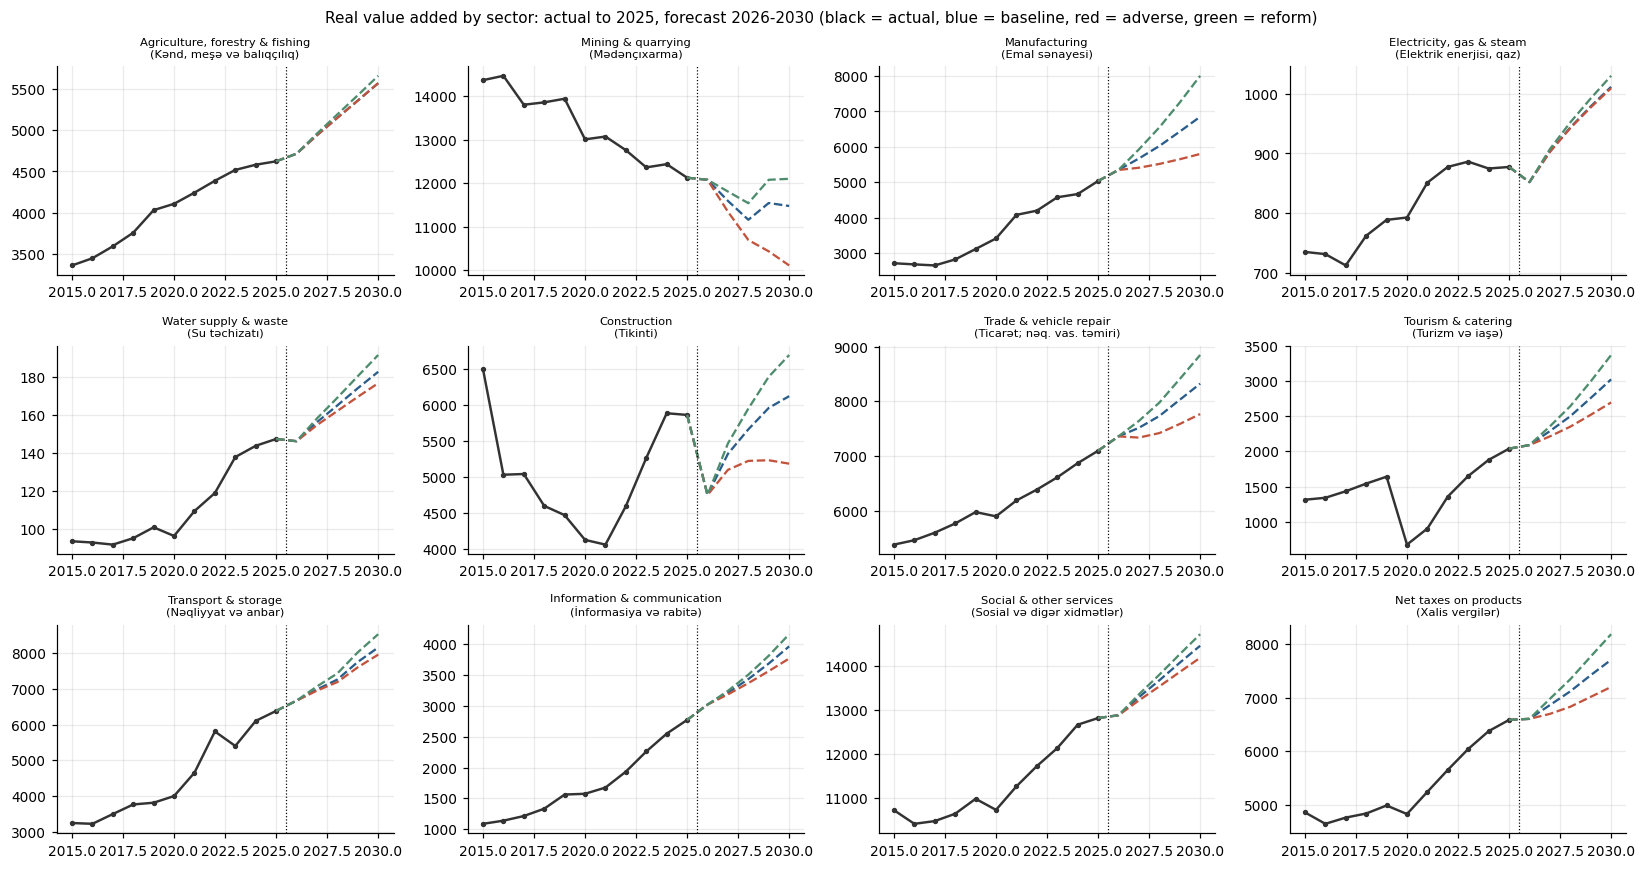

In [55]:
fig, ax = plt.subplots(2, 3, figsize=(14, 6.6))
COLS = {'Baseline': PAL[0], 'Adverse': PAL[1], 'Reform': PAL[2]}
def panel(a, key, title, pct=False):
    hist = D[key].loc[2015:LAST_ACT]
    a.plot(hist.index, hist.values, 'o-', color='#333', lw=2, ms=3, label='actual')
    for nm in SCEN:
        s = pd.concat([D[key].loc[[LAST_ACT]], FC[nm][key]])
        a.plot(s.index, s.values, 's--', color=COLS[nm], lw=1.8, ms=3, label=nm)
    a.axvline(LAST_ACT+.5, color='k', ls=':', lw=1); a.set_title(title, fontsize=9)
panel(ax[0,0], 'rgdp', 'Real GDP (2015 prices, mln AZN)'); ax[0,0].legend(fontsize=7)
panel(ax[0,1], 'rgdpnon', 'Real non-oil GDP')
panel(ax[0,2], 'rcons', 'Real consumption')
panel(ax[1,0], 'rinv_non', 'Real non-oil investment')
panel(ax[1,1], 'infl', 'CPI inflation (%)')
panel(ax[1,2], 'unemp', 'Unemployment rate (%)')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(3, 4, figsize=(15, 8))
for i, c in enumerate(COMP):
    a = ax[i//4, i%4]
    hist = D[f'rva_{c}'].loc[2015:LAST_ACT]
    a.plot(hist.index, hist.values, 'o-', color='#333', lw=1.6, ms=2.5)
    for nm in SCEN:
        s = pd.concat([D[f'rva_{c}'].loc[[LAST_ACT]], FC[nm][f'rva_{c}']])
        a.plot(s.index, s.values, '--', color=COLS[nm], lw=1.5)
    a.axvline(LAST_ACT+.5, color='k', ls=':', lw=.8)
    a.set_title(f"{SECT_LABEL[c]}\n({SECT_AZ[c]})", fontsize=7.5)
plt.suptitle('Real value added by sector: actual to 2025, forecast 2026-2030 '
             '(black = actual, blue = baseline, red = adverse, green = reform)', fontsize=10)
plt.tight_layout(); plt.show()

### 13.3 Artımın dekompozisiyası — hər proqnoz rəqəminin amillərə aid edilməsi

İzah oluna bilməyən proqnoz siyasət üçün yararlı deyil. Hər sektor tənliyi loqarifmlərdə xətti olduğundan, əlavə dəyərin
loqarifmindəki dəyişiklik dəqiq olaraq hər amilin elastikliyi ilə həmin amilin dəyişikliyinin hasillərinə ayrılır. Buna görə
sektor proqnozundakı hər rəqəm müəyyən edilə bilən səbəblərə, o cümlədən sadəcə qiymətləndirilmiş deterministik trenddən ibarət
olan hissəyə, ssenari üzrə TFP artımına və sönən 2026 lövbərinə qədər izlənilə bilər.

In [56]:
# Map each solver coefficient to the forecast variable it multiplies (log changes x 100 = pp).
COEF_VAR = {'ln_K_agr':'K_agr', 'ln_K_man':'K_man', 'ln_va_con':'rva_con', 'ln_x_non':'rx_non',
            'ln_va_agr':'rva_agr', 'ln_gdpnon':'rgdpnon', 'ln_gdpnon_pc':'rgdpnon_pc',
            'ln_inv_state':'rinv_state', 'ln_inv_priv':'rinv_priv', 'ln_cons':'rcons',
            'ln_hhdisp_pc':'rhhdisp_pc', 'ln_K_ict_pc':'K_ict_pc', 'ln_m_non':'rm_non', 'trend':'trend',
            'trend_post2015':'trend_post2015', 'ln_hc':'hc', 'ln_cred':'rcred_tot'}
EQOF = {'rva_agr':'C1_agr','rva_man':'C3_man','rva_elc':'C4_elc','rva_wat':'C5_wat','rva_con':'C6_con',
        'rva_trd':'C7_trd','rva_tou':'C8_tou','rva_tra':'C9_tra','rva_ict':'C10_ict',
        'rva_oth':'C11_oth','rva_nettax':'C12_nettax'}
PERCAP = {'rva_wat', 'rva_tou', 'rva_ict', 'rva_oth'}

def decompose(nm):
    ex, f, ap = SCEN[nm], FC[nm], ADDF[nm]
    def val(y, v):
        src = f if y >= FY[0] else D
        pop_ = ex[y]['pop'] if y >= FY[0] else POP[LAST_ACT]
        if v == 'trend':      return float(y - 2000)
        if v == 'trend_post2015': return float(max(y - 2015, 0))
        if v == 'hc':         return float(ex[y]['oil_prod'] + 0.9*ex[y]['gas_prod']) if y >= FY[0] else float(D.oil_prod[LAST_ACT] + 0.9*D.gas_prod[LAST_ACT])
        if v == 'pop':        return float(pop_)
        if v.endswith('_pc'): return float(src[v[:-3]][y])/pop_
        return float(src[v][y])
    rows = []
    for var, eq in EQOF.items():
        for y in FY:
            tot = (np.log(val(y, var)) - np.log(val(y-1, var)))*100
            rec = dict(sector=SECT_LABEL[var.replace('rva_','')], year=y, total_growth=tot)
            expl = 0.0
            for cname, b in CF[eq].items():
                if cname == 'const': continue
                v = COEF_VAR[cname]
                d = (val(y, v) - val(y-1, v))*100 if v.startswith('trend') else (np.log(val(y, v)) - np.log(val(y-1, v)))*100
                key = 'trend (deterministic)' if v.startswith('trend') else v
                rec[key] = rec.get(key, 0.0) + b*d; expl += b*d
            if var in PERCAP:
                rec['population (unit elasticity)'] = (np.log(val(y, 'pop')) - np.log(val(y-1, 'pop')))*100
                expl += rec['population (unit elasticity)']
            if var.replace('rva_', '') in TFP_SECT:
                tf = lambda yy: ex[yy]['tfp_boost']*ex[yy]['tfp_years'] if yy >= FY[0] else 0.0
                rec['scenario TFP boost'] = (tf(y) - tf(y-1))*100; expl += rec['scenario TFP boost']
            a_prev = BASE_ADDF.get(var, 0.0) if y == FY[0] else ap[y-1].get(var, 0.0)
            rec['add-factor change (anchor)'] = (ap[y].get(var, 0.0) - a_prev)*100
            expl += rec['add-factor change (anchor)']
            rec['residual (interaction)'] = tot - expl
            rows.append(rec)
    return pd.DataFrame(rows)

nm = 'Baseline'
DEC = decompose(nm)
print(f"{nm} - contributions to sector real growth, percentage points per year")
for s in DEC.sector.unique():
    sub = DEC[DEC.sector == s].set_index('year').drop(columns='sector').dropna(axis=1, how='all')
    print(f"\n--- {s} ---")
    display(sub.round(2))
assert DEC['residual (interaction)'].abs().max() < 0.05, "decomposition does not add up"

# How much of each sector's 2027-2030 growth is the deterministic trend?
late = DEC[DEC.year > NOWCAST_Y].groupby('sector')[['total_growth', 'trend (deterministic)']].mean()
late['trend share of growth (%)'] = late['trend (deterministic)']/late['total_growth']*100
TREND_SHARE = late.sort_values('trend share of growth (%)', ascending=False)
display(TREND_SHARE.round(2))
TREND_DOMINATED = TREND_SHARE[TREND_SHARE['trend share of growth (%)'] > 50].index.tolist()
print(f'''HONEST READING: in {', '.join(TREND_DOMINATED)} more than half of forecast growth 2027-2030 is the
estimated deterministic trend - growth the model carries forward from the past, not growth explained by an
economic driver. (An earlier version of this table omitted the x100 on the trend contribution and so showed
it as ~0.03 pp, hiding exactly this.) Those sector paths are as good as the assumption that the historical
trend continues.''')


Baseline - contributions to sector real growth, percentage points per year

--- Agriculture, forestry & fishing ---


,total_growth,trend (deterministic),scenario TFP boost,add-factor change (anchor),residual (interaction)
year,,,,,
2026,1.980,3.750,0.000,-1.770,0.000
2027,4.640,3.750,0.000,0.890,-0.000
2028,4.200,3.750,0.000,0.440,0.000
2029,3.980,3.750,0.000,0.220,-0.000
2030,3.870,3.750,0.000,0.110,-0.000



--- Manufacturing ---


,total_growth,scenario TFP boost,add-factor change (anchor),residual (interaction),K_man,rva_con,rx_non
year,,,,,,,
2026,6.020,0.000,5.650,0.000,-0.630,-4.100,5.090
2027,5.870,0.000,-2.830,-0.000,-0.590,2.220,7.070
2028,6.020,0.000,-1.410,0.000,-0.540,1.210,6.770
2029,6.530,0.000,-0.710,-0.000,-0.490,1.000,6.730
2030,6.320,0.000,-0.350,0.000,-0.440,0.530,6.590



--- Electricity, gas & steam ---


...

,total_growth,trend (deterministic),add-factor change (anchor),residual (interaction),population (unit elasticity),rhhdisp_pc
year,,,,,,
2026,0.500,1.190,-0.870,-0.000,0.480,-0.300
2027,3.150,1.190,0.440,0.000,0.480,1.040
2028,2.850,1.190,0.220,0.000,0.480,0.960
2029,2.890,1.190,0.110,0.000,0.480,1.110
2030,2.710,1.190,0.050,-0.000,0.480,0.990



--- Net taxes on products ---


,total_growth,add-factor change (anchor),residual (interaction),rcons,rm_non
year,,,,,
2026,0.300,-3.950,0.000,4.790,-0.530
2027,3.810,1.980,0.000,1.930,-0.090
2028,3.670,0.990,0.000,2.930,-0.250
2029,4.150,0.490,-0.000,4.060,-0.400
2030,3.800,0.250,-0.000,3.940,-0.380


,total_growth,trend (deterministic),trend share of growth (%)
sector,,,
Transport & storage,5.040,5.140,102.040
Information & communication,6.800,6.640,97.690
"Agriculture, forestry & fishing",4.170,3.750,90.030
"Electricity, gas & steam",4.300,2.790,64.720
Social & other services,2.900,1.190,41.040
Water supply & waste,5.580,2.050,36.770
Tourism & catering,9.240,2.840,30.720
Construction,6.360,NaN,NaN
Manufacturing,6.190,NaN,NaN


HONEST READING: in Transport & storage, Information & communication, Agriculture, forestry & fishing, Electricity, gas & steam more than half of forecast growth 2027-2030 is the
estimated deterministic trend - growth the model carries forward from the past, not growth explained by an
economic driver. (An earlier version of this table omitted the x100 on the trend contribution and so showed
it as ~0.03 pp, hiding exactly this.) Those sector paths are as good as the assumption that the historical
trend continues.


BASELINE - contribution of each sector to real GDP growth (percentage points)


,"Agriculture, forestry & fishing",Mining & quarrying,Manufacturing,"Electricity, gas & steam",Water supply & waste,Construction,Trade & vehicle repair,Tourism & catering,Transport & storage,Information & communication,Social & other services,Net taxes on products,TOTAL real GDP growth
year,,,,,,,,,,,,,
2026,0.120,-0.100,0.370,-0.030,-0.000,-1.240,0.420,0.070,0.320,0.190,0.110,0.030,0.240
2027,0.290,-0.960,0.390,0.070,0.020,0.630,0.250,0.270,0.340,0.130,0.730,0.380,2.550
2028,0.260,-0.780,0.410,0.060,0.010,0.360,0.350,0.290,0.290,0.140,0.700,0.380,2.470
2029,0.250,0.640,0.460,0.050,0.010,0.300,0.480,0.350,0.490,0.140,0.740,0.450,4.370
2030,0.240,-0.110,0.450,0.040,0.010,0.150,0.460,0.340,0.380,0.140,0.720,0.420,3.250


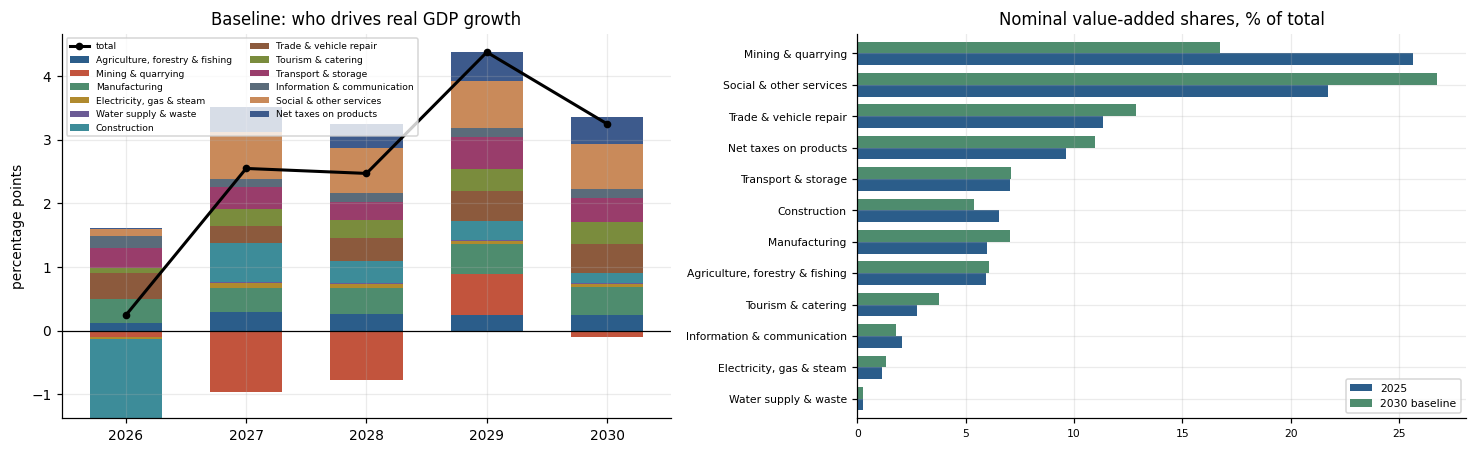

In [57]:
# Contribution of each sector to aggregate real GDP growth (chain-weighted)
nm = 'Baseline'
rows = []
for y in FY:
    prevy = y-1
    wN = {c: (D[f'p_{c}'][LAST_ACT]*D[f'rva_{c}'][LAST_ACT] if y == FY[0]
              else FC[nm][f'p_{c}'][prevy]*FC[nm][f'rva_{c}'][prevy]) for c in COMP}
    tot = sum(wN.values())
    r = {'year': y}
    for c in COMP:
        prev_v = D[f'rva_{c}'][LAST_ACT] if y == FY[0] else FC[nm][f'rva_{c}'][prevy]
        r[SECT_LABEL[c]] = (wN[c]/tot)*(FC[nm][f'rva_{c}'][y]/prev_v - 1)*100
    r['TOTAL real GDP growth'] = sum(v for k, v in r.items() if k != 'year')
    rows.append(r)
CONTRIB = pd.DataFrame(rows).set_index('year')
print("BASELINE - contribution of each sector to real GDP growth (percentage points)")
display(CONTRIB.round(2))

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))
cc = CONTRIB.drop(columns='TOTAL real GDP growth')
bot_pos = np.zeros(len(cc)); bot_neg = np.zeros(len(cc))
for i, c in enumerate(cc.columns):
    v = cc[c].values
    pos = np.where(v > 0, v, 0); neg = np.where(v < 0, v, 0)
    ax[0].bar(cc.index, pos, bottom=bot_pos, color=PAL[i % len(PAL)], label=c, width=.6)
    ax[0].bar(cc.index, neg, bottom=bot_neg, color=PAL[i % len(PAL)], width=.6)
    bot_pos += pos; bot_neg += neg
ax[0].plot(CONTRIB.index, CONTRIB['TOTAL real GDP growth'], 'ko-', lw=2, ms=4, label='total')
ax[0].axhline(0, color='k', lw=.8); ax[0].set_ylabel('percentage points')
ax[0].set_title('Baseline: who drives real GDP growth'); ax[0].legend(fontsize=6, ncol=2)
w = pd.DataFrame({'2025': sh25, '2030 baseline': sh30})
w.index = [SECT_LABEL[c] for c in COMP]
w.sort_values('2025').plot.barh(ax=ax[1], color=[PAL[0], PAL[2]], width=.75)
ax[1].set_title('Nominal value-added shares, % of total'); ax[1].tick_params(labelsize=7)
ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

### 13.4 Qeyri-müəyyənlik — dispersiya modeli deyil, stoxastik simulyasiya

Yelpik qrafikləri üç qeyri-müəyyənlik mənbəyini birləşdirir; onların hər biri hər təkrarlamada ayrıca çəkilir:

1. **Tənlik şokları — tarixi qalıq trayektoriyalarının təkrar seçimi (resampling).** 2010–2020-ci illərdən başlanğıc ili *s*
   çəkilir və şoka məruz qalan bütün 29 davranış tənliyinin qalıq kənarlaşmalarının birgə vektoru e_h = u_{s+h} − u_s (h = 1…5)
   sabit düzəliş əmsallarına əlavə edilir. Bu, tarixin beşillik kəsiklərini təkrar canlandırır, beləliklə, qalıqların empirik
   davamlılığı və tənliklərarası korrelyasiyası **qeyri-parametrik şəkildə ötürülür — qalıq dinamikası üzrə heç nə
   qiymətləndirilmir** (nə ρ, nə də AR prosesi). Trayektoriyalar mərkəzləşdirilir (başlanğıc illər üzrə orta trayektoriya
   çıxılır) və hər biri hər iki işarə ilə istifadə olunur (antitetik), beləliklə, şokların paylanması sıfıra nəzərən simmetrikdir.
2. **Ekzogen amillər** eyni üsulla — Brent, neft və qaz hasilatının loqarifmik səviyyələri üzrə, qalıq trayektoriyası ilə
   **eyni başlanğıc ili** götürülməklə — modelləşdirilir, beləliklə, neft qiymətinin fiskal qalıqlarla tarixi birgə hərəkəti qorunur.
3. **Parametr qeyri-müəyyənliyi.** Hər tənliyin əmsal vektoru N(β̂, V̂_HAC) paylanmasından antitetik cüt β̂ ± δ kimi çəkilir və
   rədd etmə yolu ilə elə kəsilir ki, cütün heç bir üzvündə heç bir meyl əmsalı işarəsini dəyişməsin; baza düzəliş əmsalları
   yenidən hesablanır ki, çəkilmiş hər model 2025-ci ili təkrarlasın.

2026-cı il qismən müşahidə olunub: birinci ilin kənarlaşması yanvar–apreldən sonra qalan tam il qeyri-müəyyənliyi ilə miqyaslanır
(Hissə 12; ekzogen amillər üçün 2/3) və bu azalma sonrakı illərə də ötürülür. Yığılmayan, sonlu olmayan qiymət verən, real ÜDM-i
əsas ssenaridən 50%-dən çox uzaqlaşdıran və ya hər hansı dəyişənin birillik loqarifmik dəyişikliyini əsas ssenaridəkindən 0,3-dən
çox (yaxud dəyişənin 2000–2025-ci illərdə faktiki etdiyi ən böyük birillik dəyişikliyin 1,5 misli daha böyükdürsə, ondan çox)
uzaqlaşdıran təkrarlamalar səbəbinə görə sayılır və antitetik cütlər bütöv saxlanılmaqla əvəz edilir; yalnız yığılan, sonlu
təkrarlamalar ixrac olunur (assert ilə təsdiqlənir). Təkrarlamaların medianı hər dəyişən və il üzrə əsas ssenari ilə tutuşdurulur.
Artım tempi yelpikləri hər təkrarlama üzrə artım templərinin kvantilləridir. Əsas ssenarinin təkrarlamaları FR3–FR5 üçün ixrac
olunur (`FR1_fan_draws.csv`).


residual matrix: 16 years (2010-2025) x 29 equations; 11 historical five-year residual paths (start years 2010-2020), used +/-

s.d. across paths of the 5-year residual deviation (log points; rates in pp):


,rva_agr,rva_min,rva_man,rva_elc,rva_wat,rva_con,rva_trd,rva_tou,rva_tra,rva_ict,rva_oth,rva_nettax,rcons,rinv_non,rx_non,rm_non,emp,lf,wage,rcred_tot,rcred_hh,rdep_tot,lendrate,infl,rgdpoil,rev_oil_n,rrev_nonoil,rexp_cur,rhhdisp
"sd, h=5",0.037,0.034,0.217,0.068,0.084,0.186,0.031,0.380,0.123,0.097,0.047,0.106,0.105,0.098,0.194,0.134,0.009,0.018,0.045,0.349,0.219,0.282,1.164,3.868,0.035,0.228,0.118,0.163,0.076


consistency check - correlation of the five core equations' residuals: resampling source (upper) vs 3SLS SIGMA_CORE (lower)


,rva_con,rva_trd,rva_tra,rcons,rm_non
rva_con,1.000,-0.280,0.730,-0.410,0.070
rva_trd,-0.280,1.000,0.140,0.780,-0.030
rva_tra,0.730,0.140,1.000,-0.050,-0.100
rcons,-0.410,0.780,-0.050,1.000,0.070
rm_non,0.070,-0.030,-0.100,0.070,1.000


,construction,trade,transport,consumption,imports
construction,1.000,-0.080,0.740,0.260,0.390
trade,-0.080,1.000,0.300,0.690,0.060
transport,0.740,0.300,1.000,0.260,0.270
consumption,0.260,0.690,0.260,1.000,0.220
imports,0.390,0.060,0.270,0.220,1.000


...


2030 band widths (levels):


,"5-95% width, % of median (2030)","25-75% width, % of median (2030)"
rgdp,19.500,7.800
rgdpnon,25.300,10.300
cpi,52.600,31.300
emp,8.900,4.200
rhhdisp,42.900,15.100
rcons,58.700,25.700
rexp_cur,67.800,27.500


median of the replications vs the deterministic baseline (real GDP, % difference): {2026: 0.0, 2027: 0.0, 2028: 0.0, 2029: 0.0, 2030: 0.0}
band width by year, real GDP 5-95% (% of median): {2026: 9.0, 2027: 12.6, 2028: 15.2, 2029: 17.0, 2030: 19.5}
sanity check vs the hold-out: 5-year-ahead real GDP level error in the 2021-25 hold-out was -11.4% (RMSE over the 5 years 8.3%); non-oil -10.6%. The 2030 90% band half-width is 9.8% (real GDP) and 12.7% (non-oil).


,hold-out 5-year level error 2025 (%),2030 90% band half-width (%)
rgdp,-11.400,9.800
rgdpnon,-10.600,12.700
cpi,-30.700,26.300
emp,-4.200,4.500
rhhdisp,10.500,21.500
rcons,0.700,29.400
rexp_cur,32.500,33.900


ratio of 2030 90% half-width to the hold-out 5-year error: {'rgdp': np.float64(0.9), 'rgdpnon': np.float64(1.2), 'cpi': np.float64(0.9), 'emp': np.float64(1.1), 'rhhdisp': np.float64(2.0), 'rcons': np.float64(43.5), 'rexp_cur': np.float64(1.0)}
READING: real GDP, non-oil GDP, CPI and disposable income bands are of the same order as the errors the model made
over 2021-2025. The employment band is NARROWER than the hold-out error and the consumption band much WIDER: the
former because the employment-rate equation fits history very closely, the latter because consumption amplifies
income and household-credit shocks through the simultaneous income loop. Both are reported, not tuned away.


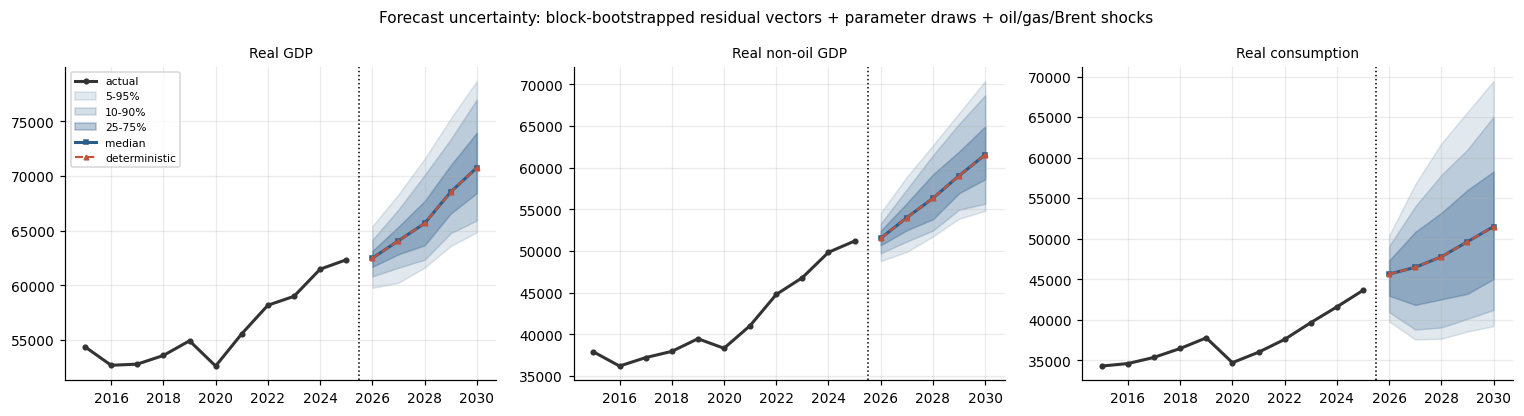

In [58]:
rng = np.random.default_rng(SEED)
FAN_EQ = {v: e for v, e in EQ_OF_VAR.items() if e in MODEL and v != 'rinv_state'}
RATE_VARS = {'infl', 'lendrate'}
RMAT = pd.DataFrame({v: RESID_OF[e] for v, e in FAN_EQ.items()}).dropna()
# HISTORICAL RESIDUAL-PATH RESAMPLING. Nothing is estimated on the residual dynamics (no rho, no AR
# process). For a replication a start year s is drawn and the joint vector of residual DEVIATIONS
#     e_h = u_{s+h} - u_s,  h = 1..5,
# of all shocked equations is added to the (constant) add-factors. This carries the empirical persistence
# and cross-equation correlation of the residuals over five-year stretches of history, nonparametrically.
# Paths are centred (the mean path over start years is subtracted, so no drift is added) and every path is
# also used with its sign reversed (antithetic), so the shock distribution is symmetric around zero.
H = len(FY)
STARTS = [s_ for s_ in RMAT.index if s_ + H in RMAT.index]
PATHS = np.stack([RMAT.loc[s_+1:s_+H].to_numpy() - RMAT.loc[s_].to_numpy() for s_ in STARTS])   # S x H x eq
PATHS = PATHS - PATHS.mean(axis=0)
cols = list(RMAT.columns)
def partial_year(p_, sc):
    '''2026 is partly observed: scale the first-year deviation by sc and carry that reduction forward.'''
    q = p_.copy(); q[0] = sc*p_[0]; q[1:] = p_[1:] - (1 - sc)*p_[0]
    return q
print(f"residual matrix: {RMAT.shape[0]} years ({RMAT.index.min()}-{RMAT.index.max()}) x {RMAT.shape[1]} equations; "
      f"{len(STARTS)} historical five-year residual paths (start years {STARTS[0]}-{STARTS[-1]}), used +/-")
print("\ns.d. across paths of the 5-year residual deviation (log points; rates in pp):")
display(pd.Series(PATHS[:, -1, :].std(axis=0), index=cols).round(3).to_frame('sd, h=5').T)
core_map = {'construction':'rva_con', 'trade':'rva_trd', 'transport':'rva_tra', 'consumption':'rcons', 'imports':'rm_non'}
sd_ = np.sqrt(np.diag(SIGMA_CORE.values))
print("consistency check - correlation of the five core equations' residuals: resampling source (upper) vs 3SLS SIGMA_CORE (lower)")
display(RMAT[[core_map[k] for k in core_map]].corr().round(2))
display(pd.DataFrame(SIGMA_CORE.values/np.outer(sd_, sd_), index=list(core_map), columns=list(core_map)).round(2))

# exogenous drivers: historical five-year paths of log Brent, oil and gas output, same construction
LX = pd.DataFrame({'brent': np.log(D.brent), 'oil': np.log(D.oil_prod), 'gas': np.log(D.gas_prod)})
XSTARTS = STARTS                       # the same start years as the residual paths
XPATHS = np.stack([LX.loc[s_+1:s_+H].to_numpy() - LX.loc[s_].to_numpy() for s_ in XSTARTS])
XPATHS = XPATHS - XPATHS.mean(axis=0)
print(f"exogenous paths: start years {XSTARTS[0]}-{XSTARTS[-1]}; s.d. of the 5-year log deviation:",
      dict(zip(LX.columns, XPATHS[:, -1, :].std(axis=0).round(3))))

PARAM_TRIES = {'draws': 0, 'rejected': 0}
def draw_coef_pair(m, max_tries=200):
    '''Antithetic coefficient pair beta +/- delta, delta ~ N(0, V_HAC), truncated by rejection so that
    in BOTH members every slope keeps the sign of its point estimate. The pair makes the parameter
    distribution exactly symmetric around the point estimate (no drift in the median path).'''
    V = m['V'].values; V = (V + V.T)/2
    w, Q = np.linalg.eigh(V); w = np.clip(w, 0, None)
    b0 = m['beta'].values; sl = np.array([k != 'const' for k in m['beta'].index])
    for _ in range(max_tries):
        PARAM_TRIES['draws'] += 1
        d = Q @ (np.sqrt(w)*rng.standard_normal(len(w)))
        if np.all(np.sign((b0+d)[sl]) == np.sign(b0[sl])) and np.all(np.sign((b0-d)[sl]) == np.sign(b0[sl])):
            return pd.Series(b0+d, index=m['beta'].index), pd.Series(b0-d, index=m['beta'].index)
        PARAM_TRIES['rejected'] += 1
    return m['beta'].copy(), m['beta'].copy()

def _model_from(coefs):
    cf2, res2 = dict(CF), {}
    for nm, m in MODEL.items():
        bs = coefs[nm]
        cf2[nm] = m['to_cf'](bs) if m['to_cf'] else bs
        if m['kind'] == 'level':
            res2[nm] = form_resid(m['y'], m['X'], bs)
        else:
            d = pd.concat([m['y'].rename('__y'), m['X']], axis=1).dropna()
            res2[nm] = d['__y'] - bs['const'] - sum(bs[c]*d[c] for c in m['X'].columns)
    cal2 = dict(CAL); cal2['defl'] = defl_from({k: {'cf': cf2[k]} for k in cf2 if k.startswith('G5_defl')})
    cal2['mkt_defl'] = mkt_defl_from({k: {'cf': cf2[k]} for k in cf2 if k.startswith('G5_defl')})
    return cf2, cal2, calibrate_addfactors(LAST_ACT, resid_of=res2)

def draw_model_pair():
    '''One antithetic pair of parameter draws for every behavioural equation; base add-factors are
    recomputed so each drawn model reproduces the last actual year.'''
    plus, minus = {}, {}
    for nm, m in MODEL.items(): plus[nm], minus[nm] = draw_coef_pair(m)
    return _model_from(plus), _model_from(minus)

NSIM = 500
H = len(FY)
DRAWS, FAIL = [], {}
JUMP_MAX = 0.3        # no shock may move a variable's one-year log change more than 0.3 away from the baseline's
RATE_COLS = {'infl', 'unemp', 'lendrate', 'realrate', 'gap', 'balance_n'}
STOCKS_NEAR_ZERO = {'debt_azn', 'debt_serv_n'}   # log changes of a stock that can approach zero are not meaningful
JUMP_VARS = [c for c in FC['Baseline'].columns if c not in RATE_COLS | STOCKS_NEAR_ZERO and not c.startswith('share_')
             and (FC['Baseline'][c] > 0).all()]
# Variable-specific ceiling on the shock-induced one-year move: 0.3 log points, or 1.5 x the largest
# year-on-year move the variable has actually made in 2000-2025 where that is larger. The residual paths
# replay 2015-16 and 2020-21, when several series moved by more than 0.3 in a year; a stricter ceiling
# would discard a large share of the draws and truncate the distribution.
def _histmax(k):
    if k not in D.columns: return 0.0
    v = D[k].loc[2000:LAST_ACT]
    v = v[v > 0]
    return float(np.log(v).diff().abs().max()) if len(v) > 3 else 0.0
JUMP_CAP = {k: max(JUMP_MAX, 1.5*_histmax(k)) for k in JUMP_VARS}
JUMP_REJ = {}
_NAN_OK = {c for c in FC['Baseline'].columns if FC['Baseline'][c].isna().all()}   # v2.2
_st25 = state_from_actual(LAST_ACT)
_fb = FC['Baseline']
BASE_DL = {k: {y: float(np.log(_fb[k][y]/(_st25[k] if y == FY[0] else _fb[k][y-1])))
               for y in FY} for k in JUMP_VARS if k in _st25 and np.isfinite(_st25.get(k, np.nan)) and _st25[k] > 0}
attempts = 0
def run_rep(model, sh, xd):
    '''Solve one replication; returns (solution by year, None) or (None, reason).'''
    global CF, CAL
    cf2, cal2, base2 = model
    xcum = xd
    ex2 = {y: dict(SCEN['Baseline'][y]) for y in FY}
    prev_br, prev_fx = float(D.brent[LAST_ACT]), float(D.fx[LAST_ACT])
    for i, y in enumerate(FY):
        e = ex2[y]; fb, fo, fg = np.exp(xcum[i])
        e['brent'] *= fb; e['oil_prod'] *= fo; e['oil_exp_vol'] *= fo; e['rinv_oil'] *= fo
        e['gas_prod'] *= fg; e['gas_exp_vol'] *= fg
        e['dln_oil_azn'] = (np.log(e['brent']*e['fx']) - np.log(prev_br*prev_fx))*100
        prev_br, prev_fx = e['brent'], e['fx']
        e['oilrev_ref'] = OILREF['Baseline'][y]
    keep_ = (CF, CAL); CF, CAL = cf2, cal2
    out = {}
    try:
        prev = state_from_actual(LAST_ACT)
        for i, y in enumerate(FY):
            a = dict(base2)
            for k, v in ANCHOR_INC.items(): a[k] = a.get(k, 0.0) + v*ANCHOR_DECAY**(y-NOWCAST_Y)
            for j, v in enumerate(cols): a[v] = a.get(v, 0.0) + sh[i, j]
            sol, it, err = solve_year(prev, ex2[y], addf=a, maxit=600, tol=1e-9)
            if err > 1e-8: return None, 'non-convergence'
            if not all(np.isfinite(v) for k, v in sol.items() if isinstance(v, (int, float, np.floating))
                       and k not in _NAN_OK):          # v2.2: unmodelled (all-NaN) variables are skipped
                return None, 'non-finite'
            if abs(np.log(sol['rgdp']/FC['Baseline'].rgdp[y])) > 0.5:
                return None, 'explosive (>50% from baseline)'
            jumps = [k for k in BASE_DL
                     if abs(np.log(max(sol[k], 1e-12)/prev[k]) - BASE_DL[k][y]) > JUMP_CAP[k]]
            if jumps:
                for k in jumps: JUMP_REJ[k] = JUMP_REJ.get(k, 0) + 1
                return None, 'year-on-year jump above ceiling'
            out[y] = sol; prev = dict(sol)
        return out, None
    except Exception:
        return None, 'non-convergence'
    finally:
        CF, CAL = keep_

pairs = 0
while len({r['draw'] for r in DRAWS}) < NSIM and pairs < 3*NSIM:
    pairs += 1
    mp, mm = draw_model_pair()
    _s = rng.integers(len(PATHS))      # ONE historical start year for residuals and exogenous drivers jointly,
                                       # so the co-movement of oil prices with the fiscal residuals is kept
    sh = partial_year(PATHS[_s], NOWCAST_SCALE)     # H x equations
    xd = partial_year(XPATHS[_s], 2/3)              # H x (Brent, oil, gas) log deviations
    o1, r1 = run_rep(mp, sh, xd)
    o2, r2 = run_rep(mm, -sh, -xd)                        # antithetic member: every shock mirrored
    for r in (r1, r2):
        if r: FAIL[r] = FAIL.get(r, 0) + 1
    if o1 is None or o2 is None: continue                 # keep pairs whole so symmetry is preserved
    for o in (o1, o2):
        b = len({r['draw'] for r in DRAWS})
        for y in FY:
            rr = dict(o[y]); rr['draw'] = b; rr['year'] = y; DRAWS.append(rr)
attempts = 2*pairs
DRAWDF = pd.DataFrame(DRAWS).drop(columns=sorted(_NAN_OK), errors='ignore')   # v2.2
NVALID = DRAWDF.draw.nunique()
CONV_RATE = NVALID/attempts
PARAM_REJ = PARAM_TRIES['rejected']/max(PARAM_TRIES['draws'], 1)
print(f"\n{attempts} replications attempted in {pairs} antithetic pairs, {NVALID} valid ({CONV_RATE:.1%}); failures by reason: {FAIL}")
print(f"parameter draws: {PARAM_TRIES['draws']} coefficient vectors drawn, {PARAM_REJ:.1%} rejected for a slope sign flip")
num = DRAWDF.select_dtypes('number')
assert np.isfinite(num.to_numpy()).all(), "non-finite value in the exported replications"
assert NVALID == NSIM, "not enough valid replications"
print("replications rejected for a year-on-year jump above the ceiling, by variable:", JUMP_REJ or 'none')
print("ceilings above 0.3 (historical max move x 1.5):", {k: round(v, 2) for k, v in JUMP_CAP.items() if v > JUMP_MAX})

_chk = DRAWDF.sort_values(['draw', 'year'])
JUMP_MAXDEV = {}
for k in BASE_DL:
    w = _chk.pivot(index='draw', columns='year', values=k); w.insert(0, LAST_ACT, _st25[k])
    dev = np.log(w).diff(axis=1)[FY] - pd.Series(BASE_DL[k])
    JUMP_MAXDEV[k] = float(dev.abs().max().max())
    assert JUMP_MAXDEV[k] <= JUMP_CAP[k] + 1e-9, f"exported draw jumps above ceiling in {k}"
print("check passed: in every exported draw and year, |dlog(draw) - dlog(baseline)| <= 0.3 "
      "(or 1.5 x the variable's largest historical one-year move, where larger); largest deviations:",
      {k: round(v, 2) for k, v in sorted(JUMP_MAXDEV.items(), key=lambda t: -t[1])[:6]})
KEYJ = ['rgdp', 'rgdpnon', 'rcons', 'rhhdisp', 'emp', 'wage', 'cpi', 'rexp_cur', 'rinv_non', 'rva_man']
SHARE_GT03 = {}
for k in KEYJ:
    w = _chk.pivot(index='draw', columns='year', values=k); w.insert(0, LAST_ACT, _st25[k])
    SHARE_GT03[k] = float((np.log(w).diff(axis=1)[FY].abs() > 0.3).to_numpy().mean()*100)
print("share of exported draw-years with |dlog| > 0.3, key variables (%):", {k: round(v, 2) for k, v in SHARE_GT03.items()})

# ---- centring on the published baseline -------------------------------------------------------
# The shocks and the parameter deviations are symmetric (centred, antithetic). The model is log-linear
# equation by equation, but aggregates are ARITHMETIC sums of log-normally shocked components (sector
# value added in chain-linked GDP, oil + non-oil revenue, the income loop through non-oil GDP), and the
# median of such a sum lies above the sum of the medians. The raw gaps are reported below; the exported
# draws are then centred - multiplicatively for level variables, additively for rates - so that the
# median path equals the baseline in every year while the dispersion is unchanged.
_fb = FC['Baseline']
def _medgap(df):
    g = {}
    for k in [c for c in _fb.columns if c in df.columns]:
        med = df.groupby('year')[k].median()
        g[k] = ((med/_fb[k] - 1)*100) if (k not in RATE_COLS and (_fb[k] > 0).all()) else (med - _fb[k])
    return pd.DataFrame(g).T
MEDGAP_RAW = _medgap(DRAWDF)
KEYV = ['rgdp', 'rgdpnon', 'rcons', 'rhhdisp', 'emp', 'wage', 'cpi', 'rexp_cur', 'rinv_non', 'rev_tot_n', 'infl', 'unemp']
print("\nRAW median of the replications minus the deterministic baseline (% for levels, pp for rates):")
display(MEDGAP_RAW.loc[KEYV].round(2))
for k in [c for c in _fb.columns if c in DRAWDF.columns]:
    med = DRAWDF.groupby('year')[k].transform('median'); base = DRAWDF.year.map(_fb[k])
    DRAWDF[k] = DRAWDF[k]*base/med if (k not in RATE_COLS and (_fb[k] > 0).all()) else DRAWDF[k] - med + base
MEDGAP = _medgap(DRAWDF)
print(f"after centring: largest |median - baseline| over all variables and years = {MEDGAP.abs().max().max():.2e}")
assert MEDGAP.abs().max().max() < 1e-6, "draws not centred on the baseline"
_chk2 = DRAWDF.sort_values(['draw', 'year'])
_post = {}
for k in BASE_DL:
    w = _chk2.pivot(index='draw', columns='year', values=k); w.insert(0, LAST_ACT, _st25[k])
    _post[k] = float((np.log(w).diff(axis=1)[FY] - pd.Series(BASE_DL[k])).abs().max().max() - JUMP_CAP[k])
print(f"after centring, largest excess over a jump ceiling: {max(_post.values()):+.3f} log points "
      f"(centring shifts each year's level by the reported median gap)")

QS = [5, 10, 25, 50, 75, 90, 95]
FAN, FANG = {}, {}
for k in ['rgdp','rgdpnon','rcons','infl','rva_man','rva_con','unemp','rinv_non','emp','wage','rhhdisp','rev_tot_n','rcred_tot','rexp_cur']:
    wide_ = DRAWDF.pivot(index='draw', columns='year', values=k)[FY]
    FAN[k] = pd.DataFrame(np.nanpercentile(wide_.values, QS, axis=0).T, index=FY, columns=[f'p{q}' for q in QS])
    if k not in ('infl', 'unemp'):
        lv = pd.concat([pd.Series(float(D[k][LAST_ACT]), index=wide_.index, name=LAST_ACT), wide_], axis=1)
        gr = (lv.pct_change(axis=1)*100)[FY]
        FANG[k] = pd.DataFrame(np.nanpercentile(gr.values, QS, axis=0).T, index=FY, columns=[f'p{q}' for q in QS])
print("\nReal GDP growth fan (quantiles of per-replication growth rates), % per year:")
display(FANG['rgdp'].round(2))
print("Real non-oil GDP growth fan, % per year:"); display(FANG['rgdpnon'].round(2))
print("CPI inflation fan, %:"); display(FAN['infl'].round(2))
FAN['cpi'] = pd.DataFrame(np.nanpercentile(DRAWDF.pivot(index='draw', columns='year', values='cpi')[FY].values, QS, axis=0).T,
                          index=FY, columns=[f'p{q}' for q in QS])
BANDS = pd.DataFrame({k: {'5-95% width, % of median (2030)': float((FAN[k].p95[H_END]-FAN[k].p5[H_END])/FAN[k].p50[H_END]*100),
                          '25-75% width, % of median (2030)': float((FAN[k].p75[H_END]-FAN[k].p25[H_END])/FAN[k].p50[H_END]*100)}
                      for k in ['rgdp','rgdpnon','cpi','emp','rhhdisp','rcons','rexp_cur']}).T
print("\n2030 band widths (levels):"); display(BANDS.round(1))
print("median of the replications vs the deterministic baseline (real GDP, % difference):",
      ((FAN['rgdp'].p50/FC['Baseline'].rgdp - 1)*100).round(2).to_dict())
print("band width by year, real GDP 5-95% (% of median):",
      ((FAN['rgdp'].p95 - FAN['rgdp'].p5)/FAN['rgdp'].p50*100).round(1).to_dict())
print(f"sanity check vs the hold-out: 5-year-ahead real GDP level error in the 2021-25 hold-out was "
      f"{HOT.loc['real GDP','err_2025']:+.1f}% (RMSE over the 5 years {HOT.loc['real GDP','model_RMSE']:.1f}%); "
      f"non-oil {HOT.loc['real non-oil GDP','err_2025']:+.1f}%. The 2030 90% band half-width is "
      f"{BANDS.loc['rgdp'].iloc[0]/2:.1f}% (real GDP) and {BANDS.loc['rgdpnon'].iloc[0]/2:.1f}% (non-oil).")
HOERR = {k: float((HO[k][LAST_ACT]/D[k][LAST_ACT]-1)*100) for k in ['rgdp','rgdpnon','cpi','emp','rhhdisp','rcons','rexp_cur']}
display(pd.DataFrame({'hold-out 5-year level error 2025 (%)': HOERR,
                      '2030 90% band half-width (%)': (BANDS.iloc[:, 0]/2).to_dict()}).round(1))
_r = {k: (BANDS.iloc[:, 0][k]/2)/max(abs(HOERR[k]), 0.1) for k in HOERR}
print("ratio of 2030 90% half-width to the hold-out 5-year error:", {k: round(v, 1) for k, v in _r.items()})
print("READING: real GDP, non-oil GDP, CPI and disposable income bands are of the same order as the errors the model made")
print("over 2021-2025. The employment band is NARROWER than the hold-out error and the consumption band much WIDER: the")
print("former because the employment-rate equation fits history very closely, the latter because consumption amplifies")
print("income and household-credit shocks through the simultaneous income loop. Both are reported, not tuned away.")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for a, k, lbl in [(ax[0],'rgdp','Real GDP'), (ax[1],'rgdpnon','Real non-oil GDP'), (ax[2],'rcons','Real consumption')]:
    hist = D[k].loc[2015:LAST_ACT]
    a.plot(hist.index, hist.values, 'o-', color='#333', lw=2, ms=3, label='actual')
    a.fill_between(FY, FAN[k].p5, FAN[k].p95, color=PAL[0], alpha=.14, label='5-95%')
    a.fill_between(FY, FAN[k].p10, FAN[k].p90, color=PAL[0], alpha=.2, label='10-90%')
    a.fill_between(FY, FAN[k].p25, FAN[k].p75, color=PAL[0], alpha=.32, label='25-75%')
    a.plot(FY, FAN[k].p50, 's-', color=PAL[0], lw=2, ms=3, label='median')
    a.plot(FY, FC['Baseline'][k].values, '^--', color=PAL[1], lw=1.4, ms=3, label='deterministic')
    a.axvline(LAST_ACT+.5, color='k', ls=':', lw=1); a.set_title(lbl, fontsize=9)
ax[0].legend(fontsize=7)
plt.suptitle('Forecast uncertainty: block-bootstrapped residual vectors + parameter draws + oil/gas/Brent shocks', fontsize=10)
plt.tight_layout(); plt.show()


## Hissə 14 — Multiplikatorlar: hər sektorun təsirinin digər sektorlara ötürülməsi

Modelin bu hissəsi FR1-in *sektorların əlaqəli sektorlardan necə təsirləndiyini* anlamaq tələbinə və siyasət modulunun konkret
müdaxilənin nə nəticə verdiyi sualına cavab verir. Hər təcrübə **həll edilmiş** sistemdə bir ekzogen dəyişənə şok tətbiq edir və
sektorlar üzrə tam reaksiyanı göstərir. Ötürülmə sadəcə iddia edilmir, qiymətləndirilmiş əlaqə əmsalları vasitəsilə izlənilir.

Dörd təcrübə:

1. **Brent qiymətinin daimi olaraq +10 USD/barel artması** — ticarət şərtləri kanalı. O, daxili iqtisadiyyata büdcə vasitəsilə çatır: daha yüksək neft gəlirləri dövlət investisiyasını artırır (F4 tənliyi), bu da tikintini, sonra tikinti materialları vasitəsilə emal sənayesini, daha sonra isə gəlirləri və istehlakı artırır.
2. **Real dövlət investisiyasının daimi olaraq +1 mlrd manat artması** — fiskal rıçaq, ilk növbədə tikintiyə çatır.
3. **Kredit şərtlərinin yumşaldılması** — maliyyə kanalı. Bu nümunədə uçot dərəcəsinin bazar faiz dərəcələrinə müəyyən edilə bilən ötürülməsi olmadığından (Hissə 9.6), təcrübə həm uçot dərəcəsini, həm də depozit faiz dərəcəsini yumşaldır və kredit həcmləri vasitəsilə işləyir (ev təsərrüfatlarına kredit → istehlak). Aqreqat məlumatlar investisiya tənliyində kredit həddini rədd edir (Hissə 9.3), buna görə ikinci, aydın işarələnmiş variant regional panel üzrə kredit elastikliyini investisiyaya tətbiq edən **ekspert mülahizəsinə əsaslanan əlavəni (judgemental overlay)** daxil edir — bu, qiymətləndirmə deyil, istifadəçi rıçağıdır.
4. **Xarici tələbin +10% artması** — ixrac kanalı, emal sənayesinə və kənd təsərrüfatına çatır.

In [59]:
def shock_run(mod):
    '''Re-run the baseline with one exogenous variable perturbed.'''
    ex2 = {y: dict(SCEN['Baseline'][y]) for y in FY}
    mod(ex2)
    # shocks reuse the BASELINE reference path, so an oil-price change moves public
    # investment through the estimated elasticity rather than being offset by policy
    fc, conv, _, _ = run_forecast(ex2, addf_fixed=ADDF['Baseline'], oilrev_ref=OILREF['Baseline'])
    # v2.3.1: every shocked solve must converge (the solver tolerance is 1e-10)
    bad = {y: c for y, c in conv.items() if not c[1] < 1e-9}
    assert not bad, f"shock run did not converge: {bad}"
    SHOCK_CONV.append(max(c[1] for c in conv.values()))
    return fc
SHOCK_CONV = []
# v2.3.1: deviations from the Baseline. % only for strictly positive levels; inflation in pp; the budget balance
# (a difference of two large aggregates that crosses zero in the Baseline) in mln AZN at current prices
MULT_ABS = {'infl': 'pp', 'balance_n': 'mln AZN'}

def brent_shock(ex, d=10.0):
    prev_br, prev_fx = float(D.brent[LAST_ACT]), float(D.fx[LAST_ACT])
    for y in FY:
        ex[y]['brent'] += d
        ex[y]['dln_oil_azn'] = (np.log(ex[y]['brent']*ex[y]['fx']) - np.log(prev_br*prev_fx))*100
        prev_br, prev_fx = ex[y]['brent'], ex[y]['fx']

def istate_shock(ex, d=1000.0):
    for y in FY: ex[y]['istate_add'] += d      # +1 bn AZN of real state investment, permanently

def polrate_shock(ex, d=-2.0):
    # The policy rate acts on credit QUANTITIES (equation G1, correctly signed). It does NOT
    # pass through to market rates in this sample, so the deposit rate is moved alongside it
    # to represent a genuine easing of credit conditions rather than a rate signal alone.
    for y in FY:
        ex[y]['polrate'] += d
        ex[y]['deprate'] += d*0.5

def extdem_shock(ex, d=0.10):
    for y in FY: ex[y]['extdem'] *= (1+d)

def polrate_overlay_shock(ex, d=-2.0):
    # JUDGEMENTAL OVERLAY, not part of the estimated model: the aggregate data reject a credit term in the
    # investment equation (Part 9.3), so here the regional-panel credit elasticity of OUTPUT is applied to
    # investment as a user lever, on deviations of credit from its baseline path.
    polrate_shock(ex, d)
    for y in FY:
        ex[y]['credit_overlay'] = CRED_EL_OUT
        ex[y]['cred_ref'] = float(np.log(FC['Baseline'].rcred_tot[y]))

EXPS = {'Brent +10 USD/bbl': brent_shock, 'State investment +1 bn AZN (real)': istate_shock,
        'Credit easing (-200 bp policy, -100 bp deposit)': polrate_shock,
        'Credit easing + judgemental credit->investment overlay': polrate_overlay_shock,
        'External demand +10%': extdem_shock}
MULT, FCS = {}, {}
for lbl, fn in EXPS.items():
    fc = shock_run(fn); FCS[lbl] = fc
    keys = [f'rva_{c}' for c in COMP] + ['rgdp','rgdpnon','rcons','rinv_non','rinv_state','emp',
                                         'infl','rev_tot_n','balance_n','rm_non','rx_non']
    dif = {}
    for k in keys:
        if k in MULT_ABS:
            dif[k] = (fc[k] - FC['Baseline'][k])                  # pp (inflation) / mln AZN (balance) difference
        else:
            assert (FC['Baseline'][k] > 0).all(), k               # a % deviation needs a positive baseline level
            dif[k] = (fc[k]/FC['Baseline'][k] - 1)*100            # % difference
    MULT[lbl] = pd.DataFrame(dif)
    print(f"===== {lbl} =====  (deviation from baseline)")
    t = MULT[lbl][[f'rva_{c}' for c in COMP]].copy()
    t.columns = [SECT_LABEL[c] for c in COMP]
    t['REAL GDP'] = MULT[lbl]['rgdp']; t['non-oil GDP'] = MULT[lbl]['rgdpnon']
    t['inflation (pp)'] = MULT[lbl]['infl']
    display(t.round(3))

===== Brent +10 USD/bbl =====  (deviation from baseline)


,"Agriculture, forestry & fishing",Mining & quarrying,Manufacturing,"Electricity, gas & steam",Water supply & waste,Construction,Trade & vehicle repair,Tourism & catering,Transport & storage,Information & communication,Social & other services,Net taxes on products,REAL GDP,non-oil GDP,inflation (pp)
2026,0.000,0.000,0.385,0.009,0.139,1.369,0.228,0.403,0.000,0.219,0.067,0.303,0.184,0.246,0.082
2027,0.000,0.000,0.453,0.011,0.165,1.499,0.271,0.479,0.000,0.431,0.080,0.341,0.075,0.292,0.015
2028,0.000,0.000,0.529,0.013,0.189,1.647,0.311,0.551,0.000,0.639,0.092,0.378,-0.014,0.335,0.015
2029,0.000,0.000,0.576,0.014,0.202,1.684,0.332,0.589,0.000,0.829,0.098,0.396,-0.012,0.358,0.008
2030,0.000,0.000,0.624,0.014,0.213,1.722,0.351,0.621,0.000,0.999,0.103,0.412,-0.062,0.378,0.007


===== State investment +1 bn AZN (real) =====  (deviation from baseline)


,"Agriculture, forestry & fishing",Mining & quarrying,Manufacturing,"Electricity, gas & steam",Water supply & waste,Construction,Trade & vehicle repair,Tourism & catering,Transport & storage,Information & communication,Social & other services,Net taxes on products,REAL GDP,non-oil GDP,inflation (pp)
2026,0.000,0.000,1.543,0.035,0.520,5.552,0.853,1.514,0.000,0.904,0.251,0.816,0.688,0.922,0.308
2027,0.000,0.000,1.688,0.039,0.581,5.597,0.954,1.693,0.000,1.699,0.280,0.912,0.791,1.030,0.036
2028,0.000,0.000,1.826,0.042,0.623,5.626,1.024,1.818,0.000,2.395,0.301,0.979,0.868,1.105,0.025
2029,0.000,0.000,1.945,0.044,0.653,5.593,1.073,1.906,0.000,3.000,0.315,1.026,0.914,1.158,0.018
2030,0.000,0.000,2.069,0.046,0.679,5.598,1.116,1.981,0.000,3.523,0.327,1.066,0.961,1.204,0.015


===== Credit easing (-200 bp policy, -100 bp deposit) =====  (deviation from baseline)


,"Agriculture, forestry & fishing",Mining & quarrying,Manufacturing,"Electricity, gas & steam",Water supply & waste,Construction,Trade & vehicle repair,Tourism & catering,Transport & storage,Information & communication,Social & other services,Net taxes on products,REAL GDP,non-oil GDP,inflation (pp)
2026,0.000,0.000,0.007,0.011,0.161,0.027,0.863,0.465,0.000,-0.001,0.077,0.819,0.212,0.284,0.095
2027,0.000,0.000,0.006,0.011,0.157,0.024,0.856,0.455,0.000,-0.002,0.076,0.813,0.213,0.278,-0.002
2028,0.000,0.000,0.005,0.010,0.155,0.021,0.854,0.450,0.000,-0.004,0.075,0.811,0.215,0.275,-0.001
2029,0.000,0.000,0.004,0.010,0.154,0.018,0.852,0.447,0.000,-0.005,0.074,0.809,0.215,0.273,-0.001
2030,0.000,0.000,0.003,0.010,0.154,0.017,0.852,0.447,0.000,-0.007,0.074,0.809,0.217,0.273,-0.000


===== Credit easing + judgemental credit->investment overlay =====  (deviation from baseline)


,"Agriculture, forestry & fishing",Mining & quarrying,Manufacturing,"Electricity, gas & steam",Water supply & waste,Construction,Trade & vehicle repair,Tourism & catering,Transport & storage,Information & communication,Social & other services,Net taxes on products,REAL GDP,non-oil GDP,inflation (pp)
2026,0.000,0.000,0.348,0.019,0.276,1.300,1.053,0.800,0.000,0.089,0.133,1.000,0.365,0.488,0.163
2027,0.000,0.000,0.365,0.019,0.283,1.316,1.064,0.821,0.000,0.168,0.136,1.012,0.384,0.501,0.004
2028,0.000,0.000,0.381,0.019,0.288,1.330,1.073,0.837,0.000,0.238,0.139,1.020,0.400,0.510,0.003
2029,0.000,0.000,0.390,0.020,0.290,1.311,1.076,0.842,0.000,0.300,0.140,1.023,0.404,0.513,0.001
2030,0.000,0.000,0.404,0.020,0.293,1.317,1.081,0.851,0.000,0.355,0.141,1.028,0.413,0.519,0.002


===== External demand +10% =====  (deviation from baseline)


,"Agriculture, forestry & fishing",Mining & quarrying,Manufacturing,"Electricity, gas & steam",Water supply & waste,Construction,Trade & vehicle repair,Tourism & catering,Transport & storage,Information & communication,Social & other services,Net taxes on products,REAL GDP,non-oil GDP,inflation (pp)
2026,0.000,0.000,9.465,0.052,0.767,0.135,1.260,2.238,0.000,-0.003,0.369,1.204,1.016,1.361,0.454
2027,0.000,0.000,9.463,0.052,0.774,0.128,1.271,2.257,0.000,-0.007,0.373,1.215,1.053,1.373,0.004
2028,0.000,0.000,9.461,0.053,0.788,0.126,1.295,2.300,0.000,-0.012,0.380,1.239,1.096,1.399,0.009
2029,0.000,0.000,9.459,0.054,0.805,0.122,1.322,2.349,0.000,-0.017,0.388,1.265,1.123,1.428,0.010
2030,0.000,0.000,9.459,0.056,0.825,0.123,1.356,2.410,0.000,-0.021,0.397,1.298,1.166,1.464,0.012


multiplier checks passed: 5 shocked runs converged (max residual 9.9e-11); no sign flip after year 2 in balance_n (mln AZN), rgdpnon (%) or infl (pp)
budget balance response, mln AZN: {'Brent +10 USD/bbl': [183.0, 124.0, 62.0, 41.0, 14.0], 'State investment +1 bn AZN (real)': [-1980.0, -2139.0, -2352.0, -2577.0, -2812.0], 'Credit easing (-200 bp policy, -100 bp deposit)': [68.0, 78.0, 91.0, 106.0, 123.0], 'Credit easing + judgemental credit->investment overlay': [91.0, 107.0, 126.0, 148.0, 172.0], 'External demand +10%': [155.0, 183.0, 220.0, 262.0, 309.0]}
Effect by 2030, % deviation from baseline (inflation in pp)


,Brent +10 USD/bbl,State investment +1 bn AZN (real),"Credit easing (-200 bp policy, -100 bp deposit)",Credit easing + judgemental credit->investment overlay,External demand +10%
"Agriculture, forestry & fishing",0.000,0.000,0.000,0.000,0.000
Mining & quarrying,0.000,0.000,0.000,0.000,0.000
Manufacturing,0.624,2.069,0.003,0.404,9.459
"Electricity, gas & steam",0.014,0.046,0.010,0.020,0.056
Water supply & waste,0.213,0.679,0.154,0.293,0.825
Construction,1.722,5.598,0.017,1.317,0.123
Trade & vehicle repair,0.351,1.116,0.852,1.081,1.356
Tourism & catering,0.621,1.981,0.447,0.851,2.410
Transport & storage,0.000,0.000,0.000,0.000,0.000
Information & communication,0.999,3.523,-0.007,0.355,-0.021


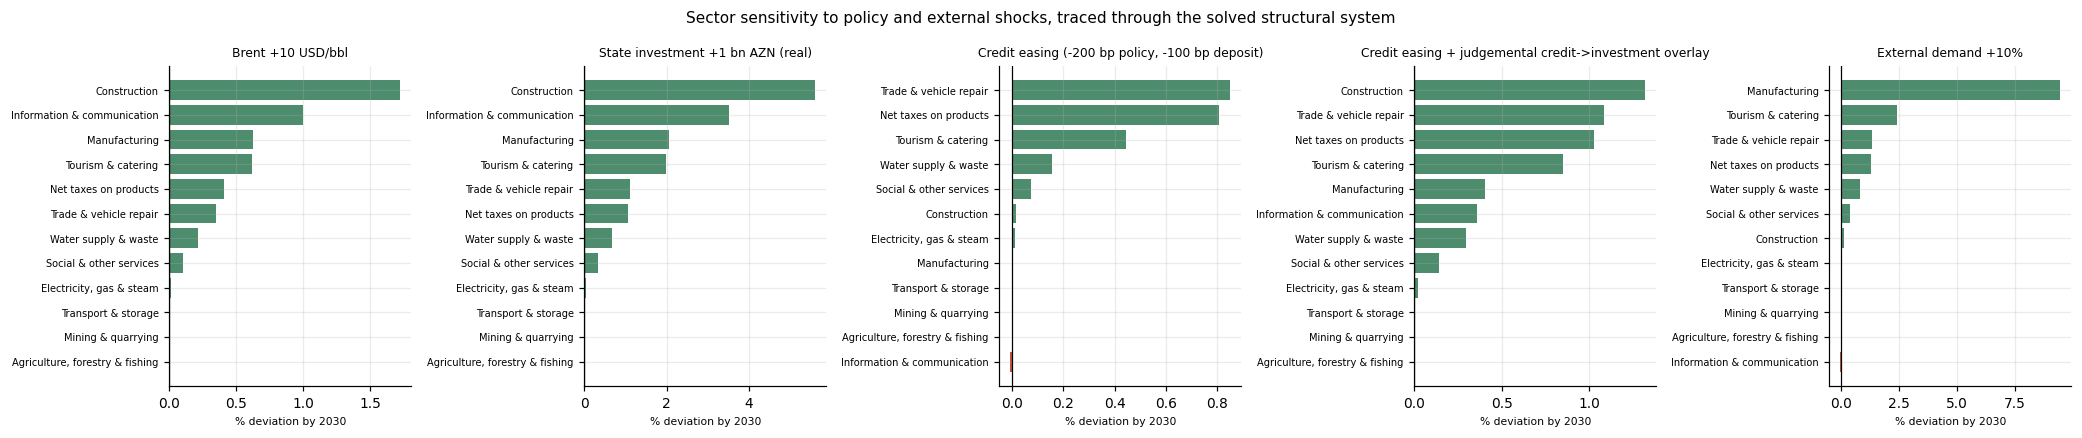

,"injection (real state investment, mln)",d real non-oil GDP (mln),d real GDP (mln),"impact multiplier, non-oil GDP"
2026,983.443,475.260,430.130,0.483
2027,980.797,556.626,506.912,0.568
2028,979.030,622.824,570.104,0.636
2029,978.003,683.859,626.257,0.699
2030,977.370,741.193,680.248,0.758


Why an oil price rise can LOWER chain-weighted real GDP while raising non-oil sectors
  Real GDP is chain-linked with previous-year NOMINAL weights (Part 3.4). A higher oil price raises the
  mining DEFLATOR and hence mining's weight, while mining's volume (exogenous) is falling, so the aggregate
  growth rate is tilted down: real GDP -0.06% by 2030, real non-oil GDP
  +0.38%, budget revenue +3.78%.

Fiscal multiplier reading (+1 bn AZN of real state investment per year, permanently)
  2030 level effect: real non-oil GDP +741 mln (2015 prices) for an injection of
  977 mln in 2030 -> multiplier 0.76 in 2030.
  Cumulative multiplier 2026-2030 (sum of d non-oil GDP / sum of injections): 0.63
  (on chain-weighted real GDP: 0.57).
  Construction absorbs the impulse first (+5.60% by 2030), then manufacturing and ICT.
  Non-oil imports move +1.14%: the long-run import equation's investment coefficient is wrongly
  signed (Part 10.2), so the import leakage of public investment is NOT captured

In [60]:
# v2.3.1 checks: the shocked solves converged, and the responses of balance_n, rgdpnon and infl keep one sign from
# year 2 on (values below a tolerance count as zero). Justified exceptions would be listed in MULT_SIGN_OK with a reason.
MULT_SIGN_TOL = {'balance_n': 0.5, 'rgdpnon': 1e-4, 'infl': 1e-4}      # mln AZN, %, pp
MULT_SIGN_OK = {  # {(shock, variable): reason}; a justified sign change must still be monotone (no oscillation)
 ('Brent +10 USD/bbl', 'balance_n'): 'the manat oil-revenue gain is flat while the F4 state-investment and F3 spending '
                                    'responses grow with nominal GDP, so the balance gain declines steadily and can cross zero'}
for lbl in EXPS:
    for k, tol in MULT_SIGN_TOL.items():
        v = MULT[lbl][k].loc[FY[1]:]
        sg = set(np.sign(v[v.abs() > tol]))
        if len(sg) > 1:
            assert (lbl, k) in MULT_SIGN_OK, f"{lbl}: {k} changes sign after year 2: {v.round(4).tolist()}"
            dv = np.sign(np.diff(v.values)); dv = dv[dv != 0]
            assert len(set(dv)) <= 1, f"{lbl}: {k} oscillates: {v.round(4).tolist()}"
            print(f"justified sign change ({lbl}, {k}): {MULT_SIGN_OK[(lbl, k)]}; path {v.round(1).tolist()} (monotone)")
print(f"multiplier checks passed: {len(SHOCK_CONV)} shocked runs converged (max residual {max(SHOCK_CONV):.1e}); no sign flip "
      "after year 2 in balance_n (mln AZN), rgdpnon (%) or infl (pp)")
print("budget balance response, mln AZN:", {lbl: MULT[lbl]['balance_n'].round(0).tolist() for lbl in EXPS})

# Summary: cumulative 5-year impact, ranked by sector sensitivity
summ = pd.DataFrame({lbl: {SECT_LABEL[c]: MULT[lbl][f'rva_{c}'][H_END] for c in COMP}
                     for lbl in EXPS})
summ.loc['REAL GDP'] = {lbl: MULT[lbl]['rgdp'][H_END] for lbl in EXPS}
summ.loc['real non-oil GDP'] = {lbl: MULT[lbl]['rgdpnon'][H_END] for lbl in EXPS}
summ.loc['consumption'] = {lbl: MULT[lbl]['rcons'][H_END] for lbl in EXPS}
summ.loc['employment'] = {lbl: MULT[lbl]['emp'][H_END] for lbl in EXPS}
summ.loc['budget revenue'] = {lbl: MULT[lbl]['rev_tot_n'][H_END] for lbl in EXPS}
summ.loc['state investment'] = {lbl: MULT[lbl]['rinv_state'][H_END] for lbl in EXPS}
print(f"Effect by {H_END}, % deviation from baseline (inflation in pp)")
display(summ.round(3))

fig, ax = plt.subplots(1, len(EXPS), figsize=(19, 4))
for j, lbl in enumerate(EXPS):
    v = pd.Series({SECT_LABEL[c]: MULT[lbl][f'rva_{c}'][H_END] for c in COMP}).sort_values()
    ax[j].barh(range(len(v)), v.values, color=[PAL[1] if x < 0 else PAL[2] for x in v.values])
    ax[j].set_yticks(range(len(v))); ax[j].set_yticklabels(v.index, fontsize=6.5)
    ax[j].axvline(0, color='k', lw=.8); ax[j].set_title(lbl, fontsize=8)
    ax[j].set_xlabel(f'% deviation by {H_END}', fontsize=7)
plt.suptitle('Sector sensitivity to policy and external shocks, traced through the solved '
             'structural system', fontsize=10)
plt.tight_layout(); plt.show()

# Fiscal multiplier, in comparable units (2015-price mln AZN), two ways
_L = 'State investment +1 bn AZN (real)'
fcs, fcb = FCS[_L], FC['Baseline']
d_inj = fcs.rinv_state - fcb.rinv_state
MULTSUM = pd.DataFrame({
 'injection (real state investment, mln)': d_inj,
 'd real non-oil GDP (mln)': fcs.rgdpnon - fcb.rgdpnon,
 'd real GDP (mln)': fcs.rgdp - fcb.rgdp})
MULTSUM['impact multiplier, non-oil GDP'] = MULTSUM['d real non-oil GDP (mln)']/MULTSUM['injection (real state investment, mln)']
display(MULTSUM.round(3))
FISCAL_MULT_2030 = float(MULTSUM['d real non-oil GDP (mln)'][H_END]/d_inj[H_END])
FISCAL_MULT_CUM  = float(MULTSUM['d real non-oil GDP (mln)'].sum()/d_inj.sum())
FISCAL_MULT_CUM_GDP = float(MULTSUM['d real GDP (mln)'].sum()/d_inj.sum())
print(f'''Why an oil price rise can LOWER chain-weighted real GDP while raising non-oil sectors
  Real GDP is chain-linked with previous-year NOMINAL weights (Part 3.4). A higher oil price raises the
  mining DEFLATOR and hence mining's weight, while mining's volume (exogenous) is falling, so the aggregate
  growth rate is tilted down: real GDP {MULT["Brent +10 USD/bbl"]["rgdp"][H_END]:+.2f}% by {H_END}, real non-oil GDP
  {MULT["Brent +10 USD/bbl"]["rgdpnon"][H_END]:+.2f}%, budget revenue {MULT["Brent +10 USD/bbl"]["rev_tot_n"][H_END]:+.2f}%.

Fiscal multiplier reading (+1 bn AZN of real state investment per year, permanently)
  {H_END} level effect: real non-oil GDP +{MULTSUM["d real non-oil GDP (mln)"][H_END]:,.0f} mln (2015 prices) for an injection of
  {d_inj[H_END]:,.0f} mln in {H_END} -> multiplier {FISCAL_MULT_2030:.2f} in {H_END}.
  Cumulative multiplier 2026-{H_END} (sum of d non-oil GDP / sum of injections): {FISCAL_MULT_CUM:.2f}
  (on chain-weighted real GDP: {FISCAL_MULT_CUM_GDP:.2f}).
  Construction absorbs the impulse first ({MULT[_L]["rva_con"][H_END]:+.2f}% by {H_END}), then manufacturing and ICT.
  Non-oil imports move {MULT[_L]["rm_non"][H_END]:+.2f}%: the long-run import equation's investment coefficient is wrongly
  signed (Part 10.2), so the import leakage of public investment is NOT captured and this multiplier is, if anything, an
  upper bound.''')


### 14.1 v2.3 — namizədlərin ssenari nəticələri, fiskal diaqnostika və qərarlar

Hissə 11.7-nin hər namizədi tam nümunədə qiymətləndirilir və üç ssenari üzrə həll olunur: 2030 büdcə balansı (ÜDM-ə nisbətdə), minimum əmək haqqının +10% artımının təsiri (Hissə 14-ün şok konvensiyası) və Mənfi ssenaridə balansın niyə ən yaxşı olduğunun dekompozisiyası. Qərar qaydası: işarələr düzgün (və ya neytral), əsas dəyişənin Theil U itkisi ≤ 10%, E3 üçün əmək ödənişləri elastikliyi uyğun (fərq formasının 95% intervalı daxilində), F3 üçün isə əlavə olaraq balansın sırası Mənfi < Əsas < İslahat. Nəticələr: `FR1_v23_forecast_checks.csv`, `FR1_v23_fiscal_diagnosis.csv`, `FR1_v23_decisions.csv`.

In [61]:
# ==== Part 14.1 (v2.3) — scenario consequences of the Part 11.7 candidates, the fiscal diagnosis, the decisions ===
def v23_model(**chg):
    '''Full-sample model with some v2.3 equations at another specification: (CF, base add-factors = own 2025 residuals).'''
    cf, res = dict(CF), dict(RESID_OF)
    for eq, sp in chg.items():
        _, m = v23_full(eq, sp); cf[eq] = m['cf']; res[eq] = m['resid']
    return cf, calibrate_addfactors(LAST_ACT, resid_of=res)

def v23_runs(cf, base, f4rule=False):
    '''All scenarios, anchored as in Part 13.1 (the scenario dicts are those of the adopted model; each run builds its
    own oil-revenue reference path, as the main run does). f4rule: the capital-spending rule candidate - every scenario
    keeps the BASELINE policy level of real state investment and moves it by the F4 elasticity with real oil revenue
    relative to the Baseline reference path.'''
    out = {nm: run_forecast({y: dict(SCEN[nm][y], oilrev_ref=None) for y in FY}, cf=cf, base_addf=base) for nm in SCEN}
    if f4rule:
        ref_b = out['Baseline'][3]
        for nm in SCEN:
            ex = {y: dict(SCEN[nm][y], istate_level=SCEN['Baseline'][y]['istate_level'], oilrev_ref=None) for y in FY}
            out[nm] = run_forecast(ex, cf=cf, base_addf=base, oilrev_ref=ref_b)
    return out

def minwage_response(cf, base, pct=10.0):
    '''Baseline, minimum wage +pct% in every year, shock convention of Part 14 (the baseline's add-factors and
    oil-revenue reference path are held); 2030 deviation in %.'''
    fc0, _, path, ref = run_forecast({y: dict(SCEN['Baseline'][y], oilrev_ref=None) for y in FY}, cf=cf, base_addf=base)
    ex1 = {y: dict(SCEN['Baseline'][y], minwage=SCEN['Baseline'][y]['minwage']*(1 + pct/100)) for y in FY}
    fc1 = run_forecast(ex1, cf=cf, addf_fixed=path, oilrev_ref=ref)[0]
    return {k: float((fc1[k][H_END]/fc0[k][H_END] - 1)*100) for k in ('rhhdisp', 'rcons', 'wage', 'cpi', 'rgdpnon', 'emp', 'rgdp')}

def devalue(ex, pct):
    '''Permanent devaluation of pct% from the first forecast year: FX path, its log changes (current and lagged),
    the manat oil price and manat import prices recomputed with the scenario builder's formulas.'''
    fxp, brp = float(D.fx[LAST_ACT]), float(D.brent[LAST_ACT]); dl_prev = float(D.dln_fx[LAST_ACT])
    dlpm_prev = float(D.dln_pm_azn[LAST_ACT])
    for y in FY:
        e = ex[y]; e['fx'] *= (1 + pct/100)
        e['dln_fx'] = (np.log(e['fx']) - np.log(fxp))*100; e['dln_oil_azn'] = (np.log(e['brent']*e['fx']) - np.log(brp*fxp))*100
        e['dln_fx_L1'], e['dln_pm_azn_L1'] = dl_prev, dlpm_prev
        dl_prev = e['dln_fx']; dlpm_prev = np.log(1 + e['pm_usd_infl']/100)*100 + e['dln_fx']; fxp, brp = e['fx'], e['brent']
    return ex

def devaluation_response(cf, base, pct=16.5):
    '''Baseline, permanent devaluation (shock convention of Part 14): CPI inflation pp in 2026 and 2027, CPI level,
    non-oil GDP, real disposable income, consumption (% in 2030) and public debt / GDP (pp, 2030).'''
    fc0, _, path, ref = run_forecast({y: dict(SCEN['Baseline'][y], oilrev_ref=None) for y in FY}, cf=cf, base_addf=base)
    fc1 = run_forecast(devalue({y: dict(SCEN['Baseline'][y]) for y in FY}, pct), cf=cf, addf_fixed=path, oilrev_ref=ref)[0]
    pc = lambda k, y=H_END: float((fc1[k][y]/fc0[k][y] - 1)*100)
    dg = lambda f: f.debt_azn[H_END]/f.gdp_n[H_END]*100
    return {'infl_2026': float(fc1.infl[NOWCAST_Y] - fc0.infl[NOWCAST_Y]), 'infl_2027': float(fc1.infl[NOWCAST_Y+1] - fc0.infl[NOWCAST_Y+1]),
            'cpi_2030': pc('cpi'), 'rgdpnon_2026': pc('rgdpnon', NOWCAST_Y), 'rgdpnon_2030': pc('rgdpnon'), 'rhhdisp_2030': pc('rhhdisp'),
            'rcons_2030': pc('rcons'), 'debt_gdp_2030': float(dg(fc1) - dg(fc0))}

_bal = lambda fc: float(100*fc.balance_n[H_END]/fc.gdp_n[H_END])
CHK23, V23_FC = [], {}
for lbl, (eq, grp, chg) in VARIANTS23.items():
    full = dict(V22_SPEC); full.update(chg)          # as in the hold-out: the v2.2 model with the candidate's change
    cf_, base_ = v23_model(**full)
    runs = v23_runs(cf_, base_, lbl in F4RULE23); V23_FC[lbl] = {nm: r[0] for nm, r in runs.items()}
    for nm, r in runs.items():
        CHK23.append(dict(check='budget balance 2030, % of GDP', variant=lbl, scenario=nm, variable='bal_gdp', value=_bal(r[0])))
        for k in ('rgdp', 'rgdpnon', 'rhhdisp', 'rcons', 'rm_non', 'cpi', 'balance_n'):
            CHK23.append(dict(check='level 2030', variant=lbl, scenario=nm, variable=k, value=float(r[0][k][H_END])))
    if grp in ('E2',):
        for k, v in minwage_response(cf_, base_, pct=20.0).items():
            CHK23.append(dict(check='minimum wage +20%: 2030 deviation, %', variant=lbl, scenario='Baseline', variable=k, value=v))
    if grp in ('G4', 'all'):
        for k, v in devaluation_response(cf_, base_).items():
            CHK23.append(dict(check='devaluation +16.5%: deviation (pp for infl, debt_gdp; % otherwise)', variant=lbl,
                              scenario='Baseline', variable=k, value=v))
    if grp in ('E3', 'all'):
        for k, v in minwage_response(cf_, base_).items():
            CHK23.append(dict(check='minimum wage +10%: 2030 deviation, %', variant=lbl, scenario='Baseline', variable=k, value=v))
CHK23 = pd.DataFrame(CHK23)
# the adopted variant reproduces the published forecast
for nm in SCEN:
    assert float((V23_FC['v2.3 model (adopted changes)'][nm].rgdp/FC[nm].rgdp - 1).abs().max()) < 1e-10, nm
CHK23.to_csv(OUTDIR/'FR1_v23_forecast_checks.csv', index=False)
_b23 = CHK23[CHK23.check == 'budget balance 2030, % of GDP'].pivot(index='variant', columns='scenario', values='value')
print("Budget balance 2030, % of GDP, by variant:"); display(_b23[list(SCEN)].round(2))
_mw = CHK23[CHK23.check.str.startswith('minimum wage')].pivot(index='variant', columns='variable', values='value')
print("Minimum wage +10% (Baseline, shock convention), 2030 deviation %:"); display(_mw.round(3))

# ---- fiscal diagnosis: what makes Adverse end with the best balance (adopted model, 2030, mln AZN)
_fa, _fb0 = FC['Adverse'], FC['Baseline']
def _fis(f):
    return {'oil revenue': f.rev_oil_n[H_END], 'non-oil revenue': f.rrev_nonoil[H_END]*f.p_gdp[H_END],
            'current spending': f.rexp_cur[H_END]*f.p_gdp[H_END], 'capital spending': f.exp_cap_n[H_END],
            'debt service': f.debt_serv_n[H_END], 'balance': f.balance_n[H_END]}
_A, _B = _fis(_fa), _fis(_fb0)
FISDIAG = [dict(item=k, Baseline=_B[k], Adverse=_A[k], difference=_A[k] - _B[k],
                pct=(_A[k]/_B[k] - 1)*100 if _B[k] else np.nan) for k in _A]
_drev = (_A['oil revenue'] + _A['non-oil revenue']) - (_B['oil revenue'] + _B['non-oil revenue'])
_dexp = sum(_A[k] - _B[k] for k in ('current spending', 'capital spending', 'debt service'))
FISDIAG.append(dict(item='spending cut per AZN of revenue lost', Baseline=np.nan, Adverse=np.nan, difference=_dexp/_drev, pct=np.nan))
# the capital-spending assumption: Adverse with the Baseline policy level of state investment
_exA = {y: dict(SCEN['Adverse'][y], istate_level=SCEN['Baseline'][y]['istate_level'], oilrev_ref=None) for y in FY}
_fA2 = run_forecast(_exA)[0]
FISDIAG.append(dict(item='Adverse balance 2030 (% of GDP) with the Baseline state-investment policy level',
                    Baseline=_bal(_fb0), Adverse=_bal(_fA2), difference=_bal(_fA2) - _bal(_fb0), pct=np.nan))
# the F4 elasticity behind the assumption: real oil revenue and real state investment, Adverse vs Baseline 2030
_ro = lambda f: f.rev_oil_n[H_END]/f.p_gdp[H_END]
FISDIAG.append(dict(item='real oil revenue vs real state investment, Adverse / Baseline 2030 - 1 (%)', Baseline=np.nan,
                    Adverse=(_fa.rinv_state[H_END]/_fb0.rinv_state[H_END] - 1)*100, difference=(_ro(_fa)/_ro(_fb0) - 1)*100, pct=np.nan))
for eq, k in (('F3_expcur', 'ln_rev_r'), ('F4_pubinv', 'ln_rev_oil')):
    _f = REG[eq]['fit']; _r = REG[eq]
    if k in _f.names:
        i = _f.names.index(k); b, s = _f.beta[i], _f.se[i]; tq = stats.t.ppf(.975, _f.dof)
    else:                                      # F4: unit elasticity imposed; the free estimate and its s.e. from the test
        _ff = lr_fit(*_r['diff']); i = _ff.names.index(k); b, s = _ff.beta[i], _ff.se[i]; tq = stats.t.ppf(.975, _ff.dof)
    FISDIAG.append(dict(item=f'{eq} elasticity ({k}): solver value, estimate, 95% CI', Baseline=float(CF[eq][k]),
                        Adverse=float(b), difference=float(b - tq*s), pct=float(b + tq*s)))
FISDIAG = pd.DataFrame(FISDIAG)
FISDIAG.to_csv(OUTDIR/'FR1_v23_fiscal_diagnosis.csv', index=False)
display(FISDIAG.round(3))

# ---- decisions (rule stated in Part 11.7) -------------------------------------------------------------------------
KEY23 = {'D4': 'rm_non', 'E3': 'rhhdisp', 'F3': 'bal_gdp', 'F4': 'bal_gdp', 'G4': 'infl', 'E2': 'wage'}
FOCUS23 = {'D4': 'ln_relprice', 'E3': 'ln_wagebill_r', 'F3': None, 'F4': None, 'G4': None, 'E2': None}   # the term the candidate is about (coherence)
def _econ(eq, sp, cf):
    """slope coefficients in economic units (D4 USD-volume form: the volume elasticity c = solver value + 1)"""
    return {k: (v + 1.0 if (eq == 'D4_mnon' and sp == 'usd_volume' and k == 'ln_relprice') else v)
            for k, v in cf.items() if k != 'const'}
DEC23 = []
for r in V23_COEF:
    lbl, eq, sp = r['variant'], r['equation'], r['spec']; grp = VARIANTS23[lbl][1]; k0 = KEY23[grp]
    t = CMP23[(CMP23.variant == lbl) & (CMP23.variable == k0)].iloc[0]
    loss = max((t.U_rw/t.U_rw_v22 - 1)*100, (t.U_cg/t.U_cg_v22 - 1)*100 if np.isfinite(t.U_cg) else -np.inf)
    sign_ok = all(v > 0 for c in (r['cf_cut'], r['cf_full']) for v in _econ(eq, sp, c).values())
    f0 = FOCUS23[grp]
    coh = bool(f0 is None or not any(f0 in r[k] for k in ('incoherent_full', 'incoherent_cut')))
    b = _b23.loc[lbl]; order = bool(b['Adverse'] < b['Baseline'] < b['Reform'])
    # E3: the wage elasticity must also be coherent (task rule); D4 and F3: coherence reported (the v2.2 D4 and F3 are not)
    elig = sign_ok and loss <= 10.0 and (coh if grp == 'E3' else True) and (order if grp in ('F3', 'F4') else True)
    DEC23.append(dict(group=grp, variant=lbl, equation=eq, spec=sp, key_variable=k0, U_rw_v22=t.U_rw_v22, U_rw=t.U_rw,
                      U_cg_v22=t.U_cg_v22, U_cg=t.U_cg, U_loss_pct=loss, material_loss=bool(loss > 10.0), signs_ok=sign_ok,
                      focus_term_coherent=coh, outside_diff_ci_full=', '.join(r['incoherent_full']),
                      outside_diff_ci_cut=', '.join(r['incoherent_cut']), balance_order_ok=order, bal_2030_Baseline=b['Baseline'], bal_2030_Adverse=b['Adverse'],
                      bal_2030_Reform=b['Reform'], eligible=elig,
                      coef_cut=', '.join(f"{k}={v:+.3f}" for k, v in _econ(eq, sp, r['cf_cut']).items()),
                      coef_full=', '.join(f"{k}={v:+.3f}" for k, v in _econ(eq, sp, r['cf_full']).items())))
DEC23 = pd.DataFrame(DEC23)
# ---- v2.3.4 rule for G4 (import-price data check, 2026-10-06): (A) the DSK splice is chosen if its hold-out U is within
# 10% of the macro-module import-price form AND it removes most (>= half) of the 2023-25 residual; else (B) FX + FX(t-1) if the
# two import-price sources cannot be reconciled (opposite signs in at least two of 2021-25); else the macro-module form.
_rG = {sp: v23_full('G4_infl', sp)[1]['resid'].loc[2021:LAST_ACT] for sp in ('pm_azn_lag', 'pm_dsk_lag', 'fx_lag', 'fx_wage')}
_uG = DEC23[DEC23.group == 'G4'].set_index('spec').U_rw
PM_SIGN_CONFLICT = int((np.sign(D.pm_usd_infl.loc[2021:LAST_ACT]) != np.sign(D.pm_dsk_infl.loc[2021:LAST_ACT])).sum())
_res_ratio = float(_rG['pm_dsk_lag'].loc[2023:].abs().mean()/_rG['pm_azn_lag'].loc[2023:].abs().mean())
G4_A_OK = bool(_uG['pm_dsk_lag'] <= 1.10*_uG['pm_azn_lag'] and _res_ratio <= 0.5)
G4_CHOICE = 'pm_dsk_lag' if G4_A_OK else ('fx_lag' if PM_SIGN_CONFLICT >= 2 else 'pm_azn_lag')
G4CHK = pd.DataFrame({sp: r for sp, r in _rG.items()}).T
G4CHK.columns = [f'resid_{y}' for y in G4CHK.columns]
G4CHK['U_rw_infl'] = [float(_uG.get(sp, DEC23[DEC23.group == 'G4'].U_rw_v22.iloc[0])) for sp in G4CHK.index]
G4CHK['mean_abs_resid_2023_25'] = [float(_rG[sp].loc[2023:].abs().mean()) for sp in G4CHK.index]
G4CHK['chosen'] = [sp == G4_CHOICE for sp in G4CHK.index]
G4CHK.index.name = 'spec'
G4CHK.to_csv(OUTDIR/'FR1_v234_g4_check.csv')
_ps = pd.DataFrame({'macro_module_usd': D.pm_usd_infl, 'dsk_splice': D.pm_dsk_infl}).loc[2019:LAST_ACT]
print("USD import-price inflation, %: macro module vs DSK splice"); display(_ps.round(1).T)
print(f"G4 check: sign conflicts 2021-25 = {PM_SIGN_CONFLICT}; DSK-splice U {_uG['pm_dsk_lag']:.3f} vs macro {_uG['pm_azn_lag']:.3f}; "
      f"2023-25 |residual| ratio {_res_ratio:.2f} -> choice {G4_CHOICE}"); display(G4CHK.round(3))
for grp, g in DEC23.groupby('group'):
    el = g[g.eligible].sort_values('U_rw', kind='stable')
    best = el.spec.iloc[0] if len(el) else V22_SPEC[g.equation.iloc[0]]
    if grp == 'G4':                                    # v2.3.4: the import-price data rule above overrides the U ranking
        assert G4_CHOICE in set(el.spec), (G4_CHOICE, el.spec.tolist())
        best = G4_CHOICE
    DEC23.loc[g.index, 'adopted'] = (g.spec == best) & g.eligible     # nothing eligible -> the v2.2 specification stays
    assert V23_ADOPTED[g.equation.iloc[0]] == best, (grp, best, V23_ADOPTED)   # the Part 3.6 switch records this decision
DEC23['adopted'] = DEC23.adopted.astype(bool)
DEC23.to_csv(OUTDIR/'FR1_v23_decisions.csv', index=False)
display(DEC23.drop(columns=['coef_cut', 'coef_full']).round(3))
print("v2.3 switches:", V23_ADOPTED)


Budget balance 2030, % of GDP, by variant:


scenario,Baseline,Adverse,Reform
variant,,,
"D4: imports at constant USD prices (same fit, relative price re-parametrised)",0.430,1.430,-0.010
"D4: relative price dropped (coefficient bounded at 0, binding)",0.570,1.510,0.170
E2: + cumulative public-pay reform index,0.320,1.340,-0.140
"E2: + public-pay reform steps (2019, 2022, 2023)",0.320,1.340,-0.140
E2: minimum-wage elasticity restricted to the state / non-state channels,0.340,1.360,-0.120
"E3: + real wage bill, homogeneity imposed",-0.070,0.890,-0.450
"E3: + real wage bill, homogeneity test-and-impose rule",-1.330,0.010,-2.040
F3: non-oil and oil revenue separately,1.840,3.060,1.330
F3: non-oil revenue only (oil revenue saved),-0.130,-0.760,0.670


Minimum wage +10% (Baseline, shock convention), 2030 deviation %:


variable,cpi,emp,rcons,rgdp,rgdpnon,rhhdisp,wage
variant,,,,,,,
E2: + cumulative public-pay reform index,1.571,-0.009,-0.453,-0.152,-0.272,-0.408,5.456
"E2: + public-pay reform steps (2019, 2022, 2023)",1.573,-0.009,-0.453,-0.152,-0.272,-0.408,5.463
E2: minimum-wage elasticity restricted to the state / non-state channels,1.608,-0.009,-0.463,-0.156,-0.278,-0.418,5.589
"E3: + real wage bill, homogeneity imposed",1.350,0.023,1.797,0.594,0.700,1.630,4.671
"E3: + real wage bill, homogeneity test-and-impose rule",1.323,0.017,1.518,0.427,0.521,1.379,4.575
v2.2 model (before v2.3),1.211,-0.007,-0.348,-0.117,-0.209,-0.314,4.178
v2.3 model (adopted changes),1.155,0.017,1.314,0.442,0.511,1.192,3.587


,item,Baseline,Adverse,difference,pct
0,oil revenue,"17,405.345","13,492.864","-3,912.481",-22.479
1,non-oil revenue,"33,402.733","28,148.451","-5,254.282",-15.730
2,current spending,"29,830.848","24,164.448","-5,666.401",-18.995
3,capital spending,"19,626.765","14,582.082","-5,044.683",-25.703
4,debt service,"1,326.260","1,295.322",-30.938,-2.333
5,balance,24.205,"1,599.463","1,575.258","6,507.959"
6,spending cut per AZN of revenue lost,NaN,NaN,1.172,NaN
7,Adverse balance 2030 (% of GDP) with the Basel...,0.013,-1.845,-1.858,NaN
8,"real oil revenue vs real state investment, Adv...",NaN,-23.364,-15.908,NaN
9,"F3_expcur elasticity (ln_rev_r): solver value,...",0.992,0.992,0.520,1.464


...

year,2019,2020,2021,2022,2023,2024,2025
macro_module_usd,-6.000,-10.600,33.500,15.300,-12.700,-6.300,-8.900
dsk_splice,-6.000,-10.600,20.500,21.900,15.800,19.400,32.100


G4 check: sign conflicts 2021-25 = 3; DSK-splice U 0.880 vs macro 0.514; 2023-25 |residual| ratio 1.54 -> choice fx_lag


,resid_2021,resid_2022,resid_2023,resid_2024,resid_2025,U_rw_infl,mean_abs_resid_2023_25,chosen
spec,,,,,,,,
pm_azn_lag,4.327,4.494,-0.504,3.222,3.389,0.514,2.372,False
pm_dsk_lag,7.147,5.190,-5.188,-1.904,-3.894,0.880,3.662,False
fx_lag,9.461,8.271,-2.936,0.842,0.766,1.367,1.515,True
fx_wage,8.777,7.939,-3.376,0.307,0.268,1.303,1.317,False


,group,variant,equation,spec,key_variable,U_rw_v22,U_rw,U_cg_v22,U_cg,U_loss_pct,material_loss,signs_ok,focus_term_coherent,outside_diff_ci_full,outside_diff_ci_cut,balance_order_ok,bal_2030_Baseline,bal_2030_Adverse,bal_2030_Reform,eligible,adopted
0,D4,"D4: imports at constant USD prices (same fit, ...",D4_mnon,usd_volume,rm_non,0.841,0.841,0.558,0.558,-0.000,False,True,False,ln_relprice,,False,0.430,1.426,-0.013,True,True
1,D4,D4: relative price dropped (coefficient bounde...,D4_mnon,cons_norelprice,rm_non,0.841,0.949,0.558,0.630,12.797,True,True,True,,,False,0.571,1.513,0.173,False,False
2,E3,"E3: + real wage bill, homogeneity imposed",E3_hhdisp,gdp_pens_wb,rhhdisp,1.236,1.265,0.981,1.004,2.328,False,True,True,,,False,-0.068,0.888,-0.448,True,True
3,E3,"E3: + real wage bill, homogeneity test-and-imp...",E3_hhdisp,gdp_pens_wb_free,rhhdisp,1.236,1.265,0.981,1.004,2.328,False,False,False,"ln_gdpnon, ln_pens_r, ln_wagebill_r",,False,-1.329,0.014,-2.043,False,False
4,F3,F3: non-oil and oil revenue separately,F3_expcur,rev_split,bal_gdp,0.611,0.918,NaN,NaN,50.365,True,True,True,ln_rev_oil_r,,False,1.839,3.058,1.333,False,False
5,F3,F3: non-oil revenue only (oil revenue saved),F3_expcur,rev_non,bal_gdp,0.611,1.429,NaN,NaN,134.001,True,True,True,ln_rev_non_r,,True,-0.131,-0.762,0.671,False,False
6,F3,F3: revenue elasticity at its 95% CI lower bound,F3_expcur,rev_cap,bal_gdp,0.611,1.413,NaN,NaN,131.319,True,False,True,ln_gdpnon,ln_rev_r,False,0.435,0.618,0.644,False,False
7,F4,F4: scenario capital-spending rule (Baseline p...,F4_pubinv,unit,bal_gdp,0.611,0.611,NaN,NaN,0.000,False,True,True,ln_rev_oil,,False,0.430,0.673,0.457,False,False
8,F4,"F4: scenario capital-spending rule, oil-revenu...",F4_pubinv,cap,bal_gdp,0.611,0.752,NaN,NaN,23.043,True,True,True,,,True,0.430,-0.830,1.430,False,False
9,G4,G4: + exchange-rate change of the previous year,G4_infl,fx_lag,infl,1.303,1.367,NaN,NaN,4.892,False,True,True,,,False,0.438,1.446,-0.021,True,True


v2.3 switches: {'D4_mnon': 'usd_volume', 'E3_hhdisp': 'gdp_pens_wb', 'F3_expcur': 'rev_tot', 'F4_pubinv': 'unit', 'G4_infl': 'fx_lag', 'E2_wage': 'mw_sector'}


## Hissə 15 — Nəticələr və ixrac

In [62]:
# Assemble and export everything a user needs downstream
OUT = {}
for nm in SCEN:
    # v2.2: variables the chosen specification does not model (all-NaN, e.g. the income legs) are not published
    df = FC[nm].drop(columns=[c for c in FC[nm].columns if FC[nm][c].isna().all()]).copy()
    df.insert(0, 'scenario', nm)
    OUT[nm] = df
FULL = pd.concat(OUT.values())
FULL.to_csv(OUTDIR/'FR1_forecast_full.csv')
pd.concat({nm: SECG[nm] for nm in SCEN}).to_csv(OUTDIR/'FR1_sector_growth.csv')
CONTRIB.to_csv(OUTDIR/'FR1_gdp_growth_contributions.csv')
DEC.to_csv(OUTDIR/'FR1_sector_decomposition.csv', index=False)
pd.concat({k: v for k, v in MULT.items()}).to_csv(OUTDIR/'FR1_multipliers.csv')
AUD2.to_csv(OUTDIR/'FR1_equation_audit.csv', index=False)
HOT.to_csv(OUTDIR/'FR1_holdout_validation.csv')
HOCOEF.to_csv(OUTDIR/'FR1_holdout_coefficients.csv')
SIMTAB.to_csv(OUTDIR/'FR1_iv_dwh.csv', index=False)
VIFTAB.to_csv(OUTDIR/'FR1_collinearity.csv', index=False)
CHOW.to_csv(OUTDIR/'FR1_chow.csv')
MULTSUM.to_csv(OUTDIR/'FR1_fiscal_multiplier.csv')
SENS_TAB.to_csv(OUTDIR/'FR1_addfactor_sensitivity.csv')
REGEL.to_csv(OUTDIR/'FR1_regional_elasticities.csv', index=False)
TREND_SHARE.to_csv(OUTDIR/'FR1_trend_share.csv')
IDCHK.to_csv(OUTDIR/'FR1_identity_checks.csv', index=False)
D.to_csv(OUTDIR/'FR1_analysis_dataset.csv')
A_RAW.to_csv(OUTDIR/'FR1_annual_raw.csv')
IP.to_csv(OUTDIR/'FR1_panel_industry.csv', index=False)
RP.to_csv(OUTDIR/'FR1_panel_region.csv', index=False)
for q, f in FAN.items(): f.to_csv(OUTDIR/f'FR1_fan_{q}.csv')
for q, f in FANG.items(): f.to_csv(OUTDIR/f'FR1_fan_growth_{q}.csv')
# macro replications for FR3/FR4/FR5: baseline only, same variable columns as FR1_forecast_full.csv
VARCOLS = [c for c in FULL.columns if c != 'scenario']
DRAWDF[['draw', 'year'] + VARCOLS].to_csv(OUTDIR/'FR1_fan_draws.csv', index=False)
assert 'pop' in FULL.columns and FULL['pop'].notna().all(), 'pop column missing from FR1_forecast_full.csv'
print(f"FR1_fan_draws.csv: {DRAWDF.draw.nunique()} replications x {len(FY)} years x {len(VARCOLS)} variables")
print("written to", OUTDIR)
for p in sorted(OUTDIR.glob('FR1_*.csv')): print("  ", p.name)

print(f"\n================ HEADLINE SUMMARY, {NOWCAST_Y}-{H_END} ================")
summary = pd.DataFrame({
 nm: {'real GDP growth, avg % p.a.': ((FC[nm].rgdp[H_END]/D.rgdp[LAST_ACT])**(1/len(FY))-1)*100,
      'real non-oil GDP growth, avg % p.a.': ((FC[nm].rgdpnon[H_END]/D.rgdpnon[LAST_ACT])**(1/len(FY))-1)*100,
      f'CPI inflation {H_END}, %': FC[nm].infl[H_END],
      f'unemployment {H_END}, %': FC[nm].unemp[H_END],
      f'budget balance {H_END}, % GDP': FC[nm].balance_n[H_END]/FC[nm].gdp_n[H_END]*100,
      f'public debt {H_END}, % GDP': FC[nm].debt_azn[H_END]/FC[nm].gdp_n[H_END]*100,
      f'hydrocarbon share of VA {H_END}, %': (FC[nm].p_min[H_END]*FC[nm].rva_min[H_END] /
          sum(FC[nm][f'p_{c}'][H_END]*FC[nm][f'rva_{c}'][H_END] for c in COMP))*100,
      f'nominal GDP {H_END}, bn AZN': FC[nm].gdp_n[H_END]/1000}
 for nm in SCEN})
display(summary.round(2))

FR1_fan_draws.csv: 500 replications x 5 years x 97 variables
written to /Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/output
   FR1_accounts_forecast_deflator.csv
   FR1_accounts_forecast_nominal.csv
   FR1_accounts_forecast_real.csv
   FR1_accounts_history_deflator.csv
   FR1_accounts_history_nominal.csv
   FR1_accounts_history_real.csv
   FR1_accounts_long.csv
   FR1_accounts_summary_adverse.csv
   FR1_accounts_summary_baseline.csv
   FR1_accounts_summary_reform.csv
   FR1_addfactor_sensitivity.csv
   FR1_analysis_dataset.csv
   FR1_annual_raw.csv
   FR1_chow.csv
   FR1_coef_sensitivity.csv
   FR1_collinearity.csv
   FR1_cpi_nowcast.csv
   FR1_credit_by_sector.csv
   FR1_debt_nowcast.csv
   FR1_equation_audit.csv
   FR1_fan_cpi.csv
   FR1_fan_draws.csv
   FR1_fan_emp.csv
   FR1_fan_growth_emp.csv
   FR1_fan_growth_rcons.csv
   FR1_fan_growth_rcred_tot.csv
   FR1_fan_growth_rev_tot_n.csv
   FR1_fan_growth_rexp_cur.csv
   FR1_fan_growth_rgdp.csv
   FR1_fan_growth_rgdp

,Baseline,Adverse,Reform
"real GDP growth, avg % p.a.",2.570,1.320,3.620
"real non-oil GDP growth, avg % p.a.",3.760,2.540,4.910
"CPI inflation 2030, %",4.580,3.860,5.340
"unemployment 2030, %",4.670,4.860,4.490
"budget balance 2030, % GDP",0.010,0.980,-0.390
"public debt 2030, % GDP",12.300,12.880,11.470
"hydrocarbon share of VA 2030, %",16.740,12.190,19.780
"nominal GDP 2030, bn AZN",187.730,162.820,211.870


## Hissə 16 — Tam hesablar: hər sektor və bazar üzrə real artım, deflyator, real dəyər və nominal dəyər

Hissə 9–14-də model qiymətləndirilir və həll edilir; Hissə 15-də əsas nəticələr təqdim olunub. Bu hissə nəticəni analitikin həqiqətən ehtiyac duyduğu formada təqdim edir: **hər
sektor və hər bazar** üzrə, hər üç ssenari üçün tarixi dövrü *və* proqnozu əhatə edən beş uzlaşdırılmış sıra.

| Göstərici | Tərif | Vahid |
|---|---|---|
| **Real dəyər** | 2015-ci ilin sabit qiymətləri | mln AZN (və ya natural vahid) |
| **Real artım tempi** | Real dəyərin əvvəlki ilə nisbətən dəyişməsi | % |
| **Deflyator** | Nominal ÷ real, 2015 = 1.000 olmaqla indeksləşdirilmiş | indeks |
| **Deflyator inflyasiyası** | Deflyatorun əvvəlki ilə nisbətən dəyişməsi | % |
| **Nominal dəyər** | Real dəyər × deflyator | mln AZN |

Bu üç göstərici `nominal = real × deflator` eyniliyi ilə əlaqəlidir, buna görə nominal artım ≈ real artım + deflyator inflyasiyası. Bu
eynilik fərz edilmir, aşağıda ədədi olaraq yoxlanılır.

### "Real" və "deflyator" anlayışlarının hər obyekt üçün necə müəyyən edildiyi

Əlavə dəyər sektorlarının və istehlak bazarlarının Hissə 3-də nominal ÷ zəncirvari real kimi hesablanmış **öz** implisit
deflyatoru var. Maliyyə, fiskal və əmək aqreqatlarının dərc olunmuş öz deflyatoru yoxdur, buna görə deflyator *seçilməlidir* və
bu seçim gizlədilmir, hər obyekt üzrə açıq göstərilir:

| Obyekt qrupu | Öz deflyatoru var? | İstifadə olunan deflyator | "Real" anlayışının şərhi |
|---|---|---|---|
| 12 əlavə dəyər sektoru, ÜDM, qeyri-neft ÜDM, neft-qaz ÜDM | **Bəli** — implisit | Nominal ÷ real əlavə dəyər | Sabit qiymətlərlə həcm |
| İstehlak bazarı, pərakəndə ticarət, ictimai iaşə, pullu xidmətlər | **Bəli** — implisit | Dövriyyə deflyatoru | Sabit qiymətlərlə dövriyyə |
| Əsas kapitala investisiya (cəmi, dövlət, özəl, neft, qeyri-neft) | **Bəli** — implisit | Aqreqat investisiya deflyatoru | Sabit qiymətlərlə investisiya |
| Kredit, depozitlər, büdcə gəlirləri və xərcləri, borc | Xeyr | **ÜDM deflyatoru** | Daxili buraxılış üzrə alıcılıq qabiliyyəti |
| Əmək haqqı | Xeyr | **İQİ** | İstehlak üzrə alıcılıq qabiliyyəti |
| Məşğulluq, işçi qüvvəsi | tətbiq olunmur | — | Kəmiyyətin özü *realdır* |
| Malların ixracı və idxalı | Qismən | Manat dəyərinə ÜDM deflyatoru | Sabit qiymətlərlə ticarət həcmi |

Hissə 3.5-dən gələn iki qeyd-şərt: zəncirvari həcmlər **additiv deyil**, buna görə mürəkkəb aqreqatların (sənaye, mallar,
xidmətlər) real artımı real səviyyələrin cəmlənməsi ilə deyil, onların tərkib hissələrinin zəncirvari birləşdirilməsi ilə qurulur;
sektor investisiya deflyatorları isə dərc olunmur, buna görə aqreqat investisiya deflyatoru hər sektorun investisiyasına tətbiq edilir.

In [63]:
# ---------------------------------------------------------------- entity registry
# kind: 'va'   -> value added with its own implicit deflator (real & deflator in the model)
#       'own'  -> own implicit deflator (markets, investment)
#       'defl' -> nominal series deflated by a chosen deflator ('gdp' or 'cpi')
#       'qty'  -> a quantity; real value is the quantity itself
#       'comp' -> composite aggregate: chain-linked real growth over member sectors
#       'rate' -> a rate or ratio, reported as a level only
ACCT = []
for s in COMP:
    ACCT.append(dict(key=f'va_{s}', label=SECT_LABEL[s], label_az=SECT_AZ[s],
                     group='1 Sectors (value added)', kind='va', real=f'rva_{s}', defl=f'p_{s}',
                     unit='mln AZN'))
ACCT += [
 dict(key='gdp',    label='GDP at market prices',  label_az='ÜDM',
      group='2 Aggregates', kind='va', real='rgdp',    defl='p_gdp',    unit='mln AZN'),
 dict(key='gdpnon', label='Non-oil GDP',           label_az='Qeyri neft-qaz ÜDM',
      group='2 Aggregates', kind='nonoil', real='rgdpnon', defl=None,   unit='mln AZN'),
 dict(key='gdpoil', label='Oil and gas GDP',       label_az='Neft-qaz ÜDM',
      group='2 Aggregates', kind='oil',    real='rgdpoil', defl=None,   unit='mln AZN'),
 dict(key='ind',    label='Industry (total)',      label_az='Sənaye',
      group='2 Aggregates', kind='comp', members=['min','man','elc','wat'], unit='mln AZN'),
 dict(key='indnon', label='Non-oil industry',      label_az='Qeyri neft-qaz sənayesi',
      group='2 Aggregates', kind='comp', members=['man','elc','wat'],     unit='mln AZN'),
 dict(key='goods',  label='Goods production',      label_az='Malların istehsalı',
      group='2 Aggregates', kind='comp', members=['min','man','elc','wat','agr','con'], unit='mln AZN'),
 dict(key='serv',   label='Services production',   label_az='Xidmətlərin istehsalı',
      group='2 Aggregates', kind='comp', members=['trd','tou','tra','ict','oth'], unit='mln AZN'),
 # ---- consumer markets
 dict(key='cons_mkt', label='Consumer market (total)', label_az='İstehlak bazarı',
      group='3 Consumer markets', kind='own', real='rcons',    defl='p_cons',   unit='mln AZN'),
 dict(key='retail',   label='Retail trade turnover',  label_az='Pərakəndə ticarət dövriyyəsi',
      group='3 Consumer markets', kind='own', real='rretail',  defl='p_retail', unit='mln AZN'),
 dict(key='cater',    label='Catering turnover',      label_az='İctimai iaşə dövriyyəsi',
      group='3 Consumer markets', kind='own', real='rcater',   defl='p_cater',  unit='mln AZN'),
 dict(key='serv_hh',  label='Paid services to households', label_az='Əhaliyə ödənişli xidmətlər',
      group='3 Consumer markets', kind='own', real='rserv_hh', defl='p_serv_hh', unit='mln AZN'),
 # ---- investment market
 dict(key='inv_tot',   label='Fixed investment (total)', label_az='Əsas kapitala investisiyalar',
      group='4 Investment market', kind='own', real='rinv_tot',   defl='p_inv', unit='mln AZN'),
 dict(key='inv_state', label='State investment',        label_az='Dövlət investisiyaları',
      group='4 Investment market', kind='own', real='rinv_state', defl='p_inv', unit='mln AZN'),
 dict(key='inv_priv',  label='Non-state investment',    label_az='Qeyri-dövlət investisiyaları',
      group='4 Investment market', kind='own', real='rinv_priv',  defl='p_inv', unit='mln AZN'),
 dict(key='inv_non',   label='Non-oil investment',      label_az='Qeyri neft-qaz investisiyaları',
      group='4 Investment market', kind='own', real='rinv_non',   defl='p_inv', unit='mln AZN'),
 dict(key='inv_oil',   label='Oil and gas investment',  label_az='Neft-qaz investisiyaları',
      group='4 Investment market', kind='invoil', unit='mln AZN'),
 # ---- labour market
 dict(key='emp',   label='Employment',             label_az='Məşğul əhali',
      group='5 Labour market', kind='qty', real='emp', unit='thousand persons'),
 dict(key='lf',    label='Labour force',           label_az='İqtisadi fəal əhali',
      group='5 Labour market', kind='qty', real='lf',  unit='thousand persons'),
 dict(key='wage',  label='Average monthly wage',   label_az='Orta aylıq əmək haqqı',
      group='5 Labour market', kind='defl', nom='wage', defl_src='cpi', unit='AZN per month'),
 dict(key='wagebill', label='Total wage bill',     label_az='Əmək haqqı fondu',
      group='5 Labour market', kind='wagebill', unit='mln AZN'),
 dict(key='unemp', label='Unemployment rate',      label_az='İşsizlik səviyyəsi',
      group='5 Labour market', kind='rate', real='unemp', unit='%'),
 # ---- credit and deposit markets
 dict(key='cred_tot', label='Credit to the economy', label_az='Cəmi kreditlər',
      group='6 Credit and deposits', kind='defl', nom='cred_tot_n', real='rcred_tot',
      defl_src='gdp', unit='mln AZN'),
 dict(key='cred_hh',  label='Household credit',      label_az='Ev təsərrüfatlarına kreditlər',
      group='6 Credit and deposits', kind='defl', nom='cred_hh_n', real='rcred_hh',
      defl_src='gdp', unit='mln AZN'),
 dict(key='dep_tot',  label='Deposits',             label_az='Cəmi depozitlər',
      group='6 Credit and deposits', kind='defl', nom='dep_tot_n', real='rdep_tot',
      defl_src='gdp', unit='mln AZN'),
 dict(key='lendrate', label='Average lending rate', label_az='Kreditlər üzrə faiz dərəcəsi',
      group='6 Credit and deposits', kind='rate', real='lendrate', unit='%'),
 # ---- external market
 dict(key='x_non', label='Non-oil goods exports', label_az='Qeyri-neft ixracı',
      group='7 External market', kind='defl', real='rx_non', defl_src='gdp', unit='mln AZN'),
 dict(key='m_non', label='Non-oil goods imports', label_az='Qeyri-neft idxalı',
      group='7 External market', kind='defl', real='rm_non', defl_src='gdp', unit='mln AZN'),
 dict(key='x_oil', label='Oil and gas exports',   label_az='Neft-qaz ixracı',
      group='7 External market', kind='xoil', unit='mln AZN'),
 # ---- fiscal
 dict(key='rev_tot', label='Budget revenue (total)', label_az='Dövlət büdcəsinin gəlirləri',
      group='8 Fiscal', kind='defl', nom='rev_tot_n', defl_src='gdp', unit='mln AZN'),
 dict(key='rev_oil', label='Oil and gas revenue',   label_az='Neft-qaz gəlirləri',
      group='8 Fiscal', kind='defl', nom='rev_oil_n', defl_src='gdp', unit='mln AZN'),
 dict(key='rev_non', label='Non-oil revenue',       label_az='Qeyri-neft-qaz gəlirləri',
      group='8 Fiscal', kind='defl', real='rrev_nonoil', defl_src='gdp', unit='mln AZN'),
 dict(key='exp_tot', label='Budget expenditure (total)', label_az='Dövlət büdcəsinin xərcləri',
      group='8 Fiscal', kind='defl', nom='exp_tot_n', defl_src='gdp', unit='mln AZN'),
 dict(key='exp_cur', label='Current expenditure',   label_az='Cari xərclər',
      group='8 Fiscal', kind='defl', real='rexp_cur', defl_src='gdp', unit='mln AZN'),
 dict(key='exp_cap', label='Capital expenditure',   label_az='Əsaslı xərclər',
      group='8 Fiscal', kind='defl', nom='exp_cap_n', defl_src='gdp', unit='mln AZN'),
 dict(key='debt',    label='Public debt (external + domestic, MinFin)', label_az='Dövlət borcu (xarici + daxili, MN)',
      group='8 Fiscal', kind='defl', nom='debt_azn', defl_src='gdp', unit='mln AZN'),
 # ---- prices
 dict(key='cpi',  label='Consumer price index',  label_az='İstehlak qiymətləri indeksi',
      group='9 Prices', kind='price', real=None, defl='cpi', unit='2015 = 100'),
 dict(key='pgdp', label='GDP deflator',          label_az='ÜDM deflyatoru',
      group='9 Prices', kind='price', real=None, defl='p_gdp', unit='2015 = 1'),
]
print(f"{len(ACCT)} entities in the accounts, across {len({a['group'] for a in ACCT})} groups:")
for gname in sorted({a['group'] for a in ACCT}):
    items = [a['label'] for a in ACCT if a['group'] == gname]
    print(f"  {gname}: {len(items)}")
    for it in items: print(f"      - {it}")

49 entities in the accounts, across 9 groups:
  1 Sectors (value added): 12
      - Agriculture, forestry & fishing
      - Mining & quarrying
      - Manufacturing
      - Electricity, gas & steam
      - Water supply & waste
      - Construction
      - Trade & vehicle repair
      - Tourism & catering
      - Transport & storage
      - Information & communication
      - Social & other services
      - Net taxes on products
  2 Aggregates: 7
      - GDP at market prices
      - Non-oil GDP
      - Oil and gas GDP
      - Industry (total)
      - Non-oil industry
      - Goods production
      - Services production
  3 Consumer markets: 4
      - Consumer market (total)
      - Retail trade turnover
      - Catering turnover
      - Paid services to households
  4 Investment market: 5
      - Fixed investment (total)
      - State investment
      - Non-state investment
      - Non-oil investment
      - Oil and gas investment
  5 Labour market: 5
      - Employment
      - Labour f

In [64]:
# Ratio of nominal oil-gas GDP to nominal mining value added: oil-gas GDP also contains
# refining and oil services, so the two differ by a stable factor (Part 3.5). Calibrated,
# and reported, so the nominal oil / non-oil split can be carried into the forecast.
OILGDP_RATIO = float((A_RAW.gdp_oil_n/A_RAW.va_min_n).loc[LAST_ACT-2:LAST_ACT].mean())
print(f"nominal oil-gas GDP / nominal mining value added, 3-year average: {OILGDP_RATIO:.4f}")
print("  (the excess is oil refining and oil services, which sit outside mining)")

def accounts_for(source, years, is_forecast):
    '''Return real / deflator / nominal for every entity over `years`.
    `source` is the history frame D or a scenario's forecast frame; both use the same names.'''
    out = {}
    get = lambda nm: source[nm].reindex(years) if nm in source.columns else pd.Series(index=years, dtype=float)
    pgdp = get('p_gdp'); cpi = get('cpi')
    # nominal value added by sector, needed for the composite aggregates
    nom_va = {s: get(f'p_{s}')*get(f'rva_{s}') for s in COMP}
    real_va = {s: get(f'rva_{s}') for s in COMP}
    for a in ACCT:
        k, kind = a['key'], a['kind']
        if kind == 'va':
            real = get(a['real']); defl = get(a['defl']); nom = real*defl
        elif kind == 'own':
            real = get(a['real']); defl = get(a['defl']); nom = real*defl
        elif kind == 'nonoil':
            real = get('rgdpnon')
            # history uses the PUBLISHED nominal split, which is exact; only the forecast needs
            # the calibrated mining-to-oil-GDP ratio
            nom = (get('gdp_nonoil_n') if not is_forecast
                   else get('p_gdp')*get('rgdp') - OILGDP_RATIO*nom_va['min'])
            defl = nom/real
        elif kind == 'oil':
            real = get('rgdpoil')
            nom = get('gdp_oil_n') if not is_forecast else OILGDP_RATIO*nom_va['min']
            defl = nom/real
        elif kind == 'comp':
            mem = a['members']
            nom = sum(nom_va[m] for m in mem)
            # Chain-linked real growth over the members, because volumes are not additive
            # (Part 3.5). For the forecast the chain has to START from the last actual year,
            # otherwise the first forecast year has no previous-year weights and the whole
            # real path comes out missing.
            nv = {m: nom_va[m].copy() for m in mem}; rv = {m: real_va[m].copy() for m in mem}
            if is_forecast:
                for m in mem:
                    nv[m].loc[LAST_ACT] = float(D[f'p_{m}'][LAST_ACT]*D[f'rva_{m}'][LAST_ACT])
                    rv[m].loc[LAST_ACT] = float(D[f'rva_{m}'][LAST_ACT])
                    nv[m] = nv[m].sort_index(); rv[m] = rv[m].sort_index()
            w = pd.DataFrame(nv); w = w.div(w.sum(axis=1), axis=0)
            gr = pd.DataFrame({m: rv[m].pct_change() for m in mem})
            g = (w.shift(1)*gr).sum(axis=1, min_count=len(mem))
            real = pd.Series(index=years, dtype=float)
            base = float(D[f'r{k}'].get(LAST_ACT, np.nan)) if f'r{k}' in D.columns else np.nan
            if is_forecast and np.isfinite(base):
                lvl = base
                for y in years:
                    gy = g.get(y, np.nan)
                    lvl = lvl*(1 + (gy if np.isfinite(gy) else 0.0)); real[y] = lvl
            elif f'r{k}' in source.columns:
                real = get(f'r{k}')
            defl = nom/real
        elif kind == 'invoil':
            real = get('rinv_tot') - get('rinv_non'); defl = get('p_inv'); nom = real*defl
        elif kind == 'wagebill':
            nom = get('wage')*get('emp')*12/1000.0; defl = cpi/100.0; real = nom/defl
        elif kind == 'xoil':
            nom = get('x_g_oil_usd')*(FX_PATH.reindex(years) if is_forecast else D.fx.reindex(years))
            defl = pgdp; real = nom/defl
        elif kind == 'qty':
            real = get(a['real']); defl = pd.Series(1.0, index=years); nom = real
        elif kind == 'rate':
            real = get(a['real']); defl = pd.Series(np.nan, index=years); nom = real
        elif kind == 'price':
            defl = get(a['defl']); real = pd.Series(np.nan, index=years); nom = defl
        elif kind == 'defl':
            d = cpi/100.0 if a.get('defl_src') == 'cpi' else pgdp
            if a.get('real') and a['real'] in source.columns:
                real = get(a['real']); nom = real*d
            else:
                nom = get(a['nom']); real = nom/d
            defl = d
        else:
            continue
        out[k] = pd.DataFrame({'real': real, 'deflator': defl, 'nominal': nom})
    return out

FX_PATH = pd.Series({y: SCEN['Baseline'][y]['fx'] for y in FY})
HIST_YEARS = [y for y in range(2005, LAST_ACT+1)]
ACC_HIST = accounts_for(D, HIST_YEARS, is_forecast=False)
ACC_FC = {nm: accounts_for(FC[nm], FY, is_forecast=True) for nm in SCEN}
print(f"\naccounts built: {len(ACC_HIST)} entities x {len(HIST_YEARS)} historical years "
      f"and {len(FY)} forecast years x {len(SCEN)} scenarios")

# identity check: nominal = real x deflator, and nominal growth ~ real growth + deflator inflation
rows = []
for k, df in ACC_FC['Baseline'].items():
    if df[['real','deflator','nominal']].notna().all(axis=1).sum() == 0: continue
    err = (df.real*df.deflator - df.nominal).abs().max()
    g_n = df.nominal.pct_change()*100; g_r = df.real.pct_change()*100
    g_p = df.deflator.pct_change()*100
    gap = (g_n - (g_r + g_p)).abs().max()
    rows.append(dict(entity=k, max_abs_identity_error=err, max_growth_decomposition_gap_pp=gap))
IDT = pd.DataFrame(rows)
print(f"\nidentity nominal = real x deflator: max absolute error {IDT.max_abs_identity_error.max():.2e}")
print(f"growth decomposition (nominal ~ real + deflator) max gap: "
      f"{IDT.max_growth_decomposition_gap_pp.max():.3f} pp "
      f"(the residual is the exact cross term, real growth x deflator inflation)")

nominal oil-gas GDP / nominal mining value added, 3-year average: 1.1002
  (the excess is oil refining and oil services, which sit outside mining)

accounts built: 49 entities x 21 historical years and 5 forecast years x 3 scenarios

identity nominal = real x deflator: max absolute error 1.46e-11
growth decomposition (nominal ~ real + deflator) max gap: 0.637 pp (the residual is the exact cross term, real growth x deflator inflation)


### 16.1 Beş göstərici, sektorlar üzrə

Əvvəlcə tarixi faktiki göstəricilər, sonra əsas ssenari üzrə proqnoz. Real dəyərlər 2015-ci il qiymətləri ilə verilir,
deflyatorlar 2015 = 1,000 olmaqla indeksləşdirilib.

In [65]:
def wide(acc, metric, years, keys=None, digits=2):
    keys = keys or list(acc)
    t = pd.DataFrame({ACCT_LABEL[k]: acc[k][metric].reindex(years) for k in keys if k in acc}).T
    t.columns = [int(y) for y in years]
    return t.round(digits)

ACCT_LABEL = {a['key']: a['label'] for a in ACCT}
ACCT_GROUP = {a['key']: a['group'] for a in ACCT}
SEC_KEYS = [f'va_{s}' for s in COMP]
AGG_KEYS = ['gdp','gdpnon','gdpoil','ind','indnon','goods','serv']

def growth(acc, key, years, metric='real'):
    s = acc[key][metric]
    return (s.pct_change()*100).reindex(years)

show_hist = [2010, BASE_YEAR, 2020, 2023, 2024, LAST_ACT]
print("=" * 110)
print("SECTORS - REAL VALUE ADDED, constant 2015 prices, mln AZN".center(110))
print("=" * 110)
display(wide(ACC_HIST, 'real', show_hist, SEC_KEYS, 1))
print("SECTORS - IMPLICIT DEFLATOR, 2015 = 1.000")
display(wide(ACC_HIST, 'deflator', show_hist, SEC_KEYS, 3))
print("SECTORS - NOMINAL VALUE ADDED, mln AZN")
display(wide(ACC_HIST, 'nominal', show_hist, SEC_KEYS, 1))
print("SECTORS - REAL GROWTH RATE, % per year")
display(pd.DataFrame({ACCT_LABEL[k]: growth(ACC_HIST, k, show_hist[1:]) for k in SEC_KEYS}).T.round(2))
print("SECTORS - DEFLATOR INFLATION, % per year")
display(pd.DataFrame({ACCT_LABEL[k]: growth(ACC_HIST, k, show_hist[1:], 'deflator')
                      for k in SEC_KEYS}).T.round(2))

                          SECTORS - REAL VALUE ADDED, constant 2015 prices, mln AZN                           


,2010,2015,2020,2023,2024,2025
"Agriculture, forestry & fishing","2,734.700","3,359.300","4,107.400","4,518.800","4,582.100","4,623.300"
Mining & quarrying,"17,056.400","14,370.200","13,009.300","12,365.000","12,439.200","12,128.200"
Manufacturing,"2,128.400","2,713.900","3,414.000","4,575.900","4,667.400","5,036.200"
"Electricity, gas & steam",543.900,734.700,792.500,886.300,874.700,877.400
Water supply & waste,67.900,93.600,96.400,138.000,143.900,147.500
Construction,"4,016.100","6,499.500","4,124.300","5,264.700","5,886.000","5,862.400"
Trade & vehicle repair,"3,327.300","5,387.800","5,903.600","6,614.700","6,872.700","7,099.500"
Tourism & catering,576.600,"1,312.800",674.200,"1,649.800","1,879.200","2,038.900"
Transport & storage,"2,844.900","3,241.900","3,997.400","5,400.400","6,102.500","6,383.200"
Information & communication,616.900,"1,087.700","1,574.700","2,260.300","2,549.600","2,771.400"


SECTORS - IMPLICIT DEFLATOR, 2015 = 1.000


,2010,2015,2020,2023,2024,2025
"Agriculture, forestry & fishing",0.857,1.000,1.191,1.502,1.542,1.654
Mining & quarrying,1.142,1.000,1.480,3.308,2.916,2.730
Manufacturing,0.945,1.000,1.297,1.381,1.602,1.533
"Electricity, gas & steam",0.739,1.000,1.123,1.490,1.511,1.659
Water supply & waste,0.679,1.000,1.720,1.966,1.954,2.046
Construction,0.856,1.000,1.387,1.450,1.413,1.437
Trade & vehicle repair,0.819,1.000,1.417,1.942,1.977,2.060
Tourism & catering,0.768,1.000,1.230,1.622,1.660,1.752
Transport & storage,0.833,1.000,1.294,1.449,1.406,1.427
Information & communication,1.283,1.000,0.977,0.950,0.958,0.963


SECTORS - NOMINAL VALUE ADDED, mln AZN


,2010,2015,2020,2023,2024,2025
"Agriculture, forestry & fishing","2,344.600","3,359.300","4,891.000","6,785.100","7,063.400","7,649.100"
Mining & quarrying,"19,482.200","14,370.200","19,248.200","40,897.200","36,278.500","33,108.400"
Manufacturing,"2,011.900","2,713.900","4,428.400","6,321.000","7,475.500","7,719.500"
"Electricity, gas & steam",402.000,734.700,890.200,"1,320.200","1,321.400","1,455.700"
Water supply & waste,46.100,93.600,165.800,271.300,281.200,301.700
Construction,"3,439.700","6,499.500","5,718.500","7,633.400","8,318.500","8,426.100"
Trade & vehicle repair,"2,724.600","5,387.800","8,366.500","12,846.500","13,585.700","14,625.200"
Tourism & catering,442.700,"1,312.800",829.200,"2,675.500","3,119.600","3,573.000"
Transport & storage,"2,368.700","3,241.900","5,174.500","7,827.000","8,579.000","9,106.200"
Information & communication,791.600,"1,087.700","1,538.700","2,147.400","2,442.700","2,668.600"


SECTORS - REAL GROWTH RATE, % per year


year,2015,2020,2023,2024,2025
"Agriculture, forestry & fishing",6.600,1.900,3.000,1.400,0.900
Mining & quarrying,0.900,-6.700,-3.100,0.600,-2.500
Manufacturing,7.700,9.600,9.000,2.000,7.900
"Electricity, gas & steam",-0.400,0.500,1.000,-1.300,0.300
Water supply & waste,1.800,-4.500,15.900,4.300,2.500
Construction,-13.400,-7.700,14.600,11.800,-0.400
Trade & vehicle repair,10.900,-1.300,3.500,3.900,3.300
Tourism & catering,14.000,-58.900,21.500,13.900,8.500
Transport & storage,-1.700,4.900,-7.000,13.000,4.600
Information & communication,6.800,0.800,16.900,12.800,8.700


SECTORS - DEFLATOR INFLATION, % per year


year,2015,2020,2023,2024,2025
"Agriculture, forestry & fishing",0.390,2.910,6.610,2.660,7.330
Mining & quarrying,-29.570,-28.480,-29.820,-11.820,-6.400
Manufacturing,-9.290,-1.400,-18.070,15.950,-4.300
"Electricity, gas & steam",-31.580,11.880,2.830,1.410,9.830
Water supply & waste,0.930,16.050,-2.510,-0.620,4.670
Construction,0.680,1.590,2.650,-2.530,1.700
Trade & vehicle repair,4.430,3.550,13.330,1.780,4.210
Tourism & catering,-9.260,1.880,8.150,2.370,5.560
Transport & storage,24.180,1.350,3.620,-3.000,1.480
Information & communication,-4.900,3.690,-0.690,0.840,0.500


In [66]:
nm = 'Baseline'
print("=" * 110)
print(f"SECTORS - {nm.upper()} FORECAST {FY[0]}-{FY[-1]}".center(110))
print("=" * 110)
for metric, lbl, dg in [('real', 'REAL VALUE ADDED (2015 prices, mln AZN)', 1),
                        ('deflator', 'DEFLATOR (2015 = 1.000)', 3),
                        ('nominal', 'NOMINAL VALUE ADDED (mln AZN)', 1)]:
    print(f"\n{lbl}")
    display(wide(ACC_FC[nm], metric, FY, SEC_KEYS, dg))
print("\nREAL GROWTH RATE (%)")
display(pd.DataFrame({ACCT_LABEL[k]: growth(ACC_FC[nm], k, FY) for k in SEC_KEYS}).T.round(2))
print("DEFLATOR INFLATION (%)")
display(pd.DataFrame({ACCT_LABEL[k]: growth(ACC_FC[nm], k, FY, 'deflator') for k in SEC_KEYS}).T.round(2))
print("NOMINAL GROWTH RATE (%)")
display(pd.DataFrame({ACCT_LABEL[k]: growth(ACC_FC[nm], k, FY, 'nominal') for k in SEC_KEYS}).T.round(2))

                                    SECTORS - BASELINE FORECAST 2026-2030                                     

REAL VALUE ADDED (2015 prices, mln AZN)


,2026,2027,2028,2029,2030
"Agriculture, forestry & fishing","4,715.800","4,939.800","5,151.600","5,360.600","5,571.800"
Mining & quarrying,"12,079.700","11,594.400","11,160.500","11,546.300","11,477.300"
Manufacturing,"5,348.400","5,672.000","6,023.900","6,430.700","6,850.500"
"Electricity, gas & steam",851.900,903.200,943.700,979.100,"1,012.000"
Water supply & waste,146.300,156.300,165.200,174.200,182.900
Construction,"4,748.600","5,321.800","5,662.100","5,960.300","6,123.500"
Trade & vehicle repair,"7,362.200","7,517.700","7,732.700","8,028.600","8,322.900"
Tourism & catering,"2,089.900","2,288.500","2,499.900","2,758.700","3,024.200"
Transport & storage,"6,670.500","6,985.400","7,261.600","7,755.600","8,160.000"
Information & communication,"3,020.900","3,212.600","3,434.200","3,686.200","3,964.500"



DEFLATOR (2015 = 1.000)


,2026,2027,2028,2029,2030
"Agriculture, forestry & fishing",1.731,1.818,1.894,1.968,2.039
Mining & quarrying,2.673,2.633,2.623,2.663,2.739
Manufacturing,1.610,1.698,1.776,1.854,1.930
"Electricity, gas & steam",1.811,1.999,2.154,2.307,2.449
Water supply & waste,2.144,2.254,2.354,2.454,2.552
Construction,1.481,1.530,1.571,1.611,1.649
Trade & vehicle repair,2.214,2.387,2.554,2.727,2.903
Tourism & catering,1.862,1.987,2.102,2.218,2.333
Transport & storage,1.474,1.532,1.571,1.604,1.630
Information & communication,0.938,0.915,0.890,0.866,0.842



NOMINAL VALUE ADDED (mln AZN)


...

,2026,2027,2028,2029,2030
"Agriculture, forestry & fishing",NaN,4.750,4.290,4.060,3.940
Mining & quarrying,NaN,-4.020,-3.740,3.460,-0.600
Manufacturing,NaN,6.050,6.200,6.750,6.530
"Electricity, gas & steam",NaN,6.020,4.480,3.750,3.360
Water supply & waste,NaN,6.860,5.660,5.480,4.960
Construction,NaN,12.070,6.390,5.270,2.740
Trade & vehicle repair,NaN,2.110,2.860,3.830,3.670
Tourism & catering,NaN,9.510,9.240,10.350,9.630
Transport & storage,NaN,4.720,3.950,6.800,5.210
Information & communication,NaN,6.350,6.900,7.340,7.550


DEFLATOR INFLATION (%)


,2026,2027,2028,2029,2030
"Agriculture, forestry & fishing",NaN,5.030,4.150,3.930,3.600
Mining & quarrying,NaN,-1.510,-0.360,1.520,2.850
Manufacturing,NaN,5.440,4.600,4.390,4.080
"Electricity, gas & steam",NaN,10.340,7.760,7.120,6.160
Water supply & waste,NaN,5.140,4.430,4.250,3.980
Construction,NaN,3.290,2.710,2.560,2.330
Trade & vehicle repair,NaN,7.830,6.990,6.780,6.470
Tourism & catering,NaN,6.700,5.770,5.530,5.180
Transport & storage,NaN,3.980,2.510,2.130,1.580
Information & communication,NaN,-2.500,-2.680,-2.730,-2.790


NOMINAL GROWTH RATE (%)


,2026,2027,2028,2029,2030
"Agriculture, forestry & fishing",NaN,10.020,8.620,8.140,7.680
Mining & quarrying,NaN,-5.460,-4.090,5.020,2.230
Manufacturing,NaN,11.820,11.090,11.440,10.870
"Electricity, gas & steam",NaN,16.980,12.590,11.140,9.730
Water supply & waste,NaN,12.350,10.340,9.960,9.140
Construction,NaN,15.760,9.270,7.960,5.140
Trade & vehicle repair,NaN,10.110,10.050,10.870,10.370
Tourism & catering,NaN,16.840,15.540,16.460,15.310
Transport & storage,NaN,8.890,6.560,9.080,6.880
Information & communication,NaN,3.690,4.040,4.410,4.540


### 16.2 Aqreqatlar və bazarlar

In [67]:
MKT_KEYS = [a['key'] for a in ACCT if a['group'].startswith(('3','4','5','6','7','8','9'))]
for nm in SCEN:
    print("=" * 110)
    print(f"AGGREGATES AND MARKETS - {nm.upper()}".center(110))
    print("=" * 110)
    for metric, lbl, dg in [('real', 'REAL VALUE (2015 prices; natural units where noted)', 1),
                            ('deflator', 'DEFLATOR', 3),
                            ('nominal', 'NOMINAL VALUE', 1)]:
        print(f"\n{lbl}")
        display(wide(ACC_FC[nm], metric, FY, AGG_KEYS + MKT_KEYS, dg))
    print("\nREAL GROWTH RATE (%)")
    display(pd.DataFrame({ACCT_LABEL[k]: growth(ACC_FC[nm], k, FY)
                          for k in AGG_KEYS + MKT_KEYS}).T.round(2))
    if nm == 'Baseline':
        print("DEFLATOR INFLATION (%)")
        display(pd.DataFrame({ACCT_LABEL[k]: growth(ACC_FC[nm], k, FY, 'deflator')
                              for k in AGG_KEYS + MKT_KEYS}).T.round(2))

                                      AGGREGATES AND MARKETS - BASELINE                                       

REAL VALUE (2015 prices; natural units where noted)


,2026,2027,2028,2029,2030
GDP at market prices,"62,486.800","64,078.800","65,661.300","68,533.500","70,759.100"
Non-oil GDP,"51,550.700","54,027.800","56,356.100","59,051.500","61,578.200"
Oil and gas GDP,"14,078.600","13,491.600","12,944.700","13,454.100","13,370.400"
Industry (total),"17,238.700","16,971.900","16,793.900","17,519.600","17,786.800"
Non-oil industry,"5,600.000","5,940.000","6,291.800","6,685.100","7,085.700"
Goods production,"25,970.800","26,228.400","26,432.200","27,599.600","28,176.900"
Services production,"31,393.600","32,548.500","33,723.200","35,197.100","36,594.900"
Consumer market (total),"45,637.800","46,473.200","47,770.800","49,628.800","51,498.900"
Retail trade turnover,"35,494.300","36,086.000","36,985.100","38,297.900","39,590.100"
Catering turnover,"1,423.800","1,445.200","1,479.500","1,530.400","1,580.600"



DEFLATOR


,2026,2027,2028,2029,2030
GDP at market prices,2.164,2.279,2.393,2.519,2.653
Non-oil GDP,1.934,2.081,2.217,2.351,2.487
Oil and gas GDP,2.523,2.489,2.488,2.514,2.587
Industry (total),2.480,2.493,2.525,2.589,2.676
Non-oil industry,1.870,1.985,2.085,2.186,2.281
Goods production,2.232,2.266,2.310,2.374,2.451
Services production,2.036,2.199,2.354,2.516,2.681
Consumer market (total),2.069,2.196,2.310,2.424,2.535
Retail trade turnover,2.136,2.271,2.396,2.522,2.648
Catering turnover,2.028,2.159,2.280,2.403,2.525



NOMINAL VALUE


...

,2026,2027,2028,2029,2030
GDP at market prices,2.181,2.356,2.520,2.683,2.845
Non-oil GDP,1.932,2.090,2.239,2.390,2.547
Oil and gas GDP,2.607,2.807,2.996,3.125,3.247
Industry (total),2.542,2.735,2.910,3.060,3.195
Non-oil industry,1.870,2.002,2.120,2.240,2.357
Goods production,2.273,2.428,2.567,2.690,2.802
Services production,2.036,2.216,2.391,2.574,2.762
Consumer market (total),2.069,2.212,2.344,2.478,2.610
Retail trade turnover,2.136,2.286,2.426,2.570,2.715
Catering turnover,2.028,2.173,2.310,2.451,2.592



NOMINAL VALUE


,2026,2027,2028,2029,2030
GDP at market prices,"136,309.200","153,264.700","170,104.000","191,448.500","211,874.100"
Non-oil GDP,"99,609.200","114,603.600","129,825.600","147,203.000","165,761.100"
Oil and gas GDP,"36,700.000","38,661.000","40,278.400","44,245.500","46,113.000"
Industry (total),"43,826.100","47,484.900","50,932.300","56,807.800","60,998.900"
Non-oil industry,"10,470.000","12,346.400","14,323.800","16,593.700","19,087.400"
Goods production,"59,021.300","64,968.600","70,340.500","78,154.900","84,110.400"
Services production,"63,905.300","72,910.600","82,299.700","93,414.000","105,294.200"
Consumer market (total),"94,424.600","104,614.600","115,650.800","128,997.700","143,203.600"
Retail trade turnover,"75,832.500","84,016.000","92,879.200","103,598.100","115,006.900"
Catering turnover,"2,886.700","3,198.200","3,535.600","3,943.700","4,378.000"



REAL GROWTH RATE (%)


,2026,2027,2028,2029,2030
GDP at market prices,NaN,4.120,3.750,5.720,4.370
Non-oil GDP,NaN,6.380,5.730,6.200,5.680
Oil and gas GDP,NaN,-2.170,-2.390,5.320,0.290
Industry (total),NaN,0.720,0.800,6.070,2.850
Non-oil industry,NaN,10.140,9.520,9.660,9.320
Goods production,NaN,3.050,2.390,6.030,3.310
Services production,NaN,4.790,4.640,5.440,5.040
Consumer market (total),NaN,3.610,4.350,5.520,5.380
Retail trade turnover,NaN,3.550,4.150,5.290,5.100
Catering turnover,NaN,3.350,4.000,5.150,4.970


### 16.3 Xülasə: 2025-ci il səviyyəsi, beşillik real və nominal artım və qiymət töhfəsi

Hər ssenari üçün bir cədvəl hər obyekt üzrə aşağıdakıları göstərir: 2025-ci il başlanğıc səviyyəsi, 2030-cu il səviyyəsi,
kumulyativ real artım, kumulyativ deflyator inflyasiyası, kumulyativ nominal artım və orta illik real artım tempi. Bu, sorğuya
yığcam cavabdır.

In [68]:
def summary_table(nm):
    rows = []
    for a in ACCT:
        k = a['key']
        if k not in ACC_FC[nm]: continue
        f = ACC_FC[nm][k]
        h = ACC_HIST.get(k)
        r0 = float(h.real.get(LAST_ACT, np.nan)) if h is not None else np.nan
        n0 = float(h.nominal.get(LAST_ACT, np.nan)) if h is not None else np.nan
        p0 = float(h.deflator.get(LAST_ACT, np.nan)) if h is not None else np.nan
        r1, n1, p1 = float(f.real.iloc[-1]), float(f.nominal.iloc[-1]), float(f.deflator.iloc[-1])
        yrs = len(FY)
        rows.append(dict(
            group=a['group'], entity=a['label'], entity_az=a['label_az'], unit=a['unit'],
            real_2025=r0, real_2030=r1,
            real_growth_cum_pct=(r1/r0-1)*100 if (np.isfinite(r0) and r0 != 0) else np.nan,
            real_growth_avg_pct=((r1/r0)**(1/yrs)-1)*100 if (np.isfinite(r0) and r0 > 0) else np.nan,
            deflator_2025=p0, deflator_2030=p1,
            deflator_infl_cum_pct=(p1/p0-1)*100 if (np.isfinite(p0) and p0 != 0) else np.nan,
            deflator_infl_avg_pct=((p1/p0)**(1/yrs)-1)*100 if (np.isfinite(p0) and p0 > 0) else np.nan,
            nominal_2025=n0, nominal_2030=n1,
            nominal_growth_cum_pct=(n1/n0-1)*100 if (np.isfinite(n0) and n0 != 0) else np.nan))
    return pd.DataFrame(rows).set_index(['group','entity'])

SUMM = {nm: summary_table(nm) for nm in SCEN}
cols = ['unit','real_2025','real_2030','real_growth_cum_pct','real_growth_avg_pct',
        'deflator_2025','deflator_2030','deflator_infl_avg_pct',
        'nominal_2025','nominal_2030','nominal_growth_cum_pct']
print("=" * 120)
print(f"BASELINE: {LAST_ACT} -> {H_END} for every sector and market".center(120))
print("=" * 120)
display(SUMM['Baseline'][cols].round(2))

print("\nReal growth 2025-2030, cumulative %, all three scenarios")
cmpv = pd.DataFrame({nm: SUMM[nm].real_growth_cum_pct for nm in SCEN})
cmpv['unit'] = SUMM['Baseline'].unit
display(cmpv.round(1))

                                   BASELINE: 2025 -> 2030 for every sector and market                                   


unit  real_2025  real_2030  real_growth_cum_pct  real_growth_avg_pct  deflator_2025  deflator_2030  \
group                   entity                                                                                                                                                      
1 Sectors (value added) Agriculture, forestry & fishing                     mln AZN  4,623.350  5,571.830               20.520                3.800          1.650          2.040   
                        Mining & quarrying                                  mln AZN 12,128.200 11,477.270               -5.370               -1.100          2.730          2.740   
                        Manufacturing                                       mln AZN  5,036.160  6,850.470               36.030                6.350          1.530          1.930   
                        Electricity, gas & steam                            mln AZN    877.370  1,011.960               15.340                2.900          1.660          2.450   
                        Water supply & waste                                mln AZN    147.490    182.880               23.990                4.390          2.050          2.550   
                        Construction                                        mln AZN  5,862.440  6,123.510                4.450                0.880          1.440          1.650   
                        Trade & vehicle repair                              mln AZN  7,099.490  8,322.860               17.230                3.230          2.060          2.900   
                        Tourism & catering                                  mln AZN  2,038.880  3,024.250               48.330                8.200          1.750          2.330   
                        Transport & storage                                 mln AZN  6,383.220  8,159.990               27.830                5.030          1.430          1.630   
                        Information & communication                         mln AZN  2,771.430  3,964.500               43.050                7.420          0.960          0.840   
                        Social & other services                             mln AZN 12,821.100 14,469.800               12.860                2.450          2.190          3.470   
                        Net taxes on products                               mln AZN  6,584.690  7,706.440               17.040                3.200          1.880          2.670   
2 Aggregates            GDP at market prices                                mln AZN 62,336.200 70,759.120               13.510                2.570          2.070          2.650   
                        Non-oil GDP                                         mln AZN 51,212.110 61,578.200               20.240                3.760          1.800          2.490   
                        Oil and gas GDP                                     mln AZN 14,206.440 13,370.400               -5.880               -1.210          2.590          2.590   
                        Industry (total)                                    mln AZN 17,117.520 17,786.770                3.910                0.770          2.490          2.680   
                        Non-oil industry                                    mln AZN  5,354.830  7,085.650               32.320                5.760          1.770          2.280   
                        Goods production                                    mln AZN 26,488.490 28,176.900                6.370                1.240          2.210          2.450   
                        Services production                                 mln AZN 30,643.330 36,594.880               19.420                3.610          1.890          2.680   
3 Consumer markets      Consumer market (total)                             mln AZN 43,630.560 51,498.920               18.030                3.370          1.960          2.530   
                        Retail trade turnover                               mln AZN 33,536.950 39


Real growth 2025-2030, cumulative %, all three scenarios


Baseline  Adverse  Reform              unit
group                   entity                                                                                
1 Sectors (value added) Agriculture, forestry & fishing              20.500   20.500  22.500           mln AZN
                        Mining & quarrying                           -5.400  -16.600  -0.200           mln AZN
                        Manufacturing                                36.000   15.200  59.000           mln AZN
                        Electricity, gas & steam                     15.300   15.100  17.400           mln AZN
                        Water supply & waste                         24.000   19.900  30.000           mln AZN
                        Construction                                  4.500  -11.600  14.200           mln AZN
                        Trade & vehicle repair                       17.200    9.400  24.600           mln AZN
                        Tourism & catering                           48.300   32.200  65.300           mln AZN
                        Transport & storage                          27.800   24.700  33.700           mln AZN
                        Information & communication                  43.000   35.900  50.200           mln AZN
                        Social & other services                      12.900   10.700  14.900           mln AZN
                        Net taxes on products                        17.000    9.300  24.300           mln AZN
2 Aggregates            GDP at market prices                         13.500    6.800  19.500           mln AZN
                        Non-oil GDP                                  20.200   13.400  27.100           mln AZN
                        Oil and gas GDP                              -5.900  -18.100  -0.000           mln AZN
                        Industry (total)                              3.900   -7.400  11.500           mln AZN
                        Non-oil industry                             32.300   15.400  51.200           mln AZN
                        Goods production                              6.400   -3.400  13.300           mln AZN
                        Services production                          19.400   14.700  24.400           mln AZN
3 Consumer markets      Consumer market (total)                      18.000    9.900  25.800           mln AZN
                        Retail trade turnover                        18.000    9.400  26.300           mln AZN
                        Catering turnover                             7.600   -0.200  14.900           mln AZN
                        Paid services to households                  19.400    9.900  28.500           mln AZN
4 Investment market     Fixed investment (total)                      7.900  -13.500  22.600           mln AZN
                        State investment                              9.700  -15.900  29.100           mln AZN
                        Non-state investment                          5.900  -10.800  15.300           mln AZN
                        Non-oil investment                           12.600  -12.100  31.400           mln AZN
                        Oil and gas investment                       -5.900  -17.800  -3.600           mln AZN
5 Labour market         Employment                                    3.200    3.000   3.400  thousand persons
                        Labour force                                  2.700    2.700   2.700  thousand persons
                        Average monthly wage                          5.100   -1.300  11.600     AZN per month
                        Total wage bill                               8.500    1.700  15.400           mln AZN
                        Unemployment rate                           -10.200   -6.500 -13.600                 %
6 Credit and deposits   Credit to the economy                        15.400    4.200  19.500           mln AZN
                        Household credit                             28

In [69]:
# ------------------------------------------------------------------ tidy long export
recs = []
for k, df in ACC_HIST.items():
    for y in df.index:
        for m in ['real','deflator','nominal']:
            v = df.loc[y, m]
            if np.isfinite(v):
                recs.append(dict(scenario='ACTUAL', group=ACCT_GROUP[k], entity=ACCT_LABEL[k],
                                 key=k, year=int(y), metric=m, value=float(v)))
for nm, acc in ACC_FC.items():
    for k, df in acc.items():
        for y in df.index:
            for m in ['real','deflator','nominal']:
                v = df.loc[y, m]
                if np.isfinite(v):
                    recs.append(dict(scenario=nm, group=ACCT_GROUP[k], entity=ACCT_LABEL[k],
                                     key=k, year=int(y), metric=m, value=float(v)))
LONG = pd.DataFrame(recs)
# add the growth metrics
gr = []
for scen, sub in LONG.groupby('scenario'):
    for (k, m), s in sub.groupby(['key','metric']):
        s = s.sort_values('year')
        base = ACC_HIST[k][m].get(LAST_ACT, np.nan) if scen != 'ACTUAL' else np.nan
        vals = s.value.to_numpy(); yrs = s.year.to_numpy()
        prev = np.concatenate([[base], vals[:-1]]) if scen != 'ACTUAL' else np.concatenate([[np.nan], vals[:-1]])
        with np.errstate(divide='ignore', invalid='ignore'):
            g = (vals/prev - 1)*100
        for y, gv in zip(yrs, g):
            if np.isfinite(gv):
                gr.append(dict(scenario=scen, group=ACCT_GROUP[k], entity=ACCT_LABEL[k], key=k,
                               year=int(y), metric=f'{m}_growth_pct', value=float(gv)))
LONG = pd.concat([LONG, pd.DataFrame(gr)], ignore_index=True)
LONG = LONG.sort_values(['scenario','group','entity','metric','year'])
LONG.to_csv(OUTDIR/'FR1_accounts_long.csv', index=False)
for nm in SCEN:
    SUMM[nm].to_csv(OUTDIR/f'FR1_accounts_summary_{nm.lower()}.csv')
for m in ['real','deflator','nominal']:
    wide(ACC_HIST, m, HIST_YEARS, list(ACC_HIST), 4).to_csv(OUTDIR/f'FR1_accounts_history_{m}.csv')
    pd.concat({nm: wide(ACC_FC[nm], m, FY, list(ACC_FC[nm]), 4) for nm in SCEN}) \
      .to_csv(OUTDIR/f'FR1_accounts_forecast_{m}.csv')
print(f"tidy long table: {len(LONG):,} rows "
      f"({LONG.entity.nunique()} entities x {LONG.metric.nunique()} metrics x "
      f"{LONG.scenario.nunique()} scenarios)")
display(LONG.groupby(['scenario','metric']).size().unstack(fill_value=0))
print("\nwritten:")
for p in sorted(OUTDIR.glob('FR1_accounts*.csv')): print("  ", p.name)

tidy long table: 9,849 rows (49 entities x 6 metrics x 4 scenarios)


metric,deflator,deflator_growth_pct,nominal,nominal_growth_pct,real,real_growth_pct
scenario,,,,,,
ACTUAL,971,924,955,906,925,878
Adverse,235,235,245,245,235,235
Baseline,235,235,245,245,235,235
Reform,235,235,245,245,235,235



written:
   FR1_accounts_forecast_deflator.csv
   FR1_accounts_forecast_nominal.csv
   FR1_accounts_forecast_real.csv
   FR1_accounts_history_deflator.csv
   FR1_accounts_history_nominal.csv
   FR1_accounts_history_real.csv
   FR1_accounts_long.csv
   FR1_accounts_summary_adverse.csv
   FR1_accounts_summary_baseline.csv
   FR1_accounts_summary_reform.csv


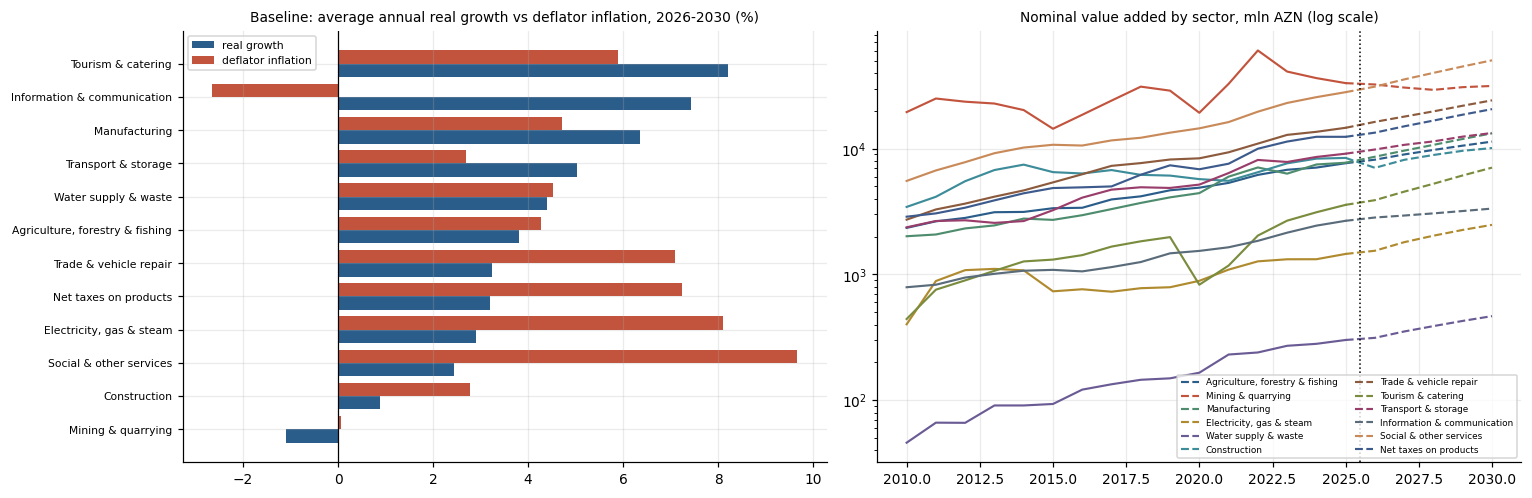

READING THE TABLES
  * Real growth is the volume story: ICT, transport and tourism lead; mining and construction contract.
  * Deflator inflation is the price story, and it differs sharply across sectors. Mining's deflator is
    set on world markets and tracks the manat oil price; the rest converge on CPI inflation.
  * Nominal growth, which is what budget revenue and wage bills are actually paid out of, is the sum of
    the two plus a small cross term. A sector can have weak real growth and strong nominal growth, or
    the reverse - which is exactly why all three are reported side by side rather than only real growth.


In [70]:
# Visual: real growth, deflator inflation and nominal growth decomposition by sector
nm = 'Baseline'
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
lbl = [ACCT_LABEL[k] for k in SEC_KEYS]
rg = [((ACC_FC[nm][k].real.iloc[-1]/ACC_HIST[k].real[LAST_ACT])**(1/len(FY))-1)*100 for k in SEC_KEYS]
dg = [((ACC_FC[nm][k].deflator.iloc[-1]/ACC_HIST[k].deflator[LAST_ACT])**(1/len(FY))-1)*100 for k in SEC_KEYS]
order = np.argsort(rg)
y = np.arange(len(order))
ax[0].barh(y-0.2, [rg[i] for i in order], height=0.4, color=PAL[0], label='real growth')
ax[0].barh(y+0.2, [dg[i] for i in order], height=0.4, color=PAL[1], label='deflator inflation')
ax[0].set_yticks(y); ax[0].set_yticklabels([lbl[i] for i in order], fontsize=7)
ax[0].axvline(0, color='k', lw=.8); ax[0].legend(fontsize=7)
ax[0].set_title(f'{nm}: average annual real growth vs deflator inflation, {FY[0]}-{FY[-1]} (%)', fontsize=9)
for i, k in enumerate(SEC_KEYS):
    hist = ACC_HIST[k].nominal.reindex(range(2010, LAST_ACT+1))
    fut = pd.concat([pd.Series({LAST_ACT: ACC_HIST[k].nominal[LAST_ACT]}), ACC_FC[nm][k].nominal])
    ax[1].plot(hist.index, hist.values, color=PAL[i % len(PAL)], lw=1.4)
    ax[1].plot(fut.index, fut.values, color=PAL[i % len(PAL)], lw=1.4, ls='--',
               label=ACCT_LABEL[k] if i < 12 else None)
ax[1].axvline(LAST_ACT+.5, color='k', ls=':', lw=1)
ax[1].set_yscale('log'); ax[1].set_title('Nominal value added by sector, mln AZN (log scale)', fontsize=9)
ax[1].legend(fontsize=5.8, ncol=2)
plt.tight_layout(); plt.show()

print(f'''READING THE TABLES
  * Real growth is the volume story: ICT, transport and tourism lead; mining and construction contract.
  * Deflator inflation is the price story, and it differs sharply across sectors. Mining's deflator is
    set on world markets and tracks the manat oil price; the rest converge on CPI inflation.
  * Nominal growth, which is what budget revenue and wage bills are actually paid out of, is the sum of
    the two plus a small cross term. A sector can have weak real growth and strong nominal growth, or
    the reverse - which is exactly why all three are reported side by side rather than only real growth.''')

## Hissə 17 — Uğursuz spesifikasiyalar və məhdudiyyətlər

### 17.1 Uğursuz spesifikasiyalar — açıqlanmış uğursuzluqların siyahısı

Modelin etibarlılığı onun açıqladığı uğursuzluqlar qədərdir. Bunların hər biri sınanmış, sübutlar əsasında rədd edilmiş və
əvəz olunmuşdur; rədd edilmiş nəticə notebook-da rədd edildiyi yerdə göstərilir.

| Nə uğursuz oldu | Sübut | Model bunun əvəzinə nə edir |
|---|---|---|
| İnflyasiya tənliyində **istehsal boşluğu** | Dörd ölçü sınanıb (Hissə 9.6). Sərbəst qiymətləndirilmiş istehsal funksiyası *mənfi* əmək elastikliyi verir; panel amil payları qoyulduqda illik −1.31% TFP və sürüşən "boşluq" alınır; xətti trend boşluğu əhəmiyyətsizdir; seqmentli trend boşluğu əhəmiyyətlidir, lakin məzənnə əmsalını mənfiyə çevirir, çünki onun qırılmaları devalvasiya ilə üst-üstə düşür. Proksi kimi kredit artımı *mənfi* işarə ilə daxil olur. | Tələb təzyiqi həddi yoxdur. İnflyasiya sırf xərc üzərinə əlavədir (markup). Fəallıq inflyasiyaya yenə də endogen əmək haqqı vasitəsilə təsir edir, lakin ayrıca istehsal boşluğu effekti müəyyən **edilmir**. |
| İnvestisiya tənliyində **kapitalın istifadə xərci** | Dörd ölçünün hamısında işarə səhvdir (Hissə 9.3). Dövlət investisiyası ümumi investisiyanın 53%-ni təşkil edir (2025). | Xaric edilib. Kredit həcmi həddi də buraxılıb: onun sərbəst qiyməti səhv işarəlidir, regional panel qiyməti 0.134 (buraxılış elastikliyi) isə aqreqat məlumatlarla rədd edilir (HAC-F p = 0.028). Kredit yumşalmasının investisiyaya təsiri yalnız işarələnmiş ekspert mülahizəsi əlavəsi kimi mövcuddur (Hissə 14). |
| Uçot dərəcəsinin bazar faiz dərəcələrinə **ötürülməsi** | İşarə səhvdir. 2016–17-ci illərdə uçot dərəcəsi müdafiə məqsədilə 15%-ə qaldırıldı, kredit faiz dərəcələri isə *azaldı*: bu nümunədə o, tənzimləyici dərəcə deyil, böhran alətidir. | Kredit faiz dərəcəsi **depozit faiz dərəcəsindən** asılıdır (uzunmüddətli 1.40) üstəgəl problemli kreditlər (NPL) mükafatı. Uçot dərəcəsi kredit **həcmlərinə** təsir edir, burada işarəsi düzgündür. |
| **Səviyyələrdə əməyə tələb** | VIF 20-dən yuxarıdır; ekstrapolyasiya edildikdə birinci proqnoz ilində işsizliyi 1 f.b.-dən çox dəyişdirdi. | Okun tipli **məşğulluq səviyyəsi** əlaqəsi, uzunmüddətli elastiklik 0.034. |
| **Sərbəst işçi qüvvəsi tənliyi** | Əhali elastikliyi illik 1.1% trendlə birlikdə 0.05-ə qədər düşür (VIF > 100). | Vahid əhali elastikliyi qoyulub; iştirak sürüşməsi illik +0.045% (iştirak səviyyəsi dəyişməzdir: 2010-cu ildə 51.35%, 2025-ci ildə 52.56%). |
| **Nisbi qiymət olmadan idxal** | İnvestisiya əmsalı *mənfidir* — kapital mallarının demək olar ki, hamısının idxal edildiyi şəraitdə bu mümkün deyil. | Real məzənnə həddi əlavə edilib. O, statik OLS-də işarəni bərpa edir, lakin uzunmüddətli DOLS qiyməti yenə də bir qədər mənfidir (−0.07, əhəmiyyətsiz; birinci fərqlərdə qiymət +0.55). Buna görə investisiya həddi çıxarılıb (səhv işarəli və əhəmiyyətsiz). |
| **Ev təsərrüfatlarının gəlirinin büdcə sosial xərclərindən asılılığı** (E3) | Sosial xərclər yalnız 2019-cu ildən mövcuddur: dörd parametr üçün n = 7, səhv işarəli (−0.10) əmsal və nümunədən kənar yoxlamada n = 2 (dəqiq uyğunluq). Əmək haqqı fondu + ümumi pensiya ödənişləri ilə əvəzləmə sonra homogenlik testindən keçmədi (cəm 0.62, rədd edildi) və statik həlldə istehlakı 23%-ə qədər aşağı proqnozlaşdırdı. | Qeyri-neft ÜDM + ümumi pensiya ödənişləri (orta pensiya × ümumi əhali — iş kitabında pensiyaçıların sayı yoxdur), kəsimdən əvvəlki sübutlar əsasında seçilib; homogenlik rədd edilmir və qoyulub (pay əlaqəsi). |
| İstehlakda **ex-post real faiz dərəcəsi** | Uzunmüddətli −0.019, fərqlərdə isə −0.001; o, hər inflyasiya sürprizini istehlak bumuna çevirirdi. | Çıxarılıb. |
| **Səhv işarəli, əhəmiyyətsiz uzunmüddətli hədlər** | Kənd təsərrüfatında kapital, idxalda investisiya, nəqliyyatda qeyri-neft ÜDM. | Nümunədən kənar yoxlamada kəsimdən əvvəlki məlumatlar üzrə yenidən tətbiq olunan qayda ilə çıxarılıb. |
| **Yanvar–aprel → tam il körpüsü (meyl 0.52)** | 2021-ci ilin baza effekti (turizm) ilə şərtlənib. 2022–25-ci illər üzrə dayanıqlı körpü 1:1-dən üstün deyil (HLN-DM birtərəfli p = 0.13). | 1:1 uyğunlaşdırma. |
| **Kreditin qeyri-neft ÜDM-dən asılılığı** (G1) | Qeyri-neft ÜDM depozitlərlə yanaşı səhv işarə ilə (−0.67) daxil oldu. | Çıxarılıb; miqyas depozitlər vasitəsilə daxil olur. |
| **Vahid ticarət elastikliyi, mədənçıxarmada CRS, emal sənayesində α_K = amil payı** | Əvvəllər "qoyulmuş" idi. Uzunmüddətli DOLS və kiçik nümunə üçün HAC-F altında hər üçü **rədd edilir**. | Sərbəst saxlanılıb. Qeyri-neft gəlirlərinin vahid elastikliyi (buoyancy) və dövlət investisiyasının neft gəlirlərinə görə vahid elastikliyi qoyulmuş olaraq qalır, lakin yalnız *rədd edilməmiş (aşağı güc)* kimi. |
| **Regional ticarət üzrə "çarpaz yoxlama"** | Regional ticarət əlavə dəyəri 63 region-ildən 58-ində pərakəndə dövriyyənin dəqiq 0.320 mislidir — bu, doldurulmuş (interpolyasiya) məlumatdır. | Sübut kimi geri götürülüb. |
| **Dövlət investisiyası üçün mexaniki resurs qaydası** | 2030-cu ilədək real dövlət investisiyasını ~30% azaldır və ÜDM-in ~3%-i həcmində profisit yaradır: bu, neytral əsas ssenari deyil, prosiklik qənaət siyasətinin proyeksiyasıdır. | Hər ssenari üzrə siyasət **səviyyəsi** müəyyən edilir; neft gəlirlərinin *kənarlaşmaları* onu qiymətləndirilmiş elastikliklə dəyişdirir və ötürülmə kanalı qorunur. |

Həlledici tərəfdə üç səhv də qeydə alınıb, çünki onların hər biri inandırıcı görünən, lakin səhv proqnozlar verirdi: **baza
düzəliş əmsallarının sönməsi** artıma +18%/−18% dalğalanma əlavə edirdi (baza düzəliş əmsalları sabit saxlanılır; yalnız natamam
il üzrə 2026 lövbər artımı sönür); bütün sistemi təkrarlayan düzəlişlərin həll yolu ilə tapılması **yığılmırdı (divergensiya)**,
onların bir irəli keçiddən götürülməsi isə **ikiqat hesablamaya** gətirirdi (məşğulluq işçi qüvvəsinin xətasını udurdu); **şok
hesablamalarının yenidən lövbərlənməsi** isə şoku ləğv edir və fiskal multiplikatoru həddindən artıq kiçik göstərirdi.

### 17.2 Məhdudiyyətlər

Hər biri ümumi qeyd-şərt deyil, konkretdir və məlumatlarla bağlı olduğu izlənilə bilər.

1. İş kitabında **xərclər–buraxılış (input–output) cədvəli yoxdur**, buna görə sektorlararası əlaqələr resurslar–istifadə
   (supply–use) matrisindən *ölçülmür*, zaman sıraları və panel kovariasiyası əsasında *qiymətləndirilir*. Bu, ən yüksək dəyərə
   malik məlumat əlavəsidir və hər halda siyasət modulunun FR2-si üçün tələb olunur.
2. İllik tezlikdə **sektor səviyyəsində məşğulluq yoxdur** — yalnız sənaye yarımsahələri (2016–2025) və regionlar (2021–2025). Tam
   sektor istehsal funksiyaları yalnız sənaye üçün qiymətləndirilə bilər; bu isə FR3 və FR4-ün (*sektorlar üzrə* əmək haqqı və
   məşğulluq) yalnız bu fayl əsasında nə təqdim edə biləcəyini birbaşa məhdudlaşdırır.
3. İş kitabının heç bir yerində **xarici tələb dəyişəni yoxdur**, buna görə o, istifadəçinin müəyyən etdiyi ssenari girişidir və
   qeyri-neft ixracı tənliyi yalnız təklif tərəfini əks etdirir.
4. **Müəyyən edilmiş faiz dərəcəsi və ya istehsal boşluğu kanalı yoxdur** (17.1). Model nə uçot dərəcəsi dəyişikliyini bazar faiz
   dərəcələri vasitəsilə, nə də inflyasiyaya sırf tələb təzyiqi təsirini simulyasiya edə bilir.
5. **Fiskal və tədiyə balansı nümunələrinin qısa olması** (2010-cu ildən 16 illik müşahidə) real blokla müqayisədə əhəmiyyətli
   dərəcədə daha geniş parametr qeyri-müəyyənliyinə səbəb olur.
6. **Regional panel cəmi beş il uzunluğundadır**; bir sıra əmsallar birtərəfli və ikitərəfli spesifikasiyalar arasında işarəsini
   dəyişir və bu, gizlədilmir, Hissə 8-də göstərilir.
7. **Məzənnə 2017-ci ildən faktiki olaraq sabitləşdirilib (de facto peg)**, buna görə ötürülmə demək olar ki, tamamilə 2015–16-cı
   illərin devalvasiyası əsasında müəyyən edilir. Məzənnəni dəyişən istənilən ssenari tək bir epizoddan ekstrapolyasiya edir.
8. **Sektor investisiya deflyatorları dərc olunmur**, buna görə aqreqat investisiya deflyatoru hər sektora tətbiq edilir.
9. **Zəncirvari həcmlər additiv deyil** (Hissə 3.5); qeyri-neft fərqi (wedge) üçün ölçüsü göstərilən kalibrlənmiş düzəliş istifadə olunur.
10. **Emal sənayesi, tikinti və nəqliyyat ən zəif proqnozlardır** (nümunədən kənar yoxlamada RMSE 16–22%), çünki onlar 2020-ci
    ildən sonra təklif tərəfində elə transformasiyadan keçib ki, 2021-ci ilədək olan əmsallar onu qabaqcadan görə bilməz. Ümumilikdə,
    median dəyişən üzrə model 2010–2019-cu illər üzrə qiymətləndirilmiş sabit artımdan **üstün deyil** (median U 1,09). Bu sektor
    trayektoriyaları həmin növ istehsal gücü şokunun təkrarlanmaması şərti ilə nəzərdən keçirilməlidir.
11. **Kalibrlənmiş paylar sabit saxlanılır** (sektor investisiya və kredit payları — v2.1-dən 2025-ci ilin faktiki səviyyəsində —, sosial xərclərin payı, borcun xidmət dərəcəsi); onlarda
    baş verən struktur dəyişikliklər nəzərə alınmır.
12. **Dövlət investisiyasının səviyyəsi proqnoz deyil, fərziyyədir** və hər tətbiq üçün qəsdən müəyyən edilməlidir.
13. **Kointeqrasiya yalnız bir neçə səviyyə əlaqəsi üçün təsdiqlənib** (audit cədvəlinə bax); səviyyə t-statistikalarının əksəriyyəti
    təsviri xarakter daşıyır və proqnoz səviyyəsi sabit düzəliş əmsalı fərziyyəsindən asılıdır (həssaslıq Hissə 13.1-də).
14. **Trend hesabına artım** — bir sıra sektorlarda 2027–2030-cu illər artımının böyük hissəsini qiymətləndirilmiş deterministik
    trend təşkil edir (Hissə 13.3).
15. **Güclü tələb dövrəsi**: ev təsərrüfatlarının gəliri indi qeyri-neft ÜDM ilə (homogenlik qoyulub), istehlak gəlirlə, ticarət,
    vergilər və xidmətlər isə istehlakla birlikdə hərəkət edir, buna görə şoklar və siyasət impulsları güclənir; emal sənayesi
    əlavə olaraq ixrac ↔ emal sənayesi əlaqəsi ilə güclənir (Hissə 13.2).
16. İnvestisiyada **aqreqat kredit kanalı yoxdur**; kredit yumşalmasının investisiyaya təsiri ekspert mülahizəsinə əsaslanan əlavədir.
17. İQİ və istehlak üçün **yelpiklər genişdir**, simulyasiya edilmiş təkrarlamaların təxminən 30%-i isə sıçrayış tavanı ilə
    kənarlaşdırılır (Hissə 13.4) — buna görə yelpiklər müəyyən qədər kəsilmişdir.

### 17.3 Modeli ən çox nə təkmilləşdirərdi

Sərf olunan səyin vahidinə düşən gözlənilən fayda sırası ilə:

1. **Resurslar–istifadə / xərclər–buraxılış cədvəli** — bu, qiymətləndirilmiş əlaqələri ölçülmüş əlaqələrlə əvəz edər və siyasət modulunun FR2-sini mümkün edərdi.
2. İllik tezlikdə **sektorlar üzrə məşğulluq və əməyin ödənişi** — bu, istehsal funksiyası blokunu tamamlayar və birbaşa FR3/FR4-ə xidmət edərdi.
3. **Tərəfdaş ölkələrin çəkiləri ilə xarici tələb** və tarixi sıraya malik idxal qiymətləri indeksi — bu, ticarət blokunun düzgün müəyyən edilməsinə imkan verərdi.
4. **Sektorlar üzrə rüblük milli hesablar** — bu, effektiv nümunəni təxminən dörd dəfə artırar və dinamikanı qoyulmuş deyil, qiymətləndirilə bilən edərdi.
5. **Sektor investisiya deflyatorları** — bu, ümumi deflyator fərziyyəsini aradan qaldırardı.

## Hissə 18 — v2: tənliklər reyestri, göstərici kataloqu, ssenari mühərriki və dayanıqlıq

Bu hissə modulun bütün qiymətləndirmələrini, proqnoz komponentlərini və həll alqoritmini maşın tərəfindən oxuna bilən
formada ixrac edir. Əvvəlki hissələrin heç bir nəticəsi dəyişdirilmir (bütün mövcud CSV faylları əvvəlki ilə eynidir);
burada yalnız yeni fayllar yaranır.

* **18.1–18.8 Tənliklər reyestri** (`output/FR1_equations.json`): notebook-da qiymətləndirilən **hər tənlik** — 47 proqnoz
  tənliyi və istehsal boşluğunun təsviri trendi, rədd edilmiş / namizəd / həssaslıq spesifikasiyaları, 2SLS (DWH qaydası) və
  3SLS diaqnostikası, SUR pay sistemləri, sənaye və regional panellər (Driscoll–Kraay, wild bootstrap), cari qiymətləndirmə (nowcast) körpüsü.
  Reyestr hər OLS/DOLS/2SLS/panel tənliyini statsmodels ilə müstəqil yenidən qiymətləndirir və əmsalların bu notebook-un
  əmsalları ilə üst-üstə düşdüyünü **təsdiq edir** (assert). Məhdudiyyət testləri yenidən hesablanır və mətnlə yoxlanılır;
  ≤2020 məlumatı ilə yenidən qiymətləndirmə və 2021–2025 dinamik nümunədən kənar yoxlama hər proqnoz tənliyinin `holdout`
  blokundadır.
* **18.9** Töhfələr və sektor artımının dekompozisiyası **bütün ssenarilər** üçün (əvvəl yalnız Əsas ssenari).
* **18.10–18.11 Ssenari mühərriki** (`microlib/engines/fr1.py`, vəziyyət `output/engine/FR1_state.json`): Hissə 11–16-nın
  həll alqoritmi (sönümlü Gauss–Seidel, eyniliklər, zəncirvari aqreqasiya, düzəliş əmsalları və 2026 ankor artımlarının
  yarımparçalanması 1 il olan sönməsi, dövlət investisiyasının siyasət səviyyəsi + neft gəlirləri sapması qaydası, TFP əlavəsi,
  əhali yolu) sətir-sətir köçürülüb. Redaktə edilə bilən: 2026–2030 baza fərziyyələri, hər həlledici əmsalı, rıçaqlar.
* **18.12–18.13** Göstərici kataloqu, tam proqnoz cədvəli (tarix + 3 ssenari × 2026–2030, Əsas ssenari üçün 5–95% zolaq),
  proqnozlaşdırılmayan komponentlər və tamlıq yoxlaması.
* **18.14–18.15** Dayanıqlıq xülasəsi, əmsal həssaslığı (±1 standart xəta, 2030) və ingilis mətnlərinin Azərbaycan dilində
  qarşılıqları.
* **18.16** Mühərrikin özünü yoxlaması: mühərrik bu notebook-un nəticələrini 1e-8 dəqiqliklə təkrarlamalıdır (assert).

In [71]:
# ==== Part 18.1 — Tənliklər reyestri: quraşdırma (v2) ====================================================
# Every equation estimated anywhere in this notebook is registered with microlib.registry: the 47 forecasting
# equations (+ the descriptive trend behind the output gap), every rejected / candidate / sensitivity
# specification, the 2SLS and 3SLS diagnostics, the SUR share systems, the industry and regional panels and the
# nowcast bridge. The registry re-estimates each OLS/DOLS/2SLS/panel equation independently with statsmodels and
# ASSERTS that the coefficients equal this notebook's (rel. 1e-6). Hold-out re-estimates (data <= CUT) and the
# dynamic 2021-2025 hold-out errors are attached as the `holdout` block of each forecasting equation.
import warnings as _w
try:
    import microlib
except ImportError:
    sys.path.insert(0, str(XL.parent.parent)); import microlib
from microlib.registry import EquationRegistry
from microlib.engines import _fr1_ids as IDS

RX = EquationRegistry('FR1', data_mode='OBSERVED')
SUBTASK_AZ = {'B hydrocarbon': 'B. Karbohidrogen bloku', 'C sector': 'C. Sektorlar (real əlavə dəyər)',
              'D demand': 'D. Tələb və istehlak bazarları', 'E income/labour': 'E. Gəlir və əmək bazarı',
              'F fiscal': 'F. Fiskal blok', 'G money/prices': 'G. Pul, kredit və qiymətlər'}
ST_PANEL, ST_SYS, ST_NOW = 'P. Panel bloku (texnologiya və regional elastikliklər)', \
    'S. Sistem qiymətləndirmə və endogenlik (2SLS/3SLS/SUR)', 'N. 2026-cı ilin cari qiymətləndirilməsi (nowcast)'
COEF_AZ = {
 'ln_brent': 'ln Brent qiyməti', 'ln_brent_lag': 'ln Brent qiyməti (t−1)', 'ln_oil': 'ln neft hasilatı',
 'ln_gas': 'ln qaz hasilatı', 'trend': 'xətti trend', 'trend_post2015': 'trend dəyişikliyi (2015-dən sonra)',
 'ln_K_agr': 'ln əsas fondlar (kənd təsərrüfatı)', 'ln_K_man': 'ln əsas fondlar (emal)',
 'ln_va_con': 'ln real tikinti əlavə dəyəri', 'ln_x_non': 'ln real qeyri-neft ixracı',
 'ln_va_agr': 'ln real kənd təsərrüfatı əlavə dəyəri', 'ln_gdpnon': 'ln real qeyri-neft ÜDM',
 'ln_gdpnon_pc': 'ln adambaşına real qeyri-neft ÜDM', 'ln_inv_state': 'ln real dövlət investisiyaları',
 'ln_inv_priv': 'ln real qeyri-dövlət investisiyaları', 'ln_cons': 'ln real istehlak',
 'ln_hhdisp_pc': 'ln adambaşına real sərəncamda qalan gəlir', 'ln_hc': 'ln karbohidrogen tranziti (neft + 0,9×qaz)',
 'ln_K_ict_pc': 'ln adambaşına İKT əsas fondları', 'ln_m_non': 'ln real qeyri-neft idxalı',
 'ln_cred_hh_pc': 'ln adambaşına real ev təsərrüfatı krediti', 'ln_cred': 'ln real kreditlər',
 'ln_va_man': 'ln real emal əlavə dəyəri', 'ln_inv_non': 'ln real qeyri-neft investisiyaları',
 'ln_relprice': 'ln nisbi qiymət (real məzənnə proksisi)', 'ln_prod_non': 'ln qeyri-neft əmək məhsuldarlığı',
 'ln_cpi': 'ln istehlak qiymətləri indeksi', 'ln_minwage': 'ln minimum əmək haqqı',
 'ln_g_rel': 'ln (qeyri-neft ÜDM / real pensiya fondu)', 'ln_pens_r': 'ln real pensiya fondu',
 'ln_xoil_azn': 'ln karbohidrogen ixracı (AZN)', 'ln_rev_r': 'ln real büdcə gəlirləri',
 'ln_rev_oil': 'ln real neft-qaz gəlirləri', 'ln_dep_r': 'ln real depozitlər', 'polrate': 'uçot dərəcəsi, %',
 'ln_cred_tot_r': 'ln real kreditlər', 'ln_hhdisp': 'ln real sərəncamda qalan gəlir', 'deprate': 'depozit faizi, %',
 'npl_ratio': 'problemli kreditlərin payı, %', 'dln_fx': 'məzənnə dəyişməsi, %', 'dln_wage': 'əmək haqqı artımı, %',
 'infl': 'İQİ inflyasiyası, %', 'dln_oil_azn': 'manatla neft qiymətinin dəyişməsi, %',
 'realrate': 'real faiz dərəcəsi, %', 'ln_oil_rel': 'ln (neft / qaz hasilatı)', 'gap': 'istehsal boşluğu',
 'dln_credit': 'real kredit artımı, %', 'ln_K': 'ln əsas fondlar', 'ln_emp': 'ln məşğulluq', 'ln_lf': 'ln işçi qüvvəsi',
 'ln_rwage': 'ln real əmək haqqı', 'ln_pop': 'ln əhali', 'ln_gva': 'ln əlavə dəyər', 'ln_prod': 'ln məhsuldarlıq',
 'ln_credit': 'ln kreditlər (region)', 'ln_inv': 'ln investisiyalar (region)', 'ln_pubinv': 'ln dövlət investisiyası',
 'ln_wage': 'ln əmək haqqı', 'ln_retail': 'ln pərakəndə dövriyyə', 'ln_out_lvl': 'ln ümumi məhsul (region)',
 'g_apr': 'yanvar–aprel artımı, %', 'seg2015': 'trend × 2015-dən sonra', 'seg2020': 'trend × 2020-dən sonra',
 'wb': 'ln real əmək haqqı fondu', 'soc': 'ln real sosial xərclər', 'g': 'ln real qeyri-neft ÜDM',
 'pen': 'ln real pensiya fondu', 'pb': 'ln real pensiya fondu', 'ucc_nom': 'nominal kredit faizi',
 'ucc_gdpdef': 'real faiz (ÜDM deflyatoru ilə)', 'ucc_smooth': 'real faiz (3 illik inflyasiya ilə)'}
COEF_AZ.update({  # v2.2
 'dln_payroll': 'əmək haqqı fondunun artımı (orta əmək haqqı × məşğulluq), %', 'dln_dsmf': 'DSMF xərclərinin artımı, %',
 'dln_gdpnon_n': 'nominal qeyri-neft ÜDM-in artımı, %', 'dln_pension': 'orta pensiyanın artımı, %',
 'dln_xpi': 'karbohidrogen ixrac qiymətləri indeksinin dəyişməsi (ABŞ dolları), %',
 'ln_absorb': 'ln real udma (istehlak + qeyri-neft investisiyası)', 'ln_reer': 'ln real effektiv məzənnə'})
COEF_AZ.update({  # v2.3
 'ln_relprice_usd': 'ln nisbi qiymət (ÜDM deflyatoru / məzənnə): idxal həcminin elastikliyi',
 'ln_wagebill_r': 'ln real əmək haqqı fondu (orta əmək haqqı × məşğulluq)',
 'ln_wb_rel': 'ln (real əmək haqqı fondu / real pensiya fondu)', 'ln_rev_non_r': 'ln real qeyri-neft gəlirləri',
 'ln_rev_oil_r': 'ln real neft-qaz gəlirləri'})
COEF_AZ.update({  # v2.3.3
 'dln_fx_L1': 'məzənnə dəyişməsi, əvvəlki il, %', 'dln_pm_azn': 'idxal qiymətlərinin manatla artımı (ABŞ dolları ilə idxal qiymətləri + məzənnə), %',
 'dln_pm_azn_L1': 'idxal qiymətlərinin manatla artımı, əvvəlki il, %', 'fx_post15': 'məzənnə dəyişməsi × 2015-dən sonrakı rejim, %',
 'fx_post15_L1': 'məzənnə dəyişməsi × 2015-dən sonrakı rejim, əvvəlki il, %',
 'dln_pm_dsk': 'idxal qiymətlərinin manatla artımı (2021–25 DSK indeksi ilə), %', 'dln_pm_dsk_L1': 'idxal qiymətlərinin manatla artımı (DSK), əvvəlki il, %'})
NEG_SIGN = {'realrate', 'polrate', 'ln_relprice', 'ucc_nom', 'ucc_gdpdef', 'ucc_smooth'}


def sign_exp(eq, names):
    out = {}
    for c in names:
        if c in ('const', 'trend', 'trend_post2015', 'seg2015', 'seg2020') or (eq == 'C12_nettax' and c == 'ln_m_non'):
            continue
        out[c] = -1 if c in NEG_SIGN else +1
    return out


def est_label(fit):
    s = fit.estimator
    if s.startswith('DOLS(+/-1)'): return 'DOLS(±1)'
    if s.startswith('DOLS(0'): return 'DOLS(0)'
    return 'OLS'


def nb_diag(e):
    '''The notebook's own register() diagnostics, stored beside the registry's recomputation.'''
    f = lambda v: None if v is None or not np.isfinite(v) else float(v)
    return {'dw_levels': f(e['dw']), 'eg_coint_p': f(e['eg_p']), 'jb_p': f(e['jb_p']), 'bp_fitted_p': f(e['bp_p']),
            'r2_levels': f(e['r2']), 'resid_rho': f(e['rho']), 'n_levels': int(e['n']), 'n_est': int(e['n_est']),
            'df': int(e['df']), 'estimator_nb': e['estimator'], 'difftab': e['difftab']}


def fit_kw(fit, kind):
    '''Registry options reproducing the notebook's long-run / rate conventions.'''
    kw = dict(det=list(DET), cov='hac')
    if kind == 'rate':
        kw['coint'] = False
    elif not fit.stoch:            # only deterministic regressors: the notebook's EG uses N=1 (stored in extra)
        kw.update(coint=True, n_i1=0)
    return kw
print("registry set up:", RX.module, RX.data_mode)

registry set up: FR1 OBSERVED


In [72]:
# ==== Part 18.2 — forecasting equations: titles, components (indicator ids), notes ==========================
A = IDS.acc_id
EQMETA = {
 'B1_oil_price': ('Azərbaycan neftinin ixrac qiyməti', 'Oil export price', 'ln neftin ixrac qiyməti',
                  ['fr1:oil_exp_price', 'fr1:x_g_oil_usd', A('x_oil', 'nominal')], 'Brent qiymətinin ötürülməsi.'),
 'B2_mining': ('Mədənçıxarma: real əlavə dəyər', 'Mining real value added', 'ln real mədənçıxarma ƏD',
               ['fr1:rva_min', A('va_min', 'real')], 'Həcm (neft və qaz hasilatı) ilə müəyyən olunur.'),
 'B3_oilgdp': ('Real neft-qaz ÜDM', 'Real oil-gas GDP', 'ln real neft-qaz ÜDM',
               ['fr1:rgdpoil', A('gdpoil', 'real')], 'Mədənçıxarmadan genişdir: emal və neft xidmətləri daxildir.'),
 'C1_agr': ('Kənd təsərrüfatı: real əlavə dəyər', 'Agriculture real value added', 'ln real k/t ƏD',
            ['fr1:rva_agr', A('va_agr', 'real')], 'Hava şəraiti qalıqdadır; kapital əmsalı yanlış işarəli olduğundan çıxarılıb.'),
 'C3_man': ('Emal sənayesi: real əlavə dəyər', 'Manufacturing real value added', 'ln real emal ƏD',
            ['fr1:rva_man', A('va_man', 'real')], 'Kapital + tikinti + ixrac tələbi; spesifikasiya ≤2020 məlumatla seçilib.'),
 'C4_elc': ('Elektrik enerjisi, qaz: real əlavə dəyər', 'Electricity real value added', 'ln real elektrik ƏD',
            ['fr1:rva_elc', A('va_elc', 'real')], 'Törəmə tələb: qeyri-neft fəallığı + trend.'),
 'C5_wat': ('Su təchizatı: adambaşına real əlavə dəyər', 'Water supply real VA per capita', 'ln adambaşına real su ƏD',
            ['fr1:rva_wat', A('va_wat', 'real')], 'Adambaşına forma vahid əhali elastikliyini tətbiq edir.'),
 'C6_con': ('Tikinti: real əlavə dəyər', 'Construction real value added', 'ln real tikinti ƏD',
            ['fr1:rva_con', A('va_con', 'real')], 'Dövlət və qeyri-dövlət investisiyaları ayrıca.'),
 'C7_trd': ('Ticarət: real əlavə dəyər', 'Trade real value added', 'ln real ticarət ƏD',
            ['fr1:rva_trd', A('va_trd', 'real')], 'Vahid elastiklik rədd edilib, sərbəst qiymətləndirilir.'),
 'C8_tou': ('Turizm və iaşə: adambaşına real əlavə dəyər', 'Tourism real VA per capita', 'ln adambaşına real turizm ƏD',
            ['fr1:rva_tou', A('va_tou', 'real')], 'Gəlir elastikliyi > 1 (üstün nemət).'),
 'C9_tra': ('Nəqliyyat və anbar: real əlavə dəyər', 'Transport real value added', 'ln real nəqliyyat ƏD',
            ['fr1:rva_tra', A('va_tra', 'real')], 'Karbohidrogen tranziti ≤2020 sübutu ilə saxlanılıb; qeyri-neft ÜDM yanlış işarəli olduğundan çıxarılıb.'),
 'C10_ict': ('İnformasiya və rabitə: adambaşına real əlavə dəyər', 'ICT real VA per capita', 'ln adambaşına real İKT ƏD',
             ['fr1:rva_ict', A('va_ict', 'real')], 'İKT kapitalının dərinləşməsi + texniki tərəqqi.'),
 'C11_oth': ('Sosial və digər xidmətlər: adambaşına real əlavə dəyər', 'Other services real VA per capita',
             'ln adambaşına real digər xidmətlər ƏD', ['fr1:rva_oth', A('va_oth', 'real')], 'Gəlir + trend.'),
 'C12_nettax': ('Məhsula xalis vergilər (real)', 'Real net taxes on products', 'ln real xalis vergilər',
                ['fr1:rva_nettax', A('va_nettax', 'real')], 'Real blok ilə fiskal blok arasında əlaqə.'),
 'D1_cons': ('Ev təsərrüfatlarının istehlakı (adambaşına)', 'Household consumption per capita', 'ln adambaşına real istehlak',
             ['fr1:rcons', A('cons_mkt', 'real'), 'fr1:rretail', 'fr1:rcater', 'fr1:rserv_hh'],
             'Ex post real faiz çıxarılıb (artefakt); bazarların payı 3 illik ortada sabitdir.'),
 'D2_inv': ('Qeyri-neft investisiyaları (real)', 'Real non-oil investment', 'ln real qeyri-neft investisiyaları',
            ['fr1:rinv_non', 'fr1:rinv_tot', 'fr1:rinv_priv', A('inv_non', 'real')],
            'Akselerator + dövlət investisiyası; kredit həddi rədd edilib (0 qəbul olunub).'),
 'D3_xnon': ('Qeyri-neft mal ixracı (real)', 'Real non-oil goods exports', 'ln real qeyri-neft ixracı',
             ['fr1:rx_non', A('x_non', 'real')], 'Tərəfdaş tələbi məlumatı yoxdur: xarici tələb ssenari dəyişənidir.'),
 'D4_mnon': ('Qeyri-neft mal idxalı (real)', 'Real non-oil goods imports',
             'ln qeyri-neft idxalı sabit ABŞ dolları qiymətləri ilə (= ln real idxal + ln nisbi qiymət)',
             ['fr1:rm_non', A('m_non', 'real')], 'v2.3: idxal həcmi forması — real idxal ÜDM deflyatoru ilə hesablandığından '
             'ln nisbi qiymət asılı dəyişənə tərif üzrə −1 əmsalı ilə daxildir; həcm elastikliyi müsbətdir, həlledici eyni '
             'qiymətləndirmədən c − 1 əmsalını istifadə edir. İnvestisiya həddi yanlış işarəli olduğundan çıxarılıb.'),
 'E1_emp': ('Məşğulluq səviyyəsi (Okun tipli əlaqə)', 'Employment rate (Okun-type)', 'ln məşğulluq / işçi qüvvəsi',
            ['fr1:emp', 'fr1:unemp', A('emp', 'real'), A('unemp', 'real')], 'Səviyyələrdə əmək tələbi forması rədd edilib.'),
 'E2_wage': ('Orta nominal əmək haqqı', 'Average nominal wage', 'ln orta nominal əmək haqqı',
             ['fr1:wage', 'fr1:rwage', A('wage', 'nominal'), A('wagebill', 'nominal')],
             'Məhsuldarlıq + qiymətlər + minimum əmək haqqı (siyasət aləti).'),
 'E3_hhdisp': ('Ev təsərrüfatlarının real sərəncamda qalan gəliri', 'Real household disposable income',
               'ln real gəlir − ln real pensiya fondu', ['fr1:rhhdisp'],
               'v2.3: real əmək haqqı fondu əlavə olunub (minimum əmək haqqı / əmək haqqı kanalı); üç gəlir mənbəyi üzrə '
               'homogenlik tətbiq olunub; pensiya fondu = orta pensiya × əhali (proksi).'),
 'E4_lf': ('İşçi qüvvəsində iştirak səviyyəsi', 'Labour-force participation', 'ln işçi qüvvəsi / əhali',
           ['fr1:lf', 'fr1:unemp', A('lf', 'real')], 'Vahid əhali elastikliyi tətbiq olunub; yalnız trend qiymətləndirilir.'),
 'F1_revoil': ('Neft-qaz büdcə gəlirləri', 'Oil and gas budget revenue', 'ln neft-qaz gəlirləri',
               ['fr1:rev_oil_n', A('rev_oil', 'nominal')], 'Neft qiymətinin daxili iqtisadiyyata əsas kanalı.'),
 'F2_revnon': ('Qeyri-neft büdcə gəlirləri (real)', 'Real non-oil revenue', 'ln real qeyri-neft gəlirləri − ln qeyri-neft ÜDM',
               ['fr1:rrev_nonoil', 'fr1:rev_tot_n', A('rev_non', 'real'), A('rev_tot', 'nominal')],
               'Qeyri-neft ÜDM üzrə vahid elastiklik rədd edilmədiyi üçün tətbiq olunub.'),
 'F3_expcur': ('Cari büdcə xərcləri (real)', 'Real current expenditure', 'ln real cari xərclər',
               ['fr1:rexp_cur', 'fr1:rexp_soc', 'fr1:exp_tot_n', 'fr1:balance_n', 'fr1:debt_azn', A('exp_cur', 'real')],
               'Fiskal reaksiya funksiyası.'),
 'F4_pubinv': ('Dövlət investisiyaları (reaksiya funksiyası)', 'Public investment reaction function',
               'ln real dövlət investisiyaları − ln real neft gəlirləri', ['fr1:rinv_state', A('inv_state', 'real')],
               'Proqnozda siyasət səviyyəsi verilir; neft gəlirlərinin sapması bu elastikliklə ötürülür.'),
 'G1_credit': ('Ümumi kreditlər (real)', 'Real total credit', 'ln real kreditlər',
               ['fr1:rcred_tot', A('cred_tot', 'real')] + [IDS.cred_id(s) for s in ('trd', 'ene', 'agr', 'con', 'ind', 'tra', 'oth')],
               'Qeyri-neft ÜDM yanlış işarəli olduğundan çıxarılıb; miqyas depozitlər vasitəsilə.'),
 'G2_credhh': ('Ev təsərrüfatlarına kreditlər (real)', 'Real household credit', 'ln real ev təsərrüfatı krediti',
               ['fr1:rcred_hh', A('cred_hh', 'real')], ''),
 'G3_lendrate': ('Kreditlər üzrə orta faiz', 'Average lending rate', 'kredit faizi, %',
                 ['fr1:lendrate', 'fr1:realrate', A('lendrate', 'real')],
                 'Uçot dərəcəsinin ötürülməsi rədd edilib; maliyyələşmə xərci + risk mükafatı.'),
 'G4_infl': ('İQİ inflyasiyası (struktur xərc əlavəsi)', 'CPI inflation (cost markup)', 'İQİ inflyasiyası, %',
             ['fr1:infl', 'fr1:cpi', 'fr1:p_cons', 'fr1:p_inv', A('cpi', 'deflator')],
             'v2.3.3: idxal qiymətlərinin manatla artımı (cari + əvvəlki il; izahedici dəyişənin gecikməsi) + əmək haqqı; '
             'gecikmiş inflyasiya və istehsal boşluğu yoxdur.'),
 'G6_defl_gdp': ('ÜDM deflyatoru (yalnız hesabat üçün)', 'GDP deflator (reported only)', 'ÜDM deflyatoru inflyasiyası, %',
                 ['fr1:p_gdp'], 'Həlledici ÜDM deflyatorunu sektor deflyatorlarından qurur; bu tənlik proqnozda istifadə olunmur.'),
 'G7_dep': ('Depozit bazası (real)', 'Real deposits', 'ln real depozitlər', ['fr1:rdep_tot', A('dep_tot', 'real')],
            'Kredit təklifinin maliyyələşmə məhdudiyyəti.'),
 'POT': ('Təsviri potensial trend (istehsal boşluğu üçün)', 'Descriptive trend for the output gap',
         'ln real qeyri-neft ÜDM', ['fr1:gap'], 'Yalnız təsviri; heç bir tənliyə daxil olmur.'),
}
_LEGMETA = {'E3a_wb': ('Ev təsərrüfatlarının gəliri: işçilərə əmək ödənişləri', 'Household income: compensation of employees',
                       'əmək ödənişlərinin artımı, %'),
            'E3b_tr': ('Ev təsərrüfatlarının gəliri: alınmış transfertlər', 'Household income: transfers received',
                       'transfertlərin artımı, %'),
            'E3c_oth': ('Ev təsərrüfatlarının gəliri: sahibkarlıq və mülkiyyət gəlirləri',
                        'Household income: entrepreneurial and property income', 'digər gəlirlərin artımı, %'),
            'E3d_dsmf': ('DSMF xərcləri (körpü tənliyi)', 'DSMF expenditure (bridge)', 'DSMF xərclərinin artımı, %')}
for _nm, (_ta, _te, _dep) in _LEGMETA.items():   # v2.2: macro-module income legs (not used in the forecast: Part 11.6)
    EQMETA[_nm] = (_ta, _te, _dep, ['fr1:rhhdisp'], 'v2.2: makro modulun gəlir bölgüsü; dinamik nümunədən kənar yoxlamada '
                   'real gəlir pisləşdiyi üçün proqnozda istifadə olunmur (mühərrikdə income_block = legs rıçağı)')
for _s in COMP:
    EQMETA[f'G5_defl_{_s}'] = (f'Deflyator inflyasiyası: {IDS.SEC_AZ[_s]}', f'Deflator inflation: {SECT_LABEL[_s]}',
                               'deflyator inflyasiyası, %', [f'fr1:p_{_s}', A(f'va_{_s}', 'deflator')],
                               ('v2.2: makro modulun forması — karbohidrogen ixrac qiymətləri indeksi (ixrac dəyəri ilə çəkili, '
                                'ABŞ dolları) və məzənnə; İQİ həddi yoxdur.') if _s == 'min' else '')
MKT_AZ = {'retail': 'Pərakəndə ticarət', 'cater': 'İctimai iaşə', 'serv_hh': 'Əhaliyə ödənişli xidmətlər'}
for _k in MKT:
    EQMETA[f'G5_defl_{_k}'] = (f'Deflyator inflyasiyası: {MKT_AZ[_k]}', f'Deflator inflation: {MKT_LABEL[_k]}',
                               'deflyator inflyasiyası, %', [f'fr1:p_{_k}', {'retail': 'fr1:rretail', 'cater': 'fr1:rcater',
                                                                           'serv_hh': 'fr1:rserv_hh'}[_k], A(_k, 'deflator')], '')
EQVAR = {eq: v for v, eq in EQ_OF_VAR.items()}
EQVAR.update({f'G5_defl_{s}': f'p_{s}' for s in COMP}); EQVAR.update({f'G5_defl_{k}': f'p_{k}' for k in MKT})
EQVAR['B1_oil_price'] = 'oil_exp_price'
assert set(REG) | {'POT'} == set(EQMETA), set(REG) ^ set(EQMETA)
print(len(EQMETA), "forecasting / reported equations described")

52 forecasting / reported equations described


In [73]:
# ==== Part 18.3 — restriction tests (recomputed and checked against the notebook text) and hold-out blocks ====
def _imp(nm): return 'IMPOSED' in (REG[nm]['restriction'] or '')


def _chk(nm, frag):
    assert frag in (REG[nm]['restriction'] or ''), (nm, frag, REG[nm]['restriction'])


def restriction_tests(nm):
    e = REG[nm]; out = []
    yd, Xd = e['diff'] if e['diff'] is not None else (e['y'], e['X'])
    def wt(f, R, q, txt, imposed, nb_frag=True):
        F, p = wald_test(f, R, q); se = comb_se(f, R)
        if nb_frag: _chk(nm, f"HAC-F={F:.2f} p={p:.3f}")
        out.append(dict(text_az=txt, test='HAC-F (kiçik nümunə)', stat=float(F), p=float(p), imposed=bool(imposed),
                        se_tested_combination=float(se)))
    if nm == 'B1_oil_price':
        f = lr_fit(yd, Xd); wt(f, [0, 1], [1.0], 'Brent qiymətinin vahid ötürülməsi (β = 1)', False)
    elif nm in ('B2_mining', 'B3_oilgdp'):
        f = lr_fit(yd, Xd); R = np.zeros(len(f.beta)); R[f.names.index('ln_oil')] = R[f.names.index('ln_gas')] = 1
        wt(f, R, [1.0], 'Miqyasa görə sabit gəlir: neft + qaz elastiklikləri = 1', _imp(nm))
    elif nm == 'C3_man':
        f = lr_fit(yd, Xd); aK = CTX_FULL['alpha'][1]; R = np.zeros(len(f.beta)); R[1] = 1
        wt(f, R, [aK], f'Kapital elastikliyi = gəlir payı α_K = {aK:.2f} (sənaye panelindən)', _imp(nm))
    elif nm == 'C7_trd':
        f = lr_fit(yd, Xd); wt(f, [0, 1], [1.0], 'İstehlaka görə vahid elastiklik', _imp(nm))
    elif nm == 'E3_hhdisp':
        f = lr_fit(yd, Xd); wt(f, [0] + [1]*(len(f.beta) - 1), [1.0],
                               'Homogenlik: qeyri-neft ÜDM + pensiya fondu' + (' + əmək haqqı fondu' if 'ln_wagebill_r' in Xd else '')
                               + ' elastiklikləri = 1', _imp(nm))
    elif nm == 'F2_revnon':
        f = lr_fit(yd, Xd); wt(f, [0, 1, 0], [1.0], 'Qeyri-neft ÜDM-ə görə vahid vergi elastikliyi', _imp(nm))
    elif nm == 'F4_pubinv':
        f = lr_fit(yd, Xd); wt(f, [0, 1], [1.0], 'Real neft gəlirlərinə görə vahid elastiklik', _imp(nm))
    elif nm == 'G5_defl_oth':
        yu, Xu = np.log(D.p_oth).diff()*100, pd.DataFrame({'infl': D.infl})
        f = rate_fit(yu, Xu); wt(f, np.eye(2), [0.0, 1.0], 'Birgə: sabit = 0 və İQİ ötürülməsi = 1', False)
        F1, p1 = restrict_row(f, 'infl', 1.0); _chk(nm, f"alone: p={p1:.3f}")
        out.append(dict(text_az='İQİ-nin vahid ötürülməsi (tək)', test='HAC-F (kiçik nümunə)', stat=float(F1),
                        p=float(p1), imposed=True))
    elif nm == 'D2_inv':
        f = lr_fit(yd, Xd); i = f.names.index('ln_cred'); _chk(nm, f"{f.beta[i]:+.3f} (p={f.pval[i]:.3f})")
        out.append(dict(text_az=f'Sərbəst kredit elastikliyi {f.beta[i]:+.3f} (p={f.pval[i]:.3f}): müsbət və p<0,10 '
                        'olmadığı üçün kredit həddi çıxarılıb (0)', test='t (HAC)', stat=float(f.tstat[i]),
                        p=float(f.pval[i]), imposed=True))
        R = np.zeros(len(f.beta)); R[i] = 1
        wt(f, R, [CRED_EL_OUT], f'Kredit elastikliyi = regional panel dəyəri {CRED_EL_OUT:.3f}', False)
    if nm in ('C1_agr', 'C9_tra', 'D4_mnon', 'D1_cons'):
        exp = {'C1_agr': {'ln_K_agr': +1}, 'C9_tra': {'ln_gdpnon': +1}, 'D4_mnon': {'ln_inv_non': +1},
               'D1_cons': {'ln_cred_hh_pc': +1}}[nm]
        f = lr_fit(yd, Xd)
        for c, sg in exp.items():
            i = f.names.index(c); drop = bool(np.sign(f.beta[i]) != sg and f.pval[i] > .10)
            if drop: _chk(nm, f"{c} ({f.beta[i]:+.3f}, p={f.pval[i]:.2f})")
            out.append(dict(text_az=f"İşarə qaydası: {COEF_AZ.get(c, c)} = {f.beta[i]:+.3f} (p={f.pval[i]:.2f}); "
                            + ('yanlış işarəli və əhəmiyyətsiz — çıxarılıb' if drop else 'saxlanılıb'),
                            test='t (HAC)', stat=float(f.tstat[i]), p=float(f.pval[i]), imposed=drop))
    if nm == 'D4_mnon' and 'ln_relprice_usd' in e['X']:     # v2.3: sign rule on the import-VOLUME price elasticity
        f = lr_fit(e['y'], Xd.rename(columns={'ln_relprice': 'ln_relprice_usd'})); i = f.names.index('ln_relprice_usd')
        out.append(dict(text_az=f"İşarə qaydası: {COEF_AZ['ln_relprice_usd']} = {f.beta[i]:+.3f} (p={f.pval[i]:.2f}); saxlanılıb",
                        test='t (HAC)', stat=float(f.tstat[i]), p=float(f.pval[i]), imposed=False))
    if 'population elasticity' in e['imposed']:
        out.append(dict(text_az='Vahid əhali elastikliyi (adambaşına forma)', test=None, stat=None, p=None, imposed=True))
    return out


YH = list(range(CUT+1, LAST_ACT+1))
HOT_LBL = {v: k for k, v in TARGETS.items()}


def holdout_block(nm):
    v = EQVAR.get(nm)
    blk = dict(cut=CUT, years=YH, rmse=None, theil_u_rw=None, theil_u_const=None, dm_p_rw=None, variable=v,
               mode_az='dinamik simulyasiya 2021–2025: ≤2020 məlumatla yenidən qiymətləndirilmiş bütün model, '
                       'faktiki ekzogen yollar, dövlət investisiyası F4 ilə endogen')
    if nm in RES_CUT:
        cfc = MODEL_CUT[nm]['cf']; cff = MODEL[nm]['cf']
        com = [k for k in cff.index if k != 'const' and k in cfc.index]
        blk['reestimated'] = dict(coef_cut={k: float(x) for k, x in cfc.items()}, estimator_cut=MODEL_CUT[nm]['estimator'],
                                  df_cut=int(RES_CUT[nm]['fit'].dof), restriction_cut_en=RES_CUT[nm]['restriction'],
                                  signs_agree=bool(all(np.sign(cff[k]) == np.sign(cfc[k]) for k in com)))
        if nm in HOCOEF.index: assert blk['reestimated']['signs_agree'] == bool(HOCOEF.loc[nm, 'signs_agree'])
    if v is None or v not in HO.columns or v not in D.columns: return blk
    act, mod, modp = D[v].loc[YH], HO[v].loc[YH], HO_POL[v].loc[YH]
    h = np.arange(1, len(YH)+1)
    if v in ('infl', 'lendrate'):
        e_m, e_p, e_rw, e_cg = mod - act, modp - act, D[v][CUT] - act, None
        blk['units_az'] = 'faiz bəndi'
    else:
        e_m, e_p = (mod/act-1)*100, (modp/act-1)*100
        e_rw = (pd.Series(D[v][CUT], index=YH)/act-1)*100
        cg = pd.Series(D[v][CUT]*(1 + (D[v][2019]/D[v][2010])**(1/9) - 1)**h, index=YH)
        e_cg = (cg/act-1)*100 if cg.notna().all() else None
        blk['units_az'] = '% (səviyyə xətası)'
    r = lambda e: float(np.sqrt((np.asarray(e, float)**2).mean()))
    blk.update(rmse=r(e_m), theil_u_rw=r(e_m)/r(e_rw) if r(e_rw) > 0 else None,
               theil_u_const=(r(e_m)/r(e_cg) if e_cg is not None and r(e_cg) > 0 else None),
               dm_p_rw=hln_dm(e_m, e_rw)[1], dm_p_const=(hln_dm(e_m, e_cg)[1] if e_cg is not None else None),
               err_2025=float(e_m.iloc[-1]), mae=float(np.abs(e_m).mean()), rmse_policy_variant=r(e_p),
               benchmarks_az='təsadüfi gəzişmə 2020-dən; sabit artım 2010–2019')
    if v in HOT_LBL:
        hr = HOT.loc[HOT_LBL[v]]
        for a_, b_ in (('rmse', 'model_RMSE'), ('theil_u_rw', 'U_rw2020'), ('theil_u_const', 'U_cg1019'),
                       ('dm_p_rw', 'DM_p_rw2020')):
            assert abs(blk[a_] - hr[b_]) <= 1e-9*max(1, abs(hr[b_])), (nm, a_, blk[a_], hr[b_])
    return blk
print("restriction tests and hold-out blocks defined")

restriction tests and hold-out blocks defined


In [74]:
# ==== Part 18.4 — register the forecasting equations (estimated form; solver coefficients in extra.cf) ========
def cf_structure(nm):
    '''Which solver coefficients are estimated, fixed by a restriction, or derived from an estimated one.'''
    e, cf = REG[nm], CF[nm]
    if e['to_cf'] is None: return {}, {}
    b = pd.Series(e['fit'].beta, index=e['fit'].names); fixed, derived = {}, {}
    for k in cf.index:
        if k in b.index: continue
        moved = {}
        for j in b.index:
            bb = b.copy(); bb[j] += 1.0
            dv = float(e['to_cf'](bb)[k] - cf[k])
            if abs(dv) > 1e-12: moved[j] = dv
        if len(moved) == 1:
            (j, dv), = moved.items(); derived[k] = (j, float(np.sign(dv)))
        elif moved:                                   # v2.3: e.g. E3 ln_pens_r = 1 - ln_g_rel - ln_wb_rel
            js = sorted(moved); derived[k] = (js, [float(np.sign(moved[j])) for j in js])
        else:
            fixed[k] = float(cf[k])
    return fixed, derived


# v2.2: equations estimated but not used by the solver (G6 reported only; the income legs or E3, by E3_MODE)
UNUSED_EQ = {'G6_defl_gdp'} | (set(E3_GROWTH_EQ) if E3_MODE == 'share' else {'E3_hhdisp'})
USED = {nm: nm not in UNUSED_EQ for nm in REG}
V22_EXTRA = {'E3_hhdisp': 'E3: income legs (macro module, nominal)', 'G5_defl_min': 'G5 mining: export price index + exchange rate (macro module)',
             'D4_mnon': 'D4 imports: absorption + REER (macro module)'}
V22_EXTRA.update({nm: 'E3: income legs (macro module, nominal)' for nm in E3_GROWTH_EQ})
def v23_extra(eq, lbl=None):
    '''v2.3 hold-out comparison (Part 11.7) and decision rows (Part 14.1) of an equation's candidates.'''
    lbls = [l for l, v in VARIANTS23.items() if v[0] == eq] if lbl is None else [lbl]
    t = CMP23[CMP23.variant.isin(lbls + ['v2.2 model (before v2.3)'])]
    clean = lambda rec: {k: (None if isinstance(v, float) and not np.isfinite(v) else v) for k, v in rec.items()}
    return {'holdout_comparison_v23': [clean(r) for r in t.drop(columns=['group']).to_dict('records')],
            'decision_v23': [clean(r) for r in DEC23[DEC23.variant.isin(lbls)].to_dict('records')]}
for _nm, _e in REG.items():
    _f = _e['fit']; ta, te, dep, comps, note = EQMETA[_nm]
    _b = pd.Series(_f.beta, index=_f.names); _se = pd.Series(_f.se, index=_f.names)
    _fixed, _derived = cf_structure(_nm)
    _iv = IVRES.get(_nm)
    _ivx = None if not _iv else {k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                                 for k, v in _iv.items() if k in ('feasible', 'use_iv', 'dwh_F', 'dwh_p', 'minF', 'sargan_p', 'n')}
    _blk = SUBTASK_AZ[_e['block']]
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        RX.add('FR1.' + _nm, _e['y'], _e['X'], estimator=est_label(_f), fit_coef=_b, fit_se=_se, components=comps,
               subtask=_blk, title_az=ta, title_en=te, dependent_label_az=dep, dependent_code=_nm,
               dependent_label_en=_e['dep'], coef_labels_az=COEF_AZ, used_in_forecast=USED[_nm],
               restrictions=restriction_tests(_nm), holdout=holdout_block(_nm) if USED[_nm] else None,
               fixed=_fixed, notes_az=note, sign_expected=sign_exp(_nm, list(_b.index) + list(_fixed)),
               diff_spec=(_e['diff'] if _e['kind'] == 'level' and _e['diff'] is not None else None),
               extra=dict(notebook=nb_diag(_e), cf={k: float(v) for k, v in CF[_nm].items()}, cf_derived=_derived,
                          imposed_en=_e['imposed'], restriction_en=_e['restriction'], note_en=_e['note'], spec_en=_e['spec'],
                          endog=_e['endog'], iv_check=_ivx, solver_estimator=MODEL[_nm]['estimator'],
                          solver_variable=EQVAR.get(_nm),
                          **(_cmp_extra(V22_EXTRA[_nm]) if _nm in V22_EXTRA else {}),
                          **(v23_extra(_nm) if _nm in V23_SWITCH else {})),
               **fit_kw(_f, _e['kind']))
# the descriptive trend behind the reported output gap (CF['POT'] = pot_fit(D) = tr_lin)
_pf = ols(Lg(D.rgdpnon), pd.DataFrame({'trend': D.trend}), cov='hac')
assert np.allclose(_pf.beta, CF['POT'].values, rtol=1e-12)
ta, te, dep, comps, note = EQMETA['POT']
RX.add('FR1.POT', Lg(D.rgdpnon), pd.DataFrame({'trend': D.trend}), estimator='OLS', cov='hac',
       fit_coef=pd.Series(_pf.beta, index=_pf.names), fit_se=pd.Series(_pf.se, index=_pf.names), components=comps,
       subtask=SUBTASK_AZ['G money/prices'], title_az=ta, title_en=te, dependent_label_az=dep, dependent_code='POT',
       coef_labels_az=COEF_AZ, used_in_forecast=True, notes_az=note, coint=False,
       extra=dict(cf={k: float(v) for k, v in CF['POT'].items()}, solver_variable='gap'))
N_FORECAST_EQ = len(RX)
print(f"{N_FORECAST_EQ} forecasting / reported equations registered "
      f"({sum(USED.values()) + 1} used in the forecast solve)")

52 forecasting / reported equations registered (47 used in the forecast solve)


In [75]:
# ==== Part 18.5 — rejected, candidate and sensitivity specifications (used_in_forecast = false) ===============
def addv(id_, parent, y, X, fit, title_az, title_en, note_az, kind='level', extra=None):
    '''Register a non-forecast specification estimated in this notebook (same y, X, same estimator).'''
    ta, te, dep, comps, _ = EQMETA[parent]
    if fit.n <= fit.k:                         # degenerate (exact-fit) estimate: not registrable, recorded instead
        NOT_REGISTERED.append(dict(id=id_, n=int(fit.n), k=int(fit.k), reason_az=f'n={fit.n} ≤ k={fit.k}: dəqiq uyğunlaşma, '
                                   'statistik nəticə çıxarmaq mümkün deyil (sosial xərclər yalnız 2019-dan mövcuddur)'))
        return
    lr = hasattr(fit, 'stoch') and fit.estimator != 'OLS'
    kw = fit_kw(fit, 'rate' if kind == 'rate' else 'level') if lr else (dict(cov='hac', coint=False) if kind == 'rate'
                                                                       else dict(cov='hac', det=list(DET)))
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        RX.add(id_, y, X, estimator=est_label(fit) if lr else 'OLS',
               fit_coef=pd.Series(fit.beta, index=fit.names), fit_se=pd.Series(fit.se, index=fit.names),
               components=comps, subtask=SUBTASK_AZ[REG[parent]['block']] if parent in REG else SUBTASK_AZ['G money/prices'],
               title_az=f"{ta} — {title_az}", title_en=f"{te} — {title_en}", dependent_label_az=dep,
               coef_labels_az=COEF_AZ, used_in_forecast=False, notes_az=note_az,
               extra=dict(parent='FR1.' + parent, **(extra or {})), **kw)


NOT_REGISTERED = []
def _ud(nm): return REG[nm]['diff']
# ---- B: gas export price on Brent (not used: gas price is exogenous)
addv('FR1.B1_oil_price.gasprice_brent', 'B1_oil_price', np.log(D.gas_exp_price),
     pd.DataFrame({'ln_brent': np.log(D.brent), 'ln_brent_lag': np.log(D.brent).shift(1)}), fg,
     'qazın ixrac qiyməti Brent üzrə (istifadə olunmur)', 'gas export price on Brent (not used)',
     '2022 Avropa qaz şoku qaz qiymətini neftdən ayırdı; qaz qiyməti ekzogen ssenari dəyişənidir.')
# ---- C1: trend-break test (pre-cut) and the specification with capital
_y = Lg(D.rva_agr.loc[:CUT]); _X = pd.DataFrame({'trend': D.trend.loc[:CUT], 'trend_post2015': np.maximum(D.trend.loc[:CUT] - 15, 0)})
addv('FR1.C1_agr.break2015_precut', 'C1_agr', _y, _X, _ab, '2015 trend qırılması testi (≤2020)',
     'trend break 2015 test (pre-cut)', f"2015-dən sonrakı meyl dəyişikliyi p={_ab.pval[2]:.3f} → "
     + ('qəbul edilib' if AGR_BREAK else 'qəbul edilməyib'))
_y, _X = _ud('C1_agr')
addv('FR1.C1_agr.with_K', 'C1_agr', _y, _X, lr_fit(_y, _X), 'kapital ilə (rədd edilib)', 'with capital (rejected)',
     'ln K əmsalı yanlış işarəli və əhəmiyyətsizdir — işarə qaydası ilə çıxarılıb.')
# ---- C3: candidate specifications on data <= CUT
for _i, (_lbl, _xd) in enumerate(c3_candidates(D.loc[:CUT]).items(), 1):
    _X = pd.DataFrame(_xd); _f = lr_fit(Lg(D.rva_man.loc[:CUT]), _X)
    addv(f'FR1.C3_man.cand{_i}_precut', 'C3_man', Lg(D.rva_man.loc[:CUT]), _X, _f, f'namizəd {_i}: {_lbl} (≤2020)',
         f'candidate {_i}: {_lbl} (pre-cut)', 'SEÇİLİB' if _lbl == C3_CHOICE else 'seçilməyib',
         extra=dict(chosen=_lbl == C3_CHOICE))
# ---- C9: transit test (pre-cut) and specification with non-oil GDP
addv('FR1.C9_tra.transit_precut', 'C9_tra', Lg(D.rva_tra.loc[:CUT]),
     pd.DataFrame({'ln_gdpnon': Lg(D.rgdpnon.loc[:CUT]), 'ln_hc': Lg((D.oil_prod + 0.9*D.gas_prod).loc[:CUT])}), alt,
     'karbohidrogen tranziti testi (≤2020)', 'hydrocarbon transit test (pre-cut)',
     f"tranzit həddi p={alt.pval[2]:.3f} → " + ('saxlanılıb' if C9_TRANSIT else 'çıxarılıb'))
_y, _X = _ud('C9_tra')
addv('FR1.C9_tra.with_gdpnon', 'C9_tra', _y, _X, lr_fit(_y, _X), 'qeyri-neft ÜDM ilə (rədd edilib)',
     'with non-oil GDP (rejected)', 'qeyri-neft ÜDM əmsalı yanlış işarəli və əhəmiyyətsizdir.')
# ---- D1: previous specification with the ex-post real rate
addv('FR1.D1_cons.realrate', 'D1_cons', lpc('rcons'),
     pd.DataFrame({'ln_hhdisp_pc': lpc('rhhdisp'), 'ln_cred_hh_pc': lpc('rcred_hh'), 'realrate': D.realrate}), _d1_old,
     'ex post real faiz ilə (rədd edilib)', 'with ex-post real rate (rejected)',
     f"real faiz əmsalı DOLS {_d1_old.beta[3]:+.4f}, fərq formasında {_d1_dif.beta[3]:+.4f}: artefakt.")
# ---- D2: user cost of capital (all wrongly signed) and the free credit term
for _uc in ['realrate', 'ucc_nom', 'ucc_gdpdef', 'ucc_smooth']:
    _X = pd.DataFrame({'ln_gdpnon': np.log(D.rgdpnon), _uc: D[_uc], 'ln_inv_state': np.log(D.rinv_state)})
    _f = ols(np.log(D.rinv_non), _X, cov='hac')
    addv(f'FR1.D2_inv.ucc_{_uc}', 'D2_inv', np.log(D.rinv_non), _X, _f, f'kapitalın istifadə dəyəri: {_uc}',
         f'user cost: {_uc}', 'istifadə dəyəri əmsalı yanlış (müsbət) işarəlidir' if _f.beta[2] > 0 else 'işarə düzgündür')
_y, _X = _ud('D2_inv')
addv('FR1.D2_inv.with_credit', 'D2_inv', _y, _X, lr_fit(_y, _X), 'sərbəst kredit həddi ilə (rədd edilib)',
     'free credit term (rejected)', 'kredit elastikliyi mənfi və əhəmiyyətsizdir; regional panel dəyəri də rədd edilir.')
# ---- D4: imports without relative price, and with investment
addv('FR1.D4_mnon.noprice', 'D4_mnon', np.log(D.rm_non),
     pd.DataFrame({'ln_cons': np.log(D.rcons), 'ln_inv_non': np.log(D.rinv_non)}), f_noprice,
     'nisbi qiymətsiz (rədd edilib)', 'without relative price (rejected)', 'investisiya əmsalı yanlış işarəlidir.')
_y, _X = _ud('D4_mnon')
addv('FR1.D4_mnon.with_inv', 'D4_mnon', _y, _X, lr_fit(_y, _X), 'investisiya ilə (rədd edilib)',
     'with investment (rejected)', 'uzunmüddətli formada investisiya əmsalı yanlış işarəli və əhəmiyyətsizdir.')
# ---- E1: labour demand in levels
addv('FR1.E1_emp.labour_demand', 'E1_emp', np.log(D.emp),
     pd.DataFrame({'ln_gdpnon': np.log(D.rgdpnon), 'ln_rwage': np.log(D.rwage)}), f_ld,
     'səviyyələrdə əmək tələbi (rədd edilib)', 'labour demand in levels (rejected)', 'VIF > 20; işsizliyi qeyri-real dəyişdirir.')
print(len(RX), "equations registered so far")

70 equations registered so far


In [76]:
# ==== Part 18.5 (cont.) — income, fiscal, money and price blocks ==============================================
# ---- E3: specification comparison (both samples) and homogeneity tests, and the unrestricted form
for _cut in (CUT, LAST_ACT):
    _Dc = D.loc[:_cut]
    for _j, (_lbl, _X) in enumerate([
            ('əmək haqqı fondu + sosial xərclər (köhnə)', pd.DataFrame({'wb': Lg(_Dc.wagebill/_Dc.p_cons), 'soc': Lg(_Dc.rexp_soc)})),
            ('əmək haqqı fondu + qeyri-neft ÜDM', pd.DataFrame({'wb': Lg(_Dc.wagebill/_Dc.p_cons), 'g': Lg(_Dc.rgdpnon)})),
            ('əmək haqqı fondu + pensiya fondu', pd.DataFrame({'wb': Lg(_Dc.wagebill/_Dc.p_cons), 'pen': Lg(_Dc.pensbill/_Dc.p_cons)}))], 1):
        _f = ols(Lg(_Dc.rhhdisp), _X, cov='hac')
        addv(f'FR1.E3_hhdisp.cmp{_j}_to{_cut}', 'E3_hhdisp', Lg(_Dc.rhhdisp), _X, _f, f'müqayisə: {_lbl} (≤{_cut})',
             f'comparison spec {_j} (to {_cut})', 'spesifikasiya seçimi üçün müqayisə (statik OLS)')
    for _j, (_lbl, _X) in enumerate([
            ('əmək haqqı fondu + pensiya fondu', pd.DataFrame({'wb': Lg(_Dc.wagebill/_Dc.p_cons), 'pb': Lg(_Dc.pensbill/_Dc.p_cons)})),
            ('qeyri-neft ÜDM + pensiya fondu', pd.DataFrame({'g': Lg(_Dc.rgdpnon), 'pb': Lg(_Dc.pensbill/_Dc.p_cons)}))], 1):
        _f = lr_fit(Lg(_Dc.rhhdisp), _X); _F, _p = wald_test(_f, [0, 1, 1], [1.0])
        addv(f'FR1.E3_hhdisp.hom{_j}_to{_cut}', 'E3_hhdisp', Lg(_Dc.rhhdisp), _X, _f, f'homogenlik testi: {_lbl} (≤{_cut})',
             f'homogeneity test spec {_j} (to {_cut})', f'elastikliklərin cəmi {_f.beta[1]+_f.beta[2]:.3f}, homogenlik p={_p:.3f}',
             extra=dict(homogeneity_F=float(_F), homogeneity_p=float(_p)))
_y, _X = _ud('E3_hhdisp')
_f3 = lr_fit(_y, _X); _F3h, _p3h = wald_test(_f3, [0] + [1]*(len(_f3.beta) - 1), [1.0])
addv('FR1.E3_hhdisp.free', 'E3_hhdisp', _y, _X, _f3, 'homogenliksiz (sərbəst)', 'unrestricted',
     f"v2.3: üç gəlir mənbəyi üzrə homogenlik tam nümunədə p={_p3h:.3f}, ≤{CUT} məlumatla rədd edilmir (seçim nümunəsi); "
     f"sərbəst formada qeyri-neft ÜDM elastikliyi {_f3.beta[_f3.names.index('ln_gdpnon')]:+.3f} (yanlış işarə, "
     "kollinearlıq) — proqnozda homogenlik tətbiq olunmuş forma istifadə olunur",
     extra=dict(homogeneity_F=float(_F3h), homogeneity_p=float(_p3h)))
# ---- E4: freely estimated labour force
addv('FR1.E4_lf.free', 'E4_lf', np.log(D.lf), pd.DataFrame({'ln_pop': np.log(POP), 'trend': D.trend}), f_free,
     'sərbəst əhali elastikliyi (rədd edilib)', 'free population elasticity (rejected)',
     'əhali elastikliyi trendlə kollinear olduğu üçün çökür (VIF > 100)')
# ---- F2, F4: unrestricted forms (restrictions not rejected -> imposed in the forecast)
for _nm, _t in (('F2_revnon', 'vahid elastikliksiz (sərbəst)'), ('F4_pubinv', 'vahid elastikliksiz (sərbəst)')):
    _y, _X = _ud(_nm)
    addv(f'FR1.{_nm}.free', _nm, _y, _X, lr_fit(_y, _X), _t, 'unrestricted',
         'məhdudiyyət rədd edilmədiyi üçün proqnozda məhdudlaşdırılmış forma istifadə olunur')
# ---- G1: previous credit equation with non-oil GDP
addv('FR1.G1_credit.with_gdpnon', 'G1_credit', Lg(D.rcred_tot),
     pd.DataFrame({'ln_dep_r': Lg(D.rdep_tot), 'ln_gdpnon': Lg(D.rgdpnon), 'polrate': D.polrate}), _g1_old,
     'qeyri-neft ÜDM ilə (rədd edilib)', 'with non-oil GDP (rejected)', 'qeyri-neft ÜDM yanlış (mənfi) işarəlidir')
# ---- G3: policy-rate pass-through
addv('FR1.G3_lendrate.polrate', 'G3_lendrate', D.lendrate,
     pd.DataFrame({'polrate': D.polrate, 'npl_ratio': D.npl_ratio, 'dollarization': D.dollarization}), f_pol,
     'uçot dərəcəsinin ötürülməsi (rədd edilib)', 'policy-rate pass-through (rejected)',
     '2016–17 böhranında uçot dərəcəsi bazar faizlərinin əksinə hərəkət edib')
# ---- G4: demand-pressure terms (all failed) and the auxiliary gap regressions
for _j, (_gn, (_gp, _why)) in enumerate(gap_tries.items(), 1):
    _X = Xb.copy(); _X['gap'] = _gp; _f = ols(D.infl, _X, cov='hac')
    addv(f'FR1.G4_infl.gap{_j}', 'G4_infl', D.infl, _X, _f, f'tələb təzyiqi həddi: {_gn}', f'gap term: {_gn}',
         'tələb təzyiqi həddi uğursuzdur', kind='rate', extra=dict(problem_en=_why))
_X = Xb.copy(); _X['dln_credit'] = np.log(D.rcred_tot).diff()*100
addv('FR1.G4_infl.credit', 'G4_infl', D.infl, _X, ffc, 'real kredit artımı tələb proksisi kimi',
     'credit growth as demand proxy', 'kredit mənfi işarə ilə daxil olur — şərh edilə bilməz', kind='rate')
for _id, _y, _X, _f, _t in [
        ('pf_free', np.log(D.rgdpnon), pd.DataFrame({'ln_K': np.log(D.K_non), 'ln_lf': np.log(D.lf), 'trend': D.trend}),
         pf_free, 'istehsal funksiyası, sərbəst'),
        ('pf_imposed', np.log(D.rgdpnon) - bundle, pd.DataFrame({'trend': D.trend}), pf_imp,
         'istehsal funksiyası, panel payları tətbiq olunmuş'),
        ('trend_segmented', np.log(D.rgdpnon), pd.DataFrame({'trend': D.trend, 'seg2015': D.trend*d15, 'seg2020': D.trend*d20}),
         tr_seg, 'seqmentli deterministik trend')]:
    addv(f'FR1.G4_infl.gapaux_{_id}', 'POT', _y, _X, _f, f'boşluq qurulması: {_t}', f'gap construction: {_id}',
         'istehsal boşluğunun qurulması cəhdi (inflyasiya tənliyində uğursuz)')
# ---- G5 other services deflator: unrestricted
_yu, _Xu = np.log(D.p_oth).diff()*100, pd.DataFrame({'infl': D.infl})
addv('FR1.G5_defl_oth.free', 'G5_defl_oth', _yu, _Xu, rate_fit(_yu, _Xu), 'məhdudiyyətsiz', 'unrestricted',
     'vahid ötürmə rədd edilmədiyi üçün tətbiq olunub, sürüşmə saxlanılıb', kind='rate')
# ---- v2.2: candidates from the Ministry's macro module (Part 11.6), full-sample estimates, used_in_forecast = false
_full = lambda nm: EQB[nm](D, CTX_FULL)
# E3 income legs deflated by consumer prices (the nominal legs E3a-E3d are registered above with the forecast set)
for _nm in E3_LEGS:
    _r = _with('E3_MODE', 'legs_real', lambda: _full(_nm))
    addv(f'FR1.{_nm}.real', _nm, _r['y'], _r['X'], _r['fit'], 'istehlak qiymətləri ilə deflyasiya edilmiş forma (rədd edilib)',
         'deflated by consumer prices (rejected)', 'v2.2 namizədi: dinamik nümunədən kənar yoxlamada real gəlir pisləşir (Hissə 11.6)',
         kind='rate', extra=_cmp_extra('E3: income legs deflated by consumer prices'))
# G5 mining deflator: the pre-v2.2 form and the CPI-augmented candidate
for _sp, _ta, _te, _why, _lbl in (
        ('oil_azn', 'v2.2-dən əvvəlki forma: İQİ + manatla neft qiyməti', 'pre-v2.2: CPI + manat oil price',
         'makro modulun forması ilə əvəz olunub: nümunədən kənar yoxlamada Theil U (təsadüfi gəzişmə) 0,50 → 0,13', None),
        ('xpi_cpi', 'İQİ + ixrac qiymətləri indeksi + məzənnə (rədd edilib)', 'CPI + export price index + exchange rate (rejected)',
         '≤2020 məlumatla ən kiçik standart xəta, lakin İQİ həddi modelin inflyasiya xətasını ötürür — nümunədən kənar yoxlamada pisdir',
         'G5 mining: CPI + export price index + exchange rate')):
    _r = _with('G5MIN_SPEC', _sp, lambda: _full('G5_defl_min'))
    addv(f'FR1.G5_defl_min.{_sp}', 'G5_defl_min', _r['y'], _r['X'], _r['fit'], _ta, _te, _why, kind='rate',
         extra=_cmp_extra(_lbl) if _lbl else None)
# D4 non-oil imports: absorption + REER (macro module), before the sign rule
_r = _with('D4_SPEC', 'absorb_reer', lambda: _full('D4_mnon'))
_y4, _X4 = _r['diff']
_f4 = lr_fit(_y4, _X4); _i4 = _f4.names.index('ln_reer')
addv('FR1.D4_mnon.absorb_reer', 'D4_mnon', _y4, _X4, _f4, 'udma (istehlak + qeyri-neft investisiyası) + real effektiv məzənnə (rədd edilib)',
     'absorption + REER (rejected)', f"REER əmsalı yanlış (mənfi) işarəlidir: tam nümunədə {_f4.beta[_i4]:+.3f} (p={_f4.pval[_i4]:.2f}), "
     f"≤{CUT} {_D4['absorb_reer'][1]['cf'].get('ln_reer', np.nan):+.3f}; nümunədən kənar yoxlamada idxal xətası iki dəfə artır",
     extra=_cmp_extra('D4 imports: absorption + REER (macro module)'))
# ---- v2.3: the replaced v2.2 forms and the rejected candidates of Part 11.7 (full-sample estimates)
for _eq, _sp, _id, _ta, _te, _why in (
        ('D4_mnon', 'cons_relprice', 'v22_gdp_prices', 'v2.2 forması: ÜDM qiymətləri ilə real idxal (eyni qiymətləndirmə)',
         'v2.2 form: real imports at GDP prices (same fit)', 'v2.3-də idxal həcmi forması ilə əvəz olunub: nisbi qiymət əmsalı '
         '−0,245 tərif üzrə −1 daxil edir; həcm elastikliyi +0,755; proqnoz və nümunədən kənar yoxlama dəyişmir'),
        ('D4_mnon', 'cons_norelprice', 'v23_norelprice', 'nisbi qiymətsiz (əmsal 0 həddində; rədd edilib)',
         'relative price dropped (bound at 0; rejected)', 'nümunədən kənar yoxlamada idxalın Theil U-su 10%-dən çox pisləşir'),
        ('E3_hhdisp', 'gdp_pens', 'v22', 'v2.2 forması: qeyri-neft ÜDM + pensiya fondu (əvəz olunub)',
         'v2.2 form: non-oil GDP + pension bill (replaced)', 'əmək haqqı kanalı yoxdur: minimum əmək haqqının artımı gəliri azaldır (qiymətlər vasitəsilə)'),
        ('F3_expcur', 'rev_split', 'v23_rev_split', 'qeyri-neft və neft gəlirləri ayrıca (rədd edilib)',
         'non-oil and oil revenue separately (rejected)', 'büdcə balansının nümunədən kənar xətası artır; Mənfi ssenari yenə ən yaxşı balansla bitir'),
        ('F3_expcur', 'rev_non', 'v23_rev_non', 'yalnız qeyri-neft gəlirləri (rədd edilib)', 'non-oil revenue only (rejected)',
         'ssenari sırası məntiqlidir, lakin büdcə balansının nümunədən kənar Theil U-su iki dəfədən çox pisləşir'),
        ('F3_expcur', 'rev_cap', 'v23_rev_cap', 'gəlir elastikliyi 95% intervalın aşağı həddində (rədd edilib)',
         'revenue elasticity at its 95% CI lower bound (rejected)', '≤2020 nümunədə aşağı hədd mənfidir; balans xətası artır'),
        ('G4_infl', 'fx_wage', 'v22', 'v2.3-ə qədərki forma: məzənnə dəyişməsi + əmək haqqı (əvəz olunub)',
         'pre-v2.3.3 form: exchange-rate change + wages (replaced)', 'məzənnənin ötürülməsi 0,06 — 2015–17 tarixi ötürülmədən '
         '(≈0,25–0,3) çox zəif; nümunədən kənar yoxlamada inflyasiya xətası böyükdür'),
        ('G4_infl', 'pm_azn_lag', 'v233_pm_azn_lag', 'v2.3.3 forması: manatla idxal qiymətləri (makro modul), cari + əvvəlki il (əvəz olunub)',
         'v2.3.3 form: manat import prices (macro module), current + previous year (replaced)',
         'makro modulun ABŞ dolları ilə idxal qiymətləri 2023–25-də DSK indeksi ilə əks işarəlidir; 2024–25 qalıqları +3,2/+3,4 f.b. '
         'Əsas ssenari inflyasiyasını ~7%-ə qaldırırdı (v2.3.4)'),
        ('G4_infl', 'pm_dsk_lag', 'v234_pm_dsk_lag', 'manatla idxal qiymətləri, 2021–25 DSK indeksi ilə birləşdirilmiş (rədd edilib)',
         'manat import prices, DSK index spliced for 2021–25 (rejected)',
         'nümunədən kənar inflyasiya xətası qəbul edilmiş formadan 10%-dən çox pisdir və 2023–25 qalıqları azalmır (işarəsi dəyişir)'),
        ('G4_infl', 'pm_azn', 'v23_pm_azn', 'manatla idxal qiymətləri, yalnız cari il (rədd edilib)', 'manat import prices, current year only (rejected)',
         'əvvəlki il həddi ilə forma nümunədən kənar yoxlamada daha yaxşıdır'),
        ('G4_infl', 'fx_post15_lag', 'v23_fx_post15', '2015-dən sonrakı rejimdə ötürülmə, cari + əvvəlki il (rədd edilib)',
         'pass-through in the post-2015 regime, current + previous year (rejected)',
         'işarələr düzgündür, lakin nümunədən kənar inflyasiya xətası manatla idxal qiymətləri formasından iki dəfədən çox böyükdür'),
        ('E2_wage', 'base', 'v235_base', 'v2.3.5 forması: məhsuldarlıq + İQİ + minimum əmək haqqı, sərbəst (əvəz olunub)',
         'v2.3.5 form: productivity + CPI + minimum wage, free (replaced)', 'minimum əmək haqqı elastikliyi 0,39 qeyri-dövlət '
         'sektorunda da tətbiq olunurdu, halbuki orada təsir yoxdur (−0,03); eyni vaxtda keçirilən dövlət sektoru islahatlarını minimum '
         'əmək haqqına aid edirdi'),
        ('E2_wage', 'pubref_steps', 'v236_pubref_steps', 'dövlət sektorunda əmək haqqı islahatı addımları (2019, 2022, 2023) ilə (rədd edilib)',
         'with public-pay reform steps 2019/2022/2023 (rejected)', 'islahat addımlarının əmsalları mənfi və əhəmiyyətsizdir: minimum əmək haqqı '
         'artımları ilə üst-üstə düşdüyündən iki siyasət statistik olaraq ayrıla bilmir'),
        ('E2_wage', 'pubref_index', 'v236_pubref_index', 'dövlət sektorunda əmək haqqı islahatlarının məcmu indeksi ilə (rədd edilib)',
         'with a cumulative public-pay reform index (rejected)', 'indeksin əmsalı mənfidir (yanlış işarə)'),
        ('F4_pubinv', 'cap', 'v23_cap', 'neft gəlirləri elastikliyi 95% intervalın aşağı həddində (rədd edilib)',
         'oil-revenue elasticity at its 95% CI lower bound (rejected)', 'ssenari kapital xərcləri qaydası ilə sıra məntiqlidir, '
         'lakin büdcə balansının nümunədən kənar Theil U-su 10%-dən çox pisləşir')):
    _r, _ = v23_full(_eq, _sp)
    _lbl = next((l for l, v in VARIANTS23.items() if v[0] == _eq and v[2].get(_eq) == _sp), None)
    addv(f'FR1.{_eq}.{_id}', _eq, _r['y'], _r['X'], _r['fit'], _ta, _te, _why,
         extra=dict(v23_extra(_eq, _lbl) if _lbl else {}, cf={k: float(v) for k, v in model_form(_r)['cf'].items()},
                    restriction_en=_r['restriction']))
# v2.3.6 diagnostic: the minimum wage in NON-STATE and in STATE wages (same regressors as E2, full sample)
for _sec, _col in (('nonstate', 'wage_priv'), ('state', 'wage_state')):
    _yw = Lg(A_RAW[_col].reindex(D.index)); _Xw = pd.DataFrame({'ln_prod_non': Lg(D.prod_non), 'ln_cpi': Lg(D.cpi), 'ln_minwage': Lg(D.minwage)})
    _fw = lr_fit(_yw, _Xw); _iw = _fw.names.index('ln_minwage')
    E2_SECTOR_MW = globals().get('E2_SECTOR_MW', {}); E2_SECTOR_MW[_sec] = dict(coef=float(_fw.beta[_iw]), p=float(_fw.pval[_iw]))
    addv(f'FR1.E2_wage.diag_{_sec}', 'E2_wage', _yw, _Xw, _fw, f"{'qeyri-dövlət' if _sec == 'nonstate' else 'dövlət'} sektorunda əmək haqqı (diaqnostika)",
         f"{'non-state' if _sec == 'nonstate' else 'state'}-sector wage (diagnostic)",
         f"minimum əmək haqqı elastikliyi {_fw.beta[_iw]:+.3f} (p={_fw.pval[_iw]:.2f}); proqnozda istifadə olunmur")
print("minimum-wage elasticity by sector (diagnostic):", E2_SECTOR_MW)
print(len(RX), "equations registered after the v2.2 candidates")
N_VARIANT_EQ = len(RX) - N_FORECAST_EQ
print(N_VARIANT_EQ, "rejected / candidate / sensitivity specifications registered")

minimum-wage elasticity by sector (diagnostic): {'nonstate': {'coef': -0.03151140207766445, 'p': 0.689056169023065}, 'state': {'coef': 0.5975784538476312, 'p': 5.04805155854271e-06}}
118 equations registered after the v2.2 candidates
66 rejected / candidate / sensitivity specifications registered


In [77]:
# ==== Part 18.6 — 2SLS (DWH rule), 3SLS core, SUR share systems, panels, nowcast bridge =====================
_n0 = len(RX)
for _nm, _iv in IVRES.items():                        # 2SLS for every level equation with an endogenous regressor
    if not _iv or not _iv.get('feasible'): continue
    _e, _fi = REG[_nm], _iv['fit']; ta, te, dep, comps, _ = EQMETA[_nm]
    _en = [c for c in _e['endog'] if c in _e['X'].columns]
    _own = [c for c in INSTR.columns if c in _e['X'].columns]
    _Z = INSTR.drop(columns=_own)                       # as in iv_check: included regressors instrument themselves
    _nbx = dict(included_exog_also_in_instr=_own) if _own else {}
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        RX.add(f'FR1.{_nm}.2SLS', _e['y'], _e['X'], estimator='2SLS', cov='hac',
               fit_coef=pd.Series(_fi.beta, index=_fi.names), fit_se=pd.Series(_fi.se, index=_fi.names),
               iv={'endog': _en, 'Z': _Z}, components=comps, subtask=ST_SYS, title_az=f'{ta} — 2SLS',
               title_en=f'{te} — 2SLS', dependent_label_az=dep, coef_labels_az=COEF_AZ, used_in_forecast=False,
               notes_az=('2SLS proqnozda istifadə olunur' if _iv['use_iv'] else
                         'DWH qaydası: 2SLS yalnız DWH p<0,05, bütün birinci mərhələ F≥10 və Sargan rədd etmədikdə '
                         'istifadə olunur — bu tənlik üçün DOLS/OLS saxlanılıb'), det=list(DET),
               extra=dict(parent=f'FR1.{_nm}', dwh_F=float(_iv['dwh_F']), dwh_p=float(_iv['dwh_p']), min_first_stage_F=float(_iv['minF']),
                          first_stage_F={k: float(v) for k, v in _fi.first_stage_F.items()},
                          sargan_J=None if not np.isfinite(_fi.J) else float(_fi.J),
                          sargan_p=None if not np.isfinite(_fi.J_p) else float(_fi.J_p), use_iv=bool(_iv['use_iv']),
                          instruments=list(_Z.columns), **_nbx))
for _lbl, _v in [('rgdpnon', np.log(D.rgdpnon)), ('rcons', np.log(D.rcons)), ('rva_con', np.log(D.rva_con)),
                 ('rhhdisp', np.log(D.rhhdisp)), ('rinv_non', np.log(D.rinv_non)), ('rinv_priv', np.log(D.rinv_priv)),
                 ('rinv_state', np.log(D.rinv_state))]:
    _f = ols(_v, INSTR, cov='nonrobust')
    RX.add(f'FR1.IV_relevance.{_lbl}', _v, INSTR, estimator='OLS', cov='nonrobust',
           fit_coef=pd.Series(_f.beta, index=_f.names), fit_se=pd.Series(_f.se, index=_f.names),
           components=[f'fr1:{_lbl}'], subtask=ST_SYS, title_az=f'Alətlərin uyğunluğu: ln {IDS.VAR[_lbl][0]}',
           title_en=f'Instrument relevance: ln {_lbl}', dependent_label_az=f'ln {IDS.VAR[_lbl][0]}',
           coef_labels_az=COEF_AZ, used_in_forecast=False, coint=False,
           notes_az=f'birinci mərhələ (yalnız xaric edilmiş alətlər), R² = {_f.r2:.3f}')
_P3 = {'construction': 'C6_con', 'trade': 'C7_trd', 'transport': 'C9_tra', 'consumption': 'D1_cons', 'imports': 'D4_mnon'}
for _k3, (_y3, _X3) in core_eqs.items():               # 3SLS on the simultaneous core
    _nm3 = _P3[_k3]; ta, te, dep, comps, _ = EQMETA[_nm3]
    RX.add(f'FR1.{_nm3}.3SLS', _y3.loc[s3idx], _X3.loc[s3idx], estimator='3SLS', cov='3SLS (Σ-çəkili, normal p)',
           fit_coef=s3[_k3].coef, fit_se=s3[_k3].se, p_dist='normal', resid=s3res[_k3], components=comps, subtask=ST_SYS,
           title_az=f'{ta} — 3SLS (sadə nüvə sistemi)', title_en=f'{te} — 3SLS core system', dependent_label_az=dep,
           coef_labels_az=COEF_AZ, used_in_forecast=False,
           notes_az='5 tənlikli sadə nüvənin 3SLS qiymətləndirməsi — yalnız dayanıqlıq müqayisəsi',
           extra=dict(parent=f'FR1.{_nm3}', sample=[int(s3idx.min()), int(s3idx.max())],
                      resid_corr=(SIGMA_CORE/np.outer(np.sqrt(np.diag(SIGMA_CORE)), np.sqrt(np.diag(SIGMA_CORE)))).round(4).to_dict()))
for _km in mkt_out:                                    # SUR: consumer-market nominal shares
    _ym, _Xm = share_eqs[_km]; _ix = mkt_res.index
    RX.add(f'FR1.SUR_mkt.{_km}', _ym.loc[_ix], _Xm.loc[_ix], estimator='SUR', cov='SUR-FGLS (normal p)',
           fit_coef=mkt_out[_km].coef, fit_se=mkt_out[_km].se, p_dist='normal', resid=mkt_res[_km],
           components=[f'fr1:share_{_km}', f'fr1:nom_{_km}'], subtask=SUBTASK_AZ['D demand'],
           title_az=f'İstehlak bazarında pay: {MKT_AZ[_km]} (SUR)', title_en=f'Consumer-market share: {MKT_LABEL[_km]} (SUR)',
           dependent_label_az='nominal pay', coef_labels_az=COEF_AZ, used_in_forecast=False,
           notes_az='Payların 2020-dən sonrakı geri dönüşü səbəbindən proqnozda pay 3 illik ortada saxlanılır; tənlik yalnız sübutdur.')
_CR = {'cred_trd_n': 'trd', 'cred_ene_n': 'ene', 'cred_agr_n': 'agr', 'cred_con_n': 'con', 'cred_ind_n': 'ind',
       'cred_tra_n': 'tra', 'cred_hh_n': 'hh'}
for _c in CRED_SEC:                                    # SUR: sectoral credit shares
    _yc, _Xc = eqs[_c]; _ix = sur_res.index; _sec = _CR[_c]
    RX.add(f'FR1.SUR_cred.{_sec}', _yc.loc[_ix], _Xc.loc[_ix], estimator='SUR', cov='SUR-FGLS (normal p)',
           fit_coef=sur_out[_c].coef, fit_se=sur_out[_c].se, p_dist='normal', resid=sur_res[_c],
           components=['fr1:rcred_hh'] if _sec == 'hh' else [IDS.cred_id(_sec)], subtask=SUBTASK_AZ['G money/prices'],
           title_az=f'Kreditin sektor payı: {IDS.CRED_AZ.get(_sec, "ev təsərrüfatları")} (SUR)',
           title_en=f'Credit share: {_c} (SUR)', dependent_label_az='kreditin payı', coef_labels_az=COEF_AZ,
           used_in_forecast=False, notes_az='Proqnozda paylar 3 illik ortada sabit saxlanılır (SUR trendləri payları [0,1]-dən çıxarardı).')
print(len(RX) - _n0, "system / IV equations registered")

41 system / IV equations registered


In [78]:
# ==== Part 18.7 — industry and regional panels (two-way FE, Driscoll-Kraay, t(T-1); wild bootstrap) + bridge ==
_n0 = len(RX)
def addp(id_, P, dep, regs, comps, title_az, title_en, dep_az, note_az, twoway=True, wild=None, extra=None):
    f = panel_fe(P, dep, regs, twoway=twoway)
    d = P[['unit', 'year', dep] + regs].dropna().set_index(['unit', 'year'])
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        RX.add(id_, d[dep], d[regs], estimator='FE-twoway' if twoway else 'FE-entity', cov='DK',
               fit_coef=pd.Series(f.beta, index=f.names), fit_se=pd.Series(f.se, index=f.names), p_dist='t',
               panel={'entity': 'unit', 'time': 'year', 'twoway': twoway}, components=comps, subtask=ST_PANEL,
               title_az=title_az, title_en=title_en, dependent_label_az=dep_az, coef_labels_az=COEF_AZ,
               used_in_forecast=False, notes_az=note_az,
               extra=dict(units=int(f.nN), periods=int(f.nT), dk_lags=int(f.dk_lags), wild_cluster_p=wild or {},
                          **(extra or {})))
    return f
addp('FR1.P_ind.prodfn_va', IP, 'ln_gva', ['ln_K', 'ln_emp'], ['fr1:rva_man'],
     'Sənaye alt-sahələri: istehsal funksiyası (əlavə dəyər)', 'Industry panel: production function (VA)', 'ln əlavə dəyər',
     'Qısamüddətli reaksiya; uzunmüddətli texnologiya gəlir paylarından (α_L = %.2f) götürülür; C3-də α_K testi rədd edilib.' % ALPHA_L,
     wild={k: float(v) for k, v in PF_WILD.items()}, extra=dict(alpha_L=ALPHA_L, alpha_K=ALPHA_K))
addp('FR1.P_ind.prodfn_output', IP, 'ln_output', ['ln_K', 'ln_emp'], ['fr1:rva_man'],
     'Sənaye alt-sahələri: istehsal funksiyası (ümumi buraxılış)', 'Industry panel: production function (output)',
     'ln buraxılış', 'Müqayisə üçün.')
addp('FR1.P_ind.accelerator', IP, 'ln_inv', ['ln_gva'], ['fr1:rinv_non'], 'Sənaye alt-sahələri: akselerator',
     'Industry panel: accelerator', 'ln investisiya', 'İnvestisiya əlavə dəyəri izləyirmi?')
addp('FR1.P_ind.wage', IP, 'ln_wage', ['ln_prod'], ['fr1:wage'], 'Sənaye alt-sahələri: əmək haqqı və məhsuldarlıq',
     'Industry panel: wage on productivity', 'ln əmək haqqı', 'Əmək haqqı məhsuldarlığı izləyirmi?')
_RC = {'total output': ['fr1:rinv_non', 'fr1:rgdpnon'], 'total output + labour': ['fr1:rgdpnon'],
       'industry': ['fr1:rva_man'], 'agriculture': ['fr1:rva_agr'], 'construction': ['fr1:rva_con'],
       'retail turnover': ['fr1:rretail'], 'trade value added': ['fr1:rva_trd'], 'tax receipts': ['fr1:rev_tot_n']}
_RAZ = {'total output': 'ümumi məhsul', 'total output + labour': 'ümumi məhsul + əmək', 'industry': 'sənaye',
        'agriculture': 'kənd təsərrüfatı', 'construction': 'tikinti', 'retail turnover': 'pərakəndə dövriyyə',
        'trade value added': 'ticarət əlavə dəyəri', 'tax receipts': 'vergi daxilolmaları'}
for _dep, _regs, _lbl in spec:
    if _dep not in RP or any(r not in RP for r in _regs): continue
    _sub = REGEL[REGEL.equation == _lbl]
    _wild = {r: float(_sub[_sub.regressor == r.replace('ln_', '')].p_wild.iloc[0]) for r in _regs
             if np.isfinite(_sub[_sub.regressor == r.replace('ln_', '')].p_wild.iloc[0])}
    _note = {'total output': f'Kredit elastikliyi {CRED_EL_OUT:+.3f}: yalnız mühakimə əsaslı kredit→investisiya rıçağında istifadə olunur.',
             'trade value added': 'İmputasiya artefaktı: regional ticarət ƏD pərakəndə dövriyyənin sabit misli kimi qurulub — sübut deyil.',
             'tax receipts': 'Sabit effektlər milli birgə hərəkəti çıxarır; aqreqat tənliyə köçürülmür.'}.get(_lbl, 'Nisbi (regionlararası) elastiklik; T = 5.')
    addp(f"FR1.P_reg.{_lbl.replace(' + ', '_').replace(' ', '_')}", RP, _dep, _regs, _RC[_lbl],
         f'Regional panel: {_RAZ[_lbl]}', f'Regional panel: {_lbl}', _dep, _note, wild=_wild)
for _dep, _regs, _lbl in [('ln_out_lvl', ['ln_credit', 'ln_inv'], 'total output'), ('ln_con_lvl', ['ln_inv', 'ln_pubinv'], 'construction')]:
    addp(f"FR1.P_reg.{_lbl.replace(' ', '_')}.oneway", RP, _dep, _regs, _RC[_lbl], f'Regional panel: {_RAZ[_lbl]} (yalnız region FE)',
         f'Regional panel: {_lbl} (entity FE only)', _dep, 'Müqayisə: T=5 paneli bu seçimə dayanıqlı deyil.', twoway=False)
# ---- nowcast bridge (Huber M-estimator through the origin, 2021 excluded); 1:1 mapping kept unless it wins
_rlm = _sm.RLM(BRX.g_full.values, BRX[['g_apr']].values, M=_sm.robust.norms.HuberT()).fit()
assert abs(float(_rlm.params[0]) - BRIDGE_SLOPE) < 1e-12
RX.add('FR1.N_bridge', pd.Series(BRX.g_full.values, index=BRX.year.values),
       pd.DataFrame({'g_apr': BRX.g_apr.values}, index=BRX.year.values), estimator='RLM (Huber)', cov='Huber (normal p)',
       fit_coef={'g_apr': BRIDGE_SLOPE}, fit_se={'g_apr': float(_rlm.bse[0])}, p_dist='normal', add_const=False,
       fitted=pd.Series(BRIDGE_SLOPE*BRX.g_apr.values, index=BRX.year.values),
       components=[f'fr1:{k}' for k in NOWCAST_TARGET], subtask=ST_NOW,
       title_az='Yanvar–aprel → bütün il körpüsü (Huber)', title_en='Jan–Apr to full-year bridge (Huber)',
       dependent_label_az='bütün il real artımı, %', coef_labels_az=COEF_AZ, used_in_forecast=bool(USE_BRIDGE),
       notes_az=(f'Bir ili çıxarmaqla RMSE: körpü {BRIDGE_CV["robust bridge"]:.2f}, 1:1 {BRIDGE_CV["1:1 mapping"]:.2f} f.b.; '
                 f'HLN-DM p = {BRIDGE_DM_P:.3f} → ' + ('körpü istifadə olunur' if USE_BRIDGE else '1:1 uyğunlaşdırma istifadə olunur')),
       extra=dict(pairs=int(len(BRX)), dm=float(BRIDGE_DM), dm_p=float(BRIDGE_DM_P), use_bridge=bool(USE_BRIDGE),
                  nowcast_scale=float(NOWCAST_SCALE)))
print(len(RX) - _n0, "panel / bridge equations registered; total", len(RX))

15 panel / bridge equations registered; total 174


In [79]:
# ==== Part 18.8 — validate, assert equality with the notebook's estimates, write FR1_equations.json ===========
# (1) every registered OLS/DOLS/2SLS/panel equation was re-estimated independently and matched (strict mode);
# (2) the registry's coefficients, mapped through each equation's restriction (to_cf), give exactly the solver
#     coefficients CF used in the forecast.
for nm in REG:
    q = RX.get('FR1.' + nm)
    assert q['checks']['coef_match'], nm
    b = pd.Series({r['name']: r['coef'] for r in q['coefficients'] if r['role'] in ('const', 'regressor')})
    cf_reg = REG[nm]['to_cf'](b) if REG[nm]['to_cf'] else b
    for k, v in CF[nm].items():
        assert abs(float(cf_reg[k]) - float(v)) <= 1e-12*max(1, abs(v)), (nm, k, cf_reg[k], v)
        if k in q['extra']['cf']: assert q['extra']['cf'][k] == float(v)
assert all(e['checks'].get('coef_match', True) for e in RX.equations)
RX.validate()
RX.write(OUTDIR/'FR1_equations.json')
REGTAB = RX.table()
_used = REGTAB[REGTAB.used]
print(f"FR1_equations.json: {len(RX)} equations ({int(REGTAB.used.sum())} used in the forecast), "
      f"verdicts (forecast equations): {_used.verdict.value_counts().to_dict()}")
print("all equations:", REGTAB.verdict.value_counts().to_dict())
display(REGTAB[REGTAB.used].set_index('id'))

FR1_equations.json: 174 equations (47 used in the forecast), verdicts (forecast equations): {'qeyri-stabil': 21, 'stabil': 14, 'qismən stabil': 12}
all equations: {'qeyri-stabil': 61, 'stabil': 57, 'qismən stabil': 56}


,estimator,n,used,r2,eg_p,verdict,coef_match
id,,,,,,,
FR1.B1_oil_price,DOLS(±1),28,True,0.981,0.237,qismən stabil,True
FR1.B2_mining,DOLS(±1),20,True,0.995,0.004,qeyri-stabil,True
FR1.B3_oilgdp,DOLS(±1),25,True,0.998,0.332,qeyri-stabil,True
FR1.C1_agr,OLS,26,True,0.986,NaN,qismən stabil,True
FR1.C3_man,DOLS(0),15,True,0.967,0.732,qeyri-stabil,True
FR1.C4_elc,DOLS(±1),20,True,0.922,0.429,qeyri-stabil,True
FR1.C5_wat,DOLS(±1),16,True,0.948,0.963,qeyri-stabil,True
FR1.C6_con,DOLS(±1),23,True,0.968,0.385,stabil,True
FR1.C7_trd,DOLS(±1),25,True,0.998,0.772,qeyri-stabil,True


### 18.9 Töhfələr və dekompozisiya — bütün ssenarilər

In [80]:
# ==== Part 18.9 — growth contributions and sector decomposition for EVERY scenario (v2) =====================
# Part 13.3 computes both for the Baseline only. The same code is applied to each scenario here; the Baseline
# rows are asserted to equal CONTRIB / DEC exactly (FR1_gdp_growth_contributions.csv and
# FR1_sector_decomposition.csv are unchanged; the all-scenario tables are new files).
def contributions_for(nm):
    rows = []
    for y in FY:
        prevy = y-1
        wN = {c: (D[f'p_{c}'][LAST_ACT]*D[f'rva_{c}'][LAST_ACT] if y == FY[0]
                  else FC[nm][f'p_{c}'][prevy]*FC[nm][f'rva_{c}'][prevy]) for c in COMP}
        tot = sum(wN.values())
        r = {'year': y}
        for c in COMP:
            prev_v = D[f'rva_{c}'][LAST_ACT] if y == FY[0] else FC[nm][f'rva_{c}'][prevy]
            r[SECT_LABEL[c]] = (wN[c]/tot)*(FC[nm][f'rva_{c}'][y]/prev_v - 1)*100
        r['TOTAL real GDP growth'] = sum(v for k, v in r.items() if k != 'year')
        rows.append(r)
    return pd.DataFrame(rows).set_index('year')

CONTRIB_ALL = {nm: contributions_for(nm) for nm in SCEN}
DEC_ALL = {nm: decompose(nm) for nm in SCEN}
assert CONTRIB_ALL['Baseline'].equals(CONTRIB), "all-scenario contributions differ from Part 13.3"
assert DEC_ALL['Baseline'].equals(DEC), "all-scenario decomposition differs from Part 13.3"
for nm in SCEN:
    assert DEC_ALL[nm]['residual (interaction)'].abs().max() < 0.05, f"{nm}: decomposition does not add up"
    assert list(DEC_ALL[nm].columns) == list(DEC.columns)
    _g = (FC[nm].rgdp/pd.concat([D.rgdp.loc[[LAST_ACT]], FC[nm].rgdp]).shift(1).loc[FY] - 1)*100
    assert np.allclose(CONTRIB_ALL[nm]['TOTAL real GDP growth'], _g, atol=1e-6), f"{nm}: contributions do not sum to growth"
_c = pd.concat({nm: CONTRIB_ALL[nm] for nm in SCEN}, names=['scenario', 'year']).reset_index()
_c.to_csv(OUTDIR/'FR1_gdp_growth_contributions_all.csv', index=False)
_d = pd.concat([DEC_ALL[nm].assign(scenario=nm) for nm in SCEN], ignore_index=True)
_d[['scenario'] + list(DEC.columns)].to_csv(OUTDIR/'FR1_sector_decomposition_all.csv', index=False)
print("FR1_gdp_growth_contributions_all.csv:", _c.shape, "| FR1_sector_decomposition_all.csv:", _d.shape)
display(pd.DataFrame({nm: CONTRIB_ALL[nm]['TOTAL real GDP growth'] for nm in SCEN}).round(2))

FR1_gdp_growth_contributions_all.csv: (15, 15) | FR1_sector_decomposition_all.csv: (165, 21)


,Baseline,Adverse,Reform
year,,,
2026,0.240,0.240,0.240
2027,2.550,0.890,4.120
2028,2.470,1.220,3.750
2029,4.370,2.240,5.720
2030,3.250,2.050,4.370


### 18.10 Ssenari mühərrikinin vəziyyəti və redaktə edilə bilən girişlər

In [81]:
# ==== Part 18.10 — scenario-engine state: everything microlib/engines/fr1.py needs (plain data only) =========
from microlib.engines.base import save_state


def anchor_increments(ex_path):
    '''The anchoring block of run_forecast replayed, returning the exact 2026 anchor increments.'''
    prev, inc = state_from_actual(LAST_ACT), {}
    e0 = dict(ex_path[NOWCAST_Y]); e0['oilrev_ref'] = None
    for _ in range(20):
        a0 = dict(BASE_ADDF)
        for k, v in inc.items(): a0[k] = a0.get(k, 0.0) + v
        sol0, _, _ = solve_year(prev, e0, addf=a0)
        worst = 0.0
        for k, tgt in NOWCAST_TARGET.items():
            if k in sol0 and sol0[k] > 0:
                d = np.log(tgt/sol0[k]); inc[k] = inc.get(k, 0.0) + 0.7*d; worst = max(worst, abs(d))
        for k, tgt in NOWCAST_RATE.items():                  # v2.3.4: rate targets, additive
            d = tgt - sol0[k]; inc[k] = inc.get(k, 0.0) + 0.7*d; worst = max(worst, abs(d)/100)
        if worst < 1e-8: break
    return inc


ANCHOR_INC_ALL = {}
for _nm in SCEN:
    ANCHOR_INC_ALL[_nm] = anchor_increments(SCEN[_nm])
    for _y in FY:                                       # the stored add-factor path is rebuilt bit for bit
        _a = dict(BASE_ADDF)
        for k, v in ANCHOR_INC_ALL[_nm].items(): _a[k] = _a.get(k, 0.0) + v*ANCHOR_DECAY**(_y-NOWCAST_Y)
        assert _a == ADDF[_nm][_y], (_nm, _y)

# 2025 regressor values of every add-factored equation (in the solver's coefficient units): a changed
# coefficient re-calibrates the base add-factor so that the equation still reproduces 2025 (Part 13.4 rule)
X25 = {}
for _v, _eq in EQ_OF_VAR.items():
    if _eq in E3_GROWTH_EQ: continue                   # v2.2: growth equations carry no base add-factor
    _yd, _Xd = REG[_eq]['diff'] if REG[_eq]['diff'] is not None else (REG[_eq]['y'], REG[_eq]['X'])
    _X = pd.concat([REG[_eq]['X'], _Xd.drop(columns=[c for c in _Xd.columns if c in REG[_eq]['X'].columns])], axis=1)
    X25[_eq] = {k: float(_X.loc[LAST_ACT, k]) for k in CF[_eq].index if k != 'const'}
    _fit25 = CF[_eq]['const'] + sum(CF[_eq][k]*X25[_eq][k] for k in X25[_eq])
    _sh = CPI_SHIFT if _v == 'infl' else 0.0                 # v2.3.3: the 2026 CPI anchor is part of G4's add-factor
    assert abs(float(_yd.loc[LAST_ACT]) - _fit25 + _sh - BASE_ADDF[_v]) < 1e-9, (_eq, float(_yd.loc[LAST_ACT]) - _fit25, BASE_ADDF[_v])

TIES = {}
for _eq in CF:
    if _eq not in REG: continue
    _, _der = cf_structure(_eq)
    _src = {}
    for k, (j, sg) in _der.items():
        if not isinstance(j, list): _src.setdefault(j, {})[sg] = k
    TIES[_eq] = [(d[1.0], d[-1.0]) for d in _src.values() if 1.0 in d and -1.0 in d]
    for k, (j, sg) in _der.items():                 # v2.3: (m1, ..., m_n, k) means k = 1 - (m1 + ... + m_n)
        if isinstance(j, list) and all(s == -1.0 for s in sg) and all(1.0 in _src.get(x, {}) for x in j):
            TIES[_eq].append(tuple(_src[x][1.0] for x in j) + (k,))
TIES = {k: v for k, v in TIES.items() if v}

_scen_ex = {nm: {y: {k: (None if k == 'oilrev_ref' else v) for k, v in SCEN[nm][y].items()} for y in FY} for nm in SCEN}
_d25 = {c: float(D[c][LAST_ACT]) for c in D.columns if pd.api.types.is_numeric_dtype(D[c])}
_hist25 = {k: {m: float(ACC_HIST[k][m].get(LAST_ACT, np.nan)) for m in ('real', 'deflator', 'nominal')} for k in ACC_HIST}
_M = dict(ENDO=ENDO, KSECT=KSECT, COMP=COMP, SECT=SECT, MKT=MKT, TFP_SECT=TFP_SECT, DELTA=DELTA, FY=FY,
          LAST_ACT=LAST_ACT, NOWCAST_Y=NOWCAST_Y, H_END=H_END, ANCHOR_DECAY=ANCHOR_DECAY, ADDF_HALFLIFE=ADDF_HALFLIFE,
          scenarios=list(SCEN),
          prev0=state_from_actual(LAST_ACT), NOWCAST_TARGET=dict(NOWCAST_TARGET), NOWCAST_RATE=dict(NOWCAST_RATE))
_CAL = {k: (dict(v) if isinstance(v, (dict, pd.Series)) else v if isinstance(v, str) else float(v)) for k, v in CAL.items()}
_CAL['defl'] = {k: list(v) for k, v in CAL['defl'].items()}; _CAL['mkt_defl'] = {k: list(v) for k, v in CAL['mkt_defl'].items()}
FR1_STATE = dict(
    M=_M, CF={eq: {k: float(v) for k, v in c.items()} for eq, c in CF.items()}, CAL=_CAL,
    BASE_ADDF=dict(BASE_ADDF), EQ_OF_VAR=dict(EQ_OF_VAR), x25=X25, TIES=TIES,
    scen_ex=_scen_ex, ADDF={nm: {y: dict(ADDF[nm][y]) for y in FY} for nm in SCEN},
    OILREF={nm: {y: float(OILREF[nm][y]) for y in FY} for nm in SCEN}, ANCHOR_INC=ANCHOR_INC_ALL,
    cred_ref={nm: {y: float(np.log(FC[nm].rcred_tot[y])) for y in FY} for nm in SCEN}, CRED_EL_OUT=float(CRED_EL_OUT),
    anchor25=dict(pop=float(POP[LAST_ACT]), fx=float(D.fx[LAST_ACT]), brent=float(D.brent[LAST_ACT]),
                  oil_prod=float(D.oil_prod[LAST_ACT]), rinv_oil=float(D.rinv_oil[LAST_ACT])),
    d25=_d25, OILGDP_RATIO=float(OILGDP_RATIO), ACCT=ACCT, acc_hist25=_hist25, SECT_LABEL=dict(SECT_LABEL),
    COEF_VAR=dict(COEF_VAR), EQOF=dict(EQOF), PERCAP=sorted(PERCAP), CRED_SHARE_FIX={k: float(v) for k, v in CRED_SHARE_FIX.items()},
    CRED_SHARE_ANCH=dict(CRED_SHARE_ANCH),
    V22=dict(E3_GROWTH_EQ=sorted(E3_GROWTH_EQ), SIP_2026_PLAN=SIP_2026_PLAN, SIP_SHARE25=SIP_SHARE25,
             PINV26={nm: float(v) for nm, v in SCEN_PINV26.items()},
             OILGAS_PLAN={k: {int(y): float(v) for y, v in OILGAS_PLAN[k].items()} for k in OILGAS_PLAN},
             switches=dict(E3_MODE=E3_MODE, G5MIN_SPEC=G5MIN_SPEC, D4_SPEC=D4_SPEC, FISCAL_RULE=FISCAL_RULE),
             SIP_BASE={nm: {int(y): float(FC[nm].exp_pubinv_n[y]) for y in FY} for nm in SCEN},
             PINV_PATH={nm: {int(y): float(FC[nm].p_inv[y]) for y in FY} for nm in SCEN}),
    FC_COLS=[c for c in FULL.columns if c != 'scenario'])
print("engine state assembled:", len(FR1_STATE['CF']), "coefficient sets,", len(X25), "add-factored equations, ties:", TIES)

engine state assembled: 52 coefficient sets, 30 add-factored equations, ties: {'E3_hhdisp': [('ln_gdpnon', 'ln_wagebill_r', 'ln_pens_r')]}


In [82]:
# ==== Part 18.11 — editable inputs: base assumptions 2026-2030, every solver coefficient, levers ===========
_EXO = [  # id, label_az, unit_az, extractor(ex_year) -> value, min, max, step, note_az
 ('brent', 'Brent neftinin qiyməti', 'ABŞ dolları/barel', lambda e: e['brent'], 10, 250, 1, ''),
 ('oil_prod', 'Neft hasilatı', 'mln ton', lambda e: e['oil_prod'], 5, 60, 0.1,
  '2026: yanvar–mart faktiki göstəricisindən; ixrac həcmi və neft-qaz investisiyası bununla birlikdə dəyişir'),
 ('gas_prod', 'Qaz hasilatı', 'mlrd m³', lambda e: e['gas_prod'], 10, 100, 0.1, '2026: yanvar–mart faktiki göstəricisindən'),
 ('gas_exp_price', 'Qazın ixrac qiyməti', 'ABŞ dolları / min m³', lambda e: e['gas_exp_price'], 50, 1500, 5,
  'neft qiymətindən asılı deyil (2022-dən sonra əlaqə qırılıb)'),
 ('istate_level', 'Dövlət investisiyaları: siyasət səviyyəsi (real)', 'mln AZN, 2015 qiymətləri', lambda e: e['istate_level'],
  0, 50000, 50, 'neft gəlirlərinin ssenarinin öz istinad yolundan sapması F4 elastikliyi ilə ötürülür'),
 ('istate_add', 'Dövlət investisiyalarına əlavə inyeksiya (real)', 'mln AZN, 2015 qiymətləri', lambda e: e['istate_add'],
  -10000, 10000, 50, 'neft gəlirlərinə reaksiyadan kənar əlavə (multiplikator təcrübəsi kimi)'),
 ('fx', 'Məzənnə', 'AZN/ABŞ dolları', lambda e: e['fx'], 0.5, 5, 0.01, ''),
 ('polrate', 'Uçot dərəcəsi', '%', lambda e: e['polrate'], 0, 30, 0.25, 'kredit həcminə (G1) təsir edir'),
 ('deprate', 'Depozit faizi', '%', lambda e: e['deprate'], 0, 30, 0.25, 'kredit faizinə (G3) ötürülür'),
 ('extdem', 'Xarici tələb indeksi', 'indeks, 2025 = 1', lambda e: e['extdem'], 0.3, 3, 0.01, 'qeyri-neft ixracına vahid elastikliklə'),
 ('minwage', 'Minimum əmək haqqı', 'AZN/ay', lambda e: e['minwage'], 50, 3000, 5, ''),
 ('pop_g', 'Əhali artımı', '%/il', lambda e: POP_G*100, -3, 3, 0.01, 'baza: 2021–2025 orta artım'),
 ('tfp_boost', 'Əlavə TFP artımı (təchizat sektorları)', '%/il', lambda e: e['tfp_boost']*100, -3, 3, 0.05,
  'k/t, emal, elektrik, su, nəqliyyat, İKT; məcmu təsir 2027-dən: Σ (2026 dəyəri təsirsizdir)'),
 ('npl_ratio', 'Problemli kreditlərin payı', '%', lambda e: e['npl_ratio'], 0, 60, 0.1, ''),
 ('pm_usd_infl', 'İdxal qiymətlərinin ABŞ dolları ilə artımı', '%/il', lambda e: e['pm_usd_infl'], -50, 100, 0.5,
  'v2.3.3: baza fərziyyəsi 0% (dünya qiymətləri sabit); G4 inflyasiya tənliyinə məzənnə ilə birlikdə manatla idxal qiymətləri kimi daxil olur'),
 ('pension_real_g', 'Pensiyanın real artımı (İQİ indeksasiyasına əlavə)', '%/il', lambda e: e['pension_real_g']*100,
  -20, 30, 0.1, ''),
 ('rinv_oil', 'Neft-qaz sektoruna investisiyalar (real)', 'mln AZN, 2015 qiymətləri', lambda e: e['rinv_oil'], 0, 30000, 10,
  'dəyişdirilmədikdə neft hasilatı ilə mütənasib hərəkət edir'),
 ('dsmf_add_g', 'DSMF xərclərinin əlavə artımı (pensiya körpüsünə əlavə)', '%/il', lambda e: e['dsmf_add_g']*100, -20, 30, 0.1,
  "v2.2: yalnız 'income_block' = 'legs' rıçağı ilə təsir edir (transfertlər ayağı)")]
_exo = [dict(id=i, label_az=l, unit=u, years=list(FY), baseline={nm: [float(fn(SCEN[nm][y])) for y in FY] for nm in SCEN},
             min=lo, max=hi, step=st, note_az=nt) for i, l, u, fn, lo, hi, st, nt in _EXO]
_exo.append(dict(id='sip_n', label_az='Dövlət İnvestisiya Proqramı (dövlət əsaslı vəsait qoyuluşu)', unit='mln AZN, cari qiymətlər',
                 years=list(FY), baseline={nm: [float(FC[nm].exp_pubinv_n[y]) for y in FY] for nm in SCEN}, min=0, max=20000,
                 step=10, note_az=f'v2.2: 2026 = təsdiq edilmiş proqram ({SIP_2026_PLAN:,.0f} mln AZN, DİP 2016-2026); sonrakı illər '
                 'dövlət investisiyaları ilə mütənasibdir. Dəyişiklik baza investisiya qiymətləri ilə real dövlət investisiyasına əlavə olunur'))
for _nm in SCEN:                                   # the population path implied by pop_g reproduces the scenario
    _p = POP[LAST_ACT]
    for _y in FY:
        _p *= (1 + POP_G); assert abs(_p/SCEN[_nm][_y]['pop'] - 1) < 1e-12

_coef = []
for _eq, _c in CF.items():
    if _eq in UNUSED_EQ: continue                  # estimated and reported, not used by the solver (v2.2: + income legs)
    _q = RX.get('FR1.' + _eq); _rows = {r['name']: r for r in _q['coefficients']}
    _fixed, _der = cf_structure(_eq) if _eq in REG else ({}, {})
    for _k, _v in _c.items():
        r = _rows.get(_k)
        if r is not None and r['role'] != 'fixed':
            se, lo, hi, st = r['se'], r['ci_low'], r['ci_high'], 'qiymətləndirilmiş'
        elif _k in _der:
            j, sg = _der[_k]
            if isinstance(j, list):                    # v2.3: derived from several estimated coefficients
                _ff = REG[_eq]['fit']; _R = np.zeros(len(_ff.beta))
                for x, s in zip(j, sg): _R[_ff.names.index(x)] = s
                se = float(np.sqrt(_R @ _ff.V @ _R)); rj = _rows[j[0]]; _tq = (rj['ci_high'] - rj['coef'])/rj['se']
                lo, hi, st = _v - _tq*se, _v + _tq*se, f"törəmə ({', '.join(j)} əmsallarından)"
            else:
                rj = _rows[j]; se, st = rj['se'], f'törəmə ({j} əmsalından)'
                lo, hi = (rj['ci_low'] - rj['coef'] + _v, rj['ci_high'] - rj['coef'] + _v) if sg > 0 else \
                         (_v - (rj['ci_high'] - rj['coef']), _v + (rj['coef'] - rj['ci_low']))
        else:
            se = lo = hi = None
            st = 'çıxarılıb (0)' if _v == 0 else 'məhdudiyyətlə sabitlənib'
        _coef.append(dict(eq_id='FR1.' + _eq, name=_k, label_az=COEF_AZ.get(_k, 'sabit' if _k == 'const' else _k),
                          eq_title_az=EQMETA[_eq][0], value=float(_v), se=se, ci_low=lo, ci_high=hi,
                          sign_expected=sign_exp(_eq, [_k]).get(_k), editable=True, status_az=st,
                          absorbed_by_addf=bool(_k == 'const' and _eq in EQ_OF_VAR.values()),
                          tied_with=next(((t[-1] if _k != t[-1] else t[0]) for t in TIES.get(_eq, []) if _k in t), None)))
_lev = [
 dict(id='mode', label_az='Hesablama rejimi', type='choice', options=['shock', 'reanchor'], value='shock',
      options_az={'shock': 'şok: ssenarinin düzəliş əmsalları və neft gəlirləri istinad yolu saxlanılır (notebook-un şok konvensiyası)',
                  'reanchor': 'yenidən ankor: 2026 yanvar–aprel faktiki məlumatına yenidən uyğunlaşdırılır, istinad yolu yenidən hesablanır'}),
 dict(id='anchor', label_az='2026-nı yanvar–aprel faktiki məlumatına ankorla', type='bool', value=True),
 dict(id='anchor_decay', label_az='Ankor artımının illik sönmə əmsalı (yarımparçalanma 1 il = 0,5)', type='number',
      value=float(ANCHOR_DECAY), min=0.0, max=1.0, step=0.05),
 dict(id='base_addf_decay', label_az='Baza düzəliş əmsalları sabit yarımparçalanma müddəti ilə sönsün (həssaslıq; qiymətləndirilmir)',
      type='bool', value=False),
 dict(id='addf_halflife', label_az='Baza düzəliş əmsallarının yarımparçalanma müddəti, il (sönmə açıq olduqda; 1 il = illik 0,5)',
      type='number', value=float(ADDF_HALFLIFE), min=0.25, max=50.0, step=0.25),
 dict(id='addf_recalibrate', label_az='Əmsal dəyişdikdə 2025 düzəliş əmsalı yenidən hesablansın (2025 dəqiq təkrarlansın)',
      type='bool', value=True),
 dict(id='istate_rule', label_az='Dövlət investisiyası qaydası', type='choice', options=['policy_oilrev', 'policy_level', 'F4'],
      value='policy_oilrev', options_az={'policy_oilrev': 'siyasət səviyyəsi + neft gəlirləri sapmasına F4 reaksiyası',
                                         'policy_level': 'yalnız siyasət səviyyəsi', 'F4': 'tam endogen (F4 tənliyi)'}),
 dict(id='credit_overlay', label_az='Mühakimə əsaslı kredit→investisiya əlavəsi (regional panel elastikliyi)', type='bool', value=False),
 dict(id='credit_overlay_el', label_az='Kredit→investisiya elastikliyi (əlavə üçün)', type='number', value=float(CRED_EL_OUT),
      min=0.0, max=1.0, step=0.01),
 dict(id='anchor_maxit', label_az='Ankor iterasiyalarının maksimal sayı (notebook: 20)', type='number', value=20, min=1,
      max=500, step=1),
 dict(id='keep_restrictions', label_az='Homogenlik məhdudiyyətlərini saxla (E3: elastikliklərin cəmi = 1)', type='bool', value=True),
 dict(id='alloc_shares', label_az='Sektor bölgüsü payları (investisiya — kapital fondları daxil — və kredit)', type='choice',
      options=['last', 'avg3'], value='last',
      options_az={'last': f'{LAST_ACT}-ci ilin faktiki payları saxlanılır (son faktiki ilə ankor, v2.1)',
                  'avg3': f'{LAST_ACT-2}–{LAST_ACT} orta payları (v2.1-dən əvvəlki qayda; həssaslıq)'}),
 dict(id='income_block', label_az='Ev təsərrüfatlarının gəliri (v2.2)', type='choice', options=['share', 'legs'], value=E3_MODE,
      options_az={'share': 'E3: qeyri-neft ÜDM + pensiya fondu (proqnoz modeli)',
                  'legs': 'makro modulun bölgüsü: əmək ödənişləri + transfertlər (DSMF) + digər gəlirlər (nümunədən kənar yoxlamada zəif; alternativ)'}),
 dict(id='fiscal_rule', label_az='Fiskal qapanma (v2.2)', type='choice', options=['F3', 'nobd'], value=FISCAL_RULE,
      options_az={'F3': 'cari xərclər F3 tənliyi ilə (proqnoz modeli)',
                  'nobd': f'qeyri-neft balansı / qeyri-neft ÜDM {LAST_ACT}-ci il səviyyəsində ({CAL["nobd_ratio"]*100:.1f}%) saxlanılır; cari xərclər qalıqdır'})]
FR1_STATE['inputs'] = dict(exogenous=_exo, coefficients=_coef, levers=_lev)
save_state('FR1', FR1_STATE, out_dir=str(OUTDIR/'engine'))
print(f"engine state written to {OUTDIR/'engine'}: {len(_exo)} exogenous paths x {len(SCEN)} scenarios, "
      f"{len(_coef)} coefficients, {len(_lev)} levers")

engine state written to /Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/output/engine: 19 exogenous paths x 3 scenarios, 124 coefficients, 14 levers


### 18.12 Göstərici kataloqu, tam proqnoz cədvəli və tamlıq yoxlaması

In [83]:
# ==== Part 18.12 — every forecast component as an indicator series (ids shared with the engine and panel) ===
import importlib
import microlib.engines.fr1 as FR1E
importlib.reload(FR1E); FR1E.reload()
# credit by sector. Household credit is equation G2; the rest (business credit = total - households) is split
# across the six sectors at their 2025 shares WITHIN non-household credit (v2.1: anchored on the last actual year;
# Part 9.7 holds shares fixed because the SUR trends leave [0,1]); 'oth' = public bodies and unclassified, the
# exact remainder (its 2025 share is therefore held too).
CRED6 = ['trd', 'ene', 'agr', 'con', 'ind', 'tra']
def credit_by_sector(nm):
    tot, hh = FC[nm].rcred_tot*FC[nm].p_gdp, FC[nm].rcred_hh*FC[nm].p_gdp
    biz = tot - hh
    out = {s: CRED_SHARE_ANCH[s]*biz for s in CRED6}
    out['oth'] = biz - sum(out.values())
    return pd.DataFrame(out)
CREDSEC = {nm: credit_by_sector(nm) for nm in SCEN}
for nm in SCEN: assert (CREDSEC[nm] > 0).all().all(), f"{nm}: negative sector credit"
_c25 = pd.Series({s: D[f'cred_{s}_n'][LAST_ACT] for s in CRED6})            # v2.1: 2026 shares = 2025 actual shares
_c25['oth'] = D.cred_tot_n[LAST_ACT] - _c25.sum() - D.cred_hh_n[LAST_ACT]
assert all(np.allclose(CREDSEC[nm].loc[FY[0]]/CREDSEC[nm].loc[FY[0]].sum(), _c25/_c25.sum(), rtol=1e-10) for nm in SCEN)
pd.concat(CREDSEC, names=['scenario', 'year']).reset_index().to_csv(OUTDIR/'FR1_credit_by_sector.csv', index=False)
# real investment by sector: the flow the capital identity uses (v2.1: 2025 share x total real investment)
INVSEC = {nm: pd.DataFrame({s: CAL['inv_share'][s]*FC[nm].rinv_tot for s in KSECT}) for nm in SCEN}
pd.concat(INVSEC, names=['scenario', 'year']).reset_index().to_csv(OUTDIR/'FR1_investment_by_sector.csv', index=False)

# engine results for every scenario (default overrides = this notebook's forecast)
ENG = {nm: FR1E.run({}, nm) for nm in SCEN}
for nm in SCEN:                                   # quick consistency check (the full self-test is the last cell)
    for c in FR1_STATE['FC_COLS']:
        a, b = np.array([ENG[nm]['series'][f'fr1:{c}'][str(y)] for y in FY]), FC[nm][c].to_numpy(float)
        assert np.allclose(a, b, rtol=1e-9, atol=1e-12), (nm, c)
    for s in CREDSEC[nm]:
        assert np.allclose([ENG[nm]['series'][IDS.cred_id(s)][str(y)] for y in FY], CREDSEC[nm][s].values, rtol=1e-9)
    for s in INVSEC[nm]:
        assert np.allclose([ENG[nm]['series'][IDS.inv_id(s)][str(y)] for y in FY], INVSEC[nm][s].values, rtol=1e-9)
SERIES_IDS = list(ENG['Baseline']['series'])
assert all(set(ENG[nm]['series']) == set(SERIES_IDS) for nm in SCEN), "component sets differ across scenarios"

# history (scenario 'ACTUAL') for every component where the data exist
HIST = {}
_hist_extra = {'nom_retail': D.retail_n, 'nom_cater': D.cater_n, 'nom_serv_hh': D.services_n}
for k in MKT: _hist_extra[f'share_{k}'] = mkt_share[k]
for c in FR1_STATE['FC_COLS']:
    s = D[c] if c in D.columns else _hist_extra.get(c)
    if s is not None: HIST[f'fr1:{c}'] = s.dropna()
for (k, m), g in LONG[LONG.scenario == 'ACTUAL'].groupby(['key', 'metric']):
    HIST[IDS.acc_id(k, m)] = g.set_index('year')['value']
_hc = {}
for y in range(int(D.index.min())+1, LAST_ACT+1):            # historical contributions, same chain-weighted formula
    wN = {c: D[f'p_{c}'].get(y-1, np.nan)*D[f'rva_{c}'].get(y-1, np.nan) for c in COMP}
    if not all(np.isfinite(v) for v in wN.values()): continue
    tot = sum(wN.values())
    r = {c: (wN[c]/tot)*(D[f'rva_{c}'][y]/D[f'rva_{c}'][y-1] - 1)*100 for c in COMP}
    if not all(np.isfinite(v) for v in r.values()): continue
    r['total'] = sum(r.values()); _hc[y] = r
for c in COMP + ['total']: HIST[IDS.contrib_id(c)] = pd.Series({y: v[c] for y, v in _hc.items()})
for s in CRED6: HIST[IDS.cred_id(s)] = D[f'cred_{s}_n'].dropna()
HIST[IDS.cred_id('oth')] = (D.cred_tot_n - sum(D[f'cred_{s}_n'] for s in CRED6) - D.cred_hh_n).dropna()
for s in KSECT: HIST[IDS.inv_id(s)] = D[f'rinv_{s}'].dropna()
HIST = {k: v for k, v in HIST.items() if len(v)}

# bands (Baseline only; fan bootstrap of Part 13.4): a component gets the band of the fanned model variable it equals
FBAND = {}
_bl = ENG['Baseline']['series']
_vec = lambda sid: np.array([_bl.get(sid, {}).get(str(y), np.nan) for y in FY], float)
for sid in _bl:
    lvl = sid[:-len('_growth_pct')] if sid.endswith('_growth_pct') else None
    for k in FAN:
        if sid == f'fr1:{k}' or (sid.startswith('fr1:acc:') and lvl is None and np.allclose(_vec(sid), FC['Baseline'][k].values, rtol=1e-9)):
            FBAND[sid] = (FAN[k].p5, FAN[k].p95, f'FR1_fan_{k}.csv'); break
        if lvl and lvl.split(':')[-1] in ('real', 'nominal') and k in FANG and np.allclose(_vec(lvl), FC['Baseline'][k].values, rtol=1e-9):
            FBAND[sid] = (FANG[k].p5, FANG[k].p95, f'FR1_fan_growth_{k}.csv'); break
print(f"{len(SERIES_IDS)} components per scenario; history for {len(HIST)}; Baseline 5–95% band for {len(FBAND)}")

478 components per scenario; history for 414; Baseline 5–95% band for 43


In [84]:
# ==== Part 18.13 — indicator catalogue (contract §C) and the full forecast table ============================
from microlib.catalog import write_catalog, check_catalog
ACCT_BY = {a['key']: a for a in ACCT}
CODE_OF = {v: k for k, v in SECT_LABEL.items()}
COMP_EQS = {}
for _q in RX.equations:
    for _c in _q['components']: COMP_EQS.setdefault(_c, []).append(_q['id'])
_R15 = 'mln AZN, 2015 qiymətləri'
_UNIT_REAL = {'mln AZN': _R15, 'AZN per month': 'AZN/ay, 2015 qiymətləri', 'thousand persons': 'min nəfər', '%': '%'}
_UNIT_NOM = {'mln AZN': 'mln AZN, cari qiymətlər', 'AZN per month': 'AZN/ay', 'thousand persons': 'min nəfər', '%': '%'}
_SC = ';'.join(SCEN)


def cat_row(sid):
    p = sid.split(':'); r = dict(id=sid, has_forecast=True, scenarios=_SC, has_band=sid in FBAND, imputed_years='')
    if p[1] == 'acc':
        a, m = ACCT_BY[p[2]], p[3]; price = a['kind'] == 'price'
        if m.endswith('_growth_pct'): unit, kind = '%', 'rate'
        elif m == 'deflator': unit, kind = (a['unit'] if price else ('vahid' if a['kind'] == 'qty' else '2015 = 1')), 'index'
        elif price: unit, kind = a['unit'], 'index'
        else:
            unit = (_UNIT_REAL if m == 'real' else _UNIT_NOM).get(a['unit'], a['unit']); kind = 'rate' if a['unit'] == '%' else 'level'
        r.update(group_az=IDS.GROUP_AZ[a['group']], label_az=f"{a['label_az']}: {IDS.METRIC_AZ[m]}",
                 label_en=f"{a['label']}: {IDS.METRIC_EN[m]}", unit_az=unit, kind=kind, source_csv='FR1_accounts_long.csv',
                 source_column=f"key={p[2]}|metric={m}")
        _real = a.get('real') or ''
        eqs = COMP_EQS.get(sid, []) + COMP_EQS.get(f'fr1:{_real}', [])
    elif p[1] == 'contrib':
        lab = IDS.SEC_AZ.get(p[2], 'Real ÜDM artımı (töhfələrin cəmi)')
        r.update(group_az='ÜDM artımına töhfələr', label_az=f'Real ÜDM artımına töhfə: {lab}' if p[2] != 'total' else lab,
                 label_en=f"Contribution to real GDP growth: {SECT_LABEL.get(p[2], 'total')}", unit_az='faiz bəndi',
                 kind='rate', source_csv='FR1_gdp_growth_contributions_all.csv',
                 source_column=SECT_LABEL.get(p[2], 'TOTAL real GDP growth'))
        eqs = COMP_EQS.get(f'fr1:rva_{p[2]}', [])
    elif p[1] == 'dec':
        r.update(group_az='Sektor artımının mənbələri (dekompozisiya)',
                 label_az=f"{IDS.SEC_AZ[p[2]]}: {IDS.DRIVER_AZ.get(p[3], p[3])}",
                 label_en=f"{SECT_LABEL[p[2]]}: growth contribution of {p[3]}", unit_az='faiz bəndi', kind='rate',
                 source_csv='FR1_sector_decomposition_all.csv', source_column=f"sector={SECT_LABEL[p[2]]}|{p[3]}")
        eqs = [f"FR1.{EQOF[f'rva_{p[2]}']}"]
    elif p[1] == 'cred':
        r.update(group_az='Kreditlər və depozitlər', label_az=f"Kreditlər (nominal): {IDS.CRED_AZ[p[2]]}",
                 label_en=f"Credit by sector (nominal): {p[2]}", unit_az='mln AZN, cari qiymətlər', kind='level',
                 source_csv='FR1_credit_by_sector.csv', source_column=p[2])
        eqs = ['FR1.G1_credit', 'FR1.G2_credhh', f'FR1.SUR_cred.{p[2]}' if p[2] != 'oth' else 'FR1.G1_credit']
    elif p[1] == 'inv':
        r.update(group_az='İnvestisiya bazarı', label_az=f"Əsas kapitala investisiyalar (real): {IDS.SEC_AZ[p[2]]}",
                 label_en=f"Real fixed investment: {SECT_LABEL[p[2]]}", unit_az=_R15, kind='level',
                 source_csv='FR1_investment_by_sector.csv', source_column=p[2])
        eqs = COMP_EQS.get('fr1:rinv_non', [])
    else:
        la, le, u, k, g = IDS.VAR[p[1]]
        r.update(group_az=g, label_az=la, label_en=le, unit_az=u, kind=k, source_csv='FR1_forecast_full.csv', source_column=p[1])
        eqs = COMP_EQS.get(sid, [])
    r['equation_ids'] = list(dict.fromkeys(eqs))
    return r


assert all(c in IDS.VAR for c in FR1_STATE['FC_COLS']), [c for c in FR1_STATE['FC_COLS'] if c not in IDS.VAR]
CATROWS = [cat_row(s) for s in SERIES_IDS]
CATDF = write_catalog(CATROWS, OUTDIR/'FR1_indicator_catalog.csv', 'FR1')
_probs = check_catalog(OUTDIR/'FR1_indicator_catalog.csv', OUTDIR/'FR1_equations.json', ENG['Baseline'])
assert not _probs, _probs[:10]
_CK = {r['id']: r for r in CATROWS}

# FR1_forecast_tidy.csv: history (scenario ACTUAL) + 2026-2030 for every scenario, Baseline 5-95% band where it exists
_rows = []
for sid in SERIES_IDS:
    u, k = _CK[sid]['unit_az'], _CK[sid]['kind']
    for y, v in HIST.get(sid, pd.Series(dtype=float)).items():
        if np.isfinite(v) and int(y) <= LAST_ACT:
            _rows.append((sid, 'ACTUAL', int(y), float(v), np.nan, np.nan, u, k, False, False))
    for nm in SCEN:
        d = ENG[nm]['series'][sid]
        for y in FY:
            lo = hi = np.nan
            if nm == 'Baseline' and sid in FBAND: lo, hi = float(FBAND[sid][0][y]), float(FBAND[sid][1][y])
            _rows.append((sid, nm, y, d.get(str(y)), lo, hi, u, k, True, False))
TIDY = pd.DataFrame(_rows, columns=['id', 'scenario', 'year', 'value', 'lower_5', 'upper_95', 'unit_az', 'kind',
                                    'is_forecast', 'imputed'])
TIDY.to_csv(OUTDIR/'FR1_forecast_tidy.csv', index=False)
# completeness: every component x every scenario x every year 2026-2030 has a finite value
_fc = TIDY[TIDY.is_forecast]
_cnt = _fc.groupby(['id', 'scenario']).value.apply(lambda s: int(np.isfinite(s.astype(float)).sum()))
assert len(_cnt) == len(SERIES_IDS)*len(SCEN) and (_cnt == len(FY)).all(), _cnt[_cnt != len(FY)].head()
print(f"FR1_indicator_catalog.csv: {len(CATDF)} components; FR1_forecast_tidy.csv: {len(TIDY):,} rows; "
      f"COMPLETE: {len(SERIES_IDS)} components x {len(SCEN)} scenarios x {len(FY)} years "
      f"({len(FBAND)} with a Baseline 5–95% band)")
display(CATDF.groupby('group_az').size().to_frame('components'))

FR1_indicator_catalog.csv: 478 components; FR1_forecast_tidy.csv: 15,803 rows; COMPLETE: 478 components x 3 scenarios x 5 years (43 with a Baseline 5–95% band)


,components
group_az,
Aqreqatlar,47
Demoqrafiya,1
Fiskal,42
Fiskal blok,13
Gəlir,3
Karbohidrogen bloku,6
Kreditlər və depozitlər,34
Qiymətlər,25
Sektor artımının mənbələri (dekompozisiya),64


In [85]:
# ==== Part 18.13 (cont.) — components FR1 analyses but genuinely does not forecast, with the reason =========
NOTFC = pd.DataFrame([
 ('fr1:region:*', 'İqtisadi rayonlar (14): məhsul, kredit, investisiya, məşğulluq, əmək haqqı, pərakəndə, vergi',
  'Regional panel 2021–2025 (T = 5) yalnız nisbi (regionlararası) elastikliklər üçün qiymətləndirilir; FR1-də regional '
  'həll bloku yoxdur və iki-tərəfli sabit effektlər milli dinamikanı çıxarır — regional proqnoz FR10-dadır.', 'FR1_panel_region.csv'),
 ('fr1:branch:*', 'Sənaye alt-sahələri (emal, mədənçıxarma, su, elektrik)',
  'Alt-sahə paneli (10 il) yalnız texnologiya parametrləri (gəlir payları, α) üçündür; alt-sahələr üzrə proqnoz FR10-dadır.',
  'FR1_panel_industry.csv'),
 ('fr1:x_s_usd', 'Xidmət ixracı/idxalı, cari əməliyyatlar balansı, BXİ',
  'Bu bloklar üçün tənlik yoxdur: yalnız qeyri-neft mal ixracı/idxalı (D3, D4) və neft-qaz ixracı (eynilik) modelləşdirilir; '
  'cari hesabın qalan komponentləri üçün məlumat seriyaları qısadır.', 'FR1_analysis_dataset.csv'),
 ('fr1:m3_n', 'Pul kütləsi (M3, M2, M0, pul bazası)',
  'Pul kütləsi üçün tənlik yoxdur: inflyasiya struktur xərc əlavəsi tənliyidir (G4), M3 artımı orada əhəmiyyətli deyil; '
  'kreditlər (G1, G2) və depozitlər (G7) proqnozlaşdırılır.', 'FR1_analysis_dataset.csv'),
 ('fr1:rev_vat_n', 'Büdcə gəlirlərinin komponentləri (ƏDV, aksiz, gömrük rüsumu)',
  'Qeyri-neft gəlirləri aqreqat tənliklə (F2) proqnozlaşdırılır; komponentlər üzrə ayrıca tənlik qiymətləndirilməyib.',
  'FR1_analysis_dataset.csv'),
 ('fr1:exp_edu_n', 'Funksional xərclər (təhsil, səhiyyə, iqtisadiyyat)',
  'Cari xərclər aqreqat reaksiya funksiyası ilə (F3) proqnozlaşdırılır; sosial xərclər sabit pay ilə; digər funksional '
  'bölgü modelləşdirilmir.', 'FR1_analysis_dataset.csv'),
 ('fr1:wage_oil', 'Sektorlar üzrə əmək haqqı və məşğulluq',
  'FR1 orta əmək haqqını və ümumi məşğulluğu proqnozlaşdırır; fəaliyyət növləri üzrə bölgü FR3 və FR4-dədir.',
  'FR1_analysis_dataset.csv'),
 ('fr1:npl_ratio', 'Problemli kreditlərin payı',
  'Ekzogen baza fərziyyəsidir (2025 səviyyəsində saxlanılır) — mühərrikdə redaktə edilə bilən giriş, proqnoz deyil.',
  'microlib/engines/fr1.py: inputs()'),
 ('fr1:dollarization', 'Depozitlərin dollarlaşması',
  '2025 səviyyəsində saxlanılan ssenari dəyişənidir və həlledicinin heç bir tənliyinə daxil olmur.', 'FR1_analysis_dataset.csv'),
 ('fr1:poverty', 'Yoxsulluq səviyyəsi', 'FR1-də yoxsulluq üçün tənlik yoxdur; seriya yalnız təsviri məqsədlə yüklənir.', 'FR1_analysis_dataset.csv'),
], columns=['id', 'component_az', 'reason_az', 'evidence'])
_EN = {'fr1:region:*': ('Economic regions (14)', ''), 'fr1:branch:*': ('Industry sub-branches', ''), 'fr1:x_s_usd': ('Services trade, current account, FDI', 'fr1:rx_non;fr1:rm_non;fr1:x_g_oil_usd'), 'fr1:m3_n': ('Money supply', 'fr1:rcred_tot;fr1:rdep_tot'), 'fr1:rev_vat_n': ('Budget revenue components', 'fr1:rrev_nonoil'), 'fr1:exp_edu_n': ('Functional expenditure', 'fr1:rexp_cur;fr1:rexp_soc'), 'fr1:wage_oil': ('Wages and employment by sector', 'fr1:wage;fr1:emp'), 'fr1:npl_ratio': ('Non-performing loan ratio', ''), 'fr1:dollarization': ('Deposit dollarization', ''), 'fr1:poverty': ('Poverty rate', '')}
NOTFC.insert(2, 'component_en', NOTFC.id.map(lambda i: _EN[i][0]))
NOTFC['alternative_ids'] = NOTFC.id.map(lambda i: _EN[i][1])
NOTFC.to_csv(OUTDIR/'FR1_not_forecast.csv', index=False)
print(f"FR1_not_forecast.csv: {len(NOTFC)} analysed-but-not-forecast items (all genuinely outside the solved model)")

FR1_not_forecast.csv: 10 analysed-but-not-forecast items (all genuinely outside the solved model)


### 18.14 Dayanıqlıq, əmsal həssaslığı və Azərbaycan dilində mətnlər

In [86]:
# ==== Part 18.14 — robustness summary (from the registry) and coefficient sensitivity (tornado, via the engine)
def _failed(q):
    rob, out = q['robustness'], []
    used = [r['name'] for r in q['coefficients'] if r['role'] == 'regressor']
    full = {r['name']: r['coef'] for r in q['coefficients']}
    rec = (rob.get('recursive') or {}).get('coef', {}); loo = (rob.get('loo') or {}).get('coef', {})
    for c in used:
        s0 = np.sign(full.get(c) or 0)
        if s0 == 0: continue
        path = np.asarray([v for v in rec.get(c, []) if v is not None], float)
        if path.size and (np.sign(path[len(path)//2:]) != s0).any(): out.append(f'rekursiv: {c} işarəsi son yarıda dəyişir')
        elif path.size and (np.sign(path) != s0).any(): out.append(f'rekursiv: {c} işarəsi ilk yarıda dəyişir')
        lv = np.asarray(loo.get(c, []), float)
        if lv.size and (np.sign(lv) != s0).any(): out.append(f'bir ili çıxarmaqla: {c} işarəsi dəyişir')
    for t in rob.get('chow_tests') or []:
        if t.get('p') is not None and t['p'] < .05: out.append(f"Chow {t.get('break_year')}: p={t['p']:.3f}")
    if rob.get('cusum_p') is not None and rob['cusum_p'] <= .05: out.append(f"CUSUM p={rob['cusum_p']:.3f}")
    return out


_rs = []
for q in RX.equations:
    rob, dg, h = q['robustness'], q['diagnostics'], q['holdout'] or {}
    chp = [t['p'] for t in rob.get('chow_tests') or [] if t.get('p') is not None]
    _rs.append(dict(equation=q['id'], title_az=q['title_az'], subtask=q['subtask'], estimator=q['estimator'],
                    used_in_forecast=q['used_in_forecast'], verdict=rob['verdict'], failed_tests_az='; '.join(_failed(q)),
                    chow_min_p=min(chp) if chp else np.nan, cusum_p=rob.get('cusum_p'), eg_coint_p=dg.get('eg_coint_p'),
                    coint_established=dg.get('coint_established'), holdout_rmse=h.get('rmse'), holdout_theil_u_rw=h.get('theil_u_rw'),
                    holdout_theil_u_const=h.get('theil_u_const'), note_az=rob.get('notes_az', '')))
_rs = [{k: r[k] for k in ['equation', 'title_az', 'subtask', 'estimator', 'used_in_forecast', 'verdict', 'failed_tests_az',
        'chow_min_p', 'cusum_p', 'eg_coint_p', 'coint_established', 'note_az', 'holdout_rmse', 'holdout_theil_u_rw',
        'holdout_theil_u_const']} for r in _rs]
ROBS = pd.DataFrame(_rs)
ROBS.to_csv(OUTDIR/'FR1_robustness_summary.csv', index=False)
_uf = ROBS[ROBS.used_in_forecast]
print("robustness verdicts, forecasting equations:", _uf.verdict.value_counts().to_dict(),
      "| all registered:", ROBS.verdict.value_counts().to_dict())
print("UNSTABLE forecasting equations (qeyri-stabil):", ', '.join(_uf[_uf.verdict == 'qeyri-stabil'].equation.str[4:]))

# tornado: each editable solver coefficient moved by -1 SE and +1 SE (Baseline, engine default = shock convention:
# add-factor path and oil-revenue reference held, the 2025 add-factor re-calibrated so 2025 is still reproduced)
HEADLINE = {'rgdp': 'real ÜDM', 'rgdpnon': 'real qeyri-neft ÜDM', 'cpi': 'İQİ', 'emp': 'məşğulluq',
            'rhhdisp': 'ev təsərrüfatlarının real gəliri'}
_b30 = {k: ENG['Baseline']['series'][f'fr1:{k}'][str(H_END)] for k in HEADLINE}
_sens = []
for c in FR1E.inputs()['coefficients']:
    key = f"{c['eq_id']}|{c['name']}"
    base = dict(eq_id=c['eq_id'], coefficient=c['name'], label_az=c['label_az'], value=c['value'], se=c['se'],
                ci_low=c['ci_low'], ci_high=c['ci_high'])
    note = ('sabit: 2025 düzəliş əmsalı ilə udulur (təsir sıfırdır)' if c['absorbed_by_addf'] else
            f"homogenlik saxlanılır: {c['tied_with']} əks istiqamətdə dəyişir" if c['tied_with'] else '')
    if c['se'] is None or not np.isfinite(c['se']) or c['se'] <= 0:
        for k, lab in HEADLINE.items():
            _sens.append(dict(base, component_id=f'fr1:{k}', component_label_az=IDS.VAR[k][0], year=H_END, baseline=_b30[k],
                              note_az='standart xəta yoxdur (' + c['status_az'] + ') — ±1 SE tətbiq olunmur'))
        continue
    lv = {}
    for tag, v in (('minus', c['value'] - c['se']), ('plus', c['value'] + c['se'])):
        r = FR1E.run({'coefficients': {key: v}}, 'Baseline')
        lv[tag] = {k: r['series'][f'fr1:{k}'][str(H_END)] for k in HEADLINE}
        if any('yığılmadı' in w for w in r['warnings']): note = (note + '; ' if note else '') + 'həlledici tam yığılmadı'
    for k in HEADLINE:
        em, ep = (lv['minus'][k]/_b30[k] - 1)*100, (lv['plus'][k]/_b30[k] - 1)*100
        _sens.append(dict(base, component_id=f'fr1:{k}', component_label_az=IDS.VAR[k][0], year=H_END, baseline=_b30[k],
                          value_minus_se=c['value'] - c['se'], value_plus_se=c['value'] + c['se'],
                          level_minus_se=lv['minus'][k], level_plus_se=lv['plus'][k], effect_minus_se_pct=em,
                          effect_plus_se_pct=ep, swing_pct=abs(ep - em), note_az=note))
SENSI = pd.DataFrame(_sens)
SENSI.to_csv(OUTDIR/'FR1_coef_sensitivity.csv', index=False)
_top = SENSI.groupby(['eq_id', 'coefficient']).swing_pct.max().sort_values(ascending=False)
print(f"FR1_coef_sensitivity.csv: {int(SENSI.swing_pct.notna().sum()/len(HEADLINE))} coefficients with an SE moved ±1 SE "
      f"(of {SENSI.groupby(['eq_id', 'coefficient']).ngroups} editable), 5 headline components, 2030")
print("largest swings (max over headline components, % of Baseline 2030):"); display(_top.head(10).round(3))
display(SENSI[SENSI.component_id == 'fr1:rgdp'].nlargest(8, 'swing_pct')[['eq_id', 'coefficient', 'value', 'se',
        'effect_minus_se_pct', 'effect_plus_se_pct']].round(3))

robustness verdicts, forecasting equations: {'qeyri-stabil': 21, 'stabil': 14, 'qismən stabil': 12} | all registered: {'qeyri-stabil': 61, 'stabil': 57, 'qismən stabil': 56}
UNSTABLE forecasting equations (qeyri-stabil): B2_mining, B3_oilgdp, C3_man, C4_elc, C5_wat, C7_trd, C8_tou, C9_tra, C10_ict, C12_nettax, D1_cons, D3_xnon, D4_mnon, E1_emp, E3_hhdisp, G1_credit, G2_credhh, G3_lendrate, G5_defl_agr, G5_defl_min, POT


FR1_coef_sensitivity.csv: 119 coefficients with an SE moved ±1 SE (of 124 editable), 5 headline components, 2030
largest swings (max over headline components, % of Baseline 2030):


eq_id           coefficient  
FR1.E3_hhdisp   ln_gdpnon       30.129
FR1.G4_infl     dln_wage         4.853
FR1.E3_hhdisp   ln_pens_r        4.489
FR1.D1_cons     ln_hhdisp_pc     4.303
FR1.D3_xnon     ln_va_man        4.266
FR1.E3_hhdisp   ln_wagebill_r    3.920
FR1.C3_man      ln_x_non         3.857
FR1.D3_xnon     ln_va_agr        3.598
FR1.D1_cons     ln_cred_hh_pc    3.583
FR1.C12_nettax  ln_cons          1.569
Name: swing_pct, dtype: float64

,eq_id,coefficient,value,se,effect_minus_se_pct,effect_plus_se_pct
330,FR1.E3_hhdisp,ln_gdpnon,0.603,0.511,-3.013,9.056
205,FR1.D1_cons,ln_hhdisp_pc,0.929,0.379,-1.431,2.105
270,FR1.D3_xnon,ln_va_man,0.348,0.392,-0.996,2.484
65,FR1.C3_man,ln_x_non,0.711,0.204,-1.329,1.818
275,FR1.D3_xnon,ln_va_agr,1.064,0.664,-1.384,1.555
210,FR1.D1_cons,ln_cred_hh_pc,0.125,0.169,-1.263,1.674
340,FR1.E3_hhdisp,ln_wagebill_r,0.377,0.534,-0.915,0.920
335,FR1.E3_hhdisp,ln_pens_r,0.021,0.103,0.977,-0.807


In [87]:
# ==== Part 18.15 — Azerbaijani strings for every English text FR1 writes into user-facing CSVs ==============
import re as _re, glob as _glob
AZX = {'Baseline': 'Əsas', 'Adverse': 'Mənfi', 'Reform': 'İslahat', 'ACTUAL': 'Faktiki', 'real': 'real dəyər',
       'deflator': 'deflyator', 'nominal': 'nominal dəyər', 'level': 'səviyyə tənliyi', 'rate': 'dərəcə tənliyi',
       'high': 'yüksək', 'moderate': 'orta', 'ok': 'qənaətbəxş', 'yes': 'bəli', 'exact': 'dəqiq', 'OK': 'qənaətbəxş',
       'DOLS(+/-1)': 'DOLS(±1)', 'DOLS(0: contemporaneous dX only)': 'DOLS(0: yalnız cari ΔX)',
       'OLS (no stochastic regressor)': 'OLS (stoxastik izahedici dəyişən yoxdur)',
       'OLS (rates; no cointegration test)': 'OLS (dərəcələr; kointeqrasiya testi tətbiq olunmur)',
       'OLS (static; DOLS infeasible, df too small)': 'OLS (statik; DOLS mümkün deyil, sərbəstlik dərəcəsi azdır)',
       '2SLS (DWH rule)': '2SLS (DWH qaydası)', 'DOLS/OLS kept': 'DOLS/OLS saxlanılıb', '2SLS USED': '2SLS istifadə olunur',
       '2SLS infeasible (too few obs)': '2SLS mümkün deyil (müşahidə azdır)', 'IMPOSED': 'TƏTBİQ OLUNUB',
       'rejected/free': 'rədd edilib / sərbəst', 'n/a (rate equation)': 'tətbiq olunmur (dərəcə tənliyi)',
       'descriptive (cointegration not established)': 'təsviri (kointeqrasiya müəyyən edilməyib)',
       'cointegration at 10%': 'kointeqrasiya 10% səviyyəsində', 'cointegration at 5%': 'kointeqrasiya 5% səviyyəsində',
       '2015 devaluation': '2015 devalvasiya', '2020 pandemic': '2020 pandemiya', '2022 energy shock': '2022 enerji şoku',
       'TOTAL real GDP growth': 'Real ÜDM artımı (CƏMİ)', 'trend (deterministic)': 'deterministik trend',
       'scenario TFP boost': 'ssenari TFP əlavəsi', 'add-factor change (anchor)': 'düzəliş əmsalının dəyişməsi (ankor)',
       'residual (interaction)': 'qalıq (qarşılıqlı təsir)', 'population (unit elasticity)': 'əhali (vahid elastiklik)',
       'trend share of growth (%)': 'trendin artımdakı payı (%)', 'total_growth': 'ümumi real artım',
       'injection (real state investment, mln)': 'inyeksiya (real dövlət investisiyası, mln)',
       'd real non-oil GDP (mln)': 'Δ real qeyri-neft ÜDM (mln)', 'd real GDP (mln)': 'Δ real ÜDM (mln)',
       'impact multiplier, non-oil GDP': 'təsir multiplikatoru, qeyri-neft ÜDM',
       'real GDP, constant base add-factors': 'real ÜDM, sabit baza düzəliş əmsalları',
       'non-oil GDP, constant base add-factors': 'qeyri-neft ÜDM, sabit baza düzəliş əmsalları',
       'Brent +10 USD/bbl': 'Brent +10 ABŞ dolları/barel', 'State investment +1 bn AZN (real)': 'Dövlət investisiyası +1 mlrd AZN (real)',
       'Credit easing (-200 bp policy, -100 bp deposit)': 'Kredit yumşalması (uçot −200 b.b., depozit −100 b.b.)',
       'Credit easing + judgemental credit->investment overlay': 'Kredit yumşalması + mühakimə əsaslı kredit→investisiya əlavəsi',
       'External demand +10%': 'Xarici tələb +10%',
       'real GDP': 'real ÜDM', 'real non-oil GDP': 'real qeyri-neft ÜDM', 'real consumption': 'real istehlak',
       'manufacturing VA': 'emal ƏD', 'construction VA': 'tikinti ƏD', 'trade VA': 'ticarət ƏD', 'transport VA': 'nəqliyyat ƏD',
       'agriculture VA': 'kənd təsərrüfatı ƏD', 'ICT VA': 'İKT ƏD', 'non-oil investment': 'qeyri-neft investisiyaları',
       'state investment': 'dövlət investisiyaları', 'employment': 'məşğulluq', 'nominal GDP': 'nominal ÜDM',
       'budget revenue': 'büdcə gəlirləri', 'total output': 'ümumi məhsul', 'total output + labour': 'ümumi məhsul + əmək',
       'industry': 'sənaye', 'agriculture': 'kənd təsərrüfatı', 'construction': 'tikinti', 'retail turnover': 'pərakəndə dövriyyə',
       'trade value added': 'ticarət əlavə dəyəri', 'tax receipts': 'vergi daxilolmaları', 'credit': 'kreditlər', 'inv': 'investisiyalar',
       'pubinv': 'dövlət investisiyası', 'emp': 'məşğulluq', 'wage': 'əmək haqqı', 'retail': 'pərakəndə dövriyyə', 'out_lvl': 'ümumi məhsul'}
AZX.update({  # identity checks (Part 2)
 'oil GDP + non-oil GDP = GDP': 'neft-qaz ÜDM + qeyri-neft ÜDM = ÜDM', 'sum 11 sector VA + net taxes = GDP': '11 sektorun ƏD cəmi + xalis vergilər = ÜDM',
 'goods + services + net taxes = GDP': 'mallar + xidmətlər + xalis vergilər = ÜDM',
 'mining+manuf+elec+water = industry': 'mədənçıxarma + emal + elektrik + su = sənaye',
 'industry+agri+constr = goods VA': 'sənaye + kənd təsərrüfatı + tikinti = malların ƏD',
 'trd+tou+tra+ict+oth = services VA': 'ticarət + turizm + nəqliyyat + İKT + digər = xidmətlərin ƏD',
 'BOP: oil + non-oil exports = exports': 'Tədiyə balansı: neft + qeyri-neft ixracı = ixrac',
 'BOP: exports - imports = trade bal.': 'Tədiyə balansı: ixrac − idxal = ticarət balansı',
 'BOP: oil + non-oil FDI = FDI inflow': 'Tədiyə balansı: neft + qeyri-neft BXİ = BXİ axını',
 'Customs: oil + non-oil = exports': 'Gömrük: neft + qeyri-neft = ixrac', 'Customs: agri + ind = non-oil exp.': 'Gömrük: k/t + sənaye = qeyri-neft ixracı',
 'Customs: X + M = turnover': 'Gömrük: ixrac + idxal = dövriyyə', 'Customs: X - M = trade balance': 'Gömrük: ixrac − idxal = ticarət balansı',
 'Fiscal: oil + non-oil rev = revenue': 'Fiskal: neft + qeyri-neft gəlirləri = gəlirlər',
 'Fiscal: current + capital = exp.': 'Fiskal: cari + əsaslı = xərclər', 'Fiscal: revenue - exp = balance': 'Fiskal: gəlirlər − xərclər = balans',
 'Money: AZN + FX credit = credit': 'Pul: manat + xarici valyuta krediti = kreditlər',
 'Invest: oil + non-oil = total': 'İnvestisiya: neft + qeyri-neft = cəmi', 'Invest: domestic + foreign = total': 'İnvestisiya: daxili + xarici = cəmi',
 'Invest: state + private = total': 'İnvestisiya: dövlət + özəl = cəmi', 'Invest: min+man+elc+wat = industry': 'İnvestisiya: mədən + emal + elektrik + su = sənaye',
 'Labour: (LF-EMP)/LF = unemp. rate': 'Əmək: (İQ − məşğul)/İQ = işsizlik səviyyəsi',
 'HH: primary + transfers = nom. inc.': 'Ev təsərrüfatları: ilkin gəlir + transfertlər = nominal gəlir',
 'HH: comp + entrep + property = prim.': 'Ev təsərrüfatları: əmək haqqı + sahibkarlıq + mülkiyyət = ilkin gəlir',
 'INVESTIGATE': 'ARAŞDIRILMALI', 'identity': 'eynilik', 'verdict': 'qərar'})
for _k, _v in SUBTASK_AZ.items(): AZX[_k] = _v
for _a in ACCT: AZX[_a['label']] = _a['label_az']
for _g, _v in IDS.GROUP_AZ.items(): AZX[_g] = _v
for _u, _v in IDS.UNIT_AZ.items(): AZX[_u] = _v
for _c in COMP: AZX[SECT_LABEL[_c]] = IDS.SEC_AZ[_c]
for _k in MKT: AZX[MKT_LABEL[_k]] = MKT_AZ[_k]
for _nm in REG: AZX.setdefault(REG[_nm]['dep'], EQMETA[_nm][2])
_SUBS = [(r'^deflator inflation (.+?) - CPI inflation$', lambda m: f"deflyator inflyasiyası: {AZX.get(m.group(1), m.group(1))} − İQİ inflyasiyası"),
         (r'^deflator inflation (.+)$', lambda m: f"deflyator inflyasiyası: {AZX.get(m.group(1), m.group(1))}")]
_PH = [('dropped as wrong-signed and insignificant', 'yanlış işarəli və əhəmiyyətsiz olduğu üçün çıxarılıb'),
       ('H0 ', 'H0: '), ('unit pass-through (not imposed)', 'vahid ötürülmə (tətbiq olunmayıb)'),
       ('elasticities sum to 1', 'elastikliklərin cəmi = 1'), ('unit elasticity to real oil revenue', 'real neft gəlirlərinə görə vahid elastiklik'),
       ('unit elasticity', 'vahid elastiklik'), ('unit buoyancy w.r.t. non-oil GDP', 'qeyri-neft ÜDM-ə görə vahid elastiklik'),
       ('homogeneity: non-oil GDP + pension-bill elasticities = 1', 'homogenlik: qeyri-neft ÜDM + pensiya fondu elastiklikləri = 1'),
       ('capital elasticity = factor-share alpha_K', 'kapital elastikliyi = gəlir payı α_K'), ('capital elasticity freely estimated', 'kapital elastikliyi sərbəst qiymətləndirilir'),
       ('free credit elasticity', 'sərbəst kredit elastikliyi'), ('not usable; credit term omitted', 'istifadəyə yararsız; kredit həddi çıxarılıb'),
       ('elasticity = regional-panel', 'elastiklik = regional panel dəyəri'), ('const=0 & CPI pass-through=1', 'sabit = 0 və İQİ ötürülməsi = 1'),
       ('pass-through=1 alone', 'yalnız ötürülmə = 1'), ('unit pass-through imposed, drift kept (joint H0 rejected)', 'vahid ötürülmə tətbiq olunub, sürüşmə saxlanılıb (birgə H0 rədd edilib)'),
       ('s.e. of tested combination', 'yoxlanılan kombinasiyanın standart xətası'), ('estimate const', 'qiymət: sabit'), ('slope', 'meyl'),
       ('(estimate', '(qiymət'), ('(sum=', '(cəm='), ('(sum ', '(cəm '), ('-> REJECTED', '→ RƏDD EDİLİB'),
       ('-> not rejected (low power)', '→ rədd edilməyib (aşağı güc)'), ('-> IMPOSED', '→ TƏTBİQ OLUNUB'), ('-> not imposed', '→ tətbiq olunmayıb'),
       (': lvl ', ': səviyyə '), (' / diff ', ' / fərq '), ('identity', 'eynilik')]

AZX.update({  # v2.2: Part 11.6 comparison (FR1_v22_macro_candidates.csv)
 'pre-v2.2 model': 'v2.2-dən əvvəlki model', 'v2.2 model (adopted changes)': 'v2.2 modeli (qəbul edilmiş dəyişikliklər)',
 'E3: income legs (macro module, nominal)': 'E3: gəlirin mənbələr üzrə bölgüsü (makro modul, nominal)',
 'E3: income legs deflated by consumer prices': 'E3: istehlak qiymətləri ilə deflyasiya edilmiş gəlir bölgüsü',
 'G5 mining: export price index + exchange rate (macro module)': 'G5 mədənçıxarma: ixrac qiymətləri indeksi + məzənnə (makro modul)',
 'G5 mining: CPI + export price index + exchange rate': 'G5 mədənçıxarma: İQİ + ixrac qiymətləri indeksi + məzənnə',
 'D4 imports: absorption + REER (macro module)': 'D4 idxal: udma + real effektiv məzənnə (makro modul)',
 'Fiscal: non-oil balance / non-oil GDP held at the cut year': 'Fiskal: qeyri-neft balansı / qeyri-neft ÜDM kəsim ilinin səviyyəsində',
 'median of the 14 Part-11.5 variables': 'Hissə 11.5-in 14 dəyişəni üzrə median'})
AZX.update({  # v2.3: Part 11.7 / 14.1 (FR1_v23_*.csv) and the fixed-half-life add-factor sensitivity
 'v2.2 model (before v2.3)': 'v2.2 modeli (v2.3-dən əvvəl)', 'v2.3 model (adopted changes)': 'v2.3 modeli (qəbul edilmiş dəyişikliklər)',
 'D4: imports at constant USD prices (same fit, relative price re-parametrised)':
     'D4: sabit ABŞ dolları qiymətləri ilə idxal (eyni qiymətləndirmə, nisbi qiymət yenidən parametrləşdirilib)',
 'D4: relative price dropped (coefficient bounded at 0, binding)': 'D4: nisbi qiymət çıxarılıb (əmsal 0 həddində, hədd məcburidir)',
 'E3: + real wage bill, homogeneity imposed': 'E3: + real əmək haqqı fondu, homogenlik tətbiq olunub',
 'E3: + real wage bill, homogeneity test-and-impose rule': 'E3: + real əmək haqqı fondu, homogenlik yoxlanılır və rədd edilmədikdə tətbiq olunur',
 'F3: non-oil and oil revenue separately': 'F3: qeyri-neft və neft gəlirləri ayrıca',
 'F3: non-oil revenue only (oil revenue saved)': 'F3: yalnız qeyri-neft gəlirləri (neft gəlirləri yığılır)',
 'F3: revenue elasticity at its 95% CI lower bound': 'F3: gəlir elastikliyi 95% etibarlılıq intervalının aşağı həddində',
 'F4: scenario capital-spending rule (Baseline policy level + F4 response), unit elasticity':
     'F4: ssenari kapital xərcləri qaydası (Əsas ssenarinin siyasət səviyyəsi + F4 reaksiyası), vahid elastiklik',
 'F4: scenario capital-spending rule, oil-revenue elasticity at its 95% CI lower bound':
     'F4: ssenari kapital xərcləri qaydası, neft gəlirləri elastikliyi 95% etibarlılıq intervalının aşağı həddində',
 'budget balance 2030, % of GDP': 'büdcə balansı 2030, ÜDM-ə nisbətdə %', 'level 2030': 'səviyyə 2030',
 'minimum wage +10%: 2030 deviation, %': 'minimum əmək haqqı +10%: 2030-da kənarlaşma, %',
 'oil revenue': 'neft-qaz gəlirləri', 'non-oil revenue': 'qeyri-neft gəlirləri', 'current spending': 'cari xərclər',
 'capital spending': 'əsaslı xərclər', 'debt service': 'borc xidməti', 'balance': 'balans',
 'spending cut per AZN of revenue lost': 'itirilən hər manat gəlirə düşən xərc azalması (manat)',
 'Adverse balance 2030 (% of GDP) with the Baseline state-investment policy level':
     'Əsas ssenarinin dövlət investisiyası siyasət səviyyəsi ilə Mənfi ssenarinin 2030 balansı (ÜDM-ə nisbətdə %)',
 'real oil revenue vs real state investment, Adverse / Baseline 2030 - 1 (%)':
     'real neft gəlirləri (fərq sütunu) və real dövlət investisiyası (Mənfi sütunu), Mənfi / Əsas 2030 − 1 (%)',
 'F3_expcur elasticity (ln_rev_r): solver value, estimate, 95% CI':
     'F3_expcur elastikliyi (ln_rev_r): həlledici dəyəri, qiymət, 95% etibarlılıq intervalı',
 'F4_pubinv elasticity (ln_rev_oil): solver value, estimate, 95% CI':
     'F4_pubinv elastikliyi (ln_rev_oil): həlledici dəyəri, sərbəst qiymət, 95% etibarlılıq intervalı',
 'real GDP, base add-factors decay at a fixed half-life': 'real ÜDM, baza düzəliş əmsalları sabit yarımparçalanma müddəti ilə sönür',
 'non-oil GDP, base add-factors decay at a fixed half-life': 'qeyri-neft ÜDM, baza düzəliş əmsalları sabit yarımparçalanma müddəti ilə sönür',
 'add-factor half-life (years)': 'düzəliş əmsallarının yarımparçalanma müddəti (il)',
 'G4: + exchange-rate change of the previous year': 'G4: + əvvəlki ilin məzənnə dəyişməsi',
 'G4: manat import-price inflation (USD import prices + exchange rate)': 'G4: idxal qiymətlərinin manatla artımı (ABŞ dolları ilə idxal qiymətləri + məzənnə)',
 'G4: manat import-price inflation, current + previous year': 'G4: idxal qiymətlərinin manatla artımı, cari + əvvəlki il',
 'G4: pass-through in the post-2015 floating regime, current + previous year': 'G4: 2015-dən sonrakı üzən məzənnə rejimində ötürülmə, cari + əvvəlki il',
 'G4: manat import prices with the DSK index spliced for 2021-25, current + previous year':
     'G4: manatla idxal qiymətləri (2021–25 DSK indeksi ilə birləşdirilmiş), cari + əvvəlki il',
 'E2: + public-pay reform steps (2019, 2022, 2023)': 'E2: + dövlət sektorunda əmək haqqı islahatı addımları (2019, 2022, 2023)',
 'E2: + cumulative public-pay reform index': 'E2: + dövlət sektorunda əmək haqqı islahatlarının məcmu indeksi',
 'E2: minimum-wage elasticity restricted to the state / non-state channels': 'E2: minimum əmək haqqı elastikliyi dövlət / qeyri-dövlət kanalları ilə məhdudlaşdırılıb',
 'minimum wage +20%: 2030 deviation, %': 'minimum əmək haqqı +20%: 2030-da kənarlaşma, %',
 'devaluation +16.5%: deviation (pp for infl, debt_gdp; % otherwise)': 'devalvasiya +16,5%: kənarlaşma (infl və debt_gdp üçün f.b., qalanları %)'})
AZX.update({"1:1 - remaining months repeat last year's month-on-month changes":
             '1:1 — qalan aylarda ötən ilin aylıq dəyişmələri təkrarlanır', 'workbook: Monetar sektoru row 86': 'iş kitabı: Monetar sektoru, 86-cı sətir'})
_SUBS.append((r'^(.+\.(csv|json)) \(md5 ([0-9a-f]+)\)$', lambda m: f"fayl {m.group(1)} (md5 {m.group(3)})"))
AZX['end-2026 = observed stock - 2026 budget balance x remaining months / 12; one-off stock-flow adjustment'] = \
    '2026-cı ilin sonu = müşahidə olunan qalıq − 2026 büdcə balansı × qalan aylar / 12; birdəfəlik qalıq-axın düzəlişi'
_PH.insert(0, ('homogeneity: non-oil GDP + pension-bill + wage-bill elasticities = 1',
               'homogenlik: qeyri-neft ÜDM + pensiya fondu + əmək haqqı fondu elastiklikləri = 1'))


def to_az(s):
    if s in AZX: return AZX[s]
    for pat, fn in _SUBS:
        m = _re.match(pat, s)
        if m: return fn(m)
    t = s
    for a, b in _PH: t = t.replace(a, b)
    if t != s: return t
    return None


_code = _re.compile(r'^[A-Za-z0-9_.\-]+$')
_codeish = _re.compile(r'^[A-Za-z0-9_,=+\-. ]+$')
_found = {}
for _p in sorted(_glob.glob(str(OUTDIR/'FR1_*.csv'))):
    _n = _p.rsplit('/', 1)[-1]
    if _n.startswith(('FR1_fan_', 'FR1_analysis_dataset', 'FR1_annual_raw', 'FR1_panel_', 'FR1_forecast_full', 'FR1_strings_az',
                      'FR1_indicator_catalog', 'FR1_forecast_tidy', 'FR1_robustness_summary', 'FR1_coef_sensitivity', 'FR1_not_forecast')):
        continue
    _df = pd.read_csv(_p, low_memory=False)
    _vals = [(str(c), 'sütun adı') for c in _df.columns]
    for c in _df.columns:
        if _df[c].dtype == object and not str(c).endswith('_az'):
            _vals += [(v, str(c)) for v in _df[c].dropna().astype(str).unique()]
    for v, ctx in _vals:
        if v.startswith('Unnamed') or not _re.search('[A-Za-z]{2}', v): continue
        if (_code.match(v) and v not in AZX) or (_codeish.match(v) and '=' in v and ' ' not in v.replace(', ', '')): continue
        if _re.match(r'^[a-z0-9_]+(, [a-z0-9_]+)*$', v): continue          # lists of variable codes
        _found.setdefault(v, set()).add(f'{_n}:{ctx}')
STR_AZ = pd.DataFrame([dict(en=k, az=to_az(k), context=';'.join(sorted(v))) for k, v in _found.items()]).sort_values('en')
_miss = STR_AZ[STR_AZ.az.isna()]
assert _miss.empty, f"untranslated strings: {_miss.en.tolist()[:15]}"
STR_AZ.to_csv(OUTDIR/'FR1_strings_az.csv', index=False)
print(f"FR1_strings_az.csv: {len(STR_AZ)} English strings with Azerbaijani equivalents (100% coverage)")

FR1_strings_az.csv: 293 English strings with Azerbaijani equivalents (100% coverage)


In [88]:
# ==== Part 18.17 (v2.3) — run-dependent figures quoted in docs/FR1_Methodology.md (rendered by microlib.docrefresh) ==
# Everything the methodology text quotes from this run and that no other output file holds: solver iterations, the
# January-April 2026 anchoring, the fan-chart diagnostics and centring, and the v2.2/v2.3 comparison figures.
import json as _json, importlib as _il, datetime as _dt
import microlib.engines.fr1 as FR1E
_il.reload(FR1E); FR1E.reload()
_f = lambda v: None if v is None or (isinstance(v, float) and not np.isfinite(v)) else float(v)
DOCFIG = {'module': 'FR1', 'generated': _dt.datetime.now().isoformat(timespec='seconds')}
# ---- §7.1 solver
_it_fc = [CONV[nm][y][0] for nm in SCEN for y in FY]
DOCFIG['solver'] = dict(tol=1e-10, forecast_iter=[int(min(_it_fc)), int(max(_it_fc))],
                        holdout_iter=[int(min(v[0] for v in HO_ITERS.values())), int(max(v[0] for v in HO_ITERS.values()))],
                        static_iter_median=_f(ST.iters.median()))
# ---- §7.2 the January-April 2026 anchor
_inc = pd.Series({k: v for k, v in ANCHOR_INC.items() if k in NOWCAST_TARGET}).sort_values(key=np.abs, ascending=False)   # levels (log points)
_pub = {'real GDP': NOW_G.get('real GDP'), 'real non-oil GDP': NOW_G.get('real non-oil GDP')}
_mod = {'real GDP': (FC['Baseline'].rgdp[NOWCAST_Y]/D.rgdp[LAST_ACT] - 1)*100,
        'real non-oil GDP': (FC['Baseline'].rgdpnon[NOWCAST_Y]/D.rgdpnon[LAST_ACT] - 1)*100}
DOCFIG['nowcast'] = dict(
    bridge_slope=_f(BRIDGE_SLOPE), bridge_cv_rmse=_f(BRIDGE_CV['robust bridge']), one2one_cv_rmse=_f(BRIDGE_CV['1:1 mapping']),
    bridge_dm_p=_f(BRIDGE_DM_P), choice=BRIDGE_CHOICE, anchor_decay=_f(ANCHOR_DECAY),
    anchor_remaining_2030=_f(ANCHOR_DECAY**(H_END - NOWCAST_Y)),
    largest_increment=dict(var=_inc.index[0], label=ANCHOR[_inc.index[0]], value=_f(_inc.iloc[0]),
                           ytd_growth=_f(NOW_G[ANCHOR[_inc.index[0]]])),
    table=[dict(variable=k, published_ytd=_f(_pub[k]), model_2026=_f(_mod[k]), diff_pp=_f(_mod[k] - _pub[k])) for k in _pub])
# ---- §7.5 fan diagnostics and centring
DOCFIG['fan'] = dict(
    nsim=int(NSIM), attempts=int(attempts), pairs=int(pairs), valid=int(NVALID), valid_share=_f(CONV_RATE),
    fail={k: int(v) for k, v in FAIL.items()}, param_draws=int(PARAM_TRIES['draws']), param_rej_share=_f(PARAM_REJ),
    n_resid=int(RMAT.shape[1]), start_years=[int(STARTS[0]), int(STARTS[-1])], nowcast_scale=_f(NOWCAST_SCALE), exo_scale=_f(2/3),
    jump_max=_f(JUMP_MAX), share_gt03={k: _f(v) for k, v in SHARE_GT03.items()},
    medgap_raw_2030={k: _f(MEDGAP_RAW.loc[k, H_END]) for k in ('rgdp', 'rgdpnon', 'rcons', 'rhhdisp', 'rexp_cur', 'rev_tot_n')},
    medgap_after_max=_f(MEDGAP.abs().max().max()),
    jump_fail_share=_f(FAIL.get('year-on-year jump above ceiling', 0)/attempts),
    replaced_share=_f((attempts - NVALID)/attempts))
# ---- v2.2 note figures (the comparison is the v2.2 decision record: E3 at its v2.2 specification)
def _onestep(mode):
    '''pre-cut one-step error of real disposable income growth with the income legs (actual drivers), pp'''
    yy = np.log(D.rhhdisp).diff()*100; q = np.log(D.p_cons).diff()*100; qq = q if mode == 'legs_real' else 0*q
    fits = {nm: cut_fit(_leg_builder(nm, mode))[1]['cf'] for nm in E3_LEGS}
    g = {}
    for nm, (dep_, drv_, xn, *_r) in E3_LEGS.items():
        if nm == 'E3d_dsmf': continue
        g[dep_] = fits[nm]['const'] + fits[nm][xn]*(np.log(D[drv_]).diff()*100 - qq) + qq
    lev = sum(D[k].shift(1)*np.exp(g[k]/100) for k in g)
    disp = lev*(D.hhdisp_n/D.hhinc_n).shift(1)
    e = ((np.log(disp/D.p_cons) - np.log(D.rhhdisp.shift(1)))*100 - yy).loc[2002:CUT].dropna()
    return float(np.sqrt((e**2).mean()))
_e3c = _E3V22[1]['cf']
_fl = _e3c['const'] + _e3c['ln_gdpnon']*np.log(D.rgdpnon) + _e3c['ln_pens_r']*np.log(D.pension*D['pop']/1000/D.p_cons)
_e22 = (_fl.diff()*100 - np.log(D.rhhdisp).diff()*100).loc[2002:CUT].dropna()
_rr = _D4['absorb_reer'][0]['fit']; _ir = _rr.names.index('ln_reer')
_nobd = {nm: FR1E.run({'levers': {'fiscal_rule': 'nobd'}}, nm)['series']['fr1:balance_n'] for nm in SCEN}   # v2.3 model
_cf22, _b22 = v23_model(**V22_SPEC)                                                                  # v2.2 model
_nobd22 = {nm: float(run_forecast({y: dict(SCEN[nm][y], oilrev_ref=None) for y in FY}, cf=_cf22, base_addf=_b22,
                                  cal=dict(CAL, fiscal_rule='nobd'))[0].balance_n[H_END]) for nm in SCEN}
def _mw_engine(lev):
    b0 = FR1E.run({'levers': lev}, 'Baseline')['series']
    b1 = FR1E.run({'exogenous': {'minwage': {'pct': 10}}, 'levers': lev}, 'Baseline')['series']
    g = lambda d: d.get(H_END, d.get(str(H_END)))
    return {k: float((g(b1[f'fr1:{k}'])/g(b0[f'fr1:{k}']) - 1)*100) for k in ('rhhdisp', 'rcons', 'wage', 'cpi', 'rgdpnon', 'emp')}
_mw_e3, _mw_legs = _mw_engine({}), _mw_engine({'income_block': 'legs'})
_mw_nb = CHK23[CHK23.check.str.startswith('minimum wage')].pivot(index='variant', columns='variable', values='value')
for k, v in _mw_e3.items():                    # the engine reproduces Part 14.1 for the adopted model
    assert abs(v - _mw_nb.loc['v2.3 model (adopted changes)', k]) < 1e-8, (k, v)
_g = lambda d: d.get(H_END, d.get(str(H_END)))
DOCFIG['v22'] = dict(
    oil_2030_baseline_mt=_f(SCEN['Baseline'][H_END]['oil_prod']),
    legs_onestep_rmse_pp=[_onestep('legs'), float(np.sqrt((_e22**2).mean()))],
    cpi_level_holdout_err_2025=_f((HO22['v2.2 model (adopted changes)'].cpi[LAST_ACT]/D.cpi[LAST_ACT] - 1)*100),
    reer_coef_to2020=[_f(_rr.beta[_ir]), _f(_rr.pval[_ir])], sip_share_2025=_f(SIP_SHARE25*100),
    nobd_lever_balance_2030_bn={nm: _f(_nobd22[nm]/1000) for nm in SCEN},
    minwage_legs_rhhdisp_2030=[_f(_mw_legs['rhhdisp']), _f(_mw_nb.loc['v2.2 model (before v2.3)', 'rhhdisp'])])
DOCFIG['v23'] = dict(minwage_10pct_2030={'v2.2 E3': {k: _f(v) for k, v in _mw_nb.loc['v2.2 model (before v2.3)'].items()},
                                         'v2.3 E3': {k: _f(v) for k, v in _mw_e3.items()},
                                         'income legs (lever)': {k: _f(v) for k, v in _mw_legs.items()}},
                     nobd_lever_balance_2030_bn={nm: _f(_g(_nobd[nm])/1000) for nm in SCEN},
                     cpi_level_holdout_err_2025=_f((HO.cpi[LAST_ACT]/D.cpi[LAST_ACT] - 1)*100),
                     shock_conv_max=_f(max(SHOCK_CONV)), mult_abs_units=dict(MULT_ABS),
                     debt={str(y): {k: _f(DEBT_AUDIT.loc[y, k]) for k in DEBT_AUDIT.columns} for y in (2020, 2024, LAST_ACT)},
                     debt_old_2025=_f(DEBT_AUDIT.loc[LAST_ACT, 'total (row 22)']*DEBT_AUDIT.loc[LAST_ACT, 'FX end-year']),
                     debt_gdp_2025=_f(D.debt_azn[LAST_ACT]/D.gdp_n[LAST_ACT]*100),
                     addf_halflife=_f(ADDF_HALFLIFE), addf_decay=_f(ADDF_DECAY), switches=dict(V23_ADOPTED))
# ---- v2.3 equation details quoted in §3.3 and the v2.3 note (E3 with the wage bill; D4 in USD-volume form)
def _homog(res):
    _ff = lr_fit(*res['diff']); return _f(wald_test(_ff, [0] + [1]*(len(_ff.beta) - 1), [1.0])[1]), _ff
_pf, _ffull = _homog(REG['E3_hhdisp']); _pc, _ = _homog(RES_CUT['E3_hhdisp'])
_e3 = REG['E3_hhdisp']; _dt = {t['regressor']: t for t in _e3['difftab']}
DOCFIG['v23']['e3'] = dict(cf_full={k: _f(v) for k, v in CF['E3_hhdisp'].items()}, cf_cut={k: _f(v) for k, v in MODEL_CUT['E3_hhdisp']['cf'].items()},
                           se={k: _f(v) for k, v in _e3['se'].items()}, p={k: _f(v) for k, v in _e3['p'].items()},
                           homog_p_full=_pf, homog_p_cut=_pc, free_gdpnon=_f(_ffull.beta[_ffull.names.index('ln_gdpnon')]),
                           wage_share_2025=_f(D.inc_wb_n[LAST_ACT]/D.hhinc_n[LAST_ACT]),
                           diff_wb=[_f(_dt['ln_wagebill_r'][k]) for k in ('diff', 'diff_lo', 'diff_hi')], vif_verdict=None)
_d4 = REG['D4_mnon']; _dd = {t['regressor']: t for t in _d4['difftab']}; _i = list(_d4['coef'].index).index('ln_relprice_usd')
DOCFIG['v23']['d4'] = dict(c_full=_f(_d4['coef']['ln_relprice_usd']), p_full=_f(_d4['p']['ln_relprice_usd']),
                           c_cut=_f(MODEL_CUT['D4_mnon']['cf']['ln_relprice'] + 1.0), cf_relprice=_f(CF['D4_mnon']['ln_relprice']),
                           diff_rm=[_f(_dd['ln_relprice'][k]) for k in ('diff', 'diff_lo', 'diff_hi')], cons_full=_f(CF['D4_mnon']['ln_cons']))
# ---- v2.3.3: devaluation +16.5% (Baseline, shock convention) - engine reproduces Part 14.1; transmission channels
def _dev_engine(lev):
    g = lambda d: pd.Series({int(k): v for k, v in d.items()}).loc[NOWCAST_Y:H_END]
    b0 = FR1E.run({'levers': lev}, 'Baseline')['series']; b1 = FR1E.run({'exogenous': {'fx': {'pct': 16.5}}, 'levers': lev}, 'Baseline')['series']
    out = {k: ((g(b1[f'fr1:{k}']) - g(b0[f'fr1:{k}'])) if k == 'infl' else (g(b1[f'fr1:{k}'])/g(b0[f'fr1:{k}']) - 1)*100)
           for k in ('infl', 'cpi', 'rgdpnon', 'rhhdisp', 'rcons', 'wage', 'rev_oil_n', 'rev_tot_n', 'rinv_state', 'rexp_cur', 'rm_non')}
    dg = lambda s_: g(s_['fr1:debt_azn'])/g(s_['fr1:gdp_n'])*100
    out['debt_gdp'] = dg(b1) - dg(b0)
    return {k: {int(y): _f(v) for y, v in ser.items()} for k, ser in out.items()}
_dv = _dev_engine({}); _dvp = _dev_engine({'istate_rule': 'policy_level'})
_dnb = CHK23[CHK23.check.str.startswith('devaluation')].pivot(index='variant', columns='variable', values='value')
assert abs(_dv['infl'][NOWCAST_Y] - _dnb.loc['v2.3 model (adopted changes)', 'infl_2026']) < 1e-8
assert abs(_dv['rgdpnon'][H_END] - _dnb.loc['v2.3 model (adopted changes)', 'rgdpnon_2030']) < 1e-8
_cpi25 = pd.Series(D.cpi); _fx = pd.Series(D.fx)
DOCFIG['v23']['deval'] = dict(pct=16.5, engine=_dv, engine_no_f4=_dvp,
                              by_variant={v: {k: _f(x) for k, x in r.items()} for v, r in _dnb.iterrows()},
                              hist_passthrough_2015_17=_f((_cpi25[2017]/_cpi25[2014] - 1)/(_fx[2017]/_fx[2014] - 1)),
                              g4_cf={k: _f(v) for k, v in CF['G4_infl'].items()},
                              g4_se={k: _f(v) for k, v in REG['G4_infl']['se'].items()},
                              g4_p={k: _f(v) for k, v in REG['G4_infl']['p'].items()}, g4_r2=_f(REG['G4_infl']['r2']),
                              infl_addf_2025=_f(RESID_OF['G4_infl'][LAST_ACT]), infl_addf=_f(BASE_ADDF['infl']),
                              debt_nowcast=({k: (_f(v) if isinstance(v, (int, float, np.floating)) else v) for k, v in DEBT_NOWCAST.items()}
                                            if DEBT_NOWCAST else None),
                              cpi_shift=_f(ANCHOR_INC['infl']), cpi_nowcast={k: (_f(v) if isinstance(v, (int, float, np.floating)) else v)
                                                                    for k, v in CPI_NOWCAST.items()})
# ---- v2.3.5: pension policy cost, minimum-wage series, employment elasticity (engine, Baseline, shock convention)
def _resp(ov, keys, absolute=()):
    g = lambda d: pd.Series({int(k): v for k, v in d.items()}).loc[NOWCAST_Y:H_END]
    b0 = FR1E.run({}, 'Baseline')['series']; b1 = FR1E.run(ov, 'Baseline')['series']
    return {k: {int(y): _f(v) for y, v in ((g(b1[f'fr1:{k}']) - g(b0[f'fr1:{k}'])) if k in absolute else
                                          (g(b1[f'fr1:{k}'])/g(b0[f'fr1:{k}']) - 1)*100).items()} for k in keys}
DOCFIG['v23']['v235'] = dict(
    pension10=_resp({'exogenous': {'pension_real_g': [10, 0, 0, 0, 0]}}, ['balance_n', 'exp_tot_n', 'rev_tot_n', 'rhhdisp', 'rcons'],
                    absolute=('balance_n', 'exp_tot_n', 'rev_tot_n')),
    pens_exp_base=_f(CAL['pens_exp_base']),
    minwage10=_resp({'exogenous': {'minwage': {'pct': 10}}}, ['wage', 'rhhdisp', 'rcons', 'cpi', 'rgdpnon']),
    istate1bn=_resp({'exogenous': {'istate_add': {'add': 1000}}}, ['rgdpnon', 'emp']),
    minwage=dict(workbook={int(y): _f(v) for y, v in MINWAGE_CHECK['workbook'].loc[2016:LAST_ACT].items()},
                 used={int(y): _f(v) for y, v in MINWAGE_CHECK['annual average (used)'].loc[2016:LAST_ACT].items()}),
    e2_cf={k: _f(v) for k, v in CF['E2_wage'].items()}, e2_p={k: _f(v) for k, v in REG['E2_wage']['p'].items()},
    e1_cf={k: _f(v) for k, v in CF['E1_emp'].items()}, e1_p={k: _f(v) for k, v in REG['E1_emp']['p'].items()},
    minwage20=_resp({'exogenous': {'minwage': {'pct': 20}}}, ['wage', 'rgdp', 'rhhdisp', 'cpi', 'infl'], absolute=('infl',)),
    e2_sector=dict(E2_SECTOR_MW), e2_restriction=REG['E2_wage']['restriction'],
    g4_wage=dict(coef=_f(REG['G4_infl']['coef']['dln_wage']), se=_f(REG['G4_infl']['se']['dln_wage']), p=_f(REG['G4_infl']['p']['dln_wage'])))
with open(OUTDIR/'FR1_doc_figures.json', 'w', encoding='utf-8') as _fh:
    _json.dump(DOCFIG, _fh, ensure_ascii=False, indent=1)
print("FR1_doc_figures.json written:", {k: list(v) if isinstance(v, dict) else v for k, v in DOCFIG.items() if k != 'generated'})


FR1_doc_figures.json written: {'module': 'FR1', 'solver': ['tol', 'forecast_iter', 'holdout_iter', 'static_iter_median'], 'nowcast': ['bridge_slope', 'bridge_cv_rmse', 'one2one_cv_rmse', 'bridge_dm_p', 'choice', 'anchor_decay', 'anchor_remaining_2030', 'largest_increment', 'table'], 'fan': ['nsim', 'attempts', 'pairs', 'valid', 'valid_share', 'fail', 'param_draws', 'param_rej_share', 'n_resid', 'start_years', 'nowcast_scale', 'exo_scale', 'jump_max', 'share_gt03', 'medgap_raw_2030', 'medgap_after_max', 'jump_fail_share', 'replaced_share'], 'v22': ['oil_2030_baseline_mt', 'legs_onestep_rmse_pp', 'cpi_level_holdout_err_2025', 'reer_coef_to2020', 'sip_share_2025', 'nobd_lever_balance_2030_bn', 'minwage_legs_rhhdisp_2030'], 'v23': ['minwage_10pct_2030', 'nobd_lever_balance_2030_bn', 'cpi_level_holdout_err_2025', 'shock_conv_max', 'mult_abs_units', 'debt', 'debt_old_2025', 'debt_gdp_2025', 'addf_halflife', 'addf_decay', 'switches', 'e3', 'd4', 'deval', 'v235']}


In [89]:
# ==== Part 18.18 — the v2 (2026-10-05) note in docs/FR1_Methodology.md, in ENGLISH ====================================
# The note between <!-- v2-begin --> and <!-- v2-end --> was written once in Azerbaijani into BOTH documents. The
# Azerbaijani text stays in docs/az/FR1_Metodologiya.md; this cell writes the English version into the English
# document. It is a frozen historical note (the v2 figures of 2026-10-05), not a run-dependent block.
_V2_EN = r"""## v2 (2026-10-05): equation registry, scenario engine, robustness

No equation, coefficient or forecast of the model was changed at this stage: the existing `FR1_*.csv` files are identical to
the previous ones (no-regression check: max. relative difference 2·10⁻¹³, kernel `miis-model`, Python 3.13), except two
corrected diagnostic files (see below). Part 18 was added to `FR1.ipynb`.

**Equation registry** — `output/FR1_equations.json`, 146 equations: 47 forecasting equations (46 behavioural/rate equations
and a descriptive trend for the output gap; the G6 GDP deflator is estimated but not used by the solver), 42 rejected /
candidate / sensitivity specifications, 20 2SLS (DWH rule) and 7 instrument-relevance regressions, 5 3SLS, 9 SUR share
equations, 14 panels (Driscoll–Kraay, t(T−1), wild cluster bootstrap p-values in `extra`) and the nowcast bridge. Every
OLS/DOLS/2SLS/panel equation was re-estimated independently with statsmodels and its coefficients are asserted equal to the
notebook's; for restricted forms the registry coefficients map exactly to the solver coefficients (CF) via `to_cf`.
Restriction tests were recomputed and checked against the notebook text. Re-estimation on data ≤2020 and the 2021–2025
dynamic hold-out (RMSE, Theil U against a random walk and constant growth, HLN-DM p) are in each forecasting equation's
`holdout` block (median U over 46 equations: 0.74 against a random walk, 1.20 against constant growth). Only one comparison
specification (E3 with social spending, ≤2020, n = 2 < k) is not registered — it is an exact fit.

**Robustness** (`output/FR1_robustness_summary.csv`; rule in the registry header): of 47 forecasting equations 15 are stable,
12 partly stable, 20 unstable. The unstable ones mostly carry 2013/2015/2020 Chow breaks (devaluation, pandemic) and some
recursive sign changes: B2, B3, C3, C4, C5, C7, C8, C9, C10, C12, D1, D3, D4, E1, E3, G1, G2, G3, G5 (agriculture deflator)
and the descriptive trend. This is consistent with the model not beating constant growth in the 2021–2025 hold-out (§6.2).

**Scenario engine** — `microlib/engines/fr1.py` (+ `_fr1_*.py`), state `output/engine/FR1_state.json`. The Part 11–16 solution
is ported line by line: damped Gauss–Seidel, identities, chain aggregation, base add-factors (2025 residuals) and the decay of
the 2026 anchor increments by 0.5, the policy level of state investment + the F4 response to the oil-revenue deviation, the TFP
add-on, the population path, the accounts (real, deflator, nominal), contributions and decomposition. Editable: 16 base
assumption paths (2026–2030, per scenario), 122 solver coefficients (value, SE, 95% interval from the registry), 10 levers
(mode `shock`/`reanchor`, anchoring and decay, ρ decay, add-factor recalibration, state-investment rule, credit overlay,
homogeneity; from v2.1 an 11th: sector allocation shares `alloc_shares`). The default `shock` mode is the notebook's Part 14
convention; the engine reproduces Part 14's five multiplier experiments to 10⁻¹⁴. The last cell asserts `selftest()`: for all
three scenarios in both modes `FR1_forecast_full.csv`, `FR1_accounts_*` and the contribution/decomposition tables of every
scenario are reproduced to a max. relative difference of ~10⁻¹⁴; one scenario takes ~0.06 s.

**Completeness** — `FR1_indicator_catalog.csv` and `FR1_forecast_tidy.csv`: 471 components × 3 scenarios × 2026–2030 (complete),
history from 1990, a baseline 5–95% band for 43 components. Contributions and decomposition now cover every scenario
(`FR1_gdp_growth_contributions_all.csv`, `FR1_sector_decomposition_all.csv`). New breakdowns: credit by sector
(`FR1_credit_by_sector.csv`; households G2, the other credit at 2023–25 average shares; from v2.1 at the actual 2025 shares —
see below) and real investment by sector (`FR1_investment_by_sector.csv`; the flow used by the capital identity; from v2.1 at
the 2025 shares). What is not forecast, with the reason, is in `FR1_not_forecast.csv`. Azerbaijani versions of the English
texts: `FR1_strings_az.csv` (240 rows).

<!-- AUTO:fr1v236_coefsens -->
(rendered by microlib.docrefresh from `FR1_coef_sensitivity.csv`)
<!-- /AUTO:fr1v236_coefsens -->

**Two errors corrected in v2 (only diagnostic / sensitivity outputs change).** (1) `FR1_iv_dwh.csv`: in E2 and G1 the included
exogenous variable (`ln_minwage`, `polrate`) was also counted as an excluded instrument (a duplicated column). Included exogenous
variables now instrument only themselves. The endogenous 2SLS coefficients do not change; corrected statistics: E2 first-stage
F (ln_cpi 5.5 → 9.8; ln_prod_non 43.3 → 76.9), Sargan p 0.044 → 0.011, DWH p 0.683 → 0.663; G1 F 37.7 → 67.1, Sargan p
0.043 → 0.013, DWH p 0.123 → 0.111. No DWH/2SLS decision changes — neither on the full sample nor in the ≤2020 hold-out model
(where D2 and G2 remain 2SLS). (2) The Part 13 ρ sensitivity (`FR1_addfactor_sensitivity.csv`) reused the oil-revenue
reference path left over from the main forecast; it is now computed with its own reference path (new values in §7.4).
(3) Not changed: the 2026 anchoring loop is capped at 20 iterations and reaches its targets to at most 0.12% (tourism; 0.07%
in the Adverse and 0.16% in the Reform scenario) — inside the 0.5% tolerance; the engine's `anchor_maxit` lever can raise it."""
_doc_en = XL.parent.parent / 'docs' / 'FR1_Methodology.md'
if _doc_en.exists():
    _t = _doc_en.read_text(encoding='utf-8')
    _o, _c = '<!-- v2-begin -->', '<!-- v2-end -->'
    assert _t.count(_o) == 1 and _t.count(_c) == 1 and _t.index(_o) < _t.index(_c), 'v2 note markers in docs/FR1_Methodology.md'
    _blk = _V2_EN
    _ao, _ac = '<!-- AUTO:fr1v236_coefsens -->', '<!-- /AUTO:fr1v236_coefsens -->'
    if _t.count(_ao) == 1 and _t.count(_ac) == 1:      # keep the run-dependent block docrefresh rendered last time
        _blk = _blk[:_blk.index(_ao)] + _t[_t.index(_ao):_t.index(_ac)] + _blk[_blk.index(_ac):]
    _new = _t[:_t.index(_o) + len(_o)] + '\n' + _blk + '\n' + _t[_t.index(_c):]
    if _new != _t:
        _doc_en.write_text(_new, encoding='utf-8')
    print(f"v2 note in docs/FR1_Methodology.md: English ({'rewritten' if _new != _t else 'unchanged'})")


v2 note in docs/FR1_Methodology.md: English (unchanged)


### 18.16 Mühərrikin özünü yoxlaması (son xana)

In [90]:
# ==== Part 18.16 — engine self-test: the scenario engine must reproduce this notebook (asserted) ===========
# microlib.engines.fr1.selftest() re-solves all three scenarios twice — in the default 'shock' mode (stored
# add-factor and oil-revenue reference paths) and in 'reanchor' mode (the full run_forecast pipeline: 2026
# anchoring, pass 1, final pass) — and compares FR1_forecast_full.csv, FR1_accounts_long.csv,
# FR1_accounts_forecast_{real,deflator,nominal}.csv, FR1_accounts_summary_*.csv, the all-scenario contributions /
# decomposition, FR1_investment_by_sector.csv and FR1_credit_by_sector.csv (v2.1), and (Baseline) the five Part-14
# multiplier experiments run as engine overrides. Tolerance 1e-8.
import time as _time
FR1E.reload()
_t0 = _time.time()
SELFTEST = FR1E.selftest()
_t1 = _time.time() - _t0
_rows = []
for _k, _v in SELFTEST['detail'].items():
    for _chk, _r in _v.items():
        if isinstance(_r, dict):
            _rows.append(dict(run=_k, check=_chk, ok=_r.get('ok'), max_diff=_r.get('max_rel_diff', _r.get('max_abs_diff'))))
display(pd.DataFrame(_rows).pivot(index='check', columns='run', values='max_diff'))
_rt = {nm: FR1E.run({}, nm)['meta']['seconds'] for nm in SCEN}
print(f"engine self-test: {'PASSED' if SELFTEST['ok'] else 'FAILED'} in {_t1:.1f}s; run time per scenario: {_rt}")
assert SELFTEST['ok'], "FR1 engine does not reproduce the notebook — see SELFTEST['detail']"
assert max(_rt.values()) < 5, "engine slower than the 5 s target"

run,Adverse|reanchor,Adverse|shock,Baseline|reanchor,Baseline|shock,Reform|reanchor,Reform|shock
check,,,,,,
accounts_forecast_deflator,0.000,0.000,0.000,0.000,0.000,0.000
accounts_forecast_nominal,0.000,0.000,0.000,0.000,0.000,0.000
accounts_forecast_real,0.000,0.000,0.000,0.000,0.000,0.000
accounts_long,0.000,0.000,0.000,0.000,0.000,0.000
accounts_summary,0.000,0.000,0.000,0.000,0.000,0.000
addfactor_sensitivity,0.000,NaN,0.000,NaN,0.000,NaN
contrib_all,0.000,0.000,0.000,0.000,0.000,0.000
credit_by_sector,NaN,0.000,NaN,0.000,NaN,0.000
decomposition_all,0.000,0.000,0.000,0.000,0.000,0.000


engine self-test: PASSED in 2.0s; run time per scenario: {'Baseline': 0.063, 'Adverse': 0.057, 'Reform': 0.056}
